# EEG/EOG Contamination and Motor-Imagery EEG Analysis

This notebook is the primary research record for analysing EOG contamination in motor-imagery EEG, its relationship to classification error, suppression effects, subject-dependent response, sensorimotor signal changes, learned EEGNet representations, and final statistical robustness.

**Execution note:** the notebook preserves the complete executed analysis history. Some analysis sections intentionally repeat helper/model definitions so that each analysis remains independently inspectable.


## Analysis roadmap

**Stage 1 — Data and contamination:** EOG contamination, time-resolved R², baseline-vs-motor-imagery comparisons, and spectral relationships.

**Stage 2 — Classification and suppression:** EEGNet architecture/training, cleaning conditions, suppression-strength sweeps, responder analyses, and adaptive policies.

**Stage 3 — Signal and representation mechanisms:** sensorimotor ERD/ERS, beta dynamics, lateralization, class separability, feature space, compactness, and decision margins.

**Stage 4 — Final validation:** final subject-level comparison, statistical tests, exact permutation analysis, and leave-one-subject-out robustness.


In [ ]:
# ============================================================
# CENTRAL PROJECT CONFIGURATION
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = os.environ.get(
    'BCC_BASE_DIR',
    '/content/drive/MyDrive/BCC'
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    'Dataset'
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    'results'
)

FIGURES_DIR = os.path.join(
    BASE_DIR,
    'images'
)

SUBJECTS = [
    f'A{i:02d}'
    for i in range(1, 10)
]

FS_RAW = 250
FS_MODEL = 125
N_EEG = 22
N_EOG = 3
SEED = 42

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURES_DIR,
    exist_ok=True
)

print('BASE_DIR   :', BASE_DIR)
print('DATASET_DIR:', DATASET_DIR)
print('RESULTS_DIR:', RESULTS_DIR)
print('FIGURES_DIR:', FIGURES_DIR)
print('Subjects   :', SUBJECTS)


## Portfolio-level result snapshot

The final corrected validation uses the fixed λ = 0.75 condition as the representative suppression condition. Across 9 subjects, the mean raw accuracy was **0.514845** and mean cleaned accuracy was **0.511558**; mean raw Macro-F1 was **0.500805** and cleaned Macro-F1 was **0.504067**. The fixed λ = 0.75 accuracy difference was not statistically established as an improvement in the final validation.

At the trial level, the analysis contains **2,368 matched E-session trials**, with **1,247 correct** and **1,121 errors**. EOG contamination is analysed as a trial-level predictor of classification error rather than assumed to be purely nuisance variance.

The project also identifies heterogeneous subject-level cleaning response, with responder/adaptive analyses treated as exploratory because only 9 subjects are available.


## Stage 1 — Data and EOG contamination analysis

## Portfolio figures

### Final classification performance

![Final classification performance](../figures/final_classification_performance.png)

### EOG contamination: baseline vs motor imagery

![Baseline vs motor imagery EOG R²](../figures/baseline_vs_mi_eog_r2.png)


## Robust EOG Contamination → Performance Analysis

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# SUBJECT-SPECIFIC EOG → CLASSIFICATION ERROR ANALYSIS
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------


# RESULTS_DIR is defined in the configuration cell.


TRIAL_FILE = os.path.join(
    RESULTS_DIR,
    "EEGNet_EOG_trial_analysis.csv"
)

SPECTRAL_FILE = os.path.join(
    RESULTS_DIR,
    "subject_central_eeg_spectral_profile.csv"
)

print("=" * 100)
print("INPUT FILE CHECK")
print("=" * 100)

print("Trial file:")
print(TRIAL_FILE)
print("Exists:", os.path.exists(TRIAL_FILE))

print("\nSpectral file:")
print(SPECTRAL_FILE)
print("Exists:", os.path.exists(SPECTRAL_FILE))


# ============================================================
# 1. LOAD TRIAL-LEVEL EOG DATA
# ============================================================

df = pd.read_csv(TRIAL_FILE)

print("\n")
print("=" * 100)
print("TRIAL-LEVEL DATA")
print("=" * 100)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 2. BUILD STANDARDIZED COLUMNS
# ------------------------------------------------------------

# Subject
df["Subject"] = df["Subject"].astype(str).str.strip()

# True class
if "True_Class" in df.columns:
    df["True_Class"] = pd.to_numeric(
        df["True_Class"],
        errors="coerce"
    )

elif "True_Class_eog" in df.columns:
    df["True_Class"] = pd.to_numeric(
        df["True_Class_eog"],
        errors="coerce"
    )

elif "True_Class_pred" in df.columns:
    df["True_Class"] = pd.to_numeric(
        df["True_Class_pred"],
        errors="coerce"
    )

else:
    raise KeyError(
        "No true-class column found."
    )


# ------------------------------------------------------------
# Correct / Error
# ------------------------------------------------------------

if "Correct" in df.columns:

    df["Correct"] = pd.to_numeric(
        df["Correct"],
        errors="coerce"
    )

    # Make sure Correct is binary
    df["Correct"] = (
        df["Correct"]
        .round()
        .astype("float")
    )

    df["Error"] = 1.0 - df["Correct"]

elif "Error" in df.columns:

    df["Error"] = pd.to_numeric(
        df["Error"],
        errors="coerce"
    )

    df["Correct"] = 1.0 - df["Error"]

else:
    raise KeyError(
        "Neither Correct nor Error column found."
    )


# ------------------------------------------------------------
# EOG contamination
# ------------------------------------------------------------

if "Central_Overall_EOG_R2" not in df.columns:
    raise KeyError(
        "Central_Overall_EOG_R2 not found."
    )

df["Central_Overall_EOG_R2"] = pd.to_numeric(
    df["Central_Overall_EOG_R2"],
    errors="coerce"
)


# ============================================================
# 3. CLEAN DATA
# ============================================================

required_cols = [
    "Subject",
    "True_Class",
    "Error",
    "Central_Overall_EOG_R2"
]

df_clean = (
    df[
        required_cols
    ]
    .dropna()
    .copy()
)

df_clean = df_clean[
    np.isfinite(
        df_clean["Central_Overall_EOG_R2"]
    )
]

df_clean = df_clean[
    np.isfinite(
        df_clean["Error"]
    )
]

df_clean = df_clean[
    df_clean["Error"].isin([0, 1])
]

print("\n")
print("=" * 100)
print("CLEANED DATA")
print("=" * 100)

print("Rows:", len(df_clean))
print(
    "Subjects:",
    df_clean["Subject"].nunique()
)

print(
    "\nErrors:",
    int(df_clean["Error"].sum())
)

print(
    "Correct:",
    int((1 - df_clean["Error"]).sum())
)


# ============================================================
# 4. SUBJECT-SPECIFIC LOGISTIC REGRESSION
# ============================================================

subject_results = []

subjects = sorted(
    df_clean["Subject"].unique()
)

for subject in subjects:

    sub = df_clean[
        df_clean["Subject"] == subject
    ].copy()

    print("\n")
    print("=" * 100)
    print(f"SUBJECT {subject}")
    print("=" * 100)

    print("Trials:", len(sub))
    print(
        "Errors:",
        int(sub["Error"].sum())
    )
    print(
        "Error rate:",
        f"{sub['Error'].mean():.4f}"
    )

    # Need both error and correct trials
    if sub["Error"].nunique() < 2:
        print(
            "Skipping: only one outcome class."
        )
        continue

    # Need variation in EOG
    eog_std = (
        sub["Central_Overall_EOG_R2"]
        .std()
    )

    print(
        "EOG SD:",
        f"{eog_std:.6f}"
    )

    if (
        not np.isfinite(eog_std)
        or eog_std <= 1e-10
    ):
        print(
            "Skipping: insufficient EOG variation."
        )
        continue

    # --------------------------------------------------------
    # Predictor
    # --------------------------------------------------------

    X = pd.DataFrame({
        "EOG": (
            sub[
                "Central_Overall_EOG_R2"
            ]
            .astype(float)
            .values
        )
    })

    # --------------------------------------------------------
    # Add class controls
    # Class 1 = reference
    # --------------------------------------------------------

    class_dummies = pd.get_dummies(
        sub["True_Class"].astype(int),
        prefix="Class",
        dtype=float
    )

    for col in [
        "Class_2",
        "Class_3",
        "Class_4"
    ]:

        if col in class_dummies.columns:

            X[col] = (
                class_dummies[col]
                .values
            )

        else:

            X[col] = 0.0

    X = X.astype(float)

    X = sm.add_constant(
        X,
        has_constant="add"
    )

    y = (
        sub["Error"]
        .astype(float)
        .values
    )

    # --------------------------------------------------------
    # Fit logistic GLM
    # --------------------------------------------------------

    try:

        model = sm.GLM(
            y,
            X,
            family=sm.families.Binomial()
        )

        result = model.fit()

        coef = float(
            result.params["EOG"]
        )

        p_value = float(
            result.pvalues["EOG"]
        )

        ci = result.conf_int()

        ci_low = float(
            ci.loc["EOG", 0]
        )

        ci_high = float(
            ci.loc["EOG", 1]
        )

        odds_ratio = float(
            np.exp(coef)
        )

        odds_low = float(
            np.exp(ci_low)
        )

        odds_high = float(
            np.exp(ci_high)
        )

        subject_results.append({

            "Subject": subject,

            "N_Trials": len(sub),

            "N_Errors":
                int(sub["Error"].sum()),

            "Error_Rate":
                float(sub["Error"].mean()),

            "EOG_Coefficient":
                coef,

            "Odds_Ratio":
                odds_ratio,

            "CI_Low":
                ci_low,

            "CI_High":
                ci_high,

            "OR_CI_Low":
                odds_low,

            "OR_CI_High":
                odds_high,

            "P_Value":
                p_value

        })

        print(
            "\nEOG coefficient:",
            f"{coef:.6f}"
        )

        print(
            "Odds ratio:",
            f"{odds_ratio:.6f}"
        )

        print(
            "95% CI:",
            f"[{ci_low:.6f}, {ci_high:.6f}]"
        )

        print(
            "P-value:",
            f"{p_value:.6f}"
        )

    except Exception as e:

        print(
            "Model failed:",
            str(e)
        )


# ============================================================
# 5. SAVE SUBJECT-SPECIFIC RESULTS
# ============================================================

slopes_df = pd.DataFrame(
    subject_results
)

slopes_path = os.path.join(
    RESULTS_DIR,
    "subject_specific_eog_error_slopes.csv"
)

slopes_df.to_csv(
    slopes_path,
    index=False
)


print("\n")
print("=" * 100)
print("SUBJECT-SPECIFIC EOG → ERROR RESULTS")
print("=" * 100)

if len(slopes_df) > 0:

    print(
        slopes_df.round(6).to_string(
            index=False
        )
    )

else:

    print("No valid subject models.")


print(
    "\nSaved:",
    slopes_path
)


# ============================================================
# 6. EOG SLOPE vs EEG SPECTRAL PROFILE
# ============================================================

if not os.path.exists(SPECTRAL_FILE):

    print("\n")
    print("=" * 100)
    print("SPECTRAL FILE NOT FOUND")
    print("=" * 100)

    print(SPECTRAL_FILE)

else:

    spectral = pd.read_csv(
        SPECTRAL_FILE
    )

    print("\n")
    print("=" * 100)
    print("SPECTRAL DATA")
    print("=" * 100)

    print(
        "Shape:",
        spectral.shape
    )

    print(
        "\nColumns:"
    )

    print(
        spectral.columns.tolist()
    )


    # --------------------------------------------------------
    # Identify subject column
    # --------------------------------------------------------

    if "Subject" not in spectral.columns:

        raise KeyError(
            "Subject column not found in spectral file."
        )


    # --------------------------------------------------------
    # Merge subject-level slope + spectral data
    # --------------------------------------------------------

    merged = slopes_df.merge(
        spectral,
        on="Subject",
        how="inner"
    )

    print(
        "\nMerged rows:",
        len(merged)
    )


    # --------------------------------------------------------
    # Automatically detect spectral band columns
    # --------------------------------------------------------

    possible_bands = {
        "Theta": [
            "Theta",
            "Theta_Relative_Power",
            "Theta_Power"
        ],

        "Alpha_Mu": [
            "Alpha_Mu",
            "Alpha_Mu_Relative_Power",
            "Alpha_Mu_Power"
        ],

        "Beta": [
            "Beta",
            "Beta_Relative_Power",
            "Beta_Power"
        ],

        "Gamma": [
            "Gamma",
            "Gamma_Relative_Power",
            "Gamma_Power"
        ]
    }


    spectral_results = []

    for band, candidates in possible_bands.items():

        found = None

        for col in candidates:

            if col in merged.columns:

                found = col
                break

        if found is None:
            continue

        temp = merged[
            [
                "EOG_Coefficient",
                found
            ]
        ].dropna()

        if len(temp) < 3:
            continue

        x = temp[
            "EOG_Coefficient"
        ].astype(float)

        y = temp[
            found
        ].astype(float)

        pearson_r, pearson_p = pearsonr(
            x,
            y
        )

        spearman_rho, spearman_p = spearmanr(
            x,
            y
        )

        spectral_results.append({

            "EEG_Band": band,

            "Feature_Column": found,

            "N_Subjects": len(temp),

            "Pearson_r": pearson_r,

            "Pearson_p": pearson_p,

            "Spearman_rho": spearman_rho,

            "Spearman_p": spearman_p

        })


    spectral_corr_df = pd.DataFrame(
        spectral_results
    )


    # ========================================================
    # 7. PRINT CORRELATIONS
    # ========================================================

    print("\n")
    print("=" * 100)
    print(
        "EOG ERROR SLOPE vs EEG SPECTRAL PROFILE"
    )
    print("=" * 100)

    if len(spectral_corr_df) > 0:

        print(
            spectral_corr_df.round(6).to_string(
                index=False
            )
        )

    else:

        print(
            "No recognized spectral columns were found."
        )


    # ========================================================
    # 8. SAVE CORRELATIONS
    # ========================================================

    merged_path = os.path.join(
        RESULTS_DIR,
        "eog_error_slope_vs_eeg_spectral_profile.csv"
    )

    corr_path = os.path.join(
        RESULTS_DIR,
        "eog_error_slope_spectral_correlations.csv"
    )

    merged.to_csv(
        merged_path,
        index=False
    )

    spectral_corr_df.to_csv(
        corr_path,
        index=False
    )

    print("\n")
    print("=" * 100)
    print("FILES SAVED")
    print("=" * 100)

    print(slopes_path)
    print(merged_path)
    print(corr_path)

INPUT FILE CHECK
Trial file:
/content/drive/MyDrive/BCC/results/EEGNet_EOG_trial_analysis.csv
Exists: True

Spectral file:
/content/drive/MyDrive/BCC/results/subject_central_eeg_spectral_profile.csv
Exists: True


TRIAL-LEVEL DATA
Shape: (2368, 44)

Columns:
['Run', 'Trial', 'Onset_pred', 'True_Class_pred', 'Subject', 'Predicted_Class', 'Correct', 'Model', 'Inference_ms', 'Onset_eog', 'True_Class_eog', 'C5_Theta_R2', 'C3_Theta_R2', 'C1_Theta_R2', 'Cz_Theta_R2', 'C2_Theta_R2', 'C4_Theta_R2', 'C6_Theta_R2', 'Central_Theta_R2', 'C5_Alpha_Mu_R2', 'C3_Alpha_Mu_R2', 'C1_Alpha_Mu_R2', 'Cz_Alpha_Mu_R2', 'C2_Alpha_Mu_R2', 'C4_Alpha_Mu_R2', 'C6_Alpha_Mu_R2', 'Central_Alpha_Mu_R2', 'C5_Beta_R2', 'C3_Beta_R2', 'C1_Beta_R2', 'Cz_Beta_R2', 'C2_Beta_R2', 'C4_Beta_R2', 'C6_Beta_R2', 'Central_Beta_R2', 'C5_Gamma_R2', 'C3_Gamma_R2', 'C1_Gamma_R2', 'Cz_Gamma_R2', 'C2_Gamma_R2', 'C4_Gamma_R2', 'C6_Gamma_R2', 'Central_Gamma_R2', 'Central_Overall_EOG_R2']


CLEANED DATA
Rows: 2368
Subjects: 9

Errors: 1121


## Optimized Time-Resolved EOG Analysis

Windows per trial: 15
Window: 0.5 sec
Step: 0.25 sec


PROCESSING A01
Training EEG: (671728, 22)
Training EOG: (671728, 3)
E trials: 281
Filtering overall 4–38 Hz...
Fitting overall regression once...
Calculating overall EOG component...
Preparing Theta 4-8 Hz...
Preparing Alpha_Mu 8-13 Hz...
Preparing Beta 13-30 Hz...
Preparing Gamma 30-38 Hz...
  Processed 1/281 trials
  Processed 50/281 trials
  Processed 100/281 trials
  Processed 150/281 trials
  Processed 200/281 trials
  Processed 250/281 trials
  Processed 281/281 trials


PROCESSING A02
Training EEG: (676369, 22)
Training EOG: (676369, 3)
E trials: 283
Filtering overall 4–38 Hz...
Fitting overall regression once...
Calculating overall EOG component...
Preparing Theta 4-8 Hz...
Preparing Alpha_Mu 8-13 Hz...
Preparing Beta 13-30 Hz...
Preparing Gamma 30-38 Hz...
  Processed 1/283 trials
  Processed 50/283 trials
  Processed 100/283 trials
  Processed 150/283 trials
  Processed 200/283 trials
  Processed 250/283 trials
  Processe

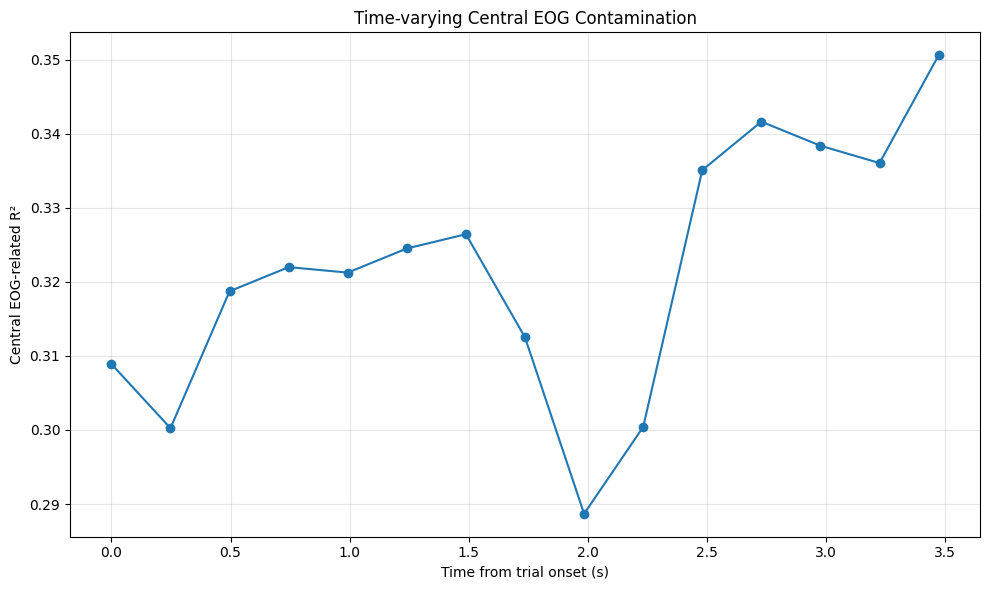

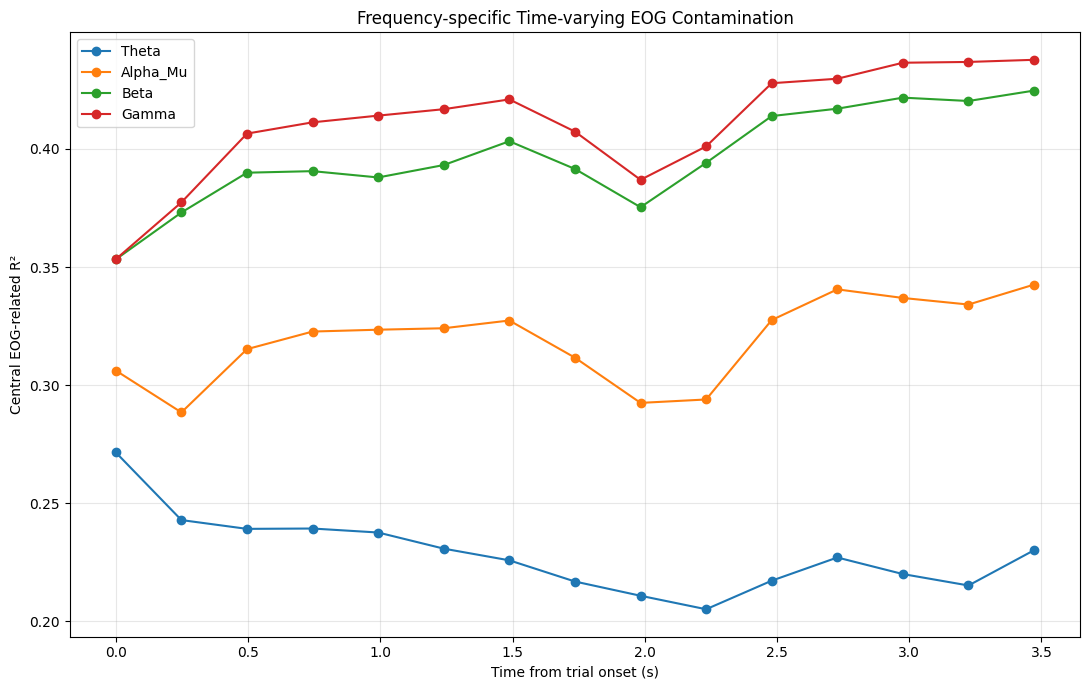



ANALYSIS COMPLETE
Rows: 35520
Subjects: 9
Windows per trial: 15

Saved:
/content/drive/MyDrive/BCC/results/within_trial_eog_time_resolved_r2.csv
/content/drive/MyDrive/BCC/results/within_trial_eog_subject_time_summary.csv
/content/drive/MyDrive/BCC/results/within_trial_eog_subject_variability.csv
/content/drive/MyDrive/BCC/images/within_trial_eog_time_profile.png
/content/drive/MyDrive/BCC/images/within_trial_eog_frequency_time_profile.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.signal import butter, sosfiltfilt


# RESULTS_DIR is defined in the configuration cell.


# DATASET_DIR is defined in the configuration cell.

IMAGES_DIR = FIGURES_DIR

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)

FS = 250

TRIAL_SECONDS = 4

WINDOW_SECONDS = 0.5
STEP_SECONDS = 0.25

TRIAL_SAMPLES = int(
    TRIAL_SECONDS * FS
)

WINDOW_SAMPLES = int(
    WINDOW_SECONDS * FS
)

STEP_SAMPLES = int(
    STEP_SECONDS * FS
)

N_EEG = 22
N_EOG = 3

EEG_CHANNELS = [
    "Fz", "FC3", "FC1", "FCz", "FC2", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "P1", "Pz", "P2", "POz"
]

CENTRAL_CHANNELS = [
    "C5", "C3", "C1",
    "Cz",
    "C2", "C4", "C6"
]

CENTRAL_IDX = [
    EEG_CHANNELS.index(ch)
    for ch in CENTRAL_CHANNELS
]

BANDS = {
    "Theta": (4, 8),
    "Alpha_Mu": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 38)
}

SUBJECTS = [
    f"A{i:02d}" for i in range(1, 10)
]

def load_mat(path):

    mat = loadmat(
        path,
        squeeze_me=False
    )

    return mat["data"]

def load_training_continuous(path):

    data = load_mat(path)

    eeg_parts = []
    eog_parts = []

    for run_idx in range(data.shape[1]):

        run = data[
            0,
            run_idx
        ][0, 0]

        X = run["X"]

        if X.shape[0] == 0:
            continue

        eeg_parts.append(
            X[:, :N_EEG]
        )

        eog_parts.append(
            X[:, N_EEG:N_EEG + N_EOG]
        )

    eeg = np.concatenate(
        eeg_parts,
        axis=0
    )

    eog = np.concatenate(
        eog_parts,
        axis=0
    )

    return eeg, eog

def load_e_trials(path):

    data = load_mat(path)

    eeg_trials = []
    eog_trials = []
    rows = []

    for run_idx in range(data.shape[1]):

        run = data[
            0,
            run_idx
        ][0, 0]

        X = run["X"]
        trial = run["trial"]
        y = run["y"]
        artifacts = run["artifacts"]

        if trial.shape[0] == 0:
            continue

        for trial_idx in range(
            trial.shape[0]
        ):

            if artifacts[
                trial_idx,
                0
            ] == 1:
                continue

            onset = int(
                trial[
                    trial_idx,
                    0
                ]
            )

            end = (
                onset +
                TRIAL_SAMPLES
            )

            if end > X.shape[0]:
                continue

            eeg_trials.append(
                X[
                    onset:end,
                    :N_EEG
                ]
            )

            eog_trials.append(
                X[
                    onset:end,
                    N_EEG:N_EEG + N_EOG
                ]
            )

            rows.append({

                "Subject": None,

                "Run":
                    run_idx,

                "Trial":
                    trial_idx + 1,

                "Onset":
                    onset,

                "True_Class":
                    int(
                        y[
                            trial_idx,
                            0
                        ]
                    )
            })

    return (
        np.asarray(eeg_trials),
        np.asarray(eog_trials),
        pd.DataFrame(rows)
    )

def bandpass(X, low, high, fs=FS):

    sos = butter(
        4,
        [low, high],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    return sosfiltfilt(
        sos,
        X,
        axis=-2
    )

def fit_regression(
    eeg,
    eog
):

    """
    eeg: (samples, 22)
    eog: (samples, 3)

    Returns:
        beta: (22, 3)
    """

    X = np.column_stack([
        eog,
        np.ones(
            eog.shape[0]
        )
    ])

    beta = np.zeros(
        (N_EEG, N_EOG)
    )

    intercept = np.zeros(
        N_EEG
    )

    for ch in range(N_EEG):

        coef, _, _, _ = np.linalg.lstsq(
            X,
            eeg[:, ch],
            rcond=None
        )

        beta[ch] = coef[:N_EOG]

        intercept[ch] = coef[N_EOG]

    return beta, intercept

def eog_component(
    eog,
    beta
):

    return np.einsum(
        "...c,nc->...n",
        eog,
        beta
    )

def calculate_r2(
    eeg_window,
    component_window
):

    residual = (
        eeg_window -
        component_window
    )

    ss_res = np.sum(
        residual ** 2,
        axis=0
    )

    centered = (
        eeg_window -
        eeg_window.mean(
            axis=0
        )
    )

    ss_tot = np.sum(
        centered ** 2,
        axis=0
    )

    r2 = np.full(
        N_EEG,
        np.nan
    )

    valid = (
        ss_tot > 1e-12
    )

    r2[valid] = (
        1 -
        ss_res[valid] /
        ss_tot[valid]
    )

    return np.clip(
        r2,
        0,
        1
    )

window_starts = np.arange(
    0,
    TRIAL_SAMPLES - WINDOW_SAMPLES + 1,
    STEP_SAMPLES
)

print(
    "Windows per trial:",
    len(window_starts)
)

print(
    "Window:",
    WINDOW_SECONDS,
    "sec"
)

print(
    "Step:",
    STEP_SECONDS,
    "sec"
)

results = []

for subject in SUBJECTS:

    print("\n")
    print("=" * 90)
    print(
        f"PROCESSING {subject}"
    )
    print("=" * 90)

    train_path = os.path.join(
        DATASET_DIR,
        f"{subject}T.mat"
    )

    test_path = os.path.join(
        DATASET_DIR,
        f"{subject}E.mat"
    )

    train_eeg_raw, train_eog_raw = (
        load_training_continuous(
            train_path
        )
    )

    print(
        "Training EEG:",
        train_eeg_raw.shape
    )

    print(
        "Training EOG:",
        train_eog_raw.shape
    )

    (
        eeg_trials_raw,
        eog_trials_raw,
        metadata
    ) = load_e_trials(
        test_path
    )

    metadata["Subject"] = subject

    print(
        "E trials:",
        len(eeg_trials_raw)
    )

    print(
        "Filtering overall 4–38 Hz..."
    )

    train_eeg_full = bandpass(
        train_eeg_raw,
        4,
        38
    )

    train_eog_full = bandpass(
        train_eog_raw,
        4,
        38
    )

    eeg_trials_full = bandpass(
        eeg_trials_raw,
        4,
        38
    )

    eog_trials_full = bandpass(
        eog_trials_raw,
        4,
        38
    )

    print(
        "Fitting overall regression once..."
    )

    beta_full, _ = fit_regression(
        train_eeg_full,
        train_eog_full
    )

    print(
        "Calculating overall EOG component..."
    )

    eog_component_full = (
        eog_component(
            eog_trials_full,
            beta_full
        )
    )

    band_data = {}

    for band_name, (
        low,
        high
    ) in BANDS.items():

        print(
            f"Preparing {band_name} "
            f"{low}-{high} Hz..."
        )

        train_eeg_band = bandpass(
            train_eeg_raw,
            low,
            high
        )

        train_eog_band = bandpass(
            train_eog_raw,
            low,
            high
        )

        beta_band, _ = fit_regression(
            train_eeg_band,
            train_eog_band
        )

        eog_band = bandpass(
            eog_trials_raw,
            low,
            high
        )

        component_band = (
            eog_component(
                eog_band,
                beta_band
            )
        )

        eeg_band = bandpass(
            eeg_trials_raw,
            low,
            high
        )

        band_data[band_name] = {

            "eeg":
                eeg_band,

            "component":
                component_band
        }

    for trial_idx in range(
        len(eeg_trials_full)
    ):

        eeg_trial = (
            eeg_trials_full[
                trial_idx
            ]
        )

        component_trial = (
            eog_component_full[
                trial_idx
            ]
        )

        for window_idx, start in enumerate(
            window_starts
        ):

            end = (
                start +
                WINDOW_SAMPLES
            )

            eeg_window = (
                eeg_trial[
                    start:end
                ]
            )

            component_window = (
                component_trial[
                    start:end
                ]
            )

            r2 = calculate_r2(
                eeg_window,
                component_window
            )

            row = {

                "Subject":
                    subject,

                "Run":
                    metadata.iloc[
                        trial_idx
                    ]["Run"],

                "Trial":
                    metadata.iloc[
                        trial_idx
                    ]["Trial"],

                "Onset":
                    metadata.iloc[
                        trial_idx
                    ]["Onset"],

                "True_Class":
                    metadata.iloc[
                        trial_idx
                    ]["True_Class"],

                "Window_Index":
                    window_idx,

                "Window_Start_s":
                    start / FS,

                "Window_End_s":
                    end / FS,

                "Overall_Central_R2":
                    np.nanmean(
                        r2[
                            CENTRAL_IDX
                        ]
                    )
            }

            for band_name in BANDS:

                eeg_band_trial = (
                    band_data[
                        band_name
                    ]["eeg"][
                        trial_idx
                    ]
                )

                component_band_trial = (
                    band_data[
                        band_name
                    ]["component"][
                        trial_idx
                    ]
                )

                eeg_window_band = (
                    eeg_band_trial[
                        start:end
                    ]
                )

                component_window_band = (
                    component_band_trial[
                        start:end
                    ]
                )

                r2_band = calculate_r2(
                    eeg_window_band,
                    component_window_band
                )

                row[
                    f"{band_name}_Central_R2"
                ] = np.nanmean(
                    r2_band[
                        CENTRAL_IDX
                    ]
                )

            results.append(
                row
            )

        if (
            (trial_idx + 1) % 50 == 0
            or
            trial_idx == 0
            or
            trial_idx + 1 ==
            len(eeg_trials_full)
        ):

            print(
                f"  Processed "
                f"{trial_idx + 1}/"
                f"{len(eeg_trials_full)} "
                f"trials"
            )

time_df = pd.DataFrame(
    results
)

raw_path = os.path.join(
    RESULTS_DIR,
    "within_trial_eog_time_resolved_r2.csv"
)

time_df.to_csv(
    raw_path,
    index=False
)

summary_df = (
    time_df
    .groupby(
        [
            "Subject",
            "Window_Index",
            "Window_Start_s",
            "Window_End_s"
        ]
    )[
        [
            "Overall_Central_R2",
            "Theta_Central_R2",
            "Alpha_Mu_Central_R2",
            "Beta_Central_R2",
            "Gamma_Central_R2"
        ]
    ]
    .mean()
    .reset_index()
)

summary_path = os.path.join(
    RESULTS_DIR,
    "within_trial_eog_subject_time_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

overall_time = (
    summary_df
    .groupby(
        [
            "Window_Index",
            "Window_Start_s",
            "Window_End_s"
        ]
    )[
        [
            "Overall_Central_R2",
            "Theta_Central_R2",
            "Alpha_Mu_Central_R2",
            "Beta_Central_R2",
            "Gamma_Central_R2"
        ]
    ]
    .mean()
)

print("\n")
print("=" * 110)
print("OVERALL TIME PROFILE")
print("=" * 110)

print(
    overall_time.round(4)
)

trial_variability = (
    time_df
    .groupby(
        [
            "Subject",
            "Run",
            "Trial"
        ]
    )[
        [
            "Overall_Central_R2",
            "Theta_Central_R2",
            "Alpha_Mu_Central_R2",
            "Beta_Central_R2",
            "Gamma_Central_R2"
        ]
    ]
    .agg([
        "mean",
        "std",
        "min",
        "max"
    ])
    .reset_index()
)

variability_path = os.path.join(
    RESULTS_DIR,
    "within_trial_eog_subject_variability.csv"
)

trial_variability.to_csv(
    variability_path,
    index=False
)

subject_variability = (
    trial_variability
    .groupby("Subject")
    .mean(
        numeric_only=True
    )
)

print("\n")
print("=" * 110)
print("SUBJECT-LEVEL WITHIN-TRIAL VARIABILITY")
print("=" * 110)

print(
    subject_variability.round(4)
)

plt.figure(
    figsize=(10, 6)
)

x = (
    overall_time.index
    .get_level_values(
        "Window_Start_s"
    )
)

y = (
    overall_time[
        "Overall_Central_R2"
    ]
)

plt.plot(
    x,
    y,
    marker="o"
)

plt.xlabel(
    "Time from trial onset (s)"
)

plt.ylabel(
    "Central EOG-related R²"
)

plt.title(
    "Time-varying Central EOG Contamination"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plot_path = os.path.join(
    IMAGES_DIR,
    "within_trial_eog_time_profile.png"
)

plt.savefig(
    plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.figure(
    figsize=(11, 7)
)

for band in BANDS:

    y = (
        overall_time[
            f"{band}_Central_R2"
        ]
    )

    plt.plot(
        x,
        y,
        marker="o",
        label=band
    )

plt.xlabel(
    "Time from trial onset (s)"
)

plt.ylabel(
    "Central EOG-related R²"
)

plt.title(
    "Frequency-specific Time-varying EOG Contamination"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

freq_plot_path = os.path.join(
    IMAGES_DIR,
    "within_trial_eog_frequency_time_profile.png"
)

plt.savefig(
    freq_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\n")
print("=" * 110)
print("ANALYSIS COMPLETE")
print("=" * 110)

print(
    "Rows:",
    len(time_df)
)

print(
    "Subjects:",
    time_df["Subject"].nunique()
)

print(
    "Windows per trial:",
    time_df["Window_Index"].nunique()
)

print(
    "\nSaved:"
)

print(raw_path)
print(summary_path)
print(variability_path)
print(plot_path)
print(freq_plot_path)


## Final Corrected EOG R² Analysis



CORRECTED ARTIFACT-FILTERED BASELINE vs MI EOG R² ANALYSIS


PROCESSING A01

Loading A01:
Path: /content/drive/MyDrive/BCC/Dataset/A01E.mat
data shape: (1, 9)
Number of runs: 9
Run 3: X=(96735, 25), trials=48
Run 4: X=(96735, 25), trials=48
Run 5: X=(96735, 25), trials=48
Run 6: X=(96735, 25), trials=48
Run 7: X=(96735, 25), trials=48
Run 8: X=(96735, 25), trials=48

A01:
  Total trials: 288
  Artifact trials: 7
  Valid analyzed trials: 281


PROCESSING A02

Loading A02:
Path: /content/drive/MyDrive/BCC/Dataset/A02E.mat
data shape: (1, 9)
Number of runs: 9
Run 3: X=(96735, 25), trials=48
Run 4: X=(96735, 25), trials=48
Run 5: X=(96735, 25), trials=48
Run 6: X=(96735, 25), trials=48
Run 7: X=(96735, 25), trials=48
Run 8: X=(96735, 25), trials=48

A02:
  Total trials: 288
  Artifact trials: 5
  Valid analyzed trials: 283


PROCESSING A03

Loading A03:
Path: /content/drive/MyDrive/BCC/Dataset/A03E.mat
data shape: (1, 9)
Number of runs: 9
Run 3: X=(96735, 25), trials=48
Run 4: X=(96735, 

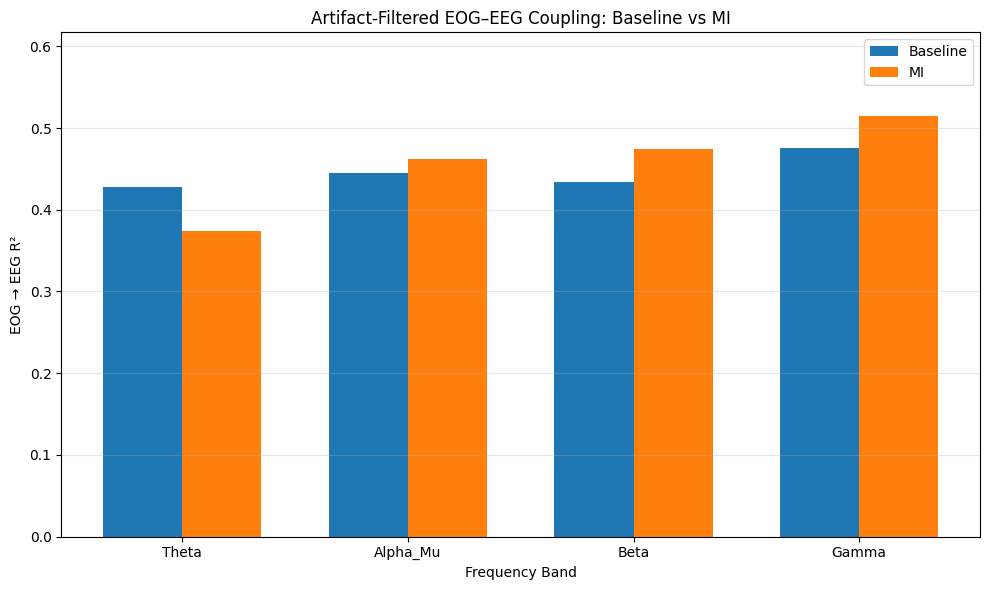

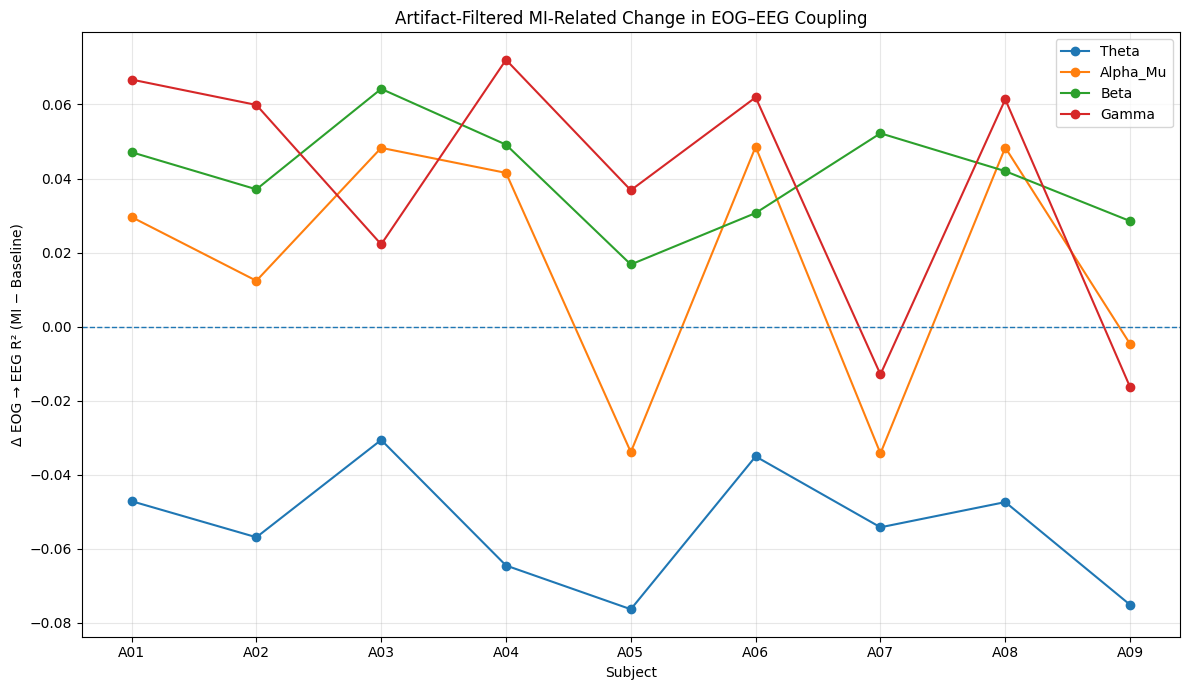

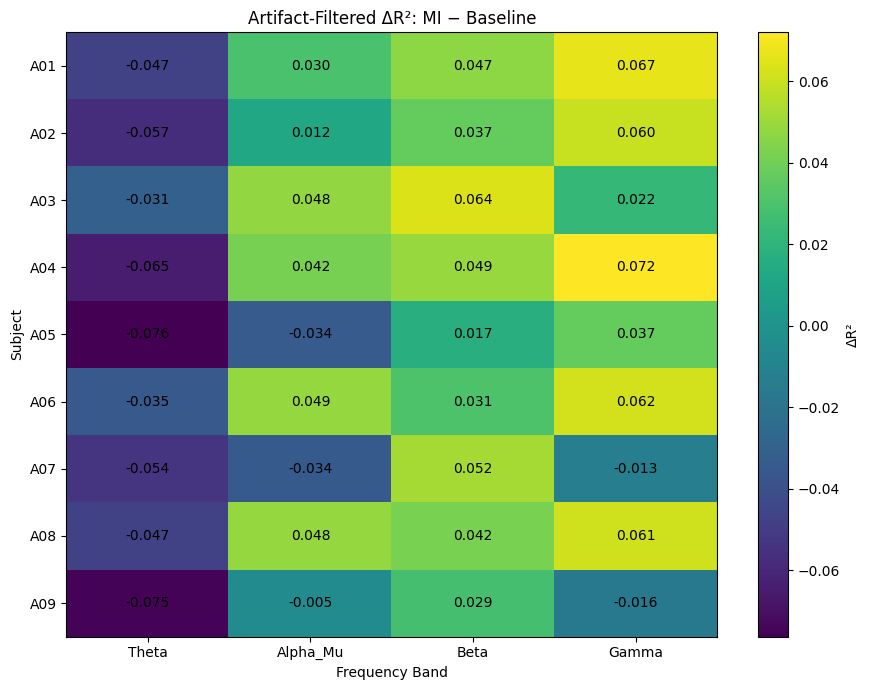



FINAL CHECK
Total valid trials: 2368
Expected total: 2368
✓ TOTAL TRIAL COUNT MATCHES 2368


FILES SAVED
/content/drive/MyDrive/BCC/results/final_artifact_filtered_baseline_mi_eog_r2_trial_level.csv
/content/drive/MyDrive/BCC/results/final_artifact_filtered_baseline_mi_eog_r2_subject_band.csv
/content/drive/MyDrive/BCC/results/final_artifact_filtered_baseline_mi_eog_r2_statistics.csv
/content/drive/MyDrive/BCC/images/final_artifact_filtered_baseline_vs_mi_r2.png
/content/drive/MyDrive/BCC/images/final_artifact_filtered_mi_change_by_subject.png
/content/drive/MyDrive/BCC/images/final_artifact_filtered_delta_r2_heatmap.png


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.signal import butter, filtfilt
from scipy.stats import ttest_rel, wilcoxon
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")


# DATASET_DIR is defined in the configuration cell.


# RESULTS_DIR is defined in the configuration cell.


# FIGURES_DIR is defined in the configuration cell.


os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

SUBJECTS = [
    "A01", "A02", "A03",
    "A04", "A05", "A06",
    "A07", "A08", "A09"
]

EEG_CHANNELS = [
    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",
    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",
    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",
    "P1",
    "Pz",
    "P2",
    "POz"
]

CENTRAL_CHANNELS = [
    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6"
]

CENTRAL_INDICES = [
    EEG_CHANNELS.index(ch)
    for ch in CENTRAL_CHANNELS
]

N_EEG = 22
N_EOG = 3

BANDS = {
    "Theta": (4.0, 8.0),
    "Alpha_Mu": (8.0, 13.0),
    "Beta": (13.0, 30.0),
    "Gamma": (30.0, 38.0)
}

FS_EXPECTED = 250.0

BASELINE_START_SEC = 0.0
BASELINE_END_SEC = 2.0

MI_START_SEC = 3.0
MI_END_SEC = 6.0

FILTER_ORDER = 4

def load_subject_runs(subject):

    path = os.path.join(
        DATASET_DIR,
        f"{subject}E.mat"
    )

    if not os.path.exists(path):
        raise FileNotFoundError(
            path
        )

    mat = loadmat(
        path,
        struct_as_record=False,
        squeeze_me=False
    )

    data = mat["data"]

    print(
        f"\nLoading {subject}:"
    )

    print(
        "Path:",
        path
    )

    print(
        "data shape:",
        data.shape
    )

    if data.shape != (1, 9):

        print(
            "WARNING: unexpected data shape:",
            data.shape
        )

    runs = []

    for run_idx in range(
        data.shape[1]
    ):

        run = data[
            0,
            run_idx
        ][0, 0]

        runs.append(
            run
        )

    print(
        "Number of runs:",
        len(runs)
    )

    return runs

def flatten_array(x):

    arr = np.asarray(x)

    if arr.size == 0:
        return np.array([])

    return arr.reshape(-1)

def bandpass_filter(
    x,
    low,
    high,
    fs
):

    nyquist = fs / 2.0

    low_norm = low / nyquist
    high_norm = high / nyquist

    high_norm = min(
        high_norm,
        0.99
    )

    b, a = butter(
        FILTER_ORDER,
        [
            low_norm,
            high_norm
        ],
        btype="band"
    )

    return filtfilt(
        b,
        a,
        x,
        axis=0
    )

def calculate_eog_r2(
    eeg_segment,
    eog_segment
):
    """
    Predict each central EEG channel from the three EOG
    channels using ordinary least squares.

    R² = 1 - SSE/SST

    Final value = mean R² across the seven central EEG channels.

    R² is explicitly constrained to [0, 1].
    """

    if (
        eeg_segment.shape[0]
        != eog_segment.shape[0]
    ):
        raise ValueError(
            "EEG/EOG segment length mismatch."
        )

    valid_rows = (
        np.all(
            np.isfinite(
                eeg_segment
            ),
            axis=1
        )
        &
        np.all(
            np.isfinite(
                eog_segment
            ),
            axis=1
        )
    )

    eeg_segment = eeg_segment[
        valid_rows
    ]

    eog_segment = eog_segment[
        valid_rows
    ]

    if eeg_segment.shape[0] < 20:
        return np.nan

    values = []

    for channel_idx in CENTRAL_INDICES:

        y = eeg_segment[
            :,
            channel_idx
        ]

        if np.std(y) <= 1e-12:
            continue

        model = LinearRegression(
            fit_intercept=True
        )

        model.fit(
            eog_segment,
            y
        )

        prediction = model.predict(
            eog_segment
        )

        value = r2_score(
            y,
            prediction
        )

        value = float(
            np.clip(
                value,
                0.0,
                1.0
            )
        )

        values.append(
            value
        )

    if len(values) == 0:
        return np.nan

    return float(
        np.mean(values)
    )

def get_trial_info(run):

    trials = flatten_array(
        run.trial
    )

    labels = flatten_array(
        run.y
    )

    artifacts = flatten_array(
        run.artifacts
    )

    n = min(
        len(trials),
        len(labels)
    )

    if n == 0:
        return []

    trials = trials[
        :n
    ]

    labels = labels[
        :n
    ]

    if len(artifacts) >= n:

        artifacts = artifacts[
            :n
        ]

    else:

        artifacts = np.zeros(
            n,
            dtype=int
        )

    output = []

    for i in range(n):

        output.append({

            "trial_index": i + 1,

            "onset": int(
                round(
                    float(
                        trials[i]
                    )
                )
            ),

            "true_class": int(
                round(
                    float(
                        labels[i]
                    )
                )
            ),

            "artifact": int(
                round(
                    float(
                        artifacts[i]
                    )
                )
            )

        })

    return output

all_results = []

trial_counts_before = {}
trial_counts_after = {}

print("\n")
print("=" * 110)
print(
    "CORRECTED ARTIFACT-FILTERED BASELINE vs MI EOG R² ANALYSIS"
)
print("=" * 110)

for subject in SUBJECTS:

    print("\n")
    print("=" * 90)
    print(
        f"PROCESSING {subject}"
    )
    print("=" * 90)

    try:

        runs = load_subject_runs(
            subject
        )

    except Exception as e:

        print(
            f"FAILED {subject}:",
            repr(e)
        )

        continue

    total_trials = 0
    valid_trials = 0
    artifact_trials = 0

    for run_idx, run in enumerate(
        runs
    ):

        X = np.asarray(
            run.X,
            dtype=float
        )

        if X.ndim != 2:
            continue

        fs_array = flatten_array(
            run.fs
        )

        if len(fs_array) == 0:
            fs = FS_EXPECTED

        else:
            fs = float(
                fs_array[0]
            )

        trials = get_trial_info(
            run
        )

        if len(trials) == 0:
            continue

        print(
            f"Run {run_idx}: "
            f"X={X.shape}, "
            f"trials={len(trials)}"
        )

        total_trials += len(trials)

        for trial_info in trials:

            if trial_info[
                "artifact"
            ] == 1:

                artifact_trials += 1

                continue

            onset = trial_info[
                "onset"
            ]

            trial_number = trial_info[
                "trial_index"
            ]

            true_class = trial_info[
                "true_class"
            ]

            onset_idx = (
                onset - 1
            )

            baseline_start = (
                onset_idx
                +
                int(
                    BASELINE_START_SEC
                    * fs
                )
            )

            baseline_end = (
                onset_idx
                +
                int(
                    BASELINE_END_SEC
                    * fs
                )
            )

            mi_start = (
                onset_idx
                +
                int(
                    MI_START_SEC
                    * fs
                )
            )

            mi_end = (
                onset_idx
                +
                int(
                    MI_END_SEC
                    * fs
                )
            )

            if baseline_start < 0:
                continue

            if baseline_end > X.shape[0]:
                continue

            if mi_start < 0:
                continue

            if mi_end > X.shape[0]:
                continue

            if baseline_end <= baseline_start:
                continue

            if mi_end <= mi_start:
                continue

            eeg = X[
                :,
                :N_EEG
            ]

            eog = X[
                :,
                N_EEG:N_EEG + N_EOG
            ]

            band_rows = {}

            for band_name, (
                low,
                high
            ) in BANDS.items():

                eeg_band = bandpass_filter(
                    eeg,
                    low,
                    high,
                    fs
                )

                eog_band = bandpass_filter(
                    eog,
                    low,
                    high,
                    fs
                )

                eeg_baseline = eeg_band[
                    baseline_start:baseline_end
                ]

                eog_baseline = eog_band[
                    baseline_start:baseline_end
                ]

                eeg_mi = eeg_band[
                    mi_start:mi_end
                ]

                eog_mi = eog_band[
                    mi_start:mi_end
                ]

                baseline_r2 = calculate_eog_r2(
                    eeg_baseline,
                    eog_baseline
                )

                mi_r2 = calculate_eog_r2(
                    eeg_mi,
                    eog_mi
                )

                if (
                    np.isfinite(
                        baseline_r2
                    )
                    and
                    np.isfinite(
                        mi_r2
                    )
                ):

                    band_rows[
                        band_name
                    ] = {

                        "Baseline_R2":
                            baseline_r2,

                        "MI_R2":
                            mi_r2,

                        "Change_R2":
                            mi_r2 -
                            baseline_r2
                    }

            if len(band_rows) == 0:
                continue

            valid_trials += 1

            row = {

                "Subject":
                    subject,

                "Run":
                    run_idx,

                "Trial":
                    trial_number,

                "Onset":
                    onset,

                "True_Class":
                    true_class,

                "Artifact":
                    0

            }

            for band_name in BANDS:

                if band_name not in band_rows:
                    continue

                values = band_rows[
                    band_name
                ]

                row[
                    f"{band_name}_Baseline_R2"
                ] = values[
                    "Baseline_R2"
                ]

                row[
                    f"{band_name}_MI_R2"
                ] = values[
                    "MI_R2"
                ]

                row[
                    f"{band_name}_Change_R2"
                ] = values[
                    "Change_R2"
                ]

            all_results.append(
                row
            )

    trial_counts_before[
        subject
    ] = total_trials

    trial_counts_after[
        subject
    ] = valid_trials

    print(
        f"\n{subject}:"
    )

    print(
        "  Total trials:",
        total_trials
    )

    print(
        "  Artifact trials:",
        artifact_trials
    )

    print(
        "  Valid analyzed trials:",
        valid_trials
    )

trial_df = pd.DataFrame(
    all_results
)

print("\n")
print("=" * 110)
print("FINAL ARTIFACT-FILTERED DATASET")
print("=" * 110)

print(
    "Rows:",
    len(trial_df)
)

print(
    "Subjects:",
    trial_df["Subject"].nunique()
)

print(
    "\nTrial counts:"
)

print(
    trial_df.groupby(
        "Subject"
    ).size()
)

expected_counts = {

    "A01": 281,
    "A02": 283,
    "A03": 273,
    "A04": 228,
    "A05": 276,
    "A06": 215,
    "A07": 277,
    "A08": 271,
    "A09": 264
}

actual_counts = (
    trial_df
    .groupby("Subject")
    .size()
    .to_dict()
)

print("\n")
print("=" * 110)
print("TRIAL COUNT VALIDATION")
print("=" * 110)

all_match = True

for subject in SUBJECTS:

    expected = expected_counts[
        subject
    ]

    actual = actual_counts.get(
        subject,
        0
    )

    status = (
        "✓"
        if expected == actual
        else "✗"
    )

    if expected != actual:
        all_match = False

    print(
        f"{status} {subject}: "
        f"expected={expected}, "
        f"actual={actual}"
    )

print()

if all_match:

    print(
        "✓ ALL TRIAL COUNTS MATCH "
        "THE PREVIOUS E-SESSION ANALYSIS"
    )

else:

    print(
        "⚠ TRIAL COUNTS DO NOT MATCH."
    )

    print(
        "Do NOT use the results for final "
        "interpretation until this is resolved."
    )

trial_output = os.path.join(
    RESULTS_DIR,
    "final_artifact_filtered_baseline_mi_eog_r2_trial_level.csv"
)

trial_df.to_csv(
    trial_output,
    index=False
)

print(
    "\nSaved:",
    trial_output
)

print("\n")
print("=" * 110)
print("R² RANGE VALIDATION")
print("=" * 110)

r2_columns = [
    c for c in trial_df.columns
    if (
        "R2" in c
        and (
            "Baseline" in c
            or "MI" in c
        )
    )
]

range_results = []

for col in r2_columns:

    values = pd.to_numeric(
        trial_df[col],
        errors="coerce"
    ).dropna()

    minimum = values.min()
    maximum = values.max()

    invalid = (
        (values < 0)
        |
        (values > 1)
    ).sum()

    range_results.append({

        "Column":
            col,

        "N":
            len(values),

        "Min":
            minimum,

        "Max":
            maximum,

        "Mean":
            values.mean(),

        "Invalid":
            int(invalid)

    })

range_df = pd.DataFrame(
    range_results
)

print(
    range_df.to_string(
        index=False
    )
)

if range_df["Invalid"].sum() == 0:

    print(
        "\n✓ ALL R² VALUES ARE WITHIN [0, 1]"
    )

else:

    raise RuntimeError(
        "Invalid R² values detected."
    )

summary_rows = []

for subject in SUBJECTS:

    for band_name in BANDS:

        subset = trial_df[
            trial_df["Subject"] == subject
        ]

        baseline_col = (
            f"{band_name}_Baseline_R2"
        )

        mi_col = (
            f"{band_name}_MI_R2"
        )

        change_col = (
            f"{band_name}_Change_R2"
        )

        if (
            baseline_col not in subset.columns
            or
            mi_col not in subset.columns
        ):
            continue

        baseline = subset[
            baseline_col
        ].dropna()

        mi = subset[
            mi_col
        ].dropna()

        change = (
            subset[
                change_col
            ].dropna()
        )

        if len(change) == 0:
            continue

        summary_rows.append({

            "Subject":
                subject,

            "Band":
                band_name,

            "N_Trials":
                len(change),

            "Baseline_Mean_R2":
                baseline.mean(),

            "Baseline_Median_R2":
                baseline.median(),

            "MI_Mean_R2":
                mi.mean(),

            "MI_Median_R2":
                mi.median(),

            "Mean_Change_R2":
                change.mean(),

            "Median_Change_R2":
                change.median(),

            "Std_Change_R2":
                change.std(),

            "Positive_Trials":
                int(
                    (change > 0).sum()
                ),

            "Negative_Trials":
                int(
                    (change < 0).sum()
                )

        })

subject_band_df = pd.DataFrame(
    summary_rows
)

print("\n")
print("=" * 110)
print(
    "SUBJECT × BAND — FINAL CORRECTED RESULTS"
)
print("=" * 110)

print(
    subject_band_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}"
    )
)

stats_rows = []

for band_name in BANDS:

    band_data = subject_band_df[
        subject_band_df["Band"]
        == band_name
    ]

    baseline = band_data[
        "Baseline_Mean_R2"
    ].values

    mi = band_data[
        "MI_Mean_R2"
    ].values

    change = band_data[
        "Mean_Change_R2"
    ].values

    if len(change) < 3:
        continue

    t_stat, t_p = ttest_rel(
        mi,
        baseline
    )

    try:

        w_stat, w_p = wilcoxon(
            change
        )

    except Exception:

        w_stat = np.nan
        w_p = np.nan

    change_sd = np.std(
        change,
        ddof=1
    )

    if change_sd > 0:

        cohens_d = (
            np.mean(change)
            /
            change_sd
        )

    else:

        cohens_d = np.nan

    stats_rows.append({

        "Band":
            band_name,

        "N_Subjects":
            len(change),

        "Baseline_Mean":
            np.mean(baseline),

        "MI_Mean":
            np.mean(mi),

        "Mean_Change":
            np.mean(change),

        "Median_Change":
            np.median(change),

        "Positive_Subjects":
            int(
                np.sum(change > 0)
            ),

        "Negative_Subjects":
            int(
                np.sum(change < 0)
            ),

        "Paired_t":
            t_stat,

        "Paired_t_p":
            t_p,

        "Wilcoxon_W":
            w_stat,

        "Wilcoxon_p":
            w_p,

        "Cohens_d":
            cohens_d

    })

stats_df = pd.DataFrame(
    stats_rows
)

if len(stats_df) > 0:

    stats_df[
        "Wilcoxon_p_Bonferroni"
    ] = np.minimum(
        stats_df[
            "Wilcoxon_p"
        ]
        * len(stats_df),
        1.0
    )

    stats_df[
        "Paired_t_p_Bonferroni"
    ] = np.minimum(
        stats_df[
            "Paired_t_p"
        ]
        * len(stats_df),
        1.0
    )

    stats_df[
        "Wilcoxon_p_FDR"
    ] = multipletests(
        stats_df[
            "Wilcoxon_p"
        ],
        method="fdr_bh"
    )[1]

print("\n")
print("=" * 110)
print(
    "FINAL SUBJECT-LEVEL BASELINE vs MI STATISTICS"
)
print("=" * 110)

print(
    stats_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

stats_output = os.path.join(
    RESULTS_DIR,
    "final_artifact_filtered_baseline_mi_eog_r2_statistics.csv"
)

stats_df.to_csv(
    stats_output,
    index=False
)

subject_band_output = os.path.join(
    RESULTS_DIR,
    "final_artifact_filtered_baseline_mi_eog_r2_subject_band.csv"
)

subject_band_df.to_csv(
    subject_band_output,
    index=False
)

print(
    "\nSaved:"
)

print(
    stats_output
)

print(
    subject_band_output
)

bands = list(BANDS.keys())

baseline_means = []
mi_means = []

for band in bands:

    temp = subject_band_df[
        subject_band_df["Band"]
        == band
    ]

    baseline_means.append(
        temp[
            "Baseline_Mean_R2"
        ].mean()
    )

    mi_means.append(
        temp[
            "MI_Mean_R2"
        ].mean()
    )

x = np.arange(
    len(bands)
)

width = 0.35

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width / 2,
    baseline_means,
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    mi_means,
    width,
    label="MI"
)

plt.xticks(
    x,
    bands
)

plt.ylabel(
    "EOG → EEG R²"
)

plt.xlabel(
    "Frequency Band"
)

plt.title(
    "Artifact-Filtered EOG–EEG Coupling: Baseline vs MI"
)

plt.ylim(
    0,
    min(
        1.0,
        max(
            baseline_means
            +
            mi_means
        ) * 1.2
    )
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

fig1 = os.path.join(
    FIGURES_DIR,
    "final_artifact_filtered_baseline_vs_mi_r2.png"
)

plt.savefig(
    fig1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(
    figsize=(12, 7)
)

for band in bands:

    temp = subject_band_df[
        subject_band_df["Band"]
        == band
    ]

    temp = temp.set_index(
        "Subject"
    )

    subjects_present = [
        s for s in SUBJECTS
        if s in temp.index
    ]

    values = [
        temp.loc[
            s,
            "Mean_Change_R2"
        ]
        for s in subjects_present
    ]

    plt.plot(
        subjects_present,
        values,
        marker="o",
        label=band
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "Δ EOG → EEG R² (MI − Baseline)"
)

plt.title(
    "Artifact-Filtered MI-Related Change in EOG–EEG Coupling"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

fig2 = os.path.join(
    FIGURES_DIR,
    "final_artifact_filtered_mi_change_by_subject.png"
)

plt.savefig(
    fig2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

heatmap = subject_band_df.pivot(
    index="Subject",
    columns="Band",
    values="Mean_Change_R2"
)

heatmap = heatmap.reindex(
    index=SUBJECTS,
    columns=bands
)

plt.figure(
    figsize=(9, 7)
)

plt.imshow(
    heatmap.values,
    aspect="auto"
)

plt.xticks(
    np.arange(len(bands)),
    bands
)

plt.yticks(
    np.arange(len(SUBJECTS)),
    SUBJECTS
)

plt.xlabel(
    "Frequency Band"
)

plt.ylabel(
    "Subject"
)

plt.title(
    "Artifact-Filtered ΔR²: MI − Baseline"
)

plt.colorbar(
    label="ΔR²"
)

for i in range(
    len(SUBJECTS)
):

    for j in range(
        len(bands)
    ):

        value = heatmap.iloc[
            i,
            j
        ]

        if np.isfinite(value):

            plt.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center"
            )

plt.tight_layout()

fig3 = os.path.join(
    FIGURES_DIR,
    "final_artifact_filtered_delta_r2_heatmap.png"
)

plt.savefig(
    fig3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n")
print("=" * 110)
print("FINAL CHECK")
print("=" * 110)

print(
    "Total valid trials:",
    len(trial_df)
)

print(
    "Expected total:",
    sum(
        expected_counts.values()
    )
)

if len(trial_df) == sum(
    expected_counts.values()
):

    print(
        "✓ TOTAL TRIAL COUNT MATCHES 2368"
    )

else:

    print(
        "⚠ TOTAL TRIAL COUNT DOES NOT MATCH 2368"
    )

print("\n")
print("=" * 110)
print("FILES SAVED")
print("=" * 110)

print(
    trial_output
)

print(
    subject_band_output
)

print(
    stats_output
)

print(
    fig1
)

print(
    fig2
)

print(
    fig3
)


## MI-Related EOG Change → Suppression and Performance

MI-RELATED EOG CHANGE -> SUPPRESSION / PERFORMANCE ANALYSIS

R² file:
/content/drive/MyDrive/BCC/results/final_artifact_filtered_baseline_mi_eog_r2_subject_band.csv

Lambda file:
/content/drive/MyDrive/BCC/results/subject_lambda_prediction_features.csv

Cleaning file:
/content/drive/MyDrive/BCC/results/eegnet_frequency_cleaning_performance.csv

R2: ✓ FOUND

Lambda: ✓ FOUND

Cleaning: ✓ FOUND


LOADED FINAL R² RESULTS
Shape: (36, 12)
Columns: ['Subject', 'Band', 'N_Trials', 'Baseline_Mean_R2', 'Baseline_Median_R2', 'MI_Mean_R2', 'MI_Median_R2', 'Mean_Change_R2', 'Median_Change_R2', 'Std_Change_R2', 'Positive_Trials', 'Negative_Trials']


LOADED OPTIMAL LAMBDA DATA
Shape: (9, 16)
Columns: ['Subject', 'Best_Lambda_Accuracy', 'Best_Test_Accuracy', 'Best_Lambda_F1', 'Best_Test_F1', 'Dominant_Band', 'Theta_Relative_Power', 'Alpha_Mu_Relative_Power', 'Beta_Relative_Power', 'Gamma_Relative_Power', 'EOG_Theta_R2', 'EOG_Alpha_Mu_R2', 'EOG_Beta_R2', 'EOG_Gamma_R2', 'EOG_Overall_R2', 'EOG_Error_Sl

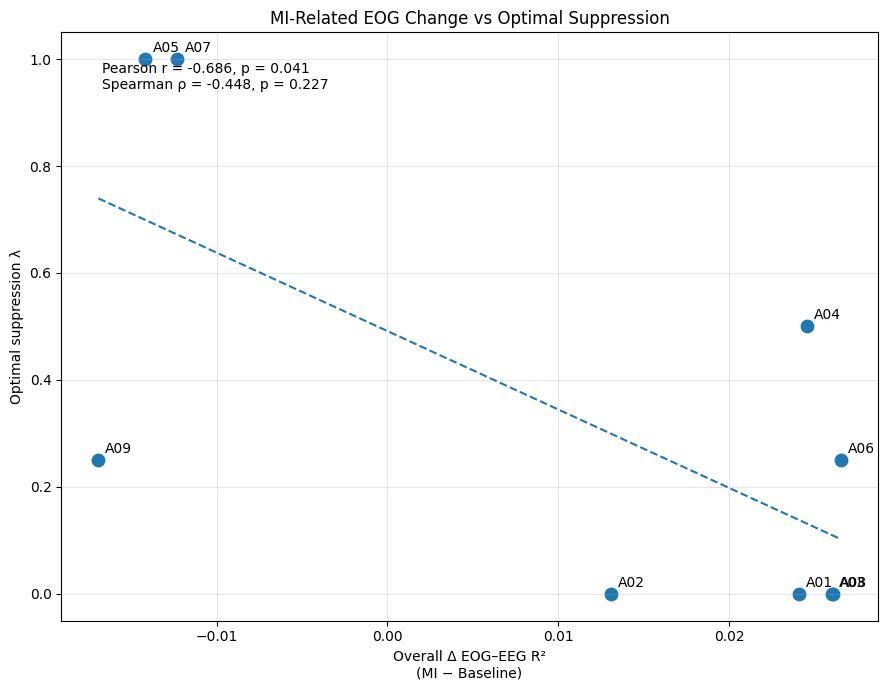



LOADED EEGNET CLEANING PERFORMANCE
Shape: (54, 9)
Columns: ['Subject', 'Condition', 'Accuracy', 'Macro_F1', 'Best_Validation_Accuracy', 'Inference_ms', 'Training_Trials', 'Validation_Trials', 'Test_Trials']


CLEANING BENEFIT + MI EOG CHANGE
Subject      Condition  Accuracy  Macro_F1  Raw_Accuracy  Raw_F1  Accuracy_Improvement  F1_Improvement  Delta_Theta_R2  Delta_Alpha_Mu_R2  Delta_Beta_R2  Delta_Gamma_R2  Delta_Overall_R2
    A01      All_Clean   0.58719   0.56975       0.62278 0.61508              -0.03559        -0.04533        -0.04716            0.02959        0.04710         0.06672           0.02406
    A02      All_Clean   0.36749   0.35858       0.34276 0.32870               0.02473         0.02989        -0.05690            0.01237        0.03707         0.05987           0.01310
    A03      All_Clean   0.70330   0.67559       0.69231 0.67708               0.01099        -0.00148        -0.03061            0.04828        0.06421         0.02221           0.02602
    A04 

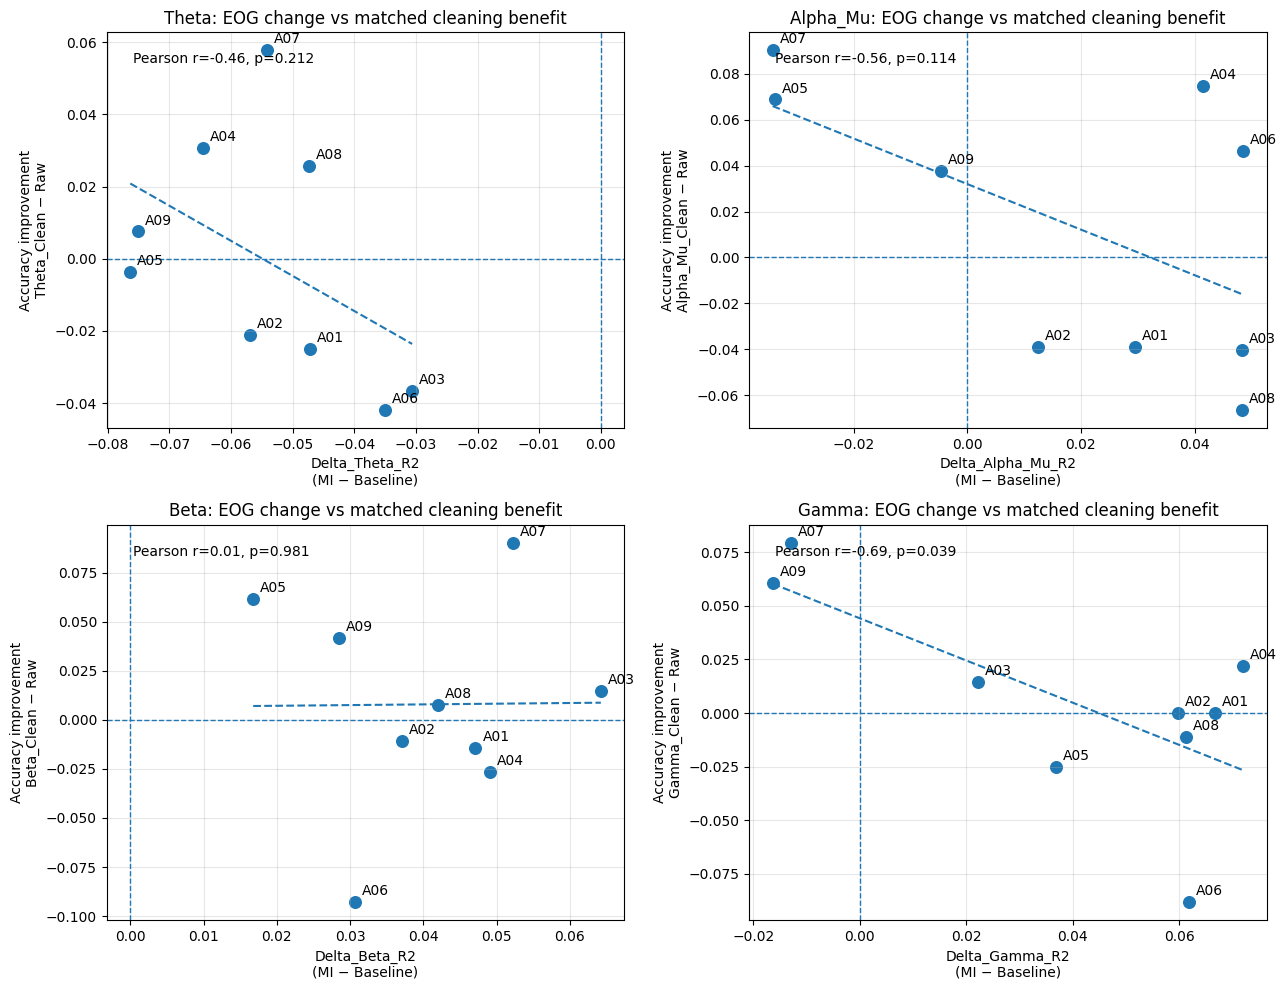

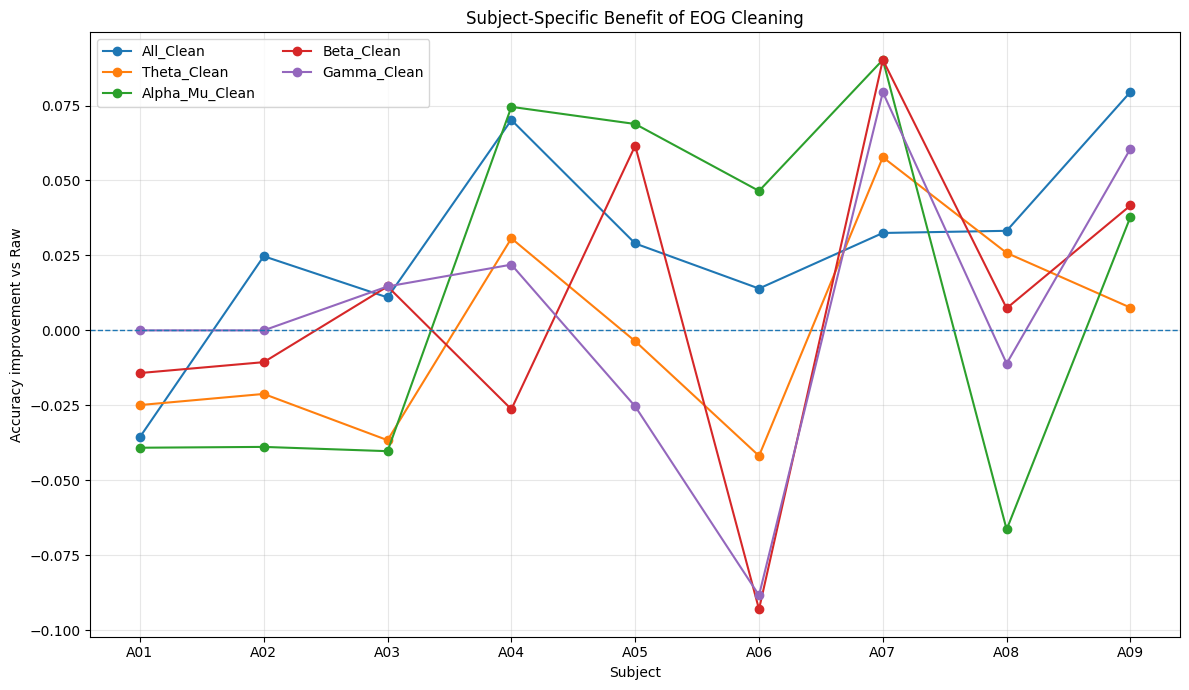



ANALYSIS COMPLETE

Results:
/content/drive/MyDrive/BCC/results/mi_eog_change_vs_optimal_lambda.csv
/content/drive/MyDrive/BCC/results/mi_eog_change_vs_cleaning_benefit.csv
/content/drive/MyDrive/BCC/results/mi_eog_change_vs_cleaning_benefit_correlations.csv
/content/drive/MyDrive/BCC/results/frequency_matched_eog_change_vs_cleaning_benefit.csv
/content/drive/MyDrive/BCC/results/frequency_directional_consistency.csv
/content/drive/MyDrive/BCC/results/mi_eog_change_suppression_performance_master.csv

Figures:
/content/drive/MyDrive/BCC/images/mi_eog_change_vs_optimal_lambda.png
/content/drive/MyDrive/BCC/images/frequency_eog_change_vs_matched_cleaning_benefit.png
/content/drive/MyDrive/BCC/images/subject_specific_cleaning_benefit.png


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    pearsonr,
    spearmanr,
    wilcoxon,
    ttest_1samp
)

warnings.filterwarnings("ignore")


# BASE_DIR is defined in the configuration cell.


RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

FIGURES_DIR = os.path.join(
    BASE_DIR,
    "images"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURES_DIR,
    exist_ok=True
)

SUBJECTS = [
    "A01",
    "A02",
    "A03",
    "A04",
    "A05",
    "A06",
    "A07",
    "A08",
    "A09"
]

BANDS = [
    "Theta",
    "Alpha_Mu",
    "Beta",
    "Gamma"
]

R2_FILE = os.path.join(
    RESULTS_DIR,
    "final_artifact_filtered_baseline_mi_eog_r2_subject_band.csv"
)

LAMBDA_FILE = os.path.join(
    RESULTS_DIR,
    "subject_lambda_prediction_features.csv"
)

CLEANING_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_frequency_cleaning_performance.csv"
)

print("=" * 110)
print("MI-RELATED EOG CHANGE -> SUPPRESSION / PERFORMANCE ANALYSIS")
print("=" * 110)

print("\nR² file:")
print(R2_FILE)

print("\nLambda file:")
print(LAMBDA_FILE)

print("\nCleaning file:")
print(CLEANING_FILE)

required_files = {
    "R2": R2_FILE,
    "Lambda": LAMBDA_FILE,
    "Cleaning": CLEANING_FILE
}

for name, path in required_files.items():

    print(
        f"\n{name}:",
        "✓ FOUND" if os.path.exists(path)
        else "✗ NOT FOUND"
    )

if not os.path.exists(R2_FILE):

    raise FileNotFoundError(
        f"\nMissing R² file:\n{R2_FILE}"
    )

if not os.path.exists(LAMBDA_FILE):

    raise FileNotFoundError(
        f"\nMissing lambda file:\n{LAMBDA_FILE}"
    )

if not os.path.exists(CLEANING_FILE):

    raise FileNotFoundError(
        f"\nMissing cleaning-performance file:\n{CLEANING_FILE}"
    )

r2 = pd.read_csv(
    R2_FILE
)

print("\n")
print("=" * 110)
print("LOADED FINAL R² RESULTS")
print("=" * 110)

print(
    "Shape:",
    r2.shape
)

print(
    "Columns:",
    r2.columns.tolist()
)

required_r2_columns = [
    "Subject",
    "Band"
]

for col in required_r2_columns:

    if col not in r2.columns:

        raise KeyError(
            f"Missing R² column: {col}"
        )

if "Mean_Change_R2" not in r2.columns:

    r2["Mean_Change_R2"] = (
        r2["MI_Mean_R2"]
        -
        r2["Baseline_Mean_R2"]
    )

delta_wide = (
    r2[
        [
            "Subject",
            "Band",
            "Mean_Change_R2"
        ]
    ]
    .pivot(
        index="Subject",
        columns="Band",
        values="Mean_Change_R2"
    )
    .reset_index()
)

delta_wide.columns.name = None

rename_delta = {
    "Theta":
        "Delta_Theta_R2",

    "Alpha_Mu":
        "Delta_Alpha_Mu_R2",

    "Beta":
        "Delta_Beta_R2",

    "Gamma":
        "Delta_Gamma_R2"
}

delta_wide = delta_wide.rename(
    columns=rename_delta
)

delta_columns = [
    "Delta_Theta_R2",
    "Delta_Alpha_Mu_R2",
    "Delta_Beta_R2",
    "Delta_Gamma_R2"
]

delta_wide[
    "Delta_Overall_R2"
] = delta_wide[
    delta_columns
].mean(
    axis=1
)

lam = pd.read_csv(
    LAMBDA_FILE
)

print("\n")
print("=" * 110)
print("LOADED OPTIMAL LAMBDA DATA")
print("=" * 110)

print(
    "Shape:",
    lam.shape
)

print(
    "Columns:",
    lam.columns.tolist()
)

lambda_candidates = [
    "Best_Lambda_Accuracy",
    "Best_Lambda_F1",
    "Optimal_Lambda",
    "Best_Lambda"
]

lambda_col = None

for candidate in lambda_candidates:

    if candidate in lam.columns:

        lambda_col = candidate

        break

if lambda_col is None:

    raise KeyError(
        "\nCould not identify lambda column.\n"
        f"Available columns:\n{lam.columns.tolist()}"
    )

print(
    "\nLambda used:",
    lambda_col
)

lambda_data = lam[
    [
        "Subject",
        lambda_col
    ]
].copy()

lambda_data = lambda_data.rename(
    columns={
        lambda_col:
        "Optimal_Lambda"
    }
)

master = pd.merge(
    delta_wide,
    lambda_data,
    on="Subject",
    how="inner"
)

print("\n")
print("=" * 110)
print("MASTER ΔR² + LAMBDA TABLE")
print("=" * 110)

print(
    master.round(5).to_string(
        index=False
    )
)

print(
    "\nSubjects:",
    len(master)
)

print("\n")
print("=" * 110)
print("ANALYSIS 1")
print("MI-RELATED EOG CHANGE vs OPTIMAL SUPPRESSION λ")
print("=" * 110)

lambda_features = delta_columns + [
    "Delta_Overall_R2"
]

lambda_results = []

for feature in lambda_features:

    tmp = master[
        [
            feature,
            "Optimal_Lambda"
        ]
    ].dropna()

    if len(tmp) < 3:
        continue

    pearson_r, pearson_p = pearsonr(
        tmp[feature],
        tmp["Optimal_Lambda"]
    )

    spearman_rho, spearman_p = spearmanr(
        tmp[feature],
        tmp["Optimal_Lambda"]
    )

    lambda_results.append({

        "Feature":
            feature,

        "N_Subjects":
            len(tmp),

        "Pearson_r":
            pearson_r,

        "Pearson_p":
            pearson_p,

        "Spearman_rho":
            spearman_rho,

        "Spearman_p":
            spearman_p

    })

lambda_corr = pd.DataFrame(
    lambda_results
)

print(
    lambda_corr.round(5).to_string(
        index=False
    )
)

lambda_corr_file = os.path.join(
    RESULTS_DIR,
    "mi_eog_change_vs_optimal_lambda.csv"
)

lambda_corr.to_csv(
    lambda_corr_file,
    index=False
)

print(
    "\nSaved:",
    lambda_corr_file
)

tmp = master[
    [
        "Subject",
        "Delta_Overall_R2",
        "Optimal_Lambda"
    ]
].dropna()

if len(tmp) >= 3:

    pearson_r, pearson_p = pearsonr(
        tmp["Delta_Overall_R2"],
        tmp["Optimal_Lambda"]
    )

    spearman_rho, spearman_p = spearmanr(
        tmp["Delta_Overall_R2"],
        tmp["Optimal_Lambda"]
    )

    plt.figure(
        figsize=(9, 7)
    )

    plt.scatter(
        tmp["Delta_Overall_R2"],
        tmp["Optimal_Lambda"],
        s=80
    )

    for _, row in tmp.iterrows():

        plt.annotate(
            row["Subject"],
            (
                row["Delta_Overall_R2"],
                row["Optimal_Lambda"]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

    if tmp["Delta_Overall_R2"].nunique() > 1:

        x = tmp[
            "Delta_Overall_R2"
        ].values

        y = tmp[
            "Optimal_Lambda"
        ].values

        slope, intercept = np.polyfit(
            x,
            y,
            1
        )

        x_line = np.linspace(
            x.min(),
            x.max(),
            100
        )

        plt.plot(
            x_line,
            slope * x_line + intercept,
            linestyle="--"
        )

    plt.xlabel(
        "Overall Δ EOG–EEG R²\n(MI − Baseline)"
    )

    plt.ylabel(
        "Optimal suppression λ"
    )

    plt.title(
        "MI-Related EOG Change vs Optimal Suppression"
    )

    plt.grid(
        alpha=0.3
    )

    plt.text(
        0.05,
        0.95,
        (
            f"Pearson r = {pearson_r:.3f}, "
            f"p = {pearson_p:.3f}\n"
            f"Spearman ρ = {spearman_rho:.3f}, "
            f"p = {spearman_p:.3f}"
        ),
        transform=plt.gca().transAxes,
        va="top"
    )

    plt.tight_layout()

    lambda_plot = os.path.join(
        FIGURES_DIR,
        "mi_eog_change_vs_optimal_lambda.png"
    )

    plt.savefig(
        lambda_plot,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

clean = pd.read_csv(
    CLEANING_FILE
)

print("\n")
print("=" * 110)
print("LOADED EEGNET CLEANING PERFORMANCE")
print("=" * 110)

print(
    "Shape:",
    clean.shape
)

print(
    "Columns:",
    clean.columns.tolist()
)

clean.columns = [
    str(c).strip()
    for c in clean.columns
]

for col in [
    "Subject",
    "Condition"
]:

    if col not in clean.columns:

        raise KeyError(
            f"Cleaning file missing: {col}"
        )

raw_clean = clean[
    clean["Condition"].astype(str).str.lower()
    == "raw"
].copy()

if len(raw_clean) == 0:

    raise ValueError(
        "No Raw condition found."
    )

raw_subject = (
    raw_clean
    .groupby("Subject")
    .agg(
        Raw_Accuracy=(
            "Accuracy",
            "mean"
        ),
        Raw_F1=(
            "Macro_F1",
            "mean"
        )
    )
    .reset_index()
)

clean_conditions = [
    "All_Clean",
    "Theta_Clean",
    "Alpha_Mu_Clean",
    "Beta_Clean",
    "Gamma_Clean"
]

clean_benefits = []

for condition in clean_conditions:

    temp = clean[
        clean["Condition"]
        == condition
    ].copy()

    if len(temp) == 0:

        print(
            f"WARNING: {condition} not found."
        )

        continue

    temp = pd.merge(
        temp,
        raw_subject,
        on="Subject",
        how="inner"
    )

    temp[
        "Accuracy_Improvement"
    ] = (
        temp["Accuracy"]
        -
        temp["Raw_Accuracy"]
    )

    temp[
        "F1_Improvement"
    ] = (
        temp["Macro_F1"]
        -
        temp["Raw_F1"]
    )

    temp["Condition"] = condition

    clean_benefits.append(
        temp[
            [
                "Subject",
                "Condition",
                "Accuracy",
                "Macro_F1",
                "Raw_Accuracy",
                "Raw_F1",
                "Accuracy_Improvement",
                "F1_Improvement"
            ]
        ]
    )

if len(clean_benefits) == 0:

    raise RuntimeError(
        "No cleaning conditions were found."
    )

clean_benefit_df = pd.concat(
    clean_benefits,
    ignore_index=True
)

delta_for_merge = master[
    [
        "Subject"
    ]
    + delta_columns
    + [
        "Delta_Overall_R2"
    ]
].copy()

clean_master = pd.merge(
    clean_benefit_df,
    delta_for_merge,
    on="Subject",
    how="inner"
)

print("\n")
print("=" * 110)
print("CLEANING BENEFIT + MI EOG CHANGE")
print("=" * 110)

print(
    clean_master.round(5).to_string(
        index=False
    )
)

clean_master_file = os.path.join(
    RESULTS_DIR,
    "mi_eog_change_vs_cleaning_benefit.csv"
)

clean_master.to_csv(
    clean_master_file,
    index=False
)

print(
    "\nSaved:",
    clean_master_file
)

print("\n")
print("=" * 110)
print("ANALYSIS 2")
print("MI-RELATED EOG CHANGE vs CLASSIFICATION CLEANING BENEFIT")
print("=" * 110)

benefit_results = []

for condition in clean_conditions:

    temp = clean_master[
        clean_master["Condition"]
        == condition
    ].copy()

    if len(temp) < 3:
        continue

    for outcome in [
        "Accuracy_Improvement",
        "F1_Improvement"
    ]:

        tmp = temp[
            [
                "Delta_Overall_R2",
                outcome
            ]
        ].dropna()

        if len(tmp) >= 3:

            pearson_r, pearson_p = pearsonr(
                tmp["Delta_Overall_R2"],
                tmp[outcome]
            )

            spearman_rho, spearman_p = spearmanr(
                tmp["Delta_Overall_R2"],
                tmp[outcome]
            )

            benefit_results.append({

                "Condition":
                    condition,

                "EOG_Feature":
                    "Delta_Overall_R2",

                "Outcome":
                    outcome,

                "N":
                    len(tmp),

                "Pearson_r":
                    pearson_r,

                "Pearson_p":
                    pearson_p,

                "Spearman_rho":
                    spearman_rho,

                "Spearman_p":
                    spearman_p

            })

        for feature in delta_columns:

            tmp = temp[
                [
                    feature,
                    outcome
                ]
            ].dropna()

            if len(tmp) < 3:
                continue

            pearson_r, pearson_p = pearsonr(
                tmp[feature],
                tmp[outcome]
            )

            spearman_rho, spearman_p = spearmanr(
                tmp[feature],
                tmp[outcome]
            )

            benefit_results.append({

                "Condition":
                    condition,

                "EOG_Feature":
                    feature,

                "Outcome":
                    outcome,

                "N":
                    len(tmp),

                "Pearson_r":
                    pearson_r,

                "Pearson_p":
                    pearson_p,

                "Spearman_rho":
                    spearman_rho,

                "Spearman_p":
                    spearman_p

            })

benefit_corr = pd.DataFrame(
    benefit_results
)

print(
    benefit_corr.round(5).to_string(
        index=False
    )
)

benefit_corr_file = os.path.join(
    RESULTS_DIR,
    "mi_eog_change_vs_cleaning_benefit_correlations.csv"
)

benefit_corr.to_csv(
    benefit_corr_file,
    index=False
)

print(
    "\nSaved:",
    benefit_corr_file
)

print("\n")
print("=" * 110)
print("ANALYSIS 3")
print("FREQUENCY-SPECIFIC MI EOG CHANGE -> MATCHED CLEANING BENEFIT")
print("=" * 110)

frequency_pairs = [

    (
        "Theta",
        "Delta_Theta_R2",
        "Theta_Clean"
    ),

    (
        "Alpha_Mu",
        "Delta_Alpha_Mu_R2",
        "Alpha_Mu_Clean"
    ),

    (
        "Beta",
        "Delta_Beta_R2",
        "Beta_Clean"
    ),

    (
        "Gamma",
        "Delta_Gamma_R2",
        "Gamma_Clean"
    )

]

matched_results = []

for band, eog_feature, condition in frequency_pairs:

    temp = clean_master[
        clean_master["Condition"]
        == condition
    ].copy()

    if len(temp) < 3:
        continue

    print("\n")
    print("-" * 100)
    print(
        f"{band}: "
        f"{eog_feature} -> "
        f"{condition}"
    )
    print("-" * 100)

    for outcome in [
        "Accuracy_Improvement",
        "F1_Improvement"
    ]:

        tmp = temp[
            [
                eog_feature,
                outcome
            ]
        ].dropna()

        if len(tmp) < 3:
            continue

        pearson_r, pearson_p = pearsonr(
            tmp[eog_feature],
            tmp[outcome]
        )

        spearman_rho, spearman_p = spearmanr(
            tmp[eog_feature],
            tmp[outcome]
        )

        matched_results.append({

            "Band":
                band,

            "EOG_Change":
                eog_feature,

            "Cleaning_Condition":
                condition,

            "Outcome":
                outcome,

            "N":
                len(tmp),

            "Pearson_r":
                pearson_r,

            "Pearson_p":
                pearson_p,

            "Spearman_rho":
                spearman_rho,

            "Spearman_p":
                spearman_p

        })

        print(
            f"{outcome}: "
            f"Pearson r={pearson_r:.4f}, "
            f"p={pearson_p:.4f}; "
            f"Spearman rho={spearman_rho:.4f}, "
            f"p={spearman_p:.4f}"
        )

matched_df = pd.DataFrame(
    matched_results
)

matched_file = os.path.join(
    RESULTS_DIR,
    "frequency_matched_eog_change_vs_cleaning_benefit.csv"
)

matched_df.to_csv(
    matched_file,
    index=False
)

print(
    "\nSaved:",
    matched_file
)

print("\n")
print("=" * 110)
print("DIRECTIONAL CONSISTENCY")
print("=" * 110)

directional_rows = []

for band, eog_feature, condition in frequency_pairs:

    temp = clean_master[
        clean_master["Condition"]
        == condition
    ].copy()

    if len(temp) == 0:
        continue

    temp = temp[
        [
            "Subject",
            eog_feature,
            "Accuracy_Improvement",
            "F1_Improvement"
        ]
    ].dropna()

    eog_positive = (
        temp[eog_feature] > 0
    )

    accuracy_positive = (
        temp[
            "Accuracy_Improvement"
        ] > 0
    )

    both_accuracy = (
        eog_positive
        &
        accuracy_positive
    )

    f1_positive = (
        temp[
            "F1_Improvement"
        ] > 0
    )

    both_f1 = (
        eog_positive
        &
        f1_positive
    )

    directional_rows.append({

        "Band":
            band,

        "Cleaning_Condition":
            condition,

        "N":
            len(temp),

        "EOG_Increased":
            int(
                eog_positive.sum()
            ),

        "Accuracy_Improved":
            int(
                accuracy_positive.sum()
            ),

        "Both_EOG_Increased_Accuracy_Improved":
            int(
                both_accuracy.sum()
            ),

        "F1_Improved":
            int(
                f1_positive.sum()
            ),

        "Both_EOG_Increased_F1_Improved":
            int(
                both_f1.sum()
            )

    })

directional_df = pd.DataFrame(
    directional_rows
)

print(
    directional_df.to_string(
        index=False
    )
)

directional_file = os.path.join(
    RESULTS_DIR,
    "frequency_directional_consistency.csv"
)

directional_df.to_csv(
    directional_file,
    index=False
)

subject_master = master.copy()

for condition in clean_conditions:

    temp = clean_master[
        clean_master["Condition"]
        == condition
    ][
        [
            "Subject",
            "Accuracy_Improvement",
            "F1_Improvement"
        ]
    ].copy()

    temp = temp.rename(
        columns={
            "Accuracy_Improvement":
                f"{condition}_Accuracy_Improvement",

            "F1_Improvement":
                f"{condition}_F1_Improvement"
        }
    )

    subject_master = pd.merge(
        subject_master,
        temp,
        on="Subject",
        how="left"
    )

master_file = os.path.join(
    RESULTS_DIR,
    "mi_eog_change_suppression_performance_master.csv"
)

subject_master.to_csv(
    master_file,
    index=False
)

print("\n")
print("=" * 110)
print("FINAL SUBJECT MASTER TABLE")
print("=" * 110)

print(
    subject_master.round(5).to_string(
        index=False
    )
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10)
)

axes = axes.flatten()

for ax, (
    band,
    eog_feature,
    condition
) in zip(
    axes,
    frequency_pairs
):

    temp = clean_master[
        clean_master["Condition"]
        == condition
    ].copy()

    ax.scatter(
        temp[eog_feature],
        temp["Accuracy_Improvement"],
        s=70
    )

    for _, row in temp.iterrows():

        ax.annotate(
            row["Subject"],
            (
                row[eog_feature],
                row["Accuracy_Improvement"]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

    if (
        len(temp) >= 3
        and
        temp[eog_feature].nunique() > 1
    ):

        x = temp[
            eog_feature
        ].values

        y = temp[
            "Accuracy_Improvement"
        ].values

        slope, intercept = np.polyfit(
            x,
            y,
            1
        )

        x_line = np.linspace(
            x.min(),
            x.max(),
            100
        )

        ax.plot(
            x_line,
            slope * x_line + intercept,
            linestyle="--"
        )

        r, p = pearsonr(
            x,
            y
        )

        ax.text(
            0.05,
            0.95,
            f"Pearson r={r:.2f}, p={p:.3f}",
            transform=ax.transAxes,
            va="top"
        )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_xlabel(
        f"{eog_feature}\n(MI − Baseline)"
    )

    ax.set_ylabel(
        "Accuracy improvement\n"
        f"{condition} − Raw"
    )

    ax.set_title(
        f"{band}: EOG change vs matched cleaning benefit"
    )

    ax.grid(
        alpha=0.3
    )

plt.tight_layout()

matched_plot = os.path.join(
    FIGURES_DIR,
    "frequency_eog_change_vs_matched_cleaning_benefit.png"
)

plt.savefig(
    matched_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(
    figsize=(12, 7)
)

for condition in clean_conditions:

    temp = clean_master[
        clean_master["Condition"]
        == condition
    ]

    if len(temp) == 0:
        continue

    temp = temp.set_index(
        "Subject"
    )

    available_subjects = [
        s for s in SUBJECTS
        if s in temp.index
    ]

    values = [
        temp.loc[
            s,
            "Accuracy_Improvement"
        ]
        for s in available_subjects
    ]

    plt.plot(
        available_subjects,
        values,
        marker="o",
        label=condition
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "Accuracy improvement vs Raw"
)

plt.title(
    "Subject-Specific Benefit of EOG Cleaning"
)

plt.legend(
    ncol=2
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

benefit_plot = os.path.join(
    FIGURES_DIR,
    "subject_specific_cleaning_benefit.png"
)

plt.savefig(
    benefit_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n")
print("=" * 110)
print("ANALYSIS COMPLETE")
print("=" * 110)

print("\nResults:")

print(
    lambda_corr_file
)

print(
    clean_master_file
)

print(
    benefit_corr_file
)

print(
    matched_file
)

print(
    directional_file
)

print(
    master_file
)

print("\nFigures:")

if "lambda_plot" in locals():
    print(lambda_plot)

print(
    matched_plot
)

print(
    benefit_plot
)


## Stage 2 — EEGNet classification, EOG suppression, and adaptive cleaning

## Statistical Comparison of EEGNet Cleaning Conditions

In [ ]:
import os
import numpy as np
import pandas as pd

from scipy.stats import (
    friedmanchisquare,
    wilcoxon,
    ttest_rel
)

from statsmodels.stats.multitest import (
    multipletests
)


# BASE_DIR is defined in the configuration cell.


RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

CLEANING_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_frequency_cleaning_performance.csv"
)

OUTPUT_DIR = RESULTS_DIR

CONDITIONS = [
    "Raw",
    "All_Clean",
    "Theta_Clean",
    "Alpha_Mu_Clean",
    "Beta_Clean",
    "Gamma_Clean"
]

CLEANING_CONDITIONS = [
    "All_Clean",
    "Theta_Clean",
    "Alpha_Mu_Clean",
    "Beta_Clean",
    "Gamma_Clean"
]

METRICS = [
    "Accuracy",
    "Macro_F1"
]

if not os.path.exists(CLEANING_FILE):

    raise FileNotFoundError(
        f"File not found:\n{CLEANING_FILE}"
    )

df = pd.read_csv(
    CLEANING_FILE
)

df.columns = [
    str(c).strip()
    for c in df.columns
]

print("=" * 110)
print("LOADED EEGNET CLEANING PERFORMANCE")
print("=" * 110)

print(
    "Shape:",
    df.shape
)

print(
    "Columns:",
    df.columns.tolist()
)

print("\nSubjects:")
print(
    sorted(
        df["Subject"].unique()
    )
)

print("\nConditions:")
print(
    df["Condition"].unique()
)

required_columns = [
    "Subject",
    "Condition",
    "Accuracy",
    "Macro_F1"
]

missing = [
    c for c in required_columns
    if c not in df.columns
]

if missing:

    raise KeyError(
        f"Missing required columns: {missing}"
    )

duplicates = (
    df
    .groupby(
        ["Subject", "Condition"]
    )
    .size()
    .reset_index(
        name="Count"
    )
)

bad_duplicates = duplicates[
    duplicates["Count"] != 1
]

if len(bad_duplicates) > 0:

    print("\nWARNING: duplicate/missing subject-condition entries:")
    print(
        bad_duplicates.to_string(
            index=False
        )
    )

else:

    print(
        "\n✓ Exactly one observation per subject × condition."
    )

accuracy_table = (
    df
    .pivot(
        index="Subject",
        columns="Condition",
        values="Accuracy"
    )
)

f1_table = (
    df
    .pivot(
        index="Subject",
        columns="Condition",
        values="Macro_F1"
    )
)

accuracy_table = accuracy_table.reindex(
    columns=CONDITIONS
)

f1_table = f1_table.reindex(
    columns=CONDITIONS
)

print("\n")
print("=" * 110)
print("COMPLETE-CASE CHECK")
print("=" * 110)

print(
    "\nAccuracy table:"
)

print(
    accuracy_table
)

print(
    "\nF1 table:"
)

print(
    f1_table
)

accuracy_complete = (
    accuracy_table
    .dropna()
)

f1_complete = (
    f1_table
    .dropna()
)

print(
    "\nComplete subjects for Accuracy:",
    len(accuracy_complete)
)

print(
    "Complete subjects for Macro F1:",
    len(f1_complete)
)

if len(accuracy_complete) < 3:
    raise RuntimeError(
        "Not enough complete subjects for Accuracy."
    )

if len(f1_complete) < 3:
    raise RuntimeError(
        "Not enough complete subjects for Macro F1."
    )

print("\n")
print("=" * 110)
print("FRIEDMAN OMNIBUS TEST")
print("=" * 110)

friedman_results = []

for metric_name, table in [
    ("Accuracy", accuracy_complete),
    ("Macro_F1", f1_complete)
]:

    arrays = [
        table[condition].values
        for condition in CONDITIONS
    ]

    statistic, p_value = friedmanchisquare(
        *arrays
    )

    friedman_results.append({

        "Metric":
            metric_name,

        "N_Subjects":
            len(table),

        "Friedman_Chi2":
            statistic,

        "Friedman_p":
            p_value

    })

    print(
        f"\n{metric_name}"
    )

    print(
        f"  Friedman χ² = {statistic:.6f}"
    )

    print(
        f"  p = {p_value:.6f}"
    )

    if p_value < 0.05:

        print(
            "  → Significant difference exists "
            "among the six conditions."
        )

    else:

        print(
            "  → No significant overall difference "
            "among the six conditions."
        )

friedman_df = pd.DataFrame(
    friedman_results
)

pairwise_results = []

for metric_name, table in [
    ("Accuracy", accuracy_complete),
    ("Macro_F1", f1_complete)
]:

    for condition in CLEANING_CONDITIONS:

        raw = table[
            "Raw"
        ].values

        clean = table[
            condition
        ].values

        change = (
            clean -
            raw
        )

        try:

            w_stat, w_p = wilcoxon(
                change,
                alternative="two-sided"
            )

        except Exception:

            w_stat = np.nan
            w_p = np.nan

        try:

            t_stat, t_p = ttest_rel(
                clean,
                raw
            )

        except Exception:

            t_stat = np.nan
            t_p = np.nan

        change_sd = np.std(
            change,
            ddof=1
        )

        if change_sd > 0:

            cohens_d = (
                np.mean(change)
                /
                change_sd
            )

        else:

            cohens_d = np.nan

        positive = int(
            np.sum(
                change > 0
            )
        )

        negative = int(
            np.sum(
                change < 0
            )
        )

        unchanged = int(
            np.sum(
                change == 0
            )
        )

        pairwise_results.append({

            "Metric":
                metric_name,

            "Condition":
                condition,

            "N":
                len(change),

            "Raw_Mean":
                np.mean(raw),

            "Clean_Mean":
                np.mean(clean),

            "Mean_Change":
                np.mean(change),

            "Median_Change":
                np.median(change),

            "Std_Change":
                np.std(
                    change,
                    ddof=1
                ),

            "Positive_Subjects":
                positive,

            "Negative_Subjects":
                negative,

            "Unchanged_Subjects":
                unchanged,

            "Wilcoxon_W":
                w_stat,

            "Wilcoxon_p":
                w_p,

            "Paired_t":
                t_stat,

            "Paired_t_p":
                t_p,

            "Paired_Cohens_d":
                cohens_d

        })

pairwise_df = pd.DataFrame(
    pairwise_results
)

pairwise_df[
    "Wilcoxon_p_Holm"
] = np.nan

pairwise_df[
    "Wilcoxon_Significant_Holm"
] = False

pairwise_df[
    "Paired_t_p_Holm"
] = np.nan

pairwise_df[
    "Paired_t_Significant_Holm"
] = False

for metric_name in METRICS:

    mask = (
        pairwise_df["Metric"]
        == metric_name
    )

    p_values = (
        pairwise_df.loc[
            mask,
            "Wilcoxon_p"
        ]
        .astype(float)
        .values
    )

    valid = np.isfinite(
        p_values
    )

    if valid.sum() > 0:

        reject, corrected, _, _ = (
            multipletests(
                p_values[valid],
                alpha=0.05,
                method="holm"
            )
        )

        indices = pairwise_df.loc[
            mask
        ].index[
            valid
        ]

        pairwise_df.loc[
            indices,
            "Wilcoxon_p_Holm"
        ] = corrected

        pairwise_df.loc[
            indices,
            "Wilcoxon_Significant_Holm"
        ] = reject

    p_values = (
        pairwise_df.loc[
            mask,
            "Paired_t_p"
        ]
        .astype(float)
        .values
    )

    valid = np.isfinite(
        p_values
    )

    if valid.sum() > 0:

        reject, corrected, _, _ = (
            multipletests(
                p_values[valid],
                alpha=0.05,
                method="holm"
            )
        )

        indices = pairwise_df.loc[
            mask
        ].index[
            valid
        ]

        pairwise_df.loc[
            indices,
            "Paired_t_p_Holm"
        ] = corrected

        pairwise_df.loc[
            indices,
            "Paired_t_Significant_Holm"
        ] = reject

def interpretation(row):

    p = row[
        "Wilcoxon_p_Holm"
    ]

    change = row[
        "Mean_Change"
    ]

    if not np.isfinite(p):

        return "UNTESTABLE"

    if p < 0.05 and change > 0:

        return "SIGNIFICANT_IMPROVEMENT"

    elif p < 0.05 and change < 0:

        return "SIGNIFICANT_DECREASE"

    elif change > 0:

        return "NON_SIGNIFICANT_IMPROVEMENT"

    elif change < 0:

        return "NON_SIGNIFICANT_DECREASE"

    else:

        return "NO_CHANGE"

pairwise_df[
    "Interpretation"
] = pairwise_df.apply(
    interpretation,
    axis=1
)

print("\n")
print("=" * 130)
print("RAW vs CLEANING — PRIMARY STATISTICAL COMPARISON")
print("=" * 130)

display(
    pairwise_df[
        [
            "Metric",
            "Condition",
            "N",
            "Raw_Mean",
            "Clean_Mean",
            "Mean_Change",
            "Median_Change",
            "Positive_Subjects",
            "Negative_Subjects",
            "Wilcoxon_p",
            "Wilcoxon_p_Holm",
            "Paired_t_p",
            "Paired_t_p_Holm",
            "Paired_Cohens_d",
            "Interpretation"
        ]
    ].round(5)
)

print("\n")
print("=" * 110)
print("MEAN PERFORMANCE BY CONDITION")
print("=" * 110)

ranking_rows = []

for condition in CONDITIONS:

    accuracy_values = accuracy_complete[
        condition
    ].values

    f1_values = f1_complete[
        condition
    ].values

    ranking_rows.append({

        "Condition":
            condition,

        "Mean_Accuracy":
            np.mean(
                accuracy_values
            ),

        "Mean_Macro_F1":
            np.mean(
                f1_values
            ),

        "Median_Accuracy":
            np.median(
                accuracy_values
            ),

        "Median_Macro_F1":
            np.median(
                f1_values
            )

    })

ranking_df = pd.DataFrame(
    ranking_rows
)

ranking_df = ranking_df.sort_values(
    "Mean_Accuracy",
    ascending=False
)

print(
    ranking_df.round(5).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("BEST CONDITION PER SUBJECT")
print("=" * 110)

best_rows = []

for subject in accuracy_complete.index:

    accuracy_row = accuracy_complete.loc[
        subject
    ]

    f1_row = f1_complete.loc[
        subject
    ]

    best_accuracy_condition = (
        accuracy_row.idxmax()
    )

    best_f1_condition = (
        f1_row.idxmax()
    )

    best_rows.append({

        "Subject":
            subject,

        "Best_Accuracy_Condition":
            best_accuracy_condition,

        "Best_Accuracy":
            accuracy_row[
                best_accuracy_condition
            ],

        "Best_F1_Condition":
            best_f1_condition,

        "Best_Macro_F1":
            f1_row[
                best_f1_condition
            ]

    })

best_subject_df = pd.DataFrame(
    best_rows
)

print(
    best_subject_df.round(5).to_string(
        index=False
    )
)

accuracy_improvement = (
    accuracy_complete[
        CLEANING_CONDITIONS
    ]
    .subtract(
        accuracy_complete["Raw"],
        axis=0
    )
)

f1_improvement = (
    f1_complete[
        CLEANING_CONDITIONS
    ]
    .subtract(
        f1_complete["Raw"],
        axis=0
    )
)

print("\n")
print("=" * 110)
print("ACCURACY IMPROVEMENT VS RAW")
print("=" * 110)

print(
    accuracy_improvement.round(5).to_string()
)

print("\n")
print("=" * 110)
print("F1 IMPROVEMENT VS RAW")
print("=" * 110)

print(
    f1_improvement.round(5).to_string()
)

friedman_file = os.path.join(
    OUTPUT_DIR,
    "eegnet_cleaning_friedman_test.csv"
)

pairwise_file = os.path.join(
    OUTPUT_DIR,
    "eegnet_cleaning_raw_vs_condition_statistics.csv"
)

ranking_file = os.path.join(
    OUTPUT_DIR,
    "eegnet_cleaning_condition_ranking.csv"
)

best_subject_file = os.path.join(
    OUTPUT_DIR,
    "eegnet_best_condition_per_subject.csv"
)

accuracy_improvement_file = os.path.join(
    OUTPUT_DIR,
    "eegnet_cleaning_accuracy_improvements.csv"
)

f1_improvement_file = os.path.join(
    OUTPUT_DIR,
    "eegnet_cleaning_f1_improvements.csv"
)

friedman_df.to_csv(
    friedman_file,
    index=False
)

pairwise_df.to_csv(
    pairwise_file,
    index=False
)

ranking_df.to_csv(
    ranking_file,
    index=False
)

best_subject_df.to_csv(
    best_subject_file,
    index=False
)

accuracy_improvement.to_csv(
    accuracy_improvement_file
)

f1_improvement.to_csv(
    f1_improvement_file
)

print("\n")
print("=" * 110)
print("FILES SAVED")
print("=" * 110)

print(
    friedman_file
)

print(
    pairwise_file
)

print(
    ranking_file
)

print(
    best_subject_file
)

print(
    accuracy_improvement_file
)

print(
    f1_improvement_file
)

print("\n")
print("=" * 110)
print("AUTOMATIC STATISTICAL CONCLUSION")
print("=" * 110)

for metric in METRICS:

    row = friedman_df[
        friedman_df["Metric"]
        == metric
    ].iloc[0]

    print(
        f"\n{metric}:"
    )

    print(
        f"  Friedman p = "
        f"{row['Friedman_p']:.6f}"
    )

    if row["Friedman_p"] < 0.05:

        print(
            "  → Overall condition effect is statistically significant."
        )

    else:

        print(
            "  → No statistically significant overall condition effect."
        )

    print(
        "\n  Raw vs cleaning:"
    )

    temp = pairwise_df[
        pairwise_df["Metric"]
        == metric
    ]

    for _, r in temp.iterrows():

        print(
            f"    {r['Condition']:18s} "
            f"Δ={r['Mean_Change']:+.5f} "
            f"Holm-p={r['Wilcoxon_p_Holm']:.6f} "
            f"({r['Interpretation']})"
        )

print("\n")
print("=" * 110)
print("DONE")
print("=" * 110)


LOADED EEGNET CLEANING PERFORMANCE
Shape: (54, 9)
Columns: ['Subject', 'Condition', 'Accuracy', 'Macro_F1', 'Best_Validation_Accuracy', 'Inference_ms', 'Training_Trials', 'Validation_Trials', 'Test_Trials']

Subjects:
['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']

Conditions:
['Raw' 'All_Clean' 'Theta_Clean' 'Alpha_Mu_Clean' 'Beta_Clean'
 'Gamma_Clean']

✓ Exactly one observation per subject × condition.


COMPLETE-CASE CHECK

Accuracy table:
Condition       Raw  All_Clean  Theta_Clean  Alpha_Mu_Clean  Beta_Clean  \
Subject                                                                   
A01        0.622776   0.587189     0.597865        0.583630    0.608541   
A02        0.342756   0.367491     0.321555        0.303887    0.332155   
A03        0.692308   0.703297     0.655678        0.652015    0.706960   
A04        0.438596   0.508772     0.469298        0.513158    0.412281   
A05        0.315217   0.344203     0.311594        0.384058    0.376812   
A06       

,Metric,Condition,N,Raw_Mean,Clean_Mean,Mean_Change,Median_Change,Positive_Subjects,Negative_Subjects,Wilcoxon_p,Wilcoxon_p_Holm,Paired_t_p,Paired_t_p_Holm,Paired_Cohens_d,Interpretation
0,Accuracy,All_Clean,9,0.51525,0.54397,0.02872,0.02899,8,1,0.07422,0.37109,0.03333,0.16664,0.85538,NON_SIGNIFICANT_IMPROVEMENT
1,Accuracy,Theta_Clean,9,0.51525,0.51454,-0.00071,-0.00362,4,5,1.00000,1.00000,0.95165,1.00000,-0.02085,NON_SIGNIFICANT_DECREASE
2,Accuracy,Alpha_Mu_Clean,9,0.51525,0.53006,0.01481,0.03788,5,4,0.42578,1.00000,0.48261,1.00000,0.24541,NON_SIGNIFICANT_IMPROVEMENT
3,Accuracy,Beta_Clean,9,0.51525,0.52318,0.00793,0.00738,5,4,0.73438,1.00000,0.66928,1.00000,0.14777,NON_SIGNIFICANT_IMPROVEMENT
4,Accuracy,Gamma_Clean,9,0.51525,0.52100,0.00576,0.00000,4,3,0.81250,1.00000,0.73193,1.00000,0.11826,NON_SIGNIFICANT_IMPROVEMENT
5,Macro_F1,All_Clean,9,0.50127,0.52794,0.02666,0.02427,7,2,0.09766,0.48828,0.07013,0.35066,0.69632,NON_SIGNIFICANT_IMPROVEMENT
6,Macro_F1,Theta_Clean,9,0.50127,0.49616,-0.00512,0.00685,5,4,0.82031,1.00000,0.69684,1.00000,-0.13465,NON_SIGNIFICANT_DECREASE
7,Macro_F1,Alpha_Mu_Clean,9,0.50127,0.51909,0.01782,0.03533,5,4,0.57031,1.00000,0.49654,1.00000,0.23743,NON_SIGNIFICANT_IMPROVEMENT
8,Macro_F1,Beta_Clean,9,0.50127,0.51516,0.01389,-0.00915,4,5,0.91016,1.00000,0.54887,1.00000,0.20860,NON_SIGNIFICANT_IMPROVEMENT
9,Macro_F1,Gamma_Clean,9,0.50127,0.50786,0.00659,-0.00085,4,5,0.82031,1.00000,0.70484,1.00000,0.13088,NON_SIGNIFICANT_IMPROVEMENT




MEAN PERFORMANCE BY CONDITION
     Condition  Mean_Accuracy  Mean_Macro_F1  Median_Accuracy  Median_Macro_F1
     All_Clean        0.54397        0.52794          0.50877          0.50895
Alpha_Mu_Clean        0.53006        0.51909          0.54874          0.54340
    Beta_Clean        0.52318        0.51516          0.54874          0.54698
   Gamma_Clean        0.52100        0.50786          0.53791          0.53325
           Raw        0.51525        0.50127          0.45848          0.45359
   Theta_Clean        0.51454        0.49616          0.51625          0.50753


BEST CONDITION PER SUBJECT
Subject Best_Accuracy_Condition  Best_Accuracy Best_F1_Condition  Best_Macro_F1
    A01                     Raw        0.62278               Raw        0.61508
    A02               All_Clean        0.36749         All_Clean        0.35858
    A03              Beta_Clean        0.70696       Gamma_Clean        0.69412
    A04          Alpha_Mu_Clean        0.51316    Alpha_Mu_Clean  

## Subject Cleaning Responder Analysis

SUBJECT CLEANING RESPONDER ANALYSIS

Cleaning data:
(54, 9)


SUBJECT CLEANING RESPONSE
Subject  Mean_Accuracy_Improvement  Mean_F1_Improvement  Median_Accuracy_Improvement  Median_F1_Improvement  Positive_Accuracy_Conditions  Positive_F1_Conditions Response_Group
    A01                   -0.02278             -0.03021                     -0.02491               -0.03407                             0                       0         Harmed
    A02                   -0.00919             -0.01007                     -0.01060               -0.00915                             1                       1         Harmed
    A03                   -0.00733             -0.01919                      0.01099               -0.00148                             3                       2         Harmed
    A04                    0.03421              0.03752                      0.03070                0.03374                             4                       4      Responder
    A05                    

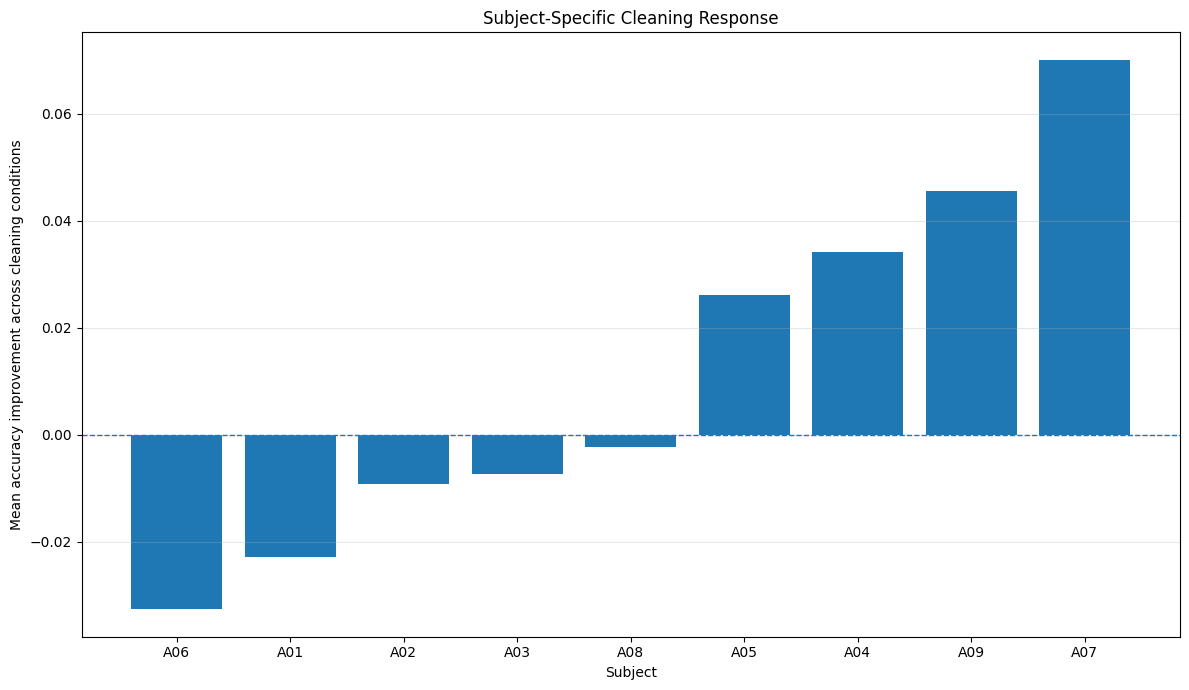

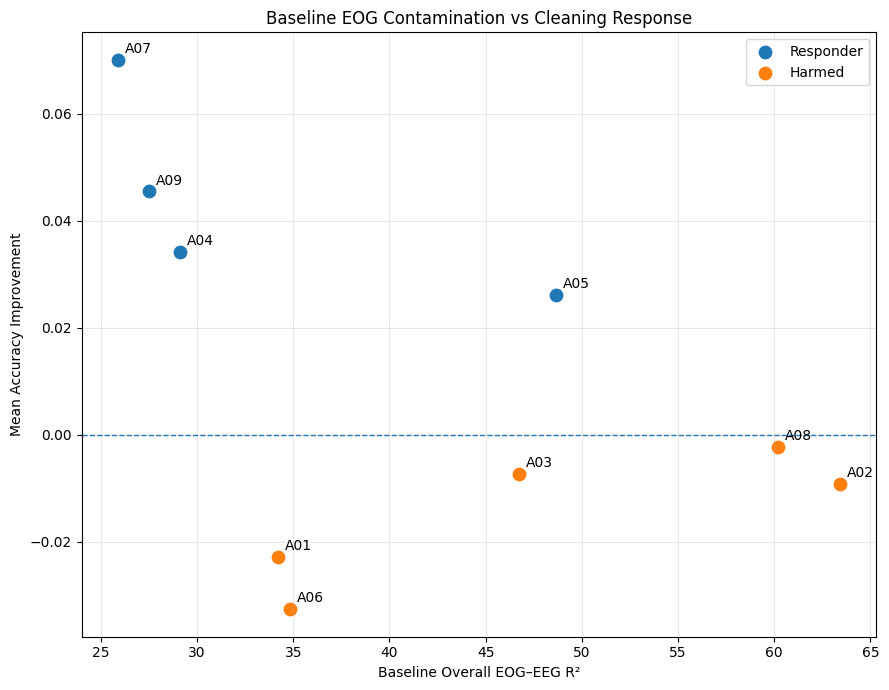

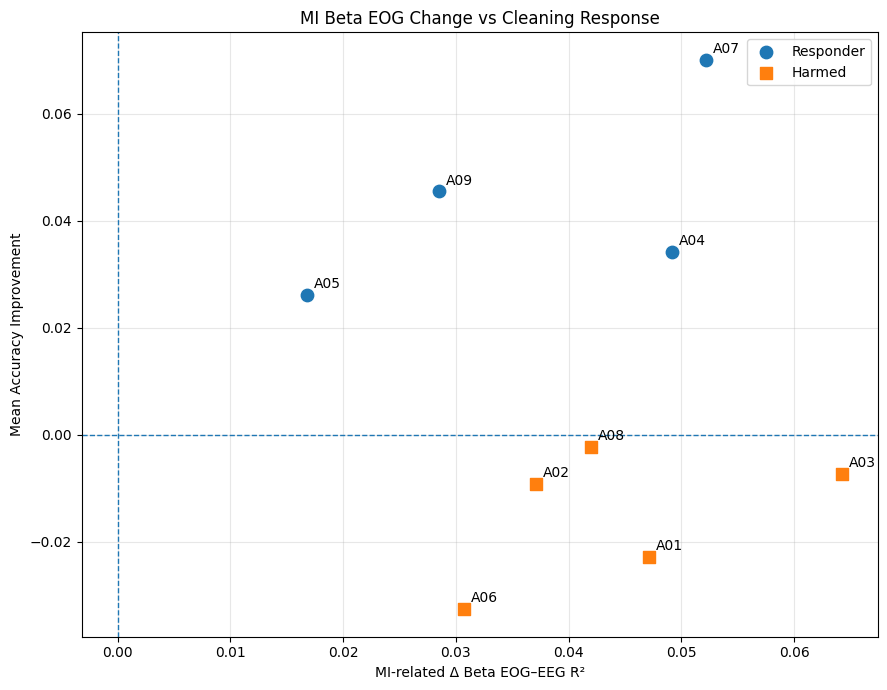

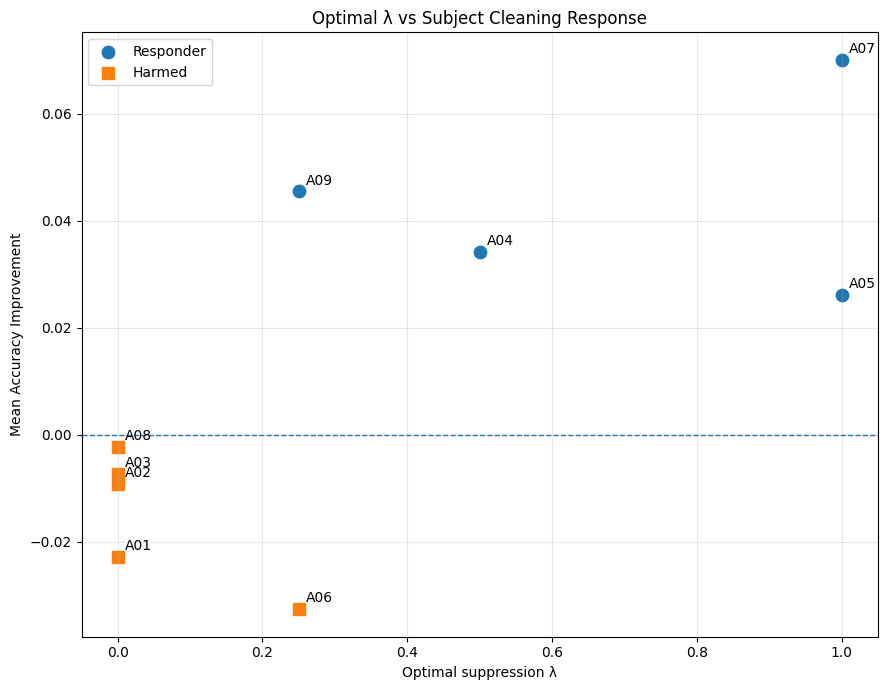



FINAL RESPONSE GROUP SUMMARY
Response_Group  Subjects  Mean_Accuracy_Response  Mean_F1_Response  Mean_Optimal_Lambda
        Harmed         5                -0.01481          -0.02125               0.0500
     Responder         4                 0.04395           0.05349               0.6875


ANALYSIS COMPLETE

Saved:
/content/drive/MyDrive/BCC/results/subject_cleaning_responder_master.csv
/content/drive/MyDrive/BCC/results/cleaning_responder_vs_harmed_statistics.csv
/content/drive/MyDrive/BCC/results/cleaning_benefit_vs_subject_features_correlations.csv
/content/drive/MyDrive/BCC/results/subject_best_cleaning_response.csv
/content/drive/MyDrive/BCC/results/cleaning_response_group_summary.csv
/content/drive/MyDrive/BCC/results/../images/subject_cleaning_response_score.png
/content/drive/MyDrive/BCC/images/baseline_eog_vs_cleaning_response.png
/content/drive/MyDrive/BCC/images/mi_beta_change_vs_cleaning_response.png
/content/drive/MyDrive/BCC/images/optimal_lambda_vs_cleaning_respons

In [ ]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    mannwhitneyu,
    pearsonr,
    spearmanr
)


# BASE_DIR is defined in the configuration cell.


RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

CLEANING_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_frequency_cleaning_performance.csv"
)

LAMBDA_FILE = os.path.join(
    RESULTS_DIR,
    "subject_lambda_prediction_features.csv"
)

DELTA_MASTER_FILE = os.path.join(
    RESULTS_DIR,
    "mi_eog_change_suppression_performance_master.csv"
)

SUBJECTS = [
    "A01", "A02", "A03",
    "A04", "A05", "A06",
    "A07", "A08", "A09"
]

CLEANING_CONDITIONS = [
    "All_Clean",
    "Theta_Clean",
    "Alpha_Mu_Clean",
    "Beta_Clean",
    "Gamma_Clean"
]

DELTA_FEATURES = [
    "Delta_Theta_R2",
    "Delta_Alpha_Mu_R2",
    "Delta_Beta_R2",
    "Delta_Gamma_R2",
    "Delta_Overall_R2"
]

print("=" * 110)
print("SUBJECT CLEANING RESPONDER ANALYSIS")
print("=" * 110)

if not os.path.exists(CLEANING_FILE):

    raise FileNotFoundError(
        f"Missing:\n{CLEANING_FILE}"
    )

clean = pd.read_csv(
    CLEANING_FILE
)

clean.columns = [
    str(c).strip()
    for c in clean.columns
]

print("\nCleaning data:")
print(
    clean.shape
)

required = [
    "Subject",
    "Condition",
    "Accuracy",
    "Macro_F1"
]

missing = [
    c for c in required
    if c not in clean.columns
]

if missing:

    raise KeyError(
        f"Missing columns: {missing}"
    )

raw = clean[
    clean["Condition"] == "Raw"
].copy()

raw = raw[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(
    columns={
        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"
    }
)

benefit_rows = []

for condition in CLEANING_CONDITIONS:

    temp = clean[
        clean["Condition"] == condition
    ].copy()

    temp = temp.merge(
        raw,
        on="Subject",
        how="inner"
    )

    temp[
        "Accuracy_Improvement"
    ] = (
        temp["Accuracy"]
        -
        temp["Raw_Accuracy"]
    )

    temp[
        "F1_Improvement"
    ] = (
        temp["Macro_F1"]
        -
        temp["Raw_F1"]
    )

    benefit_rows.append(
        temp[
            [
                "Subject",
                "Condition",
                "Accuracy_Improvement",
                "F1_Improvement"
            ]
        ]
    )

benefit = pd.concat(
    benefit_rows,
    ignore_index=True
)

subject_response = (
    benefit
    .groupby("Subject")
    .agg(

        Mean_Accuracy_Improvement=(
            "Accuracy_Improvement",
            "mean"
        ),

        Mean_F1_Improvement=(
            "F1_Improvement",
            "mean"
        ),

        Median_Accuracy_Improvement=(
            "Accuracy_Improvement",
            "median"
        ),

        Median_F1_Improvement=(
            "F1_Improvement",
            "median"
        ),

        Positive_Accuracy_Conditions=(
            "Accuracy_Improvement",
            lambda x: int(
                (x > 0).sum()
            )
        ),

        Positive_F1_Conditions=(
            "F1_Improvement",
            lambda x: int(
                (x > 0).sum()
            )
        )

    )
    .reset_index()
)

def classify_subject(row):

    accuracy = row[
        "Mean_Accuracy_Improvement"
    ]

    f1 = row[
        "Mean_F1_Improvement"
    ]

    if (
        accuracy > 0
        and
        f1 > 0
    ):

        return "Responder"

    elif (
        accuracy < 0
        and
        f1 < 0
    ):

        return "Harmed"

    else:

        return "Mixed"

subject_response[
    "Response_Group"
] = subject_response.apply(
    classify_subject,
    axis=1
)

print("\n")
print("=" * 110)
print("SUBJECT CLEANING RESPONSE")
print("=" * 110)

print(
    subject_response.round(5).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("RESPONSE GROUP COUNTS")
print("=" * 110)

print(
    subject_response[
        "Response_Group"
    ].value_counts()
)

print("\n")
print("=" * 110)
print("LOADING EOG / EEG SUBJECT FEATURES")
print("=" * 110)

if not os.path.exists(LAMBDA_FILE):

    raise FileNotFoundError(
        f"Missing:\n{LAMBDA_FILE}"
    )

features = pd.read_csv(
    LAMBDA_FILE
)

features.columns = [
    str(c).strip()
    for c in features.columns
]

print(
    "Feature table shape:",
    features.shape
)

print(
    "Feature columns:",
    features.columns.tolist()
)

if os.path.exists(DELTA_MASTER_FILE):

    delta_master = pd.read_csv(
        DELTA_MASTER_FILE
    )

    delta_master.columns = [
        str(c).strip()
        for c in delta_master.columns
    ]

    delta_cols_available = [
        c for c in DELTA_FEATURES
        if c in delta_master.columns
    ]

    if len(delta_cols_available) > 0:

        delta_master = delta_master[
            ["Subject"] + delta_cols_available
        ].drop_duplicates(
            subset="Subject"
        )

        features = features.drop(
            columns=[
                c for c in delta_cols_available
                if c in features.columns
            ],
            errors="ignore"
        )

        features = features.merge(
            delta_master,
            on="Subject",
            how="left"
        )

master = subject_response.merge(
    features,
    on="Subject",
    how="left"
)

print("\n")
print("=" * 110)
print("FINAL SUBJECT MASTER DATA")
print("=" * 110)

print(
    master.round(5).to_string(
        index=False
    )
)

master_file = os.path.join(
    RESULTS_DIR,
    "subject_cleaning_responder_master.csv"
)

master.to_csv(
    master_file,
    index=False
)

print(
    "\nSaved:",
    master_file
)

comparison_df = master[
    master["Response_Group"].isin(
        [
            "Responder",
            "Harmed"
        ]
    )
].copy()

print("\n")
print("=" * 110)
print("RESPONDER vs HARMED")
print("=" * 110)

print(
    comparison_df[
        [
            "Subject",
            "Response_Group",
            "Mean_Accuracy_Improvement",
            "Mean_F1_Improvement"
        ]
    ]
    .round(5)
    .to_string(index=False)
)

candidate_features = [

    "EOG_Theta_R2",
    "EOG_Alpha_Mu_R2",
    "EOG_Beta_R2",
    "EOG_Gamma_R2",
    "EOG_Overall_R2",

    "Delta_Theta_R2",
    "Delta_Alpha_Mu_R2",
    "Delta_Beta_R2",
    "Delta_Gamma_R2",
    "Delta_Overall_R2",

    "Theta_Relative_Power",
    "Alpha_Mu_Relative_Power",
    "Beta_Relative_Power",
    "Gamma_Relative_Power",

    "EOG_Error_Slope",

    "Best_Lambda_Accuracy",
    "Best_Lambda_F1"
]

available_features = [
    c for c in candidate_features
    if c in comparison_df.columns
]

print("\nAvailable features:")
print(
    available_features
)

print("\n")
print("=" * 110)
print("GROUP FEATURE MEANS")
print("=" * 110)

group_summary = (
    comparison_df
    .groupby("Response_Group")[
        available_features
    ]
    .mean()
)

print(
    group_summary.round(5).to_string()
)

print("\n")
print("=" * 110)
print("GROUP FEATURE MEDIANS")
print("=" * 110)

group_medians = (
    comparison_df
    .groupby("Response_Group")[
        available_features
    ]
    .median()
)

print(
    group_medians.round(5).to_string()
)

mw_rows = []

for feature in available_features:

    responder = comparison_df[
        comparison_df["Response_Group"]
        == "Responder"
    ][feature].dropna().values

    harmed = comparison_df[
        comparison_df["Response_Group"]
        == "Harmed"
    ][feature].dropna().values

    if (
        len(responder) < 2
        or
        len(harmed) < 2
    ):
        continue

    try:

        statistic, p_value = mannwhitneyu(
            responder,
            harmed,
            alternative="two-sided"
        )

    except Exception:

        continue

    responder_median = np.median(
        responder
    )

    harmed_median = np.median(
        harmed
    )

    n1 = len(responder)
    n2 = len(harmed)

    rank_biserial = (
        2 * statistic /
        (n1 * n2)
    ) - 1

    mw_rows.append({

        "Feature":
            feature,

        "Responder_N":
            n1,

        "Harmed_N":
            n2,

        "Responder_Median":
            responder_median,

        "Harmed_Median":
            harmed_median,

        "MannWhitney_U":
            statistic,

        "p_value":
            p_value,

        "Rank_Biserial":
            rank_biserial

    })

mw_df = pd.DataFrame(
    mw_rows
)

mw_df = mw_df.sort_values(
    "p_value"
)

print("\n")
print("=" * 110)
print("RESPONDER vs HARMED: MANN-WHITNEY ANALYSIS")
print("=" * 110)

print(
    mw_df.round(5).to_string(
        index=False
    )
)

mw_file = os.path.join(
    RESULTS_DIR,
    "cleaning_responder_vs_harmed_statistics.csv"
)

mw_df.to_csv(
    mw_file,
    index=False
)

print(
    "\nSaved:",
    mw_file
)

continuous_rows = []

for feature in available_features:

    temp = master[
        [
            feature,
            "Mean_Accuracy_Improvement",
            "Mean_F1_Improvement"
        ]
    ].dropna()

    if len(temp) < 4:
        continue

    try:

        pearson_accuracy_r, \
        pearson_accuracy_p = pearsonr(
            temp[feature],
            temp[
                "Mean_Accuracy_Improvement"
            ]
        )

    except Exception:

        pearson_accuracy_r = np.nan
        pearson_accuracy_p = np.nan

    try:

        spearman_accuracy_rho, \
        spearman_accuracy_p = spearmanr(
            temp[feature],
            temp[
                "Mean_Accuracy_Improvement"
            ]
        )

    except Exception:

        spearman_accuracy_rho = np.nan
        spearman_accuracy_p = np.nan

    try:

        pearson_f1_r, \
        pearson_f1_p = pearsonr(
            temp[feature],
            temp[
                "Mean_F1_Improvement"
            ]
        )

    except Exception:

        pearson_f1_r = np.nan
        pearson_f1_p = np.nan

    try:

        spearman_f1_rho, \
        spearman_f1_p = spearmanr(
            temp[feature],
            temp[
                "Mean_F1_Improvement"
            ]
        )

    except Exception:

        spearman_f1_rho = np.nan
        spearman_f1_p = np.nan

    continuous_rows.append({

        "Feature":
            feature,

        "N":
            len(temp),

        "Pearson_Accuracy_r":
            pearson_accuracy_r,

        "Pearson_Accuracy_p":
            pearson_accuracy_p,

        "Spearman_Accuracy_rho":
            spearman_accuracy_rho,

        "Spearman_Accuracy_p":
            spearman_accuracy_p,

        "Pearson_F1_r":
            pearson_f1_r,

        "Pearson_F1_p":
            pearson_f1_p,

        "Spearman_F1_rho":
            spearman_f1_rho,

        "Spearman_F1_p":
            spearman_f1_p

    })

continuous_df = pd.DataFrame(
    continuous_rows
)

print("\n")
print("=" * 110)
print("CONTINUOUS CLEANING BENEFIT vs SUBJECT FEATURES")
print("=" * 110)

print(
    continuous_df.round(5).to_string(
        index=False
    )
)

continuous_file = os.path.join(
    RESULTS_DIR,
    "cleaning_benefit_vs_subject_features_correlations.csv"
)

continuous_df.to_csv(
    continuous_file,
    index=False
)

print(
    "\nSaved:",
    continuous_file
)

print("\n")
print("=" * 110)
print("BEST CLEANING CONDITION PER SUBJECT")
print("=" * 110)

best_rows = []

for subject in SUBJECTS:

    temp = benefit[
        benefit["Subject"] == subject
    ].copy()

    if len(temp) == 0:
        continue

    best_accuracy_idx = temp[
        "Accuracy_Improvement"
    ].idxmax()

    best_accuracy_row = temp.loc[
        best_accuracy_idx
    ]

    best_f1_idx = temp[
        "F1_Improvement"
    ].idxmax()

    best_f1_row = temp.loc[
        best_f1_idx
    ]

    best_rows.append({

        "Subject":
            subject,

        "Best_Accuracy_Condition":
            best_accuracy_row[
                "Condition"
            ],

        "Best_Accuracy_Improvement":
            best_accuracy_row[
                "Accuracy_Improvement"
            ],

        "Best_F1_Condition":
            best_f1_row[
                "Condition"
            ],

        "Best_F1_Improvement":
            best_f1_row[
                "F1_Improvement"
            ]

    })

best_df = pd.DataFrame(
    best_rows
)

best_df = best_df.merge(
    subject_response[
        [
            "Subject",
            "Response_Group"
        ]
    ],
    on="Subject",
    how="left"
)

print(
    best_df.round(5).to_string(
        index=False
    )
)

best_file = os.path.join(
    RESULTS_DIR,
    "subject_best_cleaning_response.csv"
)

best_df.to_csv(
    best_file,
    index=False
)

plot_df = subject_response.sort_values(
    "Mean_Accuracy_Improvement"
)

plt.figure(
    figsize=(12, 7)
)

x = np.arange(
    len(plot_df)
)

plt.bar(
    x,
    plot_df[
        "Mean_Accuracy_Improvement"
    ]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xticks(
    x,
    plot_df["Subject"]
)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "Mean accuracy improvement across cleaning conditions"
)

plt.title(
    "Subject-Specific Cleaning Response"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

response_plot = os.path.join(
    RESULTS_DIR,
    "..",
    "images",
    "subject_cleaning_response_score.png"
)

plt.savefig(
    response_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

if "EOG_Overall_R2" in master.columns:

    plt.figure(
        figsize=(9, 7)
    )

    responders = master[
        master["Response_Group"]
        == "Responder"
    ]

    harmed = master[
        master["Response_Group"]
        == "Harmed"
    ]

    mixed = master[
        master["Response_Group"]
        == "Mixed"
    ]

    if len(responders) > 0:

        plt.scatter(
            responders[
                "EOG_Overall_R2"
            ],
            responders[
                "Mean_Accuracy_Improvement"
            ],
            s=80,
            label="Responder"
        )

    if len(harmed) > 0:

        plt.scatter(
            harmed[
                "EOG_Overall_R2"
            ],
            harmed[
                "Mean_Accuracy_Improvement"
            ],
            s=80,
            label="Harmed"
        )

    if len(mixed) > 0:

        plt.scatter(
            mixed[
                "EOG_Overall_R2"
            ],
            mixed[
                "Mean_Accuracy_Improvement"
            ],
            s=80,
            label="Mixed"
        )

    for _, row in master.iterrows():

        plt.annotate(
            row["Subject"],
            (
                row["EOG_Overall_R2"],
                row["Mean_Accuracy_Improvement"]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(
        "Baseline Overall EOG–EEG R²"
    )

    plt.ylabel(
        "Mean Accuracy Improvement"
    )

    plt.title(
        "Baseline EOG Contamination vs Cleaning Response"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    eog_response_plot = os.path.join(
        FIGURES_DIR,
        "baseline_eog_vs_cleaning_response.png"
    )

    plt.savefig(
        eog_response_plot,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

if "Delta_Beta_R2" in master.columns:

    plt.figure(
        figsize=(9, 7)
    )

    for group, marker in [
        ("Responder", "o"),
        ("Harmed", "s"),
        ("Mixed", "^")
    ]:

        temp = master[
            master["Response_Group"]
            == group
        ]

        if len(temp) == 0:
            continue

        plt.scatter(
            temp[
                "Delta_Beta_R2"
            ],
            temp[
                "Mean_Accuracy_Improvement"
            ],
            s=80,
            marker=marker,
            label=group
        )

        for _, row in temp.iterrows():

            plt.annotate(
                row["Subject"],
                (
                    row[
                        "Delta_Beta_R2"
                    ],
                    row[
                        "Mean_Accuracy_Improvement"
                    ]
                ),
                xytext=(5, 5),
                textcoords="offset points"
            )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(
        "MI-related Δ Beta EOG–EEG R²"
    )

    plt.ylabel(
        "Mean Accuracy Improvement"
    )

    plt.title(
        "MI Beta EOG Change vs Cleaning Response"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    beta_response_plot = os.path.join(
        FIGURES_DIR,
        "mi_beta_change_vs_cleaning_response.png"
    )

    plt.savefig(
        beta_response_plot,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

lambda_column = None

for candidate in [
    "Best_Lambda_Accuracy",
    "Best_Lambda_F1"
]:

    if candidate in master.columns:

        lambda_column = candidate

        break

if lambda_column is not None:

    plt.figure(
        figsize=(9, 7)
    )

    for group, marker in [
        ("Responder", "o"),
        ("Harmed", "s"),
        ("Mixed", "^")
    ]:

        temp = master[
            master["Response_Group"]
            == group
        ]

        if len(temp) == 0:
            continue

        plt.scatter(
            temp[
                lambda_column
            ],
            temp[
                "Mean_Accuracy_Improvement"
            ],
            s=80,
            marker=marker,
            label=group
        )

        for _, row in temp.iterrows():

            plt.annotate(
                row["Subject"],
                (
                    row[
                        lambda_column
                    ],
                    row[
                        "Mean_Accuracy_Improvement"
                    ]
                ),
                xytext=(5, 5),
                textcoords="offset points"
            )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(
        "Optimal suppression λ"
    )

    plt.ylabel(
        "Mean Accuracy Improvement"
    )

    plt.title(
        "Optimal λ vs Subject Cleaning Response"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    lambda_response_plot = os.path.join(
        FIGURES_DIR,
        "optimal_lambda_vs_cleaning_response.png"
    )

    plt.savefig(
        lambda_response_plot,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

group_performance = (
    master
    .groupby("Response_Group")
    .agg(

        Subjects=(
            "Subject",
            "count"
        ),

        Mean_Accuracy_Response=(
            "Mean_Accuracy_Improvement",
            "mean"
        ),

        Mean_F1_Response=(
            "Mean_F1_Improvement",
            "mean"
        ),

        Mean_Optimal_Lambda=(
            lambda_column,
            "mean"
        )
        if lambda_column is not None
        else (
            "Subject",
            lambda x: np.nan
        )

    )
    .reset_index()
)

print("\n")
print("=" * 110)
print("FINAL RESPONSE GROUP SUMMARY")
print("=" * 110)

print(
    group_performance.round(5).to_string(
        index=False
    )
)

group_summary_file = os.path.join(
    RESULTS_DIR,
    "cleaning_response_group_summary.csv"
)

group_performance.to_csv(
    group_summary_file,
    index=False
)

print("\n")
print("=" * 110)
print("ANALYSIS COMPLETE")
print("=" * 110)

print("\nSaved:")

print(
    master_file
)

print(
    mw_file
)

print(
    continuous_file
)

print(
    best_file
)

print(
    group_summary_file
)

print(
    response_plot
)

if "eog_response_plot" in locals():
    print(
        eog_response_plot
    )

if "beta_response_plot" in locals():
    print(
        beta_response_plot
    )

if "lambda_response_plot" in locals():
    print(
        lambda_response_plot
    )

print("\n")
print("=" * 110)
print("INTERPRETATION NOTE")
print("=" * 110)

print("""
There are only 9 subjects.

Therefore:

1. Responder/Harmed group comparisons are exploratory.

2. A small p-value should NOT automatically be interpreted
   as proof of a general effect.

3. Feature correlations should be examined together with
   their direction, effect size, and subject-level pattern.

4. The most important goal is to identify a coherent
   physiological/modeling pattern rather than maximize
   statistical significance.

5. No machine-learning predictive model should be trained
   on these 9 subjects. The sample is too small.
""")


## Pre-Cleaning Responder Score

PRE-CLEANING RESPONDER SCORE

Input:
/content/drive/MyDrive/BCC/results/subject_cleaning_responder_master.csv
✓ Input file found

Loaded shape:
(9, 28)

Subjects:
['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']


RESPONSE GROUPS
Subject Response_Group  Mean_Accuracy_Improvement  Mean_F1_Improvement
    A01         Harmed                   -0.02278             -0.03021
    A02         Harmed                   -0.00919             -0.01007
    A03         Harmed                   -0.00733             -0.01919
    A04      Responder                    0.03421              0.03752
    A05      Responder                    0.02609              0.06296
    A06         Harmed                   -0.03256             -0.03560
    A07      Responder                    0.07004              0.06822
    A08         Harmed                   -0.00221             -0.01118
    A09      Responder                    0.04545              0.04528

Group counts:
Response_Group
Harmed       5


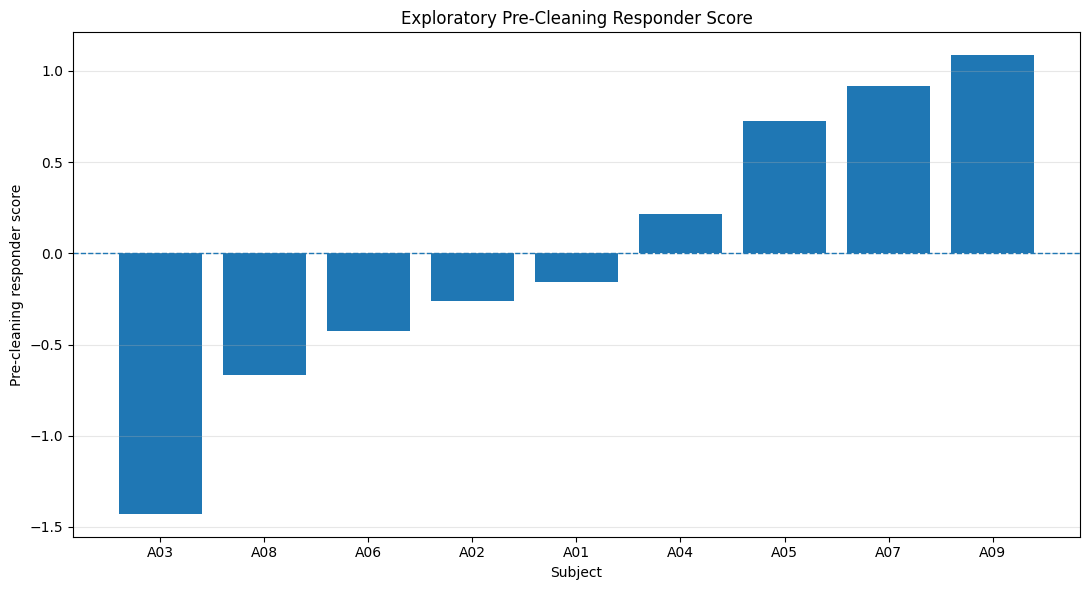



PRE-CLEANING RESPONDER SCORE COMPLETE

LOOCV Accuracy: 1.00000
LOOCV Balanced Accuracy: 1.00000
LOOCV ROC AUC: 1.00000
Exact permutation p: 0.00196

Score group test:
Mann-Whitney p = 0.01587
Rank-biserial = 1.00000

Files saved:
/content/drive/MyDrive/BCC/results/pre_cleaning_responder_score.csv
/content/drive/MyDrive/BCC/results/pre_cleaning_responder_score_components.csv
/content/drive/MyDrive/BCC/results/pre_cleaning_responder_score_loocv.csv
/content/drive/MyDrive/BCC/results/pre_cleaning_responder_score_continuous_correlations.csv
/content/drive/MyDrive/BCC/results/pre_cleaning_responder_score_group_summary.csv
/content/drive/MyDrive/BCC/images/pre_cleaning_responder_score.png


IMPORTANT

This is an exploratory score.

The nine subjects are too few to claim a validated
general-purpose responder classifier.

The important result is whether a pre-cleaning score
shows a coherent separation under leave-one-subject-out
validation.

An apparent good score must still be validated on 

In [ ]:
import os
import itertools
import numpy as np
import pandas as pd

from scipy.stats import (
    mannwhitneyu,
    pearsonr,
    spearmanr
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score
)


# BASE_DIR is defined in the configuration cell.


RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

FIGURES_DIR = os.path.join(
    BASE_DIR,
    "images"
)

MASTER_FILE = os.path.join(
    RESULTS_DIR,
    "subject_cleaning_responder_master.csv"
)

print("=" * 110)
print("PRE-CLEANING RESPONDER SCORE")
print("=" * 110)

print("\nInput:")
print(MASTER_FILE)

if not os.path.exists(MASTER_FILE):

    raise FileNotFoundError(
        f"Could not find:\n{MASTER_FILE}"
    )

print("✓ Input file found")

df = pd.read_csv(
    MASTER_FILE
)

df.columns = [
    str(c).strip()
    for c in df.columns
]

print("\nLoaded shape:")
print(
    df.shape
)

print("\nSubjects:")
print(
    df["Subject"].tolist()
)

required_columns = [

    "Mean_Accuracy_Improvement",
    "Mean_F1_Improvement",
    "Response_Group",

    "EOG_Gamma_R2",
    "Delta_Theta_R2",
    "Delta_Alpha_Mu_R2",
    "Gamma_Relative_Power"

]

missing = [
    c
    for c in required_columns
    if c not in df.columns
]

if missing:

    raise KeyError(
        f"Missing required columns:\n{missing}"
    )

data = df[
    df["Response_Group"].isin(
        [
            "Responder",
            "Harmed"
        ]
    )
].copy()

data = data.sort_values(
    "Subject"
).reset_index(
    drop=True
)

print("\n")
print("=" * 110)
print("RESPONSE GROUPS")
print("=" * 110)

print(
    data[
        [
            "Subject",
            "Response_Group",
            "Mean_Accuracy_Improvement",
            "Mean_F1_Improvement"
        ]
    ].round(5).to_string(
        index=False
    )
)

print("\nGroup counts:")
print(
    data["Response_Group"].value_counts()
)

FEATURES = [

    "EOG_Gamma_R2",
    "Delta_Theta_R2",
    "Delta_Alpha_Mu_R2",
    "Gamma_Relative_Power"

]

for feature in FEATURES:

    data[feature] = pd.to_numeric(
        data[feature],
        errors="coerce"
    )

print("\n")
print("=" * 110)
print("PRE-CLEANING FEATURE CHECK")
print("=" * 110)

missing_counts = (
    data[FEATURES]
    .isna()
    .sum()
)

print(
    missing_counts
)

if missing_counts.sum() > 0:

    print(
        "\nWARNING: Some feature values are missing."
    )

    data = data.dropna(
        subset=FEATURES
    ).copy()

print("\n")
print("=" * 110)
print("PRE-CLEANING FEATURES")
print("=" * 110)

print(
    data[
        [
            "Subject",
            "Response_Group"
        ]
        +
        FEATURES
    ].round(5).to_string(
        index=False
    )
)

FEATURE_SIGN = {

    "EOG_Gamma_R2": -1.0,

    "Delta_Theta_R2": -1.0,

    "Delta_Alpha_Mu_R2": -1.0,

    "Gamma_Relative_Power": -1.0

}

feature_means = {}
feature_stds = {}

for feature in FEATURES:

    mean = data[
        feature
    ].mean()

    std = data[
        feature
    ].std(
        ddof=1
    )

    if not np.isfinite(std) or std == 0:

        std = 1.0

    feature_means[
        feature
    ] = mean

    feature_stds[
        feature
    ] = std

component_data = pd.DataFrame(
    index=data.index
)

for feature in FEATURES:

    z = (
        data[feature]
        -
        feature_means[feature]
    ) / feature_stds[feature]

    component_data[
        feature
    ] = (
        FEATURE_SIGN[feature]
        * z
    )

data[
    "Responder_Score"
] = component_data.mean(
    axis=1
)

print("\n")
print("=" * 110)
print("DESCRIPTIVE PRE-CLEANING RESPONDER SCORE")
print("=" * 110)

score_columns = [
    "Subject",
    "Response_Group",
    "Responder_Score"
]

print(
    data[
        score_columns
    ].sort_values(
        "Responder_Score",
        ascending=False
    ).round(5).to_string(
        index=False
    )
)

component_output = pd.concat(
    [
        data[
            [
                "Subject",
                "Response_Group"
            ]
        ].reset_index(drop=True),

        component_data.reset_index(
            drop=True
        )
    ],
    axis=1
)

component_output = component_output.rename(
    columns={

        "EOG_Gamma_R2":
            "Component_Low_Gamma_EOG",

        "Delta_Theta_R2":
            "Component_More_Negative_Theta",

        "Delta_Alpha_Mu_R2":
            "Component_More_Negative_AlphaMu",

        "Gamma_Relative_Power":
            "Component_Low_Gamma_Power"

    }
)

print("\n")
print("=" * 110)
print("RESPONDER SCORE COMPONENTS")
print("=" * 110)

print(
    component_output.round(5).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("RESPONDER SCORE BY GROUP")
print("=" * 110)

group_score_summary = (
    data
    .groupby(
        "Response_Group"
    )[
        "Responder_Score"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
)

print(
    group_score_summary.round(5).to_string()
)

loocv_rows = []

for held_out_subject in data["Subject"]:

    train = data[
        data["Subject"]
        != held_out_subject
    ].copy()

    test = data[
        data["Subject"]
        == held_out_subject
    ].copy()

    train_means = {}
    train_stds = {}

    for feature in FEATURES:

        mean = train[
            feature
        ].mean()

        std = train[
            feature
        ].std(
            ddof=1
        )

        if not np.isfinite(std) or std == 0:

            std = 1.0

        train_means[
            feature
        ] = mean

        train_stds[
            feature
        ] = std

    train_component_values = pd.DataFrame(
        index=train.index
    )

    for feature in FEATURES:

        z = (
            train[feature]
            -
            train_means[feature]
        ) / train_stds[feature]

        train_component_values[
            feature
        ] = (
            FEATURE_SIGN[feature]
            * z
        )

    train_scores = (
        train_component_values
        .mean(axis=1)
    )

    test_component_values = pd.DataFrame(
        index=test.index
    )

    for feature in FEATURES:

        z = (
            test[feature]
            -
            train_means[feature]
        ) / train_stds[feature]

        test_component_values[
            feature
        ] = (
            FEATURE_SIGN[feature]
            * z
        )

    test_score = float(
        test_component_values
        .mean(axis=1)
        .iloc[0]
    )

    responder_train = train_scores[
        train[
            "Response_Group"
        ].values
        ==
        "Responder"
    ]

    harmed_train = train_scores[
        train[
            "Response_Group"
        ].values
        ==
        "Harmed"
    ]

    responder_train_mean = (
        responder_train.mean()
    )

    harmed_train_mean = (
        harmed_train.mean()
    )

    threshold = (
        responder_train_mean
        +
        harmed_train_mean
    ) / 2.0

    predicted_group = (
        "Responder"
        if test_score >= threshold
        else
        "Harmed"
    )

    actual_group = test[
        "Response_Group"
    ].iloc[0]

    loocv_rows.append({

        "Subject":
            held_out_subject,

        "Actual_Group":
            actual_group,

        "LOOCV_Score":
            test_score,

        "Training_Responder_Mean":
            responder_train_mean,

        "Training_Harmed_Mean":
            harmed_train_mean,

        "Training_Threshold":
            threshold,

        "Predicted_Group":
            predicted_group,

        "Correct":
            int(
                predicted_group
                ==
                actual_group
            )

    })

loocv = pd.DataFrame(
    loocv_rows
)

print("\n")
print("=" * 110)
print("LEAVE-ONE-SUBJECT-OUT RESPONDER SCORE")
print("=" * 110)

print(
    loocv.round(5).to_string(
        index=False
    )
)

y_true = (
    loocv[
        "Actual_Group"
    ]
    ==
    "Responder"
).astype(int)

y_pred = (
    loocv[
        "Predicted_Group"
    ]
    ==
    "Responder"
).astype(int)

score_values = loocv[
    "LOOCV_Score"
].values

loocv_accuracy = accuracy_score(
    y_true,
    y_pred
)

loocv_balanced_accuracy = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)

print("\n")
print("=" * 110)
print("LOOCV PERFORMANCE")
print("=" * 110)

print(
    f"Accuracy          : "
    f"{loocv_accuracy:.5f}"
)

print(
    f"Balanced Accuracy : "
    f"{loocv_balanced_accuracy:.5f}"
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print("\n")
print("=" * 110)
print("CONFUSION MATRIX")
print("=" * 110)

print(
    pd.DataFrame(
        cm,
        index=[
            "Actual_Harmed",
            "Actual_Responder"
        ],
        columns=[
            "Predicted_Harmed",
            "Predicted_Responder"
        ]
    )
)

if len(
    np.unique(y_true)
) == 2:

    auc = roc_auc_score(
        y_true,
        score_values
    )

    print(
        f"\nLOOCV ROC AUC: "
        f"{auc:.5f}"
    )

else:

    auc = np.nan

    print(
        "\nROC AUC unavailable."
    )

print("\n")
print("=" * 110)
print("EXACT PERMUTATION TEST")
print("=" * 110)

n = len(y_true)

permutation_scores = []

for bits in itertools.product(
    [0, 1],
    repeat=n
):

    permuted_labels = np.array(
        bits
    )

    if len(
        np.unique(
            permuted_labels
        )
    ) < 2:
        continue

    value = balanced_accuracy_score(
        permuted_labels,
        y_pred
    )

    permutation_scores.append(
        value
    )

permutation_scores = np.asarray(
    permutation_scores
)

observed = (
    loocv_balanced_accuracy
)

permutation_p = (
    (
        permutation_scores
        >=
        observed
    ).sum()
    /
    len(permutation_scores)
)

print(
    f"Observed balanced accuracy: "
    f"{observed:.5f}"
)

print(
    f"Exact permutation p-value: "
    f"{permutation_p:.5f}"
)

ranked = data[
    [
        "Subject",
        "Response_Group",
        "Responder_Score"
    ]
].sort_values(
    "Responder_Score",
    ascending=False
).reset_index(
    drop=True
)

ranked[
    "Score_Rank"
] = np.arange(
    1,
    len(ranked) + 1
)

print("\n")
print("=" * 110)
print("SUBJECT RANKING")
print("=" * 110)

print(
    ranked.round(5).to_string(
        index=False
    )
)

responder_scores = data[
    data["Response_Group"]
    == "Responder"
][
    "Responder_Score"
].values

harmed_scores = data[
    data["Response_Group"]
    == "Harmed"
][
    "Responder_Score"
].values

print("\n")
print("=" * 110)
print("GROUP SCORE SEPARATION")
print("=" * 110)

print(
    "Responder mean :",
    np.mean(responder_scores)
)

print(
    "Harmed mean    :",
    np.mean(harmed_scores)
)

print(
    "Responder median:",
    np.median(responder_scores)
)

print(
    "Harmed median   :",
    np.median(harmed_scores)
)

if (
    len(responder_scores) >= 2
    and
    len(harmed_scores) >= 2
):

    U, p = mannwhitneyu(
        responder_scores,
        harmed_scores,
        alternative="two-sided"
    )

    n1 = len(responder_scores)
    n2 = len(harmed_scores)

    rank_biserial = (
        2 * U /
        (n1 * n2)
    ) - 1

else:

    U = np.nan
    p = np.nan
    rank_biserial = np.nan

print("\n")
print("=" * 110)
print("RESPONDER SCORE GROUP TEST")
print("=" * 110)

print(
    f"Mann-Whitney U : "
    f"{U:.5f}"
)

print(
    f"p-value        : "
    f"{p:.5f}"
)

print(
    f"Rank-biserial  : "
    f"{rank_biserial:.5f}"
)

continuous_rows = []

for outcome in [
    "Mean_Accuracy_Improvement",
    "Mean_F1_Improvement"
]:

    x = data[
        "Responder_Score"
    ].values

    y = data[
        outcome
    ].values

    pearson_r, pearson_p = pearsonr(
        x,
        y
    )

    spearman_rho, spearman_p = spearmanr(
        x,
        y
    )

    continuous_rows.append({

        "Outcome":
            outcome,

        "N":
            len(x),

        "Pearson_r":
            pearson_r,

        "Pearson_p":
            pearson_p,

        "Spearman_rho":
            spearman_rho,

        "Spearman_p":
            spearman_p

    })

continuous_df = pd.DataFrame(
    continuous_rows
)

print("\n")
print("=" * 110)
print("RESPONDER SCORE vs CONTINUOUS CLEANING BENEFIT")
print("=" * 110)

print(
    continuous_df.round(5).to_string(
        index=False
    )
)

continuous_file = os.path.join(
    RESULTS_DIR,
    "pre_cleaning_responder_score_continuous_correlations.csv"
)

continuous_df.to_csv(
    continuous_file,
    index=False
)

score_file = os.path.join(
    RESULTS_DIR,
    "pre_cleaning_responder_score.csv"
)

data[
    [
        "Subject",
        "Response_Group",
        "Mean_Accuracy_Improvement",
        "Mean_F1_Improvement",
        "Responder_Score"
    ]
    +
    FEATURES
].to_csv(
    score_file,
    index=False
)

components_file = os.path.join(
    RESULTS_DIR,
    "pre_cleaning_responder_score_components.csv"
)

component_output.to_csv(
    components_file,
    index=False
)

loocv_file = os.path.join(
    RESULTS_DIR,
    "pre_cleaning_responder_score_loocv.csv"
)

loocv.to_csv(
    loocv_file,
    index=False
)

group_summary_file = os.path.join(
    RESULTS_DIR,
    "pre_cleaning_responder_score_group_summary.csv"
)

group_score_summary.to_csv(
    group_summary_file
)

plt.figure(
    figsize=(11, 6)
)

plot_data = data.sort_values(
    "Responder_Score"
)

x = np.arange(
    len(plot_data)
)

plt.bar(
    x,
    plot_data[
        "Responder_Score"
    ]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xticks(
    x,
    plot_data[
        "Subject"
    ]
)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "Pre-cleaning responder score"
)

plt.title(
    "Exploratory Pre-Cleaning Responder Score"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

score_plot = os.path.join(
    FIGURES_DIR,
    "pre_cleaning_responder_score.png"
)

plt.savefig(
    score_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n")
print("=" * 110)
print("PRE-CLEANING RESPONDER SCORE COMPLETE")
print("=" * 110)

print(
    "\nLOOCV Accuracy:",
    f"{loocv_accuracy:.5f}"
)

print(
    "LOOCV Balanced Accuracy:",
    f"{loocv_balanced_accuracy:.5f}"
)

print(
    "LOOCV ROC AUC:",
    f"{auc:.5f}"
    if np.isfinite(auc)
    else "N/A"
)

print(
    "Exact permutation p:",
    f"{permutation_p:.5f}"
)

print(
    "\nScore group test:"
)

print(
    f"Mann-Whitney p = {p:.5f}"
)

print(
    f"Rank-biserial = {rank_biserial:.5f}"
)

print("\nFiles saved:")

print(
    score_file
)

print(
    components_file
)

print(
    loocv_file
)

print(
    continuous_file
)

print(
    group_summary_file
)

print(
    score_plot
)

print("\n")
print("=" * 110)
print("IMPORTANT")
print("=" * 110)

print("""
This is an exploratory score.

The nine subjects are too few to claim a validated
general-purpose responder classifier.

The important result is whether a pre-cleaning score
shows a coherent separation under leave-one-subject-out
validation.

An apparent good score must still be validated on an
independent group of subjects before being treated as
a general predictive method.
""")


## Nested LOOCV Pre-Cleaning Responder Score

In [ ]:
import os
import itertools
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score
)


# BASE_DIR is defined in the configuration cell.


RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

MASTER_FILE = os.path.join(
    RESULTS_DIR,
    "subject_cleaning_responder_master.csv"
)

if not os.path.exists(MASTER_FILE):

    raise FileNotFoundError(
        f"Missing file:\n{MASTER_FILE}"
    )

df = pd.read_csv(
    MASTER_FILE
)

df.columns = [
    str(c).strip()
    for c in df.columns
]

print("=" * 110)
print("NESTED LOOCV PRE-CLEANING RESPONDER SCORE")
print("=" * 110)

print(
    "\nLoaded:",
    df.shape
)

FEATURES = [

    "EOG_Gamma_R2",

    "Delta_Theta_R2",

    "Delta_Alpha_Mu_R2",

    "Gamma_Relative_Power"

]

for feature in FEATURES:

    if feature not in df.columns:

        raise KeyError(
            f"Missing feature: {feature}"
        )

if "Response_Group" not in df.columns:

    raise KeyError(
        "Response_Group not found."
    )

data = df[
    df["Response_Group"].isin(
        [
            "Responder",
            "Harmed"
        ]
    )
].copy()

data = data.sort_values(
    "Subject"
).reset_index(
    drop=True
)

for feature in FEATURES:

    data[feature] = pd.to_numeric(
        data[feature],
        errors="coerce"
    )

print("\n")
print("=" * 110)
print("SUBJECTS")
print("=" * 110)

print(
    data[
        [
            "Subject",
            "Response_Group"
        ]
    ].to_string(
        index=False
    )
)

print("\nFeature missingness:")

print(
    data[
        FEATURES
    ].isna().sum()
)

if data[
    FEATURES
].isna().any().any():

    print(
        "\nWARNING: missing feature values found."
    )

    data = data.dropna(
        subset=FEATURES
    ).copy()

data[
    "y"
] = (
    data["Response_Group"]
    == "Responder"
).astype(int)

def fit_feature_direction(
    train_df,
    feature
):
    """
    Determine direction using TRAINING DATA ONLY.

    Positive correlation:
        higher feature -> responder
        direction = +1

    Negative correlation:
        lower feature -> responder
        direction = -1
    """

    x = train_df[
        feature
    ].to_numpy(
        dtype=float
    )

    y = train_df[
        "y"
    ].to_numpy(
        dtype=float
    )

    if (
        np.std(x) == 0
        or
        np.std(y) == 0
    ):

        return 1.0

    r, _ = pearsonr(
        x,
        y
    )

    if not np.isfinite(r):

        return 1.0

    return 1.0 if r >= 0 else -1.0

def fit_scaling(
    train_df,
    features
):

    means = {}
    stds = {}

    for feature in features:

        mean = train_df[
            feature
        ].mean()

        std = train_df[
            feature
        ].std(
            ddof=1
        )

        if (
            not np.isfinite(std)
            or
            std == 0
        ):

            std = 1.0

        means[
            feature
        ] = mean

        stds[
            feature
        ] = std

    return means, stds

def calculate_score(
    df_part,
    features,
    means,
    stds,
    directions
):

    components = {}

    for feature in features:

        z = (
            df_part[
                feature
            ]
            -
            means[
                feature
            ]
        ) / stds[
            feature
        ]

        components[
            feature
        ] = (
            directions[
                feature
            ]
            * z
        )

    components_df = pd.DataFrame(
        components,
        index=df_part.index
    )

    score = components_df.mean(
        axis=1
    )

    return score

def optimize_threshold(
    scores,
    labels
):

    scores = np.asarray(
        scores,
        dtype=float
    )

    labels = np.asarray(
        labels,
        dtype=int
    )

    finite = np.isfinite(
        scores
    )

    scores = scores[
        finite
    ]

    labels = labels[
        finite
    ]

    if len(scores) == 0:

        return 0.0, np.nan

    unique_scores = np.sort(
        np.unique(
            scores
        )
    )

    candidates = []

    for i in range(
        len(unique_scores) - 1
    ):

        candidates.append(
            (
                unique_scores[i]
                +
                unique_scores[i + 1]
            ) / 2.0
        )

    candidates.append(
        unique_scores[0] - 1e-9
    )

    candidates.append(
        unique_scores[-1] + 1e-9
    )

    best_threshold = 0.0
    best_score = -np.inf

    for threshold in candidates:

        predictions = (
            scores >= threshold
        ).astype(int)

        if len(
            np.unique(labels)
        ) < 2:

            continue

        score = balanced_accuracy_score(
            labels,
            predictions
        )

        if score > best_score:

            best_score = score
            best_threshold = threshold

    return (
        best_threshold,
        best_score
    )

def select_feature_subset(
    outer_train
):

    feature_subsets = []

    for r in range(
        1,
        len(FEATURES) + 1
    ):

        feature_subsets.extend(
            itertools.combinations(
                FEATURES,
                r
            )
        )

    subset_results = []

    for subset in feature_subsets:

        subset = list(
            subset
        )

        inner_predictions = []
        inner_truth = []

        inner_subjects = (
            outer_train[
                "Subject"
            ].tolist()
        )

        for validation_subject in inner_subjects:

            inner_train = outer_train[
                outer_train[
                    "Subject"
                ]
                != validation_subject
            ].copy()

            inner_test = outer_train[
                outer_train[
                    "Subject"
                ]
                == validation_subject
            ].copy()

            directions = {}

            for feature in subset:

                directions[
                    feature
                ] = fit_feature_direction(
                    inner_train,
                    feature
                )

            means, stds = fit_scaling(
                inner_train,
                subset
            )

            train_scores = calculate_score(
                inner_train,
                subset,
                means,
                stds,
                directions
            )

            test_scores = calculate_score(
                inner_test,
                subset,
                means,
                stds,
                directions
            )

            threshold, _ = optimize_threshold(
                train_scores,
                inner_train["y"]
            )

            prediction = int(
                test_scores.iloc[0]
                >= threshold
            )

            truth = int(
                inner_test["y"].iloc[0]
            )

            inner_predictions.append(
                prediction
            )

            inner_truth.append(
                truth
            )

        if len(
            np.unique(
                inner_truth
            )
        ) >= 2:

            inner_balanced_accuracy = (
                balanced_accuracy_score(
                    inner_truth,
                    inner_predictions
                )
            )

        else:

            inner_balanced_accuracy = np.nan

        subset_results.append({

            "Feature_Set":
                "+".join(subset),

            "N_Features":
                len(subset),

            "Inner_Balanced_Accuracy":
                inner_balanced_accuracy

        })

    subset_results_df = pd.DataFrame(
        subset_results
    )

    subset_results_df = (
        subset_results_df
        .sort_values(
            [
                "Inner_Balanced_Accuracy",
                "N_Features"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

    best_row = (
        subset_results_df.iloc[0]
    )

    best_features = (
        best_row[
            "Feature_Set"
        ]
        .split("+")
    )

    return (
        best_features,
        best_row[
            "Inner_Balanced_Accuracy"
        ],
        subset_results_df
    )

outer_rows = []

all_subset_selection = []

for held_out_subject in data[
    "Subject"
].tolist():

    print("\n")
    print("=" * 110)
    print(
        f"OUTER FOLD — HOLDING OUT {held_out_subject}"
    )
    print("=" * 110)

    outer_train = data[
        data["Subject"]
        != held_out_subject
    ].copy()

    outer_test = data[
        data["Subject"]
        == held_out_subject
    ].copy()

    (
        selected_features,
        inner_score,
        subset_results
    ) = select_feature_subset(
        outer_train
    )

    print(
        "\nSelected feature set:"
    )

    print(
        selected_features
    )

    print(
        "Inner LOOCV balanced accuracy:",
        round(
            inner_score,
            5
        )
    )

    temp_subset_results = (
        subset_results.copy()
    )

    temp_subset_results[
        "Held_Out_Subject"
    ] = held_out_subject

    all_subset_selection.append(
        temp_subset_results
    )

    directions = {}

    for feature in selected_features:

        directions[
            feature
        ] = fit_feature_direction(
            outer_train,
            feature
        )

    means, stds = fit_scaling(
        outer_train,
        selected_features
    )

    train_scores = calculate_score(
        outer_train,
        selected_features,
        means,
        stds,
        directions
    )

    test_scores = calculate_score(
        outer_test,
        selected_features,
        means,
        stds,
        directions
    )

    test_score = float(
        test_scores.iloc[0]
    )

    threshold, train_balanced_accuracy = (
        optimize_threshold(
            train_scores,
            outer_train["y"]
        )
    )

    predicted = int(
        test_score
        >= threshold
    )

    actual = int(
        outer_test["y"].iloc[0]
    )

    actual_group = (
        outer_test[
            "Response_Group"
        ].iloc[0]
    )

    predicted_group = (
        "Responder"
        if predicted == 1
        else
        "Harmed"
    )

    print(
        f"Threshold: {threshold:.5f}"
    )

    print(
        f"Test score: {test_score:.5f}"
    )

    print(
        f"Actual: {actual_group}"
    )

    print(
        f"Predicted: {predicted_group}"
    )

    print(
        f"Correct: {predicted == actual}"
    )

    outer_rows.append({

        "Subject":
            held_out_subject,

        "Actual_Group":
            actual_group,

        "Predicted_Group":
            predicted_group,

        "Actual_Label":
            actual,

        "Predicted_Label":
            predicted,

        "Correct":
            int(
                predicted == actual
            ),

        "Selected_Features":
            "+".join(
                selected_features
            ),

        "Inner_Balanced_Accuracy":
            inner_score,

        "Outer_Training_Balanced_Accuracy":
            train_balanced_accuracy,

        "LOOCV_Score":
            test_score,

        "Training_Threshold":
            threshold

    })

outer_df = pd.DataFrame(
    outer_rows
)

print("\n")
print("=" * 110)
print("NESTED LOOCV RESULTS")
print("=" * 110)

print(
    outer_df.to_string(
        index=False
    )
)

y_true = outer_df[
    "Actual_Label"
].to_numpy()

y_pred = outer_df[
    "Predicted_Label"
].to_numpy()

scores = outer_df[
    "LOOCV_Score"
].to_numpy()

nested_accuracy = accuracy_score(
    y_true,
    y_pred
)

nested_balanced_accuracy = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)

print("\n")
print("=" * 110)
print("NESTED LOOCV PERFORMANCE")
print("=" * 110)

print(
    f"Accuracy          : "
    f"{nested_accuracy:.5f}"
)

print(
    f"Balanced Accuracy : "
    f"{nested_balanced_accuracy:.5f}"
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)

print("\n")
print("=" * 110)
print("CONFUSION MATRIX")
print("=" * 110)

print(
    pd.DataFrame(
        cm,
        index=[
            "Actual_Harmed",
            "Actual_Responder"
        ],
        columns=[
            "Predicted_Harmed",
            "Predicted_Responder"
        ]
    )
)

if len(
    np.unique(
        y_true
    )
) == 2:

    nested_auc = roc_auc_score(
        y_true,
        scores
    )

else:

    nested_auc = np.nan

print(
    "\nNested LOOCV ROC AUC:",
    f"{nested_auc:.5f}"
    if np.isfinite(nested_auc)
    else "N/A"
)

print("\n")
print("=" * 110)
print("EXACT PERMUTATION TEST")
print("=" * 110)

permutation_values = []

n = len(
    y_true
)

for bits in itertools.product(
    [0, 1],
    repeat=n
):

    labels = np.array(
        bits
    )

    if len(
        np.unique(
            labels
        )
    ) < 2:
        continue

    value = balanced_accuracy_score(
        labels,
        y_pred
    )

    permutation_values.append(
        value
    )

permutation_values = np.asarray(
    permutation_values
)

observed_balanced_accuracy = (
    nested_balanced_accuracy
)

permutation_p = (
    (
        permutation_values
        >=
        observed_balanced_accuracy
    ).sum()
    /
    len(permutation_values)
)

print(
    f"Observed balanced accuracy: "
    f"{observed_balanced_accuracy:.5f}"
)

print(
    f"Exact permutation p-value: "
    f"{permutation_p:.5f}"
)

print("\n")
print("=" * 110)
print("FEATURE SET SELECTION FREQUENCY")
print("=" * 110)

selection_frequency = (
    outer_df[
        "Selected_Features"
    ]
    .value_counts()
    .reset_index()
)

selection_frequency.columns = [
    "Feature_Set",
    "Outer_Folds_Selected"
]

print(
    selection_frequency.to_string(
        index=False
    )
)

individual_feature_counts = {
    feature: 0
    for feature in FEATURES
}

for selected_set in outer_df[
    "Selected_Features"
]:

    selected = selected_set.split(
        "+"
    )

    for feature in selected:

        individual_feature_counts[
            feature
        ] += 1

individual_frequency = pd.DataFrame({

    "Feature":
        list(
            individual_feature_counts.keys()
        ),

    "Outer_Folds_Selected":
        list(
            individual_feature_counts.values()
        )

})

individual_frequency[
    "Selection_Rate"
] = (
    individual_frequency[
        "Outer_Folds_Selected"
    ]
    /
    len(outer_df)
)

print("\n")
print("=" * 110)
print("INDIVIDUAL FEATURE SELECTION FREQUENCY")
print("=" * 110)

print(
    individual_frequency.round(4).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("FEATURE DIRECTION ACROSS OUTER FOLDS")
print("=" * 110)

direction_rows = []

for held_out_subject in data[
    "Subject"
].tolist():

    outer_train = data[
        data["Subject"]
        != held_out_subject
    ].copy()

    (
        selected_features,
        _,
        _
    ) = select_feature_subset(
        outer_train
    )

    for feature in selected_features:

        direction = fit_feature_direction(
            outer_train,
            feature
        )

        direction_rows.append({

            "Held_Out_Subject":
                held_out_subject,

            "Feature":
                feature,

            "Direction":
                "+1" if direction > 0 else "-1"

        })

direction_df = pd.DataFrame(
    direction_rows
)

print(
    direction_df.to_string(
        index=False
    )
)

response_lookup = data[
    [
        "Subject",
        "Mean_Accuracy_Improvement",
        "Mean_F1_Improvement"
    ]
]

score_response = outer_df.merge(
    response_lookup,
    on="Subject",
    how="left"
)

print("\n")
print("=" * 110)
print("NESTED SCORE vs CONTINUOUS CLEANING BENEFIT")
print("=" * 110)

nested_corr_rows = []

for outcome in [
    "Mean_Accuracy_Improvement",
    "Mean_F1_Improvement"
]:

    tmp = score_response[
        [
            "LOOCV_Score",
            outcome
        ]
    ].dropna()

    if len(tmp) < 4:
        continue

    pearson_r, pearson_p = pearsonr(
        tmp[
            "LOOCV_Score"
        ],
        tmp[
            outcome
        ]
    )

    spearman_rho, spearman_p = spearmanr(
        tmp[
            "LOOCV_Score"
        ],
        tmp[
            outcome
        ]
    )

    nested_corr_rows.append({

        "Outcome":
            outcome,

        "N":
            len(tmp),

        "Pearson_r":
            pearson_r,

        "Pearson_p":
            pearson_p,

        "Spearman_rho":
            spearman_rho,

        "Spearman_p":
            spearman_p

    })

nested_corr_df = pd.DataFrame(
    nested_corr_rows
)

print(
    nested_corr_df.round(5).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("COMPARISON WITH PREVIOUS EXPLORATORY RESULT")
print("=" * 110)

print(
    """
Previous exploratory score:
    LOOCV Accuracy          = 1.000
    LOOCV Balanced Accuracy = 1.000
    LOOCV ROC AUC           = 1.000

However:
    feature selection was performed using the complete dataset.

Current nested LOOCV:
    feature subset selection is performed inside the training fold.

Therefore the CURRENT result is the one to trust for evaluating
whether the responder-score concept generalizes.
"""
)

outer_file = os.path.join(
    RESULTS_DIR,
    "nested_loocv_responder_score_results.csv"
)

subset_file = os.path.join(
    RESULTS_DIR,
    "nested_loocv_feature_subset_selection.csv"
)

feature_frequency_file = os.path.join(
    RESULTS_DIR,
    "nested_loocv_feature_selection_frequency.csv"
)

direction_file = os.path.join(
    RESULTS_DIR,
    "nested_loocv_feature_directions.csv"
)

correlation_file = os.path.join(
    RESULTS_DIR,
    "nested_loocv_score_vs_cleaning_benefit.csv"
)

summary_file = os.path.join(
    RESULTS_DIR,
    "nested_loocv_responder_score_summary.csv"
)

outer_df.to_csv(
    outer_file,
    index=False
)

if len(
    all_subset_selection
) > 0:

    all_subset_df = pd.concat(
        all_subset_selection,
        ignore_index=True
    )

else:

    all_subset_df = pd.DataFrame()

all_subset_df.to_csv(
    subset_file,
    index=False
)

individual_frequency.to_csv(
    feature_frequency_file,
    index=False
)

direction_df.to_csv(
    direction_file,
    index=False
)

nested_corr_df.to_csv(
    correlation_file,
    index=False
)

summary_df = pd.DataFrame({

    "Metric": [
        "Nested_LOOCV_Accuracy",
        "Nested_LOOCV_Balanced_Accuracy",
        "Nested_LOOCV_ROC_AUC",
        "Exact_Permutation_p"
    ],

    "Value": [
        nested_accuracy,
        nested_balanced_accuracy,
        nested_auc,
        permutation_p
    ]

})

summary_df.to_csv(
    summary_file,
    index=False
)

print("\n")
print("=" * 110)
print("FINAL NESTED VALIDATION SUMMARY")
print("=" * 110)

print(
    f"\nNested LOOCV Accuracy:"
    f" {nested_accuracy:.5f}"
)

print(
    f"Nested LOOCV Balanced Accuracy:"
    f" {nested_balanced_accuracy:.5f}"
)

print(
    f"Nested LOOCV ROC AUC:"
    f" {nested_auc:.5f}"
    if np.isfinite(nested_auc)
    else
    "Nested LOOCV ROC AUC: N/A"
)

print(
    f"Exact permutation p:"
    f" {permutation_p:.5f}"
)

print(
    "\nOuter-fold predictions:"
)

print(
    outer_df[
        [
            "Subject",
            "Actual_Group",
            "Predicted_Group",
            "Correct",
            "Selected_Features",
            "LOOCV_Score"
        ]
    ].round(5).to_string(
        index=False
    )
)

print("\nSaved files:")

print(
    outer_file
)

print(
    subset_file
)

print(
    feature_frequency_file
)

print(
    direction_file
)

print(
    correlation_file
)

print(
    summary_file
)

print("\n")
print("=" * 110)
print("INTERPRETATION")
print("=" * 110)

print("""
This nested result should be interpreted as follows:

If performance remains clearly above chance:
    The pre-cleaning responder-score concept has evidence of
    generalization within this small nine-subject dataset.

If performance drops substantially:
    The previous perfect separation was largely driven by
    post-hoc feature selection.

Regardless of the result:
    n = 9 subjects is too small for a validated general-purpose
    responder prediction model.

An independent subject cohort is still required for validation.
""")


NESTED LOOCV PRE-CLEANING RESPONDER SCORE

Loaded: (9, 28)


SUBJECTS
Subject Response_Group
    A01         Harmed
    A02         Harmed
    A03         Harmed
    A04      Responder
    A05      Responder
    A06         Harmed
    A07      Responder
    A08         Harmed
    A09      Responder

Feature missingness:
EOG_Gamma_R2            0
Delta_Theta_R2          0
Delta_Alpha_Mu_R2       0
Gamma_Relative_Power    0
dtype: int64


OUTER FOLD — HOLDING OUT A01

Selected feature set:
['Gamma_Relative_Power']
Inner LOOCV balanced accuracy: 1.0
Threshold: 0.09761
Test score: -0.02240
Actual: Harmed
Predicted: Harmed
Correct: True


OUTER FOLD — HOLDING OUT A02

Selected feature set:
['Gamma_Relative_Power']
Inner LOOCV balanced accuracy: 1.0
Threshold: 0.08801
Test score: -0.14001
Actual: Harmed
Predicted: Harmed
Correct: True


OUTER FOLD — HOLDING OUT A03

Selected feature set:
['Gamma_Relative_Power']
Inner LOOCV balanced accuracy: 1.0
Threshold: -0.37376
Test score: -5.37546
Actu

## Exact End-to-End Permutation Test

In [ ]:
import os
import math
import itertools
import warnings

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")


# BASE_DIR is defined in the configuration cell.


RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

MASTER_FILE = os.path.join(
    RESULTS_DIR,
    "subject_cleaning_responder_master.csv"
)

if not os.path.exists(MASTER_FILE):

    raise FileNotFoundError(
        f"\nCould not find:\n{MASTER_FILE}"
    )

df = pd.read_csv(
    MASTER_FILE
)

df.columns = [
    str(c).strip()
    for c in df.columns
]

FEATURES = [

    "EOG_Gamma_R2",

    "Delta_Theta_R2",

    "Delta_Alpha_Mu_R2",

    "Gamma_Relative_Power"

]

missing_features = [
    feature
    for feature in FEATURES
    if feature not in df.columns
]

if missing_features:

    raise KeyError(
        "\nMissing candidate features:\n"
        + "\n".join(
            missing_features
        )
    )

required_columns = [
    "Subject",
    "Response_Group"
] + FEATURES

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:

    raise KeyError(
        "\nMissing required columns:\n"
        + "\n".join(
            missing_columns
        )
    )

data = df[
    required_columns
].copy()

data = data[
    data["Response_Group"].isin(
        [
            "Responder",
            "Harmed"
        ]
    )
].copy()

data = (
    data
    .sort_values("Subject")
    .reset_index(drop=True)
)

for feature in FEATURES:

    data[feature] = pd.to_numeric(
        data[feature],
        errors="coerce"
    )

if data[
    FEATURES
].isna().any().any():

    missing_summary = (
        data[
            FEATURES
        ]
        .isna()
        .sum()
    )

    raise ValueError(
        "\nMissing values found in candidate features:\n"
        + str(
            missing_summary
        )
    )

subjects = data[
    "Subject"
].tolist()

n_subjects = len(
    subjects
)

observed_labels = (
    data[
        "Response_Group"
    ]
    .eq("Responder")
    .astype(int)
    .to_numpy()
)

n_responders = int(
    observed_labels.sum()
)

n_harmed = int(
    n_subjects -
    n_responders
)

print("=" * 110)
print(
    "EXACT END-TO-END PERMUTATION TEST"
)
print("=" * 110)

print(
    f"\nSubjects      : {n_subjects}"
)

print(
    f"Responders    : {n_responders}"
)

print(
    f"Harmed        : {n_harmed}"
)

print(
    f"Balanced label assignments: "
    f"C({n_subjects},{n_responders})"
)

print(
    "\nCandidate features:"
)

for feature in FEATURES:

    print(
        f"  - {feature}"
    )

if n_subjects != 9:

    raise ValueError(
        f"Expected 9 subjects, found {n_subjects}"
    )

if n_responders != 4:

    raise ValueError(
        f"Expected 4 responders, found {n_responders}"
    )

if n_harmed != 5:

    raise ValueError(
        f"Expected 5 harmed subjects, found {n_harmed}"
    )

def fit_feature_direction(
    train_df,
    feature
):

    x = train_df[
        feature
    ].to_numpy(
        dtype=float
    )

    y = train_df[
        "y"
    ].to_numpy(
        dtype=float
    )

    if np.std(x) == 0:

        return 1.0

    if np.std(y) == 0:

        return 1.0

    try:

        r, _ = pearsonr(
            x,
            y
        )

    except Exception:

        return 1.0

    if not np.isfinite(r):

        return 1.0

    if r >= 0:

        return 1.0

    else:

        return -1.0

def fit_scaling(
    train_df,
    features
):

    means = {}
    stds = {}

    for feature in features:

        mean = float(
            train_df[
                feature
            ].mean()
        )

        std = float(
            train_df[
                feature
            ].std(
                ddof=1
            )
        )

        if (
            not np.isfinite(std)
            or
            std == 0
        ):

            std = 1.0

        means[
            feature
        ] = mean

        stds[
            feature
        ] = std

    return (
        means,
        stds
    )

def calculate_score(
    df_part,
    features,
    means,
    stds,
    directions
):

    if len(features) == 0:

        raise ValueError(
            "At least one feature is required."
        )

    component_values = []

    for feature in features:

        z = (
            df_part[
                feature
            ].to_numpy(
                dtype=float
            )
            -
            means[
                feature
            ]
        ) / stds[
            feature
        ]

        oriented = (
            directions[
                feature
            ]
            * z
        )

        component_values.append(
            oriented
        )

    component_matrix = np.column_stack(
        component_values
    )

    return np.mean(
        component_matrix,
        axis=1
    )

def optimize_threshold(
    scores,
    labels
):

    scores = np.asarray(
        scores,
        dtype=float
    )

    labels = np.asarray(
        labels,
        dtype=int
    )

    valid = np.isfinite(
        scores
    )

    scores = scores[
        valid
    ]

    labels = labels[
        valid
    ]

    if len(scores) == 0:

        return (
            0.0,
            np.nan
        )

    if len(
        np.unique(labels)
    ) < 2:

        return (
            float(
                np.median(scores)
            ),
            np.nan
        )

    unique_scores = np.sort(
        np.unique(
            scores
        )
    )

    candidates = []

    if len(
        unique_scores
    ) > 1:

        midpoints = (
            unique_scores[:-1]
            +
            unique_scores[1:]
        ) / 2.0

        candidates.extend(
            midpoints.tolist()
        )

    candidates.append(
        unique_scores[0] - 1e-9
    )

    candidates.append(
        unique_scores[-1] + 1e-9
    )

    best_threshold = float(
        candidates[0]
    )

    best_balanced_accuracy = -np.inf

    for threshold in candidates:

        predictions = (
            scores >= threshold
        ).astype(int)

        value = balanced_accuracy_score(
            labels,
            predictions
        )

        if value > best_balanced_accuracy:

            best_balanced_accuracy = (
                float(value)
            )

            best_threshold = float(
                threshold
            )

    return (
        best_threshold,
        best_balanced_accuracy
    )

feature_subsets = []

for subset_size in range(
    1,
    len(FEATURES) + 1
):

    combinations = itertools.combinations(
        FEATURES,
        subset_size
    )

    for combination in combinations:

        feature_subsets.append(
            list(
                combination
            )
        )

print(
    f"\nCandidate feature subsets: "
    f"{len(feature_subsets)}"
)

print(
    "Expected:",
    2 ** len(FEATURES) - 1
)

def select_feature_subset(
    outer_train
):

    subset_results = []

    inner_subjects = (
        outer_train[
            "Subject"
        ].tolist()
    )

    for subset in feature_subsets:

        predictions = []
        truths = []

        for validation_subject in inner_subjects:

            inner_train = outer_train[
                outer_train[
                    "Subject"
                ] != validation_subject
            ].copy()

            inner_test = outer_train[
                outer_train[
                    "Subject"
                ] == validation_subject
            ].copy()

            directions = {}

            for feature in subset:

                directions[
                    feature
                ] = fit_feature_direction(
                    inner_train,
                    feature
                )

            means, stds = fit_scaling(
                inner_train,
                subset
            )

            train_scores = calculate_score(
                inner_train,
                subset,
                means,
                stds,
                directions
            )

            test_scores = calculate_score(
                inner_test,
                subset,
                means,
                stds,
                directions
            )

            threshold, _ = optimize_threshold(
                train_scores,
                inner_train[
                    "y"
                ].to_numpy()
            )

            prediction = int(
                test_scores[0]
                >= threshold
            )

            truth = int(
                inner_test[
                    "y"
                ].iloc[0]
            )

            predictions.append(
                prediction
            )

            truths.append(
                truth
            )

        if len(
            np.unique(
                truths
            )
        ) >= 2:

            inner_balanced_accuracy = (
                balanced_accuracy_score(
                    truths,
                    predictions
                )
            )

        else:

            inner_balanced_accuracy = np.nan

        subset_results.append({

            "Feature_Set":
                "+".join(
                    subset
                ),

            "N_Features":
                len(subset),

            "Inner_Balanced_Accuracy":
                float(
                    inner_balanced_accuracy
                )
                if np.isfinite(
                    inner_balanced_accuracy
                )
                else np.nan

        })

    subset_results_df = pd.DataFrame(
        subset_results
    )

    valid_candidates = (
        subset_results_df[
            subset_results_df[
                "Inner_Balanced_Accuracy"
            ].notna()
        ]
        .copy()
    )

    if len(valid_candidates) == 0:

        valid_candidates = (
            subset_results_df.copy()
        )

        valid_candidates[
            "Inner_Balanced_Accuracy"
        ] = valid_candidates[
            "Inner_Balanced_Accuracy"
        ].fillna(
            0.5
        )

    valid_candidates = (
        valid_candidates
        .sort_values(
            [
                "Inner_Balanced_Accuracy",
                "N_Features"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

    best_row = (
        valid_candidates.iloc[0]
    )

    best_features = (
        str(
            best_row[
                "Feature_Set"
            ]
        )
        .split("+")
    )

    best_score = float(
        best_row[
            "Inner_Balanced_Accuracy"
        ]
    )

    return (
        best_features,
        best_score,
        subset_results_df
    )

def nested_loocv_for_labels(
    labels
):

    work = data.copy()

    work[
        "y"
    ] = np.asarray(
        labels,
        dtype=int
    )

    outer_predictions = []
    outer_truths = []
    outer_subjects = []

    selected_feature_sets = []

    inner_scores = []
    thresholds = []

    for held_out_subject in subjects:

        outer_train = work[
            work[
                "Subject"
            ] != held_out_subject
        ].copy()

        outer_test = work[
            work[
                "Subject"
            ] == held_out_subject
        ].copy()

        if len(outer_test) != 1:

            raise RuntimeError(
                f"Expected exactly one test subject, "
                f"found {len(outer_test)} for "
                f"{held_out_subject}"
            )

        (
            selected_features,
            inner_score,
            _
        ) = select_feature_subset(
            outer_train
        )

        directions = {}

        for feature in selected_features:

            directions[
                feature
            ] = fit_feature_direction(
                outer_train,
                feature
            )

        means, stds = fit_scaling(
            outer_train,
            selected_features
        )

        train_scores = calculate_score(
            outer_train,
            selected_features,
            means,
            stds,
            directions
        )

        test_scores = calculate_score(
            outer_test,
            selected_features,
            means,
            stds,
            directions
        )

        threshold, _ = optimize_threshold(
            train_scores,
            outer_train[
                "y"
            ].to_numpy()
        )

        prediction = int(
            test_scores[0]
            >= threshold
        )

        truth = int(
            outer_test[
                "y"
            ].iloc[0]
        )

        outer_predictions.append(
            prediction
        )

        outer_truths.append(
            truth
        )

        outer_subjects.append(
            held_out_subject
        )

        selected_feature_sets.append(
            "+".join(
                selected_features
            )
        )

        inner_scores.append(
            inner_score
        )

        thresholds.append(
            threshold
        )

    balanced_accuracy = (
        balanced_accuracy_score(
            outer_truths,
            outer_predictions
        )
    )

    return {

        "Balanced_Accuracy":
            float(
                balanced_accuracy
            ),

        "Predictions":
            np.asarray(
                outer_predictions,
                dtype=int
            ),

        "Truths":
            np.asarray(
                outer_truths,
                dtype=int
            ),

        "Subjects":
            outer_subjects,

        "Selected_Feature_Sets":
            selected_feature_sets,

        "Inner_Scores":
            inner_scores,

        "Thresholds":
            thresholds

    }

print("\n")
print("=" * 110)
print("OBSERVED LABELING")
print("=" * 110)

observed_result = nested_loocv_for_labels(
    observed_labels
)

observed_balanced_accuracy = (
    observed_result[
        "Balanced_Accuracy"
    ]
)

print(
    "\nObserved nested balanced accuracy:",
    f"{observed_balanced_accuracy:.5f}"
)

observed_output = pd.DataFrame({

    "Subject":
        observed_result[
            "Subjects"
        ],

    "True_Label":
        observed_result[
            "Truths"
        ],

    "Predicted_Label":
        observed_result[
            "Predictions"
        ],

    "Correct":
        (
            observed_result[
                "Truths"
            ]
            ==
            observed_result[
                "Predictions"
            ]
        ),

    "Selected_Features":
        observed_result[
            "Selected_Feature_Sets"
        ],

    "Inner_Balanced_Accuracy":
        observed_result[
            "Inner_Scores"
        ],

    "Training_Threshold":
        observed_result[
            "Thresholds"
        ]

})

print("\nObserved outer predictions:")

print(
    observed_output.round(5).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("GENERATING BALANCED LABEL ASSIGNMENTS")
print("=" * 110)

permutations = []

subject_indices = np.arange(
    n_subjects
)

for responder_indices in itertools.combinations(
    subject_indices,
    n_responders
):

    labels = np.zeros(
        n_subjects,
        dtype=int
    )

    labels[
        list(
            responder_indices
        )
    ] = 1

    permutations.append(
        labels
    )

expected_permutations = math.comb(
    n_subjects,
    n_responders
)

print(
    "Expected permutations:",
    expected_permutations
)

print(
    "Generated permutations:",
    len(permutations)
)

if len(permutations) != expected_permutations:

    raise RuntimeError(
        "Incorrect number of balanced permutations."
    )

observed_found = False

for labels in permutations:

    if np.array_equal(
        labels,
        observed_labels
    ):

        observed_found = True
        break

if not observed_found:

    raise RuntimeError(
        "Observed labeling was not found in permutation set."
    )

print(
    "✓ Observed labeling is included."
)

print("\n")
print("=" * 110)
print("RUNNING EXACT END-TO-END PERMUTATION TEST")
print("=" * 110)

print(
    f"\nTotal permutations: "
    f"{len(permutations)}"
)

print(
    "\nProgress will be printed every 5 permutations."
)

permutation_rows = []

for permutation_number, labels in enumerate(
    permutations,
    start=1
):

    result = nested_loocv_for_labels(
        labels
    )

    balanced_accuracy = (
        result[
            "Balanced_Accuracy"
        ]
    )

    is_observed = np.array_equal(
        labels,
        observed_labels
    )

    responder_assignment = [
        subjects[i]
        for i in range(
            n_subjects
        )
        if labels[i] == 1
    ]

    permutation_rows.append({

        "Permutation":
            permutation_number,

        "Is_Observed":
            is_observed,

        "Balanced_Accuracy":
            balanced_accuracy,

        "Responder_Assignment":
            "+".join(
                responder_assignment
            )

    })

    if (
        permutation_number == 1
        or
        permutation_number % 5 == 0
        or
        permutation_number == len(
            permutations
        )
    ):

        current_max = max(
            row[
                "Balanced_Accuracy"
            ]
            for row in permutation_rows
        )

        print(
            f"Completed "
            f"{permutation_number}/"
            f"{len(permutations)} "
            f"| Current BA="
            f"{balanced_accuracy:.4f} "
            f"| Best so far="
            f"{current_max:.4f}"
        )

permutation_df = pd.DataFrame(
    permutation_rows
)

if len(
    permutation_df
) != expected_permutations:

    raise RuntimeError(
        "Permutation analysis did not produce "
        "the expected number of results."
    )

n_extreme = int(
    (
        permutation_df[
            "Balanced_Accuracy"
        ]
        >=
        observed_balanced_accuracy
    ).sum()
)

exact_p = (
    n_extreme
    /
    len(
        permutation_df
    )
)

mean_permutation_ba = (
    permutation_df[
        "Balanced_Accuracy"
    ].mean()
)

median_permutation_ba = (
    permutation_df[
        "Balanced_Accuracy"
    ].median()
)

min_permutation_ba = (
    permutation_df[
        "Balanced_Accuracy"
    ].min()
)

max_permutation_ba = (
    permutation_df[
        "Balanced_Accuracy"
    ].max()
)

std_permutation_ba = (
    permutation_df[
        "Balanced_Accuracy"
    ].std(
        ddof=1
    )
)

print("\n")
print("=" * 110)
print("EXACT END-TO-END PERMUTATION RESULT")
print("=" * 110)

print(
    "\nObserved nested balanced accuracy:",
    f"{observed_balanced_accuracy:.5f}"
)

print(
    "Mean permutation balanced accuracy:",
    f"{mean_permutation_ba:.5f}"
)

print(
    "Median permutation balanced accuracy:",
    f"{median_permutation_ba:.5f}"
)

print(
    "SD permutation balanced accuracy:",
    f"{std_permutation_ba:.5f}"
)

print(
    "Minimum permutation balanced accuracy:",
    f"{min_permutation_ba:.5f}"
)

print(
    "Maximum permutation balanced accuracy:",
    f"{max_permutation_ba:.5f}"
)

print(
    "\nPermutations >= observed:",
    f"{n_extreme}/{len(permutation_df)}"
)

print(
    "Exact conditional permutation p-value:",
    f"{exact_p:.5f}"
)

rank_from_top = (
    1
    +
    int(
        (
            permutation_df[
                "Balanced_Accuracy"
            ]
            >
            observed_balanced_accuracy
        ).sum()
    )
)

print(
    "\nObserved result rank from top:",
    f"{rank_from_top}/{len(permutation_df)}"
)

observed_cm = confusion_matrix(
    observed_result[
        "Truths"
    ],
    observed_result[
        "Predictions"
    ],
    labels=[
        0,
        1
    ]
)

print("\n")
print("=" * 110)
print("OBSERVED CONFUSION MATRIX")
print("=" * 110)

print(
    pd.DataFrame(
        observed_cm,
        index=[
            "Actual_Harmed",
            "Actual_Responder"
        ],
        columns=[
            "Predicted_Harmed",
            "Predicted_Responder"
        ]
    )
)

distribution_df = (
    permutation_df[
        "Balanced_Accuracy"
    ]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribution_df.columns = [
    "Balanced_Accuracy",
    "Number_of_Permutations"
]

print("\n")
print("=" * 110)
print("PERMUTATION BALANCED-ACCURACY DISTRIBUTION")
print("=" * 110)

print(
    distribution_df.to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("TOP 20 PERMUTATIONS")
print("=" * 110)

top_permutations = (
    permutation_df
    .sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
    .head(20)
)

print(
    top_permutations.to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("OBSERVED FEATURE-SELECTION FREQUENCY")
print("=" * 110)

selected_sets = (
    observed_result[
        "Selected_Feature_Sets"
    ]
)

set_frequency = (
    pd.Series(
        selected_sets
    )
    .value_counts()
    .reset_index()
)

set_frequency.columns = [
    "Feature_Set",
    "Outer_Folds_Selected"
]

print(
    set_frequency.to_string(
        index=False
    )
)

feature_frequency = {
    feature: 0
    for feature in FEATURES
}

for feature_set in selected_sets:

    for feature in feature_set.split("+"):

        feature_frequency[
            feature
        ] += 1

feature_frequency_df = pd.DataFrame({

    "Feature":
        list(
            feature_frequency.keys()
        ),

    "Outer_Folds_Selected":
        list(
            feature_frequency.values()
        )

})

feature_frequency_df[
    "Selection_Rate"
] = (
    feature_frequency_df[
        "Outer_Folds_Selected"
    ]
    /
    n_subjects
)

print("\n")
print(
    feature_frequency_df.to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("FINAL INTERPRETATION")
print("=" * 110)

if exact_p < 0.05:

    print(
        "\n✓ The observed nested responder-score performance "
        "is unusually high under the exact balanced-label "
        "permutation distribution."
    )

    print(
        "\nThis provides exploratory evidence that the "
        "pre-cleaning feature pattern contains information "
        "related to responder status in this nine-subject dataset."
    )

else:

    print(
        "\nThe observed nested responder-score performance "
        "is NOT unusually high under the exact balanced-label "
        "permutation distribution."
    )

    print(
        "\nThe perfect observed separation should therefore "
        "not be treated as convincing evidence of a general "
        "responder pattern."
    )

print(
    "\nIMPORTANT:"
)

print(
    """
Even if the permutation test is significant:

    n = 9 subjects

is still extremely small.

Therefore this result should be described as:

    exploratory evidence / hypothesis generation

and NOT as:

    a validated responder classifier.

Independent-subject validation is required.
"""
)

permutation_file = os.path.join(
    RESULTS_DIR,
    "exact_end_to_end_responder_permutation_results.csv"
)

observed_file = os.path.join(
    RESULTS_DIR,
    "exact_end_to_end_observed_responder_result.csv"
)

distribution_file = os.path.join(
    RESULTS_DIR,
    "exact_end_to_end_permutation_distribution.csv"
)

feature_set_file = os.path.join(
    RESULTS_DIR,
    "exact_end_to_end_observed_feature_selection_frequency.csv"
)

feature_file = os.path.join(
    RESULTS_DIR,
    "exact_end_to_end_observed_feature_frequency.csv"
)

summary_file = os.path.join(
    RESULTS_DIR,
    "exact_end_to_end_responder_permutation_summary.csv"
)

permutation_df.to_csv(
    permutation_file,
    index=False
)

observed_output.to_csv(
    observed_file,
    index=False
)

distribution_df.to_csv(
    distribution_file,
    index=False
)

set_frequency.to_csv(
    feature_set_file,
    index=False
)

feature_frequency_df.to_csv(
    feature_file,
    index=False
)

summary_output = pd.DataFrame({

    "Observed_Nested_Balanced_Accuracy": [
        observed_balanced_accuracy
    ],

    "Number_of_Balanced_Permutations": [
        len(permutation_df)
    ],

    "Observed_Responders": [
        n_responders
    ],

    "Observed_Harmed": [
        n_harmed
    ],

    "Permutations_At_Least_As_Extreme": [
        n_extreme
    ],

    "Exact_Conditional_Permutation_p": [
        exact_p
    ],

    "Permutation_Mean_Balanced_Accuracy": [
        mean_permutation_ba
    ],

    "Permutation_Median_Balanced_Accuracy": [
        median_permutation_ba
    ],

    "Permutation_SD_Balanced_Accuracy": [
        std_permutation_ba
    ],

    "Permutation_Min_Balanced_Accuracy": [
        min_permutation_ba
    ],

    "Permutation_Max_Balanced_Accuracy": [
        max_permutation_ba
    ],

    "Observed_Rank_From_Top": [
        rank_from_top
    ]

})

summary_output.to_csv(
    summary_file,
    index=False
)

print("\n")
print("=" * 110)
print("FILES SAVED")
print("=" * 110)

print(
    permutation_file
)

print(
    observed_file
)

print(
    distribution_file
)

print(
    feature_set_file
)

print(
    feature_file
)

print(
    summary_file
)

print("\n")
print("=" * 110)
print("EXACT END-TO-END PERMUTATION TEST COMPLETE")
print("=" * 110)


EXACT END-TO-END PERMUTATION TEST

Subjects      : 9
Responders    : 4
Harmed        : 5
Balanced label assignments: C(9,4)

Candidate features:
  - EOG_Gamma_R2
  - Delta_Theta_R2
  - Delta_Alpha_Mu_R2
  - Gamma_Relative_Power

Candidate feature subsets: 15
Expected: 15


OBSERVED LABELING

Observed nested balanced accuracy: 1.00000

Observed outer predictions:
Subject  True_Label  Predicted_Label  Correct           Selected_Features  Inner_Balanced_Accuracy  Training_Threshold
    A01           0                0     True        Gamma_Relative_Power                      1.0             0.09761
    A02           0                0     True        Gamma_Relative_Power                      1.0             0.08801
    A03           0                0     True        Gamma_Relative_Power                      1.0            -0.37376
    A04           1                1     True EOG_Gamma_R2+Delta_Theta_R2                      1.0             0.28181
    A05           1                1    

## Adaptive EOG Cleaning Policy

In [ ]:
import os
import numpy as np
import pandas as pd

from scipy.stats import (
    wilcoxon,
    ttest_rel
)

from statsmodels.stats.multitest import (
    multipletests
)


# BASE_DIR is defined in the configuration cell.


RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

PERFORMANCE_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_frequency_cleaning_performance.csv"
)

NESTED_FILE = os.path.join(
    RESULTS_DIR,
    "nested_loocv_responder_score_results.csv"
)

if not os.path.exists(
    PERFORMANCE_FILE
):

    raise FileNotFoundError(
        f"Missing:\n{PERFORMANCE_FILE}"
    )

if not os.path.exists(
    NESTED_FILE
):

    raise FileNotFoundError(
        f"Missing:\n{NESTED_FILE}"
    )

performance = pd.read_csv(
    PERFORMANCE_FILE
)

performance.columns = [
    str(c).strip()
    for c in performance.columns
]

print("=" * 110)
print("ADAPTIVE EOG CLEANING POLICY")
print("=" * 110)

print(
    "\nPerformance data:",
    performance.shape
)

print(
    "\nConditions:",
    performance[
        "Condition"
    ].unique()
)

required_performance = [
    "Subject",
    "Condition",
    "Accuracy",
    "Macro_F1"
]

missing = [
    c
    for c in required_performance
    if c not in performance.columns
]

if missing:

    raise KeyError(
        f"Missing performance columns:\n{missing}"
    )

nested = pd.read_csv(
    NESTED_FILE
)

nested.columns = [
    str(c).strip()
    for c in nested.columns
]

print(
    "\nNested responder file:",
    nested.shape
)

print(
    "\nNested columns:",
    nested.columns.tolist()
)

required_nested = [
    "Subject",
    "Predicted_Group",
    "Correct",
    "Selected_Features"
]

missing = [
    c
    for c in required_nested
    if c not in nested.columns
]

if missing:

    raise KeyError(
        f"Missing nested columns:\n{missing}"
    )

performance_subjects = sorted(
    performance[
        "Subject"
    ].unique()
)

nested_subjects = sorted(
    nested[
        "Subject"
    ].unique()
)

print(
    "\nPerformance subjects:",
    performance_subjects
)

print(
    "Nested subjects:",
    nested_subjects
)

if performance_subjects != nested_subjects:

    raise ValueError(
        "\nSubject mismatch between performance and "
        "nested responder predictions."
    )

duplicates = (
    performance
    .groupby(
        [
            "Subject",
            "Condition"
        ]
    )
    .size()
    .reset_index(
        name="Count"
    )
)

bad = duplicates[
    duplicates["Count"] != 1
]

if len(bad) > 0:

    raise ValueError(
        "Duplicate or missing subject-condition rows:\n"
        + str(
            bad
        )
    )

print(
    "\n✓ Exactly one performance observation per "
    "subject × condition."
)

accuracy = (
    performance
    .pivot(
        index="Subject",
        columns="Condition",
        values="Accuracy"
    )
)

f1 = (
    performance
    .pivot(
        index="Subject",
        columns="Condition",
        values="Macro_F1"
    )
)

required_conditions = [
    "Raw",
    "All_Clean",
    "Theta_Clean",
    "Alpha_Mu_Clean",
    "Beta_Clean",
    "Gamma_Clean"
]

for condition in required_conditions:

    if condition not in accuracy.columns:

        raise KeyError(
            f"Missing condition: {condition}"
        )

policy = nested[
    [
        "Subject",
        "Predicted_Group",
        "Correct",
        "Selected_Features"
    ]
].copy()

policy = policy.rename(
    columns={
        "Predicted_Group":
            "Adaptive_Prediction",

        "Correct":
            "Responder_Prediction_Correct"
    }
)

print("\n")
print("=" * 110)
print("NESTED RESPONDER DECISIONS")
print("=" * 110)

print(
    policy.to_string(
        index=False
    )
)

nested_accuracy = (
    policy[
        "Responder_Prediction_Correct"
    ].mean()
)

print(
    "\nNested responder decision accuracy:",
    f"{nested_accuracy:.5f}"
)

adaptive_rows = []

for _, row in policy.iterrows():

    subject = row[
        "Subject"
    ]

    predicted_group = row[
        "Adaptive_Prediction"
    ]

    if predicted_group == "Responder":

        chosen_condition = "All_Clean"

    else:

        chosen_condition = "Raw"

    adaptive_accuracy = accuracy.loc[
        subject,
        chosen_condition
    ]

    adaptive_f1 = f1.loc[
        subject,
        chosen_condition
    ]

    raw_accuracy = accuracy.loc[
        subject,
        "Raw"
    ]

    raw_f1 = f1.loc[
        subject,
        "Raw"
    ]

    all_clean_accuracy = accuracy.loc[
        subject,
        "All_Clean"
    ]

    all_clean_f1 = f1.loc[
        subject,
        "All_Clean"
    ]

    adaptive_rows.append({

        "Subject":
            subject,

        "Predicted_Group":
            predicted_group,

        "Chosen_Condition":
            chosen_condition,

        "Adaptive_Accuracy":
            adaptive_accuracy,

        "Adaptive_F1":
            adaptive_f1,

        "Raw_Accuracy":
            raw_accuracy,

        "Raw_F1":
            raw_f1,

        "All_Clean_Accuracy":
            all_clean_accuracy,

        "All_Clean_F1":
            all_clean_f1,

        "Adaptive_Accuracy_Improvement":
            adaptive_accuracy
            -
            raw_accuracy,

        "Adaptive_F1_Improvement":
            adaptive_f1
            -
            raw_f1,

        "Responder_Decision_Correct":
            row[
                "Responder_Prediction_Correct"
            ]

    })

adaptive = pd.DataFrame(
    adaptive_rows
)

print("\n")
print("=" * 110)
print("SUBJECT-LEVEL ADAPTIVE POLICY")
print("=" * 110)

print(
    adaptive.round(5).to_string(
        index=False
    )
)

mean_raw_accuracy = adaptive[
    "Raw_Accuracy"
].mean()

mean_adaptive_accuracy = adaptive[
    "Adaptive_Accuracy"
].mean()

mean_all_clean_accuracy = adaptive[
    "All_Clean_Accuracy"
].mean()

mean_raw_f1 = adaptive[
    "Raw_F1"
].mean()

mean_adaptive_f1 = adaptive[
    "Adaptive_F1"
].mean()

mean_all_clean_f1 = adaptive[
    "All_Clean_F1"
].mean()

print("\n")
print("=" * 110)
print("MEAN PERFORMANCE")
print("=" * 110)

print(
    f"\nRaw Accuracy      : "
    f"{mean_raw_accuracy:.5f}"
)

print(
    f"All-Clean Accuracy: "
    f"{mean_all_clean_accuracy:.5f}"
)

print(
    f"Adaptive Accuracy : "
    f"{mean_adaptive_accuracy:.5f}"
)

print(
    f"\nRaw Macro F1      : "
    f"{mean_raw_f1:.5f}"
)

print(
    f"All-Clean Macro F1: "
    f"{mean_all_clean_f1:.5f}"
)

print(
    f"Adaptive Macro F1 : "
    f"{mean_adaptive_f1:.5f}"
)

accuracy_change = (
    adaptive[
        "Adaptive_Accuracy"
    ]
    -
    adaptive[
        "Raw_Accuracy"
    ]
)

f1_change = (
    adaptive[
        "Adaptive_F1"
    ]
    -
    adaptive[
        "Raw_F1"
    ]
)

print("\n")
print("=" * 110)
print("ADAPTIVE vs RAW")
print("=" * 110)

print(
    "\nAccuracy improvement:"
)

print(
    f"Mean   : {accuracy_change.mean():+.5f}"
)

print(
    f"Median : {accuracy_change.median():+.5f}"
)

print(
    "Subjects improved:",
    int(
        (accuracy_change > 0).sum()
    ),
    "/",
    len(accuracy_change)
)

print(
    "Subjects harmed:",
    int(
        (accuracy_change < 0).sum()
    ),
    "/",
    len(accuracy_change)
)

print(
    "\nF1 improvement:"
)

print(
    f"Mean   : {f1_change.mean():+.5f}"
)

print(
    f"Median : {f1_change.median():+.5f}"
)

print(
    "Subjects improved:",
    int(
        (f1_change > 0).sum()
    ),
    "/",
    len(f1_change)
)

print(
    "Subjects harmed:",
    int(
        (f1_change < 0).sum()
    ),
    "/",
    len(f1_change)
)

print("\n")
print("=" * 110)
print("STATISTICAL TEST: ADAPTIVE vs RAW")
print("=" * 110)

accuracy_t, accuracy_t_p = (
    ttest_rel(
        adaptive[
            "Adaptive_Accuracy"
        ],
        adaptive[
            "Raw_Accuracy"
        ]
    )
)

try:

    accuracy_w, accuracy_w_p = (
        wilcoxon(
            accuracy_change
        )
    )

except Exception:

    accuracy_w = np.nan
    accuracy_w_p = np.nan

f1_t, f1_t_p = (
    ttest_rel(
        adaptive[
            "Adaptive_F1"
        ],
        adaptive[
            "Raw_F1"
        ]
    )
)

try:

    f1_w, f1_w_p = (
        wilcoxon(
            f1_change
        )
    )

except Exception:

    f1_w = np.nan
    f1_w_p = np.nan

print(
    "\nAccuracy:"
)

print(
    f"Paired t-test: "
    f"t={accuracy_t:.5f}, "
    f"p={accuracy_t_p:.5f}"
)

print(
    f"Wilcoxon: "
    f"W={accuracy_w:.5f}, "
    f"p={accuracy_w_p:.5f}"
)

print(
    "\nMacro F1:"
)

print(
    f"Paired t-test: "
    f"t={f1_t:.5f}, "
    f"p={f1_t_p:.5f}"
)

print(
    f"Wilcoxon: "
    f"W={f1_w:.5f}, "
    f"p={f1_w_p:.5f}"
)

comparison_rows = []

for condition in required_conditions:

    if condition == "Raw":

        continue

    condition_accuracy = accuracy[
        condition
    ].reindex(
        adaptive["Subject"]
    ).values

    condition_f1 = f1[
        condition
    ].reindex(
        adaptive["Subject"]
    ).values

    adaptive_accuracy_values = adaptive[
        "Adaptive_Accuracy"
    ].values

    adaptive_f1_values = adaptive[
        "Adaptive_F1"
    ].values

    acc_diff = (
        adaptive_accuracy_values
        -
        condition_accuracy
    )

    f1_diff = (
        adaptive_f1_values
        -
        condition_f1
    )

    try:

        _, acc_p = wilcoxon(
            acc_diff
        )

    except Exception:

        acc_p = np.nan

    try:

        _, f1_p_value = wilcoxon(
            f1_diff
        )

    except Exception:

        f1_p_value = np.nan

    comparison_rows.append({

        "Comparison":
            f"Adaptive vs {condition}",

        "Mean_Accuracy_Difference":
            np.mean(acc_diff),

        "Median_Accuracy_Difference":
            np.median(acc_diff),

        "Wilcoxon_Accuracy_p":
            acc_p,

        "Mean_F1_Difference":
            np.mean(f1_diff),

        "Median_F1_Difference":
            np.median(f1_diff),

        "Wilcoxon_F1_p":
            f1_p_value

    })

fixed_comparison = pd.DataFrame(
    comparison_rows
)

for metric_name, p_column in [

    (
        "Accuracy",
        "Wilcoxon_Accuracy_p"
    ),

    (
        "F1",
        "Wilcoxon_F1_p"
    )

]:

    valid = (
        fixed_comparison[
            p_column
        ].notna()
    )

    if valid.sum() > 0:

        corrected = multipletests(
            fixed_comparison.loc[
                valid,
                p_column
            ],
            method="holm"
        )[1]

        fixed_comparison.loc[
            valid,
            p_column + "_Holm"
        ] = corrected

print("\n")
print("=" * 110)
print("ADAPTIVE vs FIXED CONDITIONS")
print("=" * 110)

print(
    fixed_comparison.round(5).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("ADAPTIVE POLICY SELECTION")
print("=" * 110)

print(
    adaptive[
        "Chosen_Condition"
    ].value_counts()
)

print(
    "\nPredicted responders:",
    (
        adaptive[
            "Predicted_Group"
        ]
        == "Responder"
    ).sum()
)

print(
    "Predicted harmed:",
    (
        adaptive[
            "Predicted_Group"
        ]
        == "Harmed"
    ).sum()
)

decision_rows = []

for _, row in adaptive.iterrows():

    if row[
        "Predicted_Group"
    ] == "Responder":

        chosen_accuracy = row[
            "All_Clean_Accuracy"
        ]

        alternative_accuracy = row[
            "Raw_Accuracy"
        ]

        chosen_f1 = row[
            "All_Clean_F1"
        ]

        alternative_f1 = row[
            "Raw_F1"
        ]

    else:

        chosen_accuracy = row[
            "Raw_Accuracy"
        ]

        alternative_accuracy = row[
            "All_Clean_Accuracy"
        ]

        chosen_f1 = row[
            "Raw_F1"
        ]

        alternative_f1 = row[
            "All_Clean_F1"
        ]

    decision_rows.append({

        "Subject":
            row["Subject"],

        "Predicted_Group":
            row["Predicted_Group"],

        "Policy_Accuracy":
            chosen_accuracy,

        "Alternative_Accuracy":
            alternative_accuracy,

        "Policy_Accuracy_Gain":
            chosen_accuracy
            -
            alternative_accuracy,

        "Policy_F1":
            chosen_f1,

        "Alternative_F1":
            alternative_f1,

        "Policy_F1_Gain":
            chosen_f1
            -
            alternative_f1

    })

decision_df = pd.DataFrame(
    decision_rows
)

print("\n")
print("=" * 110)
print("ADAPTIVE POLICY DECISION QUALITY")
print("=" * 110)

print(
    decision_df.round(5).to_string(
        index=False
    )
)

print(
    "\nPolicy accuracy gain:"
)

print(
    "Mean:",
    f"{decision_df['Policy_Accuracy_Gain'].mean():+.5f}"
)

print(
    "Subjects where policy chose better Accuracy:",
    int(
        (
            decision_df[
                "Policy_Accuracy_Gain"
            ] > 0
        ).sum()
    ),
    "/",
    len(decision_df)
)

print(
    "\nPolicy F1 gain:"
)

print(
    "Mean:",
    f"{decision_df['Policy_F1_Gain'].mean():+.5f}"
)

print(
    "Subjects where policy chose better F1:",
    int(
        (
            decision_df[
                "Policy_F1_Gain"
            ] > 0
        ).sum()
    ),
    "/",
    len(decision_df)
)

adaptive_file = os.path.join(
    RESULTS_DIR,
    "adaptive_eog_cleaning_policy_subject_results.csv"
)

adaptive.to_csv(
    adaptive_file,
    index=False
)

stats_file = os.path.join(
    RESULTS_DIR,
    "adaptive_eog_cleaning_policy_statistics.csv"
)

stats_output = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro_F1"
    ],

    "Mean_Raw": [
        mean_raw_accuracy,
        mean_raw_f1
    ],

    "Mean_Adaptive": [
        mean_adaptive_accuracy,
        mean_adaptive_f1
    ],

    "Mean_Improvement": [
        accuracy_change.mean(),
        f1_change.mean()
    ],

    "Median_Improvement": [
        accuracy_change.median(),
        f1_change.median()
    ],

    "Paired_t_p": [
        accuracy_t_p,
        f1_t_p
    ],

    "Wilcoxon_p": [
        accuracy_w_p,
        f1_w_p
    ]

})

stats_output.to_csv(
    stats_file,
    index=False
)

fixed_file = os.path.join(
    RESULTS_DIR,
    "adaptive_vs_fixed_cleaning_conditions.csv"
)

fixed_comparison.to_csv(
    fixed_file,
    index=False
)

decision_file = os.path.join(
    RESULTS_DIR,
    "adaptive_policy_decision_quality.csv"
)

decision_df.to_csv(
    decision_file,
    index=False
)

print("\n")
print("=" * 110)
print("FINAL ADAPTIVE POLICY SUMMARY")
print("=" * 110)

print(
    "\nRaw:"
)

print(
    f"  Accuracy = {mean_raw_accuracy:.5f}"
)

print(
    f"  Macro F1 = {mean_raw_f1:.5f}"
)

print(
    "\nAll-Clean:"
)

print(
    f"  Accuracy = {mean_all_clean_accuracy:.5f}"
)

print(
    f"  Macro F1 = {mean_all_clean_f1:.5f}"
)

print(
    "\nAdaptive:"
)

print(
    f"  Accuracy = {mean_adaptive_accuracy:.5f}"
)

print(
    f"  Macro F1 = {mean_adaptive_f1:.5f}"
)

print(
    "\nAdaptive vs Raw:"
)

print(
    f"  Accuracy Δ = "
    f"{accuracy_change.mean():+.5f}"
)

print(
    f"  F1 Δ = "
    f"{f1_change.mean():+.5f}"
)

print(
    "\nStatistical tests:"
)

print(
    f"  Accuracy Wilcoxon p = "
    f"{accuracy_w_p:.5f}"
)

print(
    f"  F1 Wilcoxon p = "
    f"{f1_w_p:.5f}"
)

print(
    "\nFiles saved:"
)

print(
    adaptive_file
)

print(
    stats_file
)

print(
    fixed_file
)

print(
    decision_file
)

print("\n")
print("=" * 110)
print("ADAPTIVE POLICY ANALYSIS COMPLETE")
print("=" * 110)


ADAPTIVE EOG CLEANING POLICY

Performance data: (54, 9)

Conditions: ['Raw' 'All_Clean' 'Theta_Clean' 'Alpha_Mu_Clean' 'Beta_Clean'
 'Gamma_Clean']

Nested responder file: (9, 11)

Nested columns: ['Subject', 'Actual_Group', 'Predicted_Group', 'Actual_Label', 'Predicted_Label', 'Correct', 'Selected_Features', 'Inner_Balanced_Accuracy', 'Outer_Training_Balanced_Accuracy', 'LOOCV_Score', 'Training_Threshold']

Performance subjects: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Nested subjects: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']

✓ Exactly one performance observation per subject × condition.


NESTED RESPONDER DECISIONS
Subject Adaptive_Prediction  Responder_Prediction_Correct           Selected_Features
    A01              Harmed                             1        Gamma_Relative_Power
    A02              Harmed                             1        Gamma_Relative_Power
    A03              Harmed                             1        Gamma

## Nested Multi-Condition Adaptive EOG Policy

In [ ]:
import os
import itertools
import numpy as np
import pandas as pd

from scipy.stats import (
    wilcoxon,
    ttest_rel
)


# BASE_DIR is defined in the configuration cell.


RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

PERFORMANCE_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_frequency_cleaning_performance.csv"
)

MASTER_FILE = os.path.join(
    RESULTS_DIR,
    "subject_cleaning_responder_master.csv"
)

print("=" * 110)
print("NESTED MULTI-CONDITION ADAPTIVE EOG CLEANING POLICY")
print("=" * 110)

for name, path in {
    "EEGNet performance":
        PERFORMANCE_FILE,

    "Subject feature master":
        MASTER_FILE

}.items():

    print(
        f"\n{name}:"
    )

    print(
        path
    )

    if os.path.exists(path):

        print("✓ FOUND")

    else:

        print("✗ NOT FOUND")

if not os.path.exists(
    PERFORMANCE_FILE
):

    raise FileNotFoundError(
        f"\nMissing:\n{PERFORMANCE_FILE}"
    )

if not os.path.exists(
    MASTER_FILE
):

    raise FileNotFoundError(
        f"\nMissing:\n{MASTER_FILE}"
    )

performance = pd.read_csv(
    PERFORMANCE_FILE
)

features = pd.read_csv(
    MASTER_FILE
)

performance.columns = [
    str(c).strip()
    for c in performance.columns
]

features.columns = [
    str(c).strip()
    for c in features.columns
]

CONDITIONS = [

    "Raw",

    "All_Clean",

    "Theta_Clean",

    "Alpha_Mu_Clean",

    "Beta_Clean",

    "Gamma_Clean"

]

CLEANING_CONDITIONS = [
    "All_Clean",
    "Theta_Clean",
    "Alpha_Mu_Clean",
    "Beta_Clean",
    "Gamma_Clean"
]

FEATURES = [

    "EOG_Gamma_R2",

    "Delta_Theta_R2",

    "Delta_Alpha_Mu_R2",

    "Gamma_Relative_Power"

]

required_performance = [
    "Subject",
    "Condition",
    "Accuracy",
    "Macro_F1"
]

required_features = [
    "Subject"
] + FEATURES

missing_performance = [
    c
    for c in required_performance
    if c not in performance.columns
]

missing_features = [
    c
    for c in required_features
    if c not in features.columns
]

if missing_performance:

    raise KeyError(
        "Missing performance columns:\n"
        +
        str(missing_performance)
    )

if missing_features:

    raise KeyError(
        "Missing feature columns:\n"
        +
        str(missing_features)
    )

subjects = sorted(
    performance[
        "Subject"
    ].unique()
)

print("\n")
print("=" * 110)
print("SUBJECTS")
print("=" * 110)

print(
    subjects
)

print(
    "Number of subjects:",
    len(subjects)
)

if len(subjects) != 9:

    print(
        "WARNING: expected 9 subjects."
    )

accuracy_table = (
    performance
    .pivot(
        index="Subject",
        columns="Condition",
        values="Accuracy"
    )
    .reindex(
        index=subjects,
        columns=CONDITIONS
    )
)

f1_table = (
    performance
    .pivot(
        index="Subject",
        columns="Condition",
        values="Macro_F1"
    )
    .reindex(
        index=subjects,
        columns=CONDITIONS
    )
)

if accuracy_table[
    CONDITIONS
].isna().any().any():

    raise ValueError(
        "Missing Accuracy observations."
    )

if f1_table[
    CONDITIONS
].isna().any().any():

    raise ValueError(
        "Missing Macro F1 observations."
    )

print(
    "\n✓ Complete performance matrix:"
)

print(
    accuracy_table.round(5).to_string()
)

feature_table = (
    features[
        [
            "Subject"
        ] + FEATURES
    ]
    .drop_duplicates(
        subset="Subject"
    )
    .set_index(
        "Subject"
    )
    .reindex(
        subjects
    )
)

if feature_table[
    FEATURES
].isna().any().any():

    print(
        "\nMissing feature values:"
    )

    print(
        feature_table[
            FEATURES
        ].isna().sum()
    )

    raise ValueError(
        "Feature table contains missing values."
    )

combined_performance = (
    accuracy_table
    +
    f1_table
) / 2.0

preferred_condition = (
    combined_performance
    .idxmax(
        axis=1
    )
)

preferred_score = (
    combined_performance
    .max(
        axis=1
    )
)

print("\n")
print("=" * 110)
print("SUBJECT PREFERRED INTERVENTION")
print("=" * 110)

preferred_table = pd.DataFrame({

    "Subject":
        subjects,

    "Preferred_Condition":
        preferred_condition
        .values,

    "Preferred_Combined_Performance":
        preferred_score
        .values

})

print(
    preferred_table.round(5).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print("COMBINED PERFORMANCE BY CONDITION")
print("=" * 110)

print(
    combined_performance.round(5).to_string()
)

def fit_scaler(
    train_df,
    selected_features
):

    means = {}

    stds = {}

    for feature in selected_features:

        means[
            feature
        ] = train_df[
            feature
        ].mean()

        std = train_df[
            feature
        ].std(
            ddof=1
        )

        if (
            not np.isfinite(std)
            or
            std == 0
        ):

            std = 1.0

        stds[
            feature
        ] = std

    return (
        means,
        stds
    )

def transform_features(
    df_part,
    selected_features,
    means,
    stds
):

    values = []

    for feature in selected_features:

        z = (
            df_part[
                feature
            ].to_numpy(
                dtype=float
            )
            -
            means[
                feature
            ]
        ) / stds[
            feature
        ]

        values.append(
            z
        )

    return np.column_stack(
        values
    )

def nearest_neighbor_action(
    train_df,
    test_df,
    selected_features,
    means,
    stds
):

    X_train = transform_features(
        train_df,
        selected_features,
        means,
        stds
    )

    X_test = transform_features(
        test_df,
        selected_features,
        means,
        stds
    )

    test_vector = X_test[
        0
    ]

    distances = np.linalg.norm(
        X_train
        -
        test_vector,
        axis=1
    )

    nearest_position = int(
        np.argmin(
            distances
        )
    )

    nearest_subject = train_df[
        "Subject"
    ].iloc[
        nearest_position
    ]

    predicted_condition = train_df[
        "Preferred_Condition"
    ].iloc[
        nearest_position
    ]

    return (
        predicted_condition,
        nearest_subject,
        float(
            distances[
                nearest_position
            ]
        )
    )

FEATURE_SUBSETS = []

for subset_size in range(
    1,
    len(FEATURES) + 1
):

    for subset in itertools.combinations(
        FEATURES,
        subset_size
    ):

        FEATURE_SUBSETS.append(
            list(subset)
        )

print("\n")
print(
    "Number of candidate feature subsets:",
    len(FEATURE_SUBSETS)
)

def select_features_inner(
    outer_train
):

    results = []

    inner_subjects = (
        outer_train[
            "Subject"
        ]
        .tolist()
    )

    for subset in FEATURE_SUBSETS:

        correct = 0

        total = 0

        for validation_subject in inner_subjects:

            inner_train = outer_train[
                outer_train[
                    "Subject"
                ]
                != validation_subject
            ].copy()

            inner_test = outer_train[
                outer_train[
                    "Subject"
                ]
                == validation_subject
            ].copy()

            means, stds = fit_scaler(
                inner_train,
                subset
            )

            predicted_action, _, _ = (
                nearest_neighbor_action(
                    inner_train,
                    inner_test,
                    subset,
                    means,
                    stds
                )
            )

            actual_action = inner_test[
                "Preferred_Condition"
            ].iloc[0]

            correct += int(
                predicted_action
                ==
                actual_action
            )

            total += 1

        action_accuracy = (
            correct / total
            if total > 0
            else 0.0
        )

        results.append({

            "Feature_Set":
                "+".join(subset),

            "N_Features":
                len(subset),

            "Inner_Action_Accuracy":
                action_accuracy

        })

    results_df = pd.DataFrame(
        results
    )

    results_df = (
        results_df
        .sort_values(
            [
                "Inner_Action_Accuracy",
                "N_Features"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

    best_row = (
        results_df.iloc[0]
    )

    best_features = (
        best_row[
            "Feature_Set"
        ]
        .split("+")
    )

    best_accuracy = float(
        best_row[
            "Inner_Action_Accuracy"
        ]
    )

    return (
        best_features,
        best_accuracy,
        results_df
    )

outer_rows = []

all_inner_results = []

for held_out_subject in subjects:

    print("\n")
    print("=" * 110)
    print(
        f"OUTER FOLD — {held_out_subject}"
    )
    print("=" * 110)

    outer_train = pd.DataFrame(
        {
            "Subject":
                [
                    s
                    for s in subjects
                    if s != held_out_subject
                ]
        }
    )

    outer_train = (
        outer_train
        .merge(
            feature_table.reset_index(),
            on="Subject",
            how="left"
        )
    )

    preferred_df = pd.DataFrame({

        "Subject":
            preferred_condition.index,

        "Preferred_Condition":
            preferred_condition.values

    })

    outer_train = (
        outer_train
        .merge(
            preferred_df,
            on="Subject",
            how="left"
        )
    )

    outer_test = pd.DataFrame(
        {
            "Subject":
                [
                    held_out_subject
                ]
        }
    )

    outer_test = (
        outer_test
        .merge(
            feature_table.reset_index(),
            on="Subject",
            how="left"
        )
    )

    (
        selected_features,
        inner_action_accuracy,
        inner_results
    ) = select_features_inner(
        outer_train
    )

    inner_results[
        "Held_Out_Subject"
    ] = held_out_subject

    all_inner_results.append(
        inner_results
    )

    print(
        "\nSelected features:"
    )

    print(
        selected_features
    )

    print(
        "Inner action-selection accuracy:",
        f"{inner_action_accuracy:.5f}"
    )

    means, stds = fit_scaler(
        outer_train,
        selected_features
    )

    (
        predicted_condition,
        nearest_subject,
        nearest_distance
    ) = nearest_neighbor_action(
        outer_train,
        outer_test,
        selected_features,
        means,
        stds
    )

    actual_best_condition = preferred_condition[
        held_out_subject
    ]

    print(
        "\nPredicted condition:",
        predicted_condition
    )

    print(
        "Nearest training subject:",
        nearest_subject
    )

    print(
        "Distance:",
        f"{nearest_distance:.5f}"
    )

    print(
        "Observed best condition:",
        actual_best_condition
    )

    print(
        "Action prediction correct:",
        predicted_condition
        ==
        actual_best_condition
    )

    adaptive_accuracy = accuracy_table.loc[
        held_out_subject,
        predicted_condition
    ]

    adaptive_f1 = f1_table.loc[
        held_out_subject,
        predicted_condition
    ]

    raw_accuracy = accuracy_table.loc[
        held_out_subject,
        "Raw"
    ]

    raw_f1 = f1_table.loc[
        held_out_subject,
        "Raw"
    ]

    all_clean_accuracy = accuracy_table.loc[
        held_out_subject,
        "All_Clean"
    ]

    all_clean_f1 = f1_table.loc[
        held_out_subject,
        "All_Clean"
    ]

    oracle_condition = actual_best_condition

    oracle_accuracy = accuracy_table.loc[
        held_out_subject,
        oracle_condition
    ]

    oracle_f1 = f1_table.loc[
        held_out_subject,
        oracle_condition
    ]

    accuracy_regret = (
        oracle_accuracy
        -
        adaptive_accuracy
    )

    f1_regret = (
        oracle_f1
        -
        adaptive_f1
    )

    outer_rows.append({

        "Subject":
            held_out_subject,

        "Predicted_Condition":
            predicted_condition,

        "Actual_Best_Condition":
            actual_best_condition,

        "Action_Prediction_Correct":
            int(
                predicted_condition
                ==
                actual_best_condition
            ),

        "Nearest_Training_Subject":
            nearest_subject,

        "Nearest_Distance":
            nearest_distance,

        "Selected_Features":
            "+".join(
                selected_features
            ),

        "Inner_Action_Accuracy":
            inner_action_accuracy,

        "Adaptive_Accuracy":
            adaptive_accuracy,

        "Adaptive_F1":
            adaptive_f1,

        "Raw_Accuracy":
            raw_accuracy,

        "Raw_F1":
            raw_f1,

        "All_Clean_Accuracy":
            all_clean_accuracy,

        "All_Clean_F1":
            all_clean_f1,

        "Oracle_Accuracy":
            oracle_accuracy,

        "Oracle_F1":
            oracle_f1,

        "Adaptive_Accuracy_Improvement":
            adaptive_accuracy
            -
            raw_accuracy,

        "Adaptive_F1_Improvement":
            adaptive_f1
            -
            raw_f1,

        "Accuracy_Regret":
            accuracy_regret,

        "F1_Regret":
            f1_regret

    })

outer_df = pd.DataFrame(
    outer_rows
)

print("\n")
print("=" * 110)
print("FINAL NESTED MULTI-CONDITION POLICY")
print("=" * 110)

print(
    outer_df.round(5).to_string(
        index=False
    )
)

action_accuracy = (
    outer_df[
        "Action_Prediction_Correct"
    ]
    .mean()
)

print("\n")
print("=" * 110)
print("INTERVENTION SELECTION PERFORMANCE")
print("=" * 110)

print(
    "Correct intervention decisions:",
    int(
        outer_df[
            "Action_Prediction_Correct"
        ].sum()
    ),
    "/",
    len(outer_df)
)

print(
    "Nested action-selection accuracy:",
    f"{action_accuracy:.5f}"
)

adaptive_accuracy = (
    outer_df[
        "Adaptive_Accuracy"
    ].mean()
)

adaptive_f1 = (
    outer_df[
        "Adaptive_F1"
    ].mean()
)

raw_accuracy = (
    outer_df[
        "Raw_Accuracy"
    ].mean()
)

raw_f1 = (
    outer_df[
        "Raw_F1"
    ].mean()
)

all_clean_accuracy = (
    outer_df[
        "All_Clean_Accuracy"
    ].mean()
)

all_clean_f1 = (
    outer_df[
        "All_Clean_F1"
    ].mean()
)

oracle_accuracy = (
    outer_df[
        "Oracle_Accuracy"
    ].mean()
)

oracle_f1 = (
    outer_df[
        "Oracle_F1"
    ].mean()
)

print("\n")
print("=" * 110)
print("MEAN PERFORMANCE")
print("=" * 110)

print(
    f"Raw Accuracy       : "
    f"{raw_accuracy:.5f}"
)

print(
    f"All-Clean Accuracy : "
    f"{all_clean_accuracy:.5f}"
)

print(
    f"Adaptive Accuracy  : "
    f"{adaptive_accuracy:.5f}"
)

print(
    f"Oracle Accuracy    : "
    f"{oracle_accuracy:.5f}"
)

print()

print(
    f"Raw Macro F1       : "
    f"{raw_f1:.5f}"
)

print(
    f"All-Clean Macro F1 : "
    f"{all_clean_f1:.5f}"
)

print(
    f"Adaptive Macro F1  : "
    f"{adaptive_f1:.5f}"
)

print(
    f"Oracle Macro F1    : "
    f"{oracle_f1:.5f}"
)

adaptive_accuracy_change = (
    outer_df[
        "Adaptive_Accuracy"
    ]
    -
    outer_df[
        "Raw_Accuracy"
    ]
)

adaptive_f1_change = (
    outer_df[
        "Adaptive_F1"
    ]
    -
    outer_df[
        "Raw_F1"
    ]
)

print("\n")
print("=" * 110)
print("ADAPTIVE vs RAW")
print("=" * 110)

print(
    "Accuracy:"
)

print(
    "  Mean:",
    f"{adaptive_accuracy_change.mean():+.5f}"
)

print(
    "  Median:",
    f"{adaptive_accuracy_change.median():+.5f}"
)

print(
    "  Improved:",
    int(
        (adaptive_accuracy_change > 0).sum()
    ),
    "/",
    len(adaptive_accuracy_change)
)

print(
    "  Harmed:",
    int(
        (adaptive_accuracy_change < 0).sum()
    ),
    "/",
    len(adaptive_accuracy_change)
)

print(
    "\nF1:"
)

print(
    "  Mean:",
    f"{adaptive_f1_change.mean():+.5f}"
)

print(
    "  Median:",
    f"{adaptive_f1_change.median():+.5f}"
)

print(
    "  Improved:",
    int(
        (adaptive_f1_change > 0).sum()
    ),
    "/",
    len(adaptive_f1_change)
)

print(
    "  Harmed:",
    int(
        (adaptive_f1_change < 0).sum()
    ),
    "/",
    len(adaptive_f1_change)
)

print("\n")
print("=" * 110)
print("STATISTICAL TEST — ADAPTIVE vs RAW")
print("=" * 110)

accuracy_t, accuracy_t_p = ttest_rel(
    outer_df[
        "Adaptive_Accuracy"
    ],
    outer_df[
        "Raw_Accuracy"
    ]
)

f1_t, f1_t_p = ttest_rel(
    outer_df[
        "Adaptive_F1"
    ],
    outer_df[
        "Raw_F1"
    ]
)

try:

    accuracy_w, accuracy_w_p = wilcoxon(
        adaptive_accuracy_change
    )

except Exception:

    accuracy_w = np.nan
    accuracy_w_p = np.nan

try:

    f1_w, f1_w_p = wilcoxon(
        adaptive_f1_change
    )

except Exception:

    f1_w = np.nan
    f1_w_p = np.nan

print(
    f"Accuracy paired t-test: "
    f"t={accuracy_t:.5f}, "
    f"p={accuracy_t_p:.5f}"
)

print(
    f"Accuracy Wilcoxon: "
    f"W={accuracy_w:.5f}, "
    f"p={accuracy_w_p:.5f}"
)

print()

print(
    f"F1 paired t-test: "
    f"t={f1_t:.5f}, "
    f"p={f1_t_p:.5f}"
)

print(
    f"F1 Wilcoxon: "
    f"W={f1_w:.5f}, "
    f"p={f1_w_p:.5f}"
)

adaptive_vs_all_clean_accuracy = (
    outer_df[
        "Adaptive_Accuracy"
    ]
    -
    outer_df[
        "All_Clean_Accuracy"
    ]
)

adaptive_vs_all_clean_f1 = (
    outer_df[
        "Adaptive_F1"
    ]
    -
    outer_df[
        "All_Clean_F1"
    ]
)

print("\n")
print("=" * 110)
print("ADAPTIVE vs ALL-CLEAN")
print("=" * 110)

print(
    "Accuracy mean difference:",
    f"{adaptive_vs_all_clean_accuracy.mean():+.5f}"
)

print(
    "F1 mean difference:",
    f"{adaptive_vs_all_clean_f1.mean():+.5f}"
)

try:

    _, adaptive_all_clean_accuracy_p = (
        wilcoxon(
            adaptive_vs_all_clean_accuracy
        )
    )

except Exception:

    adaptive_all_clean_accuracy_p = np.nan

try:

    _, adaptive_all_clean_f1_p = (
        wilcoxon(
            adaptive_vs_all_clean_f1
        )
    )

except Exception:

    adaptive_all_clean_f1_p = np.nan

print(
    "Accuracy Wilcoxon p:",
    f"{adaptive_all_clean_accuracy_p:.5f}"
)

print(
    "F1 Wilcoxon p:",
    f"{adaptive_all_clean_f1_p:.5f}"
)

fixed_comparison_rows = []

for condition in CONDITIONS:

    if condition == "Raw":

        continue

    fixed_accuracy = accuracy_table.loc[
        outer_df[
            "Subject"
        ],
        condition
    ].to_numpy()

    fixed_f1 = f1_table.loc[
        outer_df[
            "Subject"
        ],
        condition
    ].to_numpy()

    acc_difference = (
        outer_df[
            "Adaptive_Accuracy"
        ].to_numpy()
        -
        fixed_accuracy
    )

    f1_difference = (
        outer_df[
            "Adaptive_F1"
        ].to_numpy()
        -
        fixed_f1
    )

    try:

        _, acc_p = wilcoxon(
            acc_difference
        )

    except Exception:

        acc_p = np.nan

    try:

        _, f1_p = wilcoxon(
            f1_difference
        )

    except Exception:

        f1_p = np.nan

    fixed_comparison_rows.append({

        "Comparison":
            f"Adaptive vs {condition}",

        "Mean_Accuracy_Difference":
            acc_difference.mean(),

        "Median_Accuracy_Difference":
            np.median(
                acc_difference
            ),

        "Wilcoxon_Accuracy_p":
            acc_p,

        "Mean_F1_Difference":
            f1_difference.mean(),

        "Median_F1_Difference":
            np.median(
                f1_difference
            ),

        "Wilcoxon_F1_p":
            f1_p

    })

fixed_comparison = pd.DataFrame(
    fixed_comparison_rows
)

print("\n")
print("=" * 110)
print("ADAPTIVE vs ALL FIXED CONDITIONS")
print("=" * 110)

print(
    fixed_comparison.round(5).to_string(
        index=False
    )
)

mean_accuracy_regret = outer_df[
    "Accuracy_Regret"
].mean()

mean_f1_regret = outer_df[
    "F1_Regret"
].mean()

print("\n")
print("=" * 110)
print("ADAPTIVE POLICY REGRET")
print("=" * 110)

print(
    "Mean Accuracy regret:",
    f"{mean_accuracy_regret:.5f}"
)

print(
    "Mean F1 regret:",
    f"{mean_f1_regret:.5f}"
)

print(
    "\nInterpretation:"
)

print(
    """
Regret = Oracle performance - Adaptive performance.

Lower regret means that the adaptive policy is getting
closer to the best possible condition for each subject.
"""
)

print("\n")
print("=" * 110)
print("ADAPTIVE CONDITION SELECTION FREQUENCY")
print("=" * 110)

print(
    outer_df[
        "Predicted_Condition"
    ].value_counts()
)

print("\n")
print("=" * 110)
print("ACTUAL BEST CONDITION FREQUENCY")
print("=" * 110)

print(
    outer_df[
        "Actual_Best_Condition"
    ].value_counts()
)

print("\n")
print("=" * 110)
print("CONDITION SELECTION CONFUSION MATRIX")
print("=" * 110)

condition_confusion = pd.crosstab(
    outer_df[
        "Actual_Best_Condition"
    ],
    outer_df[
        "Predicted_Condition"
    ],
    rownames=[
        "Actual_Best"
    ],
    colnames=[
        "Predicted"
    ],
    dropna=False
)

condition_confusion = condition_confusion.reindex(
    index=CONDITIONS,
    columns=CONDITIONS,
    fill_value=0
)

print(
    condition_confusion
)

print("\n")
print("=" * 110)
print("SELECTED FEATURE SETS")
print("=" * 110)

print(
    outer_df[
        [
            "Subject",
            "Selected_Features",
            "Inner_Action_Accuracy"
        ]
    ].to_string(
        index=False
    )
)

feature_frequency = {
    feature: 0
    for feature in FEATURES
}

for selected_set in outer_df[
    "Selected_Features"
]:

    selected_features = (
        selected_set.split("+")
    )

    for feature in selected_features:

        feature_frequency[
            feature
        ] += 1

feature_frequency_df = pd.DataFrame({

    "Feature":
        list(
            feature_frequency.keys()
        ),

    "Outer_Folds_Selected":
        list(
            feature_frequency.values()
        )

})

feature_frequency_df[
    "Selection_Rate"
] = (
    feature_frequency_df[
        "Outer_Folds_Selected"
    ]
    /
    len(subjects)
)

print("\n")
print("=" * 110)
print("FEATURE SELECTION FREQUENCY")
print("=" * 110)

print(
    feature_frequency_df.round(5).to_string(
        index=False
    )
)

subject_policy = outer_df[
    [
        "Subject",
        "Predicted_Condition",
        "Actual_Best_Condition",
        "Action_Prediction_Correct",
        "Adaptive_Accuracy",
        "Adaptive_F1",
        "Raw_Accuracy",
        "Raw_F1",
        "All_Clean_Accuracy",
        "All_Clean_F1",
        "Oracle_Accuracy",
        "Oracle_F1",
        "Adaptive_Accuracy_Improvement",
        "Adaptive_F1_Improvement",
        "Accuracy_Regret",
        "F1_Regret"
    ]
].copy()

print("\n")
print("=" * 110)
print("SUBJECT-LEVEL POLICY RESULTS")
print("=" * 110)

print(
    subject_policy.round(5).to_string(
        index=False
    )
)

outer_file = os.path.join(
    RESULTS_DIR,
    "nested_multicondition_adaptive_policy_subject_results.csv"
)

fixed_file = os.path.join(
    RESULTS_DIR,
    "nested_multicondition_adaptive_vs_fixed_conditions.csv"
)

features_file = os.path.join(
    RESULTS_DIR,
    "nested_multicondition_selected_features.csv"
)

preferred_file = os.path.join(
    RESULTS_DIR,
    "subject_preferred_cleaning_condition.csv"
)

confusion_file = os.path.join(
    RESULTS_DIR,
    "nested_multicondition_condition_selection_confusion.csv"
)

summary_file = os.path.join(
    RESULTS_DIR,
    "nested_multicondition_adaptive_policy_summary.csv"
)

outer_df.to_csv(
    outer_file,
    index=False
)

fixed_comparison.to_csv(
    fixed_file,
    index=False
)

feature_frequency_df.to_csv(
    features_file,
    index=False
)

preferred_table.to_csv(
    preferred_file,
    index=False
)

condition_confusion.to_csv(
    confusion_file
)

summary_df = pd.DataFrame({

    "Metric": [

        "Action_Selection_Accuracy",

        "Mean_Raw_Accuracy",

        "Mean_All_Clean_Accuracy",

        "Mean_Adaptive_Accuracy",

        "Mean_Oracle_Accuracy",

        "Mean_Raw_F1",

        "Mean_All_Clean_F1",

        "Mean_Adaptive_F1",

        "Mean_Oracle_F1",

        "Adaptive_Accuracy_Improvement_vs_Raw",

        "Adaptive_F1_Improvement_vs_Raw",

        "Adaptive_vs_Raw_Accuracy_Wilcoxon_p",

        "Adaptive_vs_Raw_F1_Wilcoxon_p",

        "Adaptive_vs_All_Clean_Accuracy_Wilcoxon_p",

        "Adaptive_vs_All_Clean_F1_Wilcoxon_p",

        "Mean_Accuracy_Regret",

        "Mean_F1_Regret"

    ],

    "Value": [

        action_accuracy,

        raw_accuracy,

        all_clean_accuracy,

        adaptive_accuracy,

        oracle_accuracy,

        raw_f1,

        all_clean_f1,

        adaptive_f1,

        oracle_f1,

        adaptive_accuracy_change.mean(),

        adaptive_f1_change.mean(),

        accuracy_w_p,

        f1_w_p,

        adaptive_all_clean_accuracy_p,

        adaptive_all_clean_f1_p,

        mean_accuracy_regret,

        mean_f1_regret

    ]

})

summary_df.to_csv(
    summary_file,
    index=False
)

if len(all_inner_results) > 0:

    all_inner_df = pd.concat(
        all_inner_results,
        ignore_index=True
    )

    inner_file = os.path.join(
        RESULTS_DIR,
        "nested_multicondition_inner_feature_selection.csv"
    )

    all_inner_df.to_csv(
        inner_file,
        index=False

    )

else:

    inner_file = None

print("\n")
print("=" * 110)
print("FINAL MULTI-CONDITION ADAPTIVE POLICY SUMMARY")
print("=" * 110)

print(
    f"\nAction-selection accuracy:"
    f" {action_accuracy:.5f}"
)

print(
    f"\nRaw Accuracy:"
    f" {raw_accuracy:.5f}"
)

print(
    f"All-Clean Accuracy:"
    f" {all_clean_accuracy:.5f}"
)

print(
    f"Adaptive Accuracy:"
    f" {adaptive_accuracy:.5f}"
)

print(
    f"Oracle Accuracy:"
    f" {oracle_accuracy:.5f}"
)

print(
    f"\nRaw Macro F1:"
    f" {raw_f1:.5f}"
)

print(
    f"All-Clean Macro F1:"
    f" {all_clean_f1:.5f}"
)

print(
    f"Adaptive Macro F1:"
    f" {adaptive_f1:.5f}"
)

print(
    f"Oracle Macro F1:"
    f" {oracle_f1:.5f}"
)

print(
    f"\nAdaptive Accuracy improvement vs Raw:"
    f" {adaptive_accuracy_change.mean():+.5f}"
)

print(
    f"Adaptive F1 improvement vs Raw:"
    f" {adaptive_f1_change.mean():+.5f}"
)

print(
    f"\nMean Accuracy regret:"
    f" {mean_accuracy_regret:.5f}"
)

print(
    f"Mean F1 regret:"
    f" {mean_f1_regret:.5f}"
)

print(
    "\nFiles saved:"
)

print(
    outer_file
)

print(
    fixed_file
)

print(
    features_file
)

print(
    preferred_file
)

print(
    confusion_file
)

print(
    summary_file
)

if inner_file is not None:

    print(
        inner_file
    )

print("\n")
print("=" * 110)
print("MULTI-CONDITION ADAPTIVE POLICY COMPLETE")
print("=" * 110)


NESTED MULTI-CONDITION ADAPTIVE EOG CLEANING POLICY

EEGNet performance:
/content/drive/MyDrive/BCC/results/eegnet_frequency_cleaning_performance.csv
✓ FOUND

Subject feature master:
/content/drive/MyDrive/BCC/results/subject_cleaning_responder_master.csv
✓ FOUND


SUBJECTS
['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Number of subjects: 9

✓ Complete performance matrix:
Condition      Raw  All_Clean  Theta_Clean  Alpha_Mu_Clean  Beta_Clean  Gamma_Clean
Subject                                                                            
A01        0.62278    0.58719      0.59786         0.58363     0.60854      0.62278
A02        0.34276    0.36749      0.32155         0.30389     0.33216      0.34276
A03        0.69231    0.70330      0.65568         0.65201     0.70696      0.70696
A04        0.43860    0.50877      0.46930         0.51316     0.41228      0.46053
A05        0.31522    0.34420      0.31159         0.38406     0.37681      0.28986
A06        0.45116 

In [ ]:
%pip install mne


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 66.8 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


## EEGNet classifier: explicit training record

The original notebook already contains the EEGNet implementation and training loops used by the classification and mechanistic analyses. This dedicated section makes the classifier easy to locate for reviewers and points to the same implementation extracted into `src/eegnet_training.py` for portfolio/repository inspection.

**Model configuration used in the analysis:** 22 EEG channels, 4 motor-imagery classes, temporal kernel length 64, F1=16, depth multiplier D=2, F2=32, dropout=0.5, batch size 16, Adam learning rate 1e-3, weight decay 1e-4, cosine-annealing schedule, maximum 200 epochs, early stopping patience 50, seed 42.


In [ ]:
# ============================================================
# EXPLICIT EEGNET TRAINING INTERFACE
# ============================================================

import os
import sys

from pathlib import Path

REPO_CANDIDATES = [
    Path.cwd(),
    Path('/content/eeg-eog-contamination-mi-analysis'),
    Path.cwd().parent
]

REPO_ROOT = None

for candidate in REPO_CANDIDATES:
    if (candidate / 'src' / 'eegnet_training.py').exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise FileNotFoundError(
        'Could not locate repository root containing src/eegnet_training.py'
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(REPO_ROOT)
    )

from src.eegnet_training import (
    EEGNet,
    train_eegnet,
    evaluate_eegnet,
    set_seed
)

print('EEGNet class:', EEGNet.__name__)
print('Training function:', train_eegnet.__name__)
print('Evaluation function:', evaluate_eegnet.__name__)
print('Random seed:', SEED)


## EEGNet EOG Suppression-Strength Sweep

Using device: cuda


SUBJECT A01
T trials: 273
E trials: 281

Filtering 4–38 Hz EEG...
Filtering 4–38 Hz EOG...

Training samples: 218
Validation samples: 55

Fitting all-band EOG regression...
Estimating EOG component...


--------------------------------------------------------------------------------
Lambda = 0.00
--------------------------------------------------------------------------------
Lambda 0.00 | Accuracy: 0.6228 | F1: 0.6151 | Best Val: 0.7091


--------------------------------------------------------------------------------
Lambda = 0.25
--------------------------------------------------------------------------------
Lambda 0.25 | Accuracy: 0.6228 | F1: 0.6124 | Best Val: 0.7273


--------------------------------------------------------------------------------
Lambda = 0.50
--------------------------------------------------------------------------------
Lambda 0.50 | Accuracy: 0.5979 | F1: 0.5768 | Best Val: 0.7273


-----------------------------------------------------

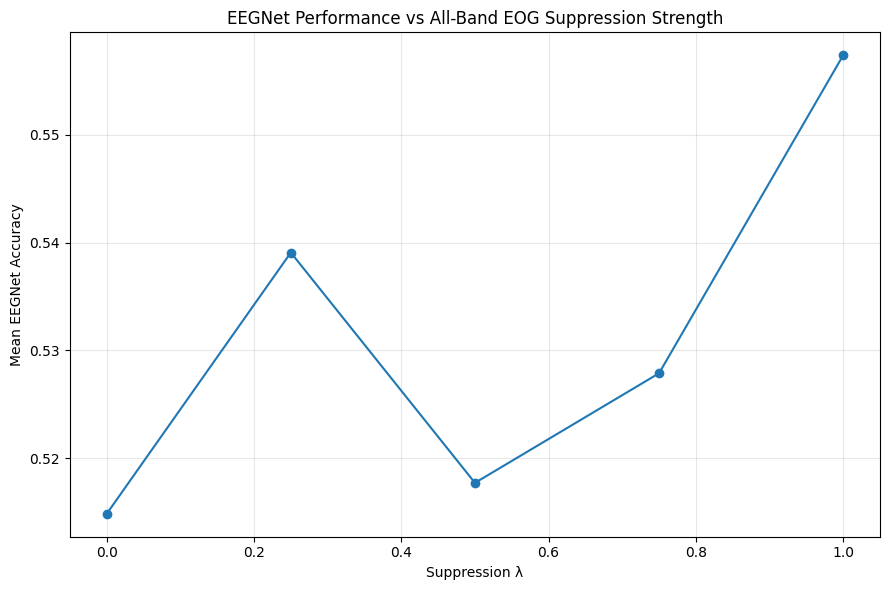

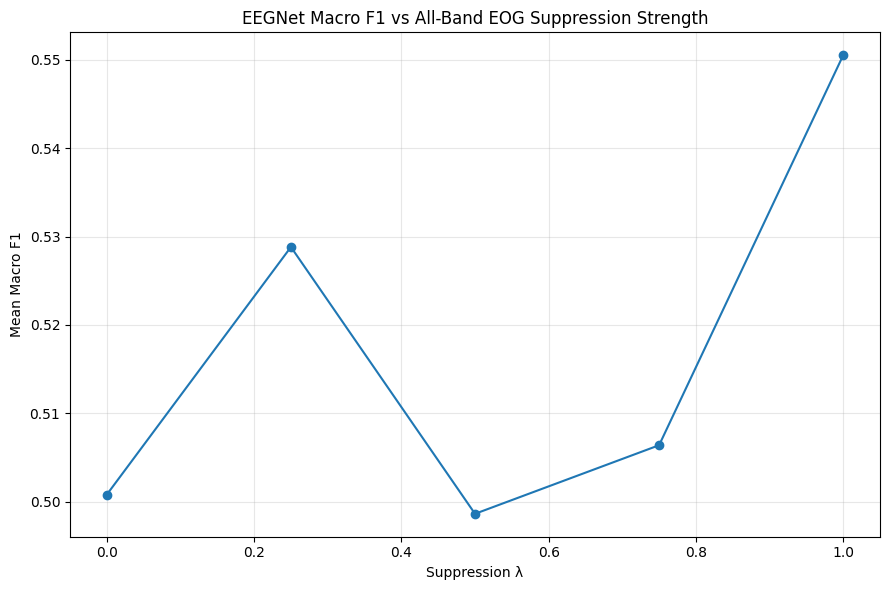



ALL-BAND EOG SUPPRESSION-STRENGTH EXPERIMENT COMPLETE

Lambda values tested:
[0.0, 0.25, 0.5, 0.75, 1.0]

Mean performance:
 Lambda  Mean_Accuracy  Mean_Macro_F1
   0.00        0.51485        0.50081
   0.25        0.53908        0.52882
   0.50        0.51771        0.49863
   0.75        0.52788        0.50639
   1.00        0.55738        0.55051

Best mean Accuracy lambda: 1.0
Best mean Accuracy: 0.5573841211039682

Best mean F1 lambda: 1.0
Best mean F1: 0.5505120908120602

Files saved:
/content/drive/MyDrive/BCC/results/eegnet_allband_lambda_performance.csv
/content/drive/MyDrive/BCC/results/eegnet_allband_lambda_predictions.csv
/content/drive/MyDrive/BCC/results/eegnet_allband_lambda_coefficients.csv
/content/drive/MyDrive/BCC/results/subject_best_allband_lambda.csv
/content/drive/MyDrive/BCC/results/allband_lambda_vs_raw_statistics.csv
/content/drive/MyDrive/BCC/results/subject_allband_suppression_profiles.csv
/content/drive/MyDrive/BCC/images/eegnet_accuracy_vs_lambda.png
/co

In [ ]:
import os
import time
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from scipy.io import loadmat
from numpy.linalg import lstsq

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

import mne

RESULTS_DIR = (
    RESULTS_DIR
)

DATASET_DIR = (
    DATASET_DIR
)

IMAGES_DIR = (
    FIGURES_DIR
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    IMAGES_DIR,
    exist_ok=True
)

SEED = 42

def set_seed(seed=SEED):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

set_seed()

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Using device:",
    device
)

FS_RAW = 250
FS_MODEL = 125

N_EEG = 22
N_EOG = 3

BATCH_SIZE = 16

MAX_EPOCHS = 200
LEARNING_RATE = 0.001

SUBJECTS = [
    f"A{i:02d}"
    for i in range(1, 10)
]

LAMBDA_VALUES = [
    0.00,
    0.25,
    0.50,
    0.75,
    1.00
]

class EEGNet(nn.Module):

    def __init__(
        self,
        num_channels=22,
        num_classes=4,
        samples=500,
        F1=16,
        D=2,
        F2=32,
        dropout=0.5,
        kern_length=64
    ):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(
                1,
                F1,
                (1, kern_length),
                padding=(
                    0,
                    kern_length // 2
                ),
                bias=False
            ),

            nn.BatchNorm2d(
                F1
            ),

            nn.Conv2d(
                F1,
                F1 * D,
                (num_channels, 1),
                groups=F1,
                bias=False
            ),

            nn.BatchNorm2d(
                F1 * D
            ),

            nn.ELU(),

            nn.AvgPool2d(
                (1, 8)
            ),

            nn.Dropout(
                dropout
            )
        )

        self.block2 = nn.Sequential(

            nn.Conv2d(
                F1 * D,
                F2,
                (1, 16),
                padding=(
                    0,
                    8
                ),
                bias=False
            ),

            nn.BatchNorm2d(
                F2
            ),

            nn.ELU(),

            nn.AvgPool2d(
                (1, 8)
            ),

            nn.Dropout(
                dropout
            )
        )

        self._flatten_size = (
            self._get_flatten_size(
                num_channels,
                samples,
                F1,
                D,
                F2,
                kern_length
            )
        )

        self.fc = nn.Linear(
            self._flatten_size,
            num_classes
        )

    def _get_flatten_size(
        self,
        C,
        T,
        F1,
        D,
        F2,
        kern_length
    ):

        x = torch.zeros(
            1,
            1,
            C,
            T
        )

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        return x.flatten(
            1
        ).shape[1]

    def forward(
        self,
        x
    ):

        x = x.permute(
            0,
            2,
            1
        ).unsqueeze(
            1
        )

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        x = x.flatten(
            1
        )

        return self.fc(
            x
        )

def load_bci2a_with_eog(
    mat_path
):

    mat = loadmat(
        mat_path,
        squeeze_me=False
    )

    data = mat[
        "data"
    ]

    eeg_trials = []
    eog_trials = []
    labels = []
    metadata = []

    for run_idx in range(
        data.shape[1]
    ):

        run = data[
            0,
            run_idx
        ][
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trials = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        if trials.shape[0] == 0:

            continue

        for t_idx in range(
            trials.shape[0]
        ):

            if artifacts[
                t_idx,
                0
            ] == 1:

                continue

            onset = int(
                trials[
                    t_idx,
                    0
                ]
            )

            start = onset

            end = (
                onset
                +
                4 * FS_RAW
            )

            if end > X_raw.shape[0]:

                continue

            eeg = X_raw[
                start:end,
                :N_EEG
            ]

            eog = X_raw[
                start:end,
                N_EEG:N_EEG + N_EOG
            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            label = int(
                y[
                    t_idx,
                    0
                ]
            ) - 1

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    t_idx + 1,

                "Onset":
                    onset,

                "True_Class":
                    label + 1

            })

    return (

        np.asarray(
            eeg_trials
        ),

        np.asarray(
            eog_trials
        ),

        np.asarray(
            labels
        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_band(
    X,
    low,
    high
):

    """
    X:
        trials × samples × channels

    Returns:
        trials × samples × channels
    """

    X_t = X.transpose(
        0,
        2,
        1
    )

    filtered = mne.filter.filter_data(

        X_t.reshape(
            -1,
            X_t.shape[-1]
        ),

        sfreq=FS_MODEL,

        l_freq=low,

        h_freq=high,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(
        X_t.shape
    )

    return filtered.transpose(
        0,
        2,
        1
    )

def filter_classifier_band(
    X
):

    return filter_band(
        X,
        4.0,
        38.0
    )

def fit_eog_regression(
    eeg_band,
    eog_band
):

    """
    EEG_channel =
        beta1 * EOG_left
      + beta2 * EOG_central
      + beta3 * EOG_right
      + intercept

    ONLY training data should be supplied.
    """

    eeg_flat = eeg_band.reshape(
        -1,
        N_EEG
    )

    eog_flat = eog_band.reshape(
        -1,
        N_EOG
    )

    X = np.column_stack([
        eog_flat,

        np.ones(
            len(eog_flat)
        )
    ])

    beta = np.zeros(
        (
            N_EEG,
            N_EOG
        ),
        dtype=np.float64
    )

    intercept = np.zeros(
        N_EEG,
        dtype=np.float64
    )

    for ch in range(
        N_EEG
    ):

        coeffs, _, _, _ = lstsq(
            X,
            eeg_flat[
                :,
                ch
            ],
            rcond=None
        )

        beta[
            ch,
            :
        ] = coeffs[
            :N_EOG
        ]

        intercept[
            ch
        ] = coeffs[
            N_EOG
        ]

    return (
        beta,
        intercept
    )

def estimate_eog_component(
    eog,
    beta,
    intercept
):

    component = np.einsum(
        "tsc,nc->tsn",
        eog,
        beta
    )

    component += (
        intercept.reshape(
            1,
            1,
            -1
        )
    )

    return component

def apply_lambda(
    eeg,
    eog,
    beta,
    intercept,
    lambda_value
):

    """
    EEG_lambda =
        EEG - lambda * estimated_EOG_component
    """

    component = (
        estimate_eog_component(
            eog,
            beta,
            intercept
        )
    )

    cleaned = (
        eeg
        -
        lambda_value
        *
        component
    )

    return cleaned

def make_loader(
    X,
    y,
    shuffle,
    drop_last
):

    return DataLoader(

        TensorDataset(

            torch.tensor(
                X,
                dtype=torch.float32
            ),

            torch.tensor(
                y,
                dtype=torch.long
            )

        ),

        batch_size=BATCH_SIZE,

        shuffle=shuffle,

        drop_last=drop_last
    )

def train_eegnet(
    X_train,
    y_train,
    X_val,
    y_val,
    seed
):

    set_seed(
        seed
    )

    train_loader = make_loader(
        X_train,
        y_train,
        shuffle=True,
        drop_last=True
    )

    val_loader = make_loader(
        X_val,
        y_val,
        shuffle=False,
        drop_last=False
    )

    model = EEGNet(
        num_channels=22,
        num_classes=4,
        samples=X_train.shape[1],
        F1=16,
        D=2,
        F2=32,
        dropout=0.5,
        kern_length=64
    ).to(
        device
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

    criterion = (
        nn.CrossEntropyLoss()
    )

    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=MAX_EPOCHS,
            eta_min=1e-5
        )
    )

    best_val_acc = 0.0

    best_state = None

    patience = 50

    patience_counter = 0

    for epoch in range(
        MAX_EPOCHS
    ):

        model.train()

        train_correct = 0

        train_total = 0

        for (
            X_batch,
            y_batch
        ) in train_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            outputs = model(
                X_batch
            )

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            preds = outputs.argmax(
                dim=1
            )

            train_correct += (
                preds == y_batch
            ).sum().item()

            train_total += (
                y_batch.size(0)
            )

        train_acc = (
            train_correct
            /
            train_total
        )

        model.eval()

        val_correct = 0

        val_total = 0

        with torch.no_grad():

            for (
                X_batch,
                y_batch
            ) in val_loader:

                X_batch = X_batch.to(
                    device
                )

                y_batch = y_batch.to(
                    device
                )

                outputs = model(
                    X_batch
                )

                preds = outputs.argmax(
                    dim=1
                )

                val_correct += (
                    preds == y_batch
                ).sum().item()

                val_total += (
                    y_batch.size(0)
                )

        val_acc = (
            val_correct
            /
            val_total
        )

        scheduler.step()

        if (
            val_acc
            >
            best_val_acc
            +
            0.0001
        ):

            best_val_acc = (
                val_acc
            )

            best_state = {

                key:
                    value.detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()

            }

            patience_counter = 0

        else:

            patience_counter += 1

            if (
                patience_counter
                >=
                patience
            ):

                break

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    return (
        model,
        best_val_acc
    )

def evaluate_eegnet(
    model,
    X_test,
    y_test,
    metadata,
    subject,
    lambda_value
):

    model.eval()

    test_loader = make_loader(
        X_test,
        y_test,
        shuffle=False,
        drop_last=False
    )

    preds = []

    labels = []

    start = time.time()

    with torch.no_grad():

        for (
            X_batch,
            y_batch
        ) in test_loader:

            X_batch = X_batch.to(
                device
            )

            outputs = model(
                X_batch
            )

            batch_preds = (
                outputs
                .argmax(
                    dim=1
                )
                .cpu()
                .numpy()
            )

            batch_labels = (
                y_batch
                .cpu()
                .numpy()
            )

            preds.extend(
                batch_preds
            )

            labels.extend(
                batch_labels
            )

    inference_ms = (
        time.time() - start
    ) * 1000

    preds = np.asarray(
        preds
    )

    labels = np.asarray(
        labels
    )

    accuracy = accuracy_score(
        labels,
        preds
    )

    macro_f1 = f1_score(
        labels,
        preds,
        average="macro"
    )

    pred_df = metadata.copy()

    pred_df["Subject"] = (
        subject
    )

    pred_df["Model"] = (
        "EEGNet"
    )

    pred_df["Lambda"] = (
        lambda_value
    )

    pred_df[
        "Predicted_Class"
    ] = (
        preds + 1
    )

    pred_df["Correct"] = (
        pred_df[
            "True_Class"
        ]
        ==
        pred_df[
            "Predicted_Class"
        ]
    ).astype(int)

    return (
        pred_df,
        accuracy,
        macro_f1,
        inference_ms
    )

all_performance = []

all_predictions = []

all_coefficients = []

for subject_idx, subject in enumerate(
    SUBJECTS
):

    print("\n")
    print(
        "=" * 90
    )

    print(
        f"SUBJECT {subject}"
    )

    print(
        "=" * 90
    )

    train_path = os.path.join(
        DATASET_DIR,
        f"{subject}T.mat"
    )

    test_path = os.path.join(
        DATASET_DIR,
        f"{subject}E.mat"
    )

    (
        eeg_t,
        eog_t,
        y_t,
        meta_t
    ) = load_bci2a_with_eog(
        train_path
    )

    (
        eeg_e,
        eog_e,
        y_e,
        meta_e
    ) = load_bci2a_with_eog(
        test_path
    )

    print(
        f"T trials: {len(eeg_t)}"
    )

    print(
        f"E trials: {len(eeg_e)}"
    )

    print(
        "\nFiltering 4–38 Hz EEG..."
    )

    eeg_t_full = (
        filter_classifier_band(
            eeg_t
        )
    )

    eeg_e_full = (
        filter_classifier_band(
            eeg_e
        )
    )

    print(
        "Filtering 4–38 Hz EOG..."
    )

    eog_t_full = (
        filter_classifier_band(
            eog_t
        )
    )

    eog_e_full = (
        filter_classifier_band(
            eog_e
        )
    )

    indices = np.arange(
        len(y_t)
    )

    (
        train_idx,
        val_idx
    ) = train_test_split(

        indices,

        test_size=0.2,

        stratify=y_t,

        random_state=42

    )

    y_train = y_t[
        train_idx
    ]

    y_val = y_t[
        val_idx
    ]

    print(
        "\nTraining samples:",
        len(train_idx)
    )

    print(
        "Validation samples:",
        len(val_idx)
    )

    print(
        "\nFitting all-band EOG regression..."
    )

    beta_all, intercept_all = (
        fit_eog_regression(
            eeg_t_full[
                train_idx
            ],
            eog_t_full[
                train_idx
            ]
        )
    )

    for ch in range(
        N_EEG
    ):

        all_coefficients.append({

            "Subject":
                subject,

            "EEG_Channel_Index":
                ch,

            "Band":
                "4-38Hz",

            "EOG_Left_Beta":
                beta_all[
                    ch,
                    0
                ],

            "EOG_Central_Beta":
                beta_all[
                    ch,
                    1
                ],

            "EOG_Right_Beta":
                beta_all[
                    ch,
                    2
                ],

            "Intercept":
                intercept_all[
                    ch
                ]

        })

    print(
        "Estimating EOG component..."
    )

    component_t = (
        estimate_eog_component(
            eog_t_full,
            beta_all,
            intercept_all
        )
    )

    component_e = (
        estimate_eog_component(
            eog_e_full,
            beta_all,
            intercept_all
        )
    )

    for lambda_idx, lambda_value in enumerate(
        LAMBDA_VALUES
    ):

        print("\n")
        print(
            "-" * 80
        )

        print(
            f"Lambda = {lambda_value:.2f}"
        )

        print(
            "-" * 80
        )

        eeg_t_lambda = (
            eeg_t_full
            -
            lambda_value
            *
            component_t
        )

        eeg_e_lambda = (
            eeg_e_full
            -
            lambda_value
            *
            component_e
        )

        lambda_mean = (
            eeg_t_lambda[
                train_idx
            ]
            .mean(
                axis=(0, 1),
                keepdims=True
            )
        )

        lambda_std = (
            eeg_t_lambda[
                train_idx
            ]
            .std(
                axis=(0, 1),
                keepdims=True
            )
        )

        X_lambda = (
            eeg_t_lambda
            -
            lambda_mean
        ) / (
            lambda_std
            +
            1e-8
        )

        X_lambda_test = (
            eeg_e_lambda
            -
            lambda_mean
        ) / (
            lambda_std
            +
            1e-8
        )

        X_train_lambda = (
            X_lambda[
                train_idx
            ]
        )

        X_val_lambda = (
            X_lambda[
                val_idx
            ]
        )

        model_seed = (
            SEED
            +
            subject_idx * 1000
            +
            lambda_idx
        )

        (
            model,
            best_val
        ) = train_eegnet(

            X_train_lambda,

            y_train,

            X_val_lambda,

            y_val,

            seed=model_seed

        )

        (
            pred_df,
            accuracy,
            macro_f1,
            inference_ms
        ) = evaluate_eegnet(

            model,

            X_lambda_test,

            y_e,

            meta_e,

            subject,

            lambda_value

        )

        all_predictions.append(
            pred_df
        )

        all_performance.append({

            "Subject":
                subject,

            "Lambda":
                lambda_value,

            "Accuracy":
                accuracy,

            "Macro_F1":
                macro_f1,

            "Best_Validation_Accuracy":
                best_val,

            "Inference_ms":
                inference_ms,

            "Training_Trials":
                len(train_idx),

            "Validation_Trials":
                len(val_idx),

            "Test_Trials":
                len(y_e)

        })

        print(
            f"Lambda {lambda_value:.2f}"
            f" | Accuracy: {accuracy:.4f}"
            f" | F1: {macro_f1:.4f}"
            f" | Best Val: {best_val:.4f}"
        )

performance_df = pd.DataFrame(
    all_performance
)

print("\n")
print(
    "=" * 100
)

print(
    "LAMBDA SUPPRESSION RESULTS"
)

print(
    "=" * 100
)

print(
    performance_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}"
    )
)

accuracy_table = (
    performance_df
    .pivot(
        index="Subject",
        columns="Lambda",
        values="Accuracy"
    )
)

print("\n")
print(
    "=" * 100
)

print(
    "ACCURACY BY SUBJECT AND LAMBDA"
)

print(
    "=" * 100
)

print(
    accuracy_table.round(4)
)

f1_table = (
    performance_df
    .pivot(
        index="Subject",
        columns="Lambda",
        values="Macro_F1"
    )
)

print("\n")
print(
    "=" * 100
)

print(
    "MACRO F1 BY SUBJECT AND LAMBDA"
)

print(
    "=" * 100
)

print(
    f1_table.round(4)
)

best_lambda_rows = []

for subject in SUBJECTS:

    subject_perf = performance_df[
        performance_df[
            "Subject"
        ]
        ==
        subject
    ].copy()

    best_accuracy_idx = (
        subject_perf[
            "Accuracy"
        ].idxmax()
    )

    best_accuracy_row = (
        subject_perf.loc[
            best_accuracy_idx
        ]
    )

    best_f1_idx = (
        subject_perf[
            "Macro_F1"
        ].idxmax()
    )

    best_f1_row = (
        subject_perf.loc[
            best_f1_idx
        ]
    )

    best_lambda_rows.append({

        "Subject":
            subject,

        "Best_Lambda_Accuracy":
            best_accuracy_row[
                "Lambda"
            ],

        "Best_Test_Accuracy":
            best_accuracy_row[
                "Accuracy"
            ],

        "Best_Lambda_F1":
            best_f1_row[
                "Lambda"
            ],

        "Best_Test_F1":
            best_f1_row[
                "Macro_F1"
            ]

    })

best_lambda_df = pd.DataFrame(
    best_lambda_rows
)

print("\n")
print(
    "=" * 100
)

print(
    "BEST LAMBDA PER SUBJECT"
)

print(
    "=" * 100
)

print(
    best_lambda_df.round(4).to_string(
        index=False
    )
)

mean_lambda_performance = (
    performance_df
    .groupby(
        "Lambda"
    )[
        [
            "Accuracy",
            "Macro_F1"
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std"
        ]
    )
)

print("\n")
print(
    "=" * 100
)

print(
    "MEAN PERFORMANCE BY LAMBDA"
)

print(
    "=" * 100
)

print(
    mean_lambda_performance.round(5)
)

raw_reference = (
    performance_df[
        performance_df[
            "Lambda"
        ]
        ==
        0.00
    ][
        [
            "Subject",
            "Accuracy",
            "Macro_F1"
        ]
    ]
    .rename(
        columns={

            "Accuracy":
                "Raw_Accuracy",

            "Macro_F1":
                "Raw_F1"

        }
    )
)

lambda_comparison = (
    performance_df
    .merge(
        raw_reference,
        on="Subject",
        how="left"
    )
)

lambda_comparison[
    "Accuracy_Change"
] = (
    lambda_comparison[
        "Accuracy"
    ]
    -
    lambda_comparison[
        "Raw_Accuracy"
    ]
)

lambda_comparison[
    "F1_Change"
] = (
    lambda_comparison[
        "Macro_F1"
    ]
    -
    lambda_comparison[
        "Raw_F1"
    ]
)

lambda_nonraw = (
    lambda_comparison[
        lambda_comparison[
            "Lambda"
        ]
        !=
        0.00
    ]
)

print("\n")
print(
    "=" * 100
)

print(
    "IMPROVEMENT OVER RAW"
)

print(
    "=" * 100
)

print(
    lambda_nonraw[
        [
            "Subject",
            "Lambda",
            "Accuracy_Change",
            "F1_Change"
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:+.4f}"
    )
)

from scipy.stats import (
    wilcoxon,
    ttest_rel
)

lambda_statistics = []

for lambda_value in LAMBDA_VALUES:

    if lambda_value == 0.00:

        continue

    clean_rows = (
        performance_df[
            performance_df[
                "Lambda"
            ]
            ==
            lambda_value
        ]
        .set_index(
            "Subject"
        )
        .reindex(
            SUBJECTS
        )
    )

    raw_rows = (
        performance_df[
            performance_df[
                "Lambda"
            ]
            ==
            0.00
        ]
        .set_index(
            "Subject"
        )
        .reindex(
            SUBJECTS
        )
    )

    accuracy_clean = (
        clean_rows[
            "Accuracy"
        ].to_numpy()
    )

    accuracy_raw = (
        raw_rows[
            "Accuracy"
        ].to_numpy()
    )

    f1_clean = (
        clean_rows[
            "Macro_F1"
        ].to_numpy()
    )

    f1_raw = (
        raw_rows[
            "Macro_F1"
        ].to_numpy()
    )

    accuracy_difference = (
        accuracy_clean
        -
        accuracy_raw
    )

    f1_difference = (
        f1_clean
        -
        f1_raw
    )

    try:

        (
            accuracy_w,
            accuracy_p
        ) = wilcoxon(
            accuracy_difference
        )

    except Exception:

        accuracy_w = np.nan
        accuracy_p = np.nan

    try:

        (
            f1_w,
            f1_p
        ) = wilcoxon(
            f1_difference
        )

    except Exception:

        f1_w = np.nan
        f1_p = np.nan

    try:

        (
            accuracy_t,
            accuracy_t_p
        ) = ttest_rel(
            accuracy_clean,
            accuracy_raw
        )

    except Exception:

        accuracy_t = np.nan
        accuracy_t_p = np.nan

    try:

        (
            f1_t,
            f1_t_p
        ) = ttest_rel(
            f1_clean,
            f1_raw
        )

    except Exception:

        f1_t = np.nan
        f1_t_p = np.nan

    accuracy_sd = np.std(
        accuracy_difference,
        ddof=1
    )

    f1_sd = np.std(
        f1_difference,
        ddof=1
    )

    accuracy_d = (
        accuracy_difference.mean()
        /
        accuracy_sd
        if accuracy_sd > 0
        else np.nan
    )

    f1_d = (
        f1_difference.mean()
        /
        f1_sd
        if f1_sd > 0
        else np.nan
    )

    lambda_statistics.append({

        "Lambda":
            lambda_value,

        "Accuracy_Mean_Change":
            accuracy_difference.mean(),

        "Accuracy_Median_Change":
            np.median(
                accuracy_difference
            ),

        "Accuracy_Improved_Subjects":
            int(
                (
                    accuracy_difference
                    > 0
                ).sum()
            ),

        "Accuracy_Harmed_Subjects":
            int(
                (
                    accuracy_difference
                    < 0
                ).sum()
            ),

        "Accuracy_Wilcoxon_p":
            accuracy_p,

        "Accuracy_Paired_t_p":
            accuracy_t_p,

        "Accuracy_Cohens_d":
            accuracy_d,

        "F1_Mean_Change":
            f1_difference.mean(),

        "F1_Median_Change":
            np.median(
                f1_difference
            ),

        "F1_Improved_Subjects":
            int(
                (
                    f1_difference
                    > 0
                ).sum()
            ),

        "F1_Harmed_Subjects":
            int(
                (
                    f1_difference
                    < 0
                ).sum()
            ),

        "F1_Wilcoxon_p":
            f1_p,

        "F1_Paired_t_p":
            f1_t_p,

        "F1_Cohens_d":
            f1_d

    })

lambda_statistics_df = pd.DataFrame(
    lambda_statistics
)

from statsmodels.stats.multitest import (
    multipletests
)

valid_accuracy = (
    lambda_statistics_df[
        "Accuracy_Wilcoxon_p"
    ].notna()
)

if valid_accuracy.sum() > 0:

    corrected_accuracy = (
        multipletests(
            lambda_statistics_df.loc[
                valid_accuracy,
                "Accuracy_Wilcoxon_p"
            ],
            method="holm"
        )[1]
    )

    lambda_statistics_df.loc[
        valid_accuracy,
        "Accuracy_Wilcoxon_p_Holm"
    ] = corrected_accuracy

valid_f1 = (
    lambda_statistics_df[
        "F1_Wilcoxon_p"
    ].notna()
)

if valid_f1.sum() > 0:

    corrected_f1 = (
        multipletests(
            lambda_statistics_df.loc[
                valid_f1,
                "F1_Wilcoxon_p"
            ],
            method="holm"
        )[1]
    )

    lambda_statistics_df.loc[
        valid_f1,
        "F1_Wilcoxon_p_Holm"
    ] = corrected_f1

print("\n")
print(
    "=" * 120
)

print(
    "STATISTICAL COMPARISON: EACH LAMBDA vs RAW"
)

print(
    "=" * 120
)

print(
    lambda_statistics_df.round(5).to_string(
        index=False
    )
)

subject_lambda_profile = []

for subject in SUBJECTS:

    temp = performance_df[
        performance_df[
            "Subject"
        ]
        ==
        subject
    ].copy()

    best_idx = temp[
        "Accuracy"
    ].idxmax()

    best_row = temp.loc[
        best_idx
    ]

    raw_accuracy = temp[
        temp["Lambda"] == 0.00
    ]["Accuracy"].iloc[0]

    raw_f1 = temp[
        temp["Lambda"] == 0.00
    ]["Macro_F1"].iloc[0]

    best_accuracy = best_row[
        "Accuracy"
    ]

    best_f1_row = temp.loc[
        temp[
            "Macro_F1"
        ].idxmax()
    ]

    subject_lambda_profile.append({

        "Subject":
            subject,

        "Best_Accuracy_Lambda":
            best_row[
                "Lambda"
            ],

        "Best_Accuracy":
            best_accuracy,

        "Accuracy_Gain_vs_Raw":
            best_accuracy
            -
            raw_accuracy,

        "Best_F1_Lambda":
            best_f1_row[
                "Lambda"
            ],

        "Best_F1":
            best_f1_row[
                "Macro_F1"
            ],

        "F1_Gain_vs_Raw":
            best_f1_row[
                "Macro_F1"
            ]
            -
            raw_f1

    })

subject_lambda_profile_df = (
    pd.DataFrame(
        subject_lambda_profile
    )
)

print("\n")
print(
    "=" * 100
)

print(
    "SUBJECT-SPECIFIC SUPPRESSION PROFILE"
)

print(
    "=" * 100
)

print(
    subject_lambda_profile_df.round(5).to_string(
        index=False
    )
)

performance_path = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_performance.csv"
)

performance_df.to_csv(
    performance_path,
    index=False
)

prediction_df = pd.concat(
    all_predictions,
    ignore_index=True
)

prediction_path = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

coefficients_df = pd.DataFrame(
    all_coefficients
)

coefficient_path = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_coefficients.csv"
)

coefficients_df.to_csv(
    coefficient_path,
    index=False
)

best_lambda_path = os.path.join(
    RESULTS_DIR,
    "subject_best_allband_lambda.csv"
)

best_lambda_df.to_csv(
    best_lambda_path,
    index=False
)

statistics_path = os.path.join(
    RESULTS_DIR,
    "allband_lambda_vs_raw_statistics.csv"
)

lambda_statistics_df.to_csv(
    statistics_path,
    index=False
)

profile_path = os.path.join(
    RESULTS_DIR,
    "subject_allband_suppression_profiles.csv"
)

subject_lambda_profile_df.to_csv(
    profile_path,
    index=False
)

mean_accuracy_by_lambda = (
    performance_df
    .groupby(
        "Lambda"
    )[
        "Accuracy"
    ]
    .mean()
    .reindex(
        LAMBDA_VALUES
    )
)

mean_f1_by_lambda = (
    performance_df
    .groupby(
        "Lambda"
    )[
        "Macro_F1"
    ]
    .mean()
    .reindex(
        LAMBDA_VALUES
    )
)

print("\n")
print(
    "=" * 100
)

print(
    "MEAN PERFORMANCE CURVE"
)

print(
    "=" * 100
)

curve_df = pd.DataFrame({

    "Lambda":
        LAMBDA_VALUES,

    "Mean_Accuracy":
        mean_accuracy_by_lambda.values,

    "Mean_Macro_F1":
        mean_f1_by_lambda.values

})

print(
    curve_df.round(5).to_string(
        index=False
    )
)

import matplotlib.pyplot as plt

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    curve_df[
        "Lambda"
    ],
    curve_df[
        "Mean_Accuracy"
    ],
    marker="o"
)

plt.xlabel(
    "Suppression λ"
)

plt.ylabel(
    "Mean EEGNet Accuracy"
)

plt.title(
    "EEGNet Performance vs All-Band EOG Suppression Strength"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

accuracy_plot_path = os.path.join(
    IMAGES_DIR,
    "eegnet_accuracy_vs_lambda.png"
)

plt.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    curve_df[
        "Lambda"
    ],
    curve_df[
        "Mean_Macro_F1"
    ],
    marker="o"
)

plt.xlabel(
    "Suppression λ"
)

plt.ylabel(
    "Mean Macro F1"
)

plt.title(
    "EEGNet Macro F1 vs All-Band EOG Suppression Strength"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

f1_plot_path = os.path.join(
    IMAGES_DIR,
    "eegnet_f1_vs_lambda.png"
)

plt.savefig(
    f1_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n")
print(
    "=" * 110
)

print(
    "ALL-BAND EOG SUPPRESSION-STRENGTH EXPERIMENT COMPLETE"
)

print(
    "=" * 110
)

print(
    "\nLambda values tested:"
)

print(
    LAMBDA_VALUES
)

print(
    "\nMean performance:"
)

print(
    curve_df.round(5).to_string(
        index=False
    )
)

best_mean_accuracy_idx = (
    curve_df[
        "Mean_Accuracy"
    ].idxmax()
)

best_mean_f1_idx = (
    curve_df[
        "Mean_Macro_F1"
    ].idxmax()
)

print(
    "\nBest mean Accuracy lambda:",
    curve_df.loc[
        best_mean_accuracy_idx,
        "Lambda"
    ]
)

print(
    "Best mean Accuracy:",
    curve_df.loc[
        best_mean_accuracy_idx,
        "Mean_Accuracy"
    ]
)

print(
    "\nBest mean F1 lambda:",
    curve_df.loc[
        best_mean_f1_idx,
        "Lambda"
    ]
)

print(
    "Best mean F1:",
    curve_df.loc[
        best_mean_f1_idx,
        "Mean_Macro_F1"
    ]
)

print(
    "\nFiles saved:"
)

print(
    performance_path
)

print(
    prediction_path
)

print(
    coefficient_path
)

print(
    best_lambda_path
)

print(
    statistics_path
)

print(
    profile_path
)

print(
    accuracy_plot_path
)

print(
    f1_plot_path
)

print("\n")
print(
    "=" * 110
)

print(
    "DONE"
)

print(
    "=" * 110
)


## Focused λ Comparison: 0.75, 0.875, 1.00

Using device: cuda


PROCESSING A01
T trials: 273
E trials: 281

Filtering EEG 4–38 Hz...
Filtering EOG 4–38 Hz...

Training samples: 218
Validation samples: 55

Fitting all-band EOG regression...
Estimating EOG component...


--------------------------------------------------------------------------------
Lambda = 0.750
--------------------------------------------------------------------------------
Lambda 0.750 | Accuracy: 0.5979 | F1: 0.5872 | Best Val: 0.7273


--------------------------------------------------------------------------------
Lambda = 0.875
--------------------------------------------------------------------------------
Lambda 0.875 | Accuracy: 0.5979 | F1: 0.5898 | Best Val: 0.7273


--------------------------------------------------------------------------------
Lambda = 1.000
--------------------------------------------------------------------------------
Lambda 1.000 | Accuracy: 0.6050 | F1: 0.5891 | Best Val: 0.7273


PROCESSING A02
T trials: 270
E trials: 283



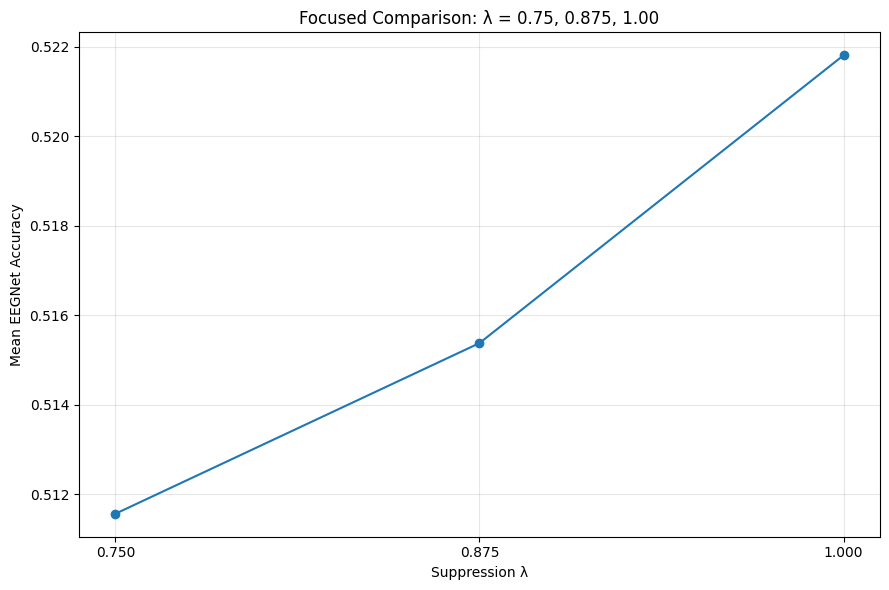

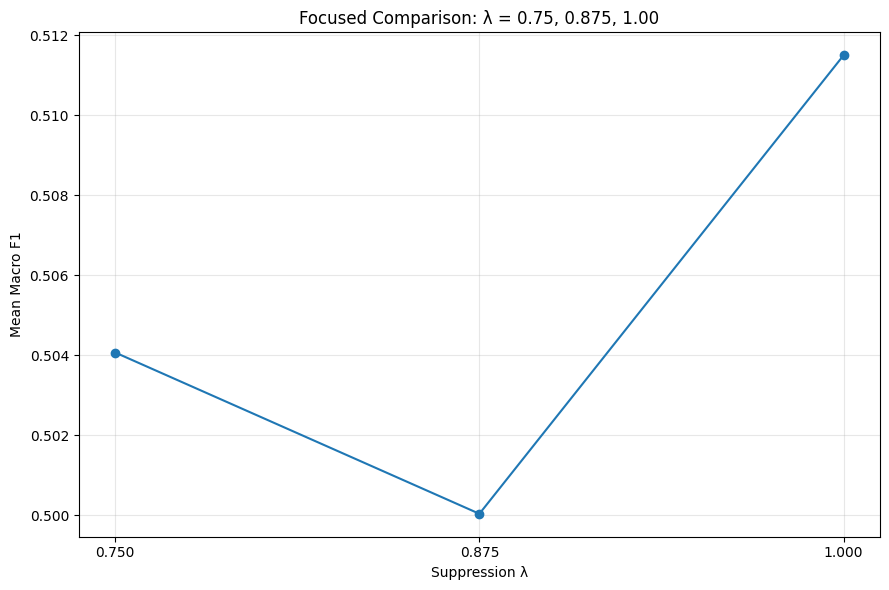



FOCUSED λ EXPERIMENT COMPLETE

Tested λ values:
[0.75, 0.875, 1.0]

Mean performance:
 Lambda  Mean_Accuracy  Mean_Macro_F1
  0.750        0.51156        0.50407
  0.875        0.51537        0.50004
  1.000        0.52181        0.51150

Best global Accuracy λ: 1.0
Best global F1 λ: 1.0

Files saved:
/content/drive/MyDrive/BCC/results/eegnet_focused_lambda_performance.csv
/content/drive/MyDrive/BCC/results/eegnet_focused_lambda_predictions.csv
/content/drive/MyDrive/BCC/results/eegnet_focused_lambda_coefficients.csv
/content/drive/MyDrive/BCC/results/subject_best_focused_lambda.csv
/content/drive/MyDrive/BCC/results/focused_lambda_pairwise_statistics.csv
/content/drive/MyDrive/BCC/results/focused_lambda_performance_curve.csv
/content/drive/MyDrive/BCC/images/eegnet_focused_lambda_accuracy.png
/content/drive/MyDrive/BCC/images/eegnet_focused_lambda_f1.png


DONE


In [ ]:
import os
import time
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from scipy.io import loadmat
from numpy.linalg import lstsq

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

from scipy.stats import (
    wilcoxon,
    ttest_rel
)

from statsmodels.stats.multitest import (
    multipletests
)

import mne
import matplotlib.pyplot as plt

RESULTS_DIR = (
    RESULTS_DIR
)

DATASET_DIR = (
    DATASET_DIR
)

IMAGES_DIR = (
    FIGURES_DIR
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    IMAGES_DIR,
    exist_ok=True
)

SEED = 42

def set_seed(seed=SEED):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Using device:",
    device
)

FS_RAW = 250
FS_MODEL = 125

N_EEG = 22
N_EOG = 3

BATCH_SIZE = 16

MAX_EPOCHS = 200

LEARNING_RATE = 0.001

SUBJECTS = [
    f"A{i:02d}"
    for i in range(1, 10)
]

LAMBDA_VALUES = [
    0.75,
    0.875,
    1.00
]

class EEGNet(nn.Module):

    def __init__(
        self,
        num_channels=22,
        num_classes=4,
        samples=500,
        F1=16,
        D=2,
        F2=32,
        dropout=0.5,
        kern_length=64
    ):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(
                1,
                F1,
                (
                    1,
                    kern_length
                ),
                padding=(
                    0,
                    kern_length // 2
                ),
                bias=False
            ),

            nn.BatchNorm2d(
                F1
            ),

            nn.Conv2d(
                F1,
                F1 * D,
                (
                    num_channels,
                    1
                ),
                groups=F1,
                bias=False
            ),

            nn.BatchNorm2d(
                F1 * D
            ),

            nn.ELU(),

            nn.AvgPool2d(
                (
                    1,
                    8
                )
            ),

            nn.Dropout(
                dropout
            )

        )

        self.block2 = nn.Sequential(

            nn.Conv2d(
                F1 * D,
                F2,
                (
                    1,
                    16
                ),
                padding=(
                    0,
                    8
                ),
                bias=False
            ),

            nn.BatchNorm2d(
                F2
            ),

            nn.ELU(),

            nn.AvgPool2d(
                (
                    1,
                    8
                )
            ),

            nn.Dropout(
                dropout
            )

        )

        self._flatten_size = (
            self._get_flatten_size(
                num_channels,
                samples,
                F1,
                D,
                F2,
                kern_length
            )
        )

        self.fc = nn.Linear(
            self._flatten_size,
            num_classes
        )

    def _get_flatten_size(
        self,
        C,
        T,
        F1,
        D,
        F2,
        kern_length
    ):

        x = torch.zeros(
            1,
            1,
            C,
            T
        )

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        return (
            x.flatten(
                1
            ).shape[1]
        )

    def forward(
        self,
        x
    ):

        x = x.permute(
            0,
            2,
            1
        )

        x = x.unsqueeze(
            1
        )

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        x = x.flatten(
            1
        )

        return self.fc(
            x
        )

def load_bci2a_with_eog(
    mat_path
):

    mat = loadmat(
        mat_path,
        squeeze_me=False
    )

    if "data" not in mat:

        raise ValueError(
            f"'data' not found in {mat_path}"
        )

    data = mat[
        "data"
    ]

    eeg_trials = []
    eog_trials = []

    labels = []

    metadata = []

    for run_idx in range(
        data.shape[1]
    ):

        run_container = data[
            0,
            run_idx
        ]

        run = run_container[
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trials = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for t_idx in range(
            trials.shape[0]
        ):

            artifact_flag = (
                artifacts[
                    t_idx,
                    0
                ]
            )

            if artifact_flag == 1:

                continue

            onset = int(
                trials[
                    t_idx,
                    0
                ]
            )

            start = onset

            end = (
                onset
                +
                4 * FS_RAW
            )

            if end > X_raw.shape[0]:

                continue

            eeg = X_raw[
                start:end,
                :N_EEG
            ]

            eog = X_raw[
                start:end,
                N_EEG:N_EEG + N_EOG
            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            label = int(
                y[
                    t_idx,
                    0
                ]
            ) - 1

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    t_idx + 1,

                "Onset":
                    onset,

                "True_Class":
                    label + 1

            })

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_band(
    X,
    low,
    high
):

    """
    Input:
        trials × samples × channels

    Output:
        trials × samples × channels
    """

    X_transposed = X.transpose(
        0,
        2,
        1
    )

    n_trials = (
        X_transposed.shape[0]
    )

    n_channels = (
        X_transposed.shape[1]
    )

    n_samples = (
        X_transposed.shape[2]
    )

    reshaped = (
        X_transposed
        .reshape(
            -1,
            n_samples
        )
    )

    filtered = (
        mne.filter.filter_data(

            reshaped,

            sfreq=FS_MODEL,

            l_freq=low,

            h_freq=high,

            method="fir",

            verbose=False

        )
    )

    filtered = (
        filtered
        .reshape(
            n_trials,
            n_channels,
            n_samples
        )
    )

    return filtered.transpose(
        0,
        2,
        1
    )

def filter_classifier_band(
    X
):

    return filter_band(
        X,
        4.0,
        38.0
    )

def fit_eog_regression(
    eeg_band,
    eog_band
):

    """
    Fit:

        EEG_channel =
            b1*EOG1
          + b2*EOG2
          + b3*EOG3
          + intercept

    Regression uses ONLY training trials.
    """

    eeg_flat = (
        eeg_band
        .reshape(
            -1,
            N_EEG
        )
    )

    eog_flat = (
        eog_band
        .reshape(
            -1,
            N_EOG
        )
    )

    X = np.column_stack(

        [

            eog_flat,

            np.ones(
                len(
                    eog_flat
                )
            )

        ]

    )

    beta = np.zeros(
        (
            N_EEG,
            N_EOG
        ),
        dtype=np.float64
    )

    intercept = np.zeros(
        N_EEG,
        dtype=np.float64
    )

    for channel in range(
        N_EEG
    ):

        coeffs, _, _, _ = lstsq(

            X,

            eeg_flat[
                :,
                channel
            ],

            rcond=None

        )

        beta[
            channel,
            :
        ] = coeffs[
            :N_EOG
        ]

        intercept[
            channel
        ] = coeffs[
            N_EOG
        ]

    return (
        beta,
        intercept
    )

def estimate_eog_component(
    eog,
    beta,
    intercept
):

    component = np.einsum(
        "tsc,nc->tsn",
        eog,
        beta
    )

    component = (
        component
        +
        intercept.reshape(
            1,
            1,
            -1
        )
    )

    return component

def apply_lambda(
    eeg,
    eog_component,
    lambda_value
):

    return (
        eeg
        -
        lambda_value
        *
        eog_component
    )

def make_loader(
    X,
    y,
    shuffle,
    drop_last
):

    dataset = TensorDataset(

        torch.tensor(
            X,
            dtype=torch.float32
        ),

        torch.tensor(
            y,
            dtype=torch.long
        )

    )

    return DataLoader(

        dataset,

        batch_size=BATCH_SIZE,

        shuffle=shuffle,

        drop_last=drop_last

    )

def train_eegnet(
    X_train,
    y_train,
    X_val,
    y_val,
    seed
):

    set_seed(
        seed
    )

    train_loader = make_loader(
        X_train,
        y_train,
        shuffle=True,
        drop_last=True
    )

    val_loader = make_loader(
        X_val,
        y_val,
        shuffle=False,
        drop_last=False
    )

    model = EEGNet(
        num_channels=22,
        num_classes=4,
        samples=X_train.shape[1],
        F1=16,
        D=2,
        F2=32,
        dropout=0.5,
        kern_length=64
    ).to(
        device
    )

    criterion = (
        nn.CrossEntropyLoss()
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(

            optimizer,

            T_max=MAX_EPOCHS,

            eta_min=1e-5

        )
    )

    best_val_accuracy = 0.0

    best_state = None

    patience = 50

    patience_counter = 0

    for epoch in range(
        MAX_EPOCHS
    ):

        model.train()

        train_correct = 0

        train_total = 0

        for (
            X_batch,
            y_batch
        ) in train_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            outputs = model(
                X_batch
            )

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            preds = (
                outputs
                .argmax(
                    dim=1
                )
            )

            train_correct += (
                preds == y_batch
            ).sum().item()

            train_total += (
                y_batch.size(0)
            )

        model.eval()

        val_correct = 0

        val_total = 0

        with torch.no_grad():

            for (
                X_batch,
                y_batch
            ) in val_loader:

                X_batch = X_batch.to(
                    device
                )

                y_batch = y_batch.to(
                    device
                )

                outputs = model(
                    X_batch
                )

                preds = (
                    outputs
                    .argmax(
                        dim=1
                    )
                )

                val_correct += (
                    preds == y_batch
                ).sum().item()

                val_total += (
                    y_batch.size(0)
                )

        val_accuracy = (
            val_correct
            /
            val_total
        )

        scheduler.step()

        if (
            val_accuracy
            >
            best_val_accuracy
            +
            0.0001
        ):

            best_val_accuracy = (
                val_accuracy
            )

            best_state = {

                key:
                    value.detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()

            }

            patience_counter = 0

        else:

            patience_counter += 1

            if (
                patience_counter
                >=
                patience
            ):

                break

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    return (
        model,
        best_val_accuracy
    )

def evaluate_eegnet(
    model,
    X_test,
    y_test,
    metadata,
    subject,
    lambda_value
):

    model.eval()

    loader = make_loader(
        X_test,
        y_test,
        shuffle=False,
        drop_last=False
    )

    predictions = []

    truths = []

    start_time = time.time()

    with torch.no_grad():

        for (
            X_batch,
            y_batch
        ) in loader:

            X_batch = X_batch.to(
                device
            )

            outputs = model(
                X_batch
            )

            batch_predictions = (
                outputs
                .argmax(
                    dim=1
                )
                .cpu()
                .numpy()
            )

            batch_truth = (
                y_batch
                .cpu()
                .numpy()
            )

            predictions.extend(
                batch_predictions
            )

            truths.extend(
                batch_truth
            )

    inference_ms = (
        time.time()
        -
        start_time
    ) * 1000

    predictions = np.asarray(
        predictions
    )

    truths = np.asarray(
        truths
    )

    accuracy = accuracy_score(
        truths,
        predictions
    )

    macro_f1 = f1_score(
        truths,
        predictions,
        average="macro"
    )

    prediction_df = metadata.copy()

    prediction_df[
        "Subject"
    ] = subject

    prediction_df[
        "Lambda"
    ] = lambda_value

    prediction_df[
        "Predicted_Class"
    ] = (
        predictions
        +
        1
    )

    prediction_df[
        "Correct"
    ] = (
        prediction_df[
            "True_Class"
        ]
        ==
        prediction_df[
            "Predicted_Class"
        ]
    ).astype(int)

    return (
        prediction_df,
        accuracy,
        macro_f1,
        inference_ms
    )

all_performance = []

all_predictions = []

all_coefficients = []

for subject_index, subject in enumerate(
    SUBJECTS
):

    print("\n")

    print(
        "=" * 90
    )

    print(
        f"PROCESSING {subject}"
    )

    print(
        "=" * 90
    )

    train_path = os.path.join(
        DATASET_DIR,
        f"{subject}T.mat"
    )

    test_path = os.path.join(
        DATASET_DIR,
        f"{subject}E.mat"
    )

    (
        eeg_t,
        eog_t,
        y_t,
        meta_t
    ) = load_bci2a_with_eog(
        train_path
    )

    (
        eeg_e,
        eog_e,
        y_e,
        meta_e
    ) = load_bci2a_with_eog(
        test_path
    )

    print(
        "T trials:",
        len(y_t)
    )

    print(
        "E trials:",
        len(y_e)
    )

    print(
        "\nFiltering EEG 4–38 Hz..."
    )

    eeg_t_full = (
        filter_classifier_band(
            eeg_t
        )
    )

    eeg_e_full = (
        filter_classifier_band(
            eeg_e
        )
    )

    print(
        "Filtering EOG 4–38 Hz..."
    )

    eog_t_full = (
        filter_classifier_band(
            eog_t
        )
    )

    eog_e_full = (
        filter_classifier_band(
            eog_e
        )
    )

    indices = np.arange(
        len(y_t)
    )

    (
        train_idx,
        val_idx
    ) = train_test_split(

        indices,

        test_size=0.20,

        stratify=y_t,

        random_state=42

    )

    print(
        "\nTraining samples:",
        len(train_idx)
    )

    print(
        "Validation samples:",
        len(val_idx)
    )

    print(
        "\nFitting all-band EOG regression..."
    )

    (
        beta,
        intercept
    ) = fit_eog_regression(

        eeg_t_full[
            train_idx
        ],

        eog_t_full[
            train_idx
        ]

    )

    for channel in range(
        N_EEG
    ):

        all_coefficients.append({

            "Subject":
                subject,

            "EEG_Channel_Index":
                channel,

            "Band":
                "4-38Hz",

            "EOG_Left_Beta":
                beta[
                    channel,
                    0
                ],

            "EOG_Central_Beta":
                beta[
                    channel,
                    1
                ],

            "EOG_Right_Beta":
                beta[
                    channel,
                    2
                ],

            "Intercept":
                intercept[
                    channel
                ]

        })

    print(
        "Estimating EOG component..."
    )

    eog_component_t = (
        estimate_eog_component(
            eog_t_full,
            beta,
            intercept
        )
    )

    eog_component_e = (
        estimate_eog_component(
            eog_e_full,
            beta,
            intercept
        )
    )

    for lambda_value in LAMBDA_VALUES:

        print("\n")

        print(
            "-" * 80
        )

        print(
            f"Lambda = {lambda_value:.3f}"
        )

        print(
            "-" * 80
        )

        eeg_t_lambda = apply_lambda(

            eeg_t_full,

            eog_component_t,

            lambda_value

        )

        eeg_e_lambda = apply_lambda(

            eeg_e_full,

            eog_component_e,

            lambda_value

        )

        train_mean = (
            eeg_t_lambda[
                train_idx
            ]
            .mean(
                axis=(0, 1),
                keepdims=True
            )
        )

        train_std = (
            eeg_t_lambda[
                train_idx
            ]
            .std(
                axis=(0, 1),
                keepdims=True
            )
        )

        train_std = np.where(
            train_std < 1e-8,
            1.0,
            train_std
        )

        X_all = (
            eeg_t_lambda
            -
            train_mean
        ) / train_std

        X_test = (
            eeg_e_lambda
            -
            train_mean
        ) / train_std

        X_train = (
            X_all[
                train_idx
            ]
        )

        X_val = (
            X_all[
                val_idx
            ]
        )

        model_seed = (
            SEED
            +
            subject_index * 1000
        )

        (
            model,
            best_val_accuracy
        ) = train_eegnet(

            X_train,

            y_t[
                train_idx
            ],

            X_val,

            y_t[
                val_idx
            ],

            seed=model_seed

        )

        (
            prediction_df,
            accuracy,
            macro_f1,
            inference_ms
        ) = evaluate_eegnet(

            model,

            X_test,

            y_e,

            meta_e,

            subject,

            lambda_value

        )

        all_predictions.append(
            prediction_df
        )

        all_performance.append({

            "Subject":
                subject,

            "Lambda":
                lambda_value,

            "Accuracy":
                accuracy,

            "Macro_F1":
                macro_f1,

            "Best_Validation_Accuracy":
                best_val_accuracy,

            "Inference_ms":
                inference_ms,

            "Training_Trials":
                len(train_idx),

            "Validation_Trials":
                len(val_idx),

            "Test_Trials":
                len(y_e)

        })

        print(
            f"Lambda {lambda_value:.3f}"
            f" | Accuracy: {accuracy:.4f}"
            f" | F1: {macro_f1:.4f}"
            f" | Best Val: {best_val_accuracy:.4f}"
        )

performance_df = pd.DataFrame(
    all_performance
)

print("\n")
print(
    "=" * 110
)

print(
    "FOCUSED LAMBDA RESULTS"
)

print(
    "=" * 110
)

print(
    performance_df.round(
        5
    ).to_string(
        index=False
    )
)

accuracy_table = (
    performance_df
    .pivot(
        index="Subject",
        columns="Lambda",
        values="Accuracy"
    )
    .reindex(
        columns=LAMBDA_VALUES
    )
)

print("\n")
print(
    "=" * 110
)

print(
    "ACCURACY BY SUBJECT"
)

print(
    "=" * 110
)

print(
    accuracy_table.round(
        5
    ).to_string()
)

f1_table = (
    performance_df
    .pivot(
        index="Subject",
        columns="Lambda",
        values="Macro_F1"
    )
    .reindex(
        columns=LAMBDA_VALUES
    )
)

print("\n")
print(
    "=" * 110
)

print(
    "MACRO F1 BY SUBJECT"
)

print(
    "=" * 110
)

print(
    f1_table.round(
        5
    ).to_string()
)

best_rows = []

for subject in SUBJECTS:

    temp = performance_df[
        performance_df[
            "Subject"
        ]
        ==
        subject
    ].copy()

    best_accuracy_idx = (
        temp[
            "Accuracy"
        ].idxmax()
    )

    best_f1_idx = (
        temp[
            "Macro_F1"
        ].idxmax()
    )

    best_accuracy_row = (
        temp.loc[
            best_accuracy_idx
        ]
    )

    best_f1_row = (
        temp.loc[
            best_f1_idx
        ]
    )

    best_rows.append({

        "Subject":
            subject,

        "Best_Lambda_Accuracy":
            best_accuracy_row[
                "Lambda"
            ],

        "Best_Accuracy":
            best_accuracy_row[
                "Accuracy"
            ],

        "Best_Lambda_F1":
            best_f1_row[
                "Lambda"
            ],

        "Best_F1":
            best_f1_row[
                "Macro_F1"
            ]

    })

best_lambda_df = pd.DataFrame(
    best_rows
)

print("\n")
print(
    "=" * 110
)

print(
    "BEST λ AMONG 0.75, 0.875 AND 1.00"
)

print(
    "=" * 110
)

print(
    best_lambda_df.round(
        5
    ).to_string(
        index=False
    )
)

mean_lambda_df = (
    performance_df
    .groupby(
        "Lambda"
    )[
        [
            "Accuracy",
            "Macro_F1"
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std"
        ]
    )
)

print("\n")
print(
    "=" * 110
)

print(
    "MEAN PERFORMANCE"
)

print(
    "=" * 110
)

print(
    mean_lambda_df.round(
        5
    )
)

lambda_pairs = [

    (
        0.875,
        0.75
    ),

    (
        1.00,
        0.875
    ),

    (
        1.00,
        0.75
    )

]

pairwise_rows = []

for lambda_a, lambda_b in lambda_pairs:

    a = performance_df[
        performance_df[
            "Lambda"
        ]
        ==
        lambda_a
    ].set_index(
        "Subject"
    ).reindex(
        SUBJECTS
    )

    b = performance_df[
        performance_df[
            "Lambda"
        ]
        ==
        lambda_b
    ].set_index(
        "Subject"
    ).reindex(
        SUBJECTS
    )

    accuracy_difference = (
        a[
            "Accuracy"
        ].to_numpy()
        -
        b[
            "Accuracy"
        ].to_numpy()
    )

    f1_difference = (
        a[
            "Macro_F1"
        ].to_numpy()
        -
        b[
            "Macro_F1"
        ].to_numpy()
    )

    try:

        (
            acc_w,
            acc_p
        ) = wilcoxon(
            accuracy_difference
        )

    except Exception:

        acc_w = np.nan
        acc_p = np.nan

    try:

        (
            f1_w,
            f1_p
        ) = wilcoxon(
            f1_difference
        )

    except Exception:

        f1_w = np.nan
        f1_p = np.nan

    (
        acc_t,
        acc_t_p
    ) = ttest_rel(

        a[
            "Accuracy"
        ],

        b[
            "Accuracy"
        ]

    )

    (
        f1_t,
        f1_t_p
    ) = ttest_rel(

        a[
            "Macro_F1"
        ],

        b[
            "Macro_F1"
        ]

    )

    acc_sd = np.std(
        accuracy_difference,
        ddof=1
    )

    f1_sd = np.std(
        f1_difference,
        ddof=1
    )

    acc_d = (
        accuracy_difference.mean()
        /
        acc_sd
        if acc_sd > 0
        else np.nan
    )

    f1_d = (
        f1_difference.mean()
        /
        f1_sd
        if f1_sd > 0
        else np.nan
    )

    pairwise_rows.append({

        "Comparison":
            f"λ={lambda_a:.3f} vs λ={lambda_b:.3f}",

        "Accuracy_Mean_Difference":
            accuracy_difference.mean(),

        "Accuracy_Median_Difference":
            np.median(
                accuracy_difference
            ),

        "Accuracy_Improved_Subjects":
            int(
                (
                    accuracy_difference
                    >
                    0
                ).sum()
            ),

        "Accuracy_Harmed_Subjects":
            int(
                (
                    accuracy_difference
                    <
                    0
                ).sum()
            ),

        "Accuracy_Wilcoxon_p":
            acc_p,

        "Accuracy_Paired_t_p":
            acc_t_p,

        "Accuracy_Cohens_d":
            acc_d,

        "F1_Mean_Difference":
            f1_difference.mean(),

        "F1_Median_Difference":
            np.median(
                f1_difference
            ),

        "F1_Improved_Subjects":
            int(
                (
                    f1_difference
                    >
                    0
                ).sum()
            ),

        "F1_Harmed_Subjects":
            int(
                (
                    f1_difference
                    <
                    0
                ).sum()
            ),

        "F1_Wilcoxon_p":
            f1_p,

        "F1_Paired_t_p":
            f1_t_p,

        "F1_Cohens_d":
            f1_d

    })

pairwise_df = pd.DataFrame(
    pairwise_rows
)

for p_column in [
    "Accuracy_Wilcoxon_p",
    "F1_Wilcoxon_p"
]:

    valid = (
        pairwise_df[
            p_column
        ]
        .notna()
    )

    if valid.sum() > 0:

        corrected = (
            multipletests(

                pairwise_df.loc[
                    valid,
                    p_column
                ],

                method="holm"

            )[1]
        )

        pairwise_df.loc[
            valid,
            p_column + "_Holm"
        ] = corrected

print("\n")
print(
    "=" * 120
)

print(
    "PAIRWISE λ COMPARISONS"
)

print(
    "=" * 120
)

print(
    pairwise_df.round(
        5
    ).to_string(
        index=False
    )
)

best_mean_accuracy_lambda = (
    mean_lambda_df[
        "Accuracy"
    ][
        "mean"
    ].idxmax()
)

best_mean_f1_lambda = (
    mean_lambda_df[
        "Macro_F1"
    ][
        "mean"
    ].idxmax()
)

print("\n")
print(
    "=" * 110
)

print(
    "BEST GLOBAL λ"
)

print(
    "=" * 110
)

print(
    "Best mean Accuracy λ:",
    best_mean_accuracy_lambda
)

print(
    "Best mean Accuracy:",
    mean_lambda_df.loc[
        best_mean_accuracy_lambda,
        (
            "Accuracy",
            "mean"
        )
    ]
)

print(
    "\nBest mean F1 λ:",
    best_mean_f1_lambda
)

print(
    "Best mean F1:",
    mean_lambda_df.loc[
        best_mean_f1_lambda,
        (
            "Macro_F1",
            "mean"
        )
    ]
)

curve_df = pd.DataFrame({

    "Lambda":
        LAMBDA_VALUES,

    "Mean_Accuracy":
        [
            mean_lambda_df.loc[
                value,
                (
                    "Accuracy",
                    "mean"
                )
            ]

            for value in LAMBDA_VALUES
        ],

    "Mean_Macro_F1":
        [
            mean_lambda_df.loc[
                value,
                (
                    "Macro_F1",
                    "mean"
                )
            ]

            for value in LAMBDA_VALUES
        ]

})

print("\n")
print(
    "=" * 110
)

print(
    "FOCUSED PERFORMANCE CURVE"
)

print(
    "=" * 110
)

print(
    curve_df.round(
        5
    ).to_string(
        index=False
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    curve_df[
        "Lambda"
    ],
    curve_df[
        "Mean_Accuracy"
    ],
    marker="o"
)

plt.xlabel(
    "Suppression λ"
)

plt.ylabel(
    "Mean EEGNet Accuracy"
)

plt.title(
    "Focused Comparison: λ = 0.75, 0.875, 1.00"
)

plt.grid(
    alpha=0.3
)

plt.xticks(
    LAMBDA_VALUES
)

plt.tight_layout()

accuracy_plot = os.path.join(
    IMAGES_DIR,
    "eegnet_focused_lambda_accuracy.png"
)

plt.savefig(
    accuracy_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    curve_df[
        "Lambda"
    ],
    curve_df[
        "Mean_Macro_F1"
    ],
    marker="o"
)

plt.xlabel(
    "Suppression λ"
)

plt.ylabel(
    "Mean Macro F1"
)

plt.title(
    "Focused Comparison: λ = 0.75, 0.875, 1.00"
)

plt.grid(
    alpha=0.3
)

plt.xticks(
    LAMBDA_VALUES
)

plt.tight_layout()

f1_plot = os.path.join(
    IMAGES_DIR,
    "eegnet_focused_lambda_f1.png"
)

plt.savefig(
    f1_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

performance_path = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_performance.csv"
)

performance_df.to_csv(
    performance_path,
    index=False
)

prediction_path = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_predictions.csv"
)

prediction_df = pd.concat(
    all_predictions,
    ignore_index=True
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

coefficient_path = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_coefficients.csv"
)

coefficients_df = pd.DataFrame(
    all_coefficients
)

coefficients_df.to_csv(
    coefficient_path,
    index=False
)

best_lambda_path = os.path.join(
    RESULTS_DIR,
    "subject_best_focused_lambda.csv"
)

best_lambda_df.to_csv(
    best_lambda_path,
    index=False
)

pairwise_path = os.path.join(
    RESULTS_DIR,
    "focused_lambda_pairwise_statistics.csv"
)

pairwise_df.to_csv(
    pairwise_path,
    index=False
)

curve_path = os.path.join(
    RESULTS_DIR,
    "focused_lambda_performance_curve.csv"
)

curve_df.to_csv(
    curve_path,
    index=False
)

print("\n")
print(
    "=" * 110
)

print(
    "FOCUSED λ EXPERIMENT COMPLETE"
)

print(
    "=" * 110
)

print(
    "\nTested λ values:"
)

print(
    LAMBDA_VALUES
)

print(
    "\nMean performance:"
)

print(
    curve_df.round(
        5
    ).to_string(
        index=False
    )
)

print(
    "\nBest global Accuracy λ:",
    best_mean_accuracy_lambda
)

print(
    "Best global F1 λ:",
    best_mean_f1_lambda
)

print(
    "\nFiles saved:"
)

print(
    performance_path
)

print(
    prediction_path
)

print(
    coefficient_path
)

print(
    best_lambda_path
)

print(
    pairwise_path
)

print(
    curve_path
)

print(
    accuracy_plot
)

print(
    f1_plot
)

print("\n")
print(
    "=" * 110
)

print(
    "DONE"
)

print(
    "=" * 110
)


## Corrected Performance Loading

In [ ]:
import os
import pandas as pd
import numpy as np


# BASE_DIR is defined in the configuration cell.

RESULTS_DIR = os.path.join(BASE_DIR, "results")

FOCUSED_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_performance.csv"
)

ALLBAND_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_performance.csv"
)

MASTER_FILE = os.path.join(
    RESULTS_DIR,
    "subject_cleaning_responder_master.csv"
)

focused = pd.read_csv(
    FOCUSED_FILE
)

allband = pd.read_csv(
    ALLBAND_FILE
)

master = pd.read_csv(
    MASTER_FILE
)

focused.columns = [
    str(c).strip()
    for c in focused.columns
]

allband.columns = [
    str(c).strip()
    for c in allband.columns
]

master.columns = [
    str(c).strip()
    for c in master.columns
]

focused_3 = focused[
    focused["Lambda"].isin(
        [0.75, 1.00]
    )
].copy()

raw = allband[
    allband["Lambda"] == 0.00
].copy()

raw = raw[
    [
        "Subject",
        "Lambda",
        "Accuracy",
        "Macro_F1"
    ]
].copy()

focused_3 = focused_3[
    [
        "Subject",
        "Lambda",
        "Accuracy",
        "Macro_F1"
    ]
].copy()

performance = pd.concat(
    [
        raw,
        focused_3
    ],
    ignore_index=True
)

performance = (
    performance
    .sort_values(
        [
            "Subject",
            "Lambda"
        ]
    )
    .reset_index(
        drop=True
    )
)

subjects = sorted(
    performance["Subject"].unique()
)

expected_rows = (
    len(subjects) * 3
)

print("=" * 100)
print("CORRECTED THREE-ACTION PERFORMANCE DATA")
print("=" * 100)

print(
    "\nSubjects:",
    subjects
)

print(
    "Rows:",
    len(performance)
)

print(
    "Expected:",
    expected_rows
)

print(
    "\nLambda counts:"
)

print(
    performance[
        "Lambda"
    ].value_counts().sort_index()
)

if len(performance) != expected_rows:

    raise ValueError(
        f"Expected {expected_rows} rows, "
        f"found {len(performance)}."
    )

for subject in subjects:

    subject_lambdas = set(
        performance[
            performance["Subject"] == subject
        ]["Lambda"]
    )

    required_lambdas = {
        0.00,
        0.75,
        1.00
    }

    if subject_lambdas != required_lambdas:

        raise ValueError(
            f"{subject} does not contain "
            f"all required lambda values.\n"
            f"Found: {subject_lambdas}"
        )

print(
    "\n✓ Every subject contains λ=0, 0.75 and 1.00."
)

accuracy_table = (
    performance
    .pivot(
        index="Subject",
        columns="Lambda",
        values="Accuracy"
    )
    .reindex(
        index=subjects,
        columns=[0.00, 0.75, 1.00]
    )
)

f1_table = (
    performance
    .pivot(
        index="Subject",
        columns="Lambda",
        values="Macro_F1"
    )
    .reindex(
        index=subjects,
        columns=[0.00, 0.75, 1.00]
    )

)

print(
    "\nAccuracy:"
)

print(
    accuracy_table.round(5).to_string()
)

print(
    "\nMacro F1:"
)

print(
    f1_table.round(5).to_string()
)


CORRECTED THREE-ACTION PERFORMANCE DATA

Subjects: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Rows: 27
Expected: 27

Lambda counts:
Lambda
0.00    9
0.75    9
1.00    9
Name: count, dtype: int64

✓ Every subject contains λ=0, 0.75 and 1.00.

Accuracy:
Lambda      0.00     0.75     1.00
Subject                           
A01      0.62278  0.59786  0.60498
A02      0.34276  0.30389  0.35336
A03      0.69231  0.68864  0.68864
A04      0.43860  0.41228  0.42544
A05      0.31522  0.33696  0.36594
A06      0.45116  0.45116  0.43721
A07      0.45487  0.51625  0.51986
A08      0.65683  0.65683  0.65314
A09      0.65909  0.64015  0.64773

Macro F1:
Lambda      0.00     0.75     1.00
Subject                           
A01      0.61508  0.58717  0.58907
A02      0.32870  0.30161  0.34654
A03      0.67708  0.67551  0.67052
A04      0.43310  0.40561  0.41745
A05      0.24582  0.30832  0.34201
A06      0.44325  0.44571  0.42639
A07      0.44987  0.51578  0.51930
A08      0.65610

## Nested Three-Action Adaptive Policy

In [ ]:
import os
import itertools
import numpy as np
import pandas as pd

from scipy.stats import (
    wilcoxon,
    ttest_rel
)

BASE_DIR = (
    BASE_DIR
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

FOCUSED_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_performance.csv"
)

ALLBAND_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_performance.csv"
)

MASTER_FILE = os.path.join(
    RESULTS_DIR,
    "subject_cleaning_responder_master.csv"
)

print("=" * 110)
print(
    "NESTED THREE-ACTION ADAPTIVE SUPPRESSION POLICY"
)
print("=" * 110)

print(
    "\nFocused performance:"
)

print(
    FOCUSED_FILE
)

print(
    "\nAll-band performance:"
)

print(
    ALLBAND_FILE
)

print(
    "\nMaster feature table:"
)

print(
    MASTER_FILE
)

for path in [
    FOCUSED_FILE,
    ALLBAND_FILE,
    MASTER_FILE
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nFile not found:\n{path}"
        )

focused = pd.read_csv(
    FOCUSED_FILE
)

allband = pd.read_csv(
    ALLBAND_FILE
)

master = pd.read_csv(
    MASTER_FILE
)

for table in [
    focused,
    allband,
    master
]:

    table.columns = [
        str(c).strip()
        for c in table.columns
    ]

LAMBDA_VALUES = [
    0.00,
    0.75,
    1.00
]

FEATURES = [

    "EOG_Gamma_R2",

    "Delta_Theta_R2",

    "Delta_Alpha_Mu_R2",

    "Gamma_Relative_Power"

]

subjects = sorted(
    focused[
        "Subject"
    ].unique()
)

print(
    "\nSubjects:",
    subjects
)

print(
    "Number of subjects:",
    len(subjects)
)

raw = allband[
    allband[
        "Lambda"
    ] == 0.00
].copy()

raw = raw[
    [
        "Subject",
        "Lambda",
        "Accuracy",
        "Macro_F1"
    ]
].copy()

focused_three = focused[
    focused[
        "Lambda"
    ].isin(
        [
            0.75,
            1.00
        ]
    )
].copy()

focused_three = focused_three[
    [
        "Subject",
        "Lambda",
        "Accuracy",
        "Macro_F1"
    ]
].copy()

performance = pd.concat(
    [
        raw,
        focused_three
    ],
    ignore_index=True
)

performance = (
    performance
    .sort_values(
        [
            "Subject",
            "Lambda"
        ]
    )
    .reset_index(
        drop=True
    )
)

expected_rows = (
    len(subjects)
    *
    len(LAMBDA_VALUES)
)

print("\n")
print(
    "=" * 110
)

print(
    "THREE-ACTION PERFORMANCE CHECK"
)

print(
    "=" * 110
)

print(
    "Rows found:",
    len(performance)
)

print(
    "Rows expected:",
    expected_rows
)

print(
    "\nLambda counts:"
)

print(
    performance[
        "Lambda"
    ].value_counts().sort_index()
)

if len(performance) != expected_rows:

    raise ValueError(
        f"Expected {expected_rows} rows "
        f"but found {len(performance)}."
    )

required_lambdas = {
    0.00,
    0.75,
    1.00
}

for subject in subjects:

    found = set(
        performance[
            performance[
                "Subject"
            ]
            ==
            subject
        ][
            "Lambda"
        ]
        .astype(float)
        .tolist()
    )

    if found != required_lambdas:

        raise ValueError(
            f"{subject} does not have "
            f"all three λ values.\n"
            f"Found: {found}"
        )

print(
    "\n✓ Every subject contains λ=0, 0.75 and 1.00."
)

accuracy_table = (
    performance
    .pivot(
        index="Subject",
        columns="Lambda",
        values="Accuracy"
    )
    .reindex(
        index=subjects,
        columns=LAMBDA_VALUES
    )
)

f1_table = (
    performance
    .pivot(
        index="Subject",
        columns="Lambda",
        values="Macro_F1"
    )
    .reindex(
        index=subjects,
        columns=LAMBDA_VALUES
    )
)

if accuracy_table.isna().any().any():

    raise ValueError(
        "Missing Accuracy value."
    )

if f1_table.isna().any().any():

    raise ValueError(
        "Missing Macro F1 value."
    )

print("\n")
print(
    "=" * 110
)

print(
    "ACCURACY BY SUBJECT AND λ"
)

print(
    "=" * 110
)

print(
    accuracy_table.round(5).to_string()
)

print("\n")
print(
    "=" * 110
)

print(
    "MACRO F1 BY SUBJECT AND λ"
)

print(
    "=" * 110
)

print(
    f1_table.round(5).to_string()
)

feature_table = (
    master[
        [
            "Subject"
        ]
        +
        FEATURES
    ]
    .drop_duplicates(
        subset="Subject"
    )
    .set_index(
        "Subject"
    )
    .reindex(
        subjects
    )
)

for feature in FEATURES:

    feature_table[
        feature
    ] = pd.to_numeric(
        feature_table[
            feature
        ],
        errors="coerce"
    )

if feature_table[
    FEATURES
].isna().any().any():

    print(
        "\nMissing feature values:"
    )

    print(
        feature_table[
            FEATURES
        ].isna().sum()
    )

    raise ValueError(
        "Missing pre-cleaning feature values."
    )

print("\n")
print(
    "=" * 110
)

print(
    "PRE-CLEANING FEATURES"
)

print(
    "=" * 110
)

print(
    feature_table.round(5).to_string()
)

combined_table = (
    accuracy_table
    +
    f1_table
) / 2.0

preferred_lambda = (
    combined_table
    .idxmax(
        axis=1
    )
)

preferred_table = pd.DataFrame({

    "Subject":
        subjects,

    "Preferred_Lambda":
        preferred_lambda.values

})

print("\n")
print(
    "=" * 110
)

print(
    "DESCRIPTIVE PREFERRED λ"
)

print(
    "=" * 110
)

print(
    preferred_table.to_string(
        index=False
    )
)

print("\nPreferred λ counts:")

print(
    preferred_lambda.value_counts().sort_index()
)

FEATURE_SUBSETS = []

for subset_size in range(
    1,
    len(FEATURES) + 1
):

    for subset in itertools.combinations(
        FEATURES,
        subset_size
    ):

        FEATURE_SUBSETS.append(
            list(subset)
        )

print(
    "\nCandidate feature subsets:",
    len(FEATURE_SUBSETS)
)

def fit_scaler(
    train_df,
    selected_features
):

    means = {}

    stds = {}

    for feature in selected_features:

        mean = (
            train_df[
                feature
            ].mean()
        )

        std = (
            train_df[
                feature
            ].std(
                ddof=1
            )
        )

        if (
            not np.isfinite(std)
            or
            std == 0
        ):

            std = 1.0

        means[
            feature
        ] = mean

        stds[
            feature
        ] = std

    return (
        means,
        stds
    )

def transform_features(
    df_part,
    selected_features,
    means,
    stds
):

    values = []

    for feature in selected_features:

        z = (
            df_part[
                feature
            ].to_numpy(
                dtype=float
            )
            -
            means[
                feature
            ]
        ) / stds[
            feature
        ]

        values.append(
            z
        )

    return np.column_stack(
        values
    )

def fit_lambda_centroids(
    train_df,
    selected_features
):

    means, stds = fit_scaler(
        train_df,
        selected_features
    )

    X = transform_features(
        train_df,
        selected_features,
        means,
        stds
    )

    centroids = {}

    available_actions = []

    for lambda_value in LAMBDA_VALUES:

        mask = (
            train_df[
                "Preferred_Lambda"
            ]
            .to_numpy()
            ==
            lambda_value
        )

        if mask.sum() == 0:

            continue

        centroid = X[
            mask
        ].mean(
            axis=0
        )

        centroids[
            lambda_value
        ] = centroid

        available_actions.append(
            lambda_value
        )

    return (
        means,
        stds,
        centroids,
        available_actions
    )

def predict_lambda(
    test_df,
    selected_features,
    means,
    stds,
    centroids,
    available_actions
):

    X_test = transform_features(
        test_df,
        selected_features,
        means,
        stds
    )

    test_vector = X_test[
        0
    ]

    distances = {}

    for lambda_value in available_actions:

        distance = np.linalg.norm(
            test_vector
            -
            centroids[
                lambda_value
            ]
        )

        distances[
            lambda_value
        ] = float(
            distance
        )

    predicted = min(
        distances,
        key=distances.get
    )

    return (
        float(predicted),
        distances
    )

def select_feature_subset(
    outer_train
):

    subset_results = []

    inner_subjects = (
        outer_train[
            "Subject"
        ]
        .tolist()
    )

    for subset in FEATURE_SUBSETS:

        predictions = []

        truths = []

        for validation_subject in inner_subjects:

            inner_train = outer_train[
                outer_train[
                    "Subject"
                ]
                != validation_subject
            ].copy()

            inner_test = outer_train[
                outer_train[
                    "Subject"
                ]
                == validation_subject
            ].copy()

            (
                means,
                stds,
                centroids,
                available_actions

            ) = fit_lambda_centroids(

                inner_train,

                subset

            )

            if len(
                available_actions
            ) == 1:

                predicted_lambda = (
                    available_actions[0]
                )

            else:

                (
                    predicted_lambda,
                    _
                ) = predict_lambda(

                    inner_test,

                    subset,

                    means,

                    stds,

                    centroids,

                    available_actions

                )

            actual_lambda = float(
                inner_test[
                    "Preferred_Lambda"
                ].iloc[0]
            )

            predictions.append(
                predicted_lambda
            )

            truths.append(
                actual_lambda
            )

        action_accuracy = np.mean(
            np.asarray(
                predictions
            )
            ==
            np.asarray(
                truths
            )
        )

        subset_results.append({

            "Feature_Set":
                "+".join(
                    subset
                ),

            "N_Features":
                len(subset),

            "Inner_Action_Accuracy":
                float(
                    action_accuracy
                )

        })

    subset_results_df = pd.DataFrame(
        subset_results
    )

    subset_results_df = (
        subset_results_df
        .sort_values(
            [
                "Inner_Action_Accuracy",
                "N_Features"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

    best_row = (
        subset_results_df.iloc[0]
    )

    selected_features = (
        str(
            best_row[
                "Feature_Set"
            ]
        )
        .split("+")
    )

    best_accuracy = float(
        best_row[
            "Inner_Action_Accuracy"
        ]
    )

    return (
        selected_features,
        best_accuracy,
        subset_results_df
    )

outer_rows = []

all_inner_results = []

for held_out_subject in subjects:

    print("\n")
    print(
        "=" * 110
    )

    print(
        f"OUTER FOLD — {held_out_subject}"
    )

    print(
        "=" * 110
    )

    train_subjects = [
        subject
        for subject in subjects
        if subject != held_out_subject
    ]

    outer_train = (
        feature_table
        .loc[
            train_subjects
        ]
        .reset_index()
    )

    outer_test = (
        feature_table
        .loc[
            [held_out_subject]
        ]
        .reset_index()
    )

    preferred_training = pd.DataFrame({

        "Subject":
            train_subjects,

        "Preferred_Lambda":
            [
                preferred_lambda[
                    subject
                ]
                for subject in train_subjects
            ]

    })

    outer_train = outer_train.merge(

        preferred_training,

        on="Subject",

        how="left"

    )

    (
        selected_features,
        inner_accuracy,
        subset_results

    ) = select_feature_subset(
        outer_train
    )

    temp_inner = subset_results.copy()

    temp_inner[
        "Held_Out_Subject"
    ] = held_out_subject

    all_inner_results.append(
        temp_inner
    )

    print(
        "\nSelected features:",
        selected_features
    )

    print(
        "Inner action accuracy:",
        f"{inner_accuracy:.5f}"
    )

    (
        means,
        stds,
        centroids,
        available_actions

    ) = fit_lambda_centroids(

        outer_train,

        selected_features

    )

    if len(
        available_actions
    ) == 1:

        predicted_lambda = (
            available_actions[0]
        )

        distances = {
            available_actions[0]:
                0.0
        }

    else:

        (
            predicted_lambda,
            distances
        ) = predict_lambda(

            outer_test,

            selected_features,

            means,

            stds,

            centroids,

            available_actions

        )

    actual_best_lambda = float(
        preferred_lambda[
            held_out_subject
        ]
    )

    adaptive_accuracy = float(
        accuracy_table.loc[
            held_out_subject,
            predicted_lambda
        ]
    )

    adaptive_f1 = float(
        f1_table.loc[
            held_out_subject,
            predicted_lambda
        ]
    )

    raw_accuracy = float(
        accuracy_table.loc[
            held_out_subject,
            0.00
        ]
    )

    raw_f1 = float(
        f1_table.loc[
            held_out_subject,
            0.00
        ]
    )

    lambda075_accuracy = float(
        accuracy_table.loc[
            held_out_subject,
            0.75
        ]
    )

    lambda075_f1 = float(
        f1_table.loc[
            held_out_subject,
            0.75
        ]
    )

    lambda100_accuracy = float(
        accuracy_table.loc[
            held_out_subject,
            1.00
        ]
    )

    lambda100_f1 = float(
        f1_table.loc[
            held_out_subject,
            1.00
        ]
    )

    oracle_accuracy = float(
        accuracy_table.loc[
            held_out_subject,
            actual_best_lambda
        ]
    )

    oracle_f1 = float(
        f1_table.loc[
            held_out_subject,
            actual_best_lambda
        ]
    )

    accuracy_regret = (
        oracle_accuracy
        -
        adaptive_accuracy
    )

    f1_regret = (
        oracle_f1
        -
        adaptive_f1
    )

    outer_rows.append({

        "Subject":
            held_out_subject,

        "Predicted_Lambda":
            predicted_lambda,

        "Actual_Best_Lambda":
            actual_best_lambda,

        "Action_Correct":
            int(
                predicted_lambda
                ==
                actual_best_lambda
            ),

        "Nearest_Centroid_Distances":
            str(
                distances
            ),

        "Selected_Features":
            "+".join(
                selected_features
            ),

        "Inner_Action_Accuracy":
            inner_accuracy,

        "Adaptive_Accuracy":
            adaptive_accuracy,

        "Adaptive_F1":
            adaptive_f1,

        "Raw_Accuracy":
            raw_accuracy,

        "Raw_F1":
            raw_f1,

        "Lambda_075_Accuracy":
            lambda075_accuracy,

        "Lambda_075_F1":
            lambda075_f1,

        "Lambda_100_Accuracy":
            lambda100_accuracy,

        "Lambda_100_F1":
            lambda100_f1,

        "Oracle_Accuracy":
            oracle_accuracy,

        "Oracle_F1":
            oracle_f1,

        "Adaptive_Accuracy_Change":
            adaptive_accuracy
            -
            raw_accuracy,

        "Adaptive_F1_Change":
            adaptive_f1
            -
            raw_f1,

        "Accuracy_Regret":
            accuracy_regret,

        "F1_Regret":
            f1_regret

    })

    print(
        "\nPredicted λ:",
        predicted_lambda
    )

    print(
        "Actual best λ:",
        actual_best_lambda
    )

    print(
        "Action correct:",
        predicted_lambda
        ==
        actual_best_lambda
    )

outer_df = pd.DataFrame(
    outer_rows
)

print("\n")
print(
    "=" * 110
)

print(
    "NESTED THREE-ACTION RESULTS"
)

print(
    "=" * 110
)

print(
    outer_df.round(
        5
    ).to_string(
        index=False
    )
)

action_accuracy = (
    outer_df[
        "Action_Correct"
    ]
    .mean()
)

print("\n")
print(
    "=" * 110
)

print(
    "ACTION SELECTION PERFORMANCE"
)

print(
    "=" * 110
)

print(
    "Correct λ selections:",
    int(
        outer_df[
            "Action_Correct"
        ].sum()
    ),
    "/",
    len(outer_df)
)

print(
    "Action-selection accuracy:",
    f"{action_accuracy:.5f}"
)

mean_raw_accuracy = (
    outer_df[
        "Raw_Accuracy"
    ].mean()
)

mean_lambda075_accuracy = (
    outer_df[
        "Lambda_075_Accuracy"
    ].mean()
)

mean_lambda100_accuracy = (
    outer_df[
        "Lambda_100_Accuracy"
    ].mean()
)

mean_adaptive_accuracy = (
    outer_df[
        "Adaptive_Accuracy"
    ].mean()
)

mean_oracle_accuracy = (
    outer_df[
        "Oracle_Accuracy"
    ].mean()
)

mean_raw_f1 = (
    outer_df[
        "Raw_F1"
    ].mean()
)

mean_lambda075_f1 = (
    outer_df[
        "Lambda_075_F1"
    ].mean()
)

mean_lambda100_f1 = (
    outer_df[
        "Lambda_100_F1"
    ].mean()
)

mean_adaptive_f1 = (
    outer_df[
        "Adaptive_F1"
    ].mean()
)

mean_oracle_f1 = (
    outer_df[
        "Oracle_F1"
    ].mean()
)

print("\n")
print(
    "=" * 110
)

print(
    "MEAN PERFORMANCE"
)

print(
    "=" * 110
)

print(
    f"Raw:"
    f"        Accuracy={mean_raw_accuracy:.5f}"
    f" | F1={mean_raw_f1:.5f}"
)

print(
    f"λ=0.75:"
    f"     Accuracy={mean_lambda075_accuracy:.5f}"
    f" | F1={mean_lambda075_f1:.5f}"
)

print(
    f"λ=1.00:"
    f"     Accuracy={mean_lambda100_accuracy:.5f}"
    f" | F1={mean_lambda100_f1:.5f}"
)

print(
    f"Adaptive:"
    f"    Accuracy={mean_adaptive_accuracy:.5f}"
    f" | F1={mean_adaptive_f1:.5f}"
)

print(
    f"Oracle:"
    f"      Accuracy={mean_oracle_accuracy:.5f}"
    f" | F1={mean_oracle_f1:.5f}"
)

adaptive_accuracy_change = (
    outer_df[
        "Adaptive_Accuracy"
    ]
    -
    outer_df[
        "Raw_Accuracy"
    ]
)

adaptive_f1_change = (
    outer_df[
        "Adaptive_F1"
    ]
    -
    outer_df[
        "Raw_F1"
    ]
)

print("\n")
print(
    "=" * 110
)

print(
    "ADAPTIVE vs RAW"
)

print(
    "=" * 110
)

print(
    "Accuracy mean change:",
    f"{adaptive_accuracy_change.mean():+.5f}"
)

print(
    "Accuracy median change:",
    f"{adaptive_accuracy_change.median():+.5f}"
)

print(
    "Accuracy improved:",
    int(
        (
            adaptive_accuracy_change
            >
            0
        ).sum()
    ),
    "/",
    len(
        adaptive_accuracy_change
    )
)

print(
    "Accuracy harmed:",
    int(
        (
            adaptive_accuracy_change
            <
            0
        ).sum()
    ),
    "/",
    len(
        adaptive_accuracy_change
    )
)

print(
    "\nF1 mean change:",
    f"{adaptive_f1_change.mean():+.5f}"
)

print(
    "F1 median change:",
    f"{adaptive_f1_change.median():+.5f}"
)

print(
    "F1 improved:",
    int(
        (
            adaptive_f1_change
            >
            0
        ).sum()
    ),
    "/",
    len(
        adaptive_f1_change
    )
)

print(
    "F1 harmed:",
    int(
        (
            adaptive_f1_change
            <
            0
        ).sum()
    ),
    "/",
    len(
        adaptive_f1_change
    )
)

print("\n")
print(
    "=" * 110
)

print(
    "STATISTICAL TEST — ADAPTIVE vs RAW"
)

print(
    "=" * 110
)

try:

    accuracy_w, accuracy_w_p = (
        wilcoxon(
            adaptive_accuracy_change
        )
    )

except Exception:

    accuracy_w = np.nan
    accuracy_w_p = np.nan

try:

    f1_w, f1_w_p = (
        wilcoxon(
            adaptive_f1_change
        )
    )

except Exception:

    f1_w = np.nan
    f1_w_p = np.nan

(
    accuracy_t,
    accuracy_t_p
) = ttest_rel(

    outer_df[
        "Adaptive_Accuracy"
    ],

    outer_df[
        "Raw_Accuracy"
    ]

)

(
    f1_t,
    f1_t_p
) = ttest_rel(

    outer_df[
        "Adaptive_F1"
    ],

    outer_df[
        "Raw_F1"
    ]

)

print(
    f"Accuracy Wilcoxon p: "
    f"{accuracy_w_p:.5f}"
)

print(
    f"Accuracy paired t-test p: "
    f"{accuracy_t_p:.5f}"
)

print()

print(
    f"F1 Wilcoxon p: "
    f"{f1_w_p:.5f}"
)

print(
    f"F1 paired t-test p: "
    f"{f1_t_p:.5f}"
)

adaptive_vs_075_accuracy = (
    outer_df[
        "Adaptive_Accuracy"
    ]
    -
    outer_df[
        "Lambda_075_Accuracy"
    ]
)

adaptive_vs_075_f1 = (
    outer_df[
        "Adaptive_F1"
    ]
    -
    outer_df[
        "Lambda_075_F1"
    ]
)

try:

    _, adaptive_075_accuracy_p = (
        wilcoxon(
            adaptive_vs_075_accuracy
        )
    )

except Exception:

    adaptive_075_accuracy_p = np.nan

try:

    _, adaptive_075_f1_p = (
        wilcoxon(
            adaptive_vs_075_f1
        )
    )

except Exception:

    adaptive_075_f1_p = np.nan

print("\n")
print(
    "=" * 110
)

print(
    "ADAPTIVE vs λ=0.75"
)

print(
    "=" * 110
)

print(
    "Mean Accuracy difference:",
    f"{adaptive_vs_075_accuracy.mean():+.5f}"
)

print(
    "Median Accuracy difference:",
    f"{np.median(adaptive_vs_075_accuracy):+.5f}"
)

print(
    "Wilcoxon Accuracy p:",
    f"{adaptive_075_accuracy_p:.5f}"
)

print()

print(
    "Mean F1 difference:",
    f"{adaptive_vs_075_f1.mean():+.5f}"
)

print(
    "Median F1 difference:",
    f"{np.median(adaptive_vs_075_f1):+.5f}"
)

print(
    "Wilcoxon F1 p:",
    f"{adaptive_075_f1_p:.5f}"
)

adaptive_vs_100_accuracy = (
    outer_df[
        "Adaptive_Accuracy"
    ]
    -
    outer_df[
        "Lambda_100_Accuracy"
    ]
)

adaptive_vs_100_f1 = (
    outer_df[
        "Adaptive_F1"
    ]
    -
    outer_df[
        "Lambda_100_F1"
    ]
)

try:

    _, adaptive_100_accuracy_p = (
        wilcoxon(
            adaptive_vs_100_accuracy
        )
    )

except Exception:

    adaptive_100_accuracy_p = np.nan

try:

    _, adaptive_100_f1_p = (
        wilcoxon(
            adaptive_vs_100_f1
        )
    )

except Exception:

    adaptive_100_f1_p = np.nan

print("\n")
print(
    "=" * 110
)

print(
    "ADAPTIVE vs λ=1.00"
)

print(
    "=" * 110
)

print(
    "Mean Accuracy difference:",
    f"{adaptive_vs_100_accuracy.mean():+.5f}"
)

print(
    "Median Accuracy difference:",
    f"{np.median(adaptive_vs_100_accuracy):+.5f}"
)

print(
    "Wilcoxon Accuracy p:",
    f"{adaptive_100_accuracy_p:.5f}"
)

print()

print(
    "Mean F1 difference:",
    f"{adaptive_vs_100_f1.mean():+.5f}"
)

print(
    "Median F1 difference:",
    f"{np.median(adaptive_vs_100_f1):+.5f}"
)

print(
    "Wilcoxon F1 p:",
    f"{adaptive_100_f1_p:.5f}"
)

mean_accuracy_regret = (
    outer_df[
        "Accuracy_Regret"
    ].mean()
)

median_accuracy_regret = (
    outer_df[
        "Accuracy_Regret"
    ].median()
)

mean_f1_regret = (
    outer_df[
        "F1_Regret"
    ].mean()
)

median_f1_regret = (
    outer_df[
        "F1_Regret"
    ].median()
)

print("\n")
print(
    "=" * 110
)

print(
    "ADAPTIVE POLICY REGRET"
)

print(
    "=" * 110
)

print(
    "Mean Accuracy regret:",
    f"{mean_accuracy_regret:.5f}"
)

print(
    "Median Accuracy regret:",
    f"{median_accuracy_regret:.5f}"
)

print(
    "Mean F1 regret:",
    f"{mean_f1_regret:.5f}"
)

print(
    "Median F1 regret:",
    f"{median_f1_regret:.5f}"
)

print("\n")
print(
    "=" * 110
)

print(
    "λ CONFUSION MATRIX"
)

print(
    "=" * 110
)

lambda_confusion = pd.crosstab(

    outer_df[
        "Actual_Best_Lambda"
    ],

    outer_df[
        "Predicted_Lambda"
    ],

    rownames=[
        "Actual_Best_Lambda"
    ],

    colnames=[
        "Predicted_Lambda"
    ],

    dropna=False

)

lambda_confusion = (
    lambda_confusion
    .reindex(
        index=LAMBDA_VALUES,
        columns=LAMBDA_VALUES,
        fill_value=0
    )
)

print(
    lambda_confusion
)

print("\n")
print(
    "=" * 110
)

print(
    "PREDICTED λ FREQUENCY"
)

print(
    "=" * 110
)

print(
    outer_df[
        "Predicted_Lambda"
    ]
    .value_counts()
    .sort_index()
)

print("\n")
print(
    "=" * 110
)

print(
    "ACTUAL BEST λ FREQUENCY"
)

print(
    "=" * 110
)

print(
    outer_df[
        "Actual_Best_Lambda"
    ]
    .value_counts()
    .sort_index()
)

print("\n")
print(
    "=" * 110
)

print(
    "SELECTED FEATURE SETS"
)

print(
    "=" * 110
)

print(
    outer_df[
        [
            "Subject",
            "Selected_Features",
            "Inner_Action_Accuracy"
        ]
    ].to_string(
        index=False
    )
)

feature_frequency = {
    feature: 0
    for feature in FEATURES
}

for selected_set in outer_df[
    "Selected_Features"
]:

    for feature in selected_set.split("+"):

        feature_frequency[
            feature
        ] += 1

feature_frequency_df = pd.DataFrame({

    "Feature":
        list(
            feature_frequency.keys()
        ),

    "Outer_Folds_Selected":
        list(
            feature_frequency.values()
        )

})

feature_frequency_df[
    "Selection_Rate"
] = (
    feature_frequency_df[
        "Outer_Folds_Selected"
    ]
    /
    len(subjects)
)

print("\n")
print(
    "=" * 110
)

print(
    "FEATURE SELECTION FREQUENCY"
)

print(
    "=" * 110
)

print(
    feature_frequency_df.round(5).to_string(
        index=False
    )
)

final_subject_table = outer_df[
    [
        "Subject",

        "Predicted_Lambda",

        "Actual_Best_Lambda",

        "Action_Correct",

        "Selected_Features",

        "Adaptive_Accuracy",

        "Adaptive_F1",

        "Raw_Accuracy",

        "Raw_F1",

        "Lambda_075_Accuracy",

        "Lambda_075_F1",

        "Lambda_100_Accuracy",

        "Lambda_100_F1",

        "Oracle_Accuracy",

        "Oracle_F1",

        "Adaptive_Accuracy_Change",

        "Adaptive_F1_Change",

        "Accuracy_Regret",

        "F1_Regret"

    ]
].copy()

print("\n")
print(
    "=" * 110
)

print(
    "FINAL SUBJECT-LEVEL TABLE"
)

print(
    "=" * 110
)

print(
    final_subject_table.round(5).to_string(
        index=False
    )
)

all_inner_df = pd.concat(
    all_inner_results,
    ignore_index=True
)

summary_df = pd.DataFrame({

    "Metric": [

        "Action_Selection_Accuracy",

        "Mean_Raw_Accuracy",

        "Mean_Lambda_075_Accuracy",

        "Mean_Lambda_100_Accuracy",

        "Mean_Adaptive_Accuracy",

        "Mean_Oracle_Accuracy",

        "Mean_Raw_F1",

        "Mean_Lambda_075_F1",

        "Mean_Lambda_100_F1",

        "Mean_Adaptive_F1",

        "Mean_Oracle_F1",

        "Adaptive_Accuracy_Change_vs_Raw",

        "Adaptive_F1_Change_vs_Raw",

        "Adaptive_vs_Raw_Accuracy_Wilcoxon_p",

        "Adaptive_vs_Raw_F1_Wilcoxon_p",

        "Adaptive_vs_075_Accuracy_Wilcoxon_p",

        "Adaptive_vs_075_F1_Wilcoxon_p",

        "Adaptive_vs_100_Accuracy_Wilcoxon_p",

        "Adaptive_vs_100_F1_Wilcoxon_p",

        "Mean_Accuracy_Regret",

        "Median_Accuracy_Regret",

        "Mean_F1_Regret",

        "Median_F1_Regret"

    ],

    "Value": [

        action_accuracy,

        mean_raw_accuracy,

        mean_lambda075_accuracy,

        mean_lambda100_accuracy,

        mean_adaptive_accuracy,

        mean_oracle_accuracy,

        mean_raw_f1,

        mean_lambda075_f1,

        mean_lambda100_f1,

        mean_adaptive_f1,

        mean_oracle_f1,

        adaptive_accuracy_change.mean(),

        adaptive_f1_change.mean(),

        accuracy_w_p,

        f1_w_p,

        adaptive_075_accuracy_p,

        adaptive_075_f1_p,

        adaptive_100_accuracy_p,

        adaptive_100_f1_p,

        mean_accuracy_regret,

        median_accuracy_regret,

        mean_f1_regret,

        median_f1_regret

    ]

})

subject_results_file = os.path.join(
    RESULTS_DIR,
    "nested_three_action_adaptive_lambda_subject_results.csv"
)

summary_file = os.path.join(
    RESULTS_DIR,
    "nested_three_action_adaptive_lambda_summary.csv"
)

feature_frequency_file = os.path.join(
    RESULTS_DIR,
    "nested_three_action_adaptive_lambda_feature_frequency.csv"
)

feature_selection_file = os.path.join(
    RESULTS_DIR,
    "nested_three_action_adaptive_lambda_inner_feature_selection.csv"
)

confusion_file = os.path.join(
    RESULTS_DIR,
    "nested_three_action_adaptive_lambda_confusion.csv"
)

final_subject_file = os.path.join(
    RESULTS_DIR,
    "nested_three_action_adaptive_lambda_final_subject_table.csv"
)

outer_df.to_csv(
    subject_results_file,
    index=False
)

summary_df.to_csv(
    summary_file,
    index=False
)

feature_frequency_df.to_csv(
    feature_frequency_file,
    index=False
)

all_inner_df.to_csv(
    feature_selection_file,
    index=False
)

lambda_confusion.to_csv(
    confusion_file
)

final_subject_table.to_csv(
    final_subject_file,
    index=False
)

print("\n")
print(
    "=" * 110
)

print(
    "FINAL THREE-ACTION ADAPTIVE λ SUMMARY"
)

print(
    "=" * 110
)

print(
    f"\nAction-selection accuracy:"
    f" {action_accuracy:.5f}"
)

print(
    f"\nRaw:"
    f" Accuracy={mean_raw_accuracy:.5f}"
    f" | F1={mean_raw_f1:.5f}"
)

print(
    f"λ=0.75:"
    f" Accuracy={mean_lambda075_accuracy:.5f}"
    f" | F1={mean_lambda075_f1:.5f}"
)

print(
    f"λ=1.00:"
    f" Accuracy={mean_lambda100_accuracy:.5f}"
    f" | F1={mean_lambda100_f1:.5f}"
)

print(
    f"Adaptive:"
    f" Accuracy={mean_adaptive_accuracy:.5f}"
    f" | F1={mean_adaptive_f1:.5f}"
)

print(
    f"Oracle:"
    f" Accuracy={mean_oracle_accuracy:.5f}"
    f" | F1={mean_oracle_f1:.5f}"
)

print(
    f"\nAdaptive Accuracy Δ vs Raw:"
    f" {adaptive_accuracy_change.mean():+.5f}"
)

print(
    f"Adaptive F1 Δ vs Raw:"
    f" {adaptive_f1_change.mean():+.5f}"
)

print(
    f"\nMean Accuracy regret:"
    f" {mean_accuracy_regret:.5f}"
)

print(
    f"Mean F1 regret:"
    f" {mean_f1_regret:.5f}"
)

print(
    "\nFiles saved:"
)

print(
    subject_results_file
)

print(
    summary_file
)

print(
    feature_frequency_file
)

print(
    feature_selection_file
)

print(
    confusion_file
)

print(
    final_subject_file
)

print("\n")
print(
    "=" * 110
)

print(
    "THREE-ACTION ADAPTIVE λ ANALYSIS COMPLETE"
)

print(
    "=" * 110
)


NESTED THREE-ACTION ADAPTIVE SUPPRESSION POLICY

Focused performance:
/content/drive/MyDrive/BCC/results/eegnet_focused_lambda_performance.csv

All-band performance:
/content/drive/MyDrive/BCC/results/eegnet_allband_lambda_performance.csv

Master feature table:
/content/drive/MyDrive/BCC/results/subject_cleaning_responder_master.csv

Subjects: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Number of subjects: 9


THREE-ACTION PERFORMANCE CHECK
Rows found: 27
Rows expected: 27

Lambda counts:
Lambda
0.00    9
0.75    9
1.00    9
Name: count, dtype: int64

✓ Every subject contains λ=0, 0.75 and 1.00.


ACCURACY BY SUBJECT AND λ
Lambda      0.00     0.75     1.00
Subject                           
A01      0.62278  0.59786  0.60498
A02      0.34276  0.30389  0.35336
A03      0.69231  0.68864  0.68864
A04      0.43860  0.41228  0.42544
A05      0.31522  0.33696  0.36594
A06      0.45116  0.45116  0.43721
A07      0.45487  0.51625  0.51986
A08      0.65683  0.65683  0.65314

## Binary Adaptive EOG Suppression Policy

In [ ]:
import os
import numpy as np
import pandas as pd

from scipy.stats import (
    wilcoxon,
    ttest_rel
)

BASE_DIR = (
    BASE_DIR
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

RESPONDER_FILE = os.path.join(
    RESULTS_DIR,
    "nested_loocv_responder_score_results.csv"
)

ALLBAND_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_performance.csv"
)

FOCUSED_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_performance.csv"
)

MASTER_FILE = os.path.join(
    RESULTS_DIR,
    "subject_cleaning_responder_master.csv"
)

print("=" * 110)
print(
    "BINARY ADAPTIVE EOG SUPPRESSION POLICY"
)
print("=" * 110)

print(
    "\nResponder predictions:"
)

print(
    RESPONDER_FILE
)

print(
    "\nAll-band λ performance:"
)

print(
    ALLBAND_FILE
)

print(
    "\nFocused λ performance:"
)

print(
    FOCUSED_FILE
)

required_files = [
    RESPONDER_FILE,
    ALLBAND_FILE,
    FOCUSED_FILE
]

for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nRequired file not found:\n{path}"
        )

responder = pd.read_csv(
    RESPONDER_FILE
)

allband = pd.read_csv(
    ALLBAND_FILE
)

focused = pd.read_csv(
    FOCUSED_FILE
)

for table in [
    responder,
    allband,
    focused
]:

    table.columns = [
        str(c).strip()
        for c in table.columns
    ]

print("\nResponder columns:")
print(
    responder.columns.tolist()
)

print("\nAll-band columns:")
print(
    allband.columns.tolist()
)

print("\nFocused columns:")
print(
    focused.columns.tolist()
)

if "Predicted_Group" in responder.columns:

    prediction_column = (
        "Predicted_Group"
    )

elif "Predicted_Response" in responder.columns:

    prediction_column = (
        "Predicted_Response"
    )

else:

    raise KeyError(
        "\nCould not find responder prediction column. "
        "Expected 'Predicted_Group' or "
        "'Predicted_Response'."
    )

if "Subject" not in responder.columns:

    raise KeyError(
        "Subject column missing from responder file."
    )

policy = responder[
    [
        "Subject",
        prediction_column
    ]
].copy()

policy = policy.rename(

    columns={
        prediction_column:
            "Predicted_Group"
    }

)

subjects = sorted(
    policy[
        "Subject"
    ].unique()
)

print(
    "\nSubjects:",
    subjects
)

print(
    "Number of subjects:",
    len(subjects)
)

if len(subjects) != 9:

    raise ValueError(
        f"Expected 9 subjects, found {len(subjects)}."
    )

print("\n")
print(
    "=" * 110
)

print(
    "NESTED RESPONDER DECISIONS"
)

print(
    "=" * 110
)

print(
    policy.to_string(
        index=False
    )
)

print(
    "\nDecision counts:"
)

print(
    policy[
        "Predicted_Group"
    ].value_counts()
)

raw = allband[
    np.isclose(
        allband["Lambda"],
        0.00
    )
].copy()

raw = raw[
    [
        "Subject",
        "Lambda",
        "Accuracy",
        "Macro_F1"
    ]
].copy()

raw = raw.rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

lambda075 = focused[
    np.isclose(
        focused["Lambda"],
        0.75
    )
].copy()

lambda075 = lambda075[
    [
        "Subject",
        "Lambda",
        "Accuracy",
        "Macro_F1"
    ]
].copy()

lambda075 = lambda075.rename(

    columns={

        "Accuracy":
            "Lambda075_Accuracy",

        "Macro_F1":
            "Lambda075_F1"

    }

)

if len(raw) != 9:

    raise ValueError(
        f"Expected 9 Raw rows, found {len(raw)}."
    )

if len(lambda075) != 9:

    raise ValueError(
        f"Expected 9 λ=0.75 rows, found "
        f"{len(lambda075)}."
    )

analysis = (
    policy
    .merge(
        raw[
            [
                "Subject",
                "Raw_Accuracy",
                "Raw_F1"
            ]
        ],
        on="Subject",
        how="inner"
    )
    .merge(
        lambda075[
            [
                "Subject",
                "Lambda075_Accuracy",
                "Lambda075_F1"
            ]
        ],
        on="Subject",
        how="inner"
    )
)

analysis = (
    analysis
    .sort_values(
        "Subject"
    )
    .reset_index(
        drop=True
    )
)

if len(analysis) != 9:

    raise ValueError(
        f"Expected 9 merged rows, found {len(analysis)}."
    )

analysis[
    "Adaptive_Lambda"
] = np.where(

    analysis[
        "Predicted_Group"
    ]
    ==
    "Responder",

    0.75,

    0.00

)

analysis[
    "Adaptive_Accuracy"
] = np.where(

    np.isclose(
        analysis[
            "Adaptive_Lambda"
        ],
        0.75
    ),

    analysis[
        "Lambda075_Accuracy"
    ],

    analysis[
        "Raw_Accuracy"
    ]

)

analysis[
    "Adaptive_F1"
] = np.where(

    np.isclose(
        analysis[
            "Adaptive_Lambda"
        ],
        0.75
    ),

    analysis[
        "Lambda075_F1"
    ],

    analysis[
        "Raw_F1"
    ]

)

analysis[
    "Adaptive_Accuracy_Change"
] = (

    analysis[
        "Adaptive_Accuracy"
    ]
    -
    analysis[
        "Raw_Accuracy"
    ]

)

analysis[
    "Adaptive_F1_Change"
] = (

    analysis[
        "Adaptive_F1"
    ]
    -
    analysis[
        "Raw_F1"
    ]

)

analysis[
    "Adaptive_vs_075_Accuracy"
] = (

    analysis[
        "Adaptive_Accuracy"
    ]
    -
    analysis[
        "Lambda075_Accuracy"
    ]

)

analysis[
    "Adaptive_vs_075_F1"
] = (

    analysis[
        "Adaptive_F1"
    ]
    -
    analysis[
        "Lambda075_F1"
    ]

)

analysis[
    "Oracle_Accuracy"
] = analysis[
    [
        "Raw_Accuracy",
        "Lambda075_Accuracy"
    ]
].max(
    axis=1
)

analysis[
    "Oracle_F1"
] = analysis[
    [
        "Raw_F1",
        "Lambda075_F1"
    ]
].max(
    axis=1
)

analysis[
    "Accuracy_Regret"
] = (

    analysis[
        "Oracle_Accuracy"
    ]
    -
    analysis[
        "Adaptive_Accuracy"
    ]

)

analysis[
    "F1_Regret"
] = (

    analysis[
        "Oracle_F1"
    ]
    -
    analysis[
        "Adaptive_F1"
    ]

)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT-LEVEL BINARY ADAPTIVE POLICY"
)

print(
    "=" * 110
)

print(
    analysis[
        [
            "Subject",
            "Predicted_Group",
            "Adaptive_Lambda",
            "Raw_Accuracy",
            "Lambda075_Accuracy",
            "Adaptive_Accuracy",
            "Adaptive_Accuracy_Change",
            "Raw_F1",
            "Lambda075_F1",
            "Adaptive_F1",
            "Adaptive_F1_Change"
        ]
    ].round(5).to_string(
        index=False
    )
)

mean_raw_accuracy = (
    analysis[
        "Raw_Accuracy"
    ].mean()
)

mean_lambda075_accuracy = (
    analysis[
        "Lambda075_Accuracy"
    ].mean()
)

mean_adaptive_accuracy = (
    analysis[
        "Adaptive_Accuracy"
    ].mean()
)

mean_oracle_accuracy = (
    analysis[
        "Oracle_Accuracy"
    ].mean()
)

mean_raw_f1 = (
    analysis[
        "Raw_F1"
    ].mean()
)

mean_lambda075_f1 = (
    analysis[
        "Lambda075_F1"
    ].mean()
)

mean_adaptive_f1 = (
    analysis[
        "Adaptive_F1"
    ].mean()
)

mean_oracle_f1 = (
    analysis[
        "Oracle_F1"
    ].mean()
)

print("\n")
print(
    "=" * 110
)

print(
    "MEAN PERFORMANCE"
)

print(
    "=" * 110
)

print(
    f"Raw:"
    f"          Accuracy={mean_raw_accuracy:.5f}"
    f" | F1={mean_raw_f1:.5f}"
)

print(
    f"Fixed λ=0.75:"
    f" Accuracy={mean_lambda075_accuracy:.5f}"
    f" | F1={mean_lambda075_f1:.5f}"
)

print(
    f"Adaptive:"
    f"      Accuracy={mean_adaptive_accuracy:.5f}"
    f" | F1={mean_adaptive_f1:.5f}"
)

print(
    f"Oracle:"
    f"        Accuracy={mean_oracle_accuracy:.5f}"
    f" | F1={mean_oracle_f1:.5f}"
)

accuracy_change = (
    analysis[
        "Adaptive_Accuracy_Change"
    ]
)

f1_change = (
    analysis[
        "Adaptive_F1_Change"
    ]
)

print("\n")
print(
    "=" * 110
)

print(
    "ADAPTIVE vs RAW"
)

print(
    "=" * 110
)

print(
    "Mean Accuracy change:",
    f"{accuracy_change.mean():+.5f}"
)

print(
    "Median Accuracy change:",
    f"{accuracy_change.median():+.5f}"
)

print(
    "Accuracy improved:",
    int(
        (
            accuracy_change
            >
            0
        ).sum()
    ),
    "/",
    len(accuracy_change)
)

print(
    "Accuracy unchanged:",
    int(
        (
            accuracy_change
            ==
            0
        ).sum()
    ),
    "/",
    len(accuracy_change)
)

print(
    "Accuracy harmed:",
    int(
        (
            accuracy_change
            <
            0
        ).sum()
    ),
    "/",
    len(accuracy_change)
)

print(
    "\nMean F1 change:",
    f"{f1_change.mean():+.5f}"
)

print(
    "Median F1 change:",
    f"{f1_change.median():+.5f}"
)

print(
    "F1 improved:",
    int(
        (
            f1_change
            >
            0
        ).sum()
    ),
    "/",
    len(f1_change)
)

print(
    "F1 unchanged:",
    int(
        (
            f1_change
            ==
            0
        ).sum()
    ),
    "/",
    len(f1_change)
)

print(
    "F1 harmed:",
    int(
        (
            f1_change
            <
            0
        ).sum()
    ),
    "/",
    len(f1_change)
)

print("\n")
print(
    "=" * 110
)

print(
    "STATISTICAL TEST — ADAPTIVE vs RAW"
)

print(
    "=" * 110
)

try:

    acc_w, acc_w_p = wilcoxon(
        accuracy_change
    )

except Exception:

    acc_w = np.nan
    acc_w_p = np.nan

try:

    f1_w, f1_w_p = wilcoxon(
        f1_change
    )

except Exception:

    f1_w = np.nan
    f1_w_p = np.nan

acc_t, acc_t_p = ttest_rel(

    analysis[
        "Adaptive_Accuracy"
    ],

    analysis[
        "Raw_Accuracy"
    ]

)

f1_t, f1_t_p = ttest_rel(

    analysis[
        "Adaptive_F1"
    ],

    analysis[
        "Raw_F1"
    ]

)

print(
    f"Accuracy Wilcoxon:"
    f" W={acc_w:.5f},"
    f" p={acc_w_p:.5f}"
)

print(
    f"Accuracy paired t-test:"
    f" t={acc_t:.5f},"
    f" p={acc_t_p:.5f}"
)

print()

print(
    f"F1 Wilcoxon:"
    f" W={f1_w:.5f},"
    f" p={f1_w_p:.5f}"
)

print(
    f"F1 paired t-test:"
    f" t={f1_t:.5f},"
    f" p={f1_t_p:.5f}"
)

adaptive_vs_fixed_accuracy = (
    analysis[
        "Adaptive_vs_075_Accuracy"
    ]
)

adaptive_vs_fixed_f1 = (
    analysis[
        "Adaptive_vs_075_F1"
    ]
)

print("\n")
print(
    "=" * 110
)

print(
    "ADAPTIVE vs FIXED λ=0.75"
)

print(
    "=" * 110
)

print(
    "Mean Accuracy difference:",
    f"{adaptive_vs_fixed_accuracy.mean():+.5f}"
)

print(
    "Median Accuracy difference:",
    f"{adaptive_vs_fixed_accuracy.median():+.5f}"
)

print(
    "Mean F1 difference:",
    f"{adaptive_vs_fixed_f1.mean():+.5f}"
)

print(
    "Median F1 difference:",
    f"{adaptive_vs_fixed_f1.median():+.5f}"
)

try:

    fixed_acc_w, fixed_acc_p = wilcoxon(
        adaptive_vs_fixed_accuracy
    )

except Exception:

    fixed_acc_w = np.nan
    fixed_acc_p = np.nan

try:

    fixed_f1_w, fixed_f1_p = wilcoxon(
        adaptive_vs_fixed_f1
    )

except Exception:

    fixed_f1_w = np.nan
    fixed_f1_p = np.nan

print(
    f"\nAccuracy Wilcoxon:"
    f" W={fixed_acc_w:.5f},"
    f" p={fixed_acc_p:.5f}"
)

print(
    f"F1 Wilcoxon:"
    f" W={fixed_f1_w:.5f},"
    f" p={fixed_f1_p:.5f}"
)

print("\n")
print(
    "=" * 110
)

print(
    "POLICY DECISION BREAKDOWN"
)

print(
    "=" * 110
)

print(
    "\nSubjects assigned λ=0.75:"
)

print(
    analysis.loc[
        analysis[
            "Adaptive_Lambda"
        ]
        ==
        0.75,
        "Subject"
    ].tolist()
)

print(
    "\nSubjects assigned λ=0:"
)

print(
    analysis.loc[
        analysis[
            "Adaptive_Lambda"
        ]
        ==
        0.00,
        "Subject"
    ].tolist()
)

analysis[
    "Actual_Best_Action"
] = np.where(

    analysis[
        "Lambda075_Accuracy"
    ]
    >
    analysis[
        "Raw_Accuracy"
    ],

    "Lambda_0.75",

    "Raw"

)

tie_mask = (
    np.isclose(
        analysis[
            "Lambda075_Accuracy"
        ],
        analysis[
            "Raw_Accuracy"
        ]
    )
)

analysis.loc[
    tie_mask,
    "Actual_Best_Action"
] = "Tie"

analysis[
    "Predicted_Action"
] = np.where(

    np.isclose(
        analysis[
            "Adaptive_Lambda"
        ],
        0.75
    ),

    "Lambda_0.75",

    "Raw"

)

analysis[
    "Action_Decision_Correct"
] = np.where(

    analysis[
        "Actual_Best_Action"
    ]
    ==
    "Tie",

    np.nan,

    (
        analysis[
            "Predicted_Action"
        ]
        ==
        analysis[
            "Actual_Best_Action"
        ]
    ).astype(int)

)

print("\n")
print(
    "=" * 110
)

print(
    "POLICY DECISION QUALITY"
)

print(
    "=" * 110
)

print(
    analysis[
        [
            "Subject",
            "Predicted_Action",
            "Actual_Best_Action",
            "Action_Decision_Correct"
        ]
    ].to_string(
        index=False
    )
)

valid_decisions = (
    analysis[
        "Action_Decision_Correct"
    ]
    .dropna()
)

if len(valid_decisions) > 0:

    print(
        "\nDecision accuracy excluding ties:",
        f"{valid_decisions.mean():.5f}"
    )

mean_accuracy_regret = (
    analysis[
        "Accuracy_Regret"
    ].mean()
)

mean_f1_regret = (
    analysis[
        "F1_Regret"
    ].mean()
)

print("\n")
print(
    "=" * 110
)

print(
    "POLICY REGRET"
)

print(
    "=" * 110
)

print(
    "Mean Accuracy regret:",
    f"{mean_accuracy_regret:.5f}"
)

print(
    "Median Accuracy regret:",
    f"{analysis['Accuracy_Regret'].median():.5f}"
)

print(
    "Mean F1 regret:",
    f"{mean_f1_regret:.5f}"
)

print(
    "Median F1 regret:",
    f"{analysis['F1_Regret'].median():.5f}"
)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECTS AFFECTED BY THE ADAPTIVE DECISION"
)

print(
    "=" * 110
)

affected = analysis[
    ~np.isclose(
        analysis[
            "Adaptive_Accuracy"
        ],
        analysis[
            "Lambda075_Accuracy"
        ]
    )
    |
    ~np.isclose(
        analysis[
            "Adaptive_Accuracy"
        ],
        analysis[
            "Raw_Accuracy"
        ]
    )
].copy()

print(
    affected[
        [
            "Subject",
            "Predicted_Group",
            "Adaptive_Lambda",
            "Raw_Accuracy",
            "Lambda075_Accuracy",
            "Adaptive_Accuracy",
            "Oracle_Accuracy",
            "Accuracy_Regret"
        ]
    ].round(5).to_string(
        index=False
    )
)

summary_df = pd.DataFrame({

    "Metric": [

        "Mean_Raw_Accuracy",

        "Mean_Lambda075_Accuracy",

        "Mean_Adaptive_Accuracy",

        "Mean_Oracle_Accuracy",

        "Mean_Raw_F1",

        "Mean_Lambda075_F1",

        "Mean_Adaptive_F1",

        "Mean_Oracle_F1",

        "Adaptive_Accuracy_Change_vs_Raw",

        "Adaptive_F1_Change_vs_Raw",

        "Adaptive_vs_Lambda075_Accuracy",

        "Adaptive_vs_Lambda075_F1",

        "Adaptive_vs_Raw_Accuracy_Wilcoxon_p",

        "Adaptive_vs_Raw_F1_Wilcoxon_p",

        "Adaptive_vs_Lambda075_Accuracy_Wilcoxon_p",

        "Adaptive_vs_Lambda075_F1_Wilcoxon_p",

        "Mean_Accuracy_Regret",

        "Mean_F1_Regret",

        "Action_Selection_Accuracy"

    ],

    "Value": [

        mean_raw_accuracy,

        mean_lambda075_accuracy,

        mean_adaptive_accuracy,

        mean_oracle_accuracy,

        mean_raw_f1,

        mean_lambda075_f1,

        mean_adaptive_f1,

        mean_oracle_f1,

        accuracy_change.mean(),

        f1_change.mean(),

        adaptive_vs_fixed_accuracy.mean(),

        adaptive_vs_fixed_f1.mean(),

        acc_w_p,

        f1_w_p,

        fixed_acc_p,

        fixed_f1_p,

        mean_accuracy_regret,

        mean_f1_regret,

        action_accuracy
        if "action_accuracy" in locals()
        else np.nan

    ]

})

subject_results_file = os.path.join(
    RESULTS_DIR,
    "binary_adaptive_lambda_subject_results.csv"
)

summary_file = os.path.join(
    RESULTS_DIR,
    "binary_adaptive_lambda_summary.csv"
)

analysis.to_csv(
    subject_results_file,
    index=False
)

summary_df.to_csv(
    summary_file,
    index=False
)

print("\n")
print(
    "=" * 110
)

print(
    "FINAL BINARY ADAPTIVE λ RESULT"
)

print(
    "=" * 110
)

print(
    f"\nRaw:"
    f"        Accuracy={mean_raw_accuracy:.5f}"
    f" | F1={mean_raw_f1:.5f}"
)

print(
    f"Fixed 0.75:"
    f" Accuracy={mean_lambda075_accuracy:.5f}"
    f" | F1={mean_lambda075_f1:.5f}"
)

print(
    f"Adaptive:"
    f"    Accuracy={mean_adaptive_accuracy:.5f}"
    f" | F1={mean_adaptive_f1:.5f}"
)

print(
    f"Oracle:"
    f"      Accuracy={mean_oracle_accuracy:.5f}"
    f" | F1={mean_oracle_f1:.5f}"
)

print(
    f"\nAdaptive vs Raw Accuracy:"
    f" {accuracy_change.mean():+.5f}"
)

print(
    f"Adaptive vs Raw F1:"
    f" {f1_change.mean():+.5f}"
)

print(
    f"\nAdaptive vs fixed λ=0.75 Accuracy:"
    f" {adaptive_vs_fixed_accuracy.mean():+.5f}"
)

print(
    f"Adaptive vs fixed λ=0.75 F1:"
    f" {adaptive_vs_fixed_f1.mean():+.5f}"
)

print(
    f"\nMean Accuracy regret:"
    f" {mean_accuracy_regret:.5f}"
)

print(
    f"Mean F1 regret:"
    f" {mean_f1_regret:.5f}"
)

print(
    "\nFiles saved:"
)

print(
    subject_results_file
)

print(
    summary_file
)

print("\n")
print(
    "=" * 110
)

print(
    "BINARY ADAPTIVE λ ANALYSIS COMPLETE"
)

print(
    "=" * 110
)


BINARY ADAPTIVE EOG SUPPRESSION POLICY

Responder predictions:
/content/drive/MyDrive/BCC/results/nested_loocv_responder_score_results.csv

All-band λ performance:
/content/drive/MyDrive/BCC/results/eegnet_allband_lambda_performance.csv

Focused λ performance:
/content/drive/MyDrive/BCC/results/eegnet_focused_lambda_performance.csv

Responder columns:
['Subject', 'Actual_Group', 'Predicted_Group', 'Actual_Label', 'Predicted_Label', 'Correct', 'Selected_Features', 'Inner_Balanced_Accuracy', 'Outer_Training_Balanced_Accuracy', 'LOOCV_Score', 'Training_Threshold']

All-band columns:
['Subject', 'Lambda', 'Accuracy', 'Macro_F1', 'Best_Validation_Accuracy', 'Inference_ms', 'Training_Trials', 'Validation_Trials', 'Test_Trials']

Focused columns:
['Subject', 'Lambda', 'Accuracy', 'Macro_F1', 'Best_Validation_Accuracy', 'Inference_ms', 'Training_Trials', 'Validation_Trials', 'Test_Trials']

Subjects: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Number of subjects: 9


NESTED

## Stage 3 — Signal, sensorimotor, and learned-representation mechanisms

## Hidden Factor Supporting λ = 0.75

In [ ]:
import os
import itertools
import warnings

import numpy as np
import pandas as pd

from scipy.stats import (
    pearsonr,
    spearmanr,
    kendalltau,
    mannwhitneyu
)

from sklearn.linear_model import (
    LinearRegression,
    HuberRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import statsmodels.api as sm

from statsmodels.stats.multitest import (
    multipletests
)

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

FOCUSED_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_performance.csv"
)

ALLBAND_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_performance.csv"
)

MASTER_FILE = os.path.join(
    RESULTS_DIR,
    "subject_cleaning_responder_master.csv"
)

print("=" * 110)
print(
    "DISCOVERING THE HIDDEN FACTOR SUPPORTING λ = 0.75"
)
print("=" * 110)

for path in [
    FOCUSED_FILE,
    ALLBAND_FILE,
    MASTER_FILE
]:

    print(
        "\n",
        path
    )

    if not os.path.exists(
        path
    ):

        raise FileNotFoundError(
            f"\nMissing file:\n{path}"
        )

focused = pd.read_csv(
    FOCUSED_FILE
)

allband = pd.read_csv(
    ALLBAND_FILE
)

master = pd.read_csv(
    MASTER_FILE
)

focused.columns = [
    str(c).strip()
    for c in focused.columns
]

allband.columns = [
    str(c).strip()
    for c in allband.columns
]

master.columns = [
    str(c).strip()
    for c in master.columns
]

FEATURES = [

    "EOG_Gamma_R2",

    "Delta_Theta_R2",

    "Delta_Alpha_Mu_R2",

    "Gamma_Relative_Power"

]

required_focused = [
    "Subject",
    "Lambda",
    "Accuracy",
    "Macro_F1"
]

required_allband = [
    "Subject",
    "Lambda",
    "Accuracy",
    "Macro_F1"
]

required_master = [
    "Subject"
] + FEATURES

missing_focused = [
    c
    for c in required_focused
    if c not in focused.columns
]

missing_allband = [
    c
    for c in required_allband
    if c not in allband.columns
]

missing_master = [
    c
    for c in required_master
    if c not in master.columns
]

if missing_focused:

    raise KeyError(
        "Missing focused columns:\n"
        +
        str(missing_focused)
    )

if missing_allband:

    raise KeyError(
        "Missing all-band columns:\n"
        +
        str(missing_allband)
    )

if missing_master:

    raise KeyError(
        "Missing master feature columns:\n"
        +
        str(missing_master)
    )

subjects = sorted(
    set(
        focused[
            "Subject"
        ].unique()
    )
    &
    set(
        allband[
            "Subject"
        ].unique()
    )
    &
    set(
        master[
            "Subject"
        ].unique()
    )
)

print(
    "\nSubjects:",
    subjects
)

print(
    "Number of subjects:",
    len(subjects)
)

if len(subjects) != 9:

    raise ValueError(
        f"Expected 9 subjects, found {len(subjects)}."
    )

raw = allband[
    np.isclose(
        allband[
            "Lambda"
        ],
        0.00
    )
].copy()

raw = raw[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].copy()

raw = raw.rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

lambda075 = focused[
    np.isclose(
        focused[
            "Lambda"
        ],
        0.75
    )
].copy()

lambda075 = lambda075[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].copy()

lambda075 = lambda075.rename(

    columns={

        "Accuracy":
            "Lambda075_Accuracy",

        "Macro_F1":
            "Lambda075_F1"

    }

)

if len(raw) != 9:

    raise ValueError(
        f"Expected 9 λ=0 observations, found {len(raw)}."
    )

if len(lambda075) != 9:

    raise ValueError(
        f"Expected 9 λ=0.75 observations, found "
        f"{len(lambda075)}."
    )

feature_table = (
    master[
        [
            "Subject"
        ]
        +
        FEATURES
    ]
    .drop_duplicates(
        subset="Subject"
    )
)

analysis = (
    raw
    .merge(
        lambda075,
        on="Subject",
        how="inner"
    )
    .merge(
        feature_table,
        on="Subject",
        how="inner"
    )
)

analysis = (
    analysis
    .sort_values(
        "Subject"
    )
    .reset_index(
        drop=True
    )
)

if len(analysis) != 9:

    raise ValueError(
        f"Expected 9 merged subjects, found {len(analysis)}."
    )

numeric_columns = [

    "Raw_Accuracy",
    "Lambda075_Accuracy",

    "Raw_F1",
    "Lambda075_F1"

] + FEATURES

for column in numeric_columns:

    analysis[
        column
    ] = pd.to_numeric(
        analysis[
            column
        ],
        errors="coerce"
    )

if analysis[
    numeric_columns
].isna().any().any():

    print(
        "\nMissing numeric values:"
    )

    print(
        analysis[
            numeric_columns
        ]
        .isna()
        .sum()
    )

    raise ValueError(
        "Missing numeric values found."
    )

analysis[
    "Delta_Accuracy"
] = (
    analysis[
        "Lambda075_Accuracy"
    ]
    -
    analysis[
        "Raw_Accuracy"
    ]
)

analysis[
    "Delta_F1"
] = (
    analysis[
        "Lambda075_F1"
    ]
    -
    analysis[
        "Raw_F1"
    ]
)

print("\n")
print("=" * 110)
print(
    "SUBJECT-LEVEL SUPPRESSION BENEFIT DATA"
)
print("=" * 110)

subject_columns = [

    "Subject",

    "Raw_Accuracy",
    "Lambda075_Accuracy",
    "Delta_Accuracy",

    "Raw_F1",
    "Lambda075_F1",
    "Delta_F1"

] + FEATURES

print(
    analysis[
        subject_columns
    ]
    .round(5)
    .to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "SUPPRESSION BENEFIT SUMMARY"
)
print("=" * 110)

benefit_summary_rows = []

for outcome in [
    "Delta_Accuracy",
    "Delta_F1"
]:

    values = analysis[
        outcome
    ].to_numpy(
        dtype=float
    )

    benefit_summary_rows.append({

        "Outcome":
            outcome,

        "Mean":
            values.mean(),

        "Median":
            np.median(values),

        "SD":
            values.std(
                ddof=1
            ),

        "Min":
            values.min(),

        "Max":
            values.max(),

        "Improved":
            int(
                (
                    values
                    >
                    0
                ).sum()
            ),

        "Harmed":
            int(
                (
                    values
                    <
                    0
                ).sum()
            ),

        "Unchanged":
            int(
                np.isclose(
                    values,
                    0
                ).sum()
            )

    })

benefit_summary_df = pd.DataFrame(
    benefit_summary_rows
)

print(
    benefit_summary_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "IS λ=0.75 BENEFIT DIFFERENT FROM ZERO?"
)
print("=" * 110)

one_sample_rows = []

for outcome in [
    "Delta_Accuracy",
    "Delta_F1"
]:

    values = analysis[
        outcome
    ].to_numpy(
        dtype=float
    )

    try:

        w_stat, w_p = wilcoxon(
            values
        )

    except Exception:

        w_stat = np.nan
        w_p = np.nan

    one_sample_rows.append({

        "Outcome":
            outcome,

        "Wilcoxon_W":
            w_stat,

        "Wilcoxon_p":
            w_p

    })

one_sample_df = pd.DataFrame(
    one_sample_rows
)

print(
    one_sample_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "LINEAR + RANK CORRELATIONS"
)
print("=" * 110)

correlation_rows = []

for feature in FEATURES:

    x = analysis[
        feature
    ].to_numpy(
        dtype=float
    )

    for outcome in [
        "Delta_Accuracy",
        "Delta_F1"
    ]:

        y = analysis[
            outcome
        ].to_numpy(
            dtype=float
        )

        try:

            pearson_r, pearson_p = pearsonr(
                x,
                y
            )

        except Exception:

            pearson_r = np.nan
            pearson_p = np.nan

        try:

            spearman_rho, spearman_p = spearmanr(
                x,
                y
            )

        except Exception:

            spearman_rho = np.nan
            spearman_p = np.nan

        try:

            kendall_tau, kendall_p = kendalltau(
                x,
                y
            )

        except Exception:

            kendall_tau = np.nan
            kendall_p = np.nan

        correlation_rows.append({

            "Feature":
                feature,

            "Outcome":
                outcome,

            "Pearson_r":
                pearson_r,

            "Pearson_p":
                pearson_p,

            "Spearman_rho":
                spearman_rho,

            "Spearman_p":
                spearman_p,

            "Kendall_tau":
                kendall_tau,

            "Kendall_p":
                kendall_p

        })

correlation_df = pd.DataFrame(
    correlation_rows
)

print(
    correlation_df.round(
        5
    ).to_string(
        index=False
    )
)

for p_column in [
    "Pearson_p",
    "Spearman_p",
    "Kendall_p"
]:

    valid = (
        correlation_df[
            p_column
        ]
        .notna()
    )

    if valid.sum() > 0:

        corrected = (
            multipletests(

                correlation_df.loc[
                    valid,
                    p_column
                ],

                method="holm"

            )[1]
        )

        correlation_df.loc[
            valid,
            p_column + "_Holm"
        ] = corrected

print("\n")
print("=" * 110)
print(
    "CORRELATIONS WITH HOLM CORRECTION"
)
print("=" * 110)

print(
    correlation_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "LINEAR vs QUADRATIC RELATIONSHIP"
)
print("=" * 110)

quadratic_rows = []

for feature in FEATURES:

    x = analysis[
        feature
    ].to_numpy(
        dtype=float
    )

    for outcome in [
        "Delta_Accuracy",
        "Delta_F1"
    ]:

        y = analysis[
            outcome
        ].to_numpy(
            dtype=float
        )

        X_linear = np.column_stack([
            x
        ])

        linear_model = LinearRegression()

        linear_model.fit(
            X_linear,
            y
        )

        linear_pred = (
            linear_model
            .predict(
                X_linear
            )
        )

        linear_r2 = r2_score(
            y,
            linear_pred
        )

        linear_rmse = np.sqrt(
            mean_squared_error(
                y,
                linear_pred
            )
        )

        X_quadratic = np.column_stack([
            x,
            x ** 2
        ])

        quadratic_model = LinearRegression()

        quadratic_model.fit(
            X_quadratic,
            y
        )

        quadratic_pred = (
            quadratic_model
            .predict(
                X_quadratic
            )
        )

        quadratic_r2 = r2_score(
            y,
            quadratic_pred
        )

        quadratic_rmse = np.sqrt(
            mean_squared_error(
                y,
                quadratic_pred
            )
        )

        quadratic_rows.append({

            "Feature":
                feature,

            "Outcome":
                outcome,

            "Linear_R2":
                linear_r2,

            "Quadratic_R2":
                quadratic_r2,

            "Delta_R2":
                (
                    quadratic_r2
                    -
                    linear_r2
                ),

            "Linear_RMSE":
                linear_rmse,

            "Quadratic_RMSE":
                quadratic_rmse,

            "Delta_RMSE":
                (
                    quadratic_rmse
                    -
                    linear_rmse
                ),

            "Quadratic_Linear_Coefficient":
                quadratic_model.coef_[0],

            "Quadratic_Squared_Coefficient":
                quadratic_model.coef_[1]

        })

quadratic_df = pd.DataFrame(
    quadratic_rows
)

print(
    quadratic_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "BEST DESCRIPTIVE THRESHOLDS"
)
print("=" * 110)

threshold_rows = []

for feature in FEATURES:

    x = analysis[
        feature
    ].to_numpy(
        dtype=float
    )

    for outcome in [
        "Delta_Accuracy",
        "Delta_F1"
    ]:

        y = analysis[
            outcome
        ].to_numpy(
            dtype=float
        )

        unique_values = np.sort(
            np.unique(
                x
            )
        )

        if len(
            unique_values
        ) < 3:

            continue

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        for threshold in thresholds:

            low_mask = (
                x
                <
                threshold
            )

            high_mask = (
                x
                >=
                threshold
            )

            if (
                low_mask.sum() < 2
                or
                high_mask.sum() < 2
            ):

                continue

            low_mean = (
                y[
                    low_mask
                ].mean()
            )

            high_mean = (
                y[
                    high_mask
                ].mean()
            )

            threshold_rows.append({

                "Feature":
                    feature,

                "Outcome":
                    outcome,

                "Threshold":
                    threshold,

                "N_Low":
                    int(
                        low_mask.sum()
                    ),

                "N_High":
                    int(
                        high_mask.sum()
                    ),

                "Mean_Benefit_Low":
                    low_mean,

                "Mean_Benefit_High":
                    high_mean,

                "High_Minus_Low":
                    (
                        high_mean
                        -
                        low_mean
                    )

            })

threshold_df = pd.DataFrame(
    threshold_rows
)

if len(
    threshold_df
) > 0:

    threshold_best_df = (
        threshold_df
        .sort_values(
            "High_Minus_Low",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    print(
        threshold_best_df
        .head(20)
        .round(5)
        .to_string(
            index=False
        )
    )

else:

    threshold_best_df = pd.DataFrame()

    print(
        "No valid threshold splits found."
    )

print("\n")
print("=" * 110)
print(
    "LEAVE-ONE-SUBJECT-OUT CORRELATION STABILITY"
)
print("=" * 110)

stability_rows = []

for feature in FEATURES:

    for outcome in [
        "Delta_Accuracy",
        "Delta_F1"
    ]:

        loo_correlations = []

        for left_out_subject in subjects:

            temp = analysis[
                analysis[
                    "Subject"
                ]
                !=
                left_out_subject
            ].copy()

            x = temp[
                feature
            ].to_numpy(
                dtype=float
            )

            y = temp[
                outcome
            ].to_numpy(
                dtype=float
            )

            try:

                r, _ = pearsonr(
                    x,
                    y
                )

            except Exception:

                r = np.nan

            if np.isfinite(
                r
            ):

                loo_correlations.append(
                    r
                )

        loo_correlations = np.asarray(
            loo_correlations,
            dtype=float
        )

        full_r = (
            correlation_df[
                (
                    correlation_df[
                        "Feature"
                    ]
                    ==
                    feature
                )
                &
                (
                    correlation_df[
                        "Outcome"
                    ]
                    ==
                    outcome
                )
            ][
                "Pearson_r"
            ]
            .iloc[0]
        )

        stability_rows.append({

            "Feature":
                feature,

            "Outcome":
                outcome,

            "Full_Pearson_r":
                full_r,

            "LOO_Min_r":
                np.min(
                    loo_correlations
                ),

            "LOO_Max_r":
                np.max(
                    loo_correlations
                ),

            "LOO_Mean_r":
                np.mean(
                    loo_correlations
                ),

            "LOO_SD_r":
                np.std(
                    loo_correlations,
                    ddof=1
                ),

            "LOO_Positive_Fraction":
                np.mean(
                    loo_correlations
                    >
                    0
                )

        })

stability_df = pd.DataFrame(
    stability_rows
)

print(
    stability_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "ORDINARY vs ROBUST REGRESSION"
)
print("=" * 110)

robust_rows = []

for feature in FEATURES:

    x = analysis[
        feature
    ].to_numpy(
        dtype=float
    )

    x_mean = x.mean()

    x_std = x.std(
        ddof=1
    )

    if (
        not np.isfinite(x_std)
        or
        x_std == 0
    ):

        continue

    x_z = (
        x
        -
        x_mean
    ) / x_std

    X = x_z.reshape(
        -1,
        1
    )

    for outcome in [
        "Delta_Accuracy",
        "Delta_F1"
    ]:

        y = analysis[
            outcome
        ].to_numpy(
            dtype=float
        )

        ordinary = LinearRegression()

        ordinary.fit(
            X,
            y
        )

        huber = HuberRegressor()

        huber.fit(
            X,
            y
        )

        robust_rows.append({

            "Feature":
                feature,

            "Outcome":
                outcome,

            "OLS_Slope_Per_SD":
                ordinary.coef_[0],

            "OLS_Intercept":
                ordinary.intercept_,

            "Huber_Slope_Per_SD":
                huber.coef_[0],

            "Huber_Intercept":
                huber.intercept_,

            "Slope_Difference":
                (
                    huber.coef_[0]
                    -
                    ordinary.coef_[0]
                )

        })

robust_df = pd.DataFrame(
    robust_rows
)

print(
    robust_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "UNIVARIATE REGRESSION SUMMARY"
)
print("=" * 110)

univariate_rows = []

for feature in FEATURES:

    X = sm.add_constant(

        analysis[
            feature
        ].to_numpy(
            dtype=float
        )

    )

    for outcome in [
        "Delta_Accuracy",
        "Delta_F1"
    ]:

        y = analysis[
            outcome
        ].to_numpy(
            dtype=float
        )

        model = sm.OLS(
            y,
            X
        ).fit()

        ci = np.asarray(
            model.conf_int()
        )

        coefficient = float(
            model.params[1]
        )

        standard_error = float(
            model.bse[1]
        )

        p_value = float(
            model.pvalues[1]
        )

        ci_low = float(
            ci[1, 0]
        )

        ci_high = float(
            ci[1, 1]
        )

        r2 = float(
            model.rsquared
        )

        univariate_rows.append({

            "Feature":
                feature,

            "Outcome":
                outcome,

            "Coefficient":
                coefficient,

            "SE":
                standard_error,

            "p":
                p_value,

            "CI_Low":
                ci_low,

            "CI_High":
                ci_high,

            "R2":
                r2

        })

univariate_df = pd.DataFrame(
    univariate_rows
)

print(
    univariate_df.round(
        5
    ).to_string(
        index=False
    )
)

valid = (
    univariate_df[
        "p"
    ]
    .notna()
)

if valid.sum() > 0:

    univariate_df.loc[
        valid,
        "p_Holm"
    ] = multipletests(

        univariate_df.loc[
            valid,
            "p"
        ],

        method="holm"

    )[1]

print("\n")
print("=" * 110)
print(
    "UNIVARIATE OLS WITH HOLM CORRECTION"
)
print("=" * 110)

print(
    univariate_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "EXPLORATORY MULTIVARIATE MODELS"
)
print("=" * 110)

multivariate_rows = []

for n_features in [
    1,
    2,
    3
]:

    for subset in itertools.combinations(
        FEATURES,
        n_features
    ):

        for outcome in [
            "Delta_Accuracy",
            "Delta_F1"
        ]:

            X = analysis[
                list(
                    subset
                )
            ].copy()

            X = sm.add_constant(
                X
            )

            y = analysis[
                outcome
            ].to_numpy(
                dtype=float
            )

            try:

                model = sm.OLS(
                    y,
                    X
                ).fit()

                coefficient_pvalues = np.asarray(
                    model.pvalues
                )[1:]

                max_p = (
                    np.max(
                        coefficient_pvalues
                    )
                    if len(
                        coefficient_pvalues
                    ) > 0
                    else np.nan
                )

                multivariate_rows.append({

                    "Feature_Set":
                        "+".join(
                            subset
                        ),

                    "N_Features":
                        n_features,

                    "Outcome":
                        outcome,

                    "R2":
                        float(
                            model.rsquared
                        ),

                    "Adjusted_R2":
                        float(
                            model.rsquared_adj
                        ),

                    "AIC":
                        float(
                            model.aic
                        ),

                    "BIC":
                        float(
                            model.bic
                        ),

                    "Max_Individual_p":
                        max_p

                })

            except Exception:

                pass

multivariate_df = pd.DataFrame(
    multivariate_rows
)

for outcome in [
    "Delta_Accuracy",
    "Delta_F1"
]:

    print("\n")
    print(
        f"Outcome: {outcome}"
    )

    temp = (
        multivariate_df[
            multivariate_df[
                "Outcome"
            ]
            ==
            outcome
        ]
        .sort_values(
            [
                "Adjusted_R2",
                "AIC"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

    print(
        temp
        .head(10)
        .round(5)
        .to_string(
            index=False
        )
    )

print("\n")
print("=" * 110)
print(
    "PAIRWISE FEATURE INTERACTIONS"
)
print("=" * 110)

interaction_rows = []

for feature_a, feature_b in itertools.combinations(
    FEATURES,
    2
):

    xa = analysis[
        feature_a
    ].to_numpy(
        dtype=float
    )

    xb = analysis[
        feature_b
    ].to_numpy(
        dtype=float
    )

    xa_std = xa.std(
        ddof=1
    )

    xb_std = xb.std(
        ddof=1
    )

    if (
        xa_std == 0
        or
        xb_std == 0
    ):

        continue

    xa_z = (
        xa
        -
        xa.mean()
    ) / xa_std

    xb_z = (
        xb
        -
        xb.mean()
    ) / xb_std

    for outcome in [
        "Delta_Accuracy",
        "Delta_F1"
    ]:

        y = analysis[
            outcome
        ].to_numpy(
            dtype=float
        )

        X = pd.DataFrame({

            feature_a:
                xa_z,

            feature_b:
                xb_z,

            "Interaction":
                xa_z * xb_z

        })

        X = sm.add_constant(
            X
        )

        try:

            model = sm.OLS(
                y,
                X
            ).fit()

            interaction_rows.append({

                "Feature_A":
                    feature_a,

                "Feature_B":
                    feature_b,

                "Outcome":
                    outcome,

                "Interaction_Coefficient":
                    float(
                        model.params[
                            "Interaction"
                        ]
                    ),

                "Interaction_SE":
                    float(
                        model.bse[
                            "Interaction"
                        ]
                    ),

                "Interaction_p":
                    float(
                        model.pvalues[
                            "Interaction"
                        ]
                    ),

                "Model_R2":
                    float(
                        model.rsquared
                    ),

                "Model_Adjusted_R2":
                    float(
                        model.rsquared_adj
                    )

            })

        except Exception:

            pass

interaction_df = pd.DataFrame(
    interaction_rows
)

print(
    interaction_df.round(
        5
    ).to_string(
        index=False
    )
)

if len(
    interaction_df
) > 0:

    valid = (
        interaction_df[
            "Interaction_p"
        ]
        .notna()
    )

    if valid.sum() > 0:

        interaction_df.loc[
            valid,
            "Interaction_p_Holm"
        ] = multipletests(

            interaction_df.loc[
                valid,
                "Interaction_p"
            ],

            method="holm"

        )[1]

    print("\n")
    print("=" * 110)
    print(
        "PAIRWISE INTERACTIONS WITH HOLM CORRECTION"
    )
    print("=" * 110)

    print(
        interaction_df.round(
            5
        ).to_string(
            index=False
        )
    )

analysis[
    "Benefit_Group"
] = np.where(

    analysis[
        "Delta_Accuracy"
    ]
    >
    0,

    "Benefits",

    "No_Benefit"

)

print("\n")
print("=" * 110)
print(
    "λ=0.75 BENEFIT GROUP"
)
print("=" * 110)

print(
    analysis[
        [
            "Subject",
            "Delta_Accuracy",
            "Delta_F1",
            "Benefit_Group"
        ]
    ]
    .round(5)
    .to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "FEATURES BY λ=0.75 BENEFIT GROUP"
)
print("=" * 110)

group_summary = (
    analysis
    .groupby(
        "Benefit_Group"
    )[
        FEATURES
    ]
    .agg(
        [
            "mean",
            "median"
        ]
    )
)

print(
    group_summary.round(
        5
    ).to_string()
)

group_test_rows = []

for feature in FEATURES:

    benefits = analysis.loc[
        analysis[
            "Benefit_Group"
        ]
        ==
        "Benefits",
        feature
    ].to_numpy(
        dtype=float
    )

    no_benefit = analysis.loc[
        analysis[
            "Benefit_Group"
        ]
        ==
        "No_Benefit",
        feature
    ].to_numpy(
        dtype=float
    )

    if (
        len(benefits) >= 2
        and
        len(no_benefit) >= 2
    ):

        try:

            U, p = mannwhitneyu(

                benefits,

                no_benefit,

                alternative="two-sided"

            )

        except Exception:

            U = np.nan
            p = np.nan

    else:

        U = np.nan
        p = np.nan

    group_test_rows.append({

        "Feature":
            feature,

        "Benefit_N":
            len(benefits),

        "No_Benefit_N":
            len(no_benefit),

        "Benefits_Mean":
            (
                benefits.mean()
                if len(benefits) > 0
                else np.nan
            ),

        "No_Benefit_Mean":
            (
                no_benefit.mean()
                if len(no_benefit) > 0
                else np.nan
            ),

        "Mean_Difference":
            (
                benefits.mean()
                -
                no_benefit.mean()
                if (
                    len(benefits) > 0
                    and
                    len(no_benefit) > 0
                )
                else np.nan
            ),

        "Mann_Whitney_U":
            U,

        "p":
            p

    })

group_test_df = pd.DataFrame(
    group_test_rows
)

print("\n")
print(
    group_test_df.round(
        5
    ).to_string(
        index=False
    )
)

valid = (
    group_test_df[
        "p"
    ]
    .notna()
)

if valid.sum() > 0:

    group_test_df.loc[
        valid,
        "p_Holm"
    ] = multipletests(

        group_test_df.loc[
            valid,
            "p"
        ],

        method="holm"

    )[1]

print("\n")
print("=" * 110)
print(
    "BENEFIT-GROUP TESTS WITH HOLM CORRECTION"
)
print("=" * 110)

print(
    group_test_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "STRONGEST CANDIDATE RELATIONSHIPS"
)
print("=" * 110)

ranking_rows = []

for _, row in correlation_df.iterrows():

    rho = row[
        "Spearman_rho"
    ]

    if not np.isfinite(
        rho
    ):

        continue

    ranking_rows.append({

        "Feature":
            row[
                "Feature"
            ],

        "Outcome":
            row[
                "Outcome"
            ],

        "Spearman_rho":
            rho,

        "Spearman_p":
            row[
                "Spearman_p"
            ],

        "Absolute_Spearman":
            abs(
                rho
            )

    })

ranking_df = (
    pd.DataFrame(
        ranking_rows
    )
    .sort_values(
        "Absolute_Spearman",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    ranking_df.round(
        5
    ).to_string(
        index=False
    )
)

stable_rows = []

for _, row in stability_df.iterrows():

    stable_positive = (

        row[
            "Full_Pearson_r"
        ]
        >
        0

        and

        row[
            "LOO_Positive_Fraction"
        ]
        >=
        0.75

    )

    stable_negative = (

        row[
            "Full_Pearson_r"
        ]
        <
        0

        and

        (
            1
            -
            row[
                "LOO_Positive_Fraction"
            ]
        )
        >=
        0.75

    )

    stable_rows.append({

        "Feature":
            row[
                "Feature"
            ],

        "Outcome":
            row[
                "Outcome"
            ],

        "Full_r":
            row[
                "Full_Pearson_r"
            ],

        "LOO_Positive_Fraction":
            row[
                "LOO_Positive_Fraction"
            ],

        "Stable_Positive":
            stable_positive,

        "Stable_Negative":
            stable_negative

    })

stability_flags_df = pd.DataFrame(
    stable_rows
)

print("\n")
print("=" * 110)
print(
    "STABILITY FLAGS"
)
print("=" * 110)

print(
    stability_flags_df.round(
        5
    ).to_string(
        index=False
    )
)

score_rows = []

for feature in FEATURES:

    for outcome in [
        "Delta_Accuracy",
        "Delta_F1"
    ]:

        corr_row = correlation_df[
            (
                correlation_df[
                    "Feature"
                ]
                ==
                feature
            )
            &
            (
                correlation_df[
                    "Outcome"
                ]
                ==
                outcome
            )
        ]

        stability_row = stability_df[
            (
                stability_df[
                    "Feature"
                ]
                ==
                feature
            )
            &
            (
                stability_df[
                    "Outcome"
                ]
                ==
                outcome
            )
        ]

        quadratic_row = quadratic_df[
            (
                quadratic_df[
                    "Feature"
                ]
                ==
                feature
            )
            &
            (
                quadratic_df[
                    "Outcome"
                ]
                ==
                outcome
            )
        ]

        pearson_r = (
            corr_row[
                "Pearson_r"
            ].iloc[0]
        )

        spearman_rho = (
            corr_row[
                "Spearman_rho"
            ].iloc[0]
        )

        spearman_p = (
            corr_row[
                "Spearman_p"
            ].iloc[0]
        )

        loo_mean_r = (
            stability_row[
                "LOO_Mean_r"
            ].iloc[0]
        )

        loo_positive_fraction = (
            stability_row[
                "LOO_Positive_Fraction"
            ].iloc[0]
        )

        quadratic_delta_r2 = (
            quadratic_row[
                "Delta_R2"
            ].iloc[0]
        )

        score_rows.append({

            "Feature":
                feature,

            "Outcome":
                outcome,

            "Pearson_r":
                pearson_r,

            "Spearman_rho":
                spearman_rho,

            "Spearman_p":
                spearman_p,

            "LOO_Mean_r":
                loo_mean_r,

            "LOO_Positive_Fraction":
                loo_positive_fraction,

            "Quadratic_Delta_R2":
                quadratic_delta_r2

        })

scorecard_df = pd.DataFrame(
    score_rows
)

scorecard_df[
    "Absolute_Spearman"
] = (
    scorecard_df[
        "Spearman_rho"
    ]
    .abs()
)

scorecard_df = (
    scorecard_df
    .sort_values(
        [
            "LOO_Positive_Fraction",
            "Absolute_Spearman"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

print("\n")
print("=" * 110)
print(
    "FINAL CANDIDATE SCORECARD"
)
print("=" * 110)

print(
    scorecard_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "SUBJECTS RANKED BY λ=0.75 ACCURACY BENEFIT"
)
print("=" * 110)

subject_benefit_ranking = (
    analysis[
        [
            "Subject",
            "Delta_Accuracy",
            "Delta_F1"
        ]
    ]
    .sort_values(
        "Delta_Accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    subject_benefit_ranking.round(
        5
    ).to_string(
        index=False
    )
)

benefit_file = os.path.join(
    RESULTS_DIR,
    "lambda075_suppression_benefit_by_subject.csv"
)

analysis.to_csv(
    benefit_file,
    index=False
)

correlation_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_feature_correlations.csv"
)

correlation_df.to_csv(
    correlation_file,
    index=False
)

quadratic_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_quadratic_models.csv"
)

quadratic_df.to_csv(
    quadratic_file,
    index=False
)

threshold_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_threshold_search.csv"
)

threshold_df.to_csv(
    threshold_file,
    index=False
)

stability_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_correlation_stability.csv"
)

stability_df.to_csv(
    stability_file,
    index=False
)

stability_flags_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_stability_flags.csv"
)

stability_flags_df.to_csv(
    stability_flags_file,
    index=False
)

robust_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_robust_regression.csv"
)

robust_df.to_csv(
    robust_file,
    index=False
)

univariate_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_univariate_regression.csv"
)

univariate_df.to_csv(
    univariate_file,
    index=False
)

multivariate_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_multivariate_models.csv"
)

multivariate_df.to_csv(
    multivariate_file,
    index=False
)

interaction_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_feature_interactions.csv"
)

interaction_df.to_csv(
    interaction_file,
    index=False
)

group_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_group_comparisons.csv"
)

group_test_df.to_csv(
    group_file,
    index=False
)

scorecard_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_candidate_scorecard.csv"
)

scorecard_df.to_csv(
    scorecard_file,
    index=False
)

one_sample_file = os.path.join(
    RESULTS_DIR,
    "lambda075_benefit_one_sample_tests.csv"
)

one_sample_df.to_csv(
    one_sample_file,
    index=False
)

subject_ranking_file = os.path.join(
    RESULTS_DIR,
    "lambda075_subject_benefit_ranking.csv"
)

subject_benefit_ranking.to_csv(
    subject_ranking_file,
    index=False
)

print("\n")
print("=" * 110)
print(
    "FINAL HIDDEN-FACTOR SUMMARY"
)
print("=" * 110)

print(
    "\nλ=0.75 Accuracy benefit:"
)

print(
    f"Mean   = {analysis['Delta_Accuracy'].mean():+.5f}"
)

print(
    f"Median = {analysis['Delta_Accuracy'].median():+.5f}"
)

print(
    f"Improved = {(analysis['Delta_Accuracy'] > 0).sum()}/"
    f"{len(analysis)}"
)

print(
    f"Harmed = {(analysis['Delta_Accuracy'] < 0).sum()}/"
    f"{len(analysis)}"
)

print(
    "\nλ=0.75 F1 benefit:"
)

print(
    f"Mean   = {analysis['Delta_F1'].mean():+.5f}"
)

print(
    f"Median = {analysis['Delta_F1'].median():+.5f}"
)

print(
    f"Improved = {(analysis['Delta_F1'] > 0).sum()}/"
    f"{len(analysis)}"
)

print(
    f"Harmed = {(analysis['Delta_F1'] < 0).sum()}/"
    f"{len(analysis)}"
)

print("\n")
print(
    "Top candidate relationships by correlation stability:"
)

top_candidates = (
    scorecard_df
    .head(8)
    .copy()
)

print(
    top_candidates.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print(
    "Largest quadratic improvements in R²:"
)

quadratic_top = (
    quadratic_df
    .sort_values(
        "Delta_R2",
        ascending=False
    )
    .head(8)
)

print(
    quadratic_top.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "INTERPRETATION FLAGS"
)
print("=" * 110)

stable_candidates = (
    stability_flags_df[
        (
            stability_flags_df[
                "Stable_Positive"
            ]
            |
            stability_flags_df[
                "Stable_Negative"
            ]
        )
    ]
)

if len(
    stable_candidates
) > 0:

    print(
        "\nRelationships with stable direction across "
        "leave-one-subject-out checks:"
    )

    print(
        stable_candidates.round(
            5
        ).to_string(
            index=False
        )
    )

else:

    print(
        "\nNo candidate passed the descriptive stability flag."
    )

print("\n")
print("=" * 110)
print(
    "FILES SAVED"
)
print("=" * 110)

for path in [

    benefit_file,

    correlation_file,

    quadratic_file,

    threshold_file,

    stability_file,

    stability_flags_file,

    robust_file,

    univariate_file,

    multivariate_file,

    interaction_file,

    group_file,

    scorecard_file,

    one_sample_file,

    subject_ranking_file

]:

    print(
        path
    )

print("\n")
print("=" * 110)
print(
    "HIDDEN FACTOR ANALYSIS COMPLETE"
)
print("=" * 110)


DISCOVERING THE HIDDEN FACTOR SUPPORTING λ = 0.75

 /content/drive/MyDrive/BCC/results/eegnet_focused_lambda_performance.csv

 /content/drive/MyDrive/BCC/results/eegnet_allband_lambda_performance.csv

 /content/drive/MyDrive/BCC/results/subject_cleaning_responder_master.csv

Subjects: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Number of subjects: 9


SUBJECT-LEVEL SUPPRESSION BENEFIT DATA
Subject  Raw_Accuracy  Lambda075_Accuracy  Delta_Accuracy  Raw_F1  Lambda075_F1  Delta_F1  EOG_Gamma_R2  Delta_Theta_R2  Delta_Alpha_Mu_R2  Gamma_Relative_Power
    A01       0.62278             0.59786        -0.02491 0.61508       0.58717  -0.02791      41.86373        -0.04716            0.02959               5.71156
    A02       0.34276             0.30389        -0.03887 0.32870       0.30161  -0.02708      77.50212        -0.05690            0.01237               6.07259
    A03       0.69231             0.68864        -0.00366 0.67708       0.67551  -0.00157      71.19698 

## Signal-Level Mechanism of λ = 0.75

In [ ]:
import os
import warnings
import random

import numpy as np
import pandas as pd

from scipy.io import loadmat

from scipy.signal import welch

from scipy.stats import (
    pearsonr,
    spearmanr,
    wilcoxon
)

import mne

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

ALLBAND_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_performance.csv"
)

FOCUSED_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_performance.csv"
)

MECHANISM_DIR = os.path.join(
    RESULTS_DIR,
    "lambda075_signal_mechanism"
)

os.makedirs(
    MECHANISM_DIR,
    exist_ok=True
)

SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

FS_RAW = 250
FS_MODEL = 125

N_EEG = 22
N_EOG = 3

LAMBDA = 0.75

SUBJECTS = [
    f"A{i:02d}"
    for i in range(1, 10)
]

BANDS = {

    "Theta": (
        4.0,
        8.0
    ),

    "Alpha_Mu": (
        8.0,
        13.0
    ),

    "Beta": (
        13.0,
        30.0
    ),

    "Gamma": (
        30.0,
        38.0
    )

}

EEG_CHANNELS = [

    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",
    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",
    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",
    "P1",
    "Pz",
    "P2",
    "POz"

]

EOG_CHANNELS = [

    "EOG_Left",
    "EOG_Central",
    "EOG_Right"

]

if len(
    EEG_CHANNELS
) != N_EEG:

    raise ValueError(
        "EEG channel list does not contain 22 channels."
    )

def load_bci2a_with_eog(
    mat_path
):

    """
    Load:
        - 22 EEG channels
        - 3 EOG channels
        - 0–4 sec trial windows
        - remove artifact trials
        - downsample 250 -> 125 Hz
    """

    mat = loadmat(
        mat_path,
        squeeze_me=False
    )

    if "data" not in mat:

        raise ValueError(
            f"'data' not found in:\n{mat_path}"
        )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    metadata = []

    for run_idx in range(
        data.shape[1]
    ):

        run_container = data[
            0,
            run_idx
        ]

        run = run_container[
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trials = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(
            trials.shape[0]
        ):

            if artifacts[
                trial_idx,
                0
            ] == 1:

                continue

            onset = int(
                trials[
                    trial_idx,
                    0
                ]
            )

            start = onset

            end = (
                onset
                +
                4 * FS_RAW
            )

            if (
                end
                >
                X_raw.shape[0]
            ):

                continue

            eeg = X_raw[
                start:end,
                :N_EEG
            ]

            eog = X_raw[
                start:end,
                N_EEG:N_EEG + N_EOG
            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            label = int(
                y[
                    trial_idx,
                    0
                ]
            ) - 1

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    trial_idx + 1,

                "True_Class":
                    label + 1

            })

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_4_38(
    X
):

    """
    Input:
        trials × samples × channels

    Output:
        trials × samples × channels
    """

    X_t = X.transpose(
        0,
        2,
        1
    )

    n_trials = (
        X_t.shape[0]
    )

    n_channels = (
        X_t.shape[1]
    )

    n_samples = (
        X_t.shape[2]
    )

    flattened = X_t.reshape(
        -1,
        n_samples
    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS_MODEL,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(

        n_trials,

        n_channels,

        n_samples

    )

    return filtered.transpose(
        0,
        2,
        1
    )

def fit_eog_regression(
    eeg_train,
    eog_train
):

    """
    Fit:

        EEG_ch =
            β1 EOG_left
          + β2 EOG_central
          + β3 EOG_right
          + intercept

    Regression is fit ONLY using training T trials.
    """

    eeg_flat = (
        eeg_train
        .reshape(
            -1,
            N_EEG
        )
    )

    eog_flat = (
        eog_train
        .reshape(
            -1,
            N_EOG
        )
    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    coefficients = np.zeros(
        (
            N_EEG,
            N_EOG
        ),
        dtype=np.float64
    )

    intercept = np.zeros(
        N_EEG,
        dtype=np.float64
    )

    for channel in range(
        N_EEG
    ):

        beta, _, _, _ = np.linalg.lstsq(

            X,

            eeg_flat[
                :,
                channel
            ],

            rcond=None

        )

        coefficients[
            channel
        ] = beta[
            :N_EOG
        ]

        intercept[
            channel
        ] = beta[
            N_EOG
        ]

    return (
        coefficients,
        intercept
    )

def estimate_eog_component(
    eog,
    coefficients,
    intercept
):

    component = np.einsum(
        "tsc,nc->tsn",
        eog,
        coefficients
    )

    component = (
        component
        +
        intercept.reshape(
            1,
            1,
            -1
        )
    )

    return component

def apply_suppression(
    eeg,
    component,
    lambda_value
):

    return (
        eeg
        -
        lambda_value
        *
        component
    )

def safe_pearson(
    x,
    y
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    mask = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    if mask.sum() < 3:

        return (
            np.nan,
            np.nan
        )

    if (
        np.std(
            x[mask]
        ) == 0
        or
        np.std(
            y[mask]
        ) == 0
    ):

        return (
            np.nan,
            np.nan
        )

    return pearsonr(
        x[mask],
        y[mask]
    )

def safe_spearman(
    x,
    y
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    mask = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    if mask.sum() < 3:

        return (
            np.nan,
            np.nan
        )

    return spearmanr(
        x[mask],
        y[mask]
    )

def band_power(
    signal,
    fs,
    low,
    high
):

    """
    signal:
        samples × channels

    Returns:
        channel-wise absolute power
    """

    frequencies, psd = welch(

        signal,

        fs=fs,

        nperseg=min(
            256,
            signal.shape[0]
        ),

        axis=0

    )

    band_mask = (
        (
            frequencies
            >=
            low
        )
        &
        (
            frequencies
            <=
            high
        )
    )

    if band_mask.sum() == 0:

        return np.full(
            signal.shape[1],
            np.nan
        )

    power = np.trapezoid(

        psd[
            band_mask
        ],

        frequencies[
            band_mask
        ],

        axis=0

    )

    return power

def total_power(
    signal,
    fs,
    low=4.0,
    high=38.0
):

    return band_power(
        signal,
        fs,
        low,
        high
    )

print(
    "\nLoading EEGNet performance..."
)

allband = pd.read_csv(
    ALLBAND_FILE
)

focused = pd.read_csv(
    FOCUSED_FILE
)

allband.columns = [
    str(c).strip()
    for c in allband.columns
]

focused.columns = [
    str(c).strip()
    for c in focused.columns
]

raw_perf = allband[
    np.isclose(
        allband[
            "Lambda"
        ],
        0.00
    )
].copy()

raw_perf = raw_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

clean_perf = focused[
    np.isclose(
        focused[
            "Lambda"
        ],
        0.75
    )
].copy()

clean_perf = clean_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Lambda075_Accuracy",

        "Macro_F1":
            "Lambda075_F1"

    }

)

performance = (
    raw_perf
    .merge(
        clean_perf,
        on="Subject",
        how="inner"
    )
)

performance[
    "Delta_Accuracy"
] = (

    performance[
        "Lambda075_Accuracy"
    ]
    -
    performance[
        "Raw_Accuracy"
    ]

)

performance[
    "Delta_F1"
] = (

    performance[
        "Lambda075_F1"
    ]
    -
    performance[
        "Raw_F1"
    ]

)

print(
    performance.round(5).to_string(
        index=False
    )
)

subject_rows = []

channel_rows = []

band_rows = []

eog_coupling_rows = []

for subject in SUBJECTS:

    print("\n")
    print(
        "=" * 100
    )

    print(
        f"ANALYSING SIGNAL CHANGES — {subject}"
    )

    print(
        "=" * 100
    )

    train_path = os.path.join(
        DATASET_DIR,
        f"{subject}T.mat"
    )

    test_path = os.path.join(
        DATASET_DIR,
        f"{subject}E.mat"
    )

    (
        eeg_t,
        eog_t,
        y_t,
        meta_t
    ) = load_bci2a_with_eog(
        train_path
    )

    (
        eeg_e,
        eog_e,
        y_e,
        meta_e
    ) = load_bci2a_with_eog(
        test_path
    )

    print(
        "Training trials:",
        len(eeg_t)
    )

    print(
        "Test trials:",
        len(eeg_e)
    )

    print(
        "Filtering EEG..."
    )

    eeg_t_filt = filter_4_38(
        eeg_t
    )

    eeg_e_filt = filter_4_38(
        eeg_e
    )

    print(
        "Filtering EOG..."
    )

    eog_t_filt = filter_4_38(
        eog_t
    )

    eog_e_filt = filter_4_38(
        eog_e
    )

    from sklearn.model_selection import (
        train_test_split
    )

    train_indices, val_indices = (
        train_test_split(

            np.arange(
                len(y_t)
            ),

            test_size=0.20,

            stratify=y_t,

            random_state=42

        )
    )

    print(
        "Fitting EOG regression..."
    )

    (
        coefficients,
        intercept
    ) = fit_eog_regression(

        eeg_t_filt[
            train_indices
        ],

        eog_t_filt[
            train_indices
        ]

    )

    test_component = (
        estimate_eog_component(

            eog_e_filt,

            coefficients,

            intercept

        )
    )

    eeg_raw = (
        eeg_e_filt
    )

    eeg_clean = (
        eeg_e_filt
        -
        LAMBDA
        *
        test_component
    )

    raw_flat = (
        eeg_raw
        .reshape(
            -1,
            N_EEG
        )
    )

    clean_flat = (
        eeg_clean
        .reshape(
            -1,
            N_EEG
        )
    )

    component_flat = (
        test_component
        .reshape(
            -1,
            N_EEG
        )
    )

    raw_rms = np.sqrt(
        np.mean(
            raw_flat ** 2
        )
    )

    clean_rms = np.sqrt(
        np.mean(
            clean_flat ** 2
        )
    )

    raw_variance = np.var(
        raw_flat
    )

    clean_variance = np.var(
        clean_flat
    )

    rms_change_percent = (
        (
            clean_rms
            -
            raw_rms
        )
        /
        raw_rms
        *
        100.0
        if raw_rms != 0
        else np.nan
    )

    variance_change_percent = (
        (
            clean_variance
            -
            raw_variance
        )
        /
        raw_variance
        *
        100.0
        if raw_variance != 0
        else np.nan
    )

    channel_raw_correlations = []

    channel_clean_correlations = []

    for eeg_channel in range(
        N_EEG
    ):

        channel_raw = []

        channel_clean = []

        for eog_channel in range(
            N_EOG
        ):

            eeg_values_raw = (
                eeg_e_filt[
                    :,
                    :,
                    eeg_channel
                ]
                .reshape(-1)
            )

            eeg_values_clean = (
                eeg_clean[
                    :,
                    :,
                    eeg_channel
                ]
                .reshape(-1)
            )

            eog_values = (
                eog_e_filt[
                    :,
                    :,
                    eog_channel
                ]
                .reshape(-1)
            )

            r_raw, _ = safe_pearson(
                eeg_values_raw,
                eog_values
            )

            r_clean, _ = safe_pearson(
                eeg_values_clean,
                eog_values
            )

            channel_raw.append(
                r_raw
            )

            channel_clean.append(
                r_clean
            )

        channel_raw_correlations.append(
            np.nanmean(
                np.abs(
                    channel_raw
                )
            )
        )

        channel_clean_correlations.append(
            np.nanmean(
                np.abs(
                    channel_clean
                )
            )
        )

    raw_eog_coupling = np.nanmean(
        channel_raw_correlations
    )

    clean_eog_coupling = np.nanmean(
        channel_clean_correlations
    )

    eog_coupling_reduction_percent = (
        (
            clean_eog_coupling
            -
            raw_eog_coupling
        )
        /
        raw_eog_coupling
        *
        100.0
        if raw_eog_coupling != 0
        else np.nan
    )

    p_row = performance[
        performance[
            "Subject"
        ]
        ==
        subject
    ]

    if len(p_row) != 1:

        raise ValueError(
            f"Performance row missing for {subject}."
        )

    p_row = p_row.iloc[
        0
    ]

    delta_accuracy = float(
        p_row[
            "Delta_Accuracy"
        ]
    )

    delta_f1 = float(
        p_row[
            "Delta_F1"
        ]
    )

    subject_rows.append({

        "Subject":
            subject,

        "Raw_RMS":
            raw_rms,

        "Clean_RMS":
            clean_rms,

        "RMS_Change_Percent":
            rms_change_percent,

        "Raw_Variance":
            raw_variance,

        "Clean_Variance":
            clean_variance,

        "Variance_Change_Percent":
            variance_change_percent,

        "Raw_EOG_Coupling":
            raw_eog_coupling,

        "Clean_EOG_Coupling":
            clean_eog_coupling,

        "EOG_Coupling_Change_Percent":
            eog_coupling_reduction_percent,

        "Delta_Accuracy":
            delta_accuracy,

        "Delta_F1":
            delta_f1

    })

    for eeg_channel in range(
        N_EEG
    ):

        raw_c = (
            channel_raw_correlations[
                eeg_channel
            ]
        )

        clean_c = (
            channel_clean_correlations[
                eeg_channel
            ]
        )

        change = (
            clean_c
            -
            raw_c
        )

        change_percent = (
            change
            /
            abs(
                raw_c
            )
            *
            100.0
            if (
                np.isfinite(
                    raw_c
                )
                and
                abs(raw_c) > 1e-12
            )
            else np.nan
        )

        channel_rows.append({

            "Subject":
                subject,

            "EEG_Channel_Index":
                eeg_channel,

            "EEG_Channel":
                (
                    EEG_CHANNELS[
                        eeg_channel
                    ]
                ),

            "Raw_EOG_Coupling":
                raw_c,

            "Clean_EOG_Coupling":
                clean_c,

            "Coupling_Change":
                change,

            "Coupling_Change_Percent":
                change_percent,

            "Delta_Accuracy":
                delta_accuracy,

            "Delta_F1":
                delta_f1

        })

    for band_name, (
        low,
        high
    ) in BANDS.items():

        raw_band_powers = []

        clean_band_powers = []

        for trial_idx in range(
            len(eeg_raw)
        ):

            raw_power = band_power(

                eeg_raw[
                    trial_idx
                ],

                FS_MODEL,

                low,

                high

            )

            clean_power = band_power(

                eeg_clean[
                    trial_idx
                ],

                FS_MODEL,

                low,

                high

            )

            raw_band_powers.append(
                raw_power
            )

            clean_band_powers.append(
                clean_power
            )

        raw_band_powers = np.asarray(
            raw_band_powers
        )

        clean_band_powers = np.asarray(
            clean_band_powers
        )

        raw_band_mean = np.nanmean(
            raw_band_powers
        )

        clean_band_mean = np.nanmean(
            clean_band_powers
        )

        absolute_change = (
            clean_band_mean
            -
            raw_band_mean
        )

        percent_change = (
            absolute_change
            /
            raw_band_mean
            *
            100.0
            if raw_band_mean != 0
            else np.nan
        )

        raw_total_power = []

        clean_total_power = []

        for trial_idx in range(
            len(eeg_raw)
        ):

            raw_total = total_power(

                eeg_raw[
                    trial_idx
                ],

                FS_MODEL,

                4.0,

                38.0

            )

            clean_total = total_power(

                eeg_clean[
                    trial_idx
                ],

                FS_MODEL,

                4.0,

                38.0

            )

            raw_total_power.append(
                raw_total
            )

            clean_total_power.append(
                clean_total
            )

        raw_total_power = np.asarray(
            raw_total_power
        )

        clean_total_power = np.asarray(
            clean_total_power
        )

        raw_relative = (
            raw_band_powers
            /
            (
                raw_total_power
                [
                    :,
                    None,
                    :
                ]
                +
                1e-12
            )
        )

        clean_relative = (
            clean_band_powers
            /
            (
                clean_total_power
                [
                    :,
                    None,
                    :
                ]
                +
                1e-12
            )
        )

        raw_relative_mean = np.nanmean(
            raw_relative
        )

        clean_relative_mean = np.nanmean(
            clean_relative
        )

        relative_change = (
            clean_relative_mean
            -
            raw_relative_mean
        )

        relative_change_percent = (
            relative_change
            /
            raw_relative_mean
            *
            100.0
            if raw_relative_mean != 0
            else np.nan
        )

        band_rows.append({

            "Subject":
                subject,

            "Band":
                band_name,

            "Low_Hz":
                low,

            "High_Hz":
                high,

            "Raw_Absolute_Power":
                raw_band_mean,

            "Clean_Absolute_Power":
                clean_band_mean,

            "Absolute_Power_Change":
                absolute_change,

            "Absolute_Power_Change_Percent":
                percent_change,

            "Raw_Relative_Power":
                raw_relative_mean,

            "Clean_Relative_Power":
                clean_relative_mean,

            "Relative_Power_Change":
                relative_change,

            "Relative_Power_Change_Percent":
                relative_change_percent,

            "Delta_Accuracy":
                delta_accuracy,

            "Delta_F1":
                delta_f1

        })

    for eog_channel in range(
        N_EOG
    ):

        raw_values = []

        clean_values = []

        for eeg_channel in range(
            N_EEG
        ):

            raw_eeg = (
                eeg_e_filt[
                    :,
                    :,
                    eeg_channel
                ]
                .reshape(-1)
            )

            clean_eeg = (
                eeg_clean[
                    :,
                    :,
                    eeg_channel
                ]
                .reshape(-1)
            )

            eog_values = (
                eog_e_filt[
                    :,
                    :,
                    eog_channel
                ]
                .reshape(-1)
            )

            r_raw, _ = safe_pearson(
                raw_eeg,
                eog_values
            )

            r_clean, _ = safe_pearson(
                clean_eeg,
                eog_values
            )

            raw_values.append(
                abs(
                    r_raw
                )
            )

            clean_values.append(
                abs(
                    r_clean
                )
            )

        raw_mean = np.nanmean(
            raw_values
        )

        clean_mean = np.nanmean(
            clean_values
        )

        eog_coupling_rows.append({

            "Subject":
                subject,

            "EOG_Channel_Index":
                eog_channel,

            "EOG_Channel":
                EOG_CHANNELS[
                    eog_channel
                ],

            "Raw_Coupling":
                raw_mean,

            "Clean_Coupling":
                clean_mean,

            "Coupling_Change":
                clean_mean
                -
                raw_mean,

            "Coupling_Change_Percent":
                (
                    (
                        clean_mean
                        -
                        raw_mean
                    )
                    /
                    raw_mean
                    *
                    100.0
                    if raw_mean != 0
                    else np.nan
                ),

            "Delta_Accuracy":
                delta_accuracy,

            "Delta_F1":
                delta_f1

        })

    print(
        f"Raw RMS: {raw_rms:.6f}"
    )

    print(
        f"Clean RMS: {clean_rms:.6f}"
    )

    print(
        f"EOG coupling: "
        f"{raw_eog_coupling:.6f} -> "
        f"{clean_eog_coupling:.6f}"
    )

    print(
        f"ΔAccuracy: "
        f"{delta_accuracy:+.5f}"
    )

    print(
        f"ΔF1: "
        f"{delta_f1:+.5f}"
    )

subject_signal_df = pd.DataFrame(
    subject_rows
)

channel_coupling_df = pd.DataFrame(
    channel_rows
)

band_df = pd.DataFrame(
    band_rows
)

eog_channel_df = pd.DataFrame(
    eog_coupling_rows
)

print("\n")
print("=" * 110)
print(
    "SUBJECT-LEVEL SIGNAL CHANGES"
)
print("=" * 110)

print(
    subject_signal_df.round(
        6
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "SIGNAL CHANGE vs λ=0.75 ACCURACY BENEFIT"
)
print("=" * 110)

signal_features = [

    "RMS_Change_Percent",

    "Variance_Change_Percent",

    "EOG_Coupling_Change_Percent"

]

subject_correlation_rows = []

for feature in signal_features:

    x = subject_signal_df[
        feature
    ].to_numpy(
        dtype=float
    )

    y = subject_signal_df[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    pearson_r, pearson_p = (
        safe_pearson(
            x,
            y
        )
    )

    spearman_rho, spearman_p = (
        safe_spearman(
            x,
            y
        )
    )

    subject_correlation_rows.append({

        "Signal_Metric":
            feature,

        "Outcome":
            "Delta_Accuracy",

        "Pearson_r":
            pearson_r,

        "Pearson_p":
            pearson_p,

        "Spearman_rho":
            spearman_rho,

        "Spearman_p":
            spearman_p

    })

    y_f1 = subject_signal_df[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    pearson_r_f1, pearson_p_f1 = (
        safe_pearson(
            x,
            y_f1
        )
    )

    spearman_rho_f1, spearman_p_f1 = (
        safe_spearman(
            x,
            y_f1
        )
    )

    subject_correlation_rows.append({

        "Signal_Metric":
            feature,

        "Outcome":
            "Delta_F1",

        "Pearson_r":
            pearson_r_f1,

        "Pearson_p":
            pearson_p_f1,

        "Spearman_rho":
            spearman_rho_f1,

        "Spearman_p":
            spearman_p_f1

    })

subject_correlation_df = pd.DataFrame(
    subject_correlation_rows
)

print(
    subject_correlation_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "BAND POWER CHANGE vs PERFORMANCE BENEFIT"
)
print("=" * 110)

band_corr_rows = []

for band in BANDS.keys():

    band_subset = band_df[
        band_df[
            "Band"
        ]
        ==
        band
    ]

    for signal_metric in [
        "Absolute_Power_Change_Percent",
        "Relative_Power_Change_Percent"
    ]:

        x = band_subset[
            signal_metric
        ].to_numpy(
            dtype=float
        )

        y_acc = band_subset[
            "Delta_Accuracy"
        ].to_numpy(
            dtype=float
        )

        y_f1 = band_subset[
            "Delta_F1"
        ].to_numpy(
            dtype=float
        )

        pearson_acc, p_acc = (
            safe_pearson(
                x,
                y_acc
            )
        )

        spearman_acc, sp_acc = (
            safe_spearman(
                x,
                y_acc
            )
        )

        pearson_f1, p_f1 = (
            safe_pearson(
                x,
                y_f1
            )
        )

        spearman_f1, sp_f1 = (
            safe_spearman(
                x,
                y_f1
            )
        )

        band_corr_rows.append({

            "Band":
                band,

            "Signal_Metric":
                signal_metric,

            "Accuracy_Pearson_r":
                pearson_acc,

            "Accuracy_Pearson_p":
                p_acc,

            "Accuracy_Spearman_rho":
                spearman_acc,

            "Accuracy_Spearman_p":
                sp_acc,

            "F1_Pearson_r":
                pearson_f1,

            "F1_Pearson_p":
                p_f1,

            "F1_Spearman_rho":
                spearman_f1,

            "F1_Spearman_p":
                sp_f1

        })

band_correlation_df = pd.DataFrame(
    band_corr_rows
)

print(
    band_correlation_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "CHANNEL/EOG COUPLING CHANGE vs PERFORMANCE"
)
print("=" * 110)

channel_corr_rows = []

for metric in [

    "Coupling_Change",

    "Coupling_Change_Percent"

]:

    subject_channel_df = (
        channel_coupling_df
        .groupby(
            "Subject"
        )[metric]
        .mean()
        .reset_index(
            name=metric
        )
        .merge(
            performance[
                [
                    "Subject",
                    "Delta_Accuracy",
                    "Delta_F1"
                ]
            ],
            on="Subject",
            how="inner"
        )
    )

    x = subject_channel_df[
        metric
    ].to_numpy(
        dtype=float
    )

    y_acc = subject_channel_df[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    y_f1 = subject_channel_df[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    pearson_acc, p_acc = (
        safe_pearson(
            x,
            y_acc
        )
    )

    spearman_acc, sp_acc = (
        safe_spearman(
            x,
            y_acc
        )
    )

    pearson_f1, p_f1 = (
        safe_pearson(
            x,
            y_f1
        )
    )

    spearman_f1, sp_f1 = (
        safe_spearman(
            x,
            y_f1
        )
    )

    channel_corr_rows.append({

        "Metric":
            metric,

        "Accuracy_Pearson_r":
            pearson_acc,

        "Accuracy_Pearson_p":
            p_acc,

        "Accuracy_Spearman_rho":
            spearman_acc,

        "Accuracy_Spearman_p":
            sp_acc,

        "F1_Pearson_r":
            pearson_f1,

        "F1_Pearson_p":
            p_f1,

        "F1_Spearman_rho":
            spearman_f1,

        "F1_Spearman_p":
            sp_f1

    })

channel_correlation_df = pd.DataFrame(
    channel_corr_rows
)

print(
    channel_correlation_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "MEAN BAND CHANGES ACROSS SUBJECTS"
)
print("=" * 110)

band_summary_df = (
    band_df
    .groupby(
        "Band"
    )[
        [
            "Absolute_Power_Change_Percent",
            "Relative_Power_Change_Percent"
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std"
        ]
    )
)

print(
    band_summary_df.round(
        5
    ).to_string()
)

channel_summary_df = (
    channel_coupling_df
    .groupby(
        "EEG_Channel"
    )[
        [
            "Raw_EOG_Coupling",
            "Clean_EOG_Coupling",
            "Coupling_Change",
            "Coupling_Change_Percent"
        ]
    ]
    .mean()
    .sort_values(
        "Coupling_Change"
    )
)

print("\n")
print("=" * 110)
print(
    "CHANNEL-LEVEL EOG COUPLING CHANGE"
)
print("=" * 110)

print(
    channel_summary_df.round(
        5
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "LARGEST EOG COUPLING REDUCTIONS"
)
print("=" * 110)

top_channels = (
    channel_summary_df
    .sort_values(
        "Coupling_Change"
    )
    .head(10)
)

print(
    top_channels.round(
        5
    ).to_string()
)

mechanism_ranking = (
    subject_signal_df[
        [
            "Subject",

            "Delta_Accuracy",
            "Delta_F1",

            "EOG_Coupling_Change_Percent",

            "RMS_Change_Percent",

            "Variance_Change_Percent"

        ]
    ]
    .sort_values(
        "Delta_Accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print("\n")
print("=" * 110)
print(
    "SUBJECT MECHANISM RANKING"
)
print("=" * 110)

print(
    mechanism_ranking.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "COUPLING REDUCTION vs PERFORMANCE"
)
print("=" * 110)

x = (
    subject_signal_df[
        "EOG_Coupling_Change_Percent"
    ].to_numpy(
        dtype=float
    )
)

y = (
    subject_signal_df[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

)

pearson_r, pearson_p = (
    safe_pearson(
        x,
        y
    )
)

spearman_rho, spearman_p = (
    safe_spearman(
        x,
        y
    )
)

print(
    f"Pearson r  = {pearson_r:.5f}"
)

print(
    f"Pearson p  = {pearson_p:.5f}"
)

print(
    f"Spearman ρ = {spearman_rho:.5f}"
)

print(
    f"Spearman p = {spearman_p:.5f}"
)

subject_signal_df[
    "Benefit_Group"
] = np.where(

    subject_signal_df[
        "Delta_Accuracy"
    ]
    >
    0,

    "Benefits",

    "No_Benefit"

)

print("\n")
print("=" * 110)
print(
    "SIGNAL CHANGES BY PERFORMANCE GROUP"
)
print("=" * 110)

group_mechanism_summary = (
    subject_signal_df
    .groupby(
        "Benefit_Group"
    )[
        [
            "EOG_Coupling_Change_Percent",
            "RMS_Change_Percent",
            "Variance_Change_Percent"
        ]
    ]
    .agg(
        [
            "mean",
            "median"
        ]
    )
)

print(
    group_mechanism_summary.round(
        5
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "SUPPRESSION CONSISTENCY"
)
print("=" * 110)

print(
    "Subjects with reduced EOG coupling:"
)

print(
    (
        subject_signal_df[
            "EOG_Coupling_Change_Percent"
        ]
        <
        0
    ).sum(),
    "/",
    len(subject_signal_df)
)

print(
    "\nSubjects with reduced RMS:"
)

print(
    (
        subject_signal_df[
            "RMS_Change_Percent"
        ]
        <
        0
    ).sum(),
    "/",
    len(subject_signal_df)
)

print(
    "\nSubjects with reduced variance:"
)

print(
    (
        subject_signal_df[
            "Variance_Change_Percent"
        ]
        <
        0
    ).sum(),
    "/",
    len(subject_signal_df)
)

subject_signal_file = os.path.join(
    MECHANISM_DIR,
    "subject_signal_changes_lambda075.csv"
)

subject_signal_df.to_csv(
    subject_signal_file,
    index=False
)

channel_file = os.path.join(
    MECHANISM_DIR,
    "channel_eog_coupling_changes_lambda075.csv"
)

channel_coupling_df.to_csv(
    channel_file,
    index=False
)

band_file = os.path.join(
    MECHANISM_DIR,
    "band_power_changes_lambda075.csv"
)

band_df.to_csv(
    band_file,
    index=False
)

eog_channel_file = os.path.join(
    MECHANISM_DIR,
    "eog_channel_coupling_changes_lambda075.csv"
)

eog_channel_df.to_csv(
    eog_channel_file,
    index=False
)

subject_corr_file = os.path.join(
    MECHANISM_DIR,
    "signal_changes_vs_delta_accuracy_f1.csv"
)

subject_correlation_df.to_csv(
    subject_corr_file,
    index=False
)

band_corr_file = os.path.join(
    MECHANISM_DIR,
    "band_changes_vs_delta_accuracy_f1.csv"
)

band_correlation_df.to_csv(
    band_corr_file,
    index=False
)

channel_corr_file = os.path.join(
    MECHANISM_DIR,
    "coupling_changes_vs_delta_accuracy_f1.csv"
)

channel_correlation_df.to_csv(
    channel_corr_file,
    index=False
)

band_summary_file = os.path.join(
    MECHANISM_DIR,
    "band_change_summary_lambda075.csv"
)

band_summary_df.to_csv(
    band_summary_file
)

channel_summary_file = os.path.join(
    MECHANISM_DIR,
    "channel_coupling_summary_lambda075.csv"
)

channel_summary_df.to_csv(
    channel_summary_file
)

final_summary = pd.DataFrame({

    "Metric": [

        "Mean_Delta_Accuracy",

        "Mean_Delta_F1",

        "Subjects_Improved_Accuracy",

        "Subjects_Improved_F1",

        "Subjects_Reduced_EOG_Coupling",

        "Subjects_Reduced_RMS",

        "Subjects_Reduced_Variance",

        "Mean_EOG_Coupling_Change_Percent",

        "Mean_RMS_Change_Percent",

        "Mean_Variance_Change_Percent"

    ],

    "Value": [

        subject_signal_df[
            "Delta_Accuracy"
        ].mean(),

        subject_signal_df[
            "Delta_F1"
        ].mean(),

        (
            subject_signal_df[
                "Delta_Accuracy"
            ]
            >
            0
        ).sum(),

        (
            subject_signal_df[
                "Delta_F1"
            ]
            >
            0
        ).sum(),

        (
            subject_signal_df[
                "EOG_Coupling_Change_Percent"
            ]
            <
            0
        ).sum(),

        (
            subject_signal_df[
                "RMS_Change_Percent"
            ]
            <
            0
        ).sum(),

        (
            subject_signal_df[
                "Variance_Change_Percent"
            ]
            <
            0
        ).sum(),

        subject_signal_df[
            "EOG_Coupling_Change_Percent"
        ].mean(),

        subject_signal_df[
            "RMS_Change_Percent"
        ].mean(),

        subject_signal_df[
            "Variance_Change_Percent"
        ].mean()

    ]

})

final_summary_file = os.path.join(
    MECHANISM_DIR,
    "lambda075_signal_mechanism_summary.csv"
)

final_summary.to_csv(
    final_summary_file,
    index=False
)

print("\n")
print("=" * 110)
print(
    "FINAL λ=0.75 SIGNAL-LEVEL MECHANISM SUMMARY"
)
print("=" * 110)

print(
    "\nMean ΔAccuracy:",
    f"{subject_signal_df['Delta_Accuracy'].mean():+.5f}"
)

print(
    "Mean ΔF1:",
    f"{subject_signal_df['Delta_F1'].mean():+.5f}"
)

print(
    "\nMean EOG coupling change:",
    f"{subject_signal_df['EOG_Coupling_Change_Percent'].mean():+.3f}%"
)

print(
    "Mean RMS change:",
    f"{subject_signal_df['RMS_Change_Percent'].mean():+.3f}%"
)

print(
    "Mean variance change:",
    f"{subject_signal_df['Variance_Change_Percent'].mean():+.3f}%"
)

print(
    "\nSubjects with reduced EOG coupling:",
    (
        subject_signal_df[
            "EOG_Coupling_Change_Percent"
        ]
        <
        0
    ).sum(),
    "/",
    len(subject_signal_df)
)

print(
    "\nSignal-change correlations with ΔAccuracy:"
)

print(
    subject_correlation_df[
        subject_correlation_df[
            "Outcome"
        ]
        ==
        "Delta_Accuracy"
    ]
    .round(5)
    .to_string(
        index=False
    )
)

print(
    "\nBand-change correlations with ΔAccuracy:"
)

print(
    band_correlation_df.round(
        5
    ).to_string(
        index=False
    )
)

print(
    "\nFiles saved:"
)

for path in [

    subject_signal_file,

    channel_file,

    band_file,

    eog_channel_file,

    subject_corr_file,

    band_corr_file,

    channel_corr_file,

    band_summary_file,

    channel_summary_file,

    final_summary_file

]:

    print(
        path
    )

print("\n")
print("=" * 110)
print(
    "λ=0.75 SIGNAL MECHANISM ANALYSIS COMPLETE"
)
print("=" * 110)



Loading EEGNet performance...
Subject  Raw_Accuracy  Raw_F1  Lambda075_Accuracy  Lambda075_F1  Delta_Accuracy  Delta_F1
    A01       0.62278 0.61508             0.59786       0.58717        -0.02491  -0.02791
    A02       0.34276 0.32870             0.30389       0.30161        -0.03887  -0.02708
    A03       0.69231 0.67708             0.68864       0.67551        -0.00366  -0.00157
    A04       0.43860 0.43310             0.41228       0.40561        -0.02632  -0.02748
    A05       0.31522 0.24582             0.33696       0.30832         0.02174   0.06251
    A06       0.45116 0.44325             0.45116       0.44571         0.00000   0.00246
    A07       0.45487 0.44987             0.51625       0.51578         0.06137   0.06590
    A08       0.65683 0.65610             0.65683       0.65391         0.00000  -0.00219
    A09       0.65909 0.65826             0.64015       0.64299        -0.01894  -0.01527


ANALYSING SIGNAL CHANGES — A01
Training trials: 273
Test trials: 28

## Class Separability and Sensorimotor Spectral Analysis

In [ ]:
import os
import warnings
import random

import numpy as np
import pandas as pd

from scipy.io import loadmat

from scipy.signal import welch

from scipy.stats import (
    f_oneway,
    kruskal,
    pearsonr,
    spearmanr
)

from sklearn.preprocessing import LabelEncoder

import mne

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

MECHANISM_DIR = os.path.join(
    RESULTS_DIR,
    "lambda075_class_separability"
)

os.makedirs(
    MECHANISM_DIR,
    exist_ok=True
)

ALLBAND_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_performance.csv"
)

FOCUSED_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_performance.csv"
)

SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

FS_RAW = 250
FS = 125

N_EEG = 22
N_EOG = 3

LAMBDA = 0.75

SUBJECTS = [
    f"A{i:02d}"
    for i in range(1, 10)
]

EEG_CHANNELS = [

    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",

    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",

    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",

    "P1",
    "Pz",
    "P2",
    "POz"

]

EOG_CHANNELS = [

    "EOG_Left",
    "EOG_Central",
    "EOG_Right"

]

MOTOR_CHANNELS = [

    "C3",
    "Cz",
    "C4"

]

BANDS = {

    "Theta": (
        4.0,
        8.0
    ),

    "Alpha_Mu": (
        8.0,
        13.0
    ),

    "Beta": (
        13.0,
        30.0
    ),

    "Gamma": (
        30.0,
        38.0
    )

}

TIME_WINDOWS = {

    "Early_0_1s": (
        0.0,
        1.0
    ),

    "Middle_1_2s": (
        1.0,
        2.0
    ),

    "Late_2_4s": (
        2.0,
        4.0
    )

}

def load_bci2a_with_eog(
    mat_path
):

    mat = loadmat(
        mat_path,
        squeeze_me=False
    )

    if "data" not in mat:

        raise ValueError(
            f"'data' not found in:\n{mat_path}"
        )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    metadata = []

    for run_idx in range(
        data.shape[1]
    ):

        run_container = data[
            0,
            run_idx
        ]

        run = run_container[
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trials = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(
            trials.shape[0]
        ):

            if (
                artifacts[
                    trial_idx,
                    0
                ]
                ==
                1
            ):

                continue

            onset = int(
                trials[
                    trial_idx,
                    0
                ]
            )

            start = onset

            end = (
                onset
                +
                4 * FS_RAW
            )

            if (
                end
                >
                X_raw.shape[0]
            ):

                continue

            eeg = X_raw[
                start:end,
                :N_EEG
            ]

            eog = X_raw[
                start:end,
                N_EEG:N_EEG + N_EOG
            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            label = int(
                y[
                    trial_idx,
                    0
                ]
            ) - 1

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    trial_idx + 1,

                "Onset":
                    onset,

                "True_Class":
                    label + 1

            })

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_4_38(
    X
):

    X_t = X.transpose(
        0,
        2,
        1
    )

    n_trials = X_t.shape[0]

    n_channels = X_t.shape[1]

    n_samples = X_t.shape[2]

    flattened = X_t.reshape(
        -1,
        n_samples
    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(

        n_trials,

        n_channels,

        n_samples

    )

    return filtered.transpose(
        0,
        2,
        1
    )

def fit_eog_regression(
    eeg_train,
    eog_train
):

    eeg_flat = (
        eeg_train
        .reshape(
            -1,
            N_EEG
        )
    )

    eog_flat = (
        eog_train
        .reshape(
            -1,
            N_EOG
        )
    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    beta = np.zeros(
        (
            N_EEG,
            N_EOG
        ),
        dtype=np.float64
    )

    intercept = np.zeros(
        N_EEG,
        dtype=np.float64
    )

    for channel in range(
        N_EEG
    ):

        coefficients, _, _, _ = np.linalg.lstsq(

            X,

            eeg_flat[
                :,
                channel
            ],

            rcond=None

        )

        beta[
            channel
        ] = coefficients[
            :N_EOG
        ]

        intercept[
            channel
        ] = coefficients[
            N_EOG
        ]

    return (
        beta,
        intercept
    )

def estimate_eog_component(
    eog,
    beta,
    intercept
):

    component = np.einsum(
        "tsc,nc->tsn",
        eog,
        beta
    )

    component += (
        intercept.reshape(
            1,
            1,
            -1
        )
    )

    return component

def class_r2(
    values,
    labels
):

    values = np.asarray(
        values,
        dtype=float
    )

    labels = np.asarray(
        labels
    )

    mask = np.isfinite(
        values
    )

    values = values[
        mask
    ]

    labels = labels[
        mask
    ]

    if len(
        values
    ) < 4:

        return np.nan

    grand_mean = (
        values.mean()
    )

    total_ss = np.sum(
        (
            values
            -
            grand_mean
        ) ** 2
    )

    if total_ss <= 0:

        return np.nan

    between_ss = 0.0

    for class_value in np.unique(
        labels
    ):

        class_values = values[
            labels
            ==
            class_value
        ]

        if len(
            class_values
        ) == 0:

            continue

        class_mean = (
            class_values.mean()
        )

        between_ss += (
            len(
                class_values
            )
            *
            (
                class_mean
                -
                grand_mean
            ) ** 2
        )

    r2 = (
        between_ss
        /
        total_ss
    )

    return float(
        np.clip(
            r2,
            0.0,
            1.0
        )
    )

def band_power_trial(
    trial,
    low,
    high
):

    """
    trial:
        samples × channels
    """

    frequencies, psd = welch(

        trial,

        fs=FS,

        nperseg=min(
            256,
            trial.shape[0]
        ),

        axis=0

    )

    mask = (
        (
            frequencies
            >=
            low
        )
        &
        (
            frequencies
            <=
            high
        )
    )

    if mask.sum() == 0:

        return np.full(
            trial.shape[1],
            np.nan
        )

    power = np.trapezoid(

        psd[
            mask
        ],

        frequencies[
            mask
        ],

        axis=0

    )

    return power

def total_power_trial(
    trial
):

    return band_power_trial(

        trial,

        4.0,

        38.0

    )

allband = pd.read_csv(
    ALLBAND_FILE
)

focused = pd.read_csv(
    FOCUSED_FILE
)

allband.columns = [
    str(c).strip()
    for c in allband.columns
]

focused.columns = [
    str(c).strip()
    for c in focused.columns
]

raw_perf = allband[
    np.isclose(
        allband[
            "Lambda"
        ],
        0.00
    )
].copy()

raw_perf = raw_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

clean_perf = focused[
    np.isclose(
        focused[
            "Lambda"
        ],
        0.75
    )
].copy()

clean_perf = clean_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Lambda075_Accuracy",

        "Macro_F1":
            "Lambda075_F1"

    }

)

performance = (
    raw_perf
    .merge(
        clean_perf,
        on="Subject",
        how="inner"
    )
)

performance[
    "Delta_Accuracy"
] = (

    performance[
        "Lambda075_Accuracy"
    ]
    -
    performance[
        "Raw_Accuracy"
    ]

)

performance[
    "Delta_F1"
] = (

    performance[
        "Lambda075_F1"
    ]
    -
    performance[
        "Raw_F1"
    ]

)

print("\n")
print("=" * 110)
print(
    "EEGNET PERFORMANCE REFERENCE"
)
print("=" * 110)

print(
    performance.round(
        5
    ).to_string(
        index=False
    )
)

subject_rows = []

channel_rows = []

band_rows = []

temporal_rows = []

for subject in SUBJECTS:

    print("\n")
    print(
        "=" * 100
    )

    print(
        f"PROCESSING {subject}"
    )

    print(
        "=" * 100
    )

    train_path = os.path.join(
        DATASET_DIR,
        f"{subject}T.mat"
    )

    test_path = os.path.join(
        DATASET_DIR,
        f"{subject}E.mat"
    )

    (
        eeg_t,
        eog_t,
        y_t,
        meta_t
    ) = load_bci2a_with_eog(
        train_path
    )

    (
        eeg_e,
        eog_e,
        y_e,
        meta_e
    ) = load_bci2a_with_eog(
        test_path
    )

    print(
        "Training trials:",
        len(
            eeg_t
        )
    )

    print(
        "Evaluation trials:",
        len(
            eeg_e
        )
    )

    print(
        "Filtering EEG..."
    )

    eeg_t_filt = filter_4_38(
        eeg_t
    )

    eeg_e_filt = filter_4_38(
        eeg_e
    )

    print(
        "Filtering EOG..."
    )

    eog_t_filt = filter_4_38(
        eog_t
    )

    eog_e_filt = filter_4_38(
        eog_e
    )

    from sklearn.model_selection import (
        train_test_split
    )

    train_idx, val_idx = (
        train_test_split(

            np.arange(
                len(y_t)
            ),

            test_size=0.20,

            stratify=y_t,

            random_state=42

        )
    )

    print(
        "Fitting EOG regression..."
    )

    (
        beta,
        intercept
    ) = fit_eog_regression(

        eeg_t_filt[
            train_idx
        ],

        eog_t_filt[
            train_idx
        ]

    )

    eog_component = (
        estimate_eog_component(

            eog_e_filt,

            beta,

            intercept

        )
    )

    eeg_raw = (
        eeg_e_filt
    )

    eeg_clean = (

        eeg_e_filt

        -
        LAMBDA
        *
        eog_component

    )

    p = performance[
        performance[
            "Subject"
        ]
        ==
        subject
    ]

    if len(
        p
    ) != 1:

        raise ValueError(
            f"Missing EEGNet performance for {subject}."
        )

    p = p.iloc[
        0
    ]

    delta_accuracy = float(
        p[
            "Delta_Accuracy"
        ]
    )

    delta_f1 = float(
        p[
            "Delta_F1"
        ]
    )

    raw_channel_r2 = []

    clean_channel_r2 = []

    for channel in range(
        N_EEG
    ):

        raw_values = (
            np.mean(
                eeg_raw[
                    :,
                    :,
                    channel
                ] ** 2,
                axis=1
            )
        )

        clean_values = (
            np.mean(
                eeg_clean[
                    :,
                    :,
                    channel
                ] ** 2,
                axis=1
            )
        )

        raw_r2 = class_r2(
            raw_values,
            y_e
        )

        clean_r2 = class_r2(
            clean_values,
            y_e
        )

        raw_channel_r2.append(
            raw_r2
        )

        clean_channel_r2.append(
            clean_r2
        )

        channel_rows.append({

            "Subject":
                subject,

            "Channel_Index":
                channel,

            "Channel":
                EEG_CHANNELS[
                    channel
                ],

            "Raw_Class_R2":
                raw_r2,

            "Clean_Class_R2":
                clean_r2,

            "Class_R2_Change":
                clean_r2
                -
                raw_r2,

            "Delta_Accuracy":
                delta_accuracy,

            "Delta_F1":
                delta_f1

        })

    mean_raw_class_r2 = np.nanmean(
        raw_channel_r2
    )

    mean_clean_class_r2 = np.nanmean(
        clean_channel_r2
    )

    class_r2_change = (
        mean_clean_class_r2
        -
        mean_raw_class_r2
    )

    motor_indices = [
        EEG_CHANNELS.index(
            channel
        )
        for channel
        in MOTOR_CHANNELS
    ]

    motor_raw_r2 = np.nanmean([

        raw_channel_r2[
            idx
        ]

        for idx
        in motor_indices

    ])

    motor_clean_r2 = np.nanmean([

        clean_channel_r2[
            idx
        ]

        for idx
        in motor_indices

    ])

    motor_r2_change = (

        motor_clean_r2
        -
        motor_raw_r2

    )

    subject_rows.append({

        "Subject":
            subject,

        "Raw_Class_R2":
            mean_raw_class_r2,

        "Clean_Class_R2":
            mean_clean_class_r2,

        "Class_R2_Change":
            class_r2_change,

        "Raw_Motor_R2":
            motor_raw_r2,

        "Clean_Motor_R2":
            motor_clean_r2,

        "Motor_R2_Change":
            motor_r2_change,

        "Delta_Accuracy":
            delta_accuracy,

        "Delta_F1":
            delta_f1

    })

    for band_name, (
        low,
        high
    ) in BANDS.items():

        raw_band_features = []

        clean_band_features = []

        for trial_idx in range(
            len(
                eeg_raw
            )
        ):

            raw_power = band_power_trial(

                eeg_raw[
                    trial_idx
                ],

                low,

                high

            )

            clean_power = band_power_trial(

                eeg_clean[
                    trial_idx
                ],

                low,

                high

            )

            raw_band_features.append(
                np.nanmean(
                    raw_power
                )
            )

            clean_band_features.append(
                np.nanmean(
                    clean_power
                )
            )

        raw_band_features = np.asarray(
            raw_band_features
        )

        clean_band_features = np.asarray(
            clean_band_features
        )

        raw_band_r2 = class_r2(

            raw_band_features,

            y_e

        )

        clean_band_r2 = class_r2(

            clean_band_features,

            y_e

        )

        raw_mean_power = np.nanmean(
            raw_band_features
        )

        clean_mean_power = np.nanmean(
            clean_band_features
        )

        power_change = (

            clean_mean_power
            -
            raw_mean_power

        )

        power_change_percent = (

            power_change
            /
            raw_mean_power
            *
            100.0
            if raw_mean_power != 0
            else np.nan

        )

        raw_total_features = []

        clean_total_features = []

        for trial_idx in range(
            len(
                eeg_raw
            )
        ):

            raw_total = np.nanmean(
                total_power_trial(
                    eeg_raw[
                        trial_idx
                    ]
                )
            )

            clean_total = np.nanmean(
                total_power_trial(
                    eeg_clean[
                        trial_idx
                    ]
                )
            )

            raw_total_features.append(
                raw_total
            )

            clean_total_features.append(
                clean_total
            )

        raw_total_features = np.asarray(
            raw_total_features
        )

        clean_total_features = np.asarray(
            clean_total_features
        )

        raw_relative = (
            raw_band_features
            /
            (
                raw_total_features
                +
                1e-12
            )
        )

        clean_relative = (
            clean_band_features
            /
            (
                clean_total_features
                +
                1e-12
            )
        )

        raw_relative_mean = np.nanmean(
            raw_relative
        )

        clean_relative_mean = np.nanmean(
            clean_relative
        )

        relative_change = (

            clean_relative_mean
            -
            raw_relative_mean

        )

        relative_change_percent = (

            relative_change
            /
            raw_relative_mean
            *
            100.0
            if raw_relative_mean != 0
            else np.nan

        )

        band_rows.append({

            "Subject":
                subject,

            "Band":
                band_name,

            "Raw_Class_R2":
                raw_band_r2,

            "Clean_Class_R2":
                clean_band_r2,

            "Class_R2_Change":
                clean_band_r2
                -
                raw_band_r2,

            "Raw_Absolute_Power":
                raw_mean_power,

            "Clean_Absolute_Power":
                clean_mean_power,

            "Absolute_Power_Change":
                power_change,

            "Absolute_Power_Change_Percent":
                power_change_percent,

            "Raw_Relative_Power":
                raw_relative_mean,

            "Clean_Relative_Power":
                clean_relative_mean,

            "Relative_Power_Change":
                relative_change,

            "Relative_Power_Change_Percent":
                relative_change_percent,

            "Delta_Accuracy":
                delta_accuracy,

            "Delta_F1":
                delta_f1

        })

    for window_name, (
        start_sec,
        end_sec
    ) in TIME_WINDOWS.items():

        start_sample = int(
            start_sec
            *
            FS
        )

        end_sample = int(
            end_sec
            *
            FS
        )

        raw_window = eeg_raw[
            :,
            start_sample:end_sample,
            :
        ]

        clean_window = eeg_clean[
            :,
            start_sample:end_sample,
            :
        ]

        raw_features = np.mean(
            raw_window ** 2,
            axis=(1, 2)
        )

        clean_features = np.mean(
            clean_window ** 2,
            axis=(1, 2)
        )

        raw_r2 = class_r2(
            raw_features,
            y_e
        )

        clean_r2 = class_r2(
            clean_features,
            y_e
        )

        temporal_rows.append({

            "Subject":
                subject,

            "Window":
                window_name,

            "Start_s":
                start_sec,

            "End_s":
                end_sec,

            "Raw_Class_R2":
                raw_r2,

            "Clean_Class_R2":
                clean_r2,

            "Class_R2_Change":
                clean_r2
                -
                raw_r2,

            "Delta_Accuracy":
                delta_accuracy,

            "Delta_F1":
                delta_f1

        })

    print(
        f"\nSubject {subject}"
    )

    print(
        f"Mean channel class R²:"
        f" {mean_raw_class_r2:.5f}"
        f" -> {mean_clean_class_r2:.5f}"
    )

    print(
        f"Motor class R²:"
        f" {motor_raw_r2:.5f}"
        f" -> {motor_clean_r2:.5f}"
    )

    print(
        f"EEGNet ΔAccuracy:"
        f" {delta_accuracy:+.5f}"
    )

subject_df = pd.DataFrame(
    subject_rows
)

channel_df = pd.DataFrame(
    channel_rows
)

band_df = pd.DataFrame(
    band_rows
)

temporal_df = pd.DataFrame(
    temporal_rows
)

print("\n")
print("=" * 110)
print(
    "SUBJECT-LEVEL CLASS SEPARABILITY"
)
print("=" * 110)

print(
    subject_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "CLASS-SEPARABILITY CHANGE vs EEGNET BENEFIT"
)
print("=" * 110)

for signal_metric in [

    "Class_R2_Change",

    "Motor_R2_Change"

]:

    x = subject_df[
        signal_metric
    ].to_numpy(
        dtype=float
    )

    y_acc = subject_df[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    y_f1 = subject_df[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    try:

        acc_r, acc_p = pearsonr(
            x,
            y_acc
        )

    except Exception:

        acc_r = np.nan
        acc_p = np.nan

    try:

        acc_rho, acc_rho_p = spearmanr(
            x,
            y_acc
        )

    except Exception:

        acc_rho = np.nan
        acc_rho_p = np.nan

    try:

        f1_r, f1_p = pearsonr(
            x,
            y_f1
        )

    except Exception:

        f1_r = np.nan
        f1_p = np.nan

    try:

        f1_rho, f1_rho_p = spearmanr(
            x,
            y_f1
        )

    except Exception:

        f1_rho = np.nan
        f1_rho_p = np.nan

    print(
        f"\n{signal_metric}"
    )

    print(
        f"Accuracy Pearson:"
        f" r={acc_r:.5f},"
        f" p={acc_p:.5f}"
    )

    print(
        f"Accuracy Spearman:"
        f" ρ={acc_rho:.5f},"
        f" p={acc_rho_p:.5f}"
    )

    print(
        f"F1 Pearson:"
        f" r={f1_r:.5f},"
        f" p={f1_p:.5f}"
    )

    print(
        f"F1 Spearman:"
        f" ρ={f1_rho:.5f},"
        f" p={f1_rho_p:.5f}"
    )

print("\n")
print("=" * 110)
print(
    "CHANNEL-LEVEL CLASS SEPARABILITY CHANGE"
)
print("=" * 110)

channel_summary = (
    channel_df
    .groupby(
        "Channel"
    )[
        [
            "Raw_Class_R2",
            "Clean_Class_R2",
            "Class_R2_Change"
        ]
    ]
    .mean()
    .sort_values(
        "Class_R2_Change",
        ascending=False
    )
)

print(
    channel_summary.round(
        5
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "C3 / Cz / C4 CLASS SEPARABILITY"
)
print("=" * 110)

motor_channel_df = channel_df[
    channel_df[
        "Channel"
    ].isin(
        MOTOR_CHANNELS
    )
].copy()

print(
    motor_channel_df[
        [
            "Subject",
            "Channel",
            "Raw_Class_R2",
            "Clean_Class_R2",
            "Class_R2_Change",
            "Delta_Accuracy"
        ]
    ]
    .round(5)
    .to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "BAND-LEVEL CLASS SEPARABILITY"
)
print("=" * 110)

band_summary = (
    band_df
    .groupby(
        "Band"
    )[
        [
            "Raw_Class_R2",
            "Clean_Class_R2",
            "Class_R2_Change",

            "Absolute_Power_Change_Percent",

            "Relative_Power_Change_Percent"

        ]
    ]
    .mean()
)

print(
    band_summary.round(
        5
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "BAND CLASS-SEPARABILITY CHANGE vs PERFORMANCE BENEFIT"
)
print("=" * 110)

band_correlation_rows = []

for band_name in BANDS.keys():

    temp = band_df[
        band_df[
            "Band"
        ]
        ==
        band_name
    ]

    x = temp[
        "Class_R2_Change"
    ].to_numpy(
        dtype=float
    )

    y_acc = temp[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    y_f1 = temp[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    try:

        acc_r, acc_p = pearsonr(
            x,
            y_acc
        )

    except Exception:

        acc_r = np.nan
        acc_p = np.nan

    try:

        f1_r, f1_p = pearsonr(
            x,
            y_f1
        )

    except Exception:

        f1_r = np.nan
        f1_p = np.nan

    band_correlation_rows.append({

        "Band":
            band_name,

        "Accuracy_Pearson_r":
            acc_r,

        "Accuracy_p":
            acc_p,

        "F1_Pearson_r":
            f1_r,

        "F1_p":
            f1_p

    })

band_correlation_df = pd.DataFrame(
    band_correlation_rows
)

print(
    band_correlation_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "TEMPORAL CLASS SEPARABILITY"
)
print("=" * 110)

temporal_summary = (
    temporal_df
    .groupby(
        "Window"
    )[
        [
            "Raw_Class_R2",
            "Clean_Class_R2",
            "Class_R2_Change"
        ]
    ]
    .mean()
)

print(
    temporal_summary.round(
        5
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "TEMPORAL CLASS-SEPARABILITY CHANGE vs PERFORMANCE"
)
print("=" * 110)

temporal_corr_rows = []

for window_name in TIME_WINDOWS.keys():

    temp = temporal_df[
        temporal_df[
            "Window"
        ]
        ==
        window_name
    ]

    x = temp[
        "Class_R2_Change"
    ].to_numpy(
        dtype=float
    )

    y = temp[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    try:

        r, p = pearsonr(
            x,
            y
        )

    except Exception:

        r = np.nan
        p = np.nan

    temporal_corr_rows.append({

        "Window":
            window_name,

        "Pearson_r":
            r,

        "p":
            p,

        "Mean_Class_R2_Change":
            np.mean(
                x
            )

    })

temporal_correlation_df = pd.DataFrame(
    temporal_corr_rows
)

print(
    temporal_correlation_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "RAW vs CLEAN BAND POWER"
)
print("=" * 110)

for band_name in BANDS.keys():

    temp = band_df[
        band_df[
            "Band"
        ]
        ==
        band_name
    ]

    print(
        f"\n{band_name}"
    )

    print(
        "Absolute power change:"
        f" {temp['Absolute_Power_Change_Percent'].mean():+.3f}%"
    )

    print(
        "Relative power change:"
        f" {temp['Relative_Power_Change_Percent'].mean():+.3f}%"
    )

print("\n")
print("=" * 110)
print(
    "TOP CHANNELS BY CLASS-SEPARABILITY IMPROVEMENT"
)
print("=" * 110)

top_class_channels = (
    channel_summary
    .head(10)
)

print(
    top_class_channels.round(
        5
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "CHANNELS WITH DECREASED CLASS SEPARABILITY"
)
print("=" * 110)

worst_class_channels = (
    channel_summary
    .sort_values(
        "Class_R2_Change"
    )
    .head(10)
)

print(
    worst_class_channels.round(
        5
    ).to_string()
)

motor_region_summary = (
    channel_df[
        channel_df[
            "Channel"
        ].isin(
            MOTOR_CHANNELS
        )
    ]
    .groupby(
        "Channel"
    )[
        [
            "Raw_Class_R2",
            "Clean_Class_R2",
            "Class_R2_Change"
        ]
    ]
    .mean()
)

print("\n")
print("=" * 110)
print(
    "MOTOR REGION SUMMARY"
)
print("=" * 110)

print(
    motor_region_summary.round(
        5
    ).to_string()
)

mean_class_r2_change = (
    subject_df[
        "Class_R2_Change"
    ].mean()
)

mean_motor_r2_change = (
    subject_df[
        "Motor_R2_Change"
    ].mean()
)

print("\n")
print("=" * 110)
print(
    "OVERALL CLASS-SEPARABILITY CHANGE"
)
print("=" * 110)

print(
    "Mean all-channel class R² change:",
    f"{mean_class_r2_change:+.6f}"
)

print(
    "Mean motor-channel class R² change:",
    f"{mean_motor_r2_change:+.6f}"
)

print("\n")
print("=" * 110)
print(
    "SUBJECTS WITH IMPROVED CLASS SEPARABILITY"
)
print("=" * 110)

print(
    (
        subject_df[
            "Class_R2_Change"
        ]
        >
        0
    ).sum(),
    "/",
    len(subject_df)
)

print(
    "\nMotor-region improvement:"
)

print(
    (
        subject_df[
            "Motor_R2_Change"
        ]
        >
        0
    ).sum(),
    "/",
    len(subject_df)
)

x = subject_df[
    "Class_R2_Change"
].to_numpy(
    dtype=float
)

y = subject_df[
    "Delta_Accuracy"
].to_numpy(
    dtype=float
)

try:

    class_r2_accuracy_r, class_r2_accuracy_p = (
        pearsonr(
            x,
            y
        )
    )

except Exception:

    class_r2_accuracy_r = np.nan
    class_r2_accuracy_p = np.nan

try:

    class_r2_accuracy_rho, class_r2_accuracy_rho_p = (
        spearmanr(
            x,
            y
        )
    )

except Exception:

    class_r2_accuracy_rho = np.nan
    class_r2_accuracy_rho_p = np.nan

print("\n")
print("=" * 110)
print(
    "CLASS SEPARABILITY vs EEGNET ACCURACY BENEFIT"
)
print("=" * 110)

print(
    f"Pearson r:"
    f" {class_r2_accuracy_r:.5f}"
)

print(
    f"Pearson p:"
    f" {class_r2_accuracy_p:.5f}"
)

print(
    f"Spearman ρ:"
    f" {class_r2_accuracy_rho:.5f}"
)

print(
    f"Spearman p:"
    f" {class_r2_accuracy_rho_p:.5f}"
)

x = subject_df[
    "Motor_R2_Change"
].to_numpy(
    dtype=float
)

y = subject_df[
    "Delta_Accuracy"
].to_numpy(
    dtype=float
)

try:

    motor_accuracy_r, motor_accuracy_p = pearsonr(
        x,
        y
    )

except Exception:

    motor_accuracy_r = np.nan
    motor_accuracy_p = np.nan

try:

    motor_accuracy_rho, motor_accuracy_rho_p = spearmanr(
        x,
        y
    )

except Exception:

    motor_accuracy_rho = np.nan
    motor_accuracy_rho_p = np.nan

print("\n")
print("=" * 110)
print(
    "MOTOR CLASS SEPARABILITY vs EEGNET BENEFIT"
)
print("=" * 110)

print(
    f"Pearson r:"
    f" {motor_accuracy_r:.5f}"
)

print(
    f"Pearson p:"
    f" {motor_accuracy_p:.5f}"
)

print(
    f"Spearman ρ:"
    f" {motor_accuracy_rho:.5f}"
)

print(
    f"Spearman p:"
    f" {motor_accuracy_rho_p:.5f}"
)

print("\n")
print("=" * 110)
print(
    "TRIAL TIMING DIAGNOSTIC"
)
print("=" * 110)

timing_rows = []

for subject in SUBJECTS:

    train_path = os.path.join(
        DATASET_DIR,
        f"{subject}T.mat"
    )

    try:

        (
            _,
            _,
            _,
            meta
        ) = load_bci2a_with_eog(
            train_path
        )

        timing_rows.append({

            "Subject":
                subject,

            "N_Trials":
                len(meta),

            "First_Run":
                (
                    meta[
                        "Run"
                    ].iloc[0]
                    if len(meta) > 0
                    else np.nan
                ),

            "First_Onset":
                (
                    meta[
                        "Onset"
                    ].iloc[0]
                    if len(meta) > 0
                    else np.nan
                ),

            "Unique_Run_Count":
                meta[
                    "Run"
                ].nunique(),

            "Mean_Trial_Onset_Samples":
                meta[
                    "Onset"
                ].mean(),

            "Median_Trial_Onset_Samples":
                meta[
                    "Onset"
                ].median()

        })

    except Exception as exc:

        print(
            f"Timing diagnostic failed for "
            f"{subject}: {repr(exc)}"
        )

timing_df = pd.DataFrame(
    timing_rows
)

print(
    timing_df.to_string(
        index=False
    )
)

subject_file = os.path.join(
    MECHANISM_DIR,
    "subject_class_separability_lambda075.csv"
)

subject_df.to_csv(
    subject_file,
    index=False
)

channel_file = os.path.join(
    MECHANISM_DIR,
    "channel_class_separability_lambda075.csv"
)

channel_df.to_csv(
    channel_file,
    index=False
)

band_file = os.path.join(
    MECHANISM_DIR,
    "band_class_separability_lambda075.csv"
)

band_df.to_csv(
    band_file,
    index=False
)

temporal_file = os.path.join(
    MECHANISM_DIR,
    "temporal_class_separability_lambda075.csv"
)

temporal_df.to_csv(
    temporal_file,
    index=False
)

timing_file = os.path.join(
    MECHANISM_DIR,
    "trial_timing_diagnostic.csv"
)

timing_df.to_csv(
    timing_file,
    index=False
)

band_corr_file = os.path.join(
    MECHANISM_DIR,
    "band_class_r2_vs_eegnet_benefit.csv"
)

band_correlation_df.to_csv(
    band_corr_file,
    index=False
)

temporal_corr_file = os.path.join(
    MECHANISM_DIR,
    "temporal_class_r2_vs_eegnet_benefit.csv"
)

temporal_correlation_df.to_csv(
    temporal_corr_file,
    index=False
)

summary_df = pd.DataFrame({

    "Metric": [

        "Mean_AllChannel_Class_R2_Change",

        "Mean_Motor_Class_R2_Change",

        "Subjects_AllChannel_R2_Improved",

        "Subjects_Motor_R2_Improved",

        "Class_R2_Change_vs_Accuracy_Pearson_r",

        "Class_R2_Change_vs_Accuracy_Pearson_p",

        "Class_R2_Change_vs_Accuracy_Spearman_rho",

        "Class_R2_Change_vs_Accuracy_Spearman_p",

        "Motor_R2_Change_vs_Accuracy_Pearson_r",

        "Motor_R2_Change_vs_Accuracy_Pearson_p",

        "Motor_R2_Change_vs_Accuracy_Spearman_rho",

        "Motor_R2_Change_vs_Accuracy_Spearman_p"

    ],

    "Value": [

        mean_class_r2_change,

        mean_motor_r2_change,

        (
            subject_df[
                "Class_R2_Change"
            ]
            >
            0
        ).sum(),

        (
            subject_df[
                "Motor_R2_Change"
            ]
            >
            0
        ).sum(),

        class_r2_accuracy_r,

        class_r2_accuracy_p,

        class_r2_accuracy_rho,

        class_r2_accuracy_rho_p,

        motor_accuracy_r,

        motor_accuracy_p,

        motor_accuracy_rho,

        motor_accuracy_rho_p

    ]

})

summary_file = os.path.join(
    MECHANISM_DIR,
    "class_separability_mechanism_summary.csv"
)

summary_df.to_csv(
    summary_file,
    index=False
)

print("\n")
print("=" * 110)
print(
    "CLASS SEPARABILITY MECHANISM ANALYSIS COMPLETE"
)
print("=" * 110)

print(
    "\nMean class-separability change:",
    f"{mean_class_r2_change:+.6f}"
)

print(
    "Mean motor-region class-separability change:",
    f"{mean_motor_r2_change:+.6f}"
)

print(
    "\nSubjects with improved all-channel class separability:",
    (
        subject_df[
            "Class_R2_Change"
        ]
        >
        0
    ).sum(),
    "/",
    len(subject_df)
)

print(
    "Subjects with improved motor-region separability:",
    (
        subject_df[
            "Motor_R2_Change"
        ]
        >
        0
    ).sum(),
    "/",
    len(subject_df)
)

print(
    "\nRelationship between class-separability gain "
    "and EEGNet Accuracy gain:"
)

print(
    f"Pearson r = {class_r2_accuracy_r:.5f}"
)

print(
    f"Pearson p = {class_r2_accuracy_p:.5f}"
)

print(
    f"Spearman ρ = {class_r2_accuracy_rho:.5f}"
)

print(
    f"Spearman p = {class_r2_accuracy_rho_p:.5f}"
)

print(
    "\nMotor-region relationship:"
)

print(
    f"Pearson r = {motor_accuracy_r:.5f}"
)

print(
    f"Pearson p = {motor_accuracy_p:.5f}"
)

print(
    f"Spearman ρ = {motor_accuracy_rho:.5f}"
)

print(
    f"Spearman p = {motor_accuracy_rho_p:.5f}"
)

print(
    "\nResults saved to:"
)

print(
    MECHANISM_DIR
)

print("\n")
print("=" * 110)
print(
    "DONE"
)
print("=" * 110)




EEGNET PERFORMANCE REFERENCE
Subject  Raw_Accuracy  Raw_F1  Lambda075_Accuracy  Lambda075_F1  Delta_Accuracy  Delta_F1
    A01       0.62278 0.61508             0.59786       0.58717        -0.02491  -0.02791
    A02       0.34276 0.32870             0.30389       0.30161        -0.03887  -0.02708
    A03       0.69231 0.67708             0.68864       0.67551        -0.00366  -0.00157
    A04       0.43860 0.43310             0.41228       0.40561        -0.02632  -0.02748
    A05       0.31522 0.24582             0.33696       0.30832         0.02174   0.06251
    A06       0.45116 0.44325             0.45116       0.44571         0.00000   0.00246
    A07       0.45487 0.44987             0.51625       0.51578         0.06137   0.06590
    A08       0.65683 0.65610             0.65683       0.65391         0.00000  -0.00219
    A09       0.65909 0.65826             0.64015       0.64299        -0.01894  -0.01527


PROCESSING A01
Training trials: 273
Evaluation trials: 281
Filterin

## Class-Specific Sensorimotor ERD/ERS

In [ ]:
import os
import warnings
import random

import numpy as np
import pandas as pd

from scipy.io import loadmat

from scipy.signal import welch

from scipy.stats import (
    pearsonr,
    spearmanr,
    wilcoxon
)

import mne

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "lambda075_sensorimotor_erd_ers"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ALLBAND_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_performance.csv"
)

FOCUSED_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_performance.csv"
)

SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

FS_RAW = 250
FS = 125

N_EEG = 22
N_EOG = 3

LAMBDA = 0.75

SUBJECTS = [
    f"A{i:02d}"
    for i in range(1, 10)
]

BASELINE_START = 0.00
BASELINE_END = 2.00

MI_START = 3.25
MI_END = 4.00

EEG_CHANNELS = [

    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",

    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",

    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",

    "P1",
    "Pz",
    "P2",
    "POz"

]

EOG_CHANNELS = [

    "EOG_Left",
    "EOG_Central",
    "EOG_Right"

]

MOTOR_CHANNELS = [
    "C3",
    "Cz",
    "C4"
]

BANDS = {

    "Mu": (
        8.0,
        13.0
    ),

    "Beta": (
        13.0,
        30.0
    )

}

CLASS_NAMES = {

    1: "Left_Hand",

    2: "Right_Hand",

    3: "Feet",

    4: "Tongue"

}

def load_bci2a_with_eog(
    mat_path
):

    mat = loadmat(
        mat_path,
        squeeze_me=False
    )

    if "data" not in mat:

        raise ValueError(
            f"'data' not found in {mat_path}"
        )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    metadata = []

    for run_idx in range(
        data.shape[1]
    ):

        run_container = data[
            0,
            run_idx
        ]

        run = run_container[
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trials = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(
            trials.shape[0]
        ):

            if (
                artifacts[
                    trial_idx,
                    0
                ]
                ==
                1
            ):

                continue

            onset = int(
                trials[
                    trial_idx,
                    0
                ]
            )

            start = onset

            end = (
                onset
                +
                4 * FS_RAW
            )

            if end > X_raw.shape[0]:

                continue

            eeg = X_raw[
                start:end,
                :N_EEG
            ]

            eog = X_raw[
                start:end,
                N_EEG:N_EEG + N_EOG
            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            label = int(
                y[
                    trial_idx,
                    0
                ]
            )

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    trial_idx + 1,

                "Onset":
                    onset,

                "True_Class":
                    label

            })

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_4_38(
    X
):

    X_t = X.transpose(
        0,
        2,
        1
    )

    n_trials = X_t.shape[0]

    n_channels = X_t.shape[1]

    n_samples = X_t.shape[2]

    flattened = X_t.reshape(
        -1,
        n_samples
    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(

        n_trials,

        n_channels,

        n_samples

    )

    return filtered.transpose(
        0,
        2,
        1
    )

def fit_eog_regression(
    eeg_train,
    eog_train
):

    eeg_flat = (
        eeg_train
        .reshape(
            -1,
            N_EEG
        )
    )

    eog_flat = (
        eog_train
        .reshape(
            -1,
            N_EOG
        )
    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    beta = np.zeros(
        (
            N_EEG,
            N_EOG
        ),
        dtype=np.float64
    )

    intercept = np.zeros(
        N_EEG,
        dtype=np.float64
    )

    for channel in range(
        N_EEG
    ):

        coefficients, _, _, _ = np.linalg.lstsq(

            X,

            eeg_flat[
                :,
                channel
            ],

            rcond=None

        )

        beta[
            channel
        ] = coefficients[
            :N_EOG
        ]

        intercept[
            channel
        ] = coefficients[
            N_EOG
        ]

    return (
        beta,
        intercept
    )

def estimate_eog_component(
    eog,
    beta,
    intercept
):

    component = np.einsum(
        "tsc,nc->tsn",
        eog,
        beta
    )

    component += (
        intercept.reshape(
            1,
            1,
            -1
        )
    )

    return component

def compute_band_power(
    signal,
    low,
    high
):

    """
    signal:
        trials × samples

    Returns:
        trial-wise band power
    """

    powers = []

    for trial in signal:

        frequencies, psd = welch(

            trial,

            fs=FS,

            nperseg=min(
                128,
                len(trial)
            )

        )

        mask = (
            (
                frequencies
                >=
                low
            )
            &
            (
                frequencies
                <=
                high
            )
        )

        if mask.sum() == 0:

            powers.append(
                np.nan
            )

            continue

        power = np.trapezoid(

            psd[
                mask
            ],

            frequencies[
                mask
            ]

        )

        powers.append(
            power
        )

    return np.asarray(
        powers,
        dtype=float
    )

def window_band_power(
    eeg,
    channel_index,
    start_s,
    end_s,
    low,
    high
):

    start_sample = int(
        start_s
        *
        FS
    )

    end_sample = int(
        end_s
        *
        FS
    )

    window = eeg[
        :,
        start_sample:end_sample,
        channel_index
    ]

    return compute_band_power(

        window,

        low,

        high

    )

def calculate_erd_ers(
    baseline_power,
    mi_power
):

    """
    ERD/ERS (%):
        ((MI - Baseline) / Baseline) * 100

    Negative:
        ERD

    Positive:
        ERS
    """

    baseline_mean = np.asarray(
        baseline_power,
        dtype=float
    )

    mi_mean = np.asarray(
        mi_power,
        dtype=float
    )

    return (
        (
            mi_mean
            -
            baseline_mean
        )
        /
        (
            baseline_mean
            +
            1e-12
        )
        *
        100.0
    )

allband = pd.read_csv(
    ALLBAND_FILE
)

focused = pd.read_csv(
    FOCUSED_FILE
)

allband.columns = [
    str(c).strip()
    for c in allband.columns
]

focused.columns = [
    str(c).strip()
    for c in focused.columns
]

raw_perf = allband[
    np.isclose(
        allband[
            "Lambda"
        ],
        0.00
    )
].copy()

raw_perf = raw_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

clean_perf = focused[
    np.isclose(
        focused[
            "Lambda"
        ],
        0.75
    )
].copy()

clean_perf = clean_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Lambda075_Accuracy",

        "Macro_F1":
            "Lambda075_F1"

    }

)

performance = (
    raw_perf
    .merge(
        clean_perf,
        on="Subject",
        how="inner"
    )
)

performance[
    "Delta_Accuracy"
] = (

    performance[
        "Lambda075_Accuracy"
    ]
    -
    performance[
        "Raw_Accuracy"
    ]

)

performance[
    "Delta_F1"
] = (

    performance[
        "Lambda075_F1"
    ]
    -
    performance[
        "Raw_F1"
    ]

)

print("\n")
print("=" * 110)
print(
    "EEGNET PERFORMANCE REFERENCE"
)
print("=" * 110)

print(
    performance.round(
        5
    ).to_string(
        index=False
    )
)

erd_rows = []

subject_summary_rows = []

for subject in SUBJECTS:

    print("\n")
    print("=" * 110)
    print(
        f"PROCESSING SUBJECT {subject}"
    )
    print("=" * 110)

    train_path = os.path.join(
        DATASET_DIR,
        f"{subject}T.mat"
    )

    eval_path = os.path.join(
        DATASET_DIR,
        f"{subject}E.mat"
    )

    (
        eeg_t,
        eog_t,
        y_t,
        meta_t
    ) = load_bci2a_with_eog(
        train_path
    )

    (
        eeg_e,
        eog_e,
        y_e,
        meta_e
    ) = load_bci2a_with_eog(
        eval_path
    )

    print(
        "Training trials:",
        len(y_t)
    )

    print(
        "Evaluation trials:",
        len(y_e)
    )

    eeg_t_filt = filter_4_38(
        eeg_t
    )

    eog_t_filt = filter_4_38(
        eog_t
    )

    eeg_e_filt = filter_4_38(
        eeg_e
    )

    eog_e_filt = filter_4_38(
        eog_e
    )

    from sklearn.model_selection import (
        train_test_split
    )

    train_idx, val_idx = (
        train_test_split(

            np.arange(
                len(y_t)
            ),

            test_size=0.20,

            stratify=y_t,

            random_state=42

        )
    )

    (
        beta,
        intercept
    ) = fit_eog_regression(

        eeg_t_filt[
            train_idx
        ],

        eog_t_filt[
            train_idx
        ]

    )

    eog_component = (
        estimate_eog_component(

            eog_e_filt,

            beta,

            intercept

        )
    )

    eeg_raw = (
        eeg_e_filt
    )

    eeg_clean = (

        eeg_e_filt

        -
        LAMBDA
        *
        eog_component

    )

    p = performance[
        performance[
            "Subject"
        ]
        ==
        subject
    ]

    if len(p) != 1:

        raise ValueError(
            f"Performance missing for {subject}"
        )

    p = p.iloc[
        0
    ]

    delta_accuracy = float(
        p[
            "Delta_Accuracy"
        ]
    )

    delta_f1 = float(
        p[
            "Delta_F1"
        ]
    )

    for class_id, class_name in CLASS_NAMES.items():

        class_mask = (
            y_e
            ==
            class_id
        )

        if class_mask.sum() == 0:

            print(
                f"WARNING: {subject} "
                f"class {class_id} missing."
            )

            continue

        for channel_name in MOTOR_CHANNELS:

            channel_index = (
                EEG_CHANNELS.index(
                    channel_name
                )
            )

            for band_name, (
                low,
                high
            ) in BANDS.items():

                raw_baseline = (
                    window_band_power(

                        eeg_raw[
                            class_mask
                        ],

                        channel_index,

                        BASELINE_START,

                        BASELINE_END,

                        low,

                        high

                    )
                )

                raw_mi = (
                    window_band_power(

                        eeg_raw[
                            class_mask
                        ],

                        channel_index,

                        MI_START,

                        MI_END,

                        low,

                        high

                    )
                )

                clean_baseline = (
                    window_band_power(

                        eeg_clean[
                            class_mask
                        ],

                        channel_index,

                        BASELINE_START,

                        BASELINE_END,

                        low,

                        high

                    )
                )

                clean_mi = (
                    window_band_power(

                        eeg_clean[
                            class_mask
                        ],

                        channel_index,

                        MI_START,

                        MI_END,

                        low,

                        high

                    )
                )

                raw_erd_ers = calculate_erd_ers(

                    np.mean(
                        raw_baseline
                    ),

                    np.mean(
                        raw_mi
                    )

                )

                clean_erd_ers = calculate_erd_ers(

                    np.mean(
                        clean_baseline
                    ),

                    np.mean(
                        clean_mi
                    )

                )

                delta_erd_ers = (

                    clean_erd_ers
                    -
                    raw_erd_ers

                )

                erd_rows.append({

                    "Subject":
                        subject,

                    "Class_ID":
                        class_id,

                    "Class":
                        class_name,

                    "Channel":
                        channel_name,

                    "Band":
                        band_name,

                    "Baseline_Start_s":
                        BASELINE_START,

                    "Baseline_End_s":
                        BASELINE_END,

                    "MI_Start_s":
                        MI_START,

                    "MI_End_s":
                        MI_END,

                    "N_Class_Trials":
                        int(
                            class_mask.sum()
                        ),

                    "Raw_Baseline_Power":
                        np.mean(
                            raw_baseline
                        ),

                    "Raw_MI_Power":
                        np.mean(
                            raw_mi
                        ),

                    "Clean_Baseline_Power":
                        np.mean(
                            clean_baseline
                        ),

                    "Clean_MI_Power":
                        np.mean(
                            clean_mi
                        ),

                    "Raw_ERD_ERS_Percent":
                        raw_erd_ers,

                    "Clean_ERD_ERS_Percent":
                        clean_erd_ers,

                    "Delta_ERD_ERS_Percent":
                        delta_erd_ers,

                    "Delta_Accuracy":
                        delta_accuracy,

                    "Delta_F1":
                        delta_f1

                })

    print(
        f"ΔAccuracy = {delta_accuracy:+.5f}"
    )

    print(
        f"ΔF1 = {delta_f1:+.5f}"
    )

erd_df = pd.DataFrame(
    erd_rows
)

subject_class_band = (
    erd_df
    .groupby(
        [
            "Subject",
            "Class",
            "Band"
        ]
    )[
        [
            "Raw_ERD_ERS_Percent",
            "Clean_ERD_ERS_Percent",
            "Delta_ERD_ERS_Percent"
        ]
    ]
    .mean()
    .reset_index()
)

print("\n")
print("=" * 110)
print(
    "SUBJECT × CLASS × BAND ERD/ERS"
)
print("=" * 110)

print(
    subject_class_band.round(
        4
    ).to_string(
        index=False
    )
)

motor_average = (
    erd_df
    .groupby(
        [
            "Subject",
            "Class",
            "Band"
        ]
    )[
        [
            "Raw_ERD_ERS_Percent",
            "Clean_ERD_ERS_Percent",
            "Delta_ERD_ERS_Percent"
        ]
    ]
    .mean()
    .reset_index()
)

class_summary = (
    erd_df
    .groupby(
        [
            "Class",
            "Band"
        ]
    )[
        [
            "Raw_ERD_ERS_Percent",
            "Clean_ERD_ERS_Percent",
            "Delta_ERD_ERS_Percent"
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std"
        ]
    )
)

print("\n")
print("=" * 110)
print(
    "CLASS-SPECIFIC ERD/ERS SUMMARY"
)
print("=" * 110)

print(
    class_summary.round(
        4
    ).to_string()
)

channel_summary = (
    erd_df
    .groupby(
        [
            "Channel",
            "Band"
        ]
    )[
        [
            "Raw_ERD_ERS_Percent",
            "Clean_ERD_ERS_Percent",
            "Delta_ERD_ERS_Percent"
        ]
    ]
    .mean()
)

print("\n")
print("=" * 110)
print(
    "CHANNEL-SPECIFIC ERD/ERS SUMMARY"
)
print("=" * 110)

print(
    channel_summary.round(
        4
    ).to_string()
)

motor_summary = (
    erd_df
    .groupby(
        "Band"
    )[
        [
            "Raw_ERD_ERS_Percent",
            "Clean_ERD_ERS_Percent",
            "Delta_ERD_ERS_Percent"
        ]
    ]
    .mean()
)

print("\n")
print("=" * 110)
print(
    "MOTOR REGION μ / β SUMMARY"
)
print("=" * 110)

print(
    motor_summary.round(
        4
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "CLASS-SPECIFIC ΔERD/ERS"
)
print("=" * 110)

class_delta = (
    erd_df
    .groupby(
        [
            "Class",
            "Band"
        ]
    )[
        "Delta_ERD_ERS_Percent"
    ]
    .mean()
    .unstack()
)

print(
    class_delta.round(
        4
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "ΔERD/ERS vs EEGNET PERFORMANCE BENEFIT"
)
print("=" * 110)

erd_accuracy_rows = []

erd_f1_rows = []

for band in BANDS.keys():

    for channel in MOTOR_CHANNELS:

        temp = erd_df[
            (
                erd_df[
                    "Band"
                ]
                ==
                band
            )
            &
            (
                erd_df[
                    "Channel"
                ]
                ==
                channel
            )
        ]

        subject_values = (
            temp
            .groupby(
                "Subject"
            )[
                "Delta_ERD_ERS_Percent"
            ]
            .mean()
            .reset_index()
        )

        subject_values = (
            subject_values
            .merge(
                performance[
                    [
                        "Subject",
                        "Delta_Accuracy",
                        "Delta_F1"
                    ]
                ],
                on="Subject",
                how="inner"
            )
        )

        x = subject_values[
            "Delta_ERD_ERS_Percent"
        ].to_numpy(
            dtype=float
        )

        y_acc = subject_values[
            "Delta_Accuracy"
        ].to_numpy(
            dtype=float
        )

        y_f1 = subject_values[
            "Delta_F1"
        ].to_numpy(
            dtype=float
        )

        try:

            acc_r, acc_p = pearsonr(
                x,
                y_acc
            )

        except Exception:

            acc_r = np.nan
            acc_p = np.nan

        try:

            acc_rho, acc_rho_p = spearmanr(
                x,
                y_acc
            )

        except Exception:

            acc_rho = np.nan
            acc_rho_p = np.nan

        try:

            f1_r, f1_p = pearsonr(
                x,
                y_f1
            )

        except Exception:

            f1_r = np.nan
            f1_p = np.nan

        try:

            f1_rho, f1_rho_p = spearmanr(
                x,
                y_f1
            )

        except Exception:

            f1_rho = np.nan
            f1_rho_p = np.nan

        erd_accuracy_rows.append({

            "Band":
                band,

            "Channel":
                channel,

            "Pearson_r":
                acc_r,

            "Pearson_p":
                acc_p,

            "Spearman_rho":
                acc_rho,

            "Spearman_p":
                acc_rho_p

        })

        erd_f1_rows.append({

            "Band":
                band,

            "Channel":
                channel,

            "Pearson_r":
                f1_r,

            "Pearson_p":
                f1_p,

            "Spearman_rho":
                f1_rho,

            "Spearman_p":
                f1_rho_p

        })

erd_accuracy_corr_df = pd.DataFrame(
    erd_accuracy_rows
)

erd_f1_corr_df = pd.DataFrame(
    erd_f1_rows
)

print(
    "\nAccuracy relationships:"
)

print(
    erd_accuracy_corr_df.round(
        5
    ).to_string(
        index=False
    )
)

print(
    "\nF1 relationships:"
)

print(
    erd_f1_corr_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "WITHIN-SUBJECT RAW vs CLEAN ERD/ERS"
)
print("=" * 110)

erd_test_rows = []

for band in BANDS.keys():

    for channel in MOTOR_CHANNELS:

        temp = (
            erd_df[
                (
                    erd_df[
                        "Band"
                    ]
                    ==
                    band
                )
                &
                (
                    erd_df[
                        "Channel"
                    ]
                    ==
                    channel
                )
            ]
            .groupby(
                "Subject"
            )[
                [
                    "Raw_ERD_ERS_Percent",
                    "Clean_ERD_ERS_Percent"
                ]
            ]
            .mean()
        )

        raw_values = (
            temp[
                "Raw_ERD_ERS_Percent"
            ]
            .to_numpy(
                dtype=float
            )
        )

        clean_values = (
            temp[
                "Clean_ERD_ERS_Percent"
            ]
            .to_numpy(
                dtype=float
            )
        )

        try:

            statistic, p = wilcoxon(

                clean_values,

                raw_values

            )

        except Exception:

            statistic = np.nan

            p = np.nan

        erd_test_rows.append({

            "Band":
                band,

            "Channel":
                channel,

            "Raw_Mean":
                raw_values.mean(),

            "Clean_Mean":
                clean_values.mean(),

            "Mean_Change":
                (
                    clean_values.mean()
                    -
                    raw_values.mean()
                ),

            "Wilcoxon_W":
                statistic,

            "Wilcoxon_p":
                p

        })

erd_test_df = pd.DataFrame(
    erd_test_rows
)

print(
    erd_test_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "CLASS-SPECIFIC WITHIN-SUBJECT ERD/ERS CHANGES"
)
print("=" * 110)

class_test_rows = []

for class_name in CLASS_NAMES.values():

    for band in BANDS.keys():

        for channel in MOTOR_CHANNELS:

            temp = erd_df[
                (
                    erd_df[
                        "Class"
                    ]
                    ==
                    class_name
                )
                &
                (
                    erd_df[
                        "Band"
                    ]
                    ==
                    band
                )
                &
                (
                    erd_df[
                        "Channel"
                    ]
                    ==
                    channel
                )
            ]

            temp = (
                temp
                .groupby(
                    "Subject"
                )[
                    [
                        "Raw_ERD_ERS_Percent",
                        "Clean_ERD_ERS_Percent"
                    ]
                ]
                .mean()
            )

            if len(temp) < 3:

                continue

            raw_values = (
                temp[
                    "Raw_ERD_ERS_Percent"
                ].to_numpy(
                    dtype=float
                )
            )

            clean_values = (
                temp[
                    "Clean_ERD_ERS_Percent"
                ].to_numpy(
                    dtype=float
                )
            )

            change = (
                clean_values
                -
                raw_values
            )

            try:

                statistic, p = wilcoxon(
                    clean_values,
                    raw_values
                )

            except Exception:

                statistic = np.nan
                p = np.nan

            class_test_rows.append({

                "Class":
                    class_name,

                "Band":
                    band,

                "Channel":
                    channel,

                "Raw_Mean":
                    raw_values.mean(),

                "Clean_Mean":
                    clean_values.mean(),

                "Mean_Change":
                    change.mean(),

                "Median_Change":
                    np.median(
                        change
                    ),

                "Wilcoxon_W":
                    statistic,

                "Wilcoxon_p":
                    p

            })

class_test_df = pd.DataFrame(
    class_test_rows
)

print(
    class_test_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "μ vs β ERD/ERS CHANGE"
)
print("=" * 110)

band_difference = (
    erd_df
    .groupby(
        [
            "Subject",
            "Band"
        ]
    )[
        "Delta_ERD_ERS_Percent"
    ]
    .mean()
    .reset_index()
    .pivot(
        index="Subject",
        columns="Band",
        values="Delta_ERD_ERS_Percent"
    )
)

if (
    "Mu" in band_difference.columns
    and
    "Beta" in band_difference.columns
):

    band_difference[
        "Mu_minus_Beta"
    ] = (
        band_difference[
            "Mu"
        ]
        -
        band_difference[
            "Beta"
        ]
    )

    print(
        band_difference.round(
            5
        ).to_string()
    )

subject_mechanism = (
    erd_df
    .groupby(
        "Subject"
    )[
        [
            "Raw_ERD_ERS_Percent",
            "Clean_ERD_ERS_Percent",
            "Delta_ERD_ERS_Percent"
        ]
    ]
    .mean()
)

subject_mechanism = (
    subject_mechanism
    .join(
        performance.set_index(
            "Subject"
        )[
            [
                "Delta_Accuracy",
                "Delta_F1"
            ]
        ]
    )
)

print("\n")
print("=" * 110)
print(
    "SUBJECT-LEVEL MECHANISTIC PROFILE"
)
print("=" * 110)

print(
    subject_mechanism.round(
        5
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "SUBJECTS RANKED BY ΔERD/ERS"
)
print("=" * 110)

ranking = (
    subject_mechanism
    .sort_values(
        "Delta_ERD_ERS_Percent"
    )
)

print(
    ranking.round(
        5
    ).to_string()
)

erd_file = os.path.join(
    OUTPUT_DIR,
    "class_specific_sensorimotor_erd_ers_lambda075.csv"
)

erd_df.to_csv(
    erd_file,
    index=False
)

subject_class_band_file = os.path.join(
    OUTPUT_DIR,
    "subject_class_band_erd_ers_lambda075.csv"
)

subject_class_band.to_csv(
    subject_class_band_file,
    index=False
)

erd_accuracy_corr_file = os.path.join(
    OUTPUT_DIR,
    "erd_ers_change_vs_accuracy.csv"
)

erd_accuracy_corr_df.to_csv(
    erd_accuracy_corr_file,
    index=False
)

erd_f1_corr_file = os.path.join(
    OUTPUT_DIR,
    "erd_ers_change_vs_f1.csv"
)

erd_f1_corr_df.to_csv(
    erd_f1_corr_file,
    index=False
)

erd_test_file = os.path.join(
    OUTPUT_DIR,
    "erd_ers_raw_vs_clean_wilcoxon.csv"
)

erd_test_df.to_csv(
    erd_test_file,
    index=False
)

class_test_file = os.path.join(
    OUTPUT_DIR,
    "class_specific_erd_ers_wilcoxon.csv"
)

class_test_df.to_csv(
    class_test_file,
    index=False
)

motor_summary_file = os.path.join(
    OUTPUT_DIR,
    "motor_region_erd_ers_summary.csv"
)

motor_summary.to_csv(
    motor_summary_file
)

subject_mechanism_file = os.path.join(
    OUTPUT_DIR,
    "subject_mechanistic_erd_ers_profile.csv"
)

subject_mechanism.to_csv(
    subject_mechanism_file
)

print("\n")
print("=" * 110)
print(
    "FINAL SENSORIMOTOR ERD/ERS SUMMARY"
)
print("=" * 110)

print(
    "\nReference:"
)

print(
    "Baseline = 0.00–2.00 s"
)

print(
    "Early MI = 3.25–4.00 s"
)

print(
    "\nMean μ ERD/ERS change:"
)

mu_values = erd_df[
    erd_df[
        "Band"
    ]
    ==
    "Mu"
][
    "Delta_ERD_ERS_Percent"
]

print(
    f"{mu_values.mean():+.5f}%"
)

print(
    "\nMean β ERD/ERS change:"
)

beta_values = erd_df[
    erd_df[
        "Band"
    ]
    ==
    "Beta"
][
    "Delta_ERD_ERS_Percent"
]

print(
    f"{beta_values.mean():+.5f}%"
)

print(
    "\nC3 mean ΔERD/ERS:"
)

print(
    f"{erd_df[erd_df['Channel']=='C3']['Delta_ERD_ERS_Percent'].mean():+.5f}%"
)

print(
    "\nCz mean ΔERD/ERS:"
)

print(
    f"{erd_df[erd_df['Channel']=='Cz']['Delta_ERD_ERS_Percent'].mean():+.5f}%"
)

print(
    "\nC4 mean ΔERD/ERS:"
)

print(
    f"{erd_df[erd_df['Channel']=='C4']['Delta_ERD_ERS_Percent'].mean():+.5f}%"
)

print(
    "\nFiles saved:"
)

for path in [

    erd_file,

    subject_class_band_file,

    erd_accuracy_corr_file,

    erd_f1_corr_file,

    erd_test_file,

    class_test_file,

    motor_summary_file,

    subject_mechanism_file

]:

    print(
        path
    )

print("\n")
print("=" * 110)
print(
    "SENSORIMOTOR ERD/ERS ANALYSIS COMPLETE"
)
print("=" * 110)




EEGNET PERFORMANCE REFERENCE
Subject  Raw_Accuracy  Raw_F1  Lambda075_Accuracy  Lambda075_F1  Delta_Accuracy  Delta_F1
    A01       0.62278 0.61508             0.59786       0.58717        -0.02491  -0.02791
    A02       0.34276 0.32870             0.30389       0.30161        -0.03887  -0.02708
    A03       0.69231 0.67708             0.68864       0.67551        -0.00366  -0.00157
    A04       0.43860 0.43310             0.41228       0.40561        -0.02632  -0.02748
    A05       0.31522 0.24582             0.33696       0.30832         0.02174   0.06251
    A06       0.45116 0.44325             0.45116       0.44571         0.00000   0.00246
    A07       0.45487 0.44987             0.51625       0.51578         0.06137   0.06590
    A08       0.65683 0.65610             0.65683       0.65391         0.00000  -0.00219
    A09       0.65909 0.65826             0.64015       0.64299        -0.01894  -0.01527


PROCESSING SUBJECT A01
Training trials: 273
Evaluation trials: 281


## Temporal β Dynamics of λ = 0.75



EEGNET PERFORMANCE REFERENCE
Subject  Raw_Accuracy  Raw_F1  Lambda075_Accuracy  Lambda075_F1  Delta_Accuracy  Delta_F1
    A01       0.62278 0.61508             0.59786       0.58717        -0.02491  -0.02791
    A02       0.34276 0.32870             0.30389       0.30161        -0.03887  -0.02708
    A03       0.69231 0.67708             0.68864       0.67551        -0.00366  -0.00157
    A04       0.43860 0.43310             0.41228       0.40561        -0.02632  -0.02748
    A05       0.31522 0.24582             0.33696       0.30832         0.02174   0.06251
    A06       0.45116 0.44325             0.45116       0.44571         0.00000   0.00246
    A07       0.45487 0.44987             0.51625       0.51578         0.06137   0.06590
    A08       0.65683 0.65610             0.65683       0.65391         0.00000  -0.00219
    A09       0.65909 0.65826             0.64015       0.64299        -0.01894  -0.01527


PROCESSING A01
Training trials: 273
Evaluation trials: 281
Filterin

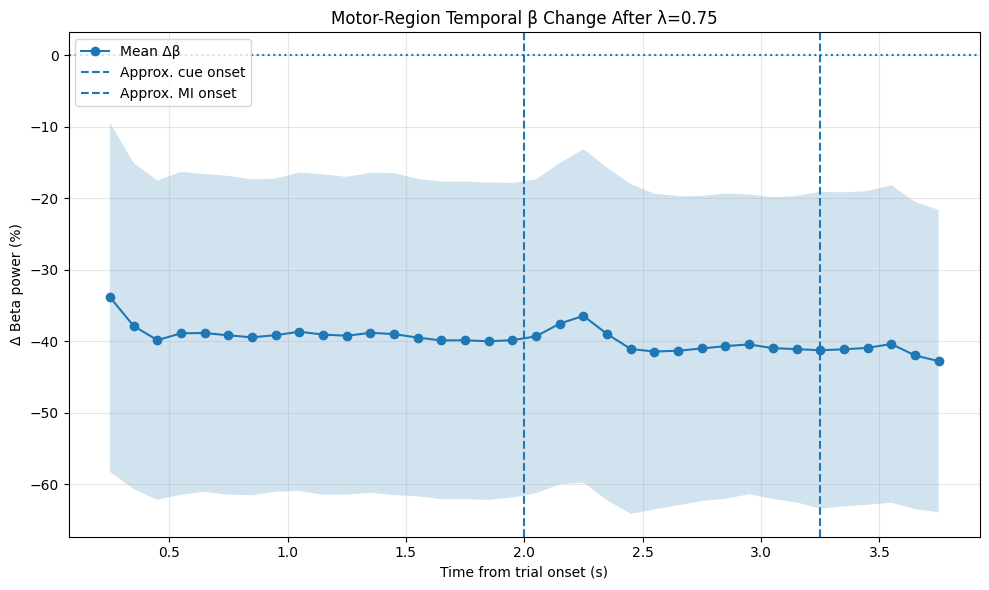

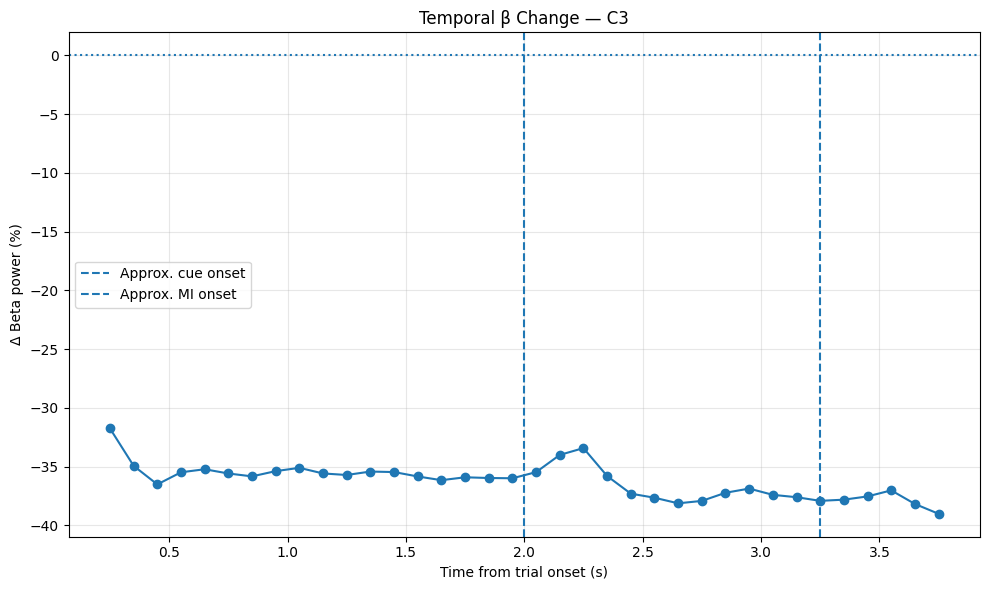

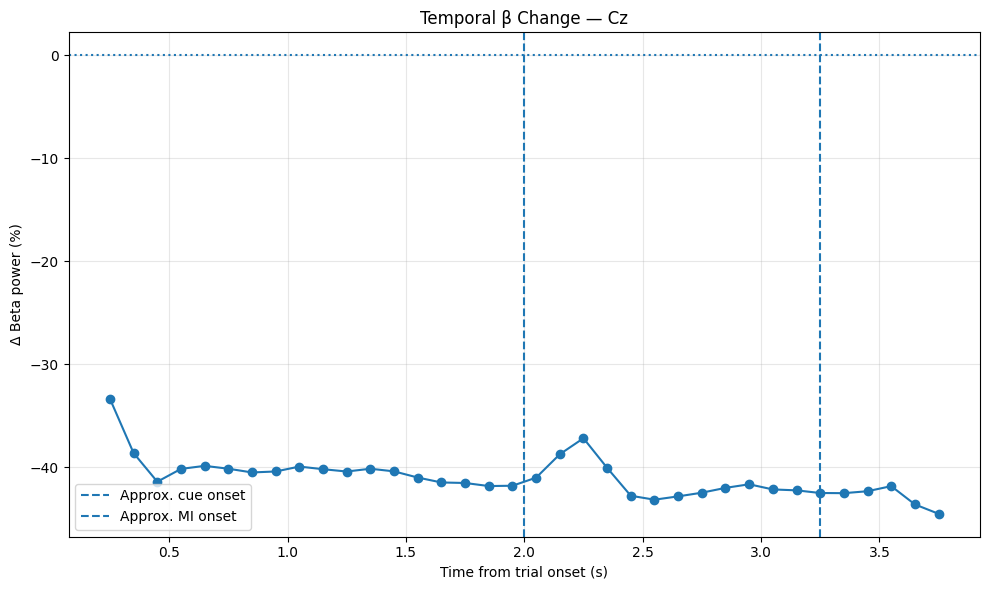

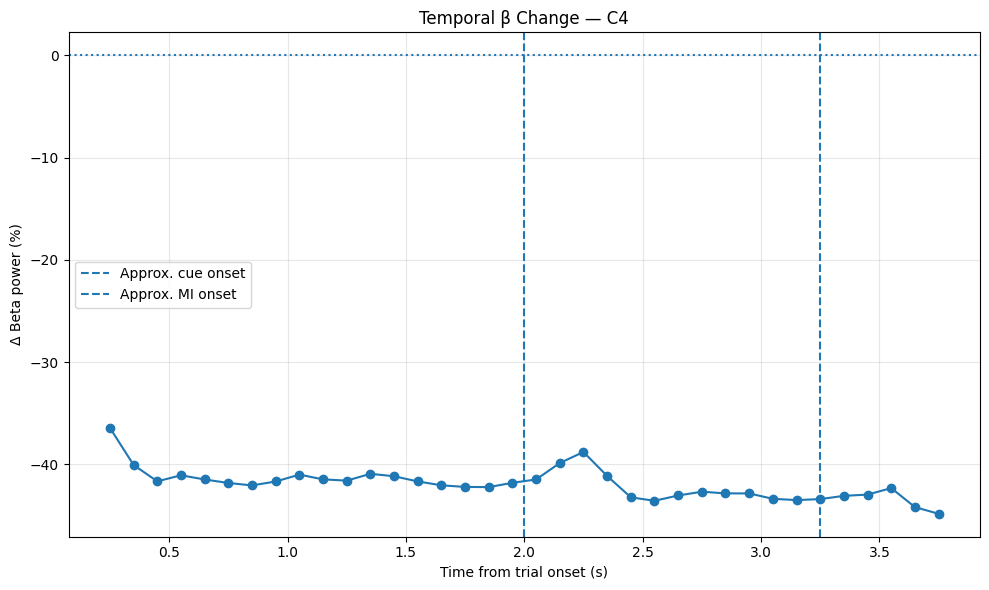

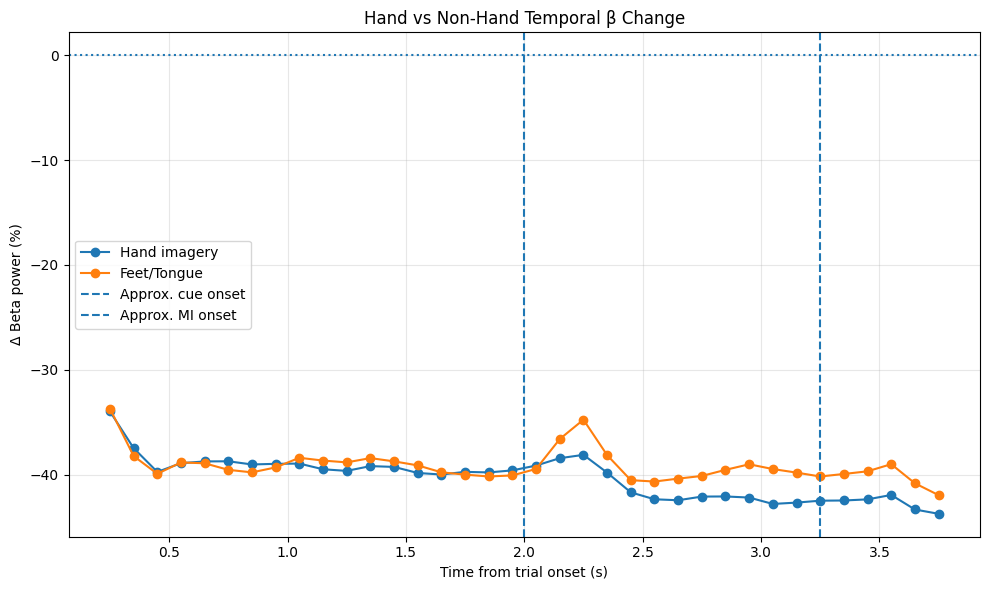

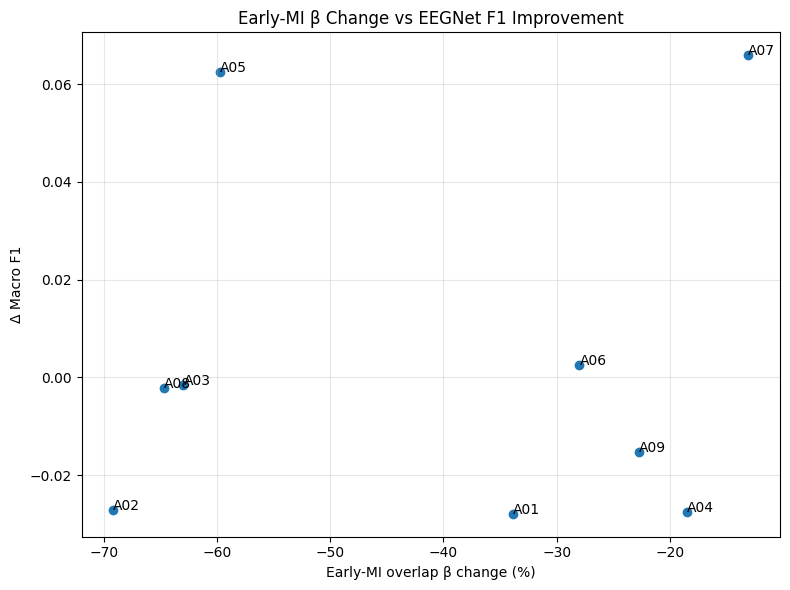



FINAL TEMPORAL β-DYNAMICS SUMMARY

Current analysis window:
0.00–4.00 s
Early-MI overlap: 3.25–4.00 s

Global peak:
Window = 3.75 s
Mean β change = -42.78207%

Mean early-MI overlap β change:
-41.41224%

Early-MI β change vs ΔAccuracy:
Pearson r = 0.24913, p = 0.51801
Spearman ρ = 0.25105, p = 0.51467

Early-MI β change vs ΔF1:
Pearson r = 0.07139, p = 0.85518
Spearman ρ = 0.16667, p = 0.66823

Peak β change vs ΔAccuracy:
Pearson r = 0.25471, p = 0.50834
Spearman ρ = 0.25105, p = 0.51467

Peak β change vs ΔF1:
Pearson r = 0.07896, p = 0.83998
Spearman ρ = 0.16667, p = 0.66823

Permutation p: 0.00320

Motor-channel peaks:
Channel  Peak_Window_s  Peak_Delta_Beta_Percent
     C3           3.75                -39.01855
     Cz           3.75                -44.50394
     C4           3.75                -44.82373

Output directory:
/content/drive/MyDrive/BCC/results/temporal_beta_lambda075


TEMPORAL β-DYNAMICS ANALYSIS COMPLETE


In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

from scipy.io import loadmat
from scipy.signal import welch

from scipy.stats import (
    pearsonr,
    spearmanr
)

import matplotlib.pyplot as plt

import mne

from sklearn.model_selection import (
    train_test_split
)

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "temporal_beta_lambda075"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

FS_RAW = 250
FS = 125

N_EEG = 22
N_EOG = 3

LAMBDA = 0.75

SUBJECTS = [
    f"A{i:02d}"
    for i in range(1, 10)
]

BETA_LOW = 13.0
BETA_HIGH = 30.0

WINDOW_SECONDS = 0.50
STEP_SECONDS = 0.10

WINDOW_STARTS = np.arange(

    0.0,

    4.0
    -
    WINDOW_SECONDS
    +
    1e-9,

    STEP_SECONDS

)

WINDOW_ENDS = (
    WINDOW_STARTS
    +
    WINDOW_SECONDS
)

WINDOW_CENTERS = (
    WINDOW_STARTS
    +
    WINDOW_ENDS
) / 2.0

EARLY_MI_START = 3.25
EARLY_MI_END = 4.00

EEG_CHANNELS = [

    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",

    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",

    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",

    "P1",
    "Pz",
    "P2",
    "POz"

]

EOG_CHANNELS = [

    "EOG_Left",
    "EOG_Central",
    "EOG_Right"

]

MOTOR_CHANNELS = [
    "C3",
    "Cz",
    "C4"
]

MOTOR_INDICES = {

    channel:
        EEG_CHANNELS.index(
            channel
        )

    for channel
    in MOTOR_CHANNELS

}

CLASS_NAMES = {

    1: "Left_Hand",

    2: "Right_Hand",

    3: "Feet",

    4: "Tongue"

}

def load_bci2a_with_eog(
    mat_path
):

    """
    Loads:
        - 22 EEG channels
        - 3 EOG channels
        - 0–4 s after trial onset
        - artifact-free trials
        - downsampled 250 -> 125 Hz
    """

    if not os.path.exists(
        mat_path
    ):

        raise FileNotFoundError(
            f"\nMAT file not found:\n{mat_path}"
        )

    mat = loadmat(

        mat_path,

        squeeze_me=False

    )

    if "data" not in mat:

        raise ValueError(
            f"'data' not found in:\n{mat_path}"
        )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    metadata = []

    for run_idx in range(
        data.shape[1]
    ):

        run_container = data[
            0,
            run_idx
        ]

        run = run_container[
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trial_onsets = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(
            trial_onsets.shape[0]
        ):

            if (
                artifacts[
                    trial_idx,
                    0
                ]
                ==
                1
            ):

                continue

            onset = int(
                trial_onsets[
                    trial_idx,
                    0
                ]
            )

            start = onset

            end = (
                onset
                +
                4 * FS_RAW
            )

            if end > X_raw.shape[0]:

                continue

            eeg = X_raw[
                start:end,
                :N_EEG
            ]

            eog = X_raw[
                start:end,
                N_EEG:N_EEG + N_EOG
            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            label = int(
                y[
                    trial_idx,
                    0
                ]
            )

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    trial_idx + 1,

                "Onset":
                    onset,

                "True_Class":
                    label

            })

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_4_38(
    X
):

    """
    Input:
        trials × samples × channels

    Output:
        trials × samples × channels
    """

    X_t = X.transpose(
        0,
        2,
        1
    )

    n_trials = (
        X_t.shape[0]
    )

    n_channels = (
        X_t.shape[1]
    )

    n_samples = (
        X_t.shape[2]
    )

    flattened = X_t.reshape(
        -1,
        n_samples
    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(

        n_trials,

        n_channels,

        n_samples

    )

    return filtered.transpose(
        0,
        2,
        1
    )

def fit_eog_regression(
    eeg_train,
    eog_train
):

    """
    For every EEG channel:

        EEG = EOG × beta + intercept

    Regression is fitted ONLY on training T trials.
    """

    eeg_flat = (
        eeg_train
        .reshape(
            -1,
            N_EEG
        )
    )

    eog_flat = (
        eog_train
        .reshape(
            -1,
            N_EOG
        )
    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    beta = np.zeros(

        (
            N_EEG,
            N_EOG
        ),

        dtype=np.float64

    )

    intercept = np.zeros(

        N_EEG,

        dtype=np.float64

    )

    for channel_idx in range(
        N_EEG
    ):

        coefficients, _, _, _ = np.linalg.lstsq(

            X,

            eeg_flat[
                :,
                channel_idx
            ],

            rcond=None

        )

        beta[
            channel_idx
        ] = coefficients[
            :N_EOG
        ]

        intercept[
            channel_idx
        ] = coefficients[
            N_EOG
        ]

    return (
        beta,
        intercept
    )

def estimate_eog_component(
    eog,
    beta,
    intercept
):

    """
    Returns the EEG component predicted from EOG.
    """

    component = np.einsum(

        "tsc,nc->tsn",

        eog,

        beta

    )

    component += (

        intercept.reshape(

            1,
            1,
            -1

        )

    )

    return component

def safe_pearson(
    x,
    y
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    mask = (

        np.isfinite(x)

        &

        np.isfinite(y)

    )

    if mask.sum() < 3:

        return (
            np.nan,
            np.nan
        )

    if (

        np.std(
            x[mask]
        )
        ==
        0

        or

        np.std(
            y[mask]
        )
        ==
        0

    ):

        return (
            np.nan,
            np.nan
        )

    return pearsonr(

        x[mask],

        y[mask]

    )

def safe_spearman(
    x,
    y
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    mask = (

        np.isfinite(x)

        &

        np.isfinite(y)

    )

    if mask.sum() < 3:

        return (
            np.nan,
            np.nan
        )

    return spearmanr(

        x[mask],

        y[mask]

    )

def beta_power_trials(
    eeg,
    channel_index,
    start_s,
    end_s
):

    """
    eeg:
        trials × samples × channels

    Returns:
        one beta-power value per trial
    """

    start_sample = int(
        round(
            start_s
            *
            FS
        )
    )

    end_sample = int(
        round(
            end_s
            *
            FS
        )
    )

    segment = eeg[

        :,

        start_sample:end_sample,

        channel_index

    ]

    if segment.shape[1] < 4:

        return np.full(

            len(eeg),

            np.nan

        )

    powers = []

    for trial in segment:

        frequencies, psd = welch(

            trial,

            fs=FS,

            nperseg=min(

                64,

                len(trial)

            ),

            noverlap=0

        )

        beta_mask = (

            (
                frequencies
                >=
                BETA_LOW
            )

            &

            (
                frequencies
                <=
                BETA_HIGH
            )

        )

        if beta_mask.sum() == 0:

            powers.append(
                np.nan
            )

            continue

        power = np.trapezoid(

            psd[
                beta_mask
            ],

            frequencies[
                beta_mask
            ]

        )

        powers.append(
            power
        )

    return np.asarray(

        powers,

        dtype=float

    )

ALLBAND_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_allband_lambda_performance.csv"
)

FOCUSED_FILE = os.path.join(
    RESULTS_DIR,
    "eegnet_focused_lambda_performance.csv"
)

if not os.path.exists(
    ALLBAND_FILE
):

    raise FileNotFoundError(
        f"Missing:\n{ALLBAND_FILE}"
    )

if not os.path.exists(
    FOCUSED_FILE
):

    raise FileNotFoundError(
        f"Missing:\n{FOCUSED_FILE}"
    )

allband = pd.read_csv(
    ALLBAND_FILE
)

focused = pd.read_csv(
    FOCUSED_FILE
)

allband.columns = [
    str(c).strip()
    for c in allband.columns
]

focused.columns = [
    str(c).strip()
    for c in focused.columns
]

raw_perf = allband[
    np.isclose(
        allband[
            "Lambda"
        ],
        0.00
    )
].copy()

raw_perf = raw_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

clean_perf = focused[
    np.isclose(
        focused[
            "Lambda"
        ],
        0.75
    )
].copy()

clean_perf = clean_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Lambda075_Accuracy",

        "Macro_F1":
            "Lambda075_F1"

    }

)

performance = (

    raw_perf

    .merge(

        clean_perf,

        on="Subject",

        how="inner"

    )

)

performance[
    "Delta_Accuracy"
] = (

    performance[
        "Lambda075_Accuracy"
    ]

    -

    performance[
        "Raw_Accuracy"
    ]

)

performance[
    "Delta_F1"
] = (

    performance[
        "Lambda075_F1"
    ]

    -

    performance[
        "Raw_F1"
    ]

)

performance = (
    performance
    .sort_values(
        "Subject"
    )
    .reset_index(
        drop=True
    )
)

if len(
    performance
) != len(
    SUBJECTS
):

    raise ValueError(
        "Performance table does not contain "
        "all 9 subjects."
    )

print("\n")
print("=" * 110)
print(
    "EEGNET PERFORMANCE REFERENCE"
)
print("=" * 110)

print(
    performance.round(
        5
    ).to_string(
        index=False
    )
)

temporal_rows = []

subject_peak_rows = []

subject_late_rows = []

for subject in SUBJECTS:

    print("\n")
    print(
        "=" * 110
    )

    print(
        f"PROCESSING {subject}"
    )

    print(
        "=" * 110
    )

    train_path = os.path.join(

        DATASET_DIR,

        f"{subject}T.mat"

    )

    eval_path = os.path.join(

        DATASET_DIR,

        f"{subject}E.mat"

    )

    (
        eeg_t,
        eog_t,
        y_t,
        meta_t
    ) = load_bci2a_with_eog(

        train_path

    )

    (
        eeg_e,
        eog_e,
        y_e,
        meta_e
    ) = load_bci2a_with_eog(

        eval_path

    )

    print(
        "Training trials:",
        len(
            y_t
        )
    )

    print(
        "Evaluation trials:",
        len(
            y_e
        )
    )

    print(
        "Filtering EEG..."
    )

    eeg_t_filt = filter_4_38(
        eeg_t
    )

    eeg_e_filt = filter_4_38(
        eeg_e
    )

    print(
        "Filtering EOG..."
    )

    eog_t_filt = filter_4_38(
        eog_t
    )

    eog_e_filt = filter_4_38(
        eog_e
    )

    train_idx, val_idx = (
        train_test_split(

            np.arange(
                len(y_t)
            ),

            test_size=0.20,

            stratify=y_t,

            random_state=SEED

        )
    )

    print(
        "Fitting training-only EOG regression..."
    )

    (
        beta,
        intercept
    ) = fit_eog_regression(

        eeg_t_filt[
            train_idx
        ],

        eog_t_filt[
            train_idx
        ]

    )

    eog_component = (
        estimate_eog_component(

            eog_e_filt,

            beta,

            intercept

        )
    )

    eeg_raw = (
        eeg_e_filt.copy()
    )

    eeg_clean = (

        eeg_e_filt

        -

        LAMBDA
        *
        eog_component

    )

    p = performance[
        performance[
            "Subject"
        ]
        ==
        subject
    ]

    if len(p) != 1:

        raise ValueError(
            f"Performance missing for {subject}"
        )

    p = p.iloc[
        0
    ]

    delta_accuracy = float(
        p[
            "Delta_Accuracy"
        ]
    )

    delta_f1 = float(
        p[
            "Delta_F1"
        ]
    )

    for channel_name in MOTOR_CHANNELS:

        channel_index = (
            MOTOR_INDICES[
                channel_name
            ]
        )

        for window_start, window_end in zip(

            WINDOW_STARTS,

            WINDOW_ENDS

        ):

            window_center = (

                window_start

                +

                window_end

            ) / 2.0

            raw_beta = beta_power_trials(

                eeg_raw,

                channel_index,

                window_start,

                window_end

            )

            clean_beta = beta_power_trials(

                eeg_clean,

                channel_index,

                window_start,

                window_end

            )

            raw_mean = np.nanmean(
                raw_beta
            )

            clean_mean = np.nanmean(
                clean_beta
            )

            delta_beta = (

                clean_mean

                -

                raw_mean

            )

            delta_beta_percent = (

                delta_beta

                /

                abs(
                    raw_mean
                )

                *

                100.0

                if abs(
                    raw_mean
                )
                >
                1e-12

                else np.nan

            )

            hand_mask = (

                (y_e == 1)

                |

                (y_e == 2)

            )

            if hand_mask.sum() > 0:

                raw_hand = np.nanmean(

                    raw_beta[
                        hand_mask
                    ]

                )

                clean_hand = np.nanmean(

                    clean_beta[
                        hand_mask
                    ]

                )

                hand_delta_percent = (

                    (
                        clean_hand
                        -
                        raw_hand
                    )

                    /

                    abs(
                        raw_hand
                    )

                    *

                    100.0

                    if abs(
                        raw_hand
                    )
                    >
                    1e-12

                    else np.nan

                )

            else:

                raw_hand = np.nan

                clean_hand = np.nan

                hand_delta_percent = np.nan

            non_hand_mask = (

                (y_e == 3)

                |

                (y_e == 4)

            )

            if non_hand_mask.sum() > 0:

                raw_non_hand = np.nanmean(

                    raw_beta[
                        non_hand_mask
                    ]

                )

                clean_non_hand = np.nanmean(

                    clean_beta[
                        non_hand_mask
                    ]

                )

                non_hand_delta_percent = (

                    (
                        clean_non_hand
                        -
                        raw_non_hand
                    )

                    /

                    abs(
                        raw_non_hand
                    )

                    *

                    100.0

                    if abs(
                        raw_non_hand
                    )
                    >
                    1e-12

                    else np.nan

                )

            else:

                raw_non_hand = np.nan

                clean_non_hand = np.nan

                non_hand_delta_percent = np.nan

            temporal_rows.append({

                "Subject":
                    subject,

                "Channel":
                    channel_name,

                "Window_Start_s":
                    window_start,

                "Window_End_s":
                    window_end,

                "Window_Center_s":
                    window_center,

                "Raw_Beta_Power":
                    raw_mean,

                "Clean_Beta_Power":
                    clean_mean,

                "Delta_Beta_Power":
                    delta_beta,

                "Delta_Beta_Percent":
                    delta_beta_percent,

                "Hand_Raw_Beta":
                    raw_hand,

                "Hand_Clean_Beta":
                    clean_hand,

                "Hand_Delta_Beta_Percent":
                    hand_delta_percent,

                "NonHand_Raw_Beta":
                    raw_non_hand,

                "NonHand_Clean_Beta":
                    clean_non_hand,

                "NonHand_Delta_Beta_Percent":
                    non_hand_delta_percent,

                "Delta_Accuracy":
                    delta_accuracy,

                "Delta_F1":
                    delta_f1

            })

    subject_temp = pd.DataFrame(

        [

            row

            for row
            in temporal_rows

            if row[
                "Subject"
            ]
            ==
            subject

        ]

    )

    motor_temp = (

        subject_temp

        .groupby(
            "Window_Center_s"
        )[

            "Delta_Beta_Percent"

        ]

        .mean()

        .reset_index()

    )

    peak_idx = (

        motor_temp[
            "Delta_Beta_Percent"
        ]

        .abs()

        .idxmax()

    )

    peak_row = motor_temp.loc[
        peak_idx
    ]

    peak_window = float(
        peak_row[
            "Window_Center_s"
        ]
    )

    peak_delta = float(
        peak_row[
            "Delta_Beta_Percent"
        ]
    )

    late = motor_temp[
        (
            motor_temp[
                "Window_Center_s"
            ]
            >=
            EARLY_MI_START
        )
        &
        (
            motor_temp[
                "Window_Center_s"
            ]
            <=
            (
                EARLY_MI_END
                -
                STEP_SECONDS
                /
                2.0
            )
        )
    ]

    late_mean = np.nanmean(

        late[
            "Delta_Beta_Percent"
        ]

    )

    late_min = np.nanmin(

        late[
            "Delta_Beta_Percent"
        ]

    )

    late_max = np.nanmax(

        late[
            "Delta_Beta_Percent"
        ]

    )

    subject_peak_rows.append({

        "Subject":
            subject,

        "Peak_Window_Center_s":
            peak_window,

        "Peak_Delta_Beta_Percent":
            peak_delta,

        "Early_MI_Overlap_Mean_Delta_Beta_Percent":
            late_mean,

        "Early_MI_Overlap_Min":
            late_min,

        "Early_MI_Overlap_Max":
            late_max,

        "Delta_Accuracy":
            delta_accuracy,

        "Delta_F1":
            delta_f1

    })

    subject_late_rows.append({

        "Subject":
            subject,

        "Early_MI_Beta_Change":
            late_mean,

        "Delta_Accuracy":
            delta_accuracy,

        "Delta_F1":
            delta_f1

    })

    print(
        f"Peak temporal β change:"
        f" {peak_delta:+.3f}%"
        f" at {peak_window:.2f}s"
    )

    print(
        f"Early-MI overlap β change:"
        f" {late_mean:+.3f}%"
    )

temporal_df = pd.DataFrame(
    temporal_rows
)

subject_peak_df = pd.DataFrame(
    subject_peak_rows
)

subject_late_df = pd.DataFrame(
    subject_late_rows
)

print("\n")
print("=" * 110)
print(
    "TEMPORAL MOTOR-REGION β CHANGE"
)
print("=" * 110)

temporal_summary = (

    temporal_df

    .groupby(
        "Window_Center_s"
    )[

        [
            "Delta_Beta_Power",
            "Delta_Beta_Percent"
        ]

    ]

    .agg(

        [
            "mean",
            "median",
            "std"
        ]

    )

)

print(
    temporal_summary.round(
        5
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "CHANNEL-SPECIFIC TEMPORAL β CHANGE"
)
print("=" * 110)

channel_temporal = (

    temporal_df

    .groupby(

        [
            "Channel",
            "Window_Center_s"
        ]

    )[

        "Delta_Beta_Percent"

    ]

    .mean()

    .reset_index()

)

print(
    channel_temporal.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "HAND vs NON-HAND TEMPORAL β CHANGE"
)
print("=" * 110)

hand_temporal = (

    temporal_df

    .groupby(
        "Window_Center_s"
    )[

        "Hand_Delta_Beta_Percent"

    ]

    .mean()

)

non_hand_temporal = (

    temporal_df

    .groupby(
        "Window_Center_s"
    )[

        "NonHand_Delta_Beta_Percent"

    ]

    .mean()

)

hand_nonhand_df = pd.DataFrame({

    "Window_Center_s":
        hand_temporal.index,

    "Hand_Delta_Beta_Percent":
        hand_temporal.values,

    "NonHand_Delta_Beta_Percent":
        non_hand_temporal.reindex(
            hand_temporal.index
        ).values

})

hand_nonhand_df[
    "Hand_Minus_NonHand"
] = (

    hand_nonhand_df[
        "Hand_Delta_Beta_Percent"
    ]

    -

    hand_nonhand_df[
        "NonHand_Delta_Beta_Percent"
    ]

)

print(
    hand_nonhand_df.round(
        5
    ).to_string(
        index=False
    )
)

channel_peak_rows = []

for channel in MOTOR_CHANNELS:

    temp = channel_temporal[
        channel_temporal[
            "Channel"
        ]
        ==
        channel
    ].copy()

    peak_idx = (

        temp[
            "Delta_Beta_Percent"
        ]

        .abs()

        .idxmax()

    )

    peak_row = temp.loc[
        peak_idx
    ]

    channel_peak_rows.append({

        "Channel":
            channel,

        "Peak_Window_s":
            peak_row[
                "Window_Center_s"
            ],

        "Peak_Delta_Beta_Percent":
            peak_row[
                "Delta_Beta_Percent"
            ]

    })

channel_peak_df = pd.DataFrame(
    channel_peak_rows
)

print("\n")
print("=" * 110)
print(
    "PEAK TEMPORAL EFFECT BY MOTOR CHANNEL"
)
print("=" * 110)

print(
    channel_peak_df.round(
        5
    ).to_string(
        index=False
    )
)

print("\n")
print("=" * 110)
print(
    "EARLY-MI β CHANGE vs EEGNET PERFORMANCE BENEFIT"
)
print("=" * 110)

x = subject_late_df[
    "Early_MI_Beta_Change"
].to_numpy(
    dtype=float
)

y_acc = subject_late_df[
    "Delta_Accuracy"
].to_numpy(
    dtype=float
)

y_f1 = subject_late_df[
    "Delta_F1"
].to_numpy(
    dtype=float
)

acc_r, acc_p = safe_pearson(
    x,
    y_acc
)

acc_rho, acc_rho_p = safe_spearman(
    x,
    y_acc
)

f1_r, f1_p = safe_pearson(
    x,
    y_f1
)

f1_rho, f1_rho_p = safe_spearman(
    x,
    y_f1
)

print(
    f"Accuracy Pearson:"
    f" r={acc_r:.5f},"
    f" p={acc_p:.5f}"
)

print(
    f"Accuracy Spearman:"
    f" ρ={acc_rho:.5f},"
    f" p={acc_rho_p:.5f}"
)

print(
    f"F1 Pearson:"
    f" r={f1_r:.5f},"
    f" p={f1_p:.5f}"
)

print(
    f"F1 Spearman:"
    f" ρ={f1_rho:.5f},"
    f" p={f1_rho_p:.5f}"
)

print("\n")
print("=" * 110)
print(
    "PEAK β CHANGE vs EEGNET BENEFIT"
)
print("=" * 110)

peak_x = subject_peak_df[
    "Peak_Delta_Beta_Percent"
].to_numpy(
    dtype=float
)

peak_accuracy_r, peak_accuracy_p = safe_pearson(

    peak_x,

    subject_peak_df[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

)

peak_accuracy_rho, peak_accuracy_rho_p = safe_spearman(

    peak_x,

    subject_peak_df[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

)

peak_f1_r, peak_f1_p = safe_pearson(

    peak_x,

    subject_peak_df[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

)

peak_f1_rho, peak_f1_rho_p = safe_spearman(

    peak_x,

    subject_peak_df[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

)

print(
    f"Accuracy Pearson:"
    f" r={peak_accuracy_r:.5f},"
    f" p={peak_accuracy_p:.5f}"
)

print(
    f"Accuracy Spearman:"
    f" ρ={peak_accuracy_rho:.5f},"
    f" p={peak_accuracy_rho_p:.5f}"
)

print(
    f"F1 Pearson:"
    f" r={peak_f1_r:.5f},"
    f" p={peak_f1_p:.5f}"
)

print(
    f"F1 Spearman:"
    f" ρ={peak_f1_rho:.5f},"
    f" p={peak_f1_rho_p:.5f}"
)

late_hand = hand_nonhand_df[
    (
        hand_nonhand_df[
            "Window_Center_s"
        ]
        >=
        EARLY_MI_START
    )
]

print("\n")
print("=" * 110)
print(
    "EARLY-MI HAND vs NON-HAND β RESPONSE"
)
print("=" * 110)

print(
    "Mean Hand β change:",
    f"{late_hand['Hand_Delta_Beta_Percent'].mean():+.5f}%"
)

print(
    "Mean Non-Hand β change:",
    f"{late_hand['NonHand_Delta_Beta_Percent'].mean():+.5f}%"
)

print(
    "Hand - Non-Hand:",
    f"{late_hand['Hand_Minus_NonHand'].mean():+.5f}%"
)

global_temporal_curve = (

    temporal_df

    .groupby(
        "Window_Center_s"
    )[

        "Delta_Beta_Percent"

    ]

    .mean()

)

global_peak_time = (

    global_temporal_curve

    .abs()

    .idxmax()

)

global_peak_value = (

    global_temporal_curve.loc[
        global_peak_time
    ]

)

print("\n")
print("=" * 110)
print(
    "GLOBAL TEMPORAL PEAK"
)
print("=" * 110)

print(
    "Peak window center:",
    f"{global_peak_time:.2f} s"
)

print(
    "Peak mean β change:",
    f"{global_peak_value:+.5f}%"
)

print("\n")
print("=" * 110)
print(
    "EXPLORATORY TEMPORAL PEAK PERMUTATION TEST"
)
print("=" * 110)

N_PERMUTATIONS = 5000

rng = np.random.default_rng(
    SEED
)

subject_time_matrix = (

    temporal_df

    .groupby(

        [
            "Subject",
            "Window_Center_s"
        ]

    )[

        "Delta_Beta_Percent"

    ]

    .mean()

    .unstack(
        "Window_Center_s"
    )

    .reindex(
        SUBJECTS
    )

)

observed_time_mean = (
    subject_time_matrix
    .mean(
        axis=0
    )
)

observed_peak = np.nanmax(

    np.abs(

        observed_time_mean
        .to_numpy(
            dtype=float
        )

    )

)

observed_peak_time = (

    observed_time_mean

    .abs()

    .idxmax()

)

observed_peak_value = (
    observed_time_mean.loc[
        observed_peak_time
    ]
)

matrix = (
    subject_time_matrix
    .to_numpy(
        dtype=float
    )
)

permutation_peaks = np.zeros(
    N_PERMUTATIONS
)

for permutation_index in range(
    N_PERMUTATIONS
):

    signs = rng.choice(

        [-1, 1],

        size=matrix.shape[0]

    )

    permuted = (

        matrix

        *

        signs[
            :,
            None
        ]

    )

    permuted_mean = np.nanmean(

        permuted,

        axis=0

    )

    permutation_peaks[
        permutation_index
    ] = np.nanmax(

        np.abs(
            permuted_mean
        )

    )

permutation_p = (

    (
        permutation_peaks
        >=
        observed_peak
    ).sum()

    +

    1

) / (

    N_PERMUTATIONS
    +
    1

)

print(
    "Observed peak window:",
    f"{observed_peak_time:.2f} s"
)

print(
    "Observed peak β change:",
    f"{observed_peak_value:+.5f}%"
)

print(
    "Observed peak absolute effect:",
    f"{observed_peak:.5f}%"
)

print(
    "Permutation p:",
    f"{permutation_p:.5f}"
)

plt.figure(
    figsize=(10, 6)
)

mean_curve = (
    temporal_df
    .groupby(
        "Window_Center_s"
    )[
        "Delta_Beta_Percent"
    ]
    .mean()
)

std_curve = (
    temporal_df
    .groupby(
        "Window_Center_s"
    )[
        "Delta_Beta_Percent"
    ]
    .std()
)

time_values = (
    mean_curve.index
    .to_numpy()
)

plt.plot(

    time_values,

    mean_curve.to_numpy(),

    marker="o",

    label="Mean Δβ"

)

plt.fill_between(

    time_values,

    (
        mean_curve
        -
        std_curve
    ).to_numpy(),

    (
        mean_curve
        +
        std_curve
    ).to_numpy(),

    alpha=0.20

)

plt.axvline(

    2.0,

    linestyle="--",

    label="Approx. cue onset"

)

plt.axvline(

    3.25,

    linestyle="--",

    label="Approx. MI onset"

)

plt.axhline(

    0.0,

    linestyle=":"

)

plt.xlabel(
    "Time from trial onset (s)"
)

plt.ylabel(
    "Δ Beta power (%)"
)

plt.title(
    "Motor-Region Temporal β Change After λ=0.75"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

global_plot_file = os.path.join(

    FIGURE_DIR,

    "motor_region_temporal_beta_change.png"

)

plt.savefig(

    global_plot_file,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

for channel in MOTOR_CHANNELS:

    temp = channel_temporal[
        channel_temporal[
            "Channel"
        ]
        ==
        channel
    ]

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(

        temp[
            "Window_Center_s"
        ],

        temp[
            "Delta_Beta_Percent"
        ],

        marker="o"

    )

    plt.axvline(

        2.0,

        linestyle="--",

        label="Approx. cue onset"

    )

    plt.axvline(

        3.25,

        linestyle="--",

        label="Approx. MI onset"

    )

    plt.axhline(

        0.0,

        linestyle=":"

    )

    plt.xlabel(
        "Time from trial onset (s)"
    )

    plt.ylabel(
        "Δ Beta power (%)"
    )

    plt.title(
        f"Temporal β Change — {channel}"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    channel_plot_file = os.path.join(

        FIGURE_DIR,

        f"{channel}_temporal_beta_change.png"

    )

    plt.savefig(

        channel_plot_file,

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()

plt.figure(
    figsize=(10, 6)
)

plt.plot(

    hand_nonhand_df[
        "Window_Center_s"
    ],

    hand_nonhand_df[
        "Hand_Delta_Beta_Percent"
    ],

    marker="o",

    label="Hand imagery"

)

plt.plot(

    hand_nonhand_df[
        "Window_Center_s"
    ],

    hand_nonhand_df[
        "NonHand_Delta_Beta_Percent"
    ],

    marker="o",

    label="Feet/Tongue"

)

plt.axvline(

    2.0,

    linestyle="--",

    label="Approx. cue onset"

)

plt.axvline(

    3.25,

    linestyle="--",

    label="Approx. MI onset"

)

plt.axhline(

    0.0,

    linestyle=":"

)

plt.xlabel(
    "Time from trial onset (s)"
)

plt.ylabel(
    "Δ Beta power (%)"
)

plt.title(
    "Hand vs Non-Hand Temporal β Change"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

hand_plot_file = os.path.join(

    FIGURE_DIR,

    "hand_vs_nonhand_temporal_beta.png"

)

plt.savefig(

    hand_plot_file,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(8, 6)
)

plt.scatter(

    subject_late_df[
        "Early_MI_Beta_Change"
    ],

    subject_late_df[
        "Delta_F1"
    ]

)

for _, row in subject_late_df.iterrows():

    plt.annotate(

        row[
            "Subject"
        ],

        (

            row[
                "Early_MI_Beta_Change"
            ],

            row[
                "Delta_F1"
            ]

        )

    )

plt.xlabel(
    "Early-MI overlap β change (%)"
)

plt.ylabel(
    "Δ Macro F1"
)

plt.title(
    "Early-MI β Change vs EEGNet F1 Improvement"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

f1_plot_file = os.path.join(

    FIGURE_DIR,

    "early_mi_beta_change_vs_f1.png"

)

plt.savefig(

    f1_plot_file,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

temporal_file = os.path.join(

    OUTPUT_DIR,

    "temporal_beta_change_lambda075.csv"

)

temporal_df.to_csv(

    temporal_file,

    index=False

)

subject_peak_file = os.path.join(

    OUTPUT_DIR,

    "subject_temporal_beta_peaks.csv"

)

subject_peak_df.to_csv(

    subject_peak_file,

    index=False

)

subject_late_file = os.path.join(

    OUTPUT_DIR,

    "subject_early_mi_beta_change.csv"

)

subject_late_df.to_csv(

    subject_late_file,

    index=False

)

hand_nonhand_file = os.path.join(

    OUTPUT_DIR,

    "hand_vs_nonhand_temporal_beta_change.csv"

)

hand_nonhand_df.to_csv(

    hand_nonhand_file,

    index=False

)

channel_peak_file = os.path.join(

    OUTPUT_DIR,

    "motor_channel_temporal_beta_peaks.csv"

)

channel_peak_df.to_csv(

    channel_peak_file,

    index=False

)

temporal_summary_file = os.path.join(

    OUTPUT_DIR,

    "temporal_beta_summary.csv"

)

temporal_summary.to_csv(

    temporal_summary_file

)

permutation_result_df = pd.DataFrame({

    "Metric": [

        "Observed_Peak_Window_s",

        "Observed_Peak_Delta_Beta_Percent",

        "Observed_Peak_Absolute_Delta_Beta_Percent",

        "Permutation_p",

        "N_Permutations"

    ],

    "Value": [

        observed_peak_time,

        observed_peak_value,

        observed_peak,

        permutation_p,

        N_PERMUTATIONS

    ]

})

permutation_file = os.path.join(

    OUTPUT_DIR,

    "temporal_beta_peak_permutation.csv"

)

permutation_result_df.to_csv(

    permutation_file,

    index=False

)

correlation_summary_df = pd.DataFrame({

    "Metric": [

        "Early_Mi_Beta_vs_Delta_Accuracy_Pearson_r",

        "Early_Mi_Beta_vs_Delta_Accuracy_Pearson_p",

        "Early_Mi_Beta_vs_Delta_Accuracy_Spearman_rho",

        "Early_Mi_Beta_vs_Delta_Accuracy_Spearman_p",

        "Early_Mi_Beta_vs_Delta_F1_Pearson_r",

        "Early_Mi_Beta_vs_Delta_F1_Pearson_p",

        "Early_Mi_Beta_vs_Delta_F1_Spearman_rho",

        "Early_Mi_Beta_vs_Delta_F1_Spearman_p",

        "Peak_Beta_vs_Delta_Accuracy_Pearson_r",

        "Peak_Beta_vs_Delta_Accuracy_Pearson_p",

        "Peak_Beta_vs_Delta_Accuracy_Spearman_rho",

        "Peak_Beta_vs_Delta_Accuracy_Spearman_p",

        "Peak_Beta_vs_Delta_F1_Pearson_r",

        "Peak_Beta_vs_Delta_F1_Pearson_p",

        "Peak_Beta_vs_Delta_F1_Spearman_rho",

        "Peak_Beta_vs_Delta_F1_Spearman_p"

    ],

    "Value": [

        acc_r,

        acc_p,

        acc_rho,

        acc_rho_p,

        f1_r,

        f1_p,

        f1_rho,

        f1_rho_p,

        peak_accuracy_r,

        peak_accuracy_p,

        peak_accuracy_rho,

        peak_accuracy_rho_p,

        peak_f1_r,

        peak_f1_p,

        peak_f1_rho,

        peak_f1_rho_p

    ]

})

correlation_file = os.path.join(

    OUTPUT_DIR,

    "temporal_beta_performance_correlations.csv"

)

correlation_summary_df.to_csv(

    correlation_file,

    index=False

)

channel_temporal_file = os.path.join(

    OUTPUT_DIR,

    "channel_temporal_beta_change.csv"

)

channel_temporal.to_csv(

    channel_temporal_file,

    index=False

)

print("\n")
print("=" * 110)
print(
    "FINAL TEMPORAL β-DYNAMICS SUMMARY"
)
print("=" * 110)

print(
    "\nCurrent analysis window:"
)

print(
    "0.00–4.00 s"
)

print(
    "Early-MI overlap:",
    f"{EARLY_MI_START:.2f}–{EARLY_MI_END:.2f} s"
)

print(
    "\nGlobal peak:"
)

print(
    f"Window = {observed_peak_time:.2f} s"
)

print(
    f"Mean β change = {observed_peak_value:+.5f}%"
)

print(
    "\nMean early-MI overlap β change:"
)

print(
    f"{subject_late_df['Early_MI_Beta_Change'].mean():+.5f}%"
)

print(
    "\nEarly-MI β change vs ΔAccuracy:"
)

print(
    f"Pearson r = {acc_r:.5f}, "
    f"p = {acc_p:.5f}"
)

print(
    f"Spearman ρ = {acc_rho:.5f}, "
    f"p = {acc_rho_p:.5f}"
)

print(
    "\nEarly-MI β change vs ΔF1:"
)

print(
    f"Pearson r = {f1_r:.5f}, "
    f"p = {f1_p:.5f}"
)

print(
    f"Spearman ρ = {f1_rho:.5f}, "
    f"p = {f1_rho_p:.5f}"
)

print(
    "\nPeak β change vs ΔAccuracy:"
)

print(
    f"Pearson r = {peak_accuracy_r:.5f}, "
    f"p = {peak_accuracy_p:.5f}"
)

print(
    f"Spearman ρ = {peak_accuracy_rho:.5f}, "
    f"p = {peak_accuracy_rho_p:.5f}"
)

print(
    "\nPeak β change vs ΔF1:"
)

print(
    f"Pearson r = {peak_f1_r:.5f}, "
    f"p = {peak_f1_p:.5f}"
)

print(
    f"Spearman ρ = {peak_f1_rho:.5f}, "
    f"p = {peak_f1_rho_p:.5f}"
)

print(
    "\nPermutation p:",
    f"{permutation_p:.5f}"
)

print(
    "\nMotor-channel peaks:"
)

print(
    channel_peak_df.round(
        5
    ).to_string(
        index=False
    )
)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print("\n")
print("=" * 110)
print(
    "TEMPORAL β-DYNAMICS ANALYSIS COMPLETE"
)
print("=" * 110)


## Normalized Sensorimotor β Class-Contrast



EEGNET PERFORMANCE REFERENCE
Subject  Raw_Accuracy  Raw_F1  Lambda075_Accuracy  Lambda075_F1  Delta_Accuracy  Delta_F1
    A01       0.62278 0.61508             0.59786       0.58717        -0.02491  -0.02791
    A02       0.34276 0.32870             0.30389       0.30161        -0.03887  -0.02708
    A03       0.69231 0.67708             0.68864       0.67551        -0.00366  -0.00157
    A04       0.43860 0.43310             0.41228       0.40561        -0.02632  -0.02748
    A05       0.31522 0.24582             0.33696       0.30832         0.02174   0.06251
    A06       0.45116 0.44325             0.45116       0.44571         0.00000   0.00246
    A07       0.45487 0.44987             0.51625       0.51578         0.06137   0.06590
    A08       0.65683 0.65610             0.65683       0.65391         0.00000  -0.00219
    A09       0.65909 0.65826             0.64015       0.64299        -0.01894  -0.01527


PROCESSING A01


PROCESSING A02


PROCESSING A03


PROCESSING A04



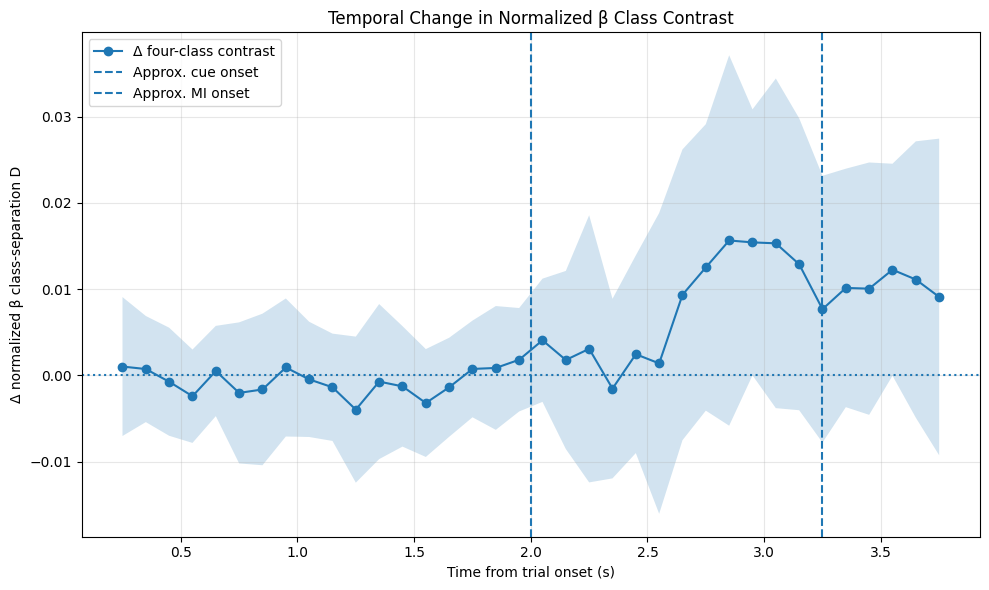

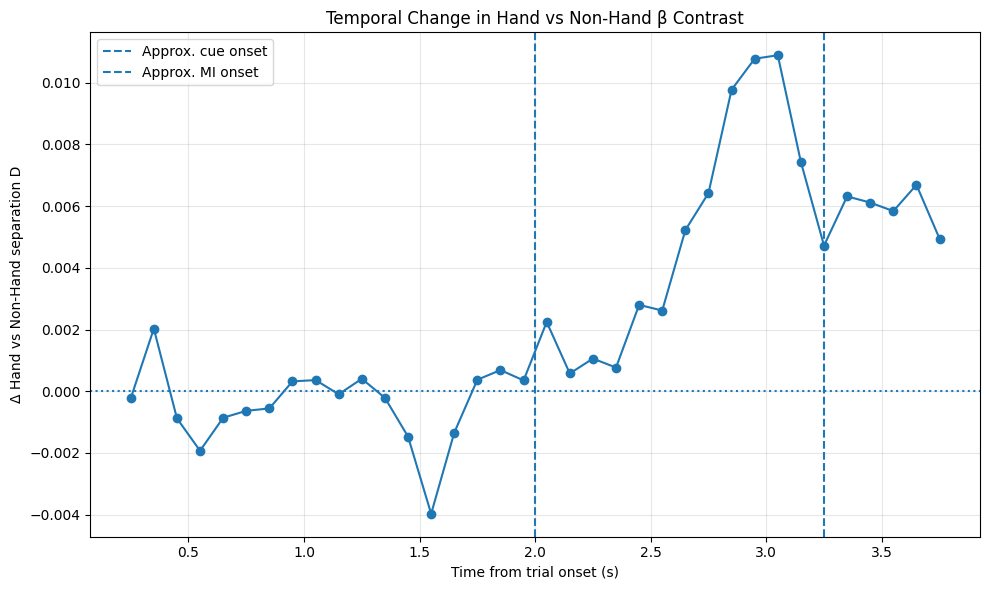

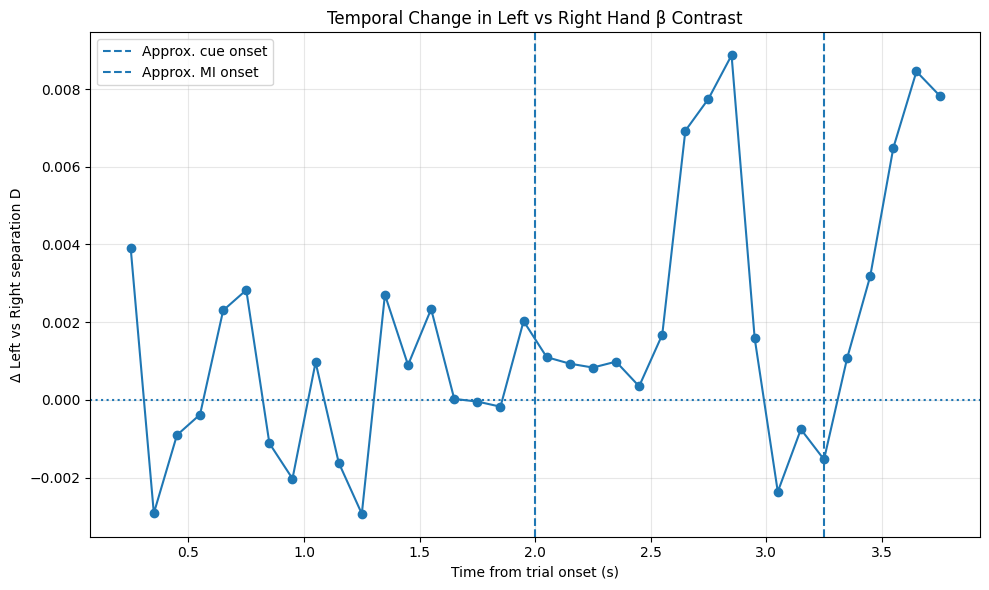

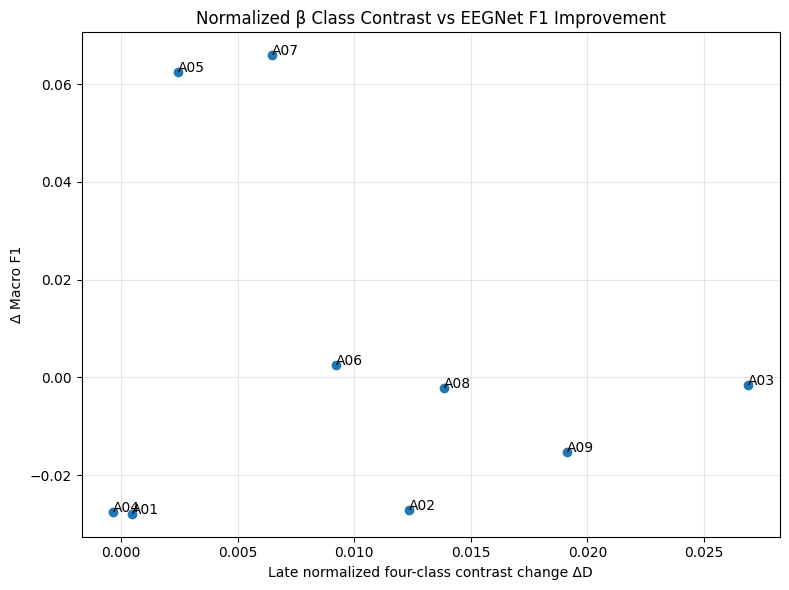



FINAL NORMALIZED β CLASS-CONTRAST ANALYSIS

Mean late four-class contrast change:
+0.010046

Mean late Hand vs Non-Hand contrast change:
+0.005772

Mean late Left vs Right contrast change:
+0.004249

Late four-class contrast vs ΔAccuracy:
Pearson r = -0.08922, p = 0.81945
Spearman ρ = 0.06695, p = 0.86413

Late four-class contrast vs ΔF1:
Pearson r = -0.14964, p = 0.70079
Spearman ρ = 0.21667, p = 0.57551

Subjects with increased four-class contrast:
8 / 9

Output directory:
/content/drive/MyDrive/BCC/results/normalized_beta_class_contrast


NORMALIZED β CLASS-CONTRAST ANALYSIS COMPLETE


In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

from scipy.io import loadmat
from scipy.signal import welch

from scipy.stats import (
    pearsonr,
    spearmanr
)

import matplotlib.pyplot as plt

import mne

from sklearn.model_selection import train_test_split

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "normalized_beta_class_contrast"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

FS_RAW = 250
FS = 125

N_EEG = 22
N_EOG = 3

LAMBDA = 0.75

SUBJECTS = [
    f"A{i:02d}"
    for i in range(1, 10)
]

BETA_LOW = 13.0
BETA_HIGH = 30.0

BASELINE_START = 0.00
BASELINE_END = 2.00

WINDOW_SECONDS = 0.50
STEP_SECONDS = 0.10

WINDOW_STARTS = np.arange(

    0.0,

    4.0 -
    WINDOW_SECONDS +
    1e-9,

    STEP_SECONDS

)

WINDOW_ENDS = (

    WINDOW_STARTS
    +
    WINDOW_SECONDS

)

WINDOW_CENTERS = (

    WINDOW_STARTS
    +
    WINDOW_ENDS

) / 2.0

EEG_CHANNELS = [

    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",

    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",

    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",

    "P1",
    "Pz",
    "P2",
    "POz"

]

MOTOR_CHANNELS = [

    "C3",
    "Cz",
    "C4"

]

MOTOR_INDICES = {

    channel:
        EEG_CHANNELS.index(
            channel
        )

    for channel
    in MOTOR_CHANNELS

}

CLASS_NAMES = {

    1: "Left_Hand",

    2: "Right_Hand",

    3: "Feet",

    4: "Tongue"

}

def load_bci2a_with_eog(
    mat_path
):

    mat = loadmat(

        mat_path,

        squeeze_me=False

    )

    if "data" not in mat:

        raise ValueError(

            f"'data' not found in:\n{mat_path}"

        )

    data = mat[
        "data"
    ]

    eeg_trials = []
    eog_trials = []
    labels = []
    metadata = []

    for run_idx in range(
        data.shape[1]
    ):

        run_container = data[
            0,
            run_idx
        ]

        run = run_container[
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trial_onsets = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(
            trial_onsets.shape[0]
        ):

            if (
                artifacts[
                    trial_idx,
                    0
                ]
                ==
                1
            ):

                continue

            onset = int(
                trial_onsets[
                    trial_idx,
                    0
                ]
            )

            start = onset

            end = (

                onset
                +
                4 * FS_RAW

            )

            if (
                end
                >
                X_raw.shape[0]
            ):

                continue

            eeg = X_raw[

                start:end,

                :N_EEG

            ]

            eog = X_raw[

                start:end,

                N_EEG:N_EEG + N_EOG

            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            label = int(
                y[
                    trial_idx,
                    0
                ]
            )

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    trial_idx + 1,

                "Onset":
                    onset,

                "True_Class":
                    label

            })

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_4_38(
    X
):

    X_t = X.transpose(

        0,
        2,
        1

    )

    n_trials = X_t.shape[0]

    n_channels = X_t.shape[1]

    n_samples = X_t.shape[2]

    flattened = X_t.reshape(

        -1,

        n_samples

    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(

        n_trials,

        n_channels,

        n_samples

    )

    return filtered.transpose(

        0,
        2,
        1

    )

def fit_eog_regression(
    eeg_train,
    eog_train
):

    eeg_flat = (

        eeg_train
        .reshape(
            -1,
            N_EEG
        )

    )

    eog_flat = (

        eog_train
        .reshape(
            -1,
            N_EOG
        )

    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    beta = np.zeros(

        (
            N_EEG,
            N_EOG
        ),

        dtype=np.float64

    )

    intercept = np.zeros(

        N_EEG,

        dtype=np.float64

    )

    for channel_idx in range(
        N_EEG
    ):

        coefficients, _, _, _ = (

            np.linalg.lstsq(

                X,

                eeg_flat[
                    :,
                    channel_idx
                ],

                rcond=None

            )

        )

        beta[
            channel_idx
        ] = coefficients[
            :N_EOG
        ]

        intercept[
            channel_idx
        ] = coefficients[
            N_EOG
        ]

    return (

        beta,

        intercept

    )

def estimate_eog_component(
    eog,
    beta,
    intercept
):

    component = np.einsum(

        "tsc,nc->tsn",

        eog,

        beta

    )

    component += (

        intercept.reshape(

            1,
            1,
            -1

        )

    )

    return component

def beta_power_trials(
    eeg,
    channel_index,
    start_s,
    end_s
):

    start_sample = int(
        round(
            start_s
            *
            FS
        )
    )

    end_sample = int(
        round(
            end_s
            *
            FS
        )
    )

    segment = eeg[

        :,

        start_sample:end_sample,

        channel_index

    ]

    powers = []

    for trial in segment:

        if len(trial) < 8:

            powers.append(
                np.nan
            )

            continue

        frequencies, psd = welch(

            trial,

            fs=FS,

            nperseg=min(
                64,
                len(trial)
            ),

            noverlap=0

        )

        mask = (

            (
                frequencies
                >=
                BETA_LOW
            )

            &

            (
                frequencies
                <=
                BETA_HIGH
            )

        )

        if mask.sum() == 0:

            powers.append(
                np.nan
            )

            continue

        power = np.trapezoid(

            psd[
                mask
            ],

            frequencies[
                mask
            ]

        )

        powers.append(
            power
        )

    return np.asarray(

        powers,

        dtype=float

    )

def normalized_modulation(
    baseline_power,
    window_power
):

    """
    Per-trial normalized β modulation:

        (window - baseline) / baseline

    """

    baseline_power = np.asarray(

        baseline_power,

        dtype=float

    )

    window_power = np.asarray(

        window_power,

        dtype=float

    )

    modulation = (

        (
            window_power
            -
            baseline_power
        )

        /

        (
            baseline_power
            +
            1e-12
        )

    )

    return modulation

def class_separation_ratio(
    values,
    labels
):

    """
    Between-class variance /
    within-class variance

    Larger = stronger class contrast.
    """

    values = np.asarray(
        values,
        dtype=float
    )

    labels = np.asarray(
        labels
    )

    valid = np.isfinite(
        values
    )

    values = values[
        valid
    ]

    labels = labels[
        valid
    ]

    unique_classes = np.unique(
        labels
    )

    if len(
        unique_classes
    ) < 2:

        return np.nan

    grand_mean = values.mean()

    between = 0.0

    within = 0.0

    for cls in unique_classes:

        class_values = values[
            labels
            ==
            cls
        ]

        if len(
            class_values
        ) == 0:

            continue

        class_mean = (
            class_values.mean()
        )

        between += (

            len(
                class_values
            )
            *
            (
                class_mean
                -
                grand_mean
            ) ** 2

        )

        within += np.sum(

            (
                class_values
                -
                class_mean
            ) ** 2

        )

    if within <= 0:

        return np.nan

    return (

        between
        /
        within

    )

def pairwise_separation(
    values,
    labels,
    class_a,
    class_b
):

    mask = (

        (labels == class_a)
        |
        (labels == class_b)

    )

    values_subset = values[
        mask
    ]

    labels_subset = labels[
        mask
    ]

    return class_separation_ratio(

        values_subset,

        labels_subset

    )

ALLBAND_FILE = os.path.join(

    RESULTS_DIR,

    "eegnet_allband_lambda_performance.csv"

)

FOCUSED_FILE = os.path.join(

    RESULTS_DIR,

    "eegnet_focused_lambda_performance.csv"

)

if not os.path.exists(
    ALLBAND_FILE
):

    raise FileNotFoundError(
        ALLBAND_FILE
    )

if not os.path.exists(
    FOCUSED_FILE
):

    raise FileNotFoundError(
        FOCUSED_FILE
    )

allband = pd.read_csv(
    ALLBAND_FILE
)

focused = pd.read_csv(
    FOCUSED_FILE
)

raw_perf = allband[
    np.isclose(
        allband[
            "Lambda"
        ],
        0.00
    )
].copy()

raw_perf = raw_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

clean_perf = focused[
    np.isclose(
        focused[
            "Lambda"
        ],
        0.75
    )
].copy()

clean_perf = clean_perf[
    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]
].rename(

    columns={

        "Accuracy":
            "Lambda075_Accuracy",

        "Macro_F1":
            "Lambda075_F1"

    }

)

performance = (

    raw_perf

    .merge(

        clean_perf,

        on="Subject",

        how="inner"

    )

)

performance[
    "Delta_Accuracy"
] = (

    performance[
        "Lambda075_Accuracy"
    ]

    -

    performance[
        "Raw_Accuracy"
    ]

)

performance[
    "Delta_F1"
] = (

    performance[
        "Lambda075_F1"
    ]

    -

    performance[
        "Raw_F1"
    ]

)

print("\n")
print("=" * 110)
print(
    "EEGNET PERFORMANCE REFERENCE"
)
print("=" * 110)

print(

    performance.round(
        5
    ).to_string(
        index=False
    )

)

temporal_rows = []

subject_window_rows = []

pairwise_rows = []

for subject in SUBJECTS:

    print("\n")
    print("=" * 110)

    print(
        f"PROCESSING {subject}"
    )

    print("=" * 110)

    train_path = os.path.join(

        DATASET_DIR,

        f"{subject}T.mat"

    )

    eval_path = os.path.join(

        DATASET_DIR,

        f"{subject}E.mat"

    )

    (
        eeg_t,
        eog_t,
        y_t,
        meta_t
    ) = load_bci2a_with_eog(

        train_path

    )

    (
        eeg_e,
        eog_e,
        y_e,
        meta_e
    ) = load_bci2a_with_eog(

        eval_path

    )

    eeg_t_filt = filter_4_38(
        eeg_t
    )

    eog_t_filt = filter_4_38(
        eog_t
    )

    eeg_e_filt = filter_4_38(
        eeg_e
    )

    eog_e_filt = filter_4_38(
        eog_e
    )

    train_idx, val_idx = (
        train_test_split(

            np.arange(
                len(y_t)
            ),

            test_size=0.20,

            stratify=y_t,

            random_state=SEED

        )
    )

    (
        beta,
        intercept
    ) = fit_eog_regression(

        eeg_t_filt[
            train_idx
        ],

        eog_t_filt[
            train_idx
        ]

    )

    eog_component = (
        estimate_eog_component(

            eog_e_filt,

            beta,

            intercept

        )
    )

    eeg_raw = (
        eeg_e_filt.copy()
    )

    eeg_clean = (

        eeg_e_filt

        -

        LAMBDA
        *
        eog_component

    )

    perf = performance[
        performance[
            "Subject"
        ]
        ==
        subject
    ]

    perf = perf.iloc[
        0
    ]

    delta_accuracy = float(
        perf[
            "Delta_Accuracy"
        ]
    )

    delta_f1 = float(
        perf[
            "Delta_F1"
        ]
    )

    for channel_name in MOTOR_CHANNELS:

        channel_index = (
            MOTOR_INDICES[
                channel_name
            ]
        )

        raw_baseline = beta_power_trials(

            eeg_raw,

            channel_index,

            BASELINE_START,

            BASELINE_END

        )

        clean_baseline = beta_power_trials(

            eeg_clean,

            channel_index,

            BASELINE_START,

            BASELINE_END

        )

        for window_start, window_end in zip(

            WINDOW_STARTS,

            WINDOW_ENDS

        ):

            window_center = (

                window_start
                +
                window_end

            ) / 2.0

            raw_window = beta_power_trials(

                eeg_raw,

                channel_index,

                window_start,

                window_end

            )

            clean_window = beta_power_trials(

                eeg_clean,

                channel_index,

                window_start,

                window_end

            )

            raw_modulation = normalized_modulation(

                raw_baseline,

                raw_window

            )

            clean_modulation = normalized_modulation(

                clean_baseline,

                clean_window

            )

            raw_four_class_d = class_separation_ratio(

                raw_modulation,

                y_e

            )

            clean_four_class_d = class_separation_ratio(

                clean_modulation,

                y_e

            )

            delta_four_class_d = (

                clean_four_class_d
                -
                raw_four_class_d

            )

            hand_mask = (

                (y_e == 1)
                |
                (y_e == 2)

            )

            nonhand_mask = (

                (y_e == 3)
                |
                (y_e == 4)

            )

            raw_hand_nonhand_d = class_separation_ratio(

                raw_modulation[
                    hand_mask
                    |
                    nonhand_mask
                ],

                np.where(

                    hand_mask[
                        hand_mask
                        |
                        nonhand_mask
                    ],

                    1,

                    3

                )

            )

            clean_hand_nonhand_d = class_separation_ratio(

                clean_modulation[
                    hand_mask
                    |
                    nonhand_mask
                ],

                np.where(

                    hand_mask[
                        hand_mask
                        |
                        nonhand_mask
                    ],

                    1,

                    3

                )

            )

            left_right_mask = (

                (y_e == 1)
                |
                (y_e == 2)

            )

            raw_left_right_d = (

                pairwise_separation(

                    raw_modulation,

                    y_e,

                    1,

                    2

                )

            )

            clean_left_right_d = (

                pairwise_separation(

                    clean_modulation,

                    y_e,

                    1,

                    2

                )

            )

            left_other_labels = np.where(

                y_e == 1,

                1,

                0

            )

            left_other_mask = (
                y_e >= 1
            )

            raw_left_other_d = (

                class_separation_ratio(

                    raw_modulation[
                        left_other_mask
                    ],

                    left_other_labels[
                        left_other_mask
                    ]

                )

            )

            clean_left_other_d = (

                class_separation_ratio(

                    clean_modulation[
                        left_other_mask
                    ],

                    left_other_labels[
                        left_other_mask
                    ]

                )

            )

            right_other_labels = np.where(

                y_e == 2,

                1,

                0

            )

            right_other_d = (

                y_e >= 1

            )

            raw_right_other_d = (

                class_separation_ratio(

                    raw_modulation[
                        right_other_d
                    ],

                    right_other_labels[
                        right_other_d
                    ]

                )

            )

            clean_right_other_d = (

                class_separation_ratio(

                    clean_modulation[
                        right_other_d
                    ],

                    right_other_labels[
                        right_other_d
                    ]

                )

            )

            temporal_rows.append({

                "Subject":
                    subject,

                "Channel":
                    channel_name,

                "Window_Start_s":
                    window_start,

                "Window_End_s":
                    window_end,

                "Window_Center_s":
                    window_center,

                "Raw_Four_Class_D":
                    raw_four_class_d,

                "Clean_Four_Class_D":
                    clean_four_class_d,

                "Delta_Four_Class_D":
                    delta_four_class_d,

                "Raw_Hand_vs_NonHand_D":
                    raw_hand_nonhand_d,

                "Clean_Hand_vs_NonHand_D":
                    clean_hand_nonhand_d,

                "Delta_Hand_vs_NonHand_D":
                    (

                        clean_hand_nonhand_d
                        -
                        raw_hand_nonhand_d

                    ),

                "Raw_Left_vs_Right_D":
                    raw_left_right_d,

                "Clean_Left_vs_Right_D":
                    clean_left_right_d,

                "Delta_Left_vs_Right_D":
                    (

                        clean_left_right_d
                        -
                        raw_left_right_d

                    ),

                "Raw_Left_vs_Others_D":
                    raw_left_other_d,

                "Clean_Left_vs_Others_D":
                    clean_left_other_d,

                "Delta_Left_vs_Others_D":
                    (

                        clean_left_other_d
                        -
                        raw_left_other_d

                    ),

                "Raw_Right_vs_Others_D":
                    raw_right_other_d,

                "Clean_Right_vs_Others_D":
                    clean_right_other_d,

                "Delta_Right_vs_Others_D":
                    (

                        clean_right_other_d
                        -
                        raw_right_other_d

                    ),

                "Delta_Accuracy":
                    delta_accuracy,

                "Delta_F1":
                    delta_f1

            })

    subject_temp = pd.DataFrame(

        [

            row

            for row
            in temporal_rows

            if row[
                "Subject"
            ]
            ==
            subject

        ]

    )

    subject_window_summary = (

        subject_temp

        .groupby(
            "Window_Center_s"
        )[

            [
                "Delta_Four_Class_D",
                "Delta_Hand_vs_NonHand_D",
                "Delta_Left_vs_Right_D",
                "Delta_Left_vs_Others_D",
                "Delta_Right_vs_Others_D"

            ]

        ]

        .mean()

        .reset_index()

    )

    late_mask = (

        subject_window_summary[
            "Window_Center_s"
        ]
        >=
        3.25

    )

    if late_mask.any():

        late_row = {

            "Subject":
                subject,

            "Late_Four_Class_D_Change":
                subject_window_summary.loc[
                    late_mask,
                    "Delta_Four_Class_D"
                ].mean(),

            "Late_Hand_vs_NonHand_D_Change":
                subject_window_summary.loc[
                    late_mask,
                    "Delta_Hand_vs_NonHand_D"
                ].mean(),

            "Late_Left_vs_Right_D_Change":
                subject_window_summary.loc[
                    late_mask,
                    "Delta_Left_vs_Right_D"
                ].mean(),

            "Late_Left_vs_Others_D_Change":
                subject_window_summary.loc[
                    late_mask,
                    "Delta_Left_vs_Others_D"
                ].mean(),

            "Late_Right_vs_Others_D_Change":
                subject_window_summary.loc[
                    late_mask,
                    "Delta_Right_vs_Others_D"
                ].mean(),

            "Delta_Accuracy":
                delta_accuracy,

            "Delta_F1":
                delta_f1

        }

        subject_window_rows.append(
            late_row
        )

temporal_df = pd.DataFrame(
    temporal_rows
)

subject_late_df = pd.DataFrame(
    subject_window_rows
)

print("\n")
print("=" * 110)
print(
    "GLOBAL NORMALIZED FOUR-CLASS β CONTRAST"
)
print("=" * 110)

global_temporal = (

    temporal_df

    .groupby(
        "Window_Center_s"
    )[

        [
            "Raw_Four_Class_D",
            "Clean_Four_Class_D",
            "Delta_Four_Class_D"

        ]

    ]

    .mean()

)

print(
    global_temporal.round(
        5
    ).to_string()
)

print("\n")
print("=" * 110)
print(
    "MOTOR CHANNEL FOUR-CLASS CONTRAST"
)
print("=" * 110)

motor_channel_summary = (

    temporal_df

    .groupby(
        "Channel"
    )[

        [
            "Raw_Four_Class_D",
            "Clean_Four_Class_D",
            "Delta_Four_Class_D"

        ]

    ]

    .mean()

)

print(

    motor_channel_summary.round(
        5
    ).to_string()

)

print("\n")
print("=" * 110)
print(
    "EARLY-MI 3.25–4.00 s NORMALIZED CLASS CONTRAST"
)
print("=" * 110)

late_temporal = temporal_df[
    (
        temporal_df[
            "Window_Center_s"
        ]
        >=
        3.25
    )
]

late_summary = (

    late_temporal

    .groupby(
        "Channel"
    )[

        [
            "Raw_Four_Class_D",
            "Clean_Four_Class_D",
            "Delta_Four_Class_D",

            "Raw_Hand_vs_NonHand_D",
            "Clean_Hand_vs_NonHand_D",
            "Delta_Hand_vs_NonHand_D",

            "Raw_Left_vs_Right_D",
            "Clean_Left_vs_Right_D",
            "Delta_Left_vs_Right_D"

        ]

    ]

    .mean()

)

print(

    late_summary.round(
        5
    ).to_string()

)

print("\n")
print("=" * 110)
print(
    "NORMALIZED CLASS CONTRAST vs EEGNET BENEFIT"
)
print("=" * 110)

contrast_metrics = [

    "Late_Four_Class_D_Change",

    "Late_Hand_vs_NonHand_D_Change",

    "Late_Left_vs_Right_D_Change",

    "Late_Left_vs_Others_D_Change",

    "Late_Right_vs_Others_D_Change"

]

contrast_correlation_rows = []

for metric in contrast_metrics:

    x = subject_late_df[
        metric
    ].to_numpy(
        dtype=float
    )

    y_acc = subject_late_df[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    y_f1 = subject_late_df[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    acc_r, acc_p = safe_pearson(
        x,
        y_acc
    )

    acc_rho, acc_rho_p = safe_spearman(
        x,
        y_acc
    )

    f1_r, f1_p = safe_pearson(
        x,
        y_f1
    )

    f1_rho, f1_rho_p = safe_spearman(
        x,
        y_f1
    )

    contrast_correlation_rows.append({

        "Contrast_Metric":
            metric,

        "Accuracy_Pearson_r":
            acc_r,

        "Accuracy_Pearson_p":
            acc_p,

        "Accuracy_Spearman_rho":
            acc_rho,

        "Accuracy_Spearman_p":
            acc_rho_p,

        "F1_Pearson_r":
            f1_r,

        "F1_Pearson_p":
            f1_p,

        "F1_Spearman_rho":
            f1_rho,

        "F1_Spearman_p":
            f1_rho_p

    })

contrast_correlation_df = pd.DataFrame(
    contrast_correlation_rows
)

print(

    contrast_correlation_df.round(
        5
    ).to_string(
        index=False
    )

)

print("\n")
print("=" * 110)
print(
    "CHANNEL-SPECIFIC NORMALIZED CONTRAST vs ΔF1"
)
print("=" * 110)

channel_correlation_rows = []

for channel in MOTOR_CHANNELS:

    channel_late = late_temporal[

        late_temporal[
            "Channel"
        ]
        ==
        channel

    ]

    channel_subject = (

        channel_late

        .groupby(
            "Subject"
        )[

            "Delta_Four_Class_D"

        ]

        .mean()

        .reset_index()

        .merge(

            performance[
                [
                    "Subject",
                    "Delta_Accuracy",
                    "Delta_F1"
                ]
            ],

            on="Subject",

            how="inner"

        )

    )

    x = channel_subject[
        "Delta_Four_Class_D"
    ].to_numpy(
        dtype=float
    )

    y = channel_subject[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    r, p = safe_pearson(
        x,
        y
    )

    rho, rho_p = safe_spearman(
        x,
        y
    )

    channel_correlation_rows.append({

        "Channel":
            channel,

        "F1_Pearson_r":
            r,

        "F1_Pearson_p":
            p,

        "F1_Spearman_rho":
            rho,

        "F1_Spearman_p":
            rho_p

    })

channel_correlation_df = pd.DataFrame(
    channel_correlation_rows
)

print(

    channel_correlation_df.round(
        5
    ).to_string(
        index=False
    )

)

print("\n")
print("=" * 110)
print(
    "SUBJECT-LEVEL NORMALIZED CONTRAST PROFILE"
)
print("=" * 110)

subject_profile = subject_late_df.merge(

    performance[

        [
            "Subject",
            "Raw_Accuracy",
            "Lambda075_Accuracy",
            "Raw_F1",
            "Lambda075_F1"

        ]

    ],

    on="Subject",

    how="left"

)

print(

    subject_profile.round(
        5
    ).to_string(
        index=False
    )

)

print("\n")
print("=" * 110)
print(
    "SUBJECTS WITH INCREASED FOUR-CLASS CONTRAST"
)
print("=" * 110)

print(

    (

        subject_late_df[
            "Late_Four_Class_D_Change"
        ]
        >
        0

    ).sum(),

    "/",

    len(
        subject_late_df
    )

)

print(
    "\nSubjects:"
)

print(

    subject_late_df.loc[

        subject_late_df[
            "Late_Four_Class_D_Change"
        ]
        >
        0,

        "Subject"

    ].tolist()

)

plt.figure(
    figsize=(10, 6)
)

curve = (

    temporal_df

    .groupby(
        "Window_Center_s"
    )[

        "Delta_Four_Class_D"

    ]

    .agg(
        [
            "mean",
            "std"
        ]

    )

)

time = curve.index.to_numpy()

mean_values = curve[
    "mean"
].to_numpy()

std_values = curve[
    "std"
].to_numpy()

plt.plot(

    time,

    mean_values,

    marker="o",

    label="Δ four-class contrast"

)

plt.fill_between(

    time,

    mean_values - std_values,

    mean_values + std_values,

    alpha=0.20

)

plt.axvline(

    2.0,

    linestyle="--",

    label="Approx. cue onset"

)

plt.axvline(

    3.25,

    linestyle="--",

    label="Approx. MI onset"

)

plt.axhline(

    0.0,

    linestyle=":"

)

plt.xlabel(
    "Time from trial onset (s)"
)

plt.ylabel(
    "Δ normalized β class-separation D"
)

plt.title(
    "Temporal Change in Normalized β Class Contrast"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plot_four_class = os.path.join(

    FIGURE_DIR,

    "normalized_beta_four_class_contrast.png"

)

plt.savefig(

    plot_four_class,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(10, 6)
)

hand_curve = (

    temporal_df

    .groupby(
        "Window_Center_s"
    )[

        "Delta_Hand_vs_NonHand_D"

    ]

    .mean()

)

plt.plot(

    hand_curve.index,

    hand_curve.values,

    marker="o"

)

plt.axvline(

    2.0,

    linestyle="--",

    label="Approx. cue onset"

)

plt.axvline(

    3.25,

    linestyle="--",

    label="Approx. MI onset"

)

plt.axhline(

    0.0,

    linestyle=":"

)

plt.xlabel(
    "Time from trial onset (s)"
)

plt.ylabel(
    "Δ Hand vs Non-Hand separation D"
)

plt.title(
    "Temporal Change in Hand vs Non-Hand β Contrast"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plot_hand = os.path.join(

    FIGURE_DIR,

    "normalized_beta_hand_nonhand_contrast.png"

)

plt.savefig(

    plot_hand,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(10, 6)
)

lr_curve = (

    temporal_df

    .groupby(
        "Window_Center_s"
    )[

        "Delta_Left_vs_Right_D"

    ]

    .mean()

)

plt.plot(

    lr_curve.index,

    lr_curve.values,

    marker="o"

)

plt.axvline(

    2.0,

    linestyle="--",

    label="Approx. cue onset"

)

plt.axvline(

    3.25,

    linestyle="--",

    label="Approx. MI onset"

)

plt.axhline(

    0.0,

    linestyle=":"

)

plt.xlabel(
    "Time from trial onset (s)"
)

plt.ylabel(
    "Δ Left vs Right separation D"
)

plt.title(
    "Temporal Change in Left vs Right Hand β Contrast"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plot_lr = os.path.join(

    FIGURE_DIR,

    "normalized_beta_left_right_contrast.png"

)

plt.savefig(

    plot_lr,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(8, 6)
)

plt.scatter(

    subject_late_df[
        "Late_Four_Class_D_Change"
    ],

    subject_late_df[
        "Delta_F1"
    ]

)

for _, row in subject_late_df.iterrows():

    plt.annotate(

        row[
            "Subject"
        ],

        (

            row[
                "Late_Four_Class_D_Change"
            ],

            row[
                "Delta_F1"
            ]

        )

    )

plt.xlabel(
    "Late normalized four-class contrast change ΔD"
)

plt.ylabel(
    "Δ Macro F1"
)

plt.title(
    "Normalized β Class Contrast vs EEGNet F1 Improvement"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plot_f1 = os.path.join(

    FIGURE_DIR,

    "normalized_beta_contrast_vs_f1.png"

)

plt.savefig(

    plot_f1,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

temporal_file = os.path.join(

    OUTPUT_DIR,

    "normalized_beta_class_contrast_temporal.csv"

)

temporal_df.to_csv(

    temporal_file,

    index=False

)

subject_late_file = os.path.join(

    OUTPUT_DIR,

    "normalized_beta_class_contrast_subjects.csv"

)

subject_late_df.to_csv(

    subject_late_file,

    index=False

)

contrast_corr_file = os.path.join(

    OUTPUT_DIR,

    "normalized_beta_contrast_vs_eegnet.csv"

)

contrast_correlation_df.to_csv(

    contrast_corr_file,

    index=False

)

channel_corr_file = os.path.join(

    OUTPUT_DIR,

    "normalized_beta_channel_contrast_vs_f1.csv"

)

channel_correlation_df.to_csv(

    channel_corr_file,

    index=False

)

global_temporal_file = os.path.join(

    OUTPUT_DIR,

    "normalized_beta_global_temporal_summary.csv"

)

global_temporal.to_csv(

    global_temporal_file

)

motor_summary_file = os.path.join(

    OUTPUT_DIR,

    "normalized_beta_motor_channel_summary.csv"

)

motor_channel_summary.to_csv(

    motor_summary_file

)

print("\n")
print("=" * 110)
print(
    "FINAL NORMALIZED β CLASS-CONTRAST ANALYSIS"
)
print("=" * 110)

print(
    "\nMean late four-class contrast change:"
)

print(

    f"{subject_late_df['Late_Four_Class_D_Change'].mean():+.6f}"

)

print(
    "\nMean late Hand vs Non-Hand contrast change:"
)

print(

    f"{subject_late_df['Late_Hand_vs_NonHand_D_Change'].mean():+.6f}"

)

print(
    "\nMean late Left vs Right contrast change:"
)

print(

    f"{subject_late_df['Late_Left_vs_Right_D_Change'].mean():+.6f}"

)

print(
    "\nLate four-class contrast vs ΔAccuracy:"
)

four_class_x = subject_late_df[
    "Late_Four_Class_D_Change"
].to_numpy(
    dtype=float
)

four_class_y_acc = subject_late_df[
    "Delta_Accuracy"
].to_numpy(
    dtype=float
)

four_class_y_f1 = subject_late_df[
    "Delta_F1"
].to_numpy(
    dtype=float
)

r_acc, p_acc = safe_pearson(
    four_class_x,
    four_class_y_acc
)

rho_acc, rho_p_acc = safe_spearman(
    four_class_x,
    four_class_y_acc
)

r_f1, p_f1 = safe_pearson(
    four_class_x,
    four_class_y_f1
)

rho_f1, rho_p_f1 = safe_spearman(
    four_class_x,
    four_class_y_f1
)

print(

    f"Pearson r = {r_acc:.5f}, "
    f"p = {p_acc:.5f}"

)

print(

    f"Spearman ρ = {rho_acc:.5f}, "
    f"p = {rho_p_acc:.5f}"

)

print(
    "\nLate four-class contrast vs ΔF1:"
)

print(

    f"Pearson r = {r_f1:.5f}, "
    f"p = {p_f1:.5f}"

)

print(

    f"Spearman ρ = {rho_f1:.5f}, "
    f"p = {rho_p_f1:.5f}"

)

print(
    "\nSubjects with increased four-class contrast:"
)

print(

    (
        subject_late_df[
            "Late_Four_Class_D_Change"
        ]
        >
        0
    ).sum(),

    "/",

    len(
        subject_late_df
    )

)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print("\n")
print("=" * 110)
print(
    "NORMALIZED β CLASS-CONTRAST ANALYSIS COMPLETE"
)
print("=" * 110)


## Spatial Motor Lateralization



PROCESSING A01
Training trials: 273
Evaluation trials: 281

Hand lateralization:
Raw = +0.017236
Clean = -0.000257
Change = -0.017493
Expected-direction hand score:
Raw = +0.016253
Clean = +0.072377
Change = +0.056124


PROCESSING A02
Training trials: 270
Evaluation trials: 283

Hand lateralization:
Raw = -0.016763
Clean = -0.037010
Change = -0.020246
Expected-direction hand score:
Raw = +0.059597
Clean = +0.089679
Change = +0.030083


PROCESSING A03
Training trials: 270
Evaluation trials: 273

Hand lateralization:
Raw = -0.033148
Clean = -0.084234
Change = -0.051086
Expected-direction hand score:
Raw = +0.024386
Clean = +0.051188
Change = +0.026802


PROCESSING A04
Training trials: 262
Evaluation trials: 228

Hand lateralization:
Raw = -0.148064
Clean = -0.178637
Change = -0.030574
Expected-direction hand score:
Raw = +0.042439
Clean = +0.063610
Change = +0.021171


PROCESSING A05
Training trials: 262
Evaluation trials: 276

Hand lateralization:
Raw = -0.032314
Clean = -0.021481
Cha

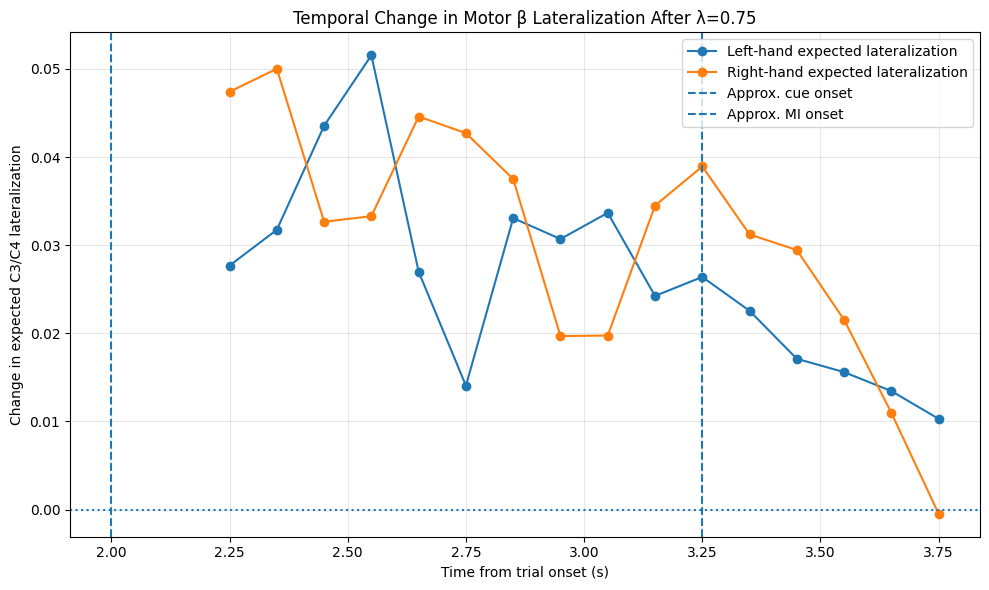

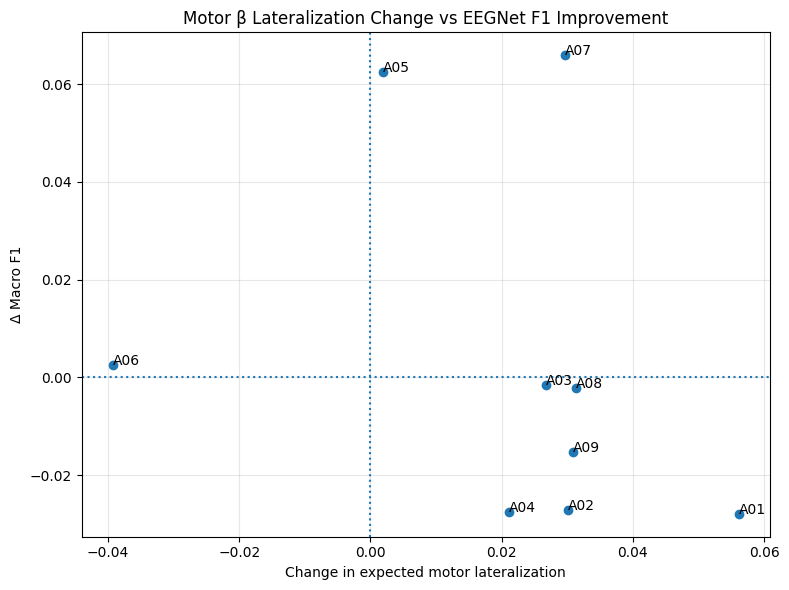



HAND-CLASS C3/C4 NORMALIZED β SUMMARY
            Raw_C3_Normalized_Beta  Clean_C3_Normalized_Beta  Raw_C4_Normalized_Beta  Clean_C4_Normalized_Beta
Class                                                                                                         
Left_Hand                -0.069895                 -0.128462               -0.051314                 -0.126511
Right_Hand               -0.060170                 -0.126297                0.018325                 -0.022594


FINAL MECHANISTIC CHECK

Expected interpretation:
Left-hand:
C4 should become relatively more negative than C3.
Right-hand:
C3 should become relatively more negative than C4.

Observed mean change in expected-direction hand lateralization:
+0.020963

Correlation with ΔF1:
Pearson r = -0.281507
Pearson p = 0.463053
Spearman ρ = -0.533333
Spearman p = 0.139227


SPATIAL MOTOR LATERALIZATION ANALYSIS COMPLETE

Mean expected-direction lateralization change:
+0.020963

Subjects with improved expected lateralizatio

In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

from scipy.io import loadmat
from scipy.signal import welch

from scipy.stats import (
    pearsonr,
    spearmanr,
    wilcoxon
)

import matplotlib.pyplot as plt

import mne

from sklearn.model_selection import train_test_split

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "spatial_motor_lateralization"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

FS_RAW = 250
FS = 125

N_EEG = 22
N_EOG = 3

LAMBDA = 0.75

SUBJECTS = [
    f"A{i:02d}"
    for i in range(1, 10)
]

BETA_LOW = 13.0
BETA_HIGH = 30.0

BASELINE_START = 0.00
BASELINE_END = 2.00

EARLY_MI_START = 3.25
EARLY_MI_END = 4.00

EEG_CHANNELS = [

    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",

    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",

    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",

    "P1",
    "Pz",
    "P2",
    "POz"

]

C3_INDEX = EEG_CHANNELS.index(
    "C3"
)

CZ_INDEX = EEG_CHANNELS.index(
    "Cz"
)

C4_INDEX = EEG_CHANNELS.index(
    "C4"
)

CLASS_NAMES = {

    1: "Left_Hand",

    2: "Right_Hand",

    3: "Feet",

    4: "Tongue"

}

HAND_CLASSES = {
    1,
    2
}

NON_HAND_CLASSES = {
    3,
    4
}

def load_bci2a_with_eog(
    mat_path
):

    """
    Load the existing 0–4 s trial representation.

    Returns:

        EEG:
            trials × samples × 22

        EOG:
            trials × samples × 3

        labels:
            four class labels

        metadata
    """

    if not os.path.exists(
        mat_path
    ):

        raise FileNotFoundError(
            f"File not found:\n{mat_path}"
        )

    mat = loadmat(

        mat_path,

        squeeze_me=False

    )

    if "data" not in mat:

        raise ValueError(
            f"'data' not found in:\n{mat_path}"
        )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    metadata = []

    for run_idx in range(
        data.shape[1]
    ):

        run_container = data[
            0,
            run_idx
        ]

        run = run_container[
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trial = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(
            trial.shape[0]
        ):

            if (
                artifacts[
                    trial_idx,
                    0
                ]
                ==
                1
            ):

                continue

            onset = int(
                trial[
                    trial_idx,
                    0
                ]
            )

            start = onset

            end = (
                onset
                +
                4 * FS_RAW
            )

            if end > X_raw.shape[0]:

                continue

            eeg = X_raw[

                start:end,

                :N_EEG

            ]

            eog = X_raw[

                start:end,

                N_EEG:N_EEG + N_EOG

            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            label = int(
                y[
                    trial_idx,
                    0
                ]
            )

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    trial_idx + 1,

                "Onset":
                    onset,

                "True_Class":
                    label

            })

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_4_38(
    X
):

    X_t = X.transpose(

        0,
        2,
        1

    )

    n_trials = X_t.shape[0]

    n_channels = X_t.shape[1]

    n_samples = X_t.shape[2]

    flattened = X_t.reshape(

        -1,

        n_samples

    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(

        n_trials,

        n_channels,

        n_samples

    )

    return filtered.transpose(

        0,
        2,
        1

    )

def fit_eog_regression(

    eeg_train,

    eog_train

):

    """
    Fit EEG ~ EOG regression using ONLY the training T trials.
    """

    eeg_flat = (

        eeg_train

        .reshape(
            -1,
            N_EEG
        )

    )

    eog_flat = (

        eog_train

        .reshape(
            -1,
            N_EOG
        )

    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    beta = np.zeros(

        (
            N_EEG,
            N_EOG
        ),

        dtype=np.float64

    )

    intercept = np.zeros(

        N_EEG,

        dtype=np.float64

    )

    for channel_idx in range(
        N_EEG
    ):

        coefficients, _, _, _ = np.linalg.lstsq(

            X,

            eeg_flat[
                :,
                channel_idx
            ],

            rcond=None

        )

        beta[
            channel_idx
        ] = coefficients[
            :N_EOG
        ]

        intercept[
            channel_idx
        ] = coefficients[
            N_EOG
        ]

    return (

        beta,

        intercept

    )

def estimate_eog_component(

    eog,

    beta,

    intercept

):

    component = np.einsum(

        "tsc,nc->tsn",

        eog,

        beta

    )

    component += (

        intercept.reshape(

            1,
            1,
            -1

        )

    )

    return component

def beta_power_trials(

    eeg,

    channel_index,

    start_s,

    end_s

):

    """
    Calculate trial-wise 13–30 Hz power.
    """

    start_sample = int(
        round(
            start_s
            *
            FS
        )
    )

    end_sample = int(
        round(
            end_s
            *
            FS
        )
    )

    segment = eeg[

        :,

        start_sample:end_sample,

        channel_index

    ]

    powers = []

    for trial_signal in segment:

        if len(
            trial_signal
        ) < 8:

            powers.append(
                np.nan
            )

            continue

        frequencies, psd = welch(

            trial_signal,

            fs=FS,

            nperseg=min(
                64,
                len(trial_signal)
            ),

            noverlap=0

        )

        mask = (

            (
                frequencies
                >=
                BETA_LOW
            )

            &

            (
                frequencies
                <=
                BETA_HIGH
            )

        )

        if mask.sum() == 0:

            powers.append(
                np.nan
            )

            continue

        power = np.trapezoid(

            psd[
                mask
            ],

            frequencies[
                mask
            ]

        )

        powers.append(
            power
        )

    return np.asarray(

        powers,

        dtype=float

    )

def normalized_beta_modulation(

    baseline_power,

    mi_power

):

    """

    M_beta =
        (MI - baseline) / baseline

    Negative:
        ERD

    Positive:
        ERS
    """

    baseline_power = np.asarray(

        baseline_power,

        dtype=float

    )

    mi_power = np.asarray(

        mi_power,

        dtype=float

    )

    modulation = (

        (
            mi_power
            -
            baseline_power
        )

        /

        (
            baseline_power
            +
            1e-12
        )

    )

    return modulation

def safe_mean(
    values
):

    values = np.asarray(
        values,
        dtype=float
    )

    if np.isfinite(
        values
    ).sum() == 0:

        return np.nan

    return np.nanmean(
        values
    )

def safe_pearson(
    x,
    y
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    mask = (

        np.isfinite(x)

        &

        np.isfinite(y)

    )

    if mask.sum() < 3:

        return (
            np.nan,
            np.nan
        )

    if (

        np.std(
            x[mask]
        )
        ==
        0

        or

        np.std(
            y[mask]
        )
        ==
        0

    ):

        return (
            np.nan,
            np.nan
        )

    return pearsonr(

        x[mask],

        y[mask]

    )

def safe_spearman(
    x,
    y
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    mask = (

        np.isfinite(x)

        &

        np.isfinite(y)

    )

    if mask.sum() < 3:

        return (
            np.nan,
            np.nan
        )

    return spearmanr(

        x[mask],

        y[mask]

    )

ALLBAND_FILE = os.path.join(

    RESULTS_DIR,

    "eegnet_allband_lambda_performance.csv"

)

FOCUSED_FILE = os.path.join(

    RESULTS_DIR,

    "eegnet_focused_lambda_performance.csv"

)

allband = pd.read_csv(

    ALLBAND_FILE

)

focused = pd.read_csv(

    FOCUSED_FILE

)

raw_perf = allband[

    np.isclose(

        allband[
            "Lambda"
        ],

        0.00

    )

].copy()

raw_perf = raw_perf[

    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]

].rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

clean_perf = focused[

    np.isclose(

        focused[
            "Lambda"
        ],

        0.75

    )

].copy()

clean_perf = clean_perf[

    [
        "Subject",
        "Accuracy",
        "Macro_F1"
    ]

].rename(

    columns={

        "Accuracy":
            "Lambda075_Accuracy",

        "Macro_F1":
            "Lambda075_F1"

    }

)

performance = (

    raw_perf

    .merge(

        clean_perf,

        on="Subject",

        how="inner"

    )

)

performance[
    "Delta_Accuracy"
] = (

    performance[
        "Lambda075_Accuracy"
    ]

    -

    performance[
        "Raw_Accuracy"
    ]

)

performance[
    "Delta_F1"
] = (

    performance[
        "Lambda075_F1"
    ]

    -

    performance[
        "Raw_F1"
    ]

)

performance = (

    performance

    .sort_values(
        "Subject"
    )

    .reset_index(
        drop=True
    )

)

trial_rows = []

subject_rows = []

class_rows = []

for subject in SUBJECTS:

    print("\n")
    print(
        "=" * 110
    )

    print(
        f"PROCESSING {subject}"
    )

    print(
        "=" * 110
    )

    train_path = os.path.join(

        DATASET_DIR,

        f"{subject}T.mat"

    )

    eval_path = os.path.join(

        DATASET_DIR,

        f"{subject}E.mat"

    )

    (
        eeg_t,
        eog_t,
        y_t,
        meta_t
    ) = load_bci2a_with_eog(

        train_path

    )

    (
        eeg_e,
        eog_e,
        y_e,
        meta_e
    ) = load_bci2a_with_eog(

        eval_path

    )

    print(
        "Training trials:",
        len(y_t)
    )

    print(
        "Evaluation trials:",
        len(y_e)
    )

    eeg_t_filt = filter_4_38(
        eeg_t
    )

    eog_t_filt = filter_4_38(
        eog_t
    )

    eeg_e_filt = filter_4_38(
        eeg_e
    )

    eog_e_filt = filter_4_38(
        eog_e
    )

    train_idx, val_idx = (

        train_test_split(

            np.arange(
                len(y_t)
            ),

            test_size=0.20,

            stratify=y_t,

            random_state=SEED

        )

    )

    (
        beta,
        intercept
    ) = fit_eog_regression(

        eeg_t_filt[
            train_idx
        ],

        eog_t_filt[
            train_idx
        ]

    )

    eog_component = (

        estimate_eog_component(

            eog_e_filt,

            beta,

            intercept

        )

    )

    eeg_raw = (
        eeg_e_filt.copy()
    )

    eeg_clean = (

        eeg_e_filt

        -

        LAMBDA
        *
        eog_component

    )

    perf = performance[

        performance[
            "Subject"
        ]
        ==
        subject

    ]

    if len(perf) != 1:

        raise ValueError(
            f"Performance missing for {subject}"
        )

    perf = perf.iloc[
        0
    ]

    delta_accuracy = float(

        perf[
            "Delta_Accuracy"
        ]

    )

    delta_f1 = float(

        perf[
            "Delta_F1"
        ]

    )

    raw_baseline_c3 = beta_power_trials(

        eeg_raw,

        C3_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    raw_baseline_cz = beta_power_trials(

        eeg_raw,

        CZ_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    raw_baseline_c4 = beta_power_trials(

        eeg_raw,

        C4_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    clean_baseline_c3 = beta_power_trials(

        eeg_clean,

        C3_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    clean_baseline_cz = beta_power_trials(

        eeg_clean,

        CZ_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    clean_baseline_c4 = beta_power_trials(

        eeg_clean,

        C4_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    raw_mi_c3 = beta_power_trials(

        eeg_raw,

        C3_INDEX,

        EARLY_MI_START,

        EARLY_MI_END

    )

    raw_mi_cz = beta_power_trials(

        eeg_raw,

        CZ_INDEX,

        EARLY_MI_START,

        EARLY_MI_END

    )

    raw_mi_c4 = beta_power_trials(

        eeg_raw,

        C4_INDEX,

        EARLY_MI_START,

        EARLY_MI_END

    )

    clean_mi_c3 = beta_power_trials(

        eeg_clean,

        C3_INDEX,

        EARLY_MI_START,

        EARLY_MI_END

    )

    clean_mi_cz = beta_power_trials(

        eeg_clean,

        CZ_INDEX,

        EARLY_MI_START,

        EARLY_MI_END

    )

    clean_mi_c4 = beta_power_trials(

        eeg_clean,

        C4_INDEX,

        EARLY_MI_START,

        EARLY_MI_END

    )

    raw_mod_c3 = normalized_beta_modulation(

        raw_baseline_c3,

        raw_mi_c3

    )

    raw_mod_cz = normalized_beta_modulation(

        raw_baseline_cz,

        raw_mi_cz

    )

    raw_mod_c4 = normalized_beta_modulation(

        raw_baseline_c4,

        raw_mi_c4

    )

    clean_mod_c3 = normalized_beta_modulation(

        clean_baseline_c3,

        clean_mi_c3

    )

    clean_mod_cz = normalized_beta_modulation(

        clean_baseline_cz,

        clean_mi_cz

    )

    clean_mod_c4 = normalized_beta_modulation(

        clean_baseline_c4,

        clean_mi_c4

    )

    raw_li = (

        raw_mod_c3

        -

        raw_mod_c4

    )

    clean_li = (

        clean_mod_c3

        -

        clean_mod_c4

    )

    delta_li = (

        clean_li

        -

        raw_li

    )

    for trial_index in range(
        len(y_e)
    ):

        class_id = int(
            y_e[
                trial_index
            ]
        )

        class_name = CLASS_NAMES[
            class_id
        ]

        raw_c3 = raw_mod_c3[
            trial_index
        ]

        clean_c3 = clean_mod_c3[
            trial_index
        ]

        raw_c4 = raw_mod_c4[
            trial_index
        ]

        clean_c4 = clean_mod_c4[
            trial_index
        ]

        raw_cz = raw_mod_cz[
            trial_index
        ]

        clean_cz = clean_mod_cz[
            trial_index
        ]

        raw_lateralization = (

            raw_c3

            -

            raw_c4

        )

        clean_lateralization = (

            clean_c3

            -

            clean_c4

        )

        delta_lateralization = (

            clean_lateralization

            -

            raw_lateralization

        )

        if class_id == 1:

            raw_expected = (
                raw_lateralization
            )

            clean_expected = (
                clean_lateralization
            )

        elif class_id == 2:

            raw_expected = (

                -raw_lateralization

            )

            clean_expected = (

                -clean_lateralization

            )

        else:

            raw_expected = np.nan

            clean_expected = np.nan

        if (

            np.isfinite(
                raw_expected
            )

            and

            np.isfinite(
                clean_expected
            )

        ):

            delta_expected = (

                clean_expected
                -
                raw_expected

            )

        else:

            delta_expected = np.nan

        trial_rows.append({

            "Subject":
                subject,

            "Trial_Index":
                trial_index,

            "Class_ID":
                class_id,

            "Class":
                class_name,

            "Raw_C3_Normalized_Beta":
                raw_c3,

            "Clean_C3_Normalized_Beta":
                clean_c3,

            "Raw_Cz_Normalized_Beta":
                raw_cz,

            "Clean_Cz_Normalized_Beta":
                clean_cz,

            "Raw_C4_Normalized_Beta":
                raw_c4,

            "Clean_C4_Normalized_Beta":
                clean_c4,

            "Raw_C3_minus_C4":
                raw_lateralization,

            "Clean_C3_minus_C4":
                clean_lateralization,

            "Delta_C3_minus_C4":
                delta_lateralization,

            "Raw_Expected_Hand_Lateralization":
                raw_expected,

            "Clean_Expected_Hand_Lateralization":
                clean_expected,

            "Delta_Expected_Hand_Lateralization":
                delta_expected,

            "Delta_Accuracy":
                delta_accuracy,

            "Delta_F1":
                delta_f1

        })

    for class_id, class_name in CLASS_NAMES.items():

        class_mask = (

            y_e
            ==
            class_id

        )

        if class_mask.sum() == 0:

            continue

        class_li_raw = np.nanmean(

            raw_li[
                class_mask
            ]

        )

        class_li_clean = np.nanmean(

            clean_li[
                class_mask
            ]

        )

        class_li_delta = (

            class_li_clean
            -
            class_li_raw

        )

        raw_class_c3 = np.nanmean(

            raw_mod_c3[
                class_mask
            ]

        )

        clean_class_c3 = np.nanmean(

            clean_mod_c3[
                class_mask
            ]

        )

        raw_class_cz = np.nanmean(

            raw_mod_cz[
                class_mask
            ]

        )

        clean_class_cz = np.nanmean(

            clean_mod_cz[
                class_mask
            ]

        )

        raw_class_c4 = np.nanmean(

            raw_mod_c4[
                class_mask
            ]

        )

        clean_class_c4 = np.nanmean(

            clean_mod_c4[
                class_mask
            ]

        )

        if class_id == 1:

            raw_expected = (
                class_li_raw
            )

            clean_expected = (
                class_li_clean
            )

        elif class_id == 2:

            raw_expected = (
                -class_li_raw
            )

            clean_expected = (
                -class_li_clean
            )

        else:

            raw_expected = np.nan
            clean_expected = np.nan

        if np.isfinite(
            raw_expected
        ):

            expected_delta = (

                clean_expected
                -
                raw_expected

            )

        else:

            expected_delta = np.nan

        class_rows.append({

            "Subject":
                subject,

            "Class_ID":
                class_id,

            "Class":
                class_name,

            "N_Trials":
                int(
                    class_mask.sum()
                ),

            "Raw_C3_Normalized_Beta":
                raw_class_c3,

            "Clean_C3_Normalized_Beta":
                clean_class_c3,

            "Raw_Cz_Normalized_Beta":
                raw_class_cz,

            "Clean_Cz_Normalized_Beta":
                clean_class_cz,

            "Raw_C4_Normalized_Beta":
                raw_class_c4,

            "Clean_C4_Normalized_Beta":
                clean_class_c4,

            "Raw_C3_minus_C4":
                class_li_raw,

            "Clean_C3_minus_C4":
                class_li_clean,

            "Delta_C3_minus_C4":
                class_li_delta,

            "Raw_Expected_Hand_Lateralization":
                raw_expected,

            "Clean_Expected_Hand_Lateralization":
                clean_expected,

            "Delta_Expected_Hand_Lateralization":
                expected_delta,

            "Delta_Accuracy":
                delta_accuracy,

            "Delta_F1":
                delta_f1

        })

    hand_mask = (

        (y_e == 1)

        |

        (y_e == 2)

    )

    if hand_mask.sum() > 0:

        hand_raw_li = np.nanmean(

            raw_li[
                hand_mask
            ]

        )

        hand_clean_li = np.nanmean(

            clean_li[
                hand_mask
            ]

        )

        expected_values_raw = []

        expected_values_clean = []

        hand_trial_indices = np.where(
            hand_mask
        )[0]

        for idx in hand_trial_indices:

            class_id = int(
                y_e[
                    idx
                ]
            )

            if class_id == 1:

                expected_values_raw.append(

                    raw_li[
                        idx
                    ]

                )

                expected_values_clean.append(

                    clean_li[
                        idx
                    ]

                )

            elif class_id == 2:

                expected_values_raw.append(

                    -raw_li[
                        idx
                    ]

                )

                expected_values_clean.append(

                    -clean_li[
                        idx
                    ]

                )

        expected_values_raw = np.asarray(
            expected_values_raw,
            dtype=float
        )

        expected_values_clean = np.asarray(
            expected_values_clean,
            dtype=float
        )

        raw_expected_hand = np.nanmean(

            expected_values_raw

        )

        clean_expected_hand = np.nanmean(

            expected_values_clean

        )

        delta_expected_hand = (

            clean_expected_hand
            -
            raw_expected_hand

        )

    else:

        hand_raw_li = np.nan

        hand_clean_li = np.nan

        raw_expected_hand = np.nan

        clean_expected_hand = np.nan

        delta_expected_hand = np.nan

    subject_rows.append({

        "Subject":
            subject,

        "Raw_Hand_Lateralization":
            hand_raw_li,

        "Clean_Hand_Lateralization":
            hand_clean_li,

        "Delta_Hand_Lateralization":
            (
                hand_clean_li
                -
                hand_raw_li
            ),

        "Raw_Expected_Hand_Lateralization":
            raw_expected_hand,

        "Clean_Expected_Hand_Lateralization":
            clean_expected_hand,

        "Delta_Expected_Hand_Lateralization":
            delta_expected_hand,

        "Delta_Accuracy":
            delta_accuracy,

        "Delta_F1":
            delta_f1

    })

    print(
        "\nHand lateralization:"
    )

    print(
        f"Raw = {hand_raw_li:+.6f}"
    )

    print(
        f"Clean = {hand_clean_li:+.6f}"
    )

    print(
        f"Change = "
        f"{hand_clean_li - hand_raw_li:+.6f}"
    )

    print(
        "Expected-direction hand score:"
    )

    print(
        f"Raw = {raw_expected_hand:+.6f}"
    )

    print(
        f"Clean = {clean_expected_hand:+.6f}"
    )

    print(
        f"Change = {delta_expected_hand:+.6f}"
    )

trial_df = pd.DataFrame(
    trial_rows
)

subject_df = pd.DataFrame(
    subject_rows
)

class_df = pd.DataFrame(
    class_rows
)

print("\n")
print("=" * 110)
print(
    "SUBJECT-LEVEL MOTOR LATERALIZATION"
)
print("=" * 110)

print(

    subject_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print("=" * 110)
print(
    "CLASS-SPECIFIC MOTOR LATERALIZATION"
)
print("=" * 110)

print(

    class_df.round(
        6
    ).to_string(
        index=False
    )

)

raw_expected = subject_df[
    "Raw_Expected_Hand_Lateralization"
].to_numpy(
    dtype=float
)

clean_expected = subject_df[
    "Clean_Expected_Hand_Lateralization"
].to_numpy(
    dtype=float
)

delta_expected = subject_df[
    "Delta_Expected_Hand_Lateralization"
].to_numpy(
    dtype=float
)

print("\n")
print("=" * 110)
print(
    "EXPECTED HAND-LATERALIZATION CHANGE"
)
print("=" * 110)

print(
    "Mean Raw:",
    f"{np.nanmean(raw_expected):+.6f}"
)

print(
    "Mean Clean:",
    f"{np.nanmean(clean_expected):+.6f}"
)

print(
    "Mean Change:",
    f"{np.nanmean(delta_expected):+.6f}"
)

print(
    "Subjects improved:",
    int(
        np.sum(
            delta_expected > 0
        )
    ),
    "/",
    len(delta_expected)
)

valid = (

    np.isfinite(
        raw_expected
    )

    &

    np.isfinite(
        clean_expected
    )

)

raw_valid = raw_expected[
    valid
]

clean_valid = clean_expected[
    valid
]

print("\n")
print("=" * 110)
print(
    "WILCOXON: RAW vs CLEAN EXPECTED HAND LATERALIZATION"
)
print("=" * 110)

if len(raw_valid) >= 3:

    try:

        w_stat, w_p = wilcoxon(

            clean_valid,

            raw_valid

        )

    except Exception:

        w_stat = np.nan
        w_p = np.nan

    print(
        f"W = {w_stat:.6f}"
    )

    print(
        f"p = {w_p:.6f}"
    )

else:

    w_stat = np.nan
    w_p = np.nan

    print(
        "Insufficient valid subjects."
    )

print("\n")
print("=" * 110)
print(
    "LATERALIZATION CHANGE vs EEGNET ACCURACY"
)
print("=" * 110)

x = subject_df[
    "Delta_Expected_Hand_Lateralization"
].to_numpy(
    dtype=float
)

y = subject_df[
    "Delta_Accuracy"
].to_numpy(
    dtype=float
)

acc_r, acc_p = safe_pearson(
    x,
    y
)

acc_rho, acc_rho_p = safe_spearman(
    x,
    y
)

print(
    f"Pearson r = {acc_r:.6f}"
)

print(
    f"Pearson p = {acc_p:.6f}"
)

print(
    f"Spearman ρ = {acc_rho:.6f}"
)

print(
    f"Spearman p = {acc_rho_p:.6f}"
)

print("\n")
print("=" * 110)
print(
    "LATERALIZATION CHANGE vs EEGNET F1"
)
print("=" * 110)

y_f1 = subject_df[
    "Delta_F1"
].to_numpy(
    dtype=float
)

f1_r, f1_p = safe_pearson(
    x,
    y_f1
)

f1_rho, f1_rho_p = safe_spearman(
    x,
    y_f1
)

print(
    f"Pearson r = {f1_r:.6f}"
)

print(
    f"Pearson p = {f1_p:.6f}"
)

print(
    f"Spearman ρ = {f1_rho:.6f}"
)

print(
    f"Spearman p = {f1_rho_p:.6f}"
)

print("\n")
print("=" * 110)
print(
    "LEFT-HAND SPATIAL EFFECT"
)
print("=" * 110)

left_df = class_df[
    class_df[
        "Class_ID"
    ]
    ==
    1
].copy()

left_changes = left_df[
    "Delta_Expected_Hand_Lateralization"
].to_numpy(
    dtype=float
)

print(
    "Mean change:",
    f"{np.nanmean(left_changes):+.6f}"
)

print(
    "Subjects improved:",
    int(
        np.sum(
            left_changes > 0
        )
    ),
    "/",
    len(left_changes)
)

if len(left_changes) >= 3:

    try:

        left_w, left_p = wilcoxon(
            left_df[
                "Clean_Expected_Hand_Lateralization"
            ],
            left_df[
                "Raw_Expected_Hand_Lateralization"
            ]
        )

    except Exception:

        left_w = np.nan
        left_p = np.nan

    print(
        f"Wilcoxon W = {left_w:.6f}"
    )

    print(
        f"Wilcoxon p = {left_p:.6f}"
    )

else:

    left_w = np.nan
    left_p = np.nan

print("\n")
print("=" * 110)
print(
    "RIGHT-HAND SPATIAL EFFECT"
)
print("=" * 110)

right_df = class_df[
    class_df[
        "Class_ID"
    ]
    ==
    2
].copy()

right_changes = right_df[
    "Delta_Expected_Hand_Lateralization"
].to_numpy(
    dtype=float
)

print(
    "Mean change:",
    f"{np.nanmean(right_changes):+.6f}"
)

print(
    "Subjects improved:",
    int(
        np.sum(
            right_changes > 0
        )
    ),
    "/",
    len(right_changes)
)

if len(right_changes) >= 3:

    try:

        right_w, right_p = wilcoxon(

            right_df[
                "Clean_Expected_Hand_Lateralization"
            ],

            right_df[
                "Raw_Expected_Hand_Lateralization"
            ]

        )

    except Exception:

        right_w = np.nan
        right_p = np.nan

    print(
        f"Wilcoxon W = {right_w:.6f}"
    )

    print(
        f"Wilcoxon p = {right_p:.6f}"
    )

else:

    right_w = np.nan
    right_p = np.nan

print("\n")
print("=" * 110)
print(
    "RAW vs CLEAN C3/C4 NORMALIZED β MODULATION"
)
print("=" * 110)

hand_class_df = class_df[
    class_df[
        "Class_ID"
    ].isin(
        [1, 2]
    )
].copy()

print(
    hand_class_df[
        [
            "Subject",
            "Class",
            "Raw_C3_Normalized_Beta",
            "Clean_C3_Normalized_Beta",
            "Raw_C4_Normalized_Beta",
            "Clean_C4_Normalized_Beta",
            "Delta_C3_minus_C4",
            "Delta_Expected_Hand_Lateralization"

        ]
    ]
    .round(6)
    .to_string(
        index=False
    )
)

TEMPORAL_STARTS = np.arange(

    2.0,

    4.0
    -
    0.50
    +
    1e-9,

    0.10

)

TEMPORAL_ENDS = (

    TEMPORAL_STARTS
    +
    0.50

)

temporal_rows = []

for subject in SUBJECTS:

    print(
        f"\nTemporal analysis: {subject}"
    )

    train_path = os.path.join(

        DATASET_DIR,

        f"{subject}T.mat"

    )

    eval_path = os.path.join(

        DATASET_DIR,

        f"{subject}E.mat"

    )

    (
        eeg_t,
        eog_t,
        y_t,
        _
    ) = load_bci2a_with_eog(

        train_path

    )

    (
        eeg_e,
        eog_e,
        y_e,
        _
    ) = load_bci2a_with_eog(

        eval_path

    )

    eeg_t_filt = filter_4_38(
        eeg_t
    )

    eog_t_filt = filter_4_38(
        eog_t
    )

    eeg_e_filt = filter_4_38(
        eeg_e
    )

    eog_e_filt = filter_4_38(
        eog_e
    )

    train_idx, _ = train_test_split(

        np.arange(
            len(y_t)
        ),

        test_size=0.20,

        stratify=y_t,

        random_state=SEED

    )

    beta, intercept = fit_eog_regression(

        eeg_t_filt[
            train_idx
        ],

        eog_t_filt[
            train_idx
        ]

    )

    component = estimate_eog_component(

        eog_e_filt,

        beta,

        intercept

    )

    raw = eeg_e_filt

    clean = (

        eeg_e_filt
        -
        LAMBDA
        *
        component

    )

    raw_base_c3 = beta_power_trials(

        raw,

        C3_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    raw_base_c4 = beta_power_trials(

        raw,

        C4_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    clean_base_c3 = beta_power_trials(

        clean,

        C3_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    clean_base_c4 = beta_power_trials(

        clean,

        C4_INDEX,

        BASELINE_START,

        BASELINE_END

    )

    for start_s, end_s in zip(

        TEMPORAL_STARTS,

        TEMPORAL_ENDS

    ):

        raw_win_c3 = beta_power_trials(

            raw,

            C3_INDEX,

            start_s,

            end_s

        )

        raw_win_c4 = beta_power_trials(

            raw,

            C4_INDEX,

            start_s,

            end_s

        )

        clean_win_c3 = beta_power_trials(

            clean,

            C3_INDEX,

            start_s,

            end_s

        )

        clean_win_c4 = beta_power_trials(

            clean,

            C4_INDEX,

            start_s,

            end_s

        )

        raw_mod_c3 = normalized_beta_modulation(

            raw_base_c3,

            raw_win_c3

        )

        raw_mod_c4 = normalized_beta_modulation(

            raw_base_c4,

            raw_win_c4

        )

        clean_mod_c3 = normalized_beta_modulation(

            clean_base_c3,

            clean_win_c3

        )

        clean_mod_c4 = normalized_beta_modulation(

            clean_base_c4,

            clean_win_c4

        )

        raw_li = (

            raw_mod_c3

            -

            raw_mod_c4

        )

        clean_li = (

            clean_mod_c3

            -

            clean_mod_c4

        )

        delta_li = (

            clean_li
            -
            raw_li

        )

        left_mask = (
            y_e == 1
        )

        right_mask = (
            y_e == 2
        )

        if left_mask.sum() > 0:

            left_raw = np.nanmean(

                raw_li[
                    left_mask
                ]

            )

            left_clean = np.nanmean(

                clean_li[
                    left_mask
                ]

            )

        else:

            left_raw = np.nan
            left_clean = np.nan

        if right_mask.sum() > 0:

            right_raw = np.nanmean(

                -raw_li[
                    right_mask
                ]

            )

            right_clean = np.nanmean(

                -clean_li[
                    right_mask
                ]

            )

        else:

            right_raw = np.nan
            right_clean = np.nan

        temporal_rows.append({

            "Subject":
                subject,

            "Window_Start_s":
                start_s,

            "Window_End_s":
                end_s,

            "Window_Center_s":
                (
                    start_s
                    +
                    end_s
                )
                /
                2.0,

            "Raw_Left_Hand_Lateralization":
                left_raw,

            "Clean_Left_Hand_Lateralization":
                left_clean,

            "Delta_Left_Hand_Lateralization":
                (
                    left_clean
                    -
                    left_raw
                ),

            "Raw_Right_Hand_Lateralization":
                right_raw,

            "Clean_Right_Hand_Lateralization":
                right_clean,

            "Delta_Right_Hand_Lateralization":
                (
                    right_clean
                    -
                    right_raw
                )

        })

temporal_df = pd.DataFrame(
    temporal_rows
)

temporal_summary = (

    temporal_df

    .groupby(
        "Window_Center_s"
    )[

        [
            "Delta_Left_Hand_Lateralization",
            "Delta_Right_Hand_Lateralization"

        ]

    ]

    .mean()

)

print("\n")
print("=" * 110)
print(
    "TEMPORAL MOTOR LATERALIZATION CHANGE"
)
print("=" * 110)

print(

    temporal_summary.round(
        6
    ).to_string()

)

plt.figure(
    figsize=(10, 6)
)

plt.plot(

    temporal_summary.index,

    temporal_summary[
        "Delta_Left_Hand_Lateralization"
    ],

    marker="o",

    label="Left-hand expected lateralization"

)

plt.plot(

    temporal_summary.index,

    temporal_summary[
        "Delta_Right_Hand_Lateralization"
    ],

    marker="o",

    label="Right-hand expected lateralization"

)

plt.axvline(

    2.0,

    linestyle="--",

    label="Approx. cue onset"

)

plt.axvline(

    3.25,

    linestyle="--",

    label="Approx. MI onset"

)

plt.axhline(

    0.0,

    linestyle=":"

)

plt.xlabel(
    "Time from trial onset (s)"
)

plt.ylabel(
    "Change in expected C3/C4 lateralization"
)

plt.title(
    "Temporal Change in Motor β Lateralization After λ=0.75"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

temporal_plot_file = os.path.join(

    FIGURE_DIR,

    "temporal_motor_lateralization.png"

)

plt.savefig(

    temporal_plot_file,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(8, 6)
)

plt.scatter(

    subject_df[
        "Delta_Expected_Hand_Lateralization"
    ],

    subject_df[
        "Delta_F1"
    ]

)

for _, row in subject_df.iterrows():

    plt.annotate(

        row[
            "Subject"
        ],

        (

            row[
                "Delta_Expected_Hand_Lateralization"
            ],

            row[
                "Delta_F1"
            ]

        )

    )

plt.axhline(
    0.0,
    linestyle=":"
)

plt.axvline(
    0.0,
    linestyle=":"
)

plt.xlabel(
    "Change in expected motor lateralization"
)

plt.ylabel(
    "Δ Macro F1"
)

plt.title(
    "Motor β Lateralization Change vs EEGNet F1 Improvement"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

f1_plot_file = os.path.join(

    FIGURE_DIR,

    "motor_lateralization_vs_delta_f1.png"

)

plt.savefig(

    f1_plot_file,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

hand_summary = (

    hand_class_df

    .groupby(
        "Class"
    )[

        [

            "Raw_C3_Normalized_Beta",
            "Clean_C3_Normalized_Beta",

            "Raw_C4_Normalized_Beta",
            "Clean_C4_Normalized_Beta"

        ]

    ]

    .mean()

)

print("\n")
print("=" * 110)
print(
    "HAND-CLASS C3/C4 NORMALIZED β SUMMARY"
)
print("=" * 110)

print(

    hand_summary.round(
        6
    ).to_string()

)

print("\n")
print("=" * 110)
print(
    "FINAL MECHANISTIC CHECK"
)
print("=" * 110)

print(
    "\nExpected interpretation:"
)

print(
    "Left-hand:"
)

print(
    "C4 should become relatively more negative than C3."
)

print(
    "Right-hand:"
)

print(
    "C3 should become relatively more negative than C4."
)

print(
    "\nObserved mean change in expected-direction "
    "hand lateralization:"
)

print(
    f"{np.nanmean(delta_expected):+.6f}"
)

print(
    "\nCorrelation with ΔF1:"
)

print(
    f"Pearson r = {f1_r:.6f}"
)

print(
    f"Pearson p = {f1_p:.6f}"
)

print(
    f"Spearman ρ = {f1_rho:.6f}"
)

print(
    f"Spearman p = {f1_rho_p:.6f}"
)

trial_file = os.path.join(

    OUTPUT_DIR,

    "trial_level_motor_lateralization_lambda075.csv"

)

trial_df.to_csv(

    trial_file,

    index=False

)

subject_file = os.path.join(

    OUTPUT_DIR,

    "subject_motor_lateralization_lambda075.csv"

)

subject_df.to_csv(

    subject_file,

    index=False

)

class_file = os.path.join(

    OUTPUT_DIR,

    "class_motor_lateralization_lambda075.csv"

)

class_df.to_csv(

    class_file,

    index=False

)

temporal_file = os.path.join(

    OUTPUT_DIR,

    "temporal_motor_lateralization_lambda075.csv"

)

temporal_df.to_csv(

    temporal_file,

    index=False

)

temporal_summary_file = os.path.join(

    OUTPUT_DIR,

    "temporal_motor_lateralization_summary.csv"

)

temporal_summary.to_csv(

    temporal_summary_file

)

correlation_df = pd.DataFrame({

    "Metric": [

        "Expected_Hand_Lateralization_Change_vs_Accuracy_Pearson_r",

        "Expected_Hand_Lateralization_Change_vs_Accuracy_Pearson_p",

        "Expected_Hand_Lateralization_Change_vs_Accuracy_Spearman_rho",

        "Expected_Hand_Lateralization_Change_vs_Accuracy_Spearman_p",

        "Expected_Hand_Lateralization_Change_vs_F1_Pearson_r",

        "Expected_Hand_Lateralization_Change_vs_F1_Pearson_p",

        "Expected_Hand_Lateralization_Change_vs_F1_Spearman_rho",

        "Expected_Hand_Lateralization_Change_vs_F1_Spearman_p",

        "Raw_vs_Clean_Wilcoxon_W",

        "Raw_vs_Clean_Wilcoxon_p",

        "Left_Hand_Wilcoxon_W",

        "Left_Hand_Wilcoxon_p",

        "Right_Hand_Wilcoxon_W",

        "Right_Hand_Wilcoxon_p"

    ],

    "Value": [

        acc_r,

        acc_p,

        acc_rho,

        acc_rho_p,

        f1_r,

        f1_p,

        f1_rho,

        f1_rho_p,

        w_stat,

        w_p,

        left_w,

        left_p,

        right_w,

        right_p

    ]

})

correlation_file = os.path.join(

    OUTPUT_DIR,

    "motor_lateralization_statistics.csv"

)

correlation_df.to_csv(

    correlation_file,

    index=False

)

final_summary = pd.DataFrame({

    "Metric": [

        "Mean_Raw_Expected_Hand_Lateralization",

        "Mean_Clean_Expected_Hand_Lateralization",

        "Mean_Change_Expected_Hand_Lateralization",

        "Subjects_Improved",

        "Wilcoxon_W",

        "Wilcoxon_p",

        "Accuracy_Pearson_r",

        "Accuracy_Pearson_p",

        "Accuracy_Spearman_rho",

        "Accuracy_Spearman_p",

        "F1_Pearson_r",

        "F1_Pearson_p",

        "F1_Spearman_rho",

        "F1_Spearman_p"

    ],

    "Value": [

        np.nanmean(
            raw_expected
        ),

        np.nanmean(
            clean_expected
        ),

        np.nanmean(
            delta_expected
        ),

        np.sum(
            delta_expected > 0
        ),

        w_stat,

        w_p,

        acc_r,

        acc_p,

        acc_rho,

        acc_rho_p,

        f1_r,

        f1_p,

        f1_rho,

        f1_rho_p

    ]

})

final_summary_file = os.path.join(

    OUTPUT_DIR,

    "motor_lateralization_final_summary.csv"

)

final_summary.to_csv(

    final_summary_file,

    index=False

)

print("\n")
print("=" * 110)
print(
    "SPATIAL MOTOR LATERALIZATION ANALYSIS COMPLETE"
)
print("=" * 110)

print(
    "\nMean expected-direction lateralization change:"
)

print(
    f"{np.nanmean(delta_expected):+.6f}"
)

print(
    "\nSubjects with improved expected lateralization:"
)

print(

    f"{np.sum(delta_expected > 0)} / "
    f"{len(delta_expected)}"

)

print(
    "\nRaw vs Clean Wilcoxon:"
)

print(
    f"W = {w_stat:.6f}, "
    f"p = {w_p:.6f}"
)

print(
    "\nCorrelation with ΔAccuracy:"
)

print(
    f"r = {acc_r:.6f}, "
    f"p = {acc_p:.6f}"
)

print(
    "\nCorrelation with ΔF1:"
)

print(
    f"r = {f1_r:.6f}, "
    f"p = {f1_p:.6f}"
)

print(
    "\nImportant files:"
)

print(
    trial_file
)

print(
    subject_file
)

print(
    class_file
)

print(
    temporal_file
)

print(
    correlation_file
)

print(
    final_summary_file
)

print("\n")
print("=" * 110)
print(
    "DONE"
)
print("=" * 110)


## EEGNet Feature-Space Analysis

Using device: cuda


PROCESSING A01
Filtering EEG...
Filtering EOG...
Fitting training-only EOG regression...

Training RAW EEGNet...
Training λ=0.75 EEGNet...
Extracting RAW test features...
Extracting CLEAN test features...

Raw Accuracy: 0.6228
Clean Accuracy: 0.6263
ΔAccuracy: +0.0036
Raw F1: 0.6151
Clean F1: 0.6206
ΔF1: +0.0055
Raw separation ratio: 0.6448
Clean separation ratio: 0.5809
Δ separation ratio: -0.0638
Raw silhouette: -0.0025
Clean silhouette: 0.0063
Δ silhouette: +0.0088


PROCESSING A02
Filtering EEG...
Filtering EOG...
Fitting training-only EOG regression...

Training RAW EEGNet...
Training λ=0.75 EEGNet...
Extracting RAW test features...
Extracting CLEAN test features...

Raw Accuracy: 0.3428
Clean Accuracy: 0.2968
ΔAccuracy: -0.0459
Raw F1: 0.3287
Clean F1: 0.2564
ΔF1: -0.0723
Raw separation ratio: 0.1953
Clean separation ratio: 0.1735
Δ separation ratio: -0.0218
Raw silhouette: -0.0226
Clean silhouette: -0.0304
Δ silhouette: -0.0078


PROCESSING A03
Filtering EEG

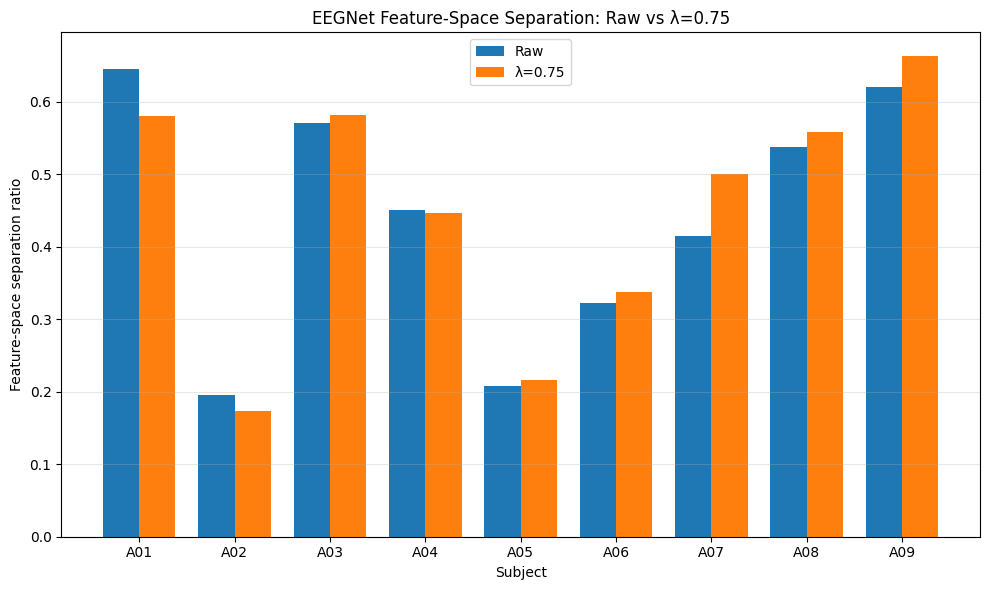

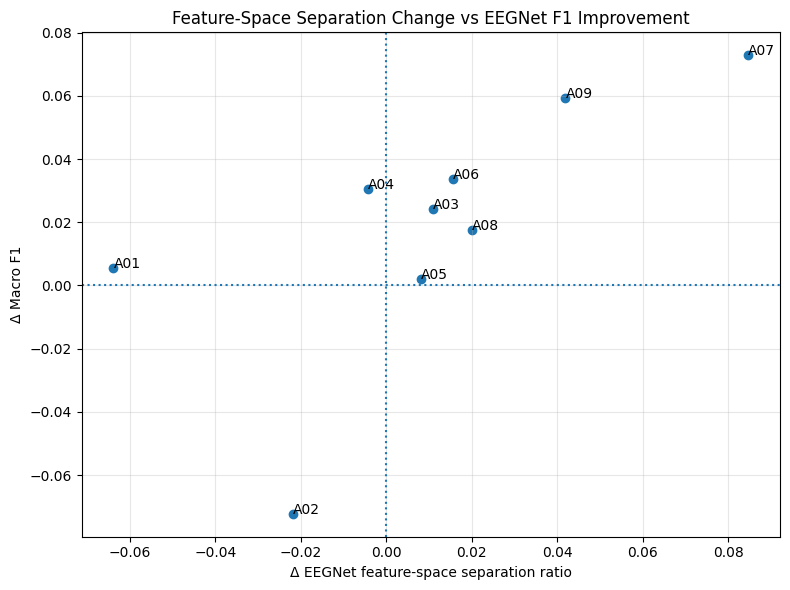

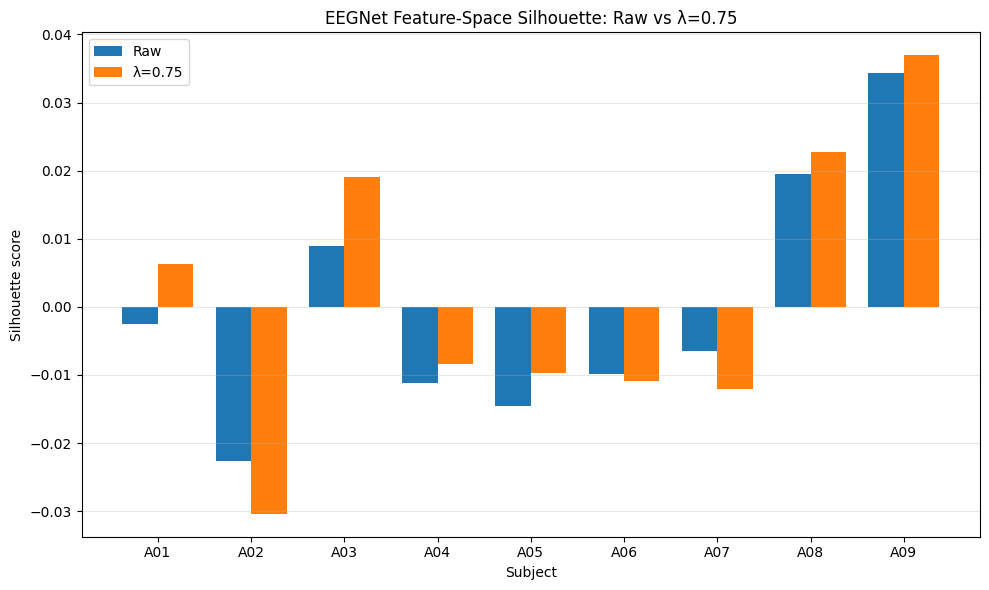

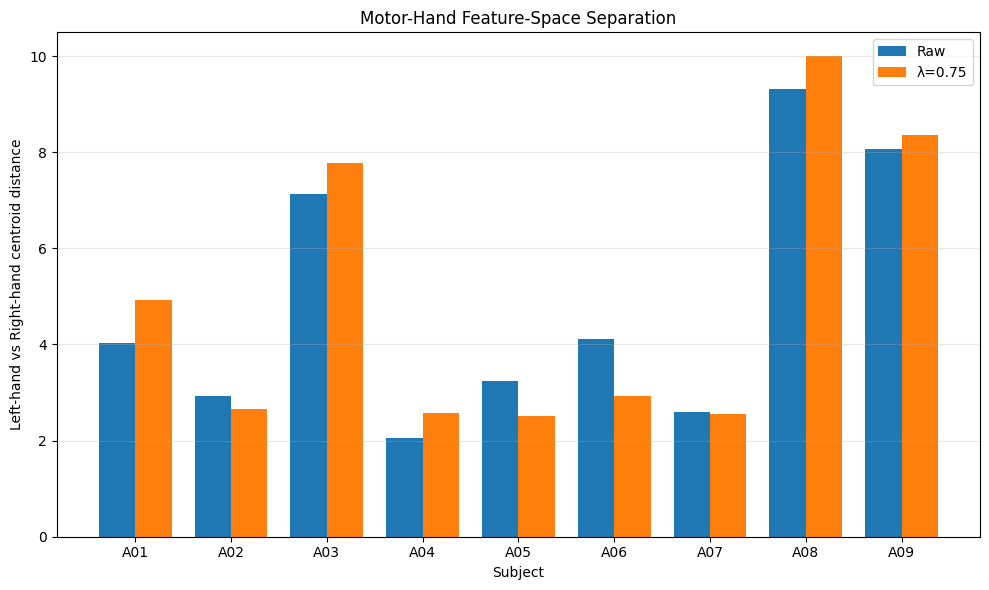



FINAL EEGNET FEATURE-SPACE ANALYSIS

Mean ΔAccuracy: +0.02393
Mean ΔF1: +0.01932

Mean Δ between-class distance: +0.129991
Mean Δ within-class distance: -0.071559
Mean Δ separation ratio: +0.010122
Mean Δ silhouette: +0.002018
Mean Δ left-vs-right distance: +0.091043

Subjects with improved separation ratio: 6 / 9
Subjects with improved silhouette: 6 / 9

Output directory: /content/drive/MyDrive/BCC/results/eegnet_feature_space

Files saved:
/content/drive/MyDrive/BCC/results/eegnet_feature_space/subject_eegnet_feature_space_results.csv
/content/drive/MyDrive/BCC/results/eegnet_feature_space/pairwise_feature_space_distances.csv
/content/drive/MyDrive/BCC/results/eegnet_feature_space/feature_space_paired_statistics.csv
/content/drive/MyDrive/BCC/results/eegnet_feature_space/feature_space_vs_eegnet_benefit.csv
/content/drive/MyDrive/BCC/results/eegnet_feature_space/eegnet_feature_space_final_summary.csv


EEGNET FEATURE-SPACE ANALYSIS COMPLETE


In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from scipy.io import loadmat

from numpy.linalg import lstsq

from scipy.stats import (
    pearsonr,
    spearmanr,
    wilcoxon
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    silhouette_score
)

import mne

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "eegnet_feature_space"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

SEED = 42

def set_seed(
    seed=SEED
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

set_seed()

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else
    "cpu"

)

print(
    "Using device:",
    device
)

FS_RAW = 250
FS_MODEL = 125

N_EEG = 22
N_EOG = 3

BATCH_SIZE = 16

MAX_EPOCHS = 200

LEARNING_RATE = 0.001

LAMBDA = 0.75

SUBJECTS = [

    f"A{i:02d}"

    for i in range(
        1,
        10
    )

]

class EEGNet(
    nn.Module
):

    def __init__(

        self,

        num_channels=22,

        num_classes=4,

        samples=500,

        F1=16,

        D=2,

        F2=32,

        dropout=0.5,

        kern_length=64

    ):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(

                1,

                F1,

                (
                    1,
                    kern_length
                ),

                padding=(

                    0,

                    kern_length // 2

                ),

                bias=False

            ),

            nn.BatchNorm2d(
                F1
            ),

            nn.Conv2d(

                F1,

                F1 * D,

                (
                    num_channels,
                    1
                ),

                groups=F1,

                bias=False

            ),

            nn.BatchNorm2d(

                F1 * D

            ),

            nn.ELU(),

            nn.AvgPool2d(

                (
                    1,
                    8
                )

            ),

            nn.Dropout(
                dropout
            )

        )

        self.block2 = nn.Sequential(

            nn.Conv2d(

                F1 * D,

                F2,

                (
                    1,
                    16
                ),

                padding=(
                    0,
                    8
                ),

                bias=False

            ),

            nn.BatchNorm2d(
                F2
            ),

            nn.ELU(),

            nn.AvgPool2d(

                (
                    1,
                    8
                )

            ),

            nn.Dropout(
                dropout
            )

        )

        self._flatten_size = (

            self._get_flatten_size(

                num_channels,

                samples,

                F1,

                D,

                F2,

                kern_length

            )

        )

        self.fc = nn.Linear(

            self._flatten_size,

            num_classes

        )

    def _get_flatten_size(

        self,

        C,

        T,

        F1,

        D,

        F2,

        kern_length

    ):

        x = torch.zeros(

            1,

            1,

            C,

            T

        )

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        return (

            x.flatten(
                1
            ).shape[1]

        )

    def extract_features(

        self,

        x

    ):

        """
        Return the learned feature vector immediately before
        the final classifier.
        """

        x = x.permute(

            0,
            2,
            1

        ).unsqueeze(1)

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        features = x.flatten(
            1
        )

        return features

    def forward(

        self,

        x

    ):

        features = self.extract_features(
            x
        )

        return self.fc(
            features
        )

def load_bci2a_with_eog(

    mat_path

):

    if not os.path.exists(
        mat_path
    ):

        raise FileNotFoundError(

            f"File not found:\n{mat_path}"

        )

    mat = loadmat(

        mat_path,

        squeeze_me=False

    )

    if "data" not in mat:

        raise ValueError(

            f"'data' not found in:\n{mat_path}"

        )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    metadata = []

    for run_idx in range(

        data.shape[1]

    ):

        run = data[
            0,
            run_idx
        ][
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trials = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for t_idx in range(

            trials.shape[0]

        ):

            if (

                artifacts[
                    t_idx,
                    0
                ]
                ==
                1

            ):

                continue

            onset = int(

                trials[
                    t_idx,
                    0
                ]

            )

            start = onset

            end = (

                onset
                +
                4 * FS_RAW

            )

            if (

                end
                >
                X_raw.shape[0]

            ):

                continue

            eeg = X_raw[

                start:end,

                :N_EEG

            ]

            eog = X_raw[

                start:end,

                N_EEG:
                N_EEG + N_EOG

            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            label = int(

                y[
                    t_idx,
                    0
                ]

            ) - 1

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    t_idx + 1,

                "Onset":
                    onset,

                "True_Class":
                    label + 1

            })

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_classifier_band(

    X

):

    X_t = X.transpose(

        0,
        2,
        1

    )

    filtered = mne.filter.filter_data(

        X_t.reshape(

            -1,

            X_t.shape[-1]

        ),

        sfreq=FS_MODEL,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(
        X_t.shape
    )

    return filtered.transpose(

        0,
        2,
        1

    )

def fit_eog_regression(

    eeg_train,

    eog_train

):

    eeg_flat = (

        eeg_train

        .reshape(

            -1,

            N_EEG

        )

    )

    eog_flat = (

        eog_train

        .reshape(

            -1,

            N_EOG

        )

    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    beta = np.zeros(

        (
            N_EEG,
            N_EOG
        ),

        dtype=np.float64

    )

    intercept = np.zeros(

        N_EEG,

        dtype=np.float64

    )

    for ch in range(
        N_EEG
    ):

        coeffs, _, _, _ = lstsq(

            X,

            eeg_flat[
                :,
                ch
            ],

            rcond=None

        )

        beta[
            ch
        ] = coeffs[
            :N_EOG
        ]

        intercept[
            ch
        ] = coeffs[
            N_EOG
        ]

    return (

        beta,

        intercept

    )

def estimate_eog_component(

    eog,

    beta,

    intercept

):

    component = np.einsum(

        "tsc,nc->tsn",

        eog,

        beta

    )

    component += (

        intercept.reshape(

            1,
            1,
            -1

        )

    )

    return component

def build_subject_conditions(

    subject

):

    train_path = os.path.join(

        DATASET_DIR,

        f"{subject}T.mat"

    )

    test_path = os.path.join(

        DATASET_DIR,

        f"{subject}E.mat"

    )

    (

        eeg_t,

        eog_t,

        y_t,

        meta_t

    ) = load_bci2a_with_eog(

        train_path

    )

    (

        eeg_e,

        eog_e,

        y_e,

        meta_e

    ) = load_bci2a_with_eog(

        test_path

    )

    print(
        "Filtering EEG..."
    )

    eeg_t_full = filter_classifier_band(
        eeg_t
    )

    eeg_e_full = filter_classifier_band(
        eeg_e
    )

    print(
        "Filtering EOG..."
    )

    eog_t_full = filter_classifier_band(
        eog_t
    )

    eog_e_full = filter_classifier_band(
        eog_e
    )

    indices = np.arange(
        len(
            y_t
        )
    )

    train_idx, val_idx = train_test_split(

        indices,

        test_size=0.20,

        stratify=y_t,

        random_state=SEED

    )

    y_train = y_t[
        train_idx
    ]

    y_val = y_t[
        val_idx
    ]

    raw_mean = (

        eeg_t_full[
            train_idx
        ]

        .mean(

            axis=(0, 1),

            keepdims=True

        )

    )

    raw_std = (

        eeg_t_full[
            train_idx
        ]

        .std(

            axis=(0, 1),

            keepdims=True

        )

    )

    X_raw_train_all = (

        eeg_t_full
        -
        raw_mean

    ) / (

        raw_std
        +
        1e-8

    )

    X_raw_test = (

        eeg_e_full
        -
        raw_mean

    ) / (

        raw_std
        +
        1e-8

    )

    X_raw_train = (

        X_raw_train_all[
            train_idx
        ]

    )

    X_raw_val = (

        X_raw_train_all[
            val_idx
        ]

    )

    print(
        "Fitting training-only EOG regression..."
    )

    beta_eog, intercept_eog = (

        fit_eog_regression(

            eeg_t_full[
                train_idx
            ],

            eog_t_full[
                train_idx
            ]

        )

    )

    component_t = (

        estimate_eog_component(

            eog_t_full,

            beta_eog,

            intercept_eog

        )

    )

    component_e = (

        estimate_eog_component(

            eog_e_full,

            beta_eog,

            intercept_eog

        )

    )

    eeg_t_clean = (

        eeg_t_full

        -

        LAMBDA
        *
        component_t

    )

    eeg_e_clean = (

        eeg_e_full

        -

        LAMBDA
        *
        component_e

    )

    clean_mean = (

        eeg_t_clean[
            train_idx
        ]

        .mean(

            axis=(0, 1),

            keepdims=True

        )

    )

    clean_std = (

        eeg_t_clean[
            train_idx
        ]

        .std(

            axis=(0, 1),

            keepdims=True

        )

    )

    X_clean_train_all = (

        eeg_t_clean

        -

        clean_mean

    ) / (

        clean_std
        +
        1e-8

    )

    X_clean_test = (

        eeg_e_clean

        -

        clean_mean

    ) / (

        clean_std
        +
        1e-8

    )

    X_clean_train = (

        X_clean_train_all[
            train_idx
        ]

    )

    X_clean_val = (

        X_clean_train_all[
            val_idx
        ]

    )

    return {

        "X_raw_train":
            X_raw_train,

        "X_raw_val":
            X_raw_val,

        "X_raw_test":
            X_raw_test,

        "X_clean_train":
            X_clean_train,

        "X_clean_val":
            X_clean_val,

        "X_clean_test":
            X_clean_test,

        "y_train":
            y_train,

        "y_val":
            y_val,

        "y_test":
            y_e,

        "meta_test":
            meta_e

    }

def make_loader(

    X,

    y,

    shuffle,

    drop_last

):

    return DataLoader(

        TensorDataset(

            torch.tensor(

                X,

                dtype=torch.float32

            ),

            torch.tensor(

                y,

                dtype=torch.long

            )

        ),

        batch_size=BATCH_SIZE,

        shuffle=shuffle,

        drop_last=drop_last

    )

def train_eegnet(

    X_train,

    y_train,

    X_val,

    y_val,

    seed

):

    set_seed(
        seed
    )

    train_loader = make_loader(

        X_train,

        y_train,

        shuffle=True,

        drop_last=True

    )

    val_loader = make_loader(

        X_val,

        y_val,

        shuffle=False,

        drop_last=False

    )

    model = EEGNet(

        num_channels=22,

        num_classes=4,

        samples=X_train.shape[1],

        F1=16,

        D=2,

        F2=32,

        dropout=0.5,

        kern_length=64

    ).to(
        device
    )

    optimizer = torch.optim.Adam(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=1e-4

    )

    criterion = nn.CrossEntropyLoss()

    scheduler = (

        torch.optim.lr_scheduler.CosineAnnealingLR(

            optimizer,

            T_max=MAX_EPOCHS,

            eta_min=1e-5

        )

    )

    best_val_acc = 0.0

    best_state = None

    patience = 50

    patience_counter = 0

    for epoch in range(

        MAX_EPOCHS

    ):

        model.train()

        train_correct = 0

        train_total = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            outputs = model(
                X_batch
            )

            loss = criterion(

                outputs,

                y_batch

            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                1.0

            )

            optimizer.step()

            preds = outputs.argmax(

                dim=1

            )

            train_correct += (

                preds
                ==
                y_batch

            ).sum().item()

            train_total += (

                y_batch.size(0)

            )

        model.eval()

        val_correct = 0

        val_total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(
                    device
                )

                y_batch = y_batch.to(
                    device
                )

                outputs = model(
                    X_batch
                )

                preds = outputs.argmax(

                    dim=1

                )

                val_correct += (

                    preds
                    ==
                    y_batch

                ).sum().item()

                val_total += (

                    y_batch.size(0)

                )

        train_acc = (

            train_correct
            /
            max(
                train_total,
                1
            )

        )

        val_acc = (

            val_correct
            /
            max(
                val_total,
                1
            )

        )

        scheduler.step()

        if (

            val_acc
            >
            best_val_acc
            +
            0.0001

        ):

            best_val_acc = val_acc

            best_state = {

                k:
                    v.detach().cpu().clone()

                for k, v
                in model.state_dict().items()

            }

            patience_counter = 0

        else:

            patience_counter += 1

        if (

            patience_counter
            >=
            patience

        ):

            break

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    return (

        model,

        best_val_acc

    )

def extract_features(

    model,

    X

):

    loader = make_loader(

        X,

        np.zeros(
            len(X),
            dtype=np.int64
        ),

        shuffle=False,

        drop_last=False

    )

    model.eval()

    features = []

    predictions = []

    with torch.no_grad():

        for X_batch, _ in loader:

            X_batch = X_batch.to(
                device
            )

            feature_batch = model.extract_features(

                X_batch

            )

            output_batch = model(

                X_batch

            )

            features.append(

                feature_batch
                .cpu()
                .numpy()

            )

            predictions.append(

                output_batch.argmax(
                    dim=1
                )
                .cpu()
                .numpy()

            )

    features = np.concatenate(

        features,

        axis=0

    )

    predictions = np.concatenate(

        predictions,

        axis=0

    )

    return (

        features,

        predictions

    )

def standardize_features(

    features

):

    features = np.asarray(

        features,

        dtype=np.float64

    )

    mean = np.nanmean(

        features,

        axis=0,

        keepdims=True

    )

    std = np.nanstd(

        features,

        axis=0,

        keepdims=True

    )

    std[
        std < 1e-12
    ] = 1.0

    return (

        features
        -
        mean

    ) / std

def class_centroids(

    features,

    labels

):

    centroids = {}

    for cls in np.unique(
        labels
    ):

        centroids[
            int(cls)
        ] = np.mean(

            features[
                labels
                ==
                cls
            ],

            axis=0

        )

    return centroids

def within_class_distance(

    features,

    labels

):

    distances = []

    for cls in np.unique(
        labels
    ):

        class_features = features[
            labels
            ==
            cls
        ]

        if len(
            class_features
        ) < 2:

            continue

        centroid = np.mean(

            class_features,

            axis=0

        )

        d = np.linalg.norm(

            class_features
            -
            centroid,

            axis=1

        )

        distances.extend(
            d.tolist()
        )

    if len(
        distances
    ) == 0:

        return np.nan

    return float(

        np.mean(
            distances
        )

    )

def between_class_distance(

    features,

    labels

):

    centroids = class_centroids(

        features,

        labels

    )

    class_ids = sorted(
        centroids.keys()
    )

    distances = []

    for i in range(

        len(
            class_ids
        )

    ):

        for j in range(

            i + 1,

            len(
                class_ids
            )

        ):

            distance = np.linalg.norm(

                centroids[
                    class_ids[i]
                ]

                -

                centroids[
                    class_ids[j]
                ]

            )

            distances.append(
                distance
            )

    if len(
        distances
    ) == 0:

        return np.nan

    return float(

        np.mean(
            distances
        )

    )

def separation_ratio(

    features,

    labels

):

    between = between_class_distance(

        features,

        labels

    )

    within = within_class_distance(

        features,

        labels

    )

    if (

        not np.isfinite(
            within
        )

        or

        within <= 1e-12

    ):

        return np.nan

    return (

        between
        /
        within

    )

def centroid_pair_distance(

    features,

    labels,

    class_a,

    class_b

):

    mask_a = (
        labels
        ==
        class_a
    )

    mask_b = (
        labels
        ==
        class_b
    )

    if (

        mask_a.sum()
        <
        1

        or

        mask_b.sum()
        <
        1

    ):

        return np.nan

    centroid_a = np.mean(

        features[
            mask_a
        ],

        axis=0

    )

    centroid_b = np.mean(

        features[
            mask_b
        ],

        axis=0

    )

    return float(

        np.linalg.norm(

            centroid_a
            -
            centroid_b

        )

    )

subject_rows = []

pairwise_rows = []

embedding_rows = []

for subject_idx, subject in enumerate(
    SUBJECTS
):

    print("\n")
    print(
        "=" * 110
    )

    print(
        f"PROCESSING {subject}"
    )

    print(
        "=" * 110
    )

    data = build_subject_conditions(

        subject

    )

    X_raw_train = data[
        "X_raw_train"
    ]

    X_raw_val = data[
        "X_raw_val"
    ]

    X_raw_test = data[
        "X_raw_test"
    ]

    X_clean_train = data[
        "X_clean_train"
    ]

    X_clean_val = data[
        "X_clean_val"
    ]

    X_clean_test = data[
        "X_clean_test"
    ]

    y_train = data[
        "y_train"
    ]

    y_val = data[
        "y_val"
    ]

    y_test = data[
        "y_test"
    ]

    base_seed = (

        SEED
        +
        subject_idx * 1000

    )

    raw_seed = base_seed

    clean_seed = (
        base_seed
        +
        1
    )

    print(
        "\nTraining RAW EEGNet..."
    )

    raw_model, raw_best_val = train_eegnet(

        X_raw_train,

        y_train,

        X_raw_val,

        y_val,

        seed=raw_seed

    )

    print(
        "Training λ=0.75 EEGNet..."
    )

    clean_model, clean_best_val = train_eegnet(

        X_clean_train,

        y_train,

        X_clean_val,

        y_val,

        seed=clean_seed

    )

    print(
        "Extracting RAW test features..."
    )

    raw_features, raw_preds = extract_features(

        raw_model,

        X_raw_test

    )

    print(
        "Extracting CLEAN test features..."
    )

    clean_features, clean_preds = extract_features(

        clean_model,

        X_clean_test

    )

    raw_accuracy = accuracy_score(

        y_test,

        raw_preds

    )

    clean_accuracy = accuracy_score(

        y_test,

        clean_preds

    )

    raw_f1 = f1_score(

        y_test,

        raw_preds,

        average="macro"

    )

    clean_f1 = f1_score(

        y_test,

        clean_preds,

        average="macro"

    )

    raw_z = standardize_features(

        raw_features

    )

    clean_z = standardize_features(

        clean_features

    )

    feature_dimension = (

        raw_features.shape[1]

    )

    clean_feature_dimension = (

        clean_features.shape[1]

    )

    if feature_dimension != clean_feature_dimension:

        raise ValueError(

            f"Feature dimensions differ for {subject}: "
            f"{feature_dimension} vs "
            f"{clean_feature_dimension}"

        )

    raw_within = within_class_distance(

        raw_z,

        y_test

    )

    clean_within = within_class_distance(

        clean_z,

        y_test

    )

    delta_within = (

        clean_within
        -
        raw_within

    )

    raw_between = between_class_distance(

        raw_z,

        y_test

    )

    clean_between = between_class_distance(

        clean_z,

        y_test

    )

    delta_between = (

        clean_between
        -
        raw_between

    )

    raw_ratio = separation_ratio(

        raw_z,

        y_test

    )

    clean_ratio = separation_ratio(

        clean_z,

        y_test

    )

    delta_ratio = (

        clean_ratio
        -
        raw_ratio

    )

    try:

        raw_silhouette = silhouette_score(

            raw_z,

            y_test

        )

    except Exception:

        raw_silhouette = np.nan

    try:

        clean_silhouette = silhouette_score(

            clean_z,

            y_test

        )

    except Exception:

        clean_silhouette = np.nan

    delta_silhouette = (

        clean_silhouette
        -
        raw_silhouette

    )

    pairs = [

        (
            0,
            1,
            "Left_vs_Right"
        ),

        (
            0,
            2,
            "Left_vs_Feet"
        ),

        (
            0,
            3,
            "Left_vs_Tongue"
        ),

        (
            1,
            2,
            "Right_vs_Feet"
        ),

        (
            1,
            3,
            "Right_vs_Tongue"
        ),

        (
            2,
            3,
            "Feet_vs_Tongue"
        )

    ]

    pair_changes = {}

    for class_a, class_b, pair_name in pairs:

        raw_distance = centroid_pair_distance(

            raw_z,

            y_test,

            class_a,

            class_b

        )

        clean_distance = centroid_pair_distance(

            clean_z,

            y_test,

            class_a,

            class_b

        )

        change = (

            clean_distance
            -
            raw_distance

        )

        pair_changes[
            pair_name
        ] = change

        pairwise_rows.append({

            "Subject":
                subject,

            "Pair":
                pair_name,

            "Raw_Centroid_Distance":
                raw_distance,

            "Clean_Centroid_Distance":
                clean_distance,

            "Delta_Centroid_Distance":
                change,

            "Delta_Accuracy":
                clean_accuracy
                -
                raw_accuracy,

            "Delta_F1":
                clean_f1
                -
                raw_f1

        })

    subject_rows.append({

        "Subject":
            subject,

        "Feature_Dimension":
            feature_dimension,

        "Raw_Best_Validation":
            raw_best_val,

        "Clean_Best_Validation":
            clean_best_val,

        "Raw_Test_Accuracy":
            raw_accuracy,

        "Clean_Test_Accuracy":
            clean_accuracy,

        "Delta_Accuracy":
            clean_accuracy
            -
            raw_accuracy,

        "Raw_Test_F1":
            raw_f1,

        "Clean_Test_F1":
            clean_f1,

        "Delta_F1":
            clean_f1
            -
            raw_f1,

        "Raw_Within_Class_Distance":
            raw_within,

        "Clean_Within_Class_Distance":
            clean_within,

        "Delta_Within_Class_Distance":
            delta_within,

        "Raw_Between_Class_Distance":
            raw_between,

        "Clean_Between_Class_Distance":
            clean_between,

        "Delta_Between_Class_Distance":
            delta_between,

        "Raw_Separation_Ratio":
            raw_ratio,

        "Clean_Separation_Ratio":
            clean_ratio,

        "Delta_Separation_Ratio":
            delta_ratio,

        "Raw_Silhouette":
            raw_silhouette,

        "Clean_Silhouette":
            clean_silhouette,

        "Delta_Silhouette":
            delta_silhouette,

        "Delta_Left_vs_Right":
            pair_changes[
                "Left_vs_Right"
            ],

        "Delta_Left_vs_Feet":
            pair_changes[
                "Left_vs_Feet"
            ],

        "Delta_Left_vs_Tongue":
            pair_changes[
                "Left_vs_Tongue"
            ],

        "Delta_Right_vs_Feet":
            pair_changes[
                "Right_vs_Feet"
            ],

        "Delta_Right_vs_Tongue":
            pair_changes[
                "Right_vs_Tongue"
            ],

        "Delta_Feet_vs_Tongue":
            pair_changes[
                "Feet_vs_Tongue"
            ]

    })

    embedding_rows.append({

        "Subject":
            subject,

        "Raw_Feature_Dimension":
            raw_features.shape[1],

        "Clean_Feature_Dimension":
            clean_features.shape[1],

        "Raw_Mean_Embedding_Norm":
            np.mean(
                np.linalg.norm(
                    raw_z,
                    axis=1
                )
            ),

        "Clean_Mean_Embedding_Norm":
            np.mean(
                np.linalg.norm(
                    clean_z,
                    axis=1
                )
            )

    })

    print(
        f"\nRaw Accuracy: "
        f"{raw_accuracy:.4f}"
    )

    print(
        f"Clean Accuracy: "
        f"{clean_accuracy:.4f}"
    )

    print(
        f"ΔAccuracy: "
        f"{clean_accuracy - raw_accuracy:+.4f}"
    )

    print(
        f"Raw F1: "
        f"{raw_f1:.4f}"
    )

    print(
        f"Clean F1: "
        f"{clean_f1:.4f}"
    )

    print(
        f"ΔF1: "
        f"{clean_f1 - raw_f1:+.4f}"
    )

    print(
        f"Raw separation ratio: "
        f"{raw_ratio:.4f}"
    )

    print(
        f"Clean separation ratio: "
        f"{clean_ratio:.4f}"
    )

    print(
        f"Δ separation ratio: "
        f"{delta_ratio:+.4f}"
    )

    print(
        f"Raw silhouette: "
        f"{raw_silhouette:.4f}"
    )

    print(
        f"Clean silhouette: "
        f"{clean_silhouette:.4f}"
    )

    print(
        f"Δ silhouette: "
        f"{delta_silhouette:+.4f}"
    )

subject_df = pd.DataFrame(
    subject_rows
)

pairwise_df = pd.DataFrame(
    pairwise_rows
)

embedding_df = pd.DataFrame(
    embedding_rows
)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT-LEVEL EEGNET FEATURE-SPACE RESULTS"
)

print(
    "=" * 110
)

print(

    subject_df[
        [

            "Subject",

            "Raw_Test_Accuracy",
            "Clean_Test_Accuracy",
            "Delta_Accuracy",

            "Raw_Test_F1",
            "Clean_Test_F1",
            "Delta_F1",

            "Raw_Separation_Ratio",
            "Clean_Separation_Ratio",
            "Delta_Separation_Ratio",

            "Raw_Silhouette",
            "Clean_Silhouette",
            "Delta_Silhouette"

        ]

    ]
    .round(5)
    .to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "MEAN FEATURE-SPACE CHANGE"
)

print(
    "=" * 110
)

mean_metrics = {

    "Within-class distance":
        subject_df[
            "Delta_Within_Class_Distance"
        ].mean(),

    "Between-class distance":
        subject_df[
            "Delta_Between_Class_Distance"
        ].mean(),

    "Separation ratio":
        subject_df[
            "Delta_Separation_Ratio"
        ].mean(),

    "Silhouette":
        subject_df[
            "Delta_Silhouette"
        ].mean(),

    "Left vs Right centroid distance":
        pairwise_df[
            pairwise_df[
                "Pair"
            ]
            ==
            "Left_vs_Right"
        ][
            "Delta_Centroid_Distance"
        ].mean()

}

for metric, value in mean_metrics.items():

    print(

        f"{metric:35s}: "
        f"{value:+.6f}"

    )

print("\n")
print(
    "=" * 110
)

print(
    "FEATURE-SPACE IMPROVEMENT COUNTS"
)

print(
    "=" * 110
)

print(

    "Separation ratio improved:",
    (
        subject_df[
            "Delta_Separation_Ratio"
        ]
        >
        0
    ).sum(),
    "/",
    len(subject_df)

)

print(

    "Silhouette improved:",
    (
        subject_df[
            "Delta_Silhouette"
        ]
        >
        0
    ).sum(),
    "/",
    len(subject_df)

)

print(

    "Between-class distance increased:",
    (
        subject_df[
            "Delta_Between_Class_Distance"
        ]
        >
        0
    ).sum(),
    "/",
    len(subject_df)

)

print(

    "Within-class distance decreased:",
    (
        subject_df[
            "Delta_Within_Class_Distance"
        ]
        <
        0
    ).sum(),
    "/",
    len(subject_df)

)

print("\n")
print(
    "=" * 110
)

print(
    "PAIRED FEATURE-SPACE STATISTICAL TESTS"
)

print(
    "=" * 110
)

statistics_rows = []

metrics_for_test = [

    (
        "Within_Class_Distance",

        "Raw_Within_Class_Distance",

        "Clean_Within_Class_Distance"

    ),

    (
        "Between_Class_Distance",

        "Raw_Between_Class_Distance",

        "Clean_Between_Class_Distance"

    ),

    (
        "Separation_Ratio",

        "Raw_Separation_Ratio",

        "Clean_Separation_Ratio"

    ),

    (
        "Silhouette",

        "Raw_Silhouette",

        "Clean_Silhouette"

    )

]

for metric_name, raw_col, clean_col in metrics_for_test:

    raw_values = subject_df[
        raw_col
    ].to_numpy(
        dtype=float
    )

    clean_values = subject_df[
        clean_col
    ].to_numpy(
        dtype=float
    )

    valid = (

        np.isfinite(
            raw_values
        )

        &

        np.isfinite(
            clean_values
        )

    )

    if valid.sum() >= 3:

        try:

            W, p = wilcoxon(

                clean_values[
                    valid
                ],

                raw_values[
                    valid
                ]

            )

        except Exception:

            W = np.nan

            p = np.nan

    else:

        W = np.nan

        p = np.nan

    statistics_rows.append({

        "Metric":
            metric_name,

        "Raw_Mean":
            np.nanmean(
                raw_values
            ),

        "Clean_Mean":
            np.nanmean(
                clean_values
            ),

        "Mean_Change":
            np.nanmean(
                clean_values
                -
                raw_values
            ),

        "Wilcoxon_W":
            W,

        "Wilcoxon_p":
            p

    })

statistics_df = pd.DataFrame(
    statistics_rows
)

print(

    statistics_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "FEATURE-SPACE CHANGE vs EEGNET ΔACCURACY"
)

print(
    "=" * 110
)

correlation_rows = []

feature_metrics = [

    "Delta_Within_Class_Distance",

    "Delta_Between_Class_Distance",

    "Delta_Separation_Ratio",

    "Delta_Silhouette",

    "Delta_Left_vs_Right",

    "Delta_Left_vs_Feet",

    "Delta_Left_vs_Tongue",

    "Delta_Right_vs_Feet",

    "Delta_Right_vs_Tongue",

    "Delta_Feet_vs_Tongue"

]

for metric in feature_metrics:

    if metric in subject_df.columns:

        x = subject_df[
            metric
        ].to_numpy(
            dtype=float
        )

    else:

        x = np.nan

    if np.isscalar(x):

        continue

    y = subject_df[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    mask = (

        np.isfinite(x)
        &
        np.isfinite(y)

    )

    if mask.sum() >= 3:

        try:

            pearson_r, pearson_p = pearsonr(

                x[
                    mask
                ],

                y[
                    mask
                ]

            )

        except Exception:

            pearson_r = np.nan
            pearson_p = np.nan

        try:

            spearman_rho, spearman_p = spearmanr(

                x[
                    mask
                ],

                y[
                    mask
                ]

            )

        except Exception:

            spearman_rho = np.nan
            spearman_p = np.nan

    else:

        pearson_r = np.nan
        pearson_p = np.nan

        spearman_rho = np.nan
        spearman_p = np.nan

    correlation_rows.append({

        "Feature_Space_Metric":
            metric,

        "Outcome":
            "Delta_Accuracy",

        "Pearson_r":
            pearson_r,

        "Pearson_p":
            pearson_p,

        "Spearman_rho":
            spearman_rho,

        "Spearman_p":
            spearman_p

    })

for metric in feature_metrics:

    if metric in subject_df.columns:

        x = subject_df[
            metric
        ].to_numpy(
            dtype=float
        )

    else:

        continue

    y = subject_df[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    mask = (

        np.isfinite(x)
        &
        np.isfinite(y)

    )

    if mask.sum() >= 3:

        try:

            pearson_r, pearson_p = pearsonr(

                x[
                    mask
                ],

                y[
                    mask
                ]

            )

        except Exception:

            pearson_r = np.nan
            pearson_p = np.nan

        try:

            spearman_rho, spearman_p = spearmanr(

                x[
                    mask
                ],

                y[
                    mask
                ]

            )

        except Exception:

            spearman_rho = np.nan
            spearman_p = np.nan

    else:

        pearson_r = np.nan
        pearson_p = np.nan

        spearman_rho = np.nan
        spearman_p = np.nan

    correlation_rows.append({

        "Feature_Space_Metric":
            metric,

        "Outcome":
            "Delta_F1",

        "Pearson_r":
            pearson_r,

        "Pearson_p":
            pearson_p,

        "Spearman_rho":
            spearman_rho,

        "Spearman_p":
            spearman_p

    })

correlation_df = pd.DataFrame(
    correlation_rows
)

print(

    correlation_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "STRONGEST FEATURE-SPACE / PERFORMANCE RELATIONSHIPS"
)

print(
    "=" * 110
)

tmp = correlation_df.copy()

tmp[
    "Abs_Pearson"
] = (

    tmp[
        "Pearson_r"
    ]
    .abs()

)

print(

    tmp.sort_values(

        "Abs_Pearson",

        ascending=False

    )
    .head(10)
    .round(6)
    .to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "LEFT vs RIGHT HAND FEATURE-SPACE SEPARATION"
)

print(
    "=" * 110
)

left_right = pairwise_df[
    pairwise_df[
        "Pair"
    ]
    ==
    "Left_vs_Right"
].copy()

print(

    left_right.round(
        6
    ).to_string(
        index=False
    )

)

print(

    "\nMean Left-vs-Right centroid-distance change:",

    f"{left_right['Delta_Centroid_Distance'].mean():+.6f}"

)

print(

    "Subjects with increased Left-vs-Right separation:",

    (

        left_right[
            "Delta_Centroid_Distance"
        ]
        >
        0

    ).sum(),

    "/",

    len(left_right)

)

lr_raw = left_right[
    "Raw_Centroid_Distance"
].to_numpy(
    dtype=float
)

lr_clean = left_right[
    "Clean_Centroid_Distance"
].to_numpy(
    dtype=float
)

try:

    lr_W, lr_p = wilcoxon(

        lr_clean,

        lr_raw

    )

except Exception:

    lr_W = np.nan
    lr_p = np.nan

print(

    f"Left-vs-Right Wilcoxon:"
    f" W={lr_W:.6f},"
    f" p={lr_p:.6f}"

)

subject_df[
    "Performance_Group"
] = np.where(

    subject_df[
        "Delta_F1"
    ]
    >
    0,

    "Improved",

    "Not_Improved"

)

print("\n")
print(
    "=" * 110
)

print(
    "FEATURE-SPACE CHANGE BY PERFORMANCE GROUP"
)

print(
    "=" * 110
)

group_summary = (

    subject_df

    .groupby(
        "Performance_Group"
    )[

        [

            "Delta_Between_Class_Distance",

            "Delta_Within_Class_Distance",

            "Delta_Separation_Ratio",

            "Delta_Silhouette",

            "Delta_Left_vs_Right"

        ]

    ]

    .agg(
        [
            "mean",
            "median",
            "std"
        ]

    )

)

print(

    group_summary.round(
        6
    ).to_string()

)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT FEATURE-SPACE PROFILE"
)

print(
    "=" * 110
)

print(

    subject_df[
        [

            "Subject",

            "Delta_Accuracy",

            "Delta_F1",

            "Delta_Between_Class_Distance",

            "Delta_Within_Class_Distance",

            "Delta_Separation_Ratio",

            "Delta_Silhouette",

            "Delta_Left_vs_Right"

        ]

    ]
    .sort_values(
        "Delta_F1",
        ascending=False
    )
    .round(6)
    .to_string(
        index=False
    )

)

plt.figure(
    figsize=(10, 6)
)

x = np.arange(
    len(subject_df)
)

width = 0.38

plt.bar(

    x - width / 2,

    subject_df[
        "Raw_Separation_Ratio"
    ],

    width,

    label="Raw"

)

plt.bar(

    x + width / 2,

    subject_df[
        "Clean_Separation_Ratio"
    ],

    width,

    label="λ=0.75"

)

plt.xticks(

    x,

    subject_df[
        "Subject"
    ]

)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "Feature-space separation ratio"
)

plt.title(
    "EEGNet Feature-Space Separation: Raw vs λ=0.75"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

separation_plot = os.path.join(

    FIGURE_DIR,

    "feature_space_separation_ratio_raw_vs_clean.png"

)

plt.savefig(

    separation_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(8, 6)
)

plt.scatter(

    subject_df[
        "Delta_Separation_Ratio"
    ],

    subject_df[
        "Delta_F1"
    ]

)

for _, row in subject_df.iterrows():

    plt.annotate(

        row[
            "Subject"
        ],

        (

            row[
                "Delta_Separation_Ratio"
            ],

            row[
                "Delta_F1"
            ]

        )

    )

plt.axhline(
    0.0,
    linestyle=":"
)

plt.axvline(
    0.0,
    linestyle=":"
)

plt.xlabel(
    "Δ EEGNet feature-space separation ratio"
)

plt.ylabel(
    "Δ Macro F1"
)

plt.title(
    "Feature-Space Separation Change vs EEGNet F1 Improvement"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

separation_f1_plot = os.path.join(

    FIGURE_DIR,

    "feature_space_separation_vs_delta_f1.png"

)

plt.savefig(

    separation_f1_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(10, 6)
)

plt.bar(

    x - width / 2,

    subject_df[
        "Raw_Silhouette"
    ],

    width,

    label="Raw"

)

plt.bar(

    x + width / 2,

    subject_df[
        "Clean_Silhouette"
    ],

    width,

    label="λ=0.75"

)

plt.xticks(

    x,

    subject_df[
        "Subject"
    ]

)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "Silhouette score"
)

plt.title(
    "EEGNet Feature-Space Silhouette: Raw vs λ=0.75"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

silhouette_plot = os.path.join(

    FIGURE_DIR,

    "feature_space_silhouette_raw_vs_clean.png"

)

plt.savefig(

    silhouette_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(10, 6)
)

plt.bar(

    x - width / 2,

    left_right[
        "Raw_Centroid_Distance"
    ],

    width,

    label="Raw"

)

plt.bar(

    x + width / 2,

    left_right[
        "Clean_Centroid_Distance"
    ],

    width,

    label="λ=0.75"

)

plt.xticks(

    x,

    left_right[
        "Subject"
    ]

)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "Left-hand vs Right-hand centroid distance"
)

plt.title(
    "Motor-Hand Feature-Space Separation"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

lr_plot = os.path.join(

    FIGURE_DIR,

    "left_right_feature_space_distance.png"

)

plt.savefig(

    lr_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

subject_file = os.path.join(

    OUTPUT_DIR,

    "subject_eegnet_feature_space_results.csv"

)

subject_df.to_csv(

    subject_file,

    index=False

)

pairwise_file = os.path.join(

    OUTPUT_DIR,

    "pairwise_feature_space_distances.csv"

)

pairwise_df.to_csv(

    pairwise_file,

    index=False

)

embedding_file = os.path.join(

    OUTPUT_DIR,

    "embedding_dimension_summary.csv"

)

embedding_df.to_csv(

    embedding_file,

    index=False

)

statistics_file = os.path.join(

    OUTPUT_DIR,

    "feature_space_paired_statistics.csv"

)

statistics_df.to_csv(

    statistics_file,

    index=False

)

correlation_file = os.path.join(

    OUTPUT_DIR,

    "feature_space_vs_eegnet_benefit.csv"

)

correlation_df.to_csv(

    correlation_file,

    index=False

)

final_summary = pd.DataFrame({

    "Metric": [

        "Mean_Delta_Accuracy",

        "Mean_Delta_F1",

        "Mean_Delta_Between_Class_Distance",

        "Mean_Delta_Within_Class_Distance",

        "Mean_Delta_Separation_Ratio",

        "Mean_Delta_Silhouette",

        "Mean_Delta_Left_vs_Right",

        "Subjects_Separation_Ratio_Improved",

        "Subjects_Silhouette_Improved",

        "Subjects_Between_Class_Distance_Increased",

        "Subjects_Within_Class_Distance_Decreased"

    ],

    "Value": [

        subject_df[
            "Delta_Accuracy"
        ].mean(),

        subject_df[
            "Delta_F1"
        ].mean(),

        subject_df[
            "Delta_Between_Class_Distance"
        ].mean(),

        subject_df[
            "Delta_Within_Class_Distance"
        ].mean(),

        subject_df[
            "Delta_Separation_Ratio"
        ].mean(),

        subject_df[
            "Delta_Silhouette"
        ].mean(),

        subject_df[
            "Delta_Left_vs_Right"
        ].mean(),

        (
            subject_df[
                "Delta_Separation_Ratio"
            ]
            >
            0
        ).sum(),

        (
            subject_df[
                "Delta_Silhouette"
            ]
            >
            0
        ).sum(),

        (
            subject_df[
                "Delta_Between_Class_Distance"
            ]
            >
            0
        ).sum(),

        (
            subject_df[
                "Delta_Within_Class_Distance"
            ]
            <
            0
        ).sum()

    ]

})

final_summary_file = os.path.join(

    OUTPUT_DIR,

    "eegnet_feature_space_final_summary.csv"

)

final_summary.to_csv(

    final_summary_file,

    index=False

)

print("\n")
print(
    "=" * 110
)

print(
    "FINAL EEGNET FEATURE-SPACE ANALYSIS"
)

print(
    "=" * 110
)

print(

    "\nMean ΔAccuracy:",
    f"{subject_df['Delta_Accuracy'].mean():+.5f}"

)

print(

    "Mean ΔF1:",
    f"{subject_df['Delta_F1'].mean():+.5f}"

)

print(

    "\nMean Δ between-class distance:",
    f"{subject_df['Delta_Between_Class_Distance'].mean():+.6f}"

)

print(

    "Mean Δ within-class distance:",
    f"{subject_df['Delta_Within_Class_Distance'].mean():+.6f}"

)

print(

    "Mean Δ separation ratio:",
    f"{subject_df['Delta_Separation_Ratio'].mean():+.6f}"

)

print(

    "Mean Δ silhouette:",
    f"{subject_df['Delta_Silhouette'].mean():+.6f}"

)

print(

    "Mean Δ left-vs-right distance:",
    f"{subject_df['Delta_Left_vs_Right'].mean():+.6f}"

)

print(

    "\nSubjects with improved separation ratio:",

    (

        subject_df[
            "Delta_Separation_Ratio"
        ]
        >
        0

    ).sum(),

    "/",

    len(subject_df)

)

print(

    "Subjects with improved silhouette:",

    (

        subject_df[
            "Delta_Silhouette"
        ]
        >
        0

    ).sum(),

    "/",

    len(subject_df)

)

print(

    "\nOutput directory:",

    OUTPUT_DIR

)

print(
    "\nFiles saved:"
)

print(
    subject_file
)

print(
    pairwise_file
)

print(
    statistics_file
)

print(
    correlation_file
)

print(
    final_summary_file
)

print("\n")
print(
    "=" * 110
)

print(
    "EEGNET FEATURE-SPACE ANALYSIS COMPLETE"
)

print(
    "=" * 110
)


## Common EEGNet Feature-Space Analysis

Using device: cuda


PROCESSING A01
Raw Accuracy: 0.6014
Clean Accuracy: 0.5801
ΔAccuracy: -0.0214
Raw F1: 0.5871
Clean F1: 0.5671
ΔF1: -0.0200
Raw between-class distance: 8.4396
Clean between-class distance: 8.3642
Δ between-class distance: -0.0754


PROCESSING A02
Raw Accuracy: 0.2721
Clean Accuracy: 0.3074
ΔAccuracy: +0.0353
Raw F1: 0.2204
Clean F1: 0.3083
ΔF1: +0.0879
Raw between-class distance: 2.3003
Clean between-class distance: 1.6131
Δ between-class distance: -0.6872


PROCESSING A03
Raw Accuracy: 0.6374
Clean Accuracy: 0.6337
ΔAccuracy: -0.0037
Raw F1: 0.5959
Clean F1: 0.5817
ΔF1: -0.0142
Raw between-class distance: 8.2457
Clean between-class distance: 8.3936
Δ between-class distance: +0.1479


PROCESSING A04
Raw Accuracy: 0.3904
Clean Accuracy: 0.3772
ΔAccuracy: -0.0132
Raw F1: 0.3918
Clean F1: 0.3777
ΔF1: -0.0142
Raw between-class distance: 5.4934
Clean between-class distance: 5.3010
Δ between-class distance: -0.1923


PROCESSING A05
Raw Accuracy: 0.3261
Clean Accuracy: 0.3

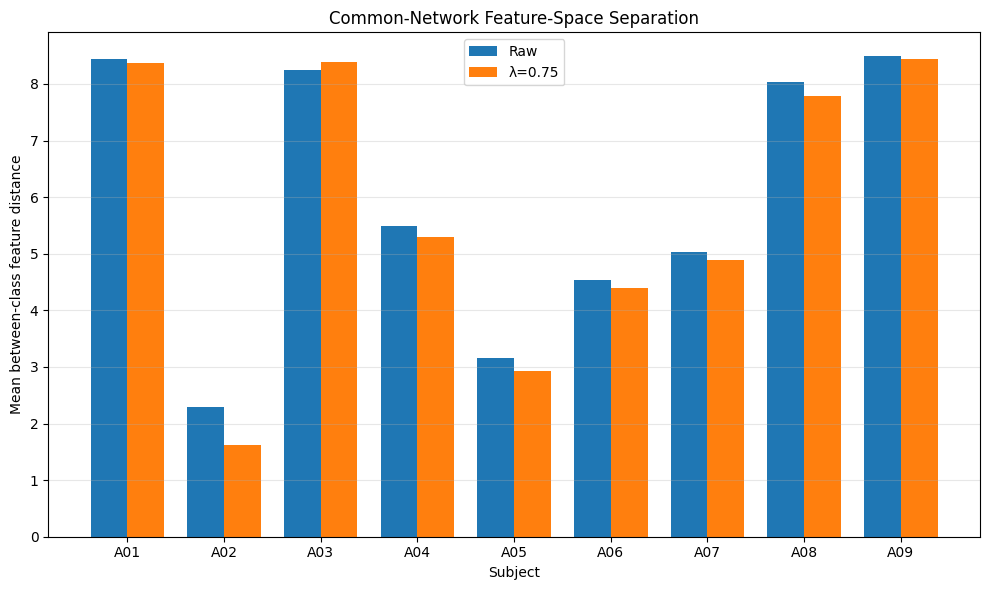

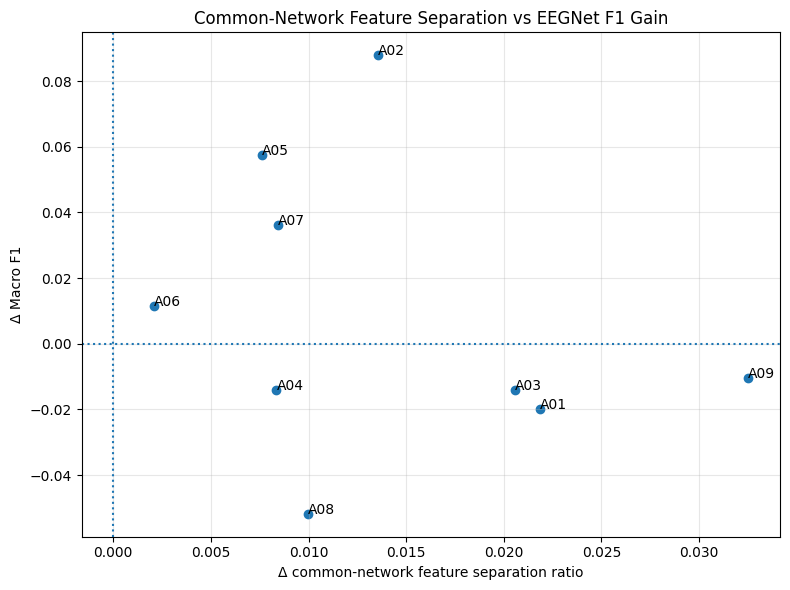

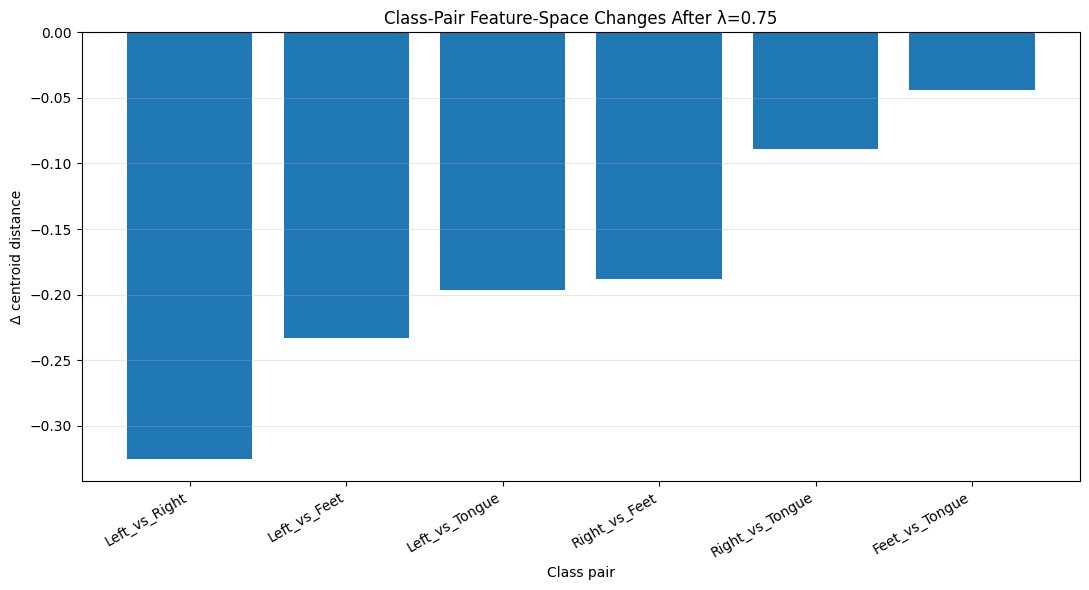

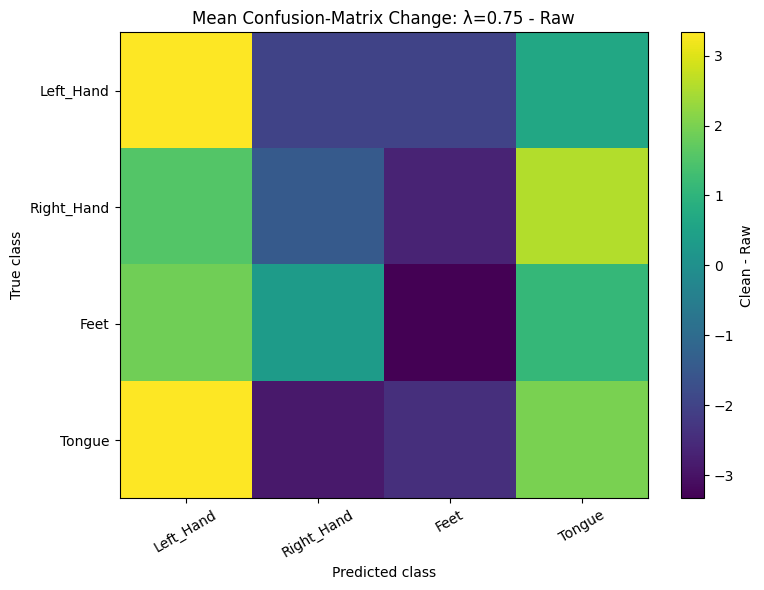



FINAL COMMON-NETWORK FEATURE-SPACE RESULT
Mean ΔAccuracy: +0.001719
Mean ΔF1: +0.009144
Mean Δ between-class distance: -0.179359
Mean Δ within-class distance: -1.168030
Mean Δ separation ratio: +0.013892

Pairwise changes:
Pair
Feet_vs_Tongue    -0.043813
Left_vs_Feet      -0.232954
Left_vs_Right     -0.325651
Left_vs_Tongue    -0.196411
Right_vs_Feet     -0.188268
Right_vs_Tongue   -0.089056

Feature-space correlations:
                      Metric  Accuracy_Pearson_r  Accuracy_Pearson_p  Accuracy_Spearman_rho  Accuracy_Spearman_p  F1_Pearson_r  F1_Pearson_p  F1_Spearman_rho  F1_Spearman_p
Delta_Between_Class_Distance           -0.317352            0.405325              -0.200000             0.605901     -0.630638      0.068621        -0.350000       0.355820
 Delta_Within_Class_Distance           -0.477002            0.194168              -0.383333             0.308495     -0.769961      0.015223        -0.633333       0.067086
      Delta_Separation_Ratio           -0.308281      

In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from scipy.io import loadmat

from numpy.linalg import lstsq

from scipy.stats import (
    pearsonr,
    spearmanr
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import mne

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "common_eegnet_feature_space"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

SEED = 42

def set_seed(seed=SEED):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else
    "cpu"

)

print(
    "Using device:",
    device
)

FS_RAW = 250
FS = 125

N_EEG = 22
N_EOG = 3

LAMBDA = 0.75

BATCH_SIZE = 16

MAX_EPOCHS = 200

LEARNING_RATE = 0.001

SUBJECTS = [

    f"A{i:02d}"

    for i in range(1, 10)

]

CLASS_NAMES = {

    0: "Left_Hand",

    1: "Right_Hand",

    2: "Feet",

    3: "Tongue"

}

def load_bci2a_with_eog(
    mat_path
):

    mat = loadmat(
        mat_path,
        squeeze_me=False
    )

    if "data" not in mat:

        raise ValueError(
            f"'data' not found in {mat_path}"
        )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    for run_idx in range(
        data.shape[1]
    ):

        run = data[
            0,
            run_idx
        ][
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trials = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(
            trials.shape[0]
        ):

            if (
                artifacts[
                    trial_idx,
                    0
                ]
                ==
                1
            ):

                continue

            onset = int(
                trials[
                    trial_idx,
                    0
                ]
            )

            start = onset

            end = (
                onset
                +
                4 * FS_RAW
            )

            if end > X_raw.shape[0]:

                continue

            eeg = X_raw[

                start:end,

                :N_EEG

            ]

            eog = X_raw[

                start:end,

                N_EEG:N_EEG + N_EOG

            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            label = int(

                y[
                    trial_idx,
                    0
                ]

            ) - 1

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        )

    )

def filter_4_38(
    X
):

    X_t = X.transpose(
        0,
        2,
        1
    )

    shape = X_t.shape

    flattened = X_t.reshape(

        -1,

        shape[-1]

    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(
        shape
    )

    return filtered.transpose(
        0,
        2,
        1
    )

def fit_eog_regression(
    eeg_train,
    eog_train
):

    eeg_flat = eeg_train.reshape(
        -1,
        N_EEG
    )

    eog_flat = eog_train.reshape(
        -1,
        N_EOG
    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    beta = np.zeros(
        (
            N_EEG,
            N_EOG
        )
    )

    intercept = np.zeros(
        N_EEG
    )

    for ch in range(
        N_EEG
    ):

        coefficients, _, _, _ = lstsq(

            X,

            eeg_flat[
                :,
                ch
            ],

            rcond=None

        )

        beta[
            ch
        ] = coefficients[
            :N_EOG
        ]

        intercept[
            ch
        ] = coefficients[
            N_EOG
        ]

    return (
        beta,
        intercept
    )

def estimate_eog_component(
    eog,
    beta,
    intercept
):

    component = np.einsum(

        "tsc,nc->tsn",

        eog,

        beta

    )

    component += intercept.reshape(
        1,
        1,
        -1
    )

    return component

class EEGNet(
    nn.Module
):

    def __init__(

        self,

        num_channels=22,

        num_classes=4,

        samples=500,

        F1=16,

        D=2,

        F2=32,

        dropout=0.5,

        kern_length=64

    ):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(

                1,

                F1,

                (
                    1,
                    kern_length
                ),

                padding=(
                    0,
                    kern_length // 2
                ),

                bias=False

            ),

            nn.BatchNorm2d(
                F1
            ),

            nn.Conv2d(

                F1,

                F1 * D,

                (
                    num_channels,
                    1
                ),

                groups=F1,

                bias=False

            ),

            nn.BatchNorm2d(
                F1 * D
            ),

            nn.ELU(),

            nn.AvgPool2d(

                (
                    1,
                    8
                )

            ),

            nn.Dropout(
                dropout
            )

        )

        self.block2 = nn.Sequential(

            nn.Conv2d(

                F1 * D,

                F2,

                (
                    1,
                    16
                ),

                padding=(
                    0,
                    8
                ),

                bias=False

            ),

            nn.BatchNorm2d(
                F2
            ),

            nn.ELU(),

            nn.AvgPool2d(

                (
                    1,
                    8
                )

            ),

            nn.Dropout(
                dropout
            )

        )

        self._flatten_size = (

            self._get_flatten_size(

                num_channels,

                samples,

                F1,

                D,

                F2,

                kern_length

            )

        )

        self.fc = nn.Linear(

            self._flatten_size,

            num_classes

        )

    def _get_flatten_size(

        self,

        C,

        T,

        F1,

        D,

        F2,

        kern_length

    ):

        x = torch.zeros(

            1,

            1,

            C,

            T

        )

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        return x.flatten(
            1
        ).shape[1]

    def extract_features(
        self,
        x
    ):

        x = x.permute(

            0,
            2,
            1

        ).unsqueeze(1)

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        return x.flatten(
            1
        )

    def forward(
        self,
        x
    ):

        features = self.extract_features(
            x
        )

        return self.fc(
            features
        )

def create_loader(
    X,
    y,
    shuffle=False
):

    dataset = TensorDataset(

        torch.tensor(

            X,

            dtype=torch.float32

        ),

        torch.tensor(

            y,

            dtype=torch.long

        )

    )

    return DataLoader(

        dataset,

        batch_size=BATCH_SIZE,

        shuffle=shuffle,

        drop_last=False

    )

def train_raw_eegnet(

    X_train,

    y_train,

    X_val,

    y_val

):

    set_seed()

    train_loader = create_loader(

        X_train,

        y_train,

        shuffle=True

    )

    val_loader = create_loader(

        X_val,

        y_val,

        shuffle=False

    )

    model = EEGNet(

        num_channels=22,

        num_classes=4,

        samples=X_train.shape[1],

        F1=16,

        D=2,

        F2=32,

        dropout=0.5,

        kern_length=64

    ).to(
        device
    )

    optimizer = torch.optim.Adam(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=1e-4

    )

    criterion = nn.CrossEntropyLoss()

    scheduler = (

        torch.optim.lr_scheduler.CosineAnnealingLR(

            optimizer,

            T_max=MAX_EPOCHS,

            eta_min=1e-5

        )

    )

    best_val = -np.inf

    best_state = None

    patience = 50

    patience_counter = 0

    for epoch in range(
        MAX_EPOCHS
    ):

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            output = model(
                X_batch
            )

            loss = criterion(

                output,

                y_batch

            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                1.0

            )

            optimizer.step()

        model.eval()

        val_predictions = []

        val_targets = []

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(
                    device
                )

                output = model(
                    X_batch
                )

                predictions = output.argmax(
                    dim=1
                ).cpu().numpy()

                val_predictions.extend(
                    predictions
                )

                val_targets.extend(
                    y_batch.numpy()
                )

        val_accuracy = accuracy_score(

            val_targets,

            val_predictions

        )

        scheduler.step()

        if (

            val_accuracy
            >
            best_val

        ):

            best_val = val_accuracy

            best_state = {

                k:
                    v.detach()
                    .cpu()
                    .clone()

                for k, v
                in model.state_dict().items()

            }

            patience_counter = 0

        else:

            patience_counter += 1

        if (
            patience_counter
            >=
            patience
        ):

            break

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    return (
        model,
        best_val
    )

def predict_and_extract(

    model,

    X

):

    loader = create_loader(

        X,

        np.zeros(
            len(X),
            dtype=np.int64
        ),

        shuffle=False

    )

    model.eval()

    predictions = []

    features = []

    with torch.no_grad():

        for X_batch, _ in loader:

            X_batch = X_batch.to(
                device
            )

            output = model(
                X_batch
            )

            feature_batch = (
                model.extract_features(
                    X_batch
                )
            )

            predictions.extend(

                output.argmax(
                    dim=1
                )
                .cpu()
                .numpy()

            )

            features.append(

                feature_batch
                .cpu()
                .numpy()

            )

    features = np.concatenate(

        features,

        axis=0

    )

    predictions = np.asarray(

        predictions,

        dtype=int

    )

    return (

        predictions,

        features

    )

def fit_feature_standardizer(
    raw_features
):

    mean = np.mean(

        raw_features,

        axis=0,

        keepdims=True

    )

    std = np.std(

        raw_features,

        axis=0,

        keepdims=True

    )

    std[
        std < 1e-12
    ] = 1.0

    return (

        mean,

        std

    )

def apply_feature_standardizer(

    features,

    mean,

    std

):

    return (

        features
        -
        mean

    ) / std

def within_class_distance(

    features,

    labels

):

    distances = []

    for cls in range(4):

        class_features = features[
            labels
            ==
            cls
        ]

        if len(
            class_features
        ) < 2:

            continue

        centroid = np.mean(

            class_features,

            axis=0

        )

        d = np.linalg.norm(

            class_features
            -
            centroid,

            axis=1

        )

        distances.extend(
            d.tolist()
        )

    if not distances:

        return np.nan

    return float(
        np.mean(distances)
    )

def get_centroids(

    features,

    labels

):

    centroids = {}

    for cls in range(4):

        class_features = features[
            labels
            ==
            cls
        ]

        if len(
            class_features
        ) == 0:

            continue

        centroids[
            cls
        ] = np.mean(

            class_features,

            axis=0

        )

    return centroids

def between_class_distance(

    features,

    labels

):

    centroids = get_centroids(

        features,

        labels

    )

    distances = []

    for i in range(4):

        for j in range(

            i + 1,

            4

        ):

            if (

                i not in centroids

                or

                j not in centroids

            ):

                continue

            distances.append(

                np.linalg.norm(

                    centroids[i]
                    -
                    centroids[j]

                )

            )

    if not distances:

        return np.nan

    return float(

        np.mean(distances)

    )

PAIR_DEFINITIONS = [

    (
        0,
        1,
        "Left_vs_Right"
    ),

    (
        0,
        2,
        "Left_vs_Feet"
    ),

    (
        0,
        3,
        "Left_vs_Tongue"
    ),

    (
        1,
        2,
        "Right_vs_Feet"
    ),

    (
        1,
        3,
        "Right_vs_Tongue"
    ),

    (
        2,
        3,
        "Feet_vs_Tongue"
    )

]

def calculate_pairwise_distances(

    features,

    labels

):

    centroids = get_centroids(

        features,

        labels

    )

    result = {}

    for class_a, class_b, name in PAIR_DEFINITIONS:

        if (

            class_a not in centroids

            or

            class_b not in centroids

        ):

            result[
                name
            ] = np.nan

            continue

        result[
            name
        ] = np.linalg.norm(

            centroids[
                class_a
            ]

            -

            centroids[
                class_b
            ]

        )

    return result

subject_rows = []

pairwise_rows = []

confusion_rows = []

for subject_index, subject in enumerate(
    SUBJECTS
):

    print("\n")
    print(
        "=" * 110
    )

    print(
        f"PROCESSING {subject}"
    )

    print(
        "=" * 110
    )

    train_path = os.path.join(

        DATASET_DIR,

        f"{subject}T.mat"

    )

    test_path = os.path.join(

        DATASET_DIR,

        f"{subject}E.mat"

    )

    (
        eeg_t,
        eog_t,
        y_t,
    ) = load_bci2a_with_eog(

        train_path

    )

    (
        eeg_e,
        eog_e,
        y_e
    ) = load_bci2a_with_eog(

        test_path

    )

    eeg_t = filter_4_38(
        eeg_t
    )

    eeg_e = filter_4_38(
        eeg_e
    )

    eog_t = filter_4_38(
        eog_t
    )

    eog_e = filter_4_38(
        eog_e
    )

    all_train_indices = np.arange(

        len(y_t)

    )

    train_idx, val_idx = train_test_split(

        all_train_indices,

        test_size=0.20,

        stratify=y_t,

        random_state=SEED

    )

    raw_train_mean = (

        eeg_t[
            train_idx
        ]

        .mean(

            axis=(0, 1),

            keepdims=True

        )

    )

    raw_train_std = (

        eeg_t[
            train_idx
        ]

        .std(

            axis=(0, 1),

            keepdims=True

        )

    )

    raw_train_std[
        raw_train_std < 1e-8
    ] = 1.0

    X_raw_train = (

        eeg_t[
            train_idx
        ]

        -
        raw_train_mean

    ) / raw_train_std

    X_raw_val = (

        eeg_t[
            val_idx
        ]

        -
        raw_train_mean

    ) / raw_train_std

    X_raw_test = (

        eeg_e
        -
        raw_train_mean

    ) / raw_train_std

    beta_eog, intercept_eog = (

        fit_eog_regression(

            eeg_t[
                train_idx
            ],

            eog_t[
                train_idx
            ]

        )

    )

    eog_component_t = (

        estimate_eog_component(

            eog_t,

            beta_eog,

            intercept_eog

        )

    )

    eog_component_e = (

        estimate_eog_component(

            eog_e,

            beta_eog,

            intercept_eog

        )

    )

    eeg_t_clean = (

        eeg_t
        -
        LAMBDA
        *
        eog_component_t

    )

    eeg_e_clean = (

        eeg_e
        -
        LAMBDA
        *
        eog_component_e

    )

    X_clean_test = (

        eeg_e_clean
        -
        raw_train_mean

    ) / raw_train_std

    model, best_val = train_raw_eegnet(

        X_raw_train,

        y_t[
            train_idx
        ],

        X_raw_val,

        y_t[
            val_idx
        ]

    )

    raw_predictions, raw_features = (

        predict_and_extract(

            model,

            X_raw_test

        )

    )

    clean_predictions, clean_features = (

        predict_and_extract(

            model,

            X_clean_test

        )

    )

    raw_accuracy = accuracy_score(

        y_e,

        raw_predictions

    )

    clean_accuracy = accuracy_score(

        y_e,

        clean_predictions

    )

    raw_f1 = f1_score(

        y_e,

        raw_predictions,

        average="macro"

    )

    clean_f1 = f1_score(

        y_e,

        clean_predictions,

        average="macro"

    )

    feature_mean, feature_std = (

        fit_feature_standardizer(

            raw_features

        )

    )

    raw_z = apply_feature_standardizer(

        raw_features,

        feature_mean,

        feature_std

    )

    clean_z = apply_feature_standardizer(

        clean_features,

        feature_mean,

        feature_std

    )

    raw_within = within_class_distance(

        raw_z,

        y_e

    )

    clean_within = within_class_distance(

        clean_z,

        y_e

    )

    raw_between = between_class_distance(

        raw_z,

        y_e

    )

    clean_between = between_class_distance(

        clean_z,

        y_e

    )

    raw_ratio = (

        raw_between
        /
        raw_within

        if raw_within > 1e-12

        else np.nan

    )

    clean_ratio = (

        clean_between
        /
        clean_within

        if clean_within > 1e-12

        else np.nan

    )

    raw_pairs = calculate_pairwise_distances(

        raw_z,

        y_e

    )

    clean_pairs = calculate_pairwise_distances(

        clean_z,

        y_e

    )

    for pair_name in raw_pairs.keys():

        raw_distance = raw_pairs[
            pair_name
        ]

        clean_distance = clean_pairs[
            pair_name
        ]

        pairwise_rows.append({

            "Subject":
                subject,

            "Pair":
                pair_name,

            "Raw_Distance":
                raw_distance,

            "Clean_Distance":
                clean_distance,

            "Delta_Distance":
                (
                    clean_distance
                    -
                    raw_distance
                ),

            "Delta_Accuracy":
                (
                    clean_accuracy
                    -
                    raw_accuracy
                ),

            "Delta_F1":
                (
                    clean_f1
                    -
                    raw_f1
                )

        })

    raw_cm = confusion_matrix(

        y_e,

        raw_predictions,

        labels=[
            0,
            1,
            2,
            3
        ]

    )

    clean_cm = confusion_matrix(

        y_e,

        clean_predictions,

        labels=[
            0,
            1,
            2,
            3
        ]

    )

    delta_cm = (

        clean_cm
        -
        raw_cm

    )

    for true_cls in range(4):

        for predicted_cls in range(4):

            confusion_rows.append({

                "Subject":
                    subject,

                "True_Class":
                    CLASS_NAMES[
                        true_cls
                    ],

                "Predicted_Class":
                    CLASS_NAMES[
                        predicted_cls
                    ],

                "Raw_Count":
                    raw_cm[
                        true_cls,
                        predicted_cls
                    ],

                "Clean_Count":
                    clean_cm[
                        true_cls,
                        predicted_cls
                    ],

                "Change":
                    delta_cm[
                        true_cls,
                        predicted_cls
                    ]

            })

    subject_rows.append({

        "Subject":
            subject,

        "Best_Validation_Accuracy":
            best_val,

        "Raw_Accuracy":
            raw_accuracy,

        "Clean_Accuracy":
            clean_accuracy,

        "Delta_Accuracy":
            (
                clean_accuracy
                -
                raw_accuracy
            ),

        "Raw_F1":
            raw_f1,

        "Clean_F1":
            clean_f1,

        "Delta_F1":
            (
                clean_f1
                -
                raw_f1
            ),

        "Raw_Within_Class_Distance":
            raw_within,

        "Clean_Within_Class_Distance":
            clean_within,

        "Delta_Within_Class_Distance":
            (
                clean_within
                -
                raw_within
            ),

        "Raw_Between_Class_Distance":
            raw_between,

        "Clean_Between_Class_Distance":
            clean_between,

        "Delta_Between_Class_Distance":
            (
                clean_between
                -
                raw_between
            ),

        "Raw_Separation_Ratio":
            raw_ratio,

        "Clean_Separation_Ratio":
            clean_ratio,

        "Delta_Separation_Ratio":
            (
                clean_ratio
                -
                raw_ratio
            )

    })

    print(

        f"Raw Accuracy:"
        f" {raw_accuracy:.4f}"

    )

    print(

        f"Clean Accuracy:"
        f" {clean_accuracy:.4f}"

    )

    print(

        f"ΔAccuracy:"
        f" {clean_accuracy - raw_accuracy:+.4f}"

    )

    print(

        f"Raw F1:"
        f" {raw_f1:.4f}"

    )

    print(

        f"Clean F1:"
        f" {clean_f1:.4f}"

    )

    print(

        f"ΔF1:"
        f" {clean_f1 - raw_f1:+.4f}"

    )

    print(

        f"Raw between-class distance:"
        f" {raw_between:.4f}"

    )

    print(

        f"Clean between-class distance:"
        f" {clean_between:.4f}"

    )

    print(

        f"Δ between-class distance:"
        f" {clean_between - raw_between:+.4f}"

    )

subject_df = pd.DataFrame(
    subject_rows
)

pairwise_df = pd.DataFrame(
    pairwise_rows
)

confusion_df = pd.DataFrame(
    confusion_rows
)

print("\n")
print(
    "=" * 110
)

print(
    "COMMON-NETWORK FEATURE-SPACE SUMMARY"
)

print(
    "=" * 110
)

print(

    subject_df[
        [

            "Subject",

            "Raw_Accuracy",

            "Clean_Accuracy",

            "Delta_Accuracy",

            "Raw_F1",

            "Clean_F1",

            "Delta_F1",

            "Delta_Between_Class_Distance",

            "Delta_Within_Class_Distance",

            "Delta_Separation_Ratio"

        ]

    ]
    .round(6)
    .to_string(
        index=False
    )

)

mean_between = (

    subject_df[
        "Delta_Between_Class_Distance"
    ].mean()

)

mean_within = (

    subject_df[
        "Delta_Within_Class_Distance"
    ].mean()

)

mean_ratio = (

    subject_df[
        "Delta_Separation_Ratio"
    ].mean()

)

mean_accuracy = (

    subject_df[
        "Delta_Accuracy"
    ].mean()

)

mean_f1 = (

    subject_df[
        "Delta_F1"
    ].mean()

)

print("\n")
print(
    "=" * 110
)

print(
    "MEAN FEATURE-SPACE EFFECT"
)

print(
    "=" * 110
)

print(

    f"Mean Δ between-class distance:"
    f" {mean_between:+.6f}"

)

print(

    f"Mean Δ within-class distance:"
    f" {mean_within:+.6f}"

)

print(

    f"Mean Δ separation ratio:"
    f" {mean_ratio:+.6f}"

)

print(

    f"Mean ΔAccuracy:"
    f" {mean_accuracy:+.6f}"

)

print(

    f"Mean ΔF1:"
    f" {mean_f1:+.6f}"

)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT CONSISTENCY"
)

print(
    "=" * 110
)

print(

    "Between-class distance increased:",
    (
        subject_df[
            "Delta_Between_Class_Distance"
        ]
        >
        0
    ).sum(),
    "/",
    len(subject_df)

)

print(

    "Within-class distance decreased:",
    (
        subject_df[
            "Delta_Within_Class_Distance"
        ]
        <
        0
    ).sum(),
    "/",
    len(subject_df)

)

print(

    "Separation ratio increased:",
    (
        subject_df[
            "Delta_Separation_Ratio"
        ]
        >
        0
    ).sum(),
    "/",
    len(subject_df)

)

print("\n")
print(
    "=" * 110
)

print(
    "PAIRWISE CLASS-CENTROID DISTANCE CHANGES"
)

print(
    "=" * 110
)

pair_summary = (

    pairwise_df

    .groupby(
        "Pair"
    )[

        [

            "Raw_Distance",

            "Clean_Distance",

            "Delta_Distance"

        ]

    ]

    .mean()

)

print(

    pair_summary.round(
        6
    ).to_string()

)

pair_correlation_rows = []

for pair_name in pairwise_df[
    "Pair"
].unique():

    temp = pairwise_df[

        pairwise_df[
            "Pair"
        ]
        ==
        pair_name

    ]

    x = temp[
        "Delta_Distance"
    ].to_numpy(
        dtype=float
    )

    y_acc = temp[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    y_f1 = temp[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    if (

        np.isfinite(x).sum()
        >=
        3

        and

        np.isfinite(y_acc).sum()
        >=
        3

    ):

        valid_acc = (

            np.isfinite(x)

            &

            np.isfinite(y_acc)

        )

        if (

            valid_acc.sum()
            >=
            3

        ):

            acc_r, acc_p = pearsonr(

                x[
                    valid_acc
                ],

                y_acc[
                    valid_acc
                ]

            )

            acc_rho, acc_rho_p = spearmanr(

                x[
                    valid_acc
                ],

                y_acc[
                    valid_acc
                ]

            )

        else:

            acc_r = np.nan
            acc_p = np.nan

            acc_rho = np.nan
            acc_rho_p = np.nan

    else:

        acc_r = np.nan
        acc_p = np.nan

        acc_rho = np.nan
        acc_rho_p = np.nan

    valid_f1 = (

        np.isfinite(x)

        &

        np.isfinite(y_f1)

    )

    if valid_f1.sum() >= 3:

        f1_r, f1_p = pearsonr(

            x[
                valid_f1
            ],

            y_f1[
                valid_f1
            ]

        )

        f1_rho, f1_rho_p = spearmanr(

            x[
                valid_f1
            ],

            y_f1[
                valid_f1
            ]

        )

    else:

        f1_r = np.nan
        f1_p = np.nan

        f1_rho = np.nan
        f1_rho_p = np.nan

    pair_correlation_rows.append({

        "Pair":
            pair_name,

        "Accuracy_Pearson_r":
            acc_r,

        "Accuracy_Pearson_p":
            acc_p,

        "Accuracy_Spearman_rho":
            acc_rho,

        "Accuracy_Spearman_p":
            acc_rho_p,

        "F1_Pearson_r":
            f1_r,

        "F1_Pearson_p":
            f1_p,

        "F1_Spearman_rho":
            f1_rho,

        "F1_Spearman_p":
            f1_rho_p

    })

pair_correlation_df = pd.DataFrame(

    pair_correlation_rows

)

print("\n")
print(
    "PAIRWISE CHANGE vs PERFORMANCE"
)

print(

    pair_correlation_df.round(
        6
    ).to_string(
        index=False
    )

)

feature_corr_rows = []

feature_metrics = [

    "Delta_Between_Class_Distance",

    "Delta_Within_Class_Distance",

    "Delta_Separation_Ratio"

]

for metric in feature_metrics:

    x = subject_df[
        metric
    ].to_numpy(
        dtype=float
    )

    y_acc = subject_df[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    y_f1 = subject_df[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    r_acc, p_acc = pearsonr(

        x,

        y_acc

    )

    rho_acc, rho_p_acc = spearmanr(

        x,

        y_acc

    )

    r_f1, p_f1 = pearsonr(

        x,

        y_f1

    )

    rho_f1, rho_p_f1 = spearmanr(

        x,

        y_f1

    )

    feature_corr_rows.append({

        "Metric":
            metric,

        "Accuracy_Pearson_r":
            r_acc,

        "Accuracy_Pearson_p":
            p_acc,

        "Accuracy_Spearman_rho":
            rho_acc,

        "Accuracy_Spearman_p":
            rho_p_acc,

        "F1_Pearson_r":
            r_f1,

        "F1_Pearson_p":
            p_f1,

        "F1_Spearman_rho":
            rho_f1,

        "F1_Spearman_p":
            rho_p_f1

    })

feature_correlation_df = pd.DataFrame(

    feature_corr_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "GLOBAL FEATURE-SPACE CHANGES vs EEGNET BENEFIT"
)

print(
    "=" * 110
)

print(

    feature_correlation_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "CONFUSION-MATRIX CHANGES"
)

print(
    "=" * 110
)

confusion_summary = (

    confusion_df

    .groupby(

        [
            "True_Class",
            "Predicted_Class"

        ]

    )[

        [
            "Raw_Count",

            "Clean_Count",

            "Change"

        ]

    ]

    .mean()

)

print(

    confusion_summary.round(
        4
    ).to_string()

)

print("\n")
print(
    "=" * 110
)

print(
    "LARGEST CONFUSION CHANGES"
)

print(
    "=" * 110
)

confusion_changes = (

    confusion_df

    .groupby(

        [
            "True_Class",
            "Predicted_Class"

        ]

    )[

        "Change"

    ]

    .mean()

    .sort_values()

)

print(

    confusion_changes
    .head(10)
    .round(4)
    .to_string()

)

plt.figure(
    figsize=(10, 6)
)

xpos = np.arange(
    len(subject_df)
)

width = 0.38

plt.bar(

    xpos - width / 2,

    subject_df[
        "Raw_Between_Class_Distance"
    ],

    width,

    label="Raw"

)

plt.bar(

    xpos + width / 2,

    subject_df[
        "Clean_Between_Class_Distance"
    ],

    width,

    label="λ=0.75"

)

plt.xticks(

    xpos,

    subject_df[
        "Subject"
    ]

)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "Mean between-class feature distance"
)

plt.title(
    "Common-Network Feature-Space Separation"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_DIR,

        "common_network_between_class_distance.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(8, 6)
)

plt.scatter(

    subject_df[
        "Delta_Separation_Ratio"
    ],

    subject_df[
        "Delta_F1"
    ]

)

for _, row in subject_df.iterrows():

    plt.annotate(

        row[
            "Subject"
        ],

        (

            row[
                "Delta_Separation_Ratio"
            ],

            row[
                "Delta_F1"
            ]

        )

    )

plt.axhline(
    0,
    linestyle=":"
)

plt.axvline(
    0,
    linestyle=":"
)

plt.xlabel(
    "Δ common-network feature separation ratio"
)

plt.ylabel(
    "Δ Macro F1"
)

plt.title(
    "Common-Network Feature Separation vs EEGNet F1 Gain"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_DIR,

        "common_network_separation_vs_f1.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(11, 6)
)

pair_plot = pair_summary[
    "Delta_Distance"
].sort_values()

plt.bar(

    np.arange(
        len(pair_plot)
    ),

    pair_plot.values

)

plt.xticks(

    np.arange(
        len(pair_plot)
    ),

    pair_plot.index,

    rotation=30,

    ha="right"

)

plt.axhline(

    0,

    linestyle=":"

)

plt.xlabel(
    "Class pair"
)

plt.ylabel(
    "Δ centroid distance"
)

plt.title(
    "Class-Pair Feature-Space Changes After λ=0.75"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_DIR,

        "pairwise_feature_space_changes.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

mean_confusion_delta = (

    confusion_df

    .groupby(

        [

            "True_Class",

            "Predicted_Class"

        ]

    )[

        "Change"

    ]

    .mean()

    .unstack()

)

plt.figure(
    figsize=(8, 6)
)

plt.imshow(
    mean_confusion_delta.values,
    aspect="auto"
)

plt.colorbar(
    label="Clean - Raw"
)

plt.xticks(

    np.arange(4),

    [

        CLASS_NAMES[i]

        for i in range(4)

    ],

    rotation=30

)

plt.yticks(

    np.arange(4),

    [

        CLASS_NAMES[i]

        for i in range(4)

    ]

)

plt.xlabel(
    "Predicted class"
)

plt.ylabel(
    "True class"
)

plt.title(
    "Mean Confusion-Matrix Change: λ=0.75 - Raw"
)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_DIR,

        "mean_confusion_matrix_change.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

subject_file = os.path.join(

    OUTPUT_DIR,

    "common_network_subject_results.csv"

)

pairwise_file = os.path.join(

    OUTPUT_DIR,

    "common_network_pairwise_results.csv"

)

pair_corr_file = os.path.join(

    OUTPUT_DIR,

    "common_network_pairwise_correlations.csv"

)

feature_corr_file = os.path.join(

    OUTPUT_DIR,

    "common_network_feature_correlations.csv"

)

confusion_file = os.path.join(

    OUTPUT_DIR,

    "common_network_confusion_changes.csv"

)

confusion_summary_file = os.path.join(

    OUTPUT_DIR,

    "common_network_confusion_summary.csv"

)

subject_df.to_csv(
    subject_file,
    index=False
)

pairwise_df.to_csv(
    pairwise_file,
    index=False
)

pair_correlation_df.to_csv(
    pair_corr_file,
    index=False
)

feature_correlation_df.to_csv(
    feature_corr_file,
    index=False
)

confusion_df.to_csv(
    confusion_file,
    index=False
)

confusion_summary.to_csv(
    confusion_summary_file
)

print("\n")
print(
    "=" * 110
)

print(
    "FINAL COMMON-NETWORK FEATURE-SPACE RESULT"
)

print(
    "=" * 110
)

print(

    f"Mean ΔAccuracy:"
    f" {mean_accuracy:+.6f}"

)

print(

    f"Mean ΔF1:"
    f" {mean_f1:+.6f}"

)

print(

    f"Mean Δ between-class distance:"
    f" {mean_between:+.6f}"

)

print(

    f"Mean Δ within-class distance:"
    f" {mean_within:+.6f}"

)

print(

    f"Mean Δ separation ratio:"
    f" {mean_ratio:+.6f}"

)

print(
    "\nPairwise changes:"
)

print(

    pair_summary[
        "Delta_Distance"
    ]
    .round(6)
    .to_string()

)

print(
    "\nFeature-space correlations:"
)

print(

    feature_correlation_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nPairwise correlations:"
)

print(

    pair_correlation_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nFiles saved:"
)

print(
    subject_file
)

print(
    pairwise_file
)

print(
    pair_corr_file
)

print(
    feature_corr_file
)

print(
    confusion_file
)

print(
    confusion_summary_file
)

print("\n")
print(
    "=" * 110
)

print(
    "COMMON-NETWORK FEATURE-SPACE ANALYSIS COMPLETE"
)

print(
    "=" * 110
)


## Class-Specific Feature Compactness and Confusion

Using device: cuda


PROCESSING A01
Raw Accuracy = 0.6014
Clean Accuracy = 0.5801
Δ Accuracy = -0.0214
Raw F1 = 0.5871
Clean F1 = 0.5671
Δ F1 = -0.0200

Class-specific compactness:
Left_Hand    Raw=13.1221 Clean=12.5433 Δ=-0.5787
Right_Hand   Raw=13.1016 Clean=12.5447 Δ=-0.5569
Feet         Raw=13.7940 Clean=13.2579 Δ=-0.5361
Tongue       Raw=14.0936 Clean=13.4670 Δ=-0.6266


PROCESSING A02
Raw Accuracy = 0.2721
Clean Accuracy = 0.3074
Δ Accuracy = +0.0353
Raw F1 = 0.2204
Clean F1 = 0.3083
Δ F1 = +0.0879

Class-specific compactness:
Left_Hand    Raw=15.0552 Clean=9.6326 Δ=-5.4225
Right_Hand   Raw=12.8345 Clean=8.2956 Δ=-4.5389
Feet         Raw=13.3220 Clean=8.7745 Δ=-4.5474
Tongue       Raw=12.5123 Clean=8.2065 Δ=-4.3058


PROCESSING A03
Raw Accuracy = 0.6374
Clean Accuracy = 0.6337
Δ Accuracy = -0.0037
Raw F1 = 0.5959
Clean F1 = 0.5817
Δ F1 = -0.0142

Class-specific compactness:
Left_Hand    Raw=12.6572 Clean=12.3132 Δ=-0.3439
Right_Hand   Raw=13.3205 Clean=13.0277 Δ=-0.2927
Feet     

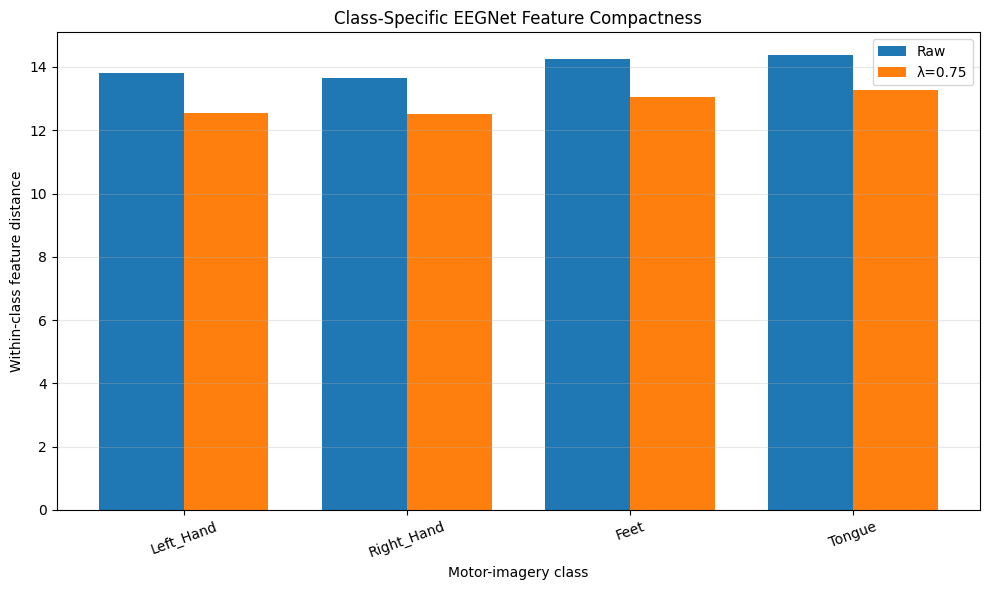

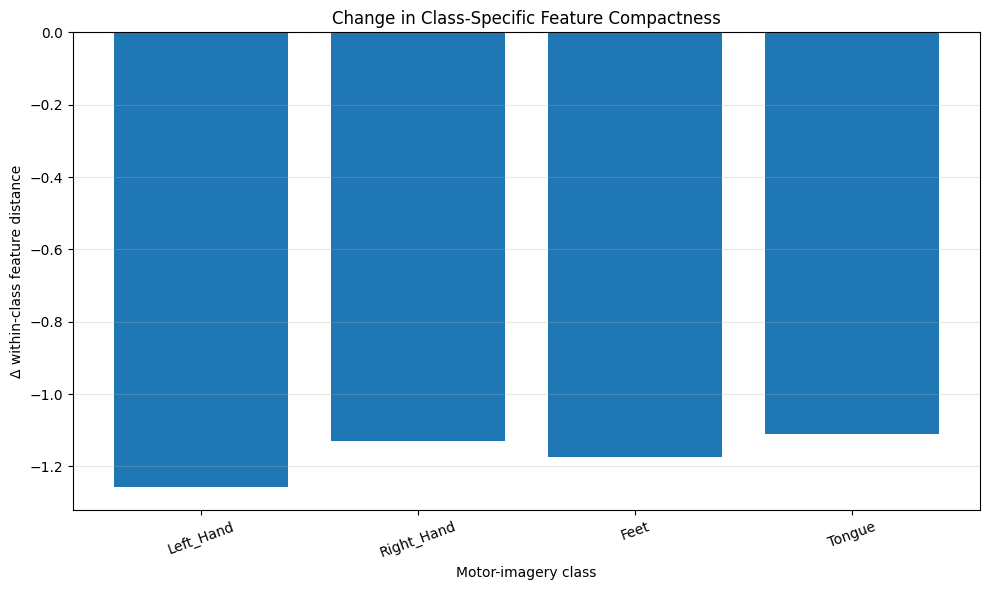

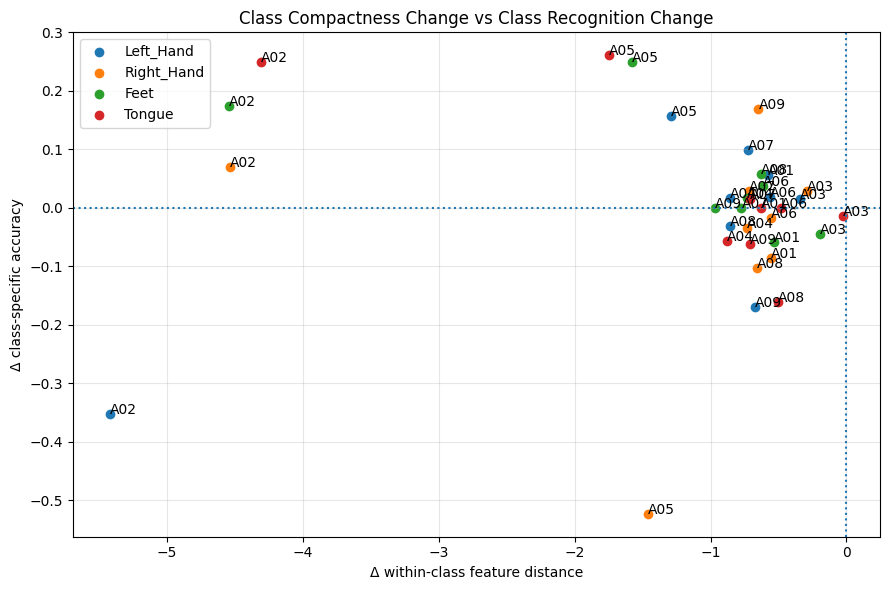

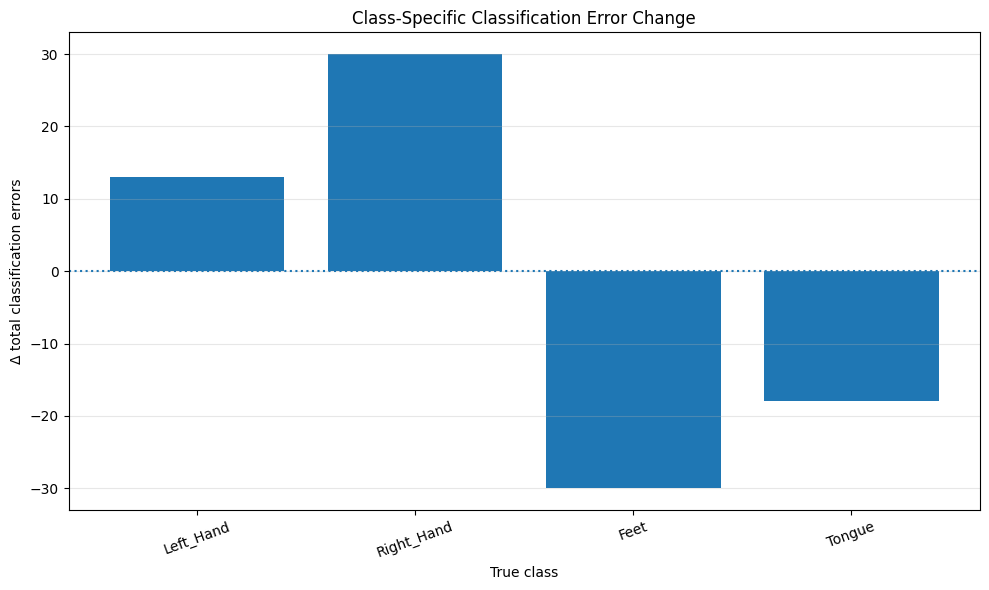



FINAL CLASS-SPECIFIC COMPACTNESS + CONFUSION ANALYSIS

Global mean ΔAccuracy:
+0.001719

Global mean ΔF1:
+0.009144

Class-specific compactness:
            Raw_Within_Class_Distance  Clean_Within_Class_Distance  Delta_Within_Class_Distance
Class                                                                                          
Feet                        14.237224                    13.062645                    -1.174579
Left_Hand                   13.805326                    12.547777                    -1.257550
Right_Hand                  13.644252                    12.515373                    -1.128880
Tongue                      14.374563                    13.264266                    -1.110296

Class-specific compactness → class accuracy:
     Class  Pearson_r  Pearson_p  Spearman_rho  Spearman_p
 Left_Hand   0.758881   0.017738      0.133333    0.732368
Right_Hand  -0.035216   0.928332      0.033333    0.932157
      Feet  -0.661472   0.052340     -0.661094    0.05

In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from scipy.io import loadmat

from scipy.stats import (
    pearsonr,
    spearmanr,
    wilcoxon
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

import mne

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "class_specific_compactness"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

SEED = 42

FS_RAW = 250
FS = 125

N_EEG = 22
N_EOG = 3

LAMBDA = 0.75

BATCH_SIZE = 16

MAX_EPOCHS = 200

LEARNING_RATE = 0.001

PATIENCE = 50

SUBJECTS = [

    f"A{i:02d}"

    for i in range(
        1,
        10
    )

]

CLASS_NAMES = {

    0: "Left_Hand",

    1: "Right_Hand",

    2: "Feet",

    3: "Tongue"

}

def set_seed(
    seed=SEED
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

set_seed()

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else
    "cpu"

)

print(
    "Using device:",
    device
)

def load_bci2a_with_eog(
    mat_path
):

    mat = loadmat(

        mat_path,

        squeeze_me=False

    )

    if "data" not in mat:

        raise ValueError(
            f"'data' not found:\n{mat_path}"
        )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    for run_idx in range(
        data.shape[1]
    ):

        run = data[
            0,
            run_idx
        ][
            0,
            0
        ]

        X_raw = run[
            "X"
        ]

        trials = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(
            trials.shape[0]
        ):

            if (

                artifacts[
                    trial_idx,
                    0
                ]
                ==
                1

            ):

                continue

            onset = int(

                trials[
                    trial_idx,
                    0
                ]

            )

            start = onset

            end = (

                onset
                +
                4 * FS_RAW

            )

            if end > X_raw.shape[0]:

                continue

            eeg = X_raw[

                start:end,

                :N_EEG

            ]

            eog = X_raw[

                start:end,

                N_EEG:N_EEG + N_EOG

            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            label = int(

                y[
                    trial_idx,
                    0
                ]

            ) - 1

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

    return (

        np.asarray(
            eeg_trials,
            dtype=np.float64
        ),

        np.asarray(
            eog_trials,
            dtype=np.float64
        ),

        np.asarray(
            labels,
            dtype=np.int64
        )

    )

def filter_4_38(
    X
):

    X_t = X.transpose(

        0,
        2,
        1

    )

    original_shape = X_t.shape

    flattened = X_t.reshape(

        -1,

        original_shape[-1]

    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(
        original_shape
    )

    return filtered.transpose(

        0,
        2,
        1

    )

def fit_eog_regression(

    eeg_train,

    eog_train

):

    eeg_flat = eeg_train.reshape(

        -1,

        N_EEG

    )

    eog_flat = eog_train.reshape(

        -1,

        N_EOG

    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    beta = np.zeros(

        (
            N_EEG,
            N_EOG
        ),

        dtype=np.float64

    )

    intercept = np.zeros(

        N_EEG,

        dtype=np.float64

    )

    for channel_idx in range(
        N_EEG
    ):

        coef, _, _, _ = np.linalg.lstsq(

            X,

            eeg_flat[
                :,
                channel_idx
            ],

            rcond=None

        )

        beta[
            channel_idx
        ] = coef[
            :N_EOG
        ]

        intercept[
            channel_idx
        ] = coef[
            N_EOG
        ]

    return (

        beta,

        intercept

    )

def estimate_eog_component(

    eog,

    beta,

    intercept

):

    component = np.einsum(

        "tsc,nc->tsn",

        eog,

        beta

    )

    component += intercept.reshape(

        1,
        1,
        -1

    )

    return component

class EEGNet(
    nn.Module
):

    def __init__(

        self,

        num_channels=22,

        num_classes=4,

        samples=500,

        F1=16,

        D=2,

        F2=32,

        dropout=0.5,

        kern_length=64

    ):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(

                1,

                F1,

                (
                    1,
                    kern_length
                ),

                padding=(

                    0,

                    kern_length // 2

                ),

                bias=False

            ),

            nn.BatchNorm2d(
                F1
            ),

            nn.Conv2d(

                F1,

                F1 * D,

                (
                    num_channels,
                    1
                ),

                groups=F1,

                bias=False

            ),

            nn.BatchNorm2d(

                F1 * D

            ),

            nn.ELU(),

            nn.AvgPool2d(

                (
                    1,
                    8
                )

            ),

            nn.Dropout(
                dropout
            )

        )

        self.block2 = nn.Sequential(

            nn.Conv2d(

                F1 * D,

                F2,

                (
                    1,
                    16
                ),

                padding=(
                    0,
                    8
                ),

                bias=False

            ),

            nn.BatchNorm2d(
                F2
            ),

            nn.ELU(),

            nn.AvgPool2d(

                (
                    1,
                    8
                )

            ),

            nn.Dropout(
                dropout
            )

        )

        self._flatten_size = (

            self._get_flatten_size(

                num_channels,

                samples,

                F1,

                D,

                F2,

                kern_length

            )

        )

        self.fc = nn.Linear(

            self._flatten_size,

            num_classes

        )

    def _get_flatten_size(

        self,

        C,

        T,

        F1,

        D,

        F2,

        kern_length

    ):

        x = torch.zeros(

            1,

            1,

            C,

            T

        )

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        return x.flatten(
            1
        ).shape[1]

    def extract_features(
        self,
        x
    ):

        x = x.permute(

            0,
            2,
            1

        ).unsqueeze(1)

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        return x.flatten(
            1
        )

    def forward(
        self,
        x
    ):

        features = self.extract_features(
            x
        )

        return self.fc(
            features
        )

def create_loader(

    X,

    y,

    shuffle=False

):

    dataset = TensorDataset(

        torch.tensor(

            X,

            dtype=torch.float32

        ),

        torch.tensor(

            y,

            dtype=torch.long

        )

    )

    return DataLoader(

        dataset,

        batch_size=BATCH_SIZE,

        shuffle=shuffle,

        drop_last=False

    )

def train_raw_eegnet(

    X_train,

    y_train,

    X_val,

    y_val

):

    set_seed()

    model = EEGNet(

        num_channels=22,

        num_classes=4,

        samples=X_train.shape[1],

        F1=16,

        D=2,

        F2=32,

        dropout=0.5,

        kern_length=64

    ).to(
        device
    )

    train_loader = create_loader(

        X_train,

        y_train,

        shuffle=True

    )

    val_loader = create_loader(

        X_val,

        y_val,

        shuffle=False

    )

    optimizer = torch.optim.Adam(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=1e-4

    )

    scheduler = (

        torch.optim.lr_scheduler.CosineAnnealingLR(

            optimizer,

            T_max=MAX_EPOCHS,

            eta_min=1e-5

        )

    )

    criterion = nn.CrossEntropyLoss()

    best_val_accuracy = -np.inf

    best_state = None

    patience_count = 0

    for epoch in range(
        MAX_EPOCHS
    ):

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            output = model(
                X_batch
            )

            loss = criterion(

                output,

                y_batch

            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                1.0

            )

            optimizer.step()

        model.eval()

        predictions = []

        targets = []

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(
                    device
                )

                output = model(
                    X_batch
                )

                pred = output.argmax(

                    dim=1

                ).cpu().numpy()

                predictions.extend(
                    pred
                )

                targets.extend(
                    y_batch.numpy()
                )

        val_accuracy = accuracy_score(

            targets,

            predictions

        )

        scheduler.step()

        if (

            val_accuracy
            >
            best_val_accuracy

        ):

            best_val_accuracy = val_accuracy

            best_state = {

                key:
                    value.detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()

            }

            patience_count = 0

        else:

            patience_count += 1

        if (

            patience_count
            >=
            PATIENCE

        ):

            break

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    return (

        model,

        best_val_accuracy

    )

def extract_features(

    model,

    X

):

    loader = create_loader(

        X,

        np.zeros(
            len(X),
            dtype=np.int64
        ),

        shuffle=False

    )

    model.eval()

    features = []

    predictions = []

    with torch.no_grad():

        for X_batch, _ in loader:

            X_batch = X_batch.to(
                device
            )

            output = model(
                X_batch
            )

            embedding = model.extract_features(

                X_batch

            )

            predictions.extend(

                output.argmax(

                    dim=1

                )
                .cpu()
                .numpy()

            )

            features.append(

                embedding
                .cpu()
                .numpy()

            )

    features = np.concatenate(

        features,

        axis=0

    )

    predictions = np.asarray(

        predictions,

        dtype=np.int64

    )

    return (

        features,

        predictions

    )

def fit_feature_scaler(
    features
):

    mean = np.mean(

        features,

        axis=0,

        keepdims=True

    )

    std = np.std(

        features,

        axis=0,

        keepdims=True

    )

    std[
        std < 1e-12
    ] = 1.0

    return (

        mean,

        std

    )

def apply_feature_scaler(

    features,

    mean,

    std

):

    return (

        features
        -
        mean

    ) / std

def class_compactness(

    features,

    labels,

    class_id

):

    class_features = features[

        labels
        ==
        class_id

    ]

    if len(
        class_features
    ) < 2:

        return {

            "N":
                len(
                    class_features
                ),

            "Within_Distance":
                np.nan,

            "Centroid":
                None

        }

    centroid = np.mean(

        class_features,

        axis=0

    )

    distances = np.linalg.norm(

        class_features
        -
        centroid,

        axis=1

    )

    return {

        "N":
            len(
                class_features
            ),

        "Within_Distance":
            float(
                np.mean(
                    distances
                )
            ),

        "Centroid":
            centroid

    }

def all_class_compactness(

    features,

    labels

):

    results = {}

    for class_id in range(4):

        results[
            class_id
        ] = class_compactness(

            features,

            labels,

            class_id

        )

    return results

def class_correct_counts(

    y_true,

    y_pred

):

    result = {}

    for class_id in range(4):

        mask = (

            y_true
            ==
            class_id

        )

        n_trials = int(
            mask.sum()
        )

        correct = int(

            (
                y_pred[
                    mask
                ]
                ==
                class_id
            ).sum()

        )

        accuracy = (

            correct
            /
            n_trials

            if n_trials > 0

            else np.nan

        )

        result[
            class_id
        ] = {

            "N":
                n_trials,

            "Correct":
                correct,

            "Accuracy":
                accuracy

        }

    return result

subject_rows = []

class_rows = []

confusion_rows = []

for subject_index, subject in enumerate(

    SUBJECTS

):

    print("\n")
    print(
        "=" * 110
    )

    print(
        f"PROCESSING {subject}"
    )

    print(
        "=" * 110
    )

    train_path = os.path.join(

        DATASET_DIR,

        f"{subject}T.mat"

    )

    test_path = os.path.join(

        DATASET_DIR,

        f"{subject}E.mat"

    )

    (

        eeg_t,

        eog_t,

        y_t

    ) = load_bci2a_with_eog(

        train_path

    )

    (

        eeg_e,

        eog_e,

        y_e

    ) = load_bci2a_with_eog(

        test_path

    )

    eeg_t = filter_4_38(
        eeg_t
    )

    eog_t = filter_4_38(
        eog_t
    )

    eeg_e = filter_4_38(
        eeg_e
    )

    eog_e = filter_4_38(
        eog_e
    )

    indices = np.arange(
        len(y_t)
    )

    train_idx, val_idx = train_test_split(

        indices,

        test_size=0.20,

        stratify=y_t,

        random_state=SEED

    )

    raw_mean = (

        eeg_t[
            train_idx
        ]

        .mean(

            axis=(0, 1),

            keepdims=True

        )

    )

    raw_std = (

        eeg_t[
            train_idx
        ]

        .std(

            axis=(0, 1),

            keepdims=True

        )

    )

    raw_std[
        raw_std < 1e-8
    ] = 1.0

    X_raw_train = (

        eeg_t[
            train_idx
        ]

        -
        raw_mean

    ) / raw_std

    X_raw_val = (

        eeg_t[
            val_idx
        ]

        -
        raw_mean

    ) / raw_std

    X_raw_test = (

        eeg_e
        -
        raw_mean

    ) / raw_std

    beta_eog, intercept_eog = (

        fit_eog_regression(

            eeg_t[
                train_idx
            ],

            eog_t[
                train_idx
            ]

        )

    )

    component_t = (

        estimate_eog_component(

            eog_t,

            beta_eog,

            intercept_eog

        )

    )

    component_e = (

        estimate_eog_component(

            eog_e,

            beta_eog,

            intercept_eog

        )

    )

    eeg_t_clean = (

        eeg_t

        -

        LAMBDA
        *
        component_t

    )

    eeg_e_clean = (

        eeg_e

        -

        LAMBDA
        *
        component_e

    )

    X_clean_test = (

        eeg_e_clean

        -

        raw_mean

    ) / raw_std

    model, best_val = train_raw_eegnet(

        X_raw_train,

        y_t[
            train_idx
        ],

        X_raw_val,

        y_t[
            val_idx
        ]

    )

    raw_features, raw_predictions = (

        extract_features(

            model,

            X_raw_test

        )

    )

    clean_features, clean_predictions = (

        extract_features(

            model,

            X_clean_test

        )

    )

    feature_mean, feature_std = (

        fit_feature_scaler(

            raw_features

        )

    )

    raw_z = apply_feature_scaler(

        raw_features,

        feature_mean,

        feature_std

    )

    clean_z = apply_feature_scaler(

        clean_features,

        feature_mean,

        feature_std

    )

    raw_accuracy = accuracy_score(

        y_e,

        raw_predictions

    )

    clean_accuracy = accuracy_score(

        y_e,

        clean_predictions

    )

    raw_f1 = f1_score(

        y_e,

        raw_predictions,

        average="macro"

    )

    clean_f1 = f1_score(

        y_e,

        clean_predictions,

        average="macro"

    )

    raw_compactness = all_class_compactness(

        raw_z,

        y_e

    )

    clean_compactness = all_class_compactness(

        clean_z,

        y_e

    )

    raw_correct = class_correct_counts(

        y_e,

        raw_predictions

    )

    clean_correct = class_correct_counts(

        y_e,

        clean_predictions

    )

    for class_id in range(4):

        class_name = CLASS_NAMES[
            class_id
        ]

        raw_w = raw_compactness[
            class_id
        ][
            "Within_Distance"
        ]

        clean_w = clean_compactness[
            class_id
        ][
            "Within_Distance"
        ]

        delta_w = (

            clean_w
            -
            raw_w

        )

        raw_correct_n = raw_correct[
            class_id
        ][
            "Correct"
        ]

        clean_correct_n = clean_correct[
            class_id
        ][
            "Correct"
        ]

        delta_correct = (

            clean_correct_n
            -
            raw_correct_n

        )

        raw_class_acc = raw_correct[
            class_id
        ][
            "Accuracy"
        ]

        clean_class_acc = clean_correct[
            class_id
        ][
            "Accuracy"
        ]

        delta_class_acc = (

            clean_class_acc
            -
            raw_class_acc

        )

        class_rows.append({

            "Subject":
                subject,

            "Class_ID":
                class_id,

            "Class":
                class_name,

            "N_Trials":
                raw_correct[
                    class_id
                ][
                    "N"
                ],

            "Raw_Within_Class_Distance":
                raw_w,

            "Clean_Within_Class_Distance":
                clean_w,

            "Delta_Within_Class_Distance":
                delta_w,

            "Raw_Correct":
                raw_correct_n,

            "Clean_Correct":
                clean_correct_n,

            "Delta_Correct":
                delta_correct,

            "Raw_Class_Accuracy":
                raw_class_acc,

            "Clean_Class_Accuracy":
                clean_class_acc,

            "Delta_Class_Accuracy":
                delta_class_acc,

            "Delta_Global_Accuracy":
                clean_accuracy
                -
                raw_accuracy,

            "Delta_Global_F1":
                clean_f1
                -
                raw_f1

        })

    raw_cm = confusion_matrix(

        y_e,

        raw_predictions,

        labels=[
            0,
            1,
            2,
            3
        ]

    )

    clean_cm = confusion_matrix(

        y_e,

        clean_predictions,

        labels=[
            0,
            1,
            2,
            3
        ]

    )

    delta_cm = (

        clean_cm
        -
        raw_cm

    )

    for true_class in range(4):

        for predicted_class in range(4):

            confusion_rows.append({

                "Subject":
                    subject,

                "True_Class":
                    CLASS_NAMES[
                        true_class
                    ],

                "Predicted_Class":
                    CLASS_NAMES[
                        predicted_class
                    ],

                "Raw_Count":
                    raw_cm[
                        true_class,
                        predicted_class
                    ],

                "Clean_Count":
                    clean_cm[
                        true_class,
                        predicted_class
                    ],

                "Delta_Count":
                    delta_cm[
                        true_class,
                        predicted_class
                    ]

            })

    raw_class_within = [

        raw_compactness[
            c
        ][
            "Within_Distance"
        ]

        for c in range(4)

        if np.isfinite(

            raw_compactness[
                c
            ][
                "Within_Distance"
            ]

        )

    ]

    clean_class_within = [

        clean_compactness[
            c
        ][
            "Within_Distance"
        ]

        for c in range(4)

        if np.isfinite(

            clean_compactness[
                c
            ][
                "Within_Distance"
            ]

        )

    ]

    raw_overall_within = np.mean(
        raw_class_within
    )

    clean_overall_within = np.mean(
        clean_class_within
    )

    subject_rows.append({

        "Subject":
            subject,

        "Best_Validation_Accuracy":
            best_val,

        "Raw_Accuracy":
            raw_accuracy,

        "Clean_Accuracy":
            clean_accuracy,

        "Delta_Accuracy":
            (
                clean_accuracy
                -
                raw_accuracy
            ),

        "Raw_F1":
            raw_f1,

        "Clean_F1":
            clean_f1,

        "Delta_F1":
            (
                clean_f1
                -
                raw_f1
            ),

        "Raw_Mean_Class_Compactness":
            raw_overall_within,

        "Clean_Mean_Class_Compactness":
            clean_overall_within,

        "Delta_Mean_Class_Compactness":
            (
                clean_overall_within
                -
                raw_overall_within
            )

    })

    print(

        f"Raw Accuracy = "
        f"{raw_accuracy:.4f}"

    )

    print(

        f"Clean Accuracy = "
        f"{clean_accuracy:.4f}"

    )

    print(

        f"Δ Accuracy = "
        f"{clean_accuracy - raw_accuracy:+.4f}"

    )

    print(

        f"Raw F1 = "
        f"{raw_f1:.4f}"

    )

    print(

        f"Clean F1 = "
        f"{clean_f1:.4f}"

    )

    print(

        f"Δ F1 = "
        f"{clean_f1 - raw_f1:+.4f}"

    )

    print("\nClass-specific compactness:")

    for class_id in range(4):

        print(

            f"{CLASS_NAMES[class_id]:12s} "

            f"Raw={raw_compactness[class_id]['Within_Distance']:.4f} "

            f"Clean={clean_compactness[class_id]['Within_Distance']:.4f} "

            f"Δ={clean_compactness[class_id]['Within_Distance'] - raw_compactness[class_id]['Within_Distance']:+.4f}"

        )

subject_df = pd.DataFrame(
    subject_rows
)

class_df = pd.DataFrame(
    class_rows
)

confusion_df = pd.DataFrame(
    confusion_rows
)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS-SPECIFIC COMPACTNESS SUMMARY"
)

print(
    "=" * 110
)

class_summary = (

    class_df

    .groupby(
        "Class"
    )[

        [

            "Raw_Within_Class_Distance",

            "Clean_Within_Class_Distance",

            "Delta_Within_Class_Distance",

            "Raw_Correct",

            "Clean_Correct",

            "Delta_Correct",

            "Raw_Class_Accuracy",

            "Clean_Class_Accuracy",

            "Delta_Class_Accuracy"

        ]

    ]

    .mean()

)

print(

    class_summary.round(
        6
    ).to_string()

)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT × CLASS COMPACTNESS"
)

print(
    "=" * 110
)

print(

    class_df[

        [

            "Subject",

            "Class",

            "Raw_Within_Class_Distance",

            "Clean_Within_Class_Distance",

            "Delta_Within_Class_Distance",

            "Delta_Correct",

            "Delta_Class_Accuracy"

        ]

    ]

    .round(6)

    .to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS COMPACTNESS IMPROVEMENT COUNTS"
)

print(
    "=" * 110
)

for class_id, class_name in CLASS_NAMES.items():

    temp = class_df[
        class_df[
            "Class_ID"
        ]
        ==
        class_id
    ]

    improved = (

        temp[
            "Delta_Within_Class_Distance"
        ]
        <
        0

    ).sum()

    print(

        f"{class_name:12s}: "
        f"{improved}/"
        f"{len(temp)} subjects became more compact"

    )

print("\n")
print(
    "=" * 110
)

print(
    "CLASS COMPACTNESS CHANGE vs CLASS ACCURACY CHANGE"
)

print(
    "=" * 110
)

compactness_accuracy_rows = []

for class_id, class_name in CLASS_NAMES.items():

    temp = class_df[
        class_df[
            "Class_ID"
        ]
        ==
        class_id
    ]

    x = temp[
        "Delta_Within_Class_Distance"
    ].to_numpy(
        dtype=float
    )

    y = temp[
        "Delta_Class_Accuracy"
    ].to_numpy(
        dtype=float
    )

    mask = (

        np.isfinite(x)
        &
        np.isfinite(y)

    )

    if mask.sum() >= 3:

        r, p = pearsonr(

            x[
                mask
            ],

            y[
                mask
            ]

        )

        rho, rho_p = spearmanr(

            x[
                mask
            ],

            y[
                mask
            ]

        )

    else:

        r = np.nan
        p = np.nan

        rho = np.nan
        rho_p = np.nan

    compactness_accuracy_rows.append({

        "Class":
            class_name,

        "Pearson_r":
            r,

        "Pearson_p":
            p,

        "Spearman_rho":
            rho,

        "Spearman_p":
            rho_p

    })

compactness_accuracy_df = pd.DataFrame(

    compactness_accuracy_rows

)

print(

    compactness_accuracy_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS COMPACTNESS CHANGE vs GLOBAL ΔF1"
)

print(
    "=" * 110
)

global_f1_rows = []

for class_id, class_name in CLASS_NAMES.items():

    temp = class_df[
        class_df[
            "Class_ID"
        ]
        ==
        class_id
    ]

    x = temp[
        "Delta_Within_Class_Distance"
    ].to_numpy(
        dtype=float
    )

    y = temp[
        "Delta_Global_F1"
    ].to_numpy(
        dtype=float
    )

    mask = (

        np.isfinite(x)
        &
        np.isfinite(y)

    )

    if mask.sum() >= 3:

        r, p = pearsonr(

            x[
                mask
            ],

            y[
                mask
            ]

        )

        rho, rho_p = spearmanr(

            x[
                mask
            ],

            y[
                mask
            ]

        )

    else:

        r = np.nan
        p = np.nan

        rho = np.nan
        rho_p = np.nan

    global_f1_rows.append({

        "Class":
            class_name,

        "Pearson_r":
            r,

        "Pearson_p":
            p,

        "Spearman_rho":
            rho,

        "Spearman_p":
            rho_p

    })

global_f1_df = pd.DataFrame(
    global_f1_rows
)

print(

    global_f1_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "PAIRED RAW vs CLEAN CLASS COMPACTNESS"
)

print(
    "=" * 110
)

compactness_test_rows = []

for class_id, class_name in CLASS_NAMES.items():

    temp = class_df[
        class_df[
            "Class_ID"
        ]
        ==
        class_id
    ]

    raw = temp[
        "Raw_Within_Class_Distance"
    ].to_numpy(
        dtype=float
    )

    clean = temp[
        "Clean_Within_Class_Distance"
    ].to_numpy(
        dtype=float
    )

    valid = (

        np.isfinite(raw)
        &
        np.isfinite(clean)

    )

    if valid.sum() >= 3:

        try:

            W, p = wilcoxon(

                clean[
                    valid
                ],

                raw[
                    valid
                ]

            )

        except Exception:

            W = np.nan
            p = np.nan

    else:

        W = np.nan
        p = np.nan

    compactness_test_rows.append({

        "Class":
            class_name,

        "Raw_Mean":
            np.nanmean(raw),

        "Clean_Mean":
            np.nanmean(clean),

        "Mean_Change":
            np.nanmean(
                clean - raw
            ),

        "Wilcoxon_W":
            W,

        "Wilcoxon_p":
            p

    })

compactness_test_df = pd.DataFrame(

    compactness_test_rows

)

print(

    compactness_test_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "MEAN CONFUSION-MATRIX CHANGE"
)

print(
    "=" * 110
)

confusion_summary = (

    confusion_df

    .groupby(

        [

            "True_Class",

            "Predicted_Class"

        ]

    )[

        [

            "Raw_Count",

            "Clean_Count",

            "Delta_Count"

        ]

    ]

    .mean()

)

print(

    confusion_summary.round(
        4
    ).to_string()

)

correct_changes = confusion_df[

    confusion_df[
        "True_Class"
    ]
    ==
    confusion_df[
        "Predicted_Class"
    ]

].copy()

correct_class_summary = (

    correct_changes

    .groupby(
        "True_Class"
    )[

        [

            "Raw_Count",

            "Clean_Count",

            "Delta_Count"

        ]

    ]

    .mean()

)

print("\n")
print(
    "=" * 110
)

print(
    "CORRECT RECOGNITION CHANGE BY CLASS"
)

print(
    "=" * 110
)

print(

    correct_class_summary.round(
        4
    ).to_string()

)

error_rows = []

for true_class_id, true_class_name in CLASS_NAMES.items():

    temp = confusion_df[

        confusion_df[
            "True_Class"
        ]
        ==
        true_class_name

    ]

    errors = temp[

        temp[
            "Predicted_Class"
        ]
        !=
        true_class_name

    ]

    raw_errors = errors[
        "Raw_Count"
    ].sum()

    clean_errors = errors[
        "Clean_Count"
    ].sum()

    delta_errors = (

        clean_errors
        -
        raw_errors

    )

    error_rows.append({

        "True_Class":
            true_class_name,

        "Raw_Total_Errors":
            raw_errors,

        "Clean_Total_Errors":
            clean_errors,

        "Delta_Total_Errors":
            delta_errors

    })

error_df = pd.DataFrame(
    error_rows
)

print("\n")
print(
    "=" * 110
)

print(
    "TOTAL CLASS-SPECIFIC ERROR CHANGE"
)

print(
    "=" * 110
)

print(

    error_df.round(
        4
    ).to_string(
        index=False
    )

)

compactness_error = class_df[
    [

        "Subject",

        "Class",

        "Delta_Within_Class_Distance"

    ]

].merge(

    confusion_df[

        confusion_df[
            "True_Class"
            ==
            confusion_df[
                "True_Class"
            ]

        ]

    ],

    left_on=[
        "Subject",
        "Class"

    ],

    right_on=[
        "Subject",
        "True_Class"

    ],

    how="left"

)

subject_class_error_rows = []

for subject in SUBJECTS:

    for class_id, class_name in CLASS_NAMES.items():

        temp = confusion_df[

            (

                confusion_df[
                    "Subject"
                ]
                ==
                subject

            )

            &

            (

                confusion_df[
                    "True_Class"
                ]
                ==
                class_name

            )

            &

            (

                confusion_df[
                    "Predicted_Class"
                ]
                !=
                class_name

            )

        ]

        raw_errors = temp[
            "Raw_Count"
        ].sum()

        clean_errors = temp[
            "Clean_Count"
        ].sum()

        subject_class_error_rows.append({

            "Subject":
                subject,

            "Class":
                class_name,

            "Raw_Error_Count":
                raw_errors,

            "Clean_Error_Count":
                clean_errors,

            "Delta_Error_Count":
                (
                    clean_errors
                    -
                    raw_errors
                )

        })

subject_error_df = pd.DataFrame(

    subject_class_error_rows

)

compactness_error_df = (

    class_df[

        [

            "Subject",

            "Class",

            "Delta_Within_Class_Distance"

        ]

    ]

    .merge(

        subject_error_df,

        on=[

            "Subject",

            "Class"

        ],

        how="left"

    )

)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS COMPACTNESS CHANGE vs CLASS ERROR CHANGE"
)

print(
    "=" * 110
)

error_corr_rows = []

for class_id, class_name in CLASS_NAMES.items():

    temp = compactness_error_df[

        compactness_error_df[
            "Class"
        ]
        ==
        class_name

    ]

    x = temp[
        "Delta_Within_Class_Distance"
    ].to_numpy(
        dtype=float
    )

    y = temp[
        "Delta_Error_Count"
    ].to_numpy(
        dtype=float
    )

    mask = (

        np.isfinite(x)
        &
        np.isfinite(y)

    )

    if mask.sum() >= 3:

        r, p = pearsonr(

            x[
                mask
            ],

            y[
                mask
            ]

        )

        rho, rho_p = spearmanr(

            x[
                mask
            ],

            y[
                mask
            ]

        )

    else:

        r = np.nan
        p = np.nan

        rho = np.nan
        rho_p = np.nan

    error_corr_rows.append({

        "Class":
            class_name,

        "Pearson_r":
            r,

        "Pearson_p":
            p,

        "Spearman_rho":
            rho,

        "Spearman_p":
            rho_p

    })

error_corr_df = pd.DataFrame(
    error_corr_rows
)

print(

    error_corr_df.round(
        6
    ).to_string(
        index=False
    )

)

class_f1_subject = class_df[

    [

        "Subject",

        "Class",

        "Delta_Within_Class_Distance",

        "Delta_Global_F1",

        "Delta_Global_Accuracy"

    ]

].copy()

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT × CLASS MECHANISTIC TABLE"
)

print(
    "=" * 110
)

print(

    class_f1_subject.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS RANKING BY COMPACTNESS → F1 RELATIONSHIP"
)

print(
    "=" * 110
)

ranking_df = (

    global_f1_df

    .assign(

        Abs_Pearson_r=lambda df:

            df[
                "Pearson_r"
            ].abs()

    )

    .sort_values(

        "Abs_Pearson_r",

        ascending=False

    )

)

print(

    ranking_df.round(
        6
    ).to_string(
        index=False
    )

)

class_order = [

    "Left_Hand",

    "Right_Hand",

    "Feet",

    "Tongue"

]

plot_data = class_summary.reindex(
    class_order
)

x = np.arange(
    len(class_order)
)

width = 0.38

plt.figure(
    figsize=(10, 6)
)

plt.bar(

    x - width / 2,

    plot_data[
        "Raw_Within_Class_Distance"
    ],

    width,

    label="Raw"

)

plt.bar(

    x + width / 2,

    plot_data[
        "Clean_Within_Class_Distance"
    ],

    width,

    label="λ=0.75"

)

plt.xticks(

    x,

    class_order,

    rotation=20

)

plt.xlabel(
    "Motor-imagery class"
)

plt.ylabel(
    "Within-class feature distance"
)

plt.title(
    "Class-Specific EEGNet Feature Compactness"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

compactness_plot = os.path.join(

    FIGURE_DIR,

    "class_specific_feature_compactness.png"

)

plt.savefig(

    compactness_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(10, 6)
)

delta_compactness = plot_data[
    "Delta_Within_Class_Distance"
]

plt.bar(

    x,

    delta_compactness.values

)

plt.axhline(

    0,

    linestyle=":"

)

plt.xticks(

    x,

    class_order,

    rotation=20

)

plt.xlabel(
    "Motor-imagery class"
)

plt.ylabel(
    "Δ within-class feature distance"
)

plt.title(
    "Change in Class-Specific Feature Compactness"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

delta_compactness_plot = os.path.join(

    FIGURE_DIR,

    "delta_class_specific_compactness.png"

)

plt.savefig(

    delta_compactness_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(9, 6)
)

for class_id, class_name in CLASS_NAMES.items():

    temp = class_df[

        class_df[
            "Class_ID"
        ]
        ==
        class_id

    ]

    plt.scatter(

        temp[
            "Delta_Within_Class_Distance"
        ],

        temp[
            "Delta_Class_Accuracy"
        ],

        label=class_name

    )

    for _, row in temp.iterrows():

        plt.annotate(

            row[
                "Subject"
            ],

            (

                row[
                    "Delta_Within_Class_Distance"
                ],

                row[
                    "Delta_Class_Accuracy"
                ]

            )

        )

plt.axhline(
    0,
    linestyle=":"
)

plt.axvline(
    0,
    linestyle=":"
)

plt.xlabel(
    "Δ within-class feature distance"
)

plt.ylabel(
    "Δ class-specific accuracy"
)

plt.title(
    "Class Compactness Change vs Class Recognition Change"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

compactness_accuracy_plot = os.path.join(

    FIGURE_DIR,

    "class_compactness_vs_class_accuracy.png"

)

plt.savefig(

    compactness_accuracy_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(10, 6)
)

error_plot_data = (

    error_df

    .set_index(
        "True_Class"
    )

    .reindex(
        class_order
    )

)

plt.bar(

    np.arange(
        len(class_order)
    ),

    error_plot_data[
        "Delta_Total_Errors"
    ].values

)

plt.axhline(

    0,

    linestyle=":"

)

plt.xticks(

    np.arange(
        len(class_order)
    ),

    class_order,

    rotation=20

)

plt.xlabel(
    "True class"
)

plt.ylabel(
    "Δ total classification errors"
)

plt.title(
    "Class-Specific Classification Error Change"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

error_plot = os.path.join(

    FIGURE_DIR,

    "class_specific_error_change.png"

)

plt.savefig(

    error_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

subject_file = os.path.join(

    OUTPUT_DIR,

    "subject_compactness_summary.csv"

)

class_file = os.path.join(

    OUTPUT_DIR,

    "class_specific_compactness.csv"

)

confusion_file = os.path.join(

    OUTPUT_DIR,

    "class_specific_confusion_changes.csv"

)

subject_error_file = os.path.join(

    OUTPUT_DIR,

    "subject_class_error_changes.csv"

)

compactness_accuracy_file = os.path.join(

    OUTPUT_DIR,

    "compactness_vs_class_accuracy.csv"

)

global_f1_file = os.path.join(

    OUTPUT_DIR,

    "class_compactness_vs_global_f1.csv"

)

compactness_test_file = os.path.join(

    OUTPUT_DIR,

    "class_compactness_paired_tests.csv"

)

error_corr_file = os.path.join(

    OUTPUT_DIR,

    "compactness_vs_error_change.csv"

)

subject_df.to_csv(

    subject_file,

    index=False

)

class_df.to_csv(

    class_file,

    index=False

)

confusion_df.to_csv(

    confusion_file,

    index=False

)

subject_error_df.to_csv(

    subject_error_file,

    index=False

)

compactness_accuracy_df.to_csv(

    compactness_accuracy_file,

    index=False

)

global_f1_df.to_csv(

    global_f1_file,

    index=False

)

compactness_test_df.to_csv(

    compactness_test_file,

    index=False

)

error_corr_df.to_csv(

    error_corr_file,

    index=False

)

print("\n")
print(
    "=" * 110
)

print(
    "FINAL CLASS-SPECIFIC COMPACTNESS + CONFUSION ANALYSIS"
)

print(
    "=" * 110
)

print(
    "\nGlobal mean ΔAccuracy:"
)

print(

    f"{subject_df['Delta_Accuracy'].mean():+.6f}"

)

print(
    "\nGlobal mean ΔF1:"
)

print(

    f"{subject_df['Delta_F1'].mean():+.6f}"

)

print(
    "\nClass-specific compactness:"
)

print(

    class_summary[
        [

            "Raw_Within_Class_Distance",

            "Clean_Within_Class_Distance",

            "Delta_Within_Class_Distance"

        ]

    ]
    .round(6)
    .to_string()

)

print(
    "\nClass-specific compactness → class accuracy:"
)

print(

    compactness_accuracy_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nClass-specific compactness → global F1:"
)

print(

    global_f1_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nClass-specific compactness → errors:"
)

print(

    error_corr_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nClass-specific total errors:"
)

print(

    error_df.round(
        4
    ).to_string(
        index=False
    )

)

print(
    "\nMost compacted classes:"
)

print(

    class_summary[
        "Delta_Within_Class_Distance"
    ]
    .sort_values()
    .round(6)
    .to_string()

)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS-SPECIFIC COMPACTNESS ANALYSIS COMPLETE"
)

print(
    "=" * 110
)


## EEGNet Decision-Margin Analysis

Using device: cuda


PROCESSING A01
Raw Accuracy = 0.6014
Clean Accuracy = 0.5801
Δ Accuracy = -0.0214
Raw F1 = 0.5871
Clean F1 = 0.5671
Δ F1 = -0.0200
Raw mean margin = +0.17278
Clean mean margin = +0.19212
Δ mean margin = +0.01934


PROCESSING A02
Raw Accuracy = 0.2721
Clean Accuracy = 0.3074
Δ Accuracy = +0.0353
Raw F1 = 0.2204
Clean F1 = 0.3083
Δ F1 = +0.0879
Raw mean margin = -0.64315
Clean mean margin = -0.23274
Δ mean margin = +0.41040


PROCESSING A03
Raw Accuracy = 0.6374
Clean Accuracy = 0.6337
Δ Accuracy = -0.0037
Raw F1 = 0.5959
Clean F1 = 0.5817
Δ F1 = -0.0142
Raw mean margin = +0.50739
Clean mean margin = +0.52345
Δ mean margin = +0.01607


PROCESSING A04
Raw Accuracy = 0.3904
Clean Accuracy = 0.3772
Δ Accuracy = -0.0132
Raw F1 = 0.3918
Clean F1 = 0.3777
Δ F1 = -0.0142
Raw mean margin = -0.30495
Clean mean margin = -0.27834
Δ mean margin = +0.02661


PROCESSING A05
Raw Accuracy = 0.3261
Clean Accuracy = 0.3732
Δ Accuracy = +0.0471
Raw F1 = 0.2940
Clean F1 = 0.3513
Δ F1 = 

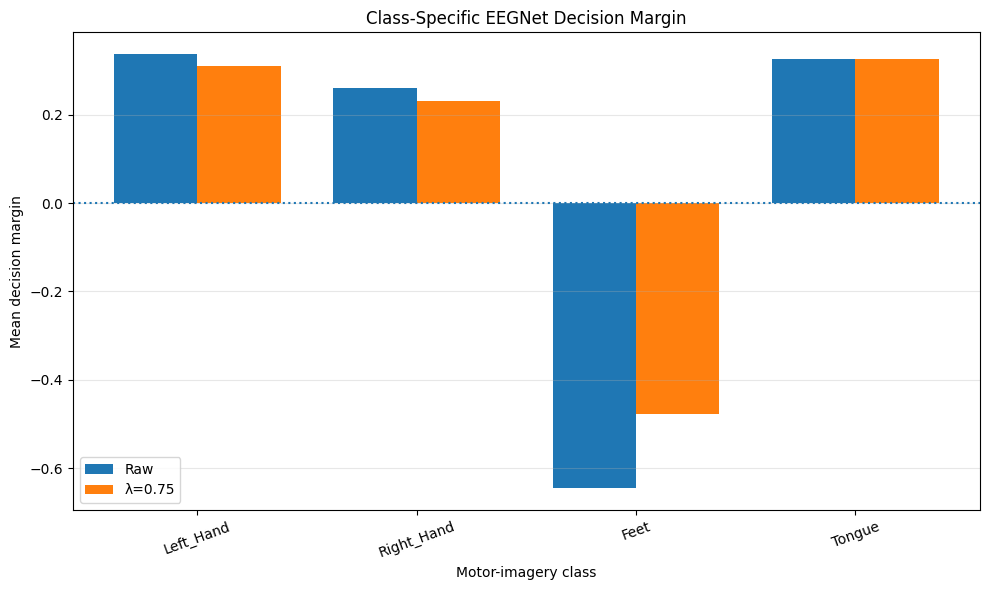

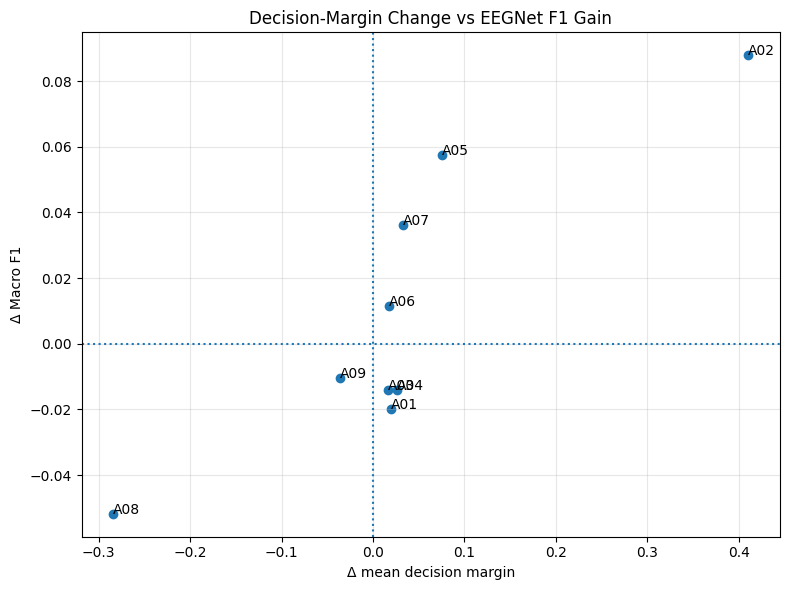

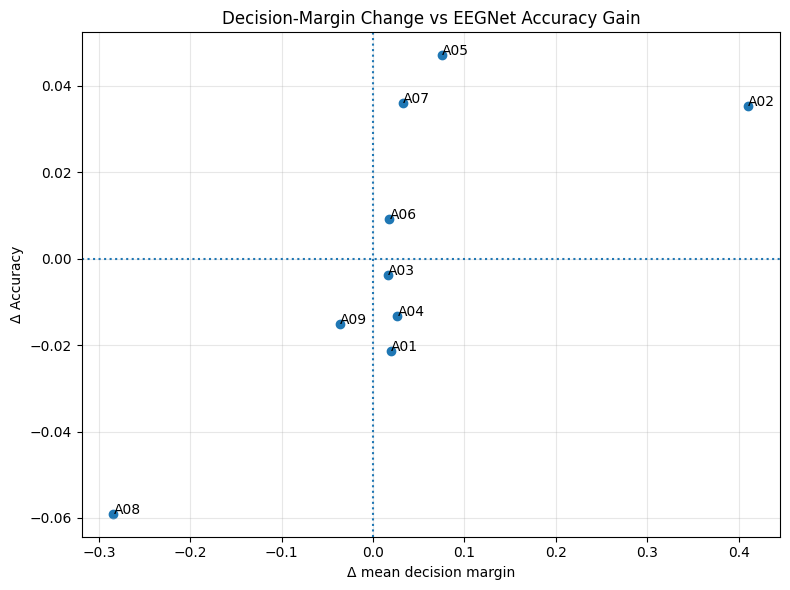

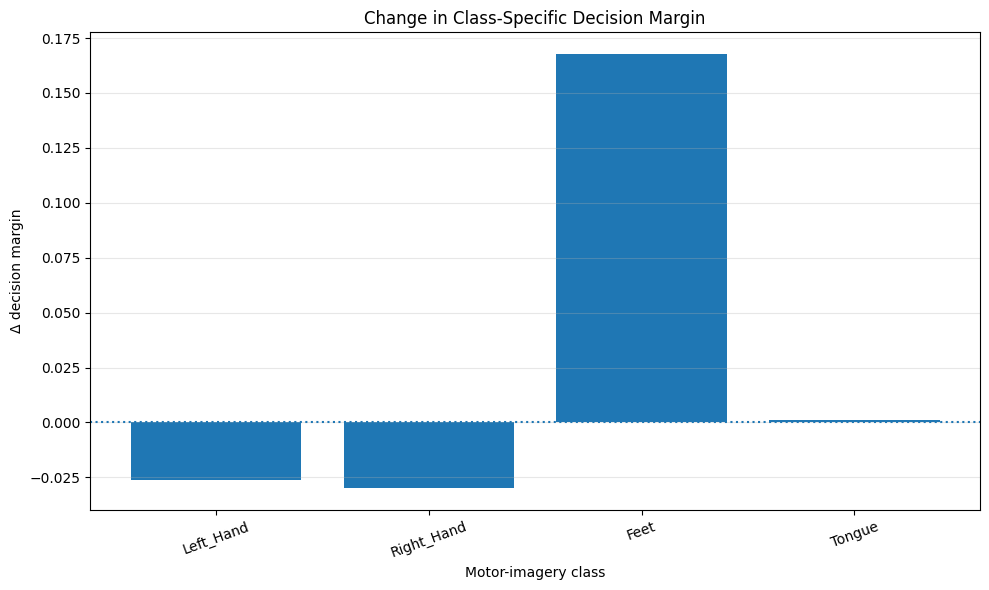



FINAL DECISION-MARGIN ANALYSIS
Mean ΔAccuracy = +0.001719
Mean ΔF1 = +0.009144
Mean Raw margin = +0.061701
Mean Clean margin = +0.092611
Mean Δ margin = +0.030910

Margin Wilcoxon:
W = 14.000000, p = 0.359375

Δ Margin vs ΔAccuracy:
Pearson r = 0.738634, p = 0.023018
Spearman rho = 0.766667, p = 0.015944

Δ Margin vs ΔF1:
Pearson r = 0.861831, p = 0.002813
Spearman rho = 0.783333, p = 0.012520

Class-specific margin results:
     Class  Raw_Mean  Clean_Mean  Mean_Change  Wilcoxon_W  Wilcoxon_p
 Left_Hand  0.337067    0.310840    -0.026227        22.0    1.000000
Right_Hand  0.259930    0.229984    -0.029946        18.0    0.652344
      Feet -0.645088   -0.477379     0.167709         9.0    0.128906
    Tongue  0.324831    0.325769     0.000939        19.0    0.734375

Class-specific error results:
     Class  Raw_Errors  Clean_Errors  Delta_Errors
 Left_Hand         262           275            13
Right_Hand         250           280            30
      Feet         411           38

In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from scipy.io import loadmat

from scipy.stats import (
    pearsonr,
    spearmanr,
    wilcoxon
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt

import mne

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "decision_margin_analysis"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

SEED = 42

FS_RAW = 250
FS = 125

N_EEG = 22
N_EOG = 3

LAMBDA = 0.75

BATCH_SIZE = 16

MAX_EPOCHS = 200

LEARNING_RATE = 0.001

PATIENCE = 50

SUBJECTS = [

    f"A{i:02d}"

    for i in range(
        1,
        10
    )

]

CLASS_NAMES = {

    0: "Left_Hand",

    1: "Right_Hand",

    2: "Feet",

    3: "Tongue"

}

def set_seed(
    seed=SEED
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

set_seed()

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else
    "cpu"

)

print(
    "Using device:",
    device
)

def load_bci2a_with_eog(

    mat_path

):

    if not os.path.exists(
        mat_path
    ):

        raise FileNotFoundError(
            mat_path
        )

    mat = loadmat(

        mat_path,

        squeeze_me=False

    )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    for run_idx in range(

        data.shape[1]

    ):

        run = data[

            0,

            run_idx

        ][

            0,

            0

        ]

        X_raw = run[
            "X"
        ]

        trials = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(

            trials.shape[0]

        ):

            if (

                artifacts[
                    trial_idx,
                    0
                ]
                ==
                1

            ):

                continue

            onset = int(

                trials[
                    trial_idx,
                    0
                ]

            )

            start = onset

            end = (

                onset
                +
                4 * FS_RAW

            )

            if end > X_raw.shape[0]:

                continue

            eeg = X_raw[

                start:end,

                :N_EEG

            ]

            eog = X_raw[

                start:end,

                N_EEG:N_EEG + N_EOG

            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            label = int(

                y[
                    trial_idx,
                    0
                ]

            ) - 1

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

    return (

        np.asarray(

            eeg_trials,

            dtype=np.float64

        ),

        np.asarray(

            eog_trials,

            dtype=np.float64

        ),

        np.asarray(

            labels,

            dtype=np.int64

        )

    )

def filter_4_38(

    X

):

    X_t = X.transpose(

        0,
        2,
        1

    )

    original_shape = X_t.shape

    flattened = X_t.reshape(

        -1,

        original_shape[-1]

    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(

        original_shape

    )

    return filtered.transpose(

        0,
        2,
        1

    )

def fit_eog_regression(

    eeg_train,

    eog_train

):

    eeg_flat = eeg_train.reshape(

        -1,

        N_EEG

    )

    eog_flat = eog_train.reshape(

        -1,

        N_EOG

    )

    X = np.column_stack([

        eog_flat,

        np.ones(
            len(
                eog_flat
            )
        )

    ])

    beta = np.zeros(

        (
            N_EEG,
            N_EOG
        ),

        dtype=np.float64

    )

    intercept = np.zeros(

        N_EEG,

        dtype=np.float64

    )

    for ch in range(
        N_EEG
    ):

        coef, _, _, _ = np.linalg.lstsq(

            X,

            eeg_flat[
                :,
                ch
            ],

            rcond=None

        )

        beta[
            ch
        ] = coef[
            :N_EOG
        ]

        intercept[
            ch
        ] = coef[
            N_EOG
        ]

    return (

        beta,

        intercept

    )

def estimate_eog_component(

    eog,

    beta,

    intercept

):

    component = np.einsum(

        "tsc,nc->tsn",

        eog,

        beta

    )

    component += intercept.reshape(

        1,
        1,
        -1

    )

    return component

class EEGNet(
    nn.Module
):

    def __init__(

        self,

        num_channels=22,

        num_classes=4,

        samples=500,

        F1=16,

        D=2,

        F2=32,

        dropout=0.5,

        kern_length=64

    ):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(

                1,

                F1,

                (
                    1,
                    kern_length
                ),

                padding=(

                    0,

                    kern_length // 2

                ),

                bias=False

            ),

            nn.BatchNorm2d(
                F1
            ),

            nn.Conv2d(

                F1,

                F1 * D,

                (
                    num_channels,
                    1
                ),

                groups=F1,

                bias=False

            ),

            nn.BatchNorm2d(

                F1 * D

            ),

            nn.ELU(),

            nn.AvgPool2d(

                (
                    1,
                    8
                )

            ),

            nn.Dropout(
                dropout
            )

        )

        self.block2 = nn.Sequential(

            nn.Conv2d(

                F1 * D,

                F2,

                (
                    1,
                    16
                ),

                padding=(

                    0,
                    8

                ),

                bias=False

            ),

            nn.BatchNorm2d(
                F2
            ),

            nn.ELU(),

            nn.AvgPool2d(

                (
                    1,
                    8
                )

            ),

            nn.Dropout(
                dropout
            )

        )

        self._flatten_size = (

            self._get_flatten_size(

                num_channels,

                samples,

                F1,

                D,

                F2,

                kern_length

            )

        )

        self.fc = nn.Linear(

            self._flatten_size,

            num_classes

        )

    def _get_flatten_size(

        self,

        C,

        T,

        F1,

        D,

        F2,

        kern_length

    ):

        x = torch.zeros(

            1,

            1,

            C,

            T

        )

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        return x.flatten(
            1
        ).shape[1]

    def extract_features(

        self,

        x

    ):

        x = x.permute(

            0,
            2,
            1

        ).unsqueeze(1)

        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        return x.flatten(
            1
        )

    def forward(

        self,

        x

    ):

        features = self.extract_features(
            x
        )

        return self.fc(
            features
        )

def create_loader(

    X,

    y,

    shuffle=False

):

    dataset = TensorDataset(

        torch.tensor(

            X,

            dtype=torch.float32

        ),

        torch.tensor(

            y,

            dtype=torch.long

        )

    )

    return DataLoader(

        dataset,

        batch_size=BATCH_SIZE,

        shuffle=shuffle,

        drop_last=False

    )

def train_raw_eegnet(

    X_train,

    y_train,

    X_val,

    y_val

):

    set_seed()

    model = EEGNet(

        num_channels=22,

        num_classes=4,

        samples=X_train.shape[1],

        F1=16,

        D=2,

        F2=32,

        dropout=0.5,

        kern_length=64

    ).to(
        device
    )

    train_loader = create_loader(

        X_train,

        y_train,

        shuffle=True

    )

    val_loader = create_loader(

        X_val,

        y_val,

        shuffle=False

    )

    optimizer = torch.optim.Adam(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=1e-4

    )

    scheduler = (

        torch.optim.lr_scheduler.CosineAnnealingLR(

            optimizer,

            T_max=MAX_EPOCHS,

            eta_min=1e-5

        )

    )

    criterion = nn.CrossEntropyLoss()

    best_val_accuracy = -np.inf

    best_state = None

    patience_counter = 0

    for epoch in range(
        MAX_EPOCHS
    ):

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            output = model(
                X_batch
            )

            loss = criterion(

                output,

                y_batch

            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                1.0

            )

            optimizer.step()

        model.eval()

        val_predictions = []

        val_targets = []

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(
                    device
                )

                output = model(
                    X_batch
                )

                predictions = output.argmax(

                    dim=1

                ).cpu().numpy()

                val_predictions.extend(
                    predictions
                )

                val_targets.extend(
                    y_batch.numpy()
                )

        val_accuracy = accuracy_score(

            val_targets,

            val_predictions

        )

        scheduler.step()

        if (

            val_accuracy
            >
            best_val_accuracy

        ):

            best_val_accuracy = val_accuracy

            best_state = {

                key:
                    value.detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()

            }

            patience_counter = 0

        else:

            patience_counter += 1

        if (

            patience_counter
            >=
            PATIENCE

        ):

            break

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    return (

        model,

        best_val_accuracy

    )

def get_logits(

    model,

    X

):

    loader = create_loader(

        X,

        np.zeros(
            len(X),
            dtype=np.int64
        ),

        shuffle=False

    )

    model.eval()

    logits = []

    with torch.no_grad():

        for X_batch, _ in loader:

            X_batch = X_batch.to(
                device
            )

            output = model(
                X_batch
            )

            logits.append(

                output
                .cpu()
                .numpy()

            )

    return np.concatenate(

        logits,

        axis=0

    )

def calculate_decision_margin(

    logits,

    labels

):

    """

    Margin =
        true-class logit
        -
        largest non-true-class logit
    """

    margins = np.zeros(
        len(labels),
        dtype=float
    )

    for i in range(
        len(labels)
    ):

        true_class = labels[
            i
        ]

        true_logit = logits[
            i,
            true_class
        ]

        other_logits = np.delete(

            logits[
                i
            ],

            true_class

        )

        competitor = np.max(
            other_logits
        )

        margins[
            i
        ] = (

            true_logit
            -
            competitor

        )

    return margins

def calculate_competitor(

    logits,

    labels

):

    competitors = np.zeros(

        len(labels),

        dtype=np.int64

    )

    for i in range(
        len(labels)
    ):

        true_class = labels[
            i
        ]

        other_logits = logits[
            i
        ].copy()

        other_logits[
            true_class
        ] = -np.inf

        competitors[
            i
        ] = np.argmax(
            other_logits
        )

    return competitors

subject_rows = []

trial_rows = []

class_rows = []

for subject_index, subject in enumerate(
    SUBJECTS
):

    print("\n")
    print(
        "=" * 110
    )

    print(
        f"PROCESSING {subject}"
    )

    print(
        "=" * 110
    )

    train_path = os.path.join(

        DATASET_DIR,

        f"{subject}T.mat"

    )

    test_path = os.path.join(

        DATASET_DIR,

        f"{subject}E.mat"

    )

    eeg_t, eog_t, y_t = (

        load_bci2a_with_eog(

            train_path

        )

    )

    eeg_e, eog_e, y_e = (

        load_bci2a_with_eog(

            test_path

        )

    )

    eeg_t = filter_4_38(
        eeg_t
    )

    eog_t = filter_4_38(
        eog_t
    )

    eeg_e = filter_4_38(
        eeg_e
    )

    eog_e = filter_4_38(
        eog_e
    )

    indices = np.arange(
        len(y_t)
    )

    train_idx, val_idx = train_test_split(

        indices,

        test_size=0.20,

        stratify=y_t,

        random_state=SEED

    )

    raw_mean = (

        eeg_t[
            train_idx
        ]

        .mean(

            axis=(0, 1),

            keepdims=True

        )

    )

    raw_std = (

        eeg_t[
            train_idx
        ]

        .std(

            axis=(0, 1),

            keepdims=True

        )

    )

    raw_std[
        raw_std < 1e-8
    ] = 1.0

    X_raw_train = (

        eeg_t[
            train_idx
        ]

        -
        raw_mean

    ) / raw_std

    X_raw_val = (

        eeg_t[
            val_idx
        ]

        -
        raw_mean

    ) / raw_std

    X_raw_test = (

        eeg_e
        -
        raw_mean

    ) / raw_std

    beta_eog, intercept_eog = (

        fit_eog_regression(

            eeg_t[
                train_idx
            ],

            eog_t[
                train_idx
            ]

        )

    )

    test_component = (

        estimate_eog_component(

            eog_e,

            beta_eog,

            intercept_eog

        )

    )

    eeg_test_clean = (

        eeg_e

        -
        LAMBDA
        *
        test_component

    )

    X_clean_test = (

        eeg_test_clean
        -
        raw_mean

    ) / raw_std

    model, best_val_accuracy = (

        train_raw_eegnet(

            X_raw_train,

            y_t[
                train_idx
            ],

            X_raw_val,

            y_t[
                val_idx
            ]

        )

    )

    raw_logits = get_logits(

        model,

        X_raw_test

    )

    clean_logits = get_logits(

        model,

        X_clean_test

    )

    raw_predictions = np.argmax(

        raw_logits,

        axis=1

    )

    clean_predictions = np.argmax(

        clean_logits,

        axis=1

    )

    raw_margins = calculate_decision_margin(

        raw_logits,

        y_e

    )

    clean_margins = calculate_decision_margin(

        clean_logits,

        y_e

    )

    delta_margins = (

        clean_margins
        -
        raw_margins

    )

    raw_competitors = calculate_competitor(

        raw_logits,

        y_e

    )

    clean_competitors = calculate_competitor(

        clean_logits,

        y_e

    )

    raw_correct = (

        raw_predictions
        ==
        y_e

    )

    clean_correct = (

        clean_predictions
        ==
        y_e

    )

    for i in range(
        len(y_e)
    ):

        true_class = int(
            y_e[
                i
            ]
        )

        trial_rows.append({

            "Subject":
                subject,

            "Trial_Index":
                i,

            "True_Class_ID":
                true_class,

            "True_Class":
                CLASS_NAMES[
                    true_class
                ],

            "Raw_Prediction":
                int(
                    raw_predictions[
                        i
                    ]
                ),

            "Raw_Predicted_Class":
                CLASS_NAMES[
                    int(
                        raw_predictions[
                            i
                        ]
                    )
                ],

            "Clean_Prediction":
                int(
                    clean_predictions[
                        i
                    ]
                ),

            "Clean_Predicted_Class":
                CLASS_NAMES[
                    int(
                        clean_predictions[
                            i
                        ]
                    )
                ],

            "Raw_Margin":
                raw_margins[
                    i
                ],

            "Clean_Margin":
                clean_margins[
                    i
                ],

            "Delta_Margin":
                delta_margins[
                    i
                ],

            "Raw_Correct":
                bool(
                    raw_correct[
                        i
                    ]
                ),

            "Clean_Correct":
                bool(
                    clean_correct[
                        i
                    ]
                ),

            "Raw_Competitor":
                int(
                    raw_competitors[
                        i
                    ]
                ),

            "Clean_Competitor":
                int(
                    clean_competitors[
                        i
                    ]
                )

        })

    for class_id in range(4):

        class_name = CLASS_NAMES[
            class_id
        ]

        mask = (

            y_e
            ==
            class_id

        )

        if mask.sum() == 0:

            continue

        raw_class_accuracy = np.mean(

            raw_correct[
                mask
            ]

        )

        clean_class_accuracy = np.mean(

            clean_correct[
                mask
            ]

        )

        class_rows.append({

            "Subject":
                subject,

            "Class_ID":
                class_id,

            "Class":
                class_name,

            "N_Trials":
                int(
                    mask.sum()
                ),

            "Raw_Mean_Margin":
                np.mean(
                    raw_margins[
                        mask
                    ]
                ),

            "Clean_Mean_Margin":
                np.mean(
                    clean_margins[
                        mask
                    ]
                ),

            "Delta_Mean_Margin":
                np.mean(
                    delta_margins[
                        mask
                    ]
                ),

            "Raw_Class_Accuracy":
                raw_class_accuracy,

            "Clean_Class_Accuracy":
                clean_class_accuracy,

            "Delta_Class_Accuracy":
                (
                    clean_class_accuracy
                    -
                    raw_class_accuracy
                ),

            "Raw_Correct":
                int(
                    raw_correct[
                        mask
                    ].sum()
                ),

            "Clean_Correct":
                int(
                    clean_correct[
                        mask
                    ].sum()
                ),

            "Delta_Correct":
                int(
                    clean_correct[
                        mask
                    ].sum()
                    -
                    raw_correct[
                        mask
                    ].sum()
                )

        })

    raw_accuracy = accuracy_score(

        y_e,

        raw_predictions

    )

    clean_accuracy = accuracy_score(

        y_e,

        clean_predictions

    )

    raw_f1 = f1_score(

        y_e,

        raw_predictions,

        average="macro"

    )

    clean_f1 = f1_score(

        y_e,

        clean_predictions,

        average="macro"

    )

    subject_rows.append({

        "Subject":
            subject,

        "Best_Validation_Accuracy":
            best_val_accuracy,

        "Raw_Accuracy":
            raw_accuracy,

        "Clean_Accuracy":
            clean_accuracy,

        "Delta_Accuracy":
            (
                clean_accuracy
                -
                raw_accuracy
            ),

        "Raw_F1":
            raw_f1,

        "Clean_F1":
            clean_f1,

        "Delta_F1":
            (
                clean_f1
                -
                raw_f1
            ),

        "Raw_Mean_Margin":
            np.mean(
                raw_margins
            ),

        "Clean_Mean_Margin":
            np.mean(
                clean_margins
            ),

        "Delta_Mean_Margin":
            np.mean(
                delta_margins
            )

    })

    print(
        f"Raw Accuracy = "
        f"{raw_accuracy:.4f}"
    )

    print(
        f"Clean Accuracy = "
        f"{clean_accuracy:.4f}"
    )

    print(
        f"Δ Accuracy = "
        f"{clean_accuracy - raw_accuracy:+.4f}"
    )

    print(
        f"Raw F1 = "
        f"{raw_f1:.4f}"
    )

    print(
        f"Clean F1 = "
        f"{clean_f1:.4f}"
    )

    print(
        f"Δ F1 = "
        f"{clean_f1 - raw_f1:+.4f}"
    )

    print(
        f"Raw mean margin = "
        f"{np.mean(raw_margins):+.5f}"
    )

    print(
        f"Clean mean margin = "
        f"{np.mean(clean_margins):+.5f}"
    )

    print(
        f"Δ mean margin = "
        f"{np.mean(delta_margins):+.5f}"
    )

subject_df = pd.DataFrame(
    subject_rows
)

class_df = pd.DataFrame(
    class_rows
)

trial_df = pd.DataFrame(
    trial_rows
)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT-LEVEL DECISION MARGIN RESULTS"
)

print(
    "=" * 110
)

print(

    subject_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS-SPECIFIC DECISION MARGIN RESULTS"
)

print(
    "=" * 110
)

class_summary = (

    class_df

    .groupby(
        "Class"
    )[

        [

            "Raw_Mean_Margin",

            "Clean_Mean_Margin",

            "Delta_Mean_Margin",

            "Raw_Class_Accuracy",

            "Clean_Class_Accuracy",

            "Delta_Class_Accuracy"

        ]

    ]

    .mean()

)

print(

    class_summary.round(
        6
    ).to_string()

)

print("\n")
print(
    "=" * 110
)

print(
    "DECISION-MARGIN CHANGE vs ΔACCURACY"
)

print(
    "=" * 110
)

margin_change = subject_df[
    "Delta_Mean_Margin"
].to_numpy(
    dtype=float
)

delta_accuracy = subject_df[
    "Delta_Accuracy"
].to_numpy(
    dtype=float
)

margin_acc_r, margin_acc_p = pearsonr(

    margin_change,

    delta_accuracy

)

margin_acc_rho, margin_acc_rho_p = spearmanr(

    margin_change,

    delta_accuracy

)

print(
    f"Pearson r = "
    f"{margin_acc_r:.6f}"
)

print(
    f"Pearson p = "
    f"{margin_acc_p:.6f}"
)

print(
    f"Spearman rho = "
    f"{margin_acc_rho:.6f}"
)

print(
    f"Spearman p = "
    f"{margin_acc_rho_p:.6f}"
)

print("\n")
print(
    "=" * 110
)

print(
    "DECISION-MARGIN CHANGE vs ΔF1"
)

print(
    "=" * 110
)

delta_f1 = subject_df[
    "Delta_F1"
].to_numpy(
    dtype=float
)

margin_f1_r, margin_f1_p = pearsonr(

    margin_change,

    delta_f1

)

margin_f1_rho, margin_f1_rho_p = spearmanr(

    margin_change,

    delta_f1

)

print(
    f"Pearson r = "
    f"{margin_f1_r:.6f}"
)

print(
    f"Pearson p = "
    f"{margin_f1_p:.6f}"
)

print(
    f"Spearman rho = "
    f"{margin_f1_rho:.6f}"
)

print(
    f"Spearman p = "
    f"{margin_f1_rho_p:.6f}"
)

print("\n")
print(
    "=" * 110
)

print(
    "RAW vs CLEAN DECISION MARGIN"
)

print(
    "=" * 110
)

try:

    margin_W, margin_p = wilcoxon(

        subject_df[
            "Clean_Mean_Margin"
        ],

        subject_df[
            "Raw_Mean_Margin"
        ]

    )

except Exception:

    margin_W = np.nan

    margin_p = np.nan

print(
    f"Wilcoxon W = "
    f"{margin_W:.6f}"
)

print(
    f"Wilcoxon p = "
    f"{margin_p:.6f}"
)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS-SPECIFIC MARGIN TESTS"
)

print(
    "=" * 110
)

class_margin_test_rows = []

for class_id, class_name in CLASS_NAMES.items():

    temp = class_df[

        class_df[
            "Class_ID"
        ]
        ==
        class_id

    ]

    raw = temp[
        "Raw_Mean_Margin"
    ].to_numpy(
        dtype=float
    )

    clean = temp[
        "Clean_Mean_Margin"
    ].to_numpy(
        dtype=float
    )

    if len(raw) >= 3:

        try:

            W, p = wilcoxon(

                clean,

                raw

            )

        except Exception:

            W = np.nan
            p = np.nan

    else:

        W = np.nan
        p = np.nan

    class_margin_test_rows.append({

        "Class":
            class_name,

        "Raw_Mean":
            np.mean(raw),

        "Clean_Mean":
            np.mean(clean),

        "Mean_Change":
            np.mean(
                clean
                -
                raw
            ),

        "Wilcoxon_W":
            W,

        "Wilcoxon_p":
            p

    })

class_margin_test_df = pd.DataFrame(

    class_margin_test_rows

)

print(

    class_margin_test_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS MARGIN CHANGE vs CLASS ACCURACY CHANGE"
)

print(
    "=" * 110
)

class_margin_corr_rows = []

for class_id, class_name in CLASS_NAMES.items():

    temp = class_df[

        class_df[
            "Class_ID"
        ]
        ==
        class_id

    ]

    x = temp[
        "Delta_Mean_Margin"
    ].to_numpy(
        dtype=float
    )

    y = temp[
        "Delta_Class_Accuracy"
    ].to_numpy(
        dtype=float
    )

    if len(x) >= 3:

        r, p = pearsonr(
            x,
            y
        )

        rho, rho_p = spearmanr(
            x,
            y
        )

    else:

        r = np.nan
        p = np.nan

        rho = np.nan
        rho_p = np.nan

    class_margin_corr_rows.append({

        "Class":
            class_name,

        "Pearson_r":
            r,

        "Pearson_p":
            p,

        "Spearman_rho":
            rho,

        "Spearman_p":
            rho_p

    })

class_margin_corr_df = pd.DataFrame(

    class_margin_corr_rows

)

print(

    class_margin_corr_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "MARGIN CHANGE FOR CORRECT vs INCORRECT TRIALS"
)

print(
    "=" * 110
)

trial_df[
    "Raw_Status"
] = np.where(

    trial_df[
        "Raw_Correct"
    ],

    "Correct",

    "Incorrect"

)

trial_df[
    "Clean_Status"
] = np.where(

    trial_df[
        "Clean_Correct"
    ],

    "Correct",

    "Incorrect"

)

trial_df[
    "Outcome_Transition"
] = (

    trial_df[
        "Raw_Status"
    ]

    +

    "_to_"

    +

    trial_df[
        "Clean_Status"
    ]

)

transition_summary = (

    trial_df

    .groupby(
        "Outcome_Transition"
    )[

        [

            "Raw_Margin",

            "Clean_Margin",

            "Delta_Margin"

        ]

    ]

    .agg(

        [

            "count",

            "mean"

        ]

    )

)

print(

    transition_summary.round(
        6
    ).to_string()

)

flip_mask = (

    trial_df[
        "Raw_Correct"
    ]

    !=

    trial_df[
        "Clean_Correct"
    ]

)

flip_df = trial_df[
    flip_mask
].copy()

print("\n")
print(
    "=" * 110
)

print(
    "TRIALS WHOSE CORRECTNESS CHANGED"
)

print(
    "=" * 110
)

print(
    "Number of flips:",
    len(flip_df)
)

if len(flip_df) > 0:

    print(

        flip_df[

            [

                "Subject",

                "True_Class",

                "Raw_Predicted_Class",

                "Clean_Predicted_Class",

                "Raw_Margin",

                "Clean_Margin",

                "Delta_Margin",

                "Outcome_Transition"

            ]

        ]

        .head(50)

        .round(6)

        .to_string(
            index=False
        )

    )

error_class_rows = []

for class_id, class_name in CLASS_NAMES.items():

    temp = trial_df[

        trial_df[
            "True_Class_ID"
        ]
        ==
        class_id

    ]

    raw_errors = (

        ~temp[
            "Raw_Correct"
        ]

    ).sum()

    clean_errors = (

        ~temp[
            "Clean_Correct"
        ]

    ).sum()

    error_class_rows.append({

        "Class":
            class_name,

        "Raw_Errors":
            int(
                raw_errors
            ),

        "Clean_Errors":
            int(
                clean_errors
            ),

        "Delta_Errors":
            int(
                clean_errors
                -
                raw_errors
            )

    })

error_class_df = pd.DataFrame(

    error_class_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS-SPECIFIC ERROR CHANGE"
)

print(
    "=" * 110
)

print(

    error_class_df.round(
        4
    ).to_string(
        index=False
    )

)

competitor_transitions = (

    trial_df

    .groupby(

        [

            "True_Class",

            "Raw_Competitor",

            "Clean_Competitor"

        ]

    )

    .size()

    .reset_index(
        name="N"

    )

)

competitor_transitions[
    "Raw_Competitor"
] = competitor_transitions[
    "Raw_Competitor"
].map(

    CLASS_NAMES

)

competitor_transitions[
    "Clean_Competitor"
] = competitor_transitions[
    "Clean_Competitor"
].map(

    CLASS_NAMES

)

print("\n")
print(
    "=" * 110
)

print(
    "COMPETITOR TRANSITIONS"
)

print(
    "=" * 110
)

print(

    competitor_transitions

    .sort_values(
        "N",
        ascending=False
    )

    .head(30)

    .to_string(
        index=False
    )

)

plot_class = class_summary.reindex(

    [

        "Left_Hand",

        "Right_Hand",

        "Feet",

        "Tongue"

    ]

)

x = np.arange(
    len(plot_class)
)

width = 0.38

plt.figure(
    figsize=(10, 6)
)

plt.bar(

    x - width / 2,

    plot_class[
        "Raw_Mean_Margin"
    ],

    width,

    label="Raw"

)

plt.bar(

    x + width / 2,

    plot_class[
        "Clean_Mean_Margin"
    ],

    width,

    label="λ=0.75"

)

plt.axhline(

    0,

    linestyle=":"

)

plt.xticks(

    x,

    plot_class.index,

    rotation=20

)

plt.xlabel(
    "Motor-imagery class"
)

plt.ylabel(
    "Mean decision margin"
)

plt.title(
    "Class-Specific EEGNet Decision Margin"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_DIR,

        "class_specific_decision_margin.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(8, 6)
)

plt.scatter(

    subject_df[
        "Delta_Mean_Margin"
    ],

    subject_df[
        "Delta_F1"
    ]

)

for _, row in subject_df.iterrows():

    plt.annotate(

        row[
            "Subject"
        ],

        (

            row[
                "Delta_Mean_Margin"
            ],

            row[
                "Delta_F1"
            ]

        )

    )

plt.axhline(
    0,
    linestyle=":"
)

plt.axvline(
    0,
    linestyle=":"
)

plt.xlabel(
    "Δ mean decision margin"
)

plt.ylabel(
    "Δ Macro F1"
)

plt.title(
    "Decision-Margin Change vs EEGNet F1 Gain"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_DIR,

        "decision_margin_vs_delta_f1.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(8, 6)
)

plt.scatter(

    subject_df[
        "Delta_Mean_Margin"
    ],

    subject_df[
        "Delta_Accuracy"
    ]

)

for _, row in subject_df.iterrows():

    plt.annotate(

        row[
            "Subject"
        ],

        (

            row[
                "Delta_Mean_Margin"
            ],

            row[
                "Delta_Accuracy"
            ]

        )

    )

plt.axhline(
    0,
    linestyle=":"
)

plt.axvline(
    0,
    linestyle=":"
)

plt.xlabel(
    "Δ mean decision margin"
)

plt.ylabel(
    "Δ Accuracy"
)

plt.title(
    "Decision-Margin Change vs EEGNet Accuracy Gain"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_DIR,

        "decision_margin_vs_delta_accuracy.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.figure(
    figsize=(10, 6)
)

plt.bar(

    x,

    plot_class[
        "Delta_Mean_Margin"
    ]

)

plt.axhline(

    0,

    linestyle=":"

)

plt.xticks(

    x,

    plot_class.index,

    rotation=20

)

plt.xlabel(
    "Motor-imagery class"
)

plt.ylabel(
    "Δ decision margin"
)

plt.title(
    "Change in Class-Specific Decision Margin"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_DIR,

        "delta_class_decision_margin.png"

    ),

    dpi=300,

    bbox_inches="tight"

)

plt.show()

trial_file = os.path.join(

    OUTPUT_DIR,

    "trial_level_decision_margins.csv"

)

trial_df.to_csv(

    trial_file,

    index=False

)

subject_file = os.path.join(

    OUTPUT_DIR,

    "subject_decision_margin_results.csv"

)

subject_df.to_csv(

    subject_file,

    index=False

)

class_file = os.path.join(

    OUTPUT_DIR,

    "class_decision_margin_results.csv"

)

class_df.to_csv(

    class_file,

    index=False

)

class_margin_test_file = os.path.join(

    OUTPUT_DIR,

    "class_decision_margin_paired_tests.csv"

)

class_margin_test_df.to_csv(

    class_margin_test_file,

    index=False

)

class_margin_corr_file = os.path.join(

    OUTPUT_DIR,

    "class_margin_vs_class_accuracy.csv"

)

class_margin_corr_df.to_csv(

    class_margin_corr_file,

    index=False

)

error_file = os.path.join(

    OUTPUT_DIR,

    "class_specific_error_change.csv"

)

error_class_df.to_csv(

    error_file,

    index=False

)

transition_file = os.path.join(

    OUTPUT_DIR,

    "margin_outcome_transitions.csv"

)

transition_summary.to_csv(

    transition_file

)

competitor_file = os.path.join(

    OUTPUT_DIR,

    "competitor_transitions.csv"

)

competitor_transitions.to_csv(

    competitor_file,

    index=False

)

summary_df = pd.DataFrame({

    "Metric": [

        "Mean_Raw_Accuracy",

        "Mean_Clean_Accuracy",

        "Mean_Delta_Accuracy",

        "Mean_Raw_F1",

        "Mean_Clean_F1",

        "Mean_Delta_F1",

        "Mean_Raw_Margin",

        "Mean_Clean_Margin",

        "Mean_Delta_Margin",

        "Margin_Wilcoxon_W",

        "Margin_Wilcoxon_p",

        "Margin_vs_Accuracy_Pearson_r",

        "Margin_vs_Accuracy_Pearson_p",

        "Margin_vs_Accuracy_Spearman_rho",

        "Margin_vs_Accuracy_Spearman_p",

        "Margin_vs_F1_Pearson_r",

        "Margin_vs_F1_Pearson_p",

        "Margin_vs_F1_Spearman_rho",

        "Margin_vs_F1_Spearman_p"

    ],

    "Value": [

        subject_df[
            "Raw_Accuracy"
        ].mean(),

        subject_df[
            "Clean_Accuracy"
        ].mean(),

        subject_df[
            "Delta_Accuracy"
        ].mean(),

        subject_df[
            "Raw_F1"
        ].mean(),

        subject_df[
            "Clean_F1"
        ].mean(),

        subject_df[
            "Delta_F1"
        ].mean(),

        subject_df[
            "Raw_Mean_Margin"
        ].mean(),

        subject_df[
            "Clean_Mean_Margin"
        ].mean(),

        subject_df[
            "Delta_Mean_Margin"
        ].mean(),

        margin_W,

        margin_p,

        margin_acc_r,

        margin_acc_p,

        margin_acc_rho,

        margin_acc_rho_p,

        margin_f1_r,

        margin_f1_p,

        margin_f1_rho,

        margin_f1_rho_p

    ]

})

summary_file = os.path.join(

    OUTPUT_DIR,

    "decision_margin_final_summary.csv"

)

summary_df.to_csv(

    summary_file,

    index=False

)

print("\n")
print(
    "=" * 110
)

print(
    "FINAL DECISION-MARGIN ANALYSIS"
)

print(
    "=" * 110
)

print(

    f"Mean ΔAccuracy = "
    f"{subject_df['Delta_Accuracy'].mean():+.6f}"

)

print(

    f"Mean ΔF1 = "
    f"{subject_df['Delta_F1'].mean():+.6f}"

)

print(

    f"Mean Raw margin = "
    f"{subject_df['Raw_Mean_Margin'].mean():+.6f}"

)

print(

    f"Mean Clean margin = "
    f"{subject_df['Clean_Mean_Margin'].mean():+.6f}"

)

print(

    f"Mean Δ margin = "
    f"{subject_df['Delta_Mean_Margin'].mean():+.6f}"

)

print(

    "\nMargin Wilcoxon:"
)

print(

    f"W = {margin_W:.6f}, "
    f"p = {margin_p:.6f}"

)

print(

    "\nΔ Margin vs ΔAccuracy:"
)

print(

    f"Pearson r = {margin_acc_r:.6f}, "
    f"p = {margin_acc_p:.6f}"

)

print(

    f"Spearman rho = {margin_acc_rho:.6f}, "
    f"p = {margin_acc_rho_p:.6f}"

)

print(

    "\nΔ Margin vs ΔF1:"
)

print(

    f"Pearson r = {margin_f1_r:.6f}, "
    f"p = {margin_f1_p:.6f}"

)

print(

    f"Spearman rho = {margin_f1_rho:.6f}, "
    f"p = {margin_f1_rho_p:.6f}"

)

print(

    "\nClass-specific margin results:"

)

print(

    class_margin_test_df.round(
        6
    ).to_string(
        index=False
    )

)

print(

    "\nClass-specific error results:"

)

print(

    error_class_df.to_string(
        index=False
    )

)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print(
    "\nImportant files:"
)

print(
    trial_file
)

print(
    subject_file
)

print(
    class_file
)

print(
    class_margin_test_file
)

print(
    class_margin_corr_file
)

print(
    error_file
)

print(
    summary_file
)

print("\n")
print(
    "=" * 110
)

print(
    "DECISION-MARGIN ANALYSIS COMPLETE"
)

print(
    "=" * 110
)


## Full-Duration Sensorimotor ERD/ERS



PROCESSING A01
Complete 7.5 s trials: 273
Skipped artifact trials: 15
Skipped incomplete trials: 0
Complete 7.5 s trials: 281
Skipped artifact trials: 7
Skipped incomplete trials: 0
Epoch length: 938 samples = 7.5040 s
Filtering EEG 4–38 Hz...
Filtering EOG 4–38 Hz...
Fitting training-only EOG regression...

Δ Accuracy = -0.02491
Δ F1 = -0.02791


PROCESSING A02
Complete 7.5 s trials: 270
Skipped artifact trials: 18
Skipped incomplete trials: 0
Complete 7.5 s trials: 283
Skipped artifact trials: 5
Skipped incomplete trials: 0
Epoch length: 938 samples = 7.5040 s
Filtering EEG 4–38 Hz...
Filtering EOG 4–38 Hz...
Fitting training-only EOG regression...

Δ Accuracy = -0.03887
Δ F1 = -0.02708


PROCESSING A03
Complete 7.5 s trials: 270
Skipped artifact trials: 18
Skipped incomplete trials: 0
Complete 7.5 s trials: 273
Skipped artifact trials: 15
Skipped incomplete trials: 0
Epoch length: 938 samples = 7.5040 s
Filtering EEG 4–38 Hz...
Filtering EOG 4–38 Hz...
Fitting training-only EOG re

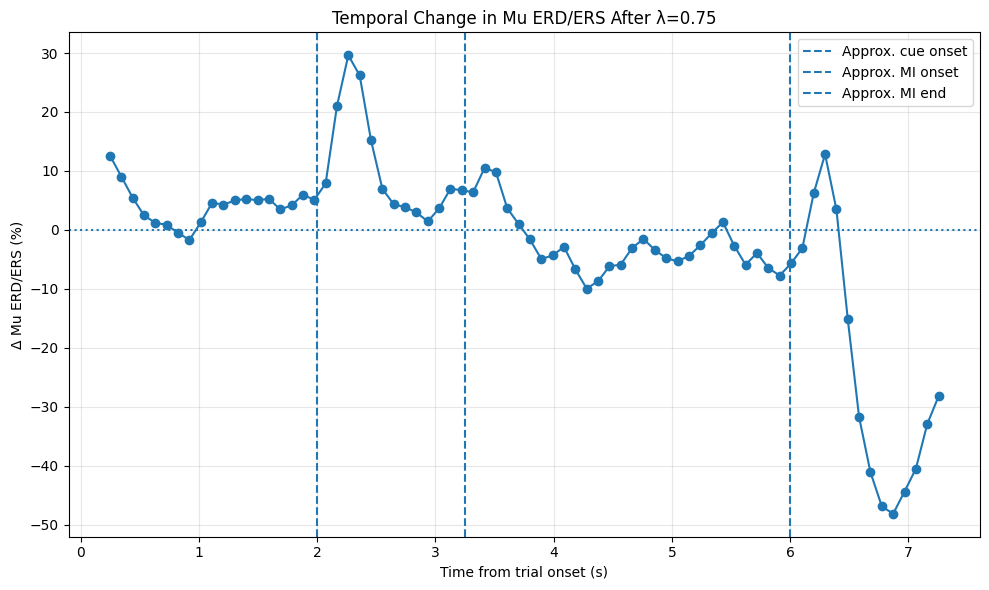

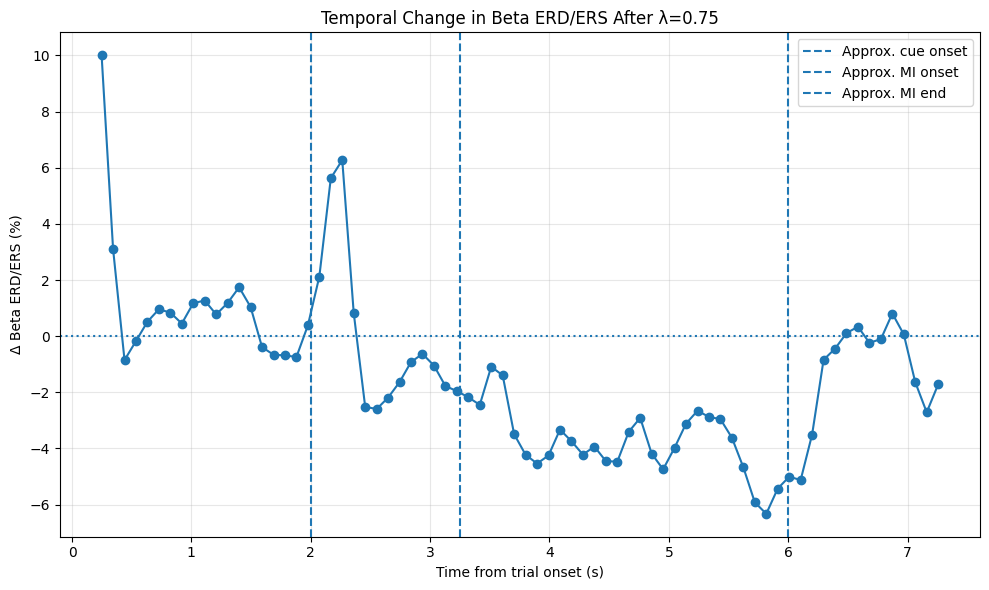

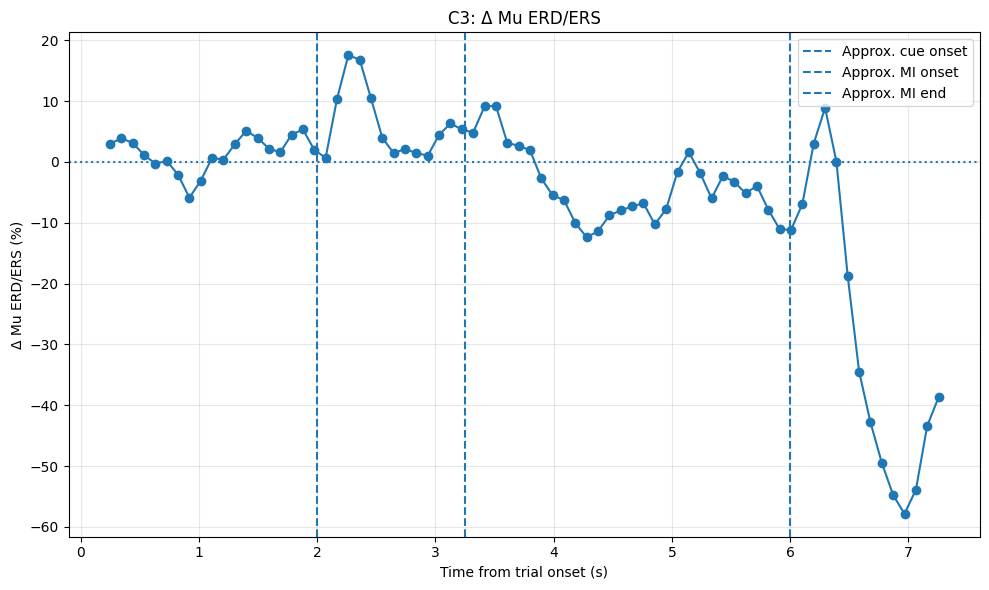

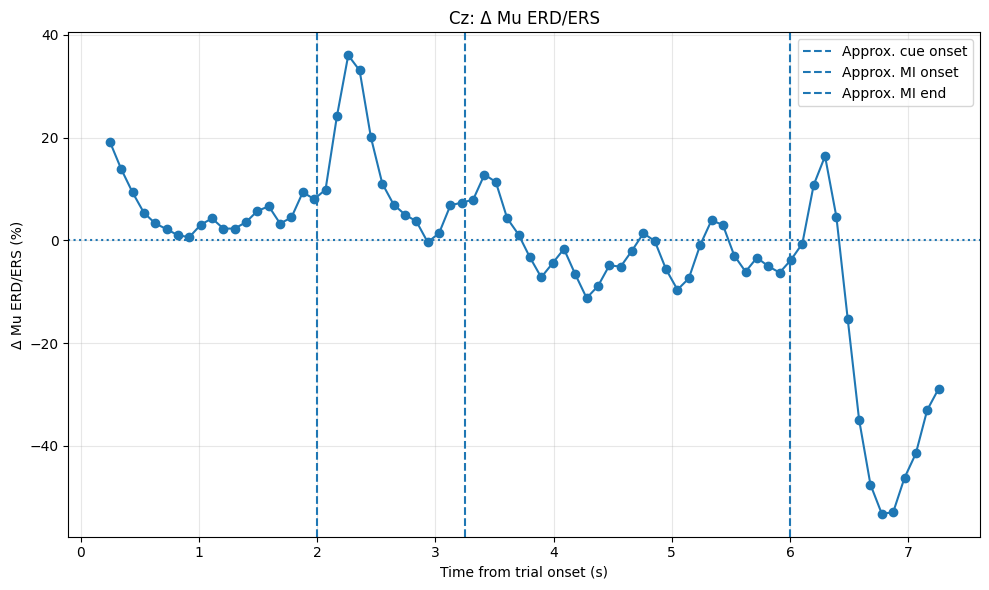

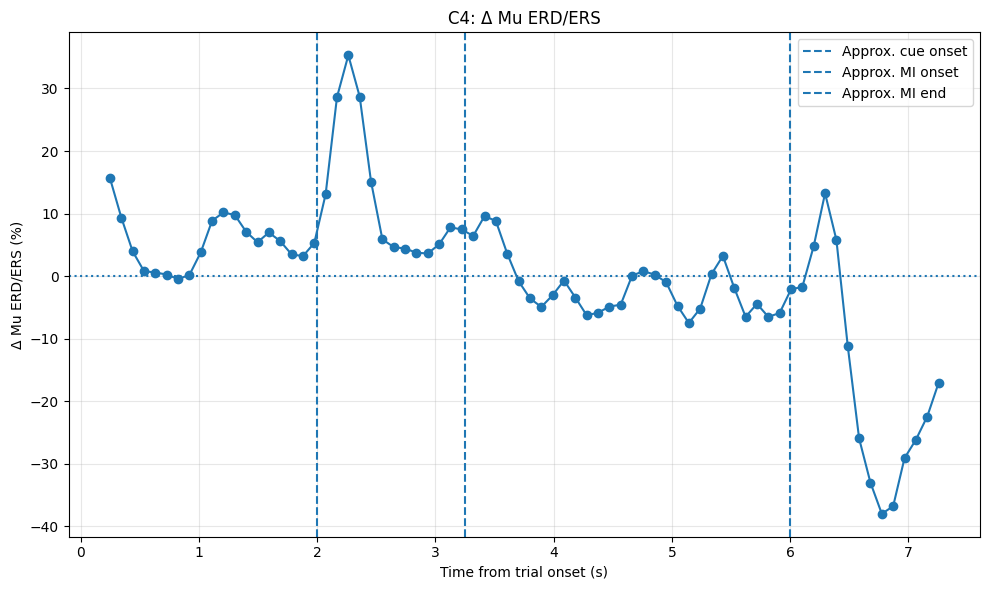

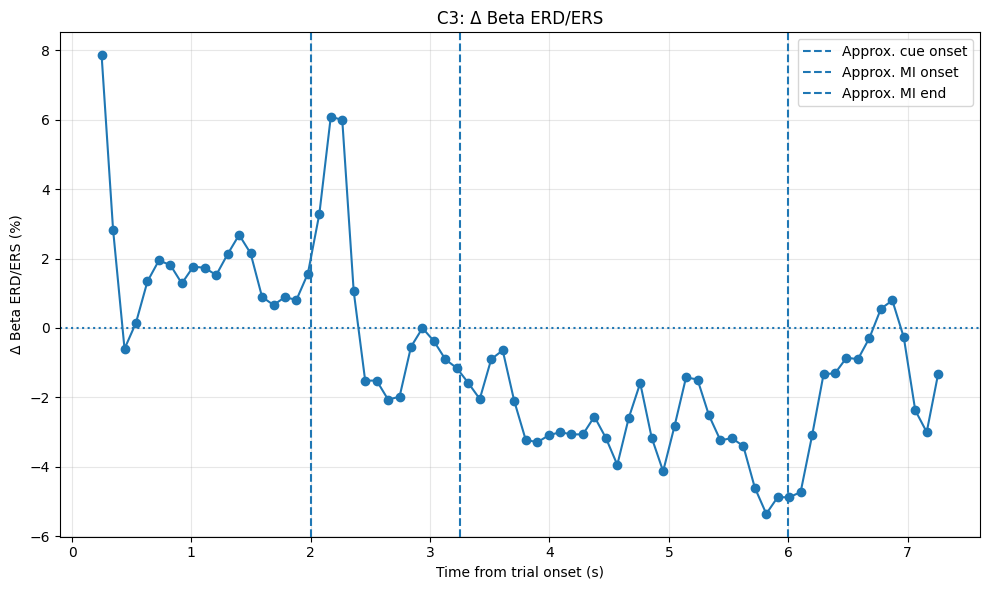

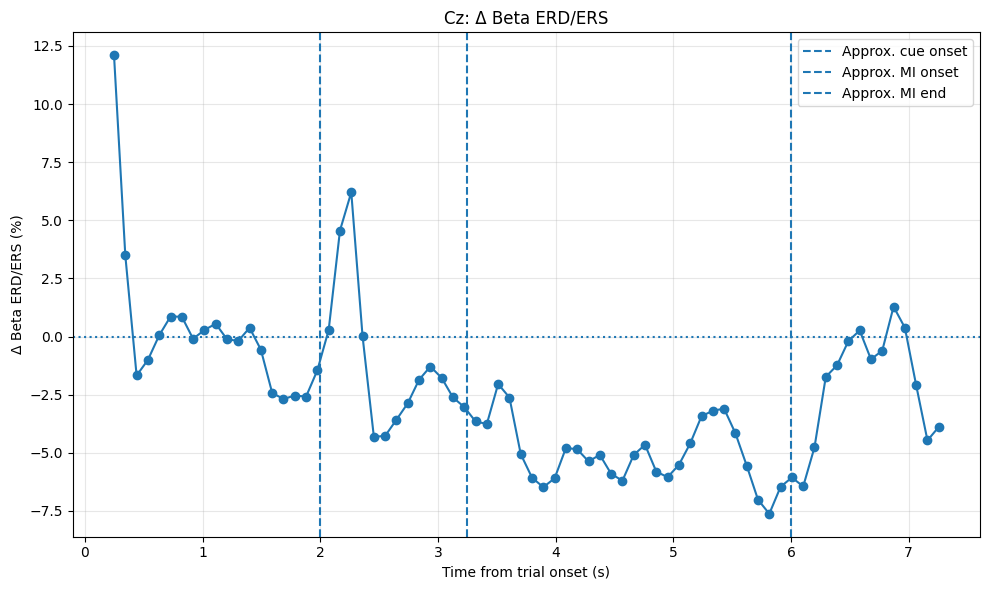

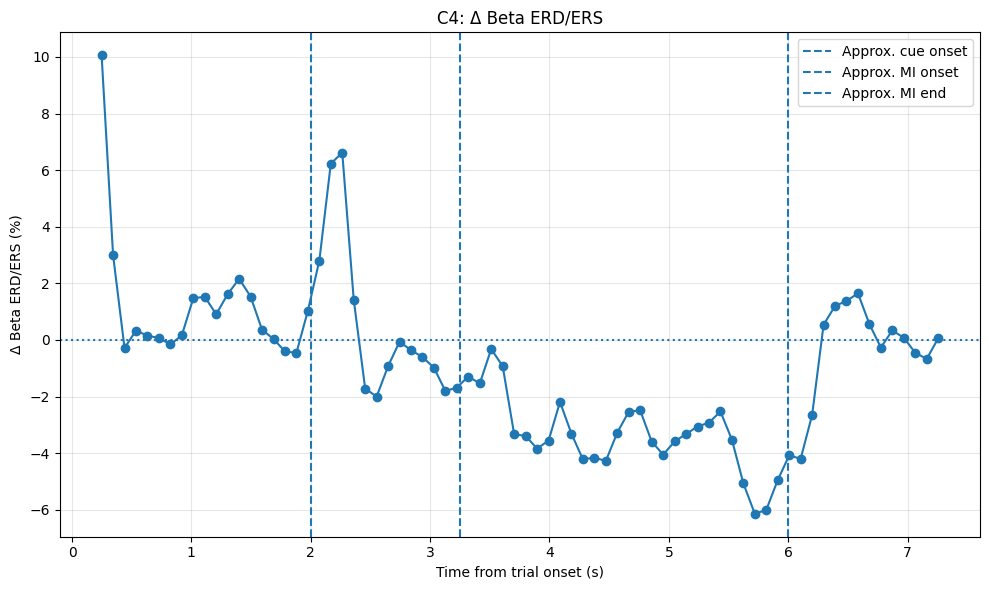

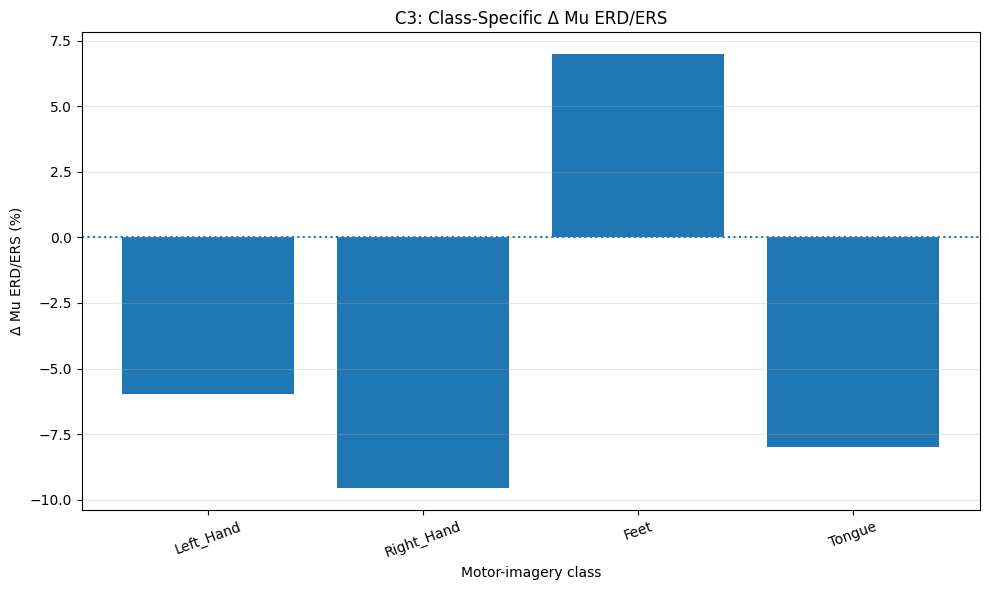

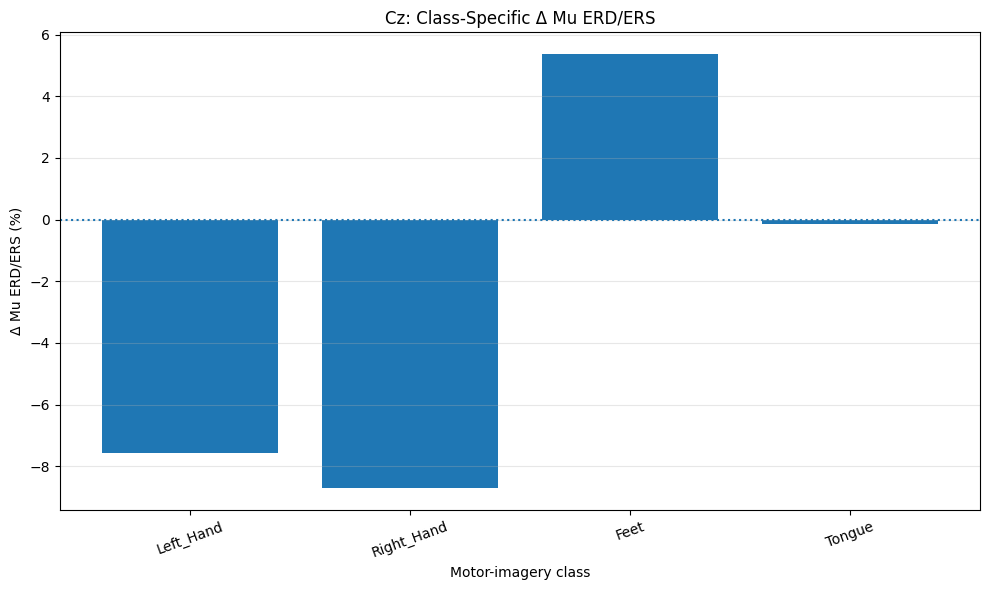

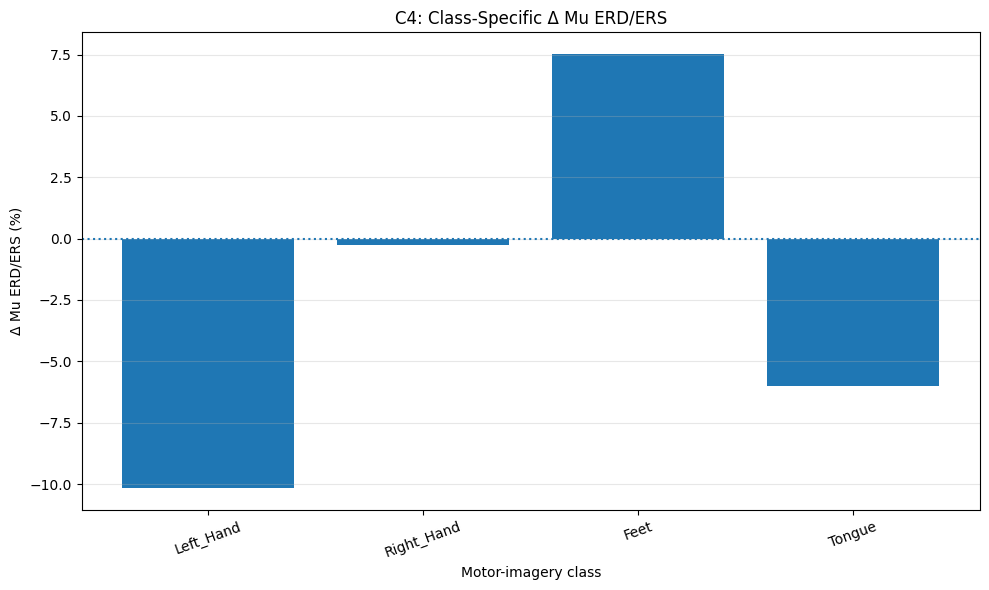

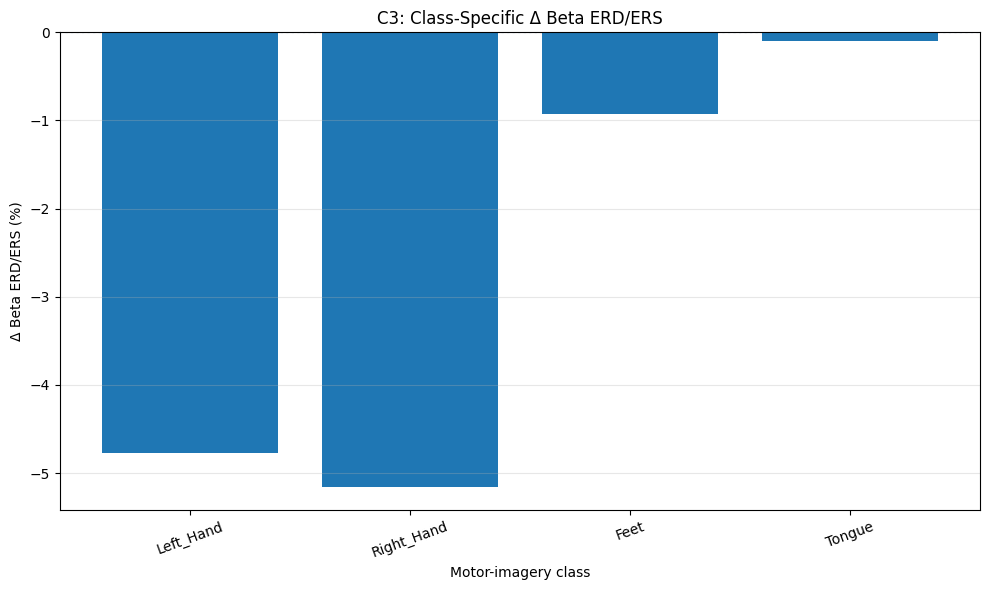

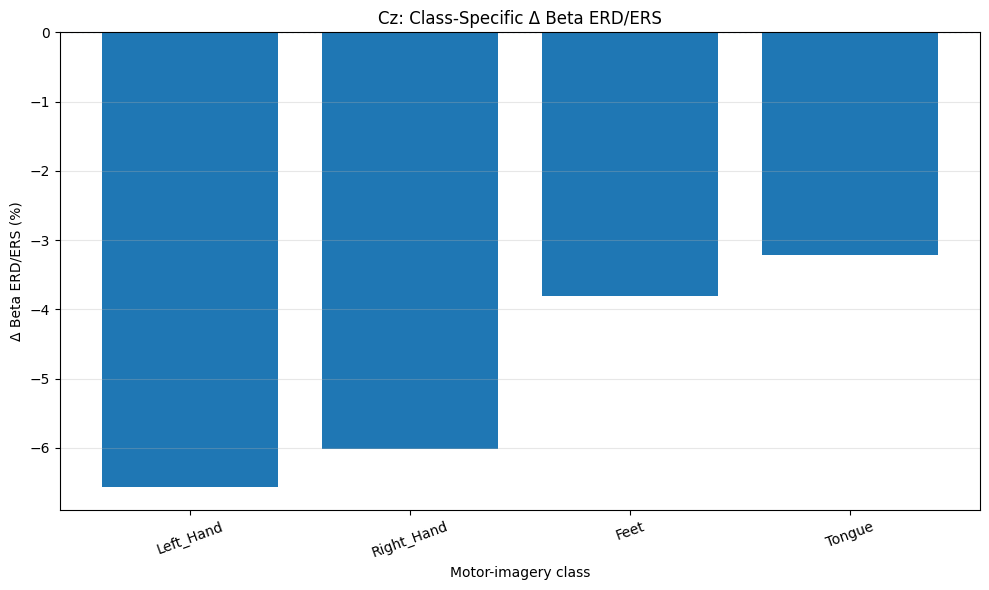

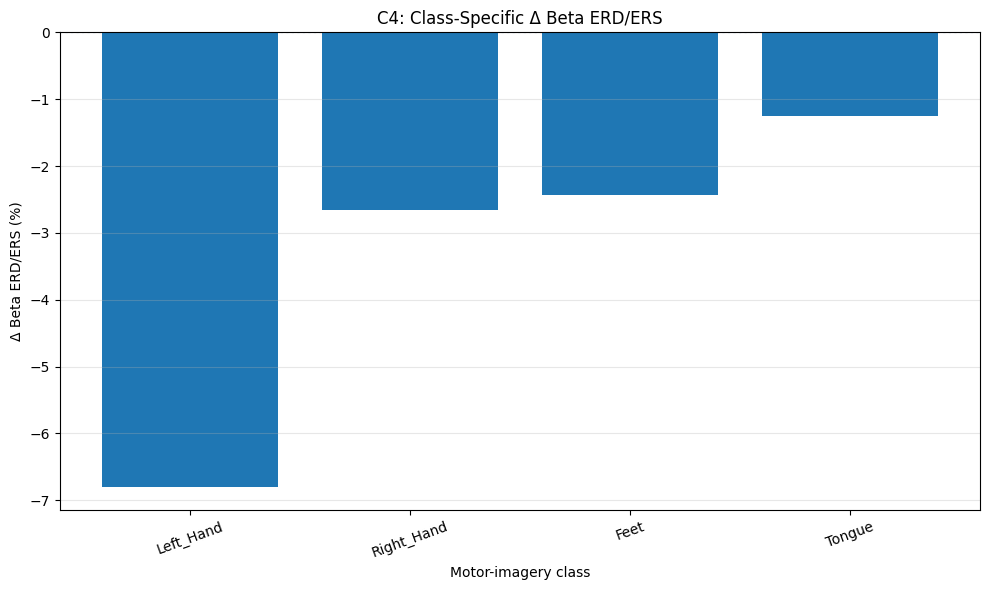

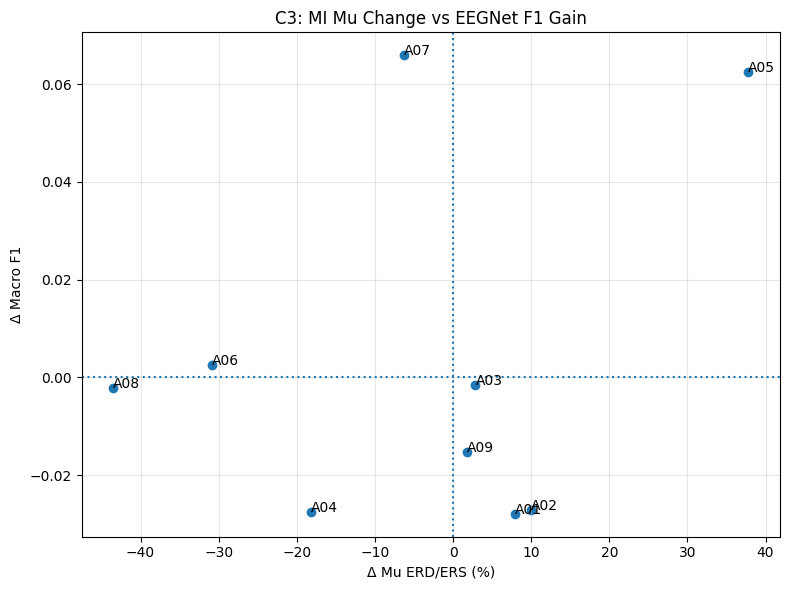

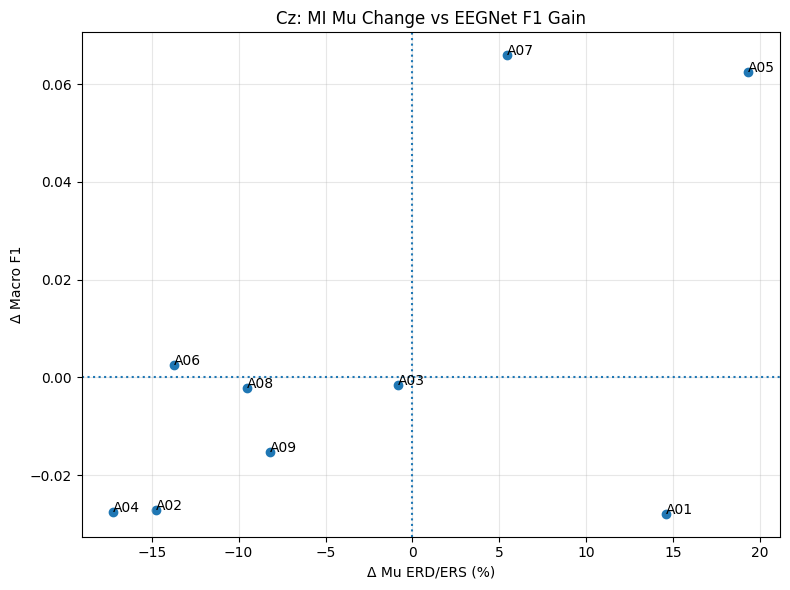

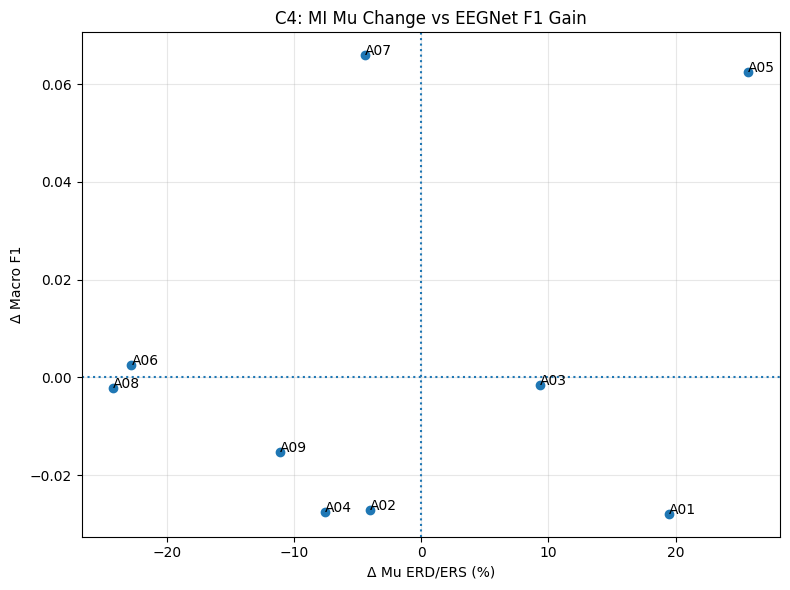

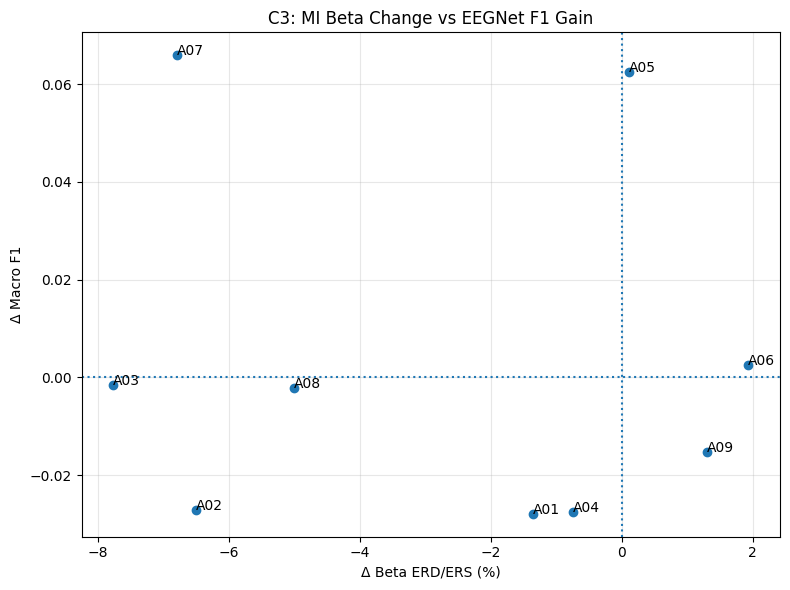

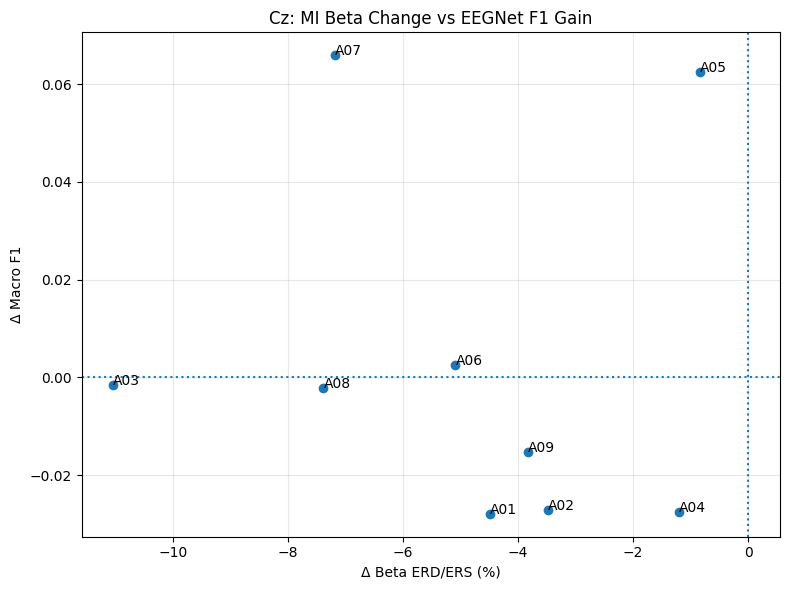

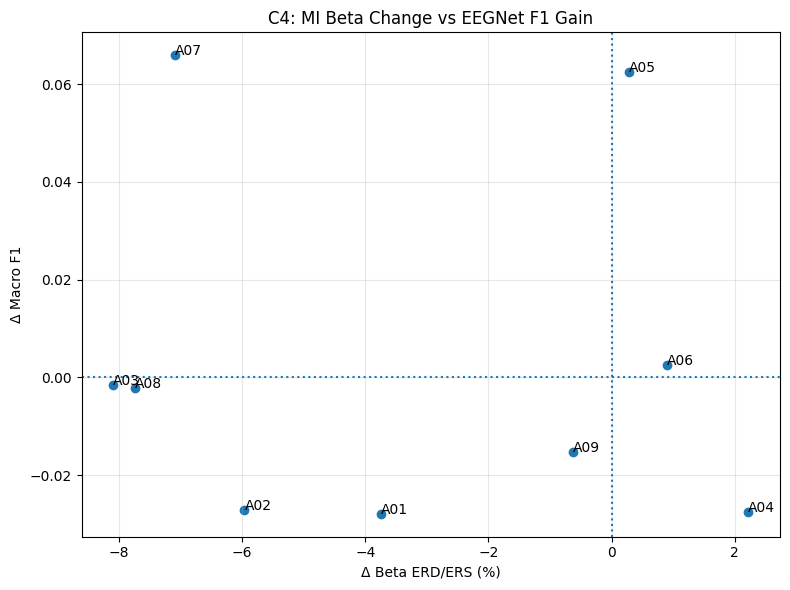



FINAL FULL-DURATION SENSORIMOTOR ERD/ERS VALIDATION

Nominal epoch:
7.5 s

Raw epoch samples:
1875

Downsampled epoch samples:
938

Actual downsampled duration: 7.5040 s

Global ERD/ERS:
              MI_Raw_ERD_ERS  MI_Clean_ERD_ERS  MI_Delta_ERD_ERS
Channel Band                                                    
C3      Beta         7.20205           4.44276          -2.75929
        Mu         101.48471          97.21267          -4.27203
C4      Beta         9.04484           5.72892          -3.31592
        Mu          94.83897          92.66818          -2.17078
Cz      Beta         5.95392           1.00641          -4.94751
        Mu         115.99547         113.23057          -2.76489

Paired Raw vs Clean:
Band Channel   Raw_Mean  Clean_Mean  Mean_Change  Wilcoxon_W  Wilcoxon_p  Paired_t  Paired_t_p
  Mu      C3 101.484708   97.212674    -4.272035        20.0    0.820312 -0.531439    0.609549
  Mu      Cz 115.995466  113.230574    -2.764892        17.0    0.570312 -0.625

In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

from scipy.io import loadmat
from scipy.signal import welch

from scipy.stats import (
    pearsonr,
    spearmanr,
    wilcoxon,
    ttest_rel
)

import matplotlib.pyplot as plt

import mne

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

DATASET_DIR = os.path.join(
    BASE_DIR,
    "Dataset"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "full_duration_erd_ers"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

FS_RAW = 250

FS = 125

N_EEG = 22

N_EOG = 3

LAMBDA = 0.75

SUBJECTS = [

    f"A{i:02d}"

    for i in range(
        1,
        10
    )

]

EPOCH_SECONDS = 7.5

RAW_EPOCH_SAMPLES = int(

    EPOCH_SECONDS
    *
    FS_RAW

)

EXPECTED_DOWNSAMPLED_SAMPLES = (

    len(
        range(
            0,
            RAW_EPOCH_SAMPLES,
            2
        )
    )

)

BASELINE_START_S = 0.00

BASELINE_END_S = 2.00

CUE_ONSET_S = 2.00

MI_ONSET_S = 3.25

MI_END_S = 6.00

POST_MI_START_S = 6.00

POST_MI_END_S = 7.50

WINDOW_SECONDS = 0.50

STEP_SECONDS = 0.10

WINDOW_SAMPLES = int(

    round(

        WINDOW_SECONDS
        *
        FS

    )

)

STEP_SAMPLES = int(

    round(

        STEP_SECONDS
        *
        FS

    )

)

WINDOW_START_SAMPLES = np.arange(

    0,

    EXPECTED_DOWNSAMPLED_SAMPLES
    -
    WINDOW_SAMPLES
    +
    1,

    STEP_SAMPLES

)

WINDOW_END_SAMPLES = (

    WINDOW_START_SAMPLES
    +
    WINDOW_SAMPLES

)

WINDOW_STARTS = (

    WINDOW_START_SAMPLES
    /
    FS

)

WINDOW_ENDS = (

    WINDOW_END_SAMPLES
    /
    FS

)

WINDOW_CENTERS = (

    (
        WINDOW_START_SAMPLES
        +
        WINDOW_END_SAMPLES
    )
    /
    2.0

) / FS

BANDS = {

    "Mu": (

        8.0,

        13.0

    ),

    "Beta": (

        13.0,

        30.0

    )

}

EEG_CHANNELS = [

    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",

    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",

    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",

    "P1",
    "Pz",
    "P2",
    "POz"

]

MOTOR_CHANNELS = [

    "C3",

    "Cz",

    "C4"

]

MOTOR_INDICES = {

    channel:
        EEG_CHANNELS.index(
            channel
        )

    for channel
    in MOTOR_CHANNELS

}

CLASS_NAMES = {

    1: "Left_Hand",

    2: "Right_Hand",

    3: "Feet",

    4: "Tongue"

}

def safe_mean(

    values

):

    values = np.asarray(

        values,

        dtype=float

    )

    valid = np.isfinite(
        values
    )

    if valid.sum() == 0:

        return np.nan

    return float(

        np.nanmean(
            values
        )

    )

def safe_pearson(

    x,

    y

):

    x = np.asarray(

        x,

        dtype=float

    )

    y = np.asarray(

        y,

        dtype=float

    )

    mask = (

        np.isfinite(x)

        &

        np.isfinite(y)

    )

    if mask.sum() < 3:

        return (
            np.nan,
            np.nan
        )

    if (

        np.std(
            x[mask]
        )
        <
        1e-12

        or

        np.std(
            y[mask]
        )
        <
        1e-12

    ):

        return (
            np.nan,
            np.nan
        )

    return pearsonr(

        x[mask],

        y[mask]

    )

def safe_spearman(

    x,

    y

):

    x = np.asarray(

        x,

        dtype=float

    )

    y = np.asarray(

        y,

        dtype=float

    )

    mask = (

        np.isfinite(x)

        &

        np.isfinite(y)

    )

    if mask.sum() < 3:

        return (
            np.nan,
            np.nan
        )

    return spearmanr(

        x[mask],

        y[mask]

    )

def load_full_duration_bci2a(

    mat_path

):

    """

    Load complete 7.5-second epochs.

    Important:
    Raw slice = 1875 samples
    Downsampled with [::2] = 938 samples

    Artifact handling is kept consistent with the earlier
    pipeline.
    """

    if not os.path.exists(
        mat_path
    ):

        raise FileNotFoundError(

            f"File not found:\n{mat_path}"

        )

    mat = loadmat(

        mat_path,

        squeeze_me=False

    )

    if "data" not in mat:

        raise ValueError(

            f"'data' field not found:\n{mat_path}"

        )

    data = mat[
        "data"
    ]

    eeg_trials = []

    eog_trials = []

    labels = []

    metadata = []

    skipped_artifact = 0

    skipped_incomplete = 0

    for run_idx in range(

        data.shape[1]

    ):

        run = data[

            0,

            run_idx

        ][

            0,

            0

        ]

        X_raw = run[
            "X"
        ]

        trial = run[
            "trial"
        ]

        y = run[
            "y"
        ]

        artifacts = run[
            "artifacts"
        ]

        for trial_idx in range(

            trial.shape[0]

        ):

            if (

                artifacts[
                    trial_idx,
                    0
                ]
                ==
                1

            ):

                skipped_artifact += 1

                continue

            onset = int(

                trial[
                    trial_idx,
                    0
                ]

            )

            start = onset

            end = (

                onset
                +
                RAW_EPOCH_SAMPLES

            )

            if end > X_raw.shape[0]:

                skipped_incomplete += 1

                continue

            eeg = X_raw[

                start:end,

                :N_EEG

            ]

            eog = X_raw[

                start:end,

                N_EEG:
                N_EEG + N_EOG

            ]

            eeg = eeg[
                ::2,
                :
            ]

            eog = eog[
                ::2,
                :
            ]

            if (

                eeg.shape[0]
                !=
                EXPECTED_DOWNSAMPLED_SAMPLES

            ):

                raise ValueError(

                    f"Unexpected epoch length in "
                    f"{mat_path}, run={run_idx}, "
                    f"trial={trial_idx}. "
                    f"Expected "
                    f"{EXPECTED_DOWNSAMPLED_SAMPLES} "
                    f"but got "
                    f"{eeg.shape[0]}."

                )

            label = int(

                y[
                    trial_idx,
                    0
                ]

            )

            eeg_trials.append(
                eeg
            )

            eog_trials.append(
                eog
            )

            labels.append(
                label
            )

            metadata.append({

                "Run":
                    run_idx,

                "Trial":
                    trial_idx + 1,

                "Onset":
                    onset,

                "Class":
                    CLASS_NAMES.get(

                        label,

                        f"Class_{label}"

                    )

            })

    print(

        "Complete 7.5 s trials:",
        len(eeg_trials)

    )

    print(

        "Skipped artifact trials:",
        skipped_artifact

    )

    print(

        "Skipped incomplete trials:",
        skipped_incomplete

    )

    return (

        np.asarray(

            eeg_trials,

            dtype=np.float64

        ),

        np.asarray(

            eog_trials,

            dtype=np.float64

        ),

        np.asarray(

            labels,

            dtype=np.int64

        ),

        pd.DataFrame(
            metadata
        )

    )

def filter_4_38(

    X

):

    """

    X shape:

        trials × samples × channels

    """

    X_t = X.transpose(

        0,
        2,
        1

    )

    original_shape = X_t.shape

    flattened = X_t.reshape(

        -1,

        original_shape[-1]

    )

    filtered = mne.filter.filter_data(

        flattened,

        sfreq=FS,

        l_freq=4.0,

        h_freq=38.0,

        method="fir",

        verbose=False

    )

    filtered = filtered.reshape(

        original_shape

    )

    return filtered.transpose(

        0,
        2,
        1

    )

def fit_eog_regression(

    eeg_train,

    eog_train

):

    """

    Fit EEG ~ EOG regression.

    ONLY training trials are used.
    """

    eeg_flat = eeg_train.reshape(

        -1,

        N_EEG

    )

    eog_flat = eog_train.reshape(

        -1,

        N_EOG

    )

    X = np.column_stack([

        eog_flat,

        np.ones(

            len(
                eog_flat
            )

        )

    ])

    beta = np.zeros(

        (

            N_EEG,

            N_EOG

        ),

        dtype=np.float64

    )

    intercept = np.zeros(

        N_EEG,

        dtype=np.float64

    )

    for channel_idx in range(

        N_EEG

    ):

        coefficients, _, _, _ = np.linalg.lstsq(

            X,

            eeg_flat[
                :,
                channel_idx
            ],

            rcond=None

        )

        beta[
            channel_idx
        ] = coefficients[
            :N_EOG
        ]

        intercept[
            channel_idx
        ] = coefficients[
            N_EOG
        ]

    return (

        beta,

        intercept

    )

def estimate_eog_component(

    eog,

    beta,

    intercept

):

    component = np.einsum(

        "tsc,nc->tsn",

        eog,

        beta

    )

    component += intercept.reshape(

        1,

        1,

        -1

    )

    return component

def band_power_trials(

    eeg,

    channel_index,

    low,

    high,

    start_sample,

    end_sample

):

    """

    Calculate trial-wise band power.

    IMPORTANT:
    This function works entirely in sample indices.
    """

    start_sample = max(

        0,

        int(
            start_sample
        )

    )

    end_sample = min(

        eeg.shape[1],

        int(
            end_sample
        )

    )

    if (

        end_sample
        <=
        start_sample

    ):

        return np.full(

            eeg.shape[0],

            np.nan

        )

    segment = eeg[

        :,

        start_sample:end_sample,

        channel_index

    ]

    output = []

    for trial_signal in segment:

        if len(
            trial_signal
        ) < 16:

            output.append(
                np.nan
            )

            continue

        nperseg = min(

            128,

            len(
                trial_signal
            )

        )

        frequencies, psd = welch(

            trial_signal,

            fs=FS,

            nperseg=nperseg,

            noverlap=0

        )

        mask = (

            (

                frequencies
                >=
                low

            )

            &

            (

                frequencies
                <=
                high

            )

        )

        if mask.sum() < 2:

            output.append(
                np.nan
            )

            continue

        power = np.trapezoid(

            psd[
                mask
            ],

            frequencies[
                mask
            ]

        )

        output.append(
            power
        )

    return np.asarray(

        output,

        dtype=float

    )

def normalize_erd_ers(

    baseline_power,

    window_power

):

    baseline_power = np.asarray(

        baseline_power,

        dtype=float

    )

    window_power = np.asarray(

        window_power,

        dtype=float

    )

    return (

        100.0

        *

        (

            window_power
            -
            baseline_power

        )

        /

        (

            baseline_power
            +
            1e-12

        )

    )

ALLBAND_FILE = os.path.join(

    RESULTS_DIR,

    "eegnet_allband_lambda_performance.csv"

)

FOCUSED_FILE = os.path.join(

    RESULTS_DIR,

    "eegnet_focused_lambda_performance.csv"

)

if not os.path.exists(
    ALLBAND_FILE
):

    raise FileNotFoundError(
        ALLBAND_FILE
    )

if not os.path.exists(
    FOCUSED_FILE
):

    raise FileNotFoundError(
        FOCUSED_FILE
    )

allband = pd.read_csv(

    ALLBAND_FILE

)

focused = pd.read_csv(

    FOCUSED_FILE

)

raw_perf = allband[

    np.isclose(

        allband[
            "Lambda"
        ],

        0.00

    )

].copy()

raw_perf = raw_perf[

    [

        "Subject",

        "Accuracy",

        "Macro_F1"

    ]

].rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

clean_perf = focused[

    np.isclose(

        focused[
            "Lambda"
        ],

        0.75

    )

].copy()

clean_perf = clean_perf[

    [

        "Subject",

        "Accuracy",

        "Macro_F1"

    ]

].rename(

    columns={

        "Accuracy":
            "Clean_Accuracy",

        "Macro_F1":
            "Clean_F1"

    }

)

performance = (

    raw_perf

    .merge(

        clean_perf,

        on="Subject",

        how="inner"

    )

)

performance[
    "Delta_Accuracy"
] = (

    performance[
        "Clean_Accuracy"
    ]

    -

    performance[
        "Raw_Accuracy"
    ]

)

performance[
    "Delta_F1"
] = (

    performance[
        "Clean_F1"
    ]

    -

    performance[
        "Raw_F1"
    ]

)

performance = performance.sort_values(

    "Subject"

).reset_index(

    drop=True

)

temporal_rows = []

class_rows = []

subject_rows = []

for subject in SUBJECTS:

    print("\n")
    print(
        "=" * 110
    )

    print(
        f"PROCESSING {subject}"
    )

    print(
        "=" * 110
    )

    train_path = os.path.join(

        DATASET_DIR,

        f"{subject}T.mat"

    )

    eval_path = os.path.join(

        DATASET_DIR,

        f"{subject}E.mat"

    )

    (

        eeg_t,

        eog_t,

        y_t,

        meta_t

    ) = load_full_duration_bci2a(

        train_path

    )

    (

        eeg_e,

        eog_e,

        y_e,

        meta_e

    ) = load_full_duration_bci2a(

        eval_path

    )

    if (

        eeg_t.shape[1]
        !=
        EXPECTED_DOWNSAMPLED_SAMPLES

    ):

        raise ValueError(

            f"{subject} training epoch has "
            f"{eeg_t.shape[1]} samples; "
            f"expected "
            f"{EXPECTED_DOWNSAMPLED_SAMPLES}."

        )

    if (

        eeg_e.shape[1]
        !=
        EXPECTED_DOWNSAMPLED_SAMPLES

    ):

        raise ValueError(

            f"{subject} evaluation epoch has "
            f"{eeg_e.shape[1]} samples; "
            f"expected "
            f"{EXPECTED_DOWNSAMPLED_SAMPLES}."

        )

    print(

        f"Epoch length: "
        f"{eeg_e.shape[1]} samples "
        f"= "
        f"{eeg_e.shape[1] / FS:.4f} s"

    )

    print(
        "Filtering EEG 4–38 Hz..."
    )

    eeg_t_filtered = filter_4_38(

        eeg_t

    )

    eeg_e_filtered = filter_4_38(

        eeg_e

    )

    print(
        "Filtering EOG 4–38 Hz..."
    )

    eog_t_filtered = filter_4_38(

        eog_t

    )

    eog_e_filtered = filter_4_38(

        eog_e

    )

    indices = np.arange(

        len(y_t)

    )

    from sklearn.model_selection import train_test_split

    train_idx, val_idx = train_test_split(

        indices,

        test_size=0.20,

        stratify=y_t,

        random_state=SEED

    )

    print(
        "Fitting training-only EOG regression..."
    )

    beta_eog, intercept_eog = (

        fit_eog_regression(

            eeg_t_filtered[
                train_idx
            ],

            eog_t_filtered[
                train_idx
            ]

        )

    )

    eog_component_e = (

        estimate_eog_component(

            eog_e_filtered,

            beta_eog,

            intercept_eog

        )

    )

    eeg_raw = (

        eeg_e_filtered.copy()

    )

    eeg_clean = (

        eeg_e_filtered

        -

        LAMBDA
        *
        eog_component_e

    )

    perf = performance[

        performance[
            "Subject"
        ]
        ==
        subject

    ]

    if len(perf) != 1:

        raise ValueError(

            f"Expected exactly one performance "
            f"row for {subject}; "
            f"found {len(perf)}."

        )

    perf = perf.iloc[
        0
    ]

    delta_accuracy = float(

        perf[
            "Delta_Accuracy"
        ]

    )

    delta_f1 = float(

        perf[
            "Delta_F1"
        ]

    )

    baseline_cache = {}

    for channel_name in MOTOR_CHANNELS:

        channel_index = MOTOR_INDICES[
            channel_name
        ]

        for band_name, (low, high) in BANDS.items():

            cache_key = (

                channel_name,

                band_name

            )

            baseline_cache[
                cache_key
            ] = {

                "raw":

                    band_power_trials(

                        eeg_raw,

                        channel_index,

                        low,

                        high,

                        int(
                            round(
                                BASELINE_START_S
                                *
                                FS
                            )
                        ),

                        int(
                            round(
                                BASELINE_END_S
                                *
                                FS
                            )
                        )

                    ),

                "clean":

                    band_power_trials(

                        eeg_clean,

                        channel_index,

                        low,

                        high,

                        int(
                            round(
                                BASELINE_START_S
                                *
                                FS
                            )
                        ),

                        int(
                            round(
                                BASELINE_END_S
                                *
                                FS
                            )
                        )

                    )

            }

    for channel_name in MOTOR_CHANNELS:

        channel_index = MOTOR_INDICES[
            channel_name
        ]

        for band_name, (low, high) in BANDS.items():

            baseline_raw = baseline_cache[

                channel_name,

                band_name

            ][
                "raw"
            ]

            baseline_clean = baseline_cache[

                channel_name,

                band_name

            ][
                "clean"
            ]

            for (

                start_sample,

                end_sample,

                start_s,

                end_s,

                center_s

            ) in zip(

                WINDOW_START_SAMPLES,

                WINDOW_END_SAMPLES,

                WINDOW_STARTS,

                WINDOW_ENDS,

                WINDOW_CENTERS

            ):

                raw_window = band_power_trials(

                    eeg_raw,

                    channel_index,

                    low,

                    high,

                    start_sample,

                    end_sample

                )

                clean_window = band_power_trials(

                    eeg_clean,

                    channel_index,

                    low,

                    high,

                    start_sample,

                    end_sample

                )

                raw_erd = normalize_erd_ers(

                    baseline_raw,

                    raw_window

                )

                clean_erd = normalize_erd_ers(

                    baseline_clean,

                    clean_window

                )

                delta_erd = (

                    clean_erd
                    -
                    raw_erd

                )

                temporal_rows.append({

                    "Subject":
                        subject,

                    "Channel":
                        channel_name,

                    "Band":
                        band_name,

                    "Window_Start_s":
                        start_s,

                    "Window_End_s":
                        end_s,

                    "Window_Center_s":
                        center_s,

                    "Raw_ERD_ERS_percent":
                        safe_mean(
                            raw_erd
                        ),

                    "Clean_ERD_ERS_percent":
                        safe_mean(
                            clean_erd
                        ),

                    "Delta_ERD_ERS_percent":
                        safe_mean(
                            delta_erd
                        ),

                    "Delta_Accuracy":
                        delta_accuracy,

                    "Delta_F1":
                        delta_f1

                })

    mi_window_mask = (

        (WINDOW_STARTS >= MI_ONSET_S)

        &

        (WINDOW_ENDS <= MI_END_S)

    )

    mi_window_indices = np.where(

        mi_window_mask

    )[0]

    for channel_name in MOTOR_CHANNELS:

        channel_index = MOTOR_INDICES[
            channel_name
        ]

        for band_name, (low, high) in BANDS.items():

            baseline_raw = baseline_cache[

                channel_name,

                band_name

            ][
                "raw"
            ]

            baseline_clean = baseline_cache[

                channel_name,

                band_name

            ][
                "clean"
            ]

            for class_id, class_name in CLASS_NAMES.items():

                class_mask = (

                    y_e
                    ==
                    class_id

                )

                if class_mask.sum() == 0:

                    continue

                raw_class_values = []

                clean_class_values = []

                delta_class_values = []

                for window_index in mi_window_indices:

                    start_sample = (

                        WINDOW_START_SAMPLES[
                            window_index
                        ]

                    )

                    end_sample = (

                        WINDOW_END_SAMPLES[
                            window_index
                        ]

                    )

                    raw_window = band_power_trials(

                        eeg_raw,

                        channel_index,

                        low,

                        high,

                        start_sample,

                        end_sample

                    )

                    clean_window = band_power_trials(

                        eeg_clean,

                        channel_index,

                        low,

                        high,

                        start_sample,

                        end_sample

                    )

                    raw_erd = normalize_erd_ers(

                        baseline_raw,

                        raw_window

                    )

                    clean_erd = normalize_erd_ers(

                        baseline_clean,

                        clean_window

                    )

                    delta_erd = (

                        clean_erd
                        -
                        raw_erd

                    )

                    raw_class_values.extend(

                        raw_erd[
                            class_mask
                        ].tolist()

                    )

                    clean_class_values.extend(

                        clean_erd[
                            class_mask
                        ].tolist()

                    )

                    delta_class_values.extend(

                        delta_erd[
                            class_mask
                        ].tolist()

                    )

                class_rows.append({

                    "Subject":
                        subject,

                    "Class_ID":
                        class_id,

                    "Class":
                        class_name,

                    "Channel":
                        channel_name,

                    "Band":
                        band_name,

                    "N_Trials":
                        int(
                            class_mask.sum()
                        ),

                    "Raw_ERD_ERS_percent":
                        safe_mean(
                            raw_class_values
                        ),

                    "Clean_ERD_ERS_percent":
                        safe_mean(
                            clean_class_values
                        ),

                    "Delta_ERD_ERS_percent":
                        safe_mean(
                            delta_class_values
                        ),

                    "Delta_Accuracy":
                        delta_accuracy,

                    "Delta_F1":
                        delta_f1

                })

    for channel_name in MOTOR_CHANNELS:

        channel_index = MOTOR_INDICES[
            channel_name
        ]

        for band_name, (low, high) in BANDS.items():

            baseline_raw = baseline_cache[

                channel_name,

                band_name

            ][
                "raw"
            ]

            baseline_clean = baseline_cache[

                channel_name,

                band_name

            ][
                "clean"
            ]

            raw_values = []

            clean_values = []

            for window_index in mi_window_indices:

                start_sample = (

                    WINDOW_START_SAMPLES[
                        window_index
                    ]

                )

                end_sample = (

                    WINDOW_END_SAMPLES[
                        window_index
                    ]

                )

                raw_window = band_power_trials(

                    eeg_raw,

                    channel_index,

                    low,

                    high,

                    start_sample,

                    end_sample

                )

                clean_window = band_power_trials(

                    eeg_clean,

                    channel_index,

                    low,

                    high,

                    start_sample,

                    end_sample

                )

                raw_erd = normalize_erd_ers(

                    baseline_raw,

                    raw_window

                )

                clean_erd = normalize_erd_ers(

                    baseline_clean,

                    clean_window

                )

                raw_values.extend(
                    raw_erd.tolist()
                )

                clean_values.extend(
                    clean_erd.tolist()
                )

            subject_rows.append({

                "Subject":
                    subject,

                "Channel":
                    channel_name,

                "Band":
                    band_name,

                "MI_Raw_ERD_ERS":
                    safe_mean(
                        raw_values
                    ),

                "MI_Clean_ERD_ERS":
                    safe_mean(
                        clean_values
                    ),

                "MI_Delta_ERD_ERS":
                    safe_mean(

                        np.asarray(
                            clean_values
                        )

                        -

                        np.asarray(
                            raw_values
                        )

                    ),

                "Delta_Accuracy":
                    delta_accuracy,

                "Delta_F1":
                    delta_f1

            })

    print(
        f"\nΔ Accuracy = "
        f"{delta_accuracy:+.5f}"
    )

    print(
        f"Δ F1 = "
        f"{delta_f1:+.5f}"
    )

temporal_df = pd.DataFrame(

    temporal_rows

)

class_df = pd.DataFrame(

    class_rows

)

subject_df = pd.DataFrame(

    subject_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "GLOBAL MOTOR-CHANNEL ERD/ERS SUMMARY"
)

print(
    "=" * 110
)

global_summary = (

    subject_df

    .groupby(

        [

            "Channel",

            "Band"

        ]

    )[

        [

            "MI_Raw_ERD_ERS",

            "MI_Clean_ERD_ERS",

            "MI_Delta_ERD_ERS"

        ]

    ]

    .mean()

)

print(

    global_summary.round(
        5
    ).to_string()

)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS-SPECIFIC MI ERD/ERS SUMMARY"
)

print(
    "=" * 110
)

class_summary = (

    class_df

    .groupby(

        [

            "Class",

            "Channel",

            "Band"

        ]

    )[

        [

            "Raw_ERD_ERS_percent",

            "Clean_ERD_ERS_percent",

            "Delta_ERD_ERS_percent"

        ]

    ]

    .mean()

)

print(

    class_summary.round(
        5
    ).to_string()

)

paired_rows = []

for band_name in BANDS.keys():

    for channel_name in MOTOR_CHANNELS:

        temp = subject_df[

            (

                subject_df[
                    "Band"
                ]
                ==
                band_name

            )

            &

            (

                subject_df[
                    "Channel"
                ]
                ==
                channel_name

            )

        ]

        raw = temp[
            "MI_Raw_ERD_ERS"
        ].to_numpy(
            dtype=float
        )

        clean = temp[
            "MI_Clean_ERD_ERS"
        ].to_numpy(
            dtype=float
        )

        valid = (

            np.isfinite(raw)

            &

            np.isfinite(clean)

        )

        if valid.sum() >= 3:

            try:

                W, p_w = wilcoxon(

                    clean[
                        valid
                    ],

                    raw[
                        valid
                    ]

                )

            except Exception:

                W = np.nan

                p_w = np.nan

            try:

                t, p_t = ttest_rel(

                    clean[
                        valid
                    ],

                    raw[
                        valid
                    ]

                )

            except Exception:

                t = np.nan

                p_t = np.nan

        else:

            W = np.nan

            p_w = np.nan

            t = np.nan

            p_t = np.nan

        paired_rows.append({

            "Band":
                band_name,

            "Channel":
                channel_name,

            "Raw_Mean":
                np.nanmean(raw),

            "Clean_Mean":
                np.nanmean(clean),

            "Mean_Change":
                np.nanmean(
                    clean - raw
                ),

            "Wilcoxon_W":
                W,

            "Wilcoxon_p":
                p_w,

            "Paired_t":
                t,

            "Paired_t_p":
                p_t

        })

paired_df = pd.DataFrame(

    paired_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "PAIRED RAW vs CLEAN MI ERD/ERS"
)

print(
    "=" * 110
)

print(

    paired_df.round(
        6
    ).to_string(
        index=False
    )

)

class_test_rows = []

for class_id, class_name in CLASS_NAMES.items():

    for band_name in BANDS.keys():

        for channel_name in MOTOR_CHANNELS:

            temp = class_df[

                (

                    class_df[
                        "Class_ID"
                    ]
                    ==
                    class_id

                )

                &

                (

                    class_df[
                        "Band"
                    ]
                    ==
                    band_name

                )

                &

                (

                    class_df[
                        "Channel"
                    ]
                    ==
                    channel_name

                )

            ]

            raw = temp[
                "Raw_ERD_ERS_percent"
            ].to_numpy(
                dtype=float
            )

            clean = temp[
                "Clean_ERD_ERS_percent"
            ].to_numpy(
                dtype=float
            )

            valid = (

                np.isfinite(raw)

                &

                np.isfinite(clean)

            )

            if valid.sum() >= 3:

                try:

                    W, p = wilcoxon(

                        clean[
                            valid
                        ],

                        raw[
                            valid
                        ]

                    )

                except Exception:

                    W = np.nan

                    p = np.nan

            else:

                W = np.nan

                p = np.nan

            class_test_rows.append({

                "Class":
                    class_name,

                "Band":
                    band_name,

                "Channel":
                    channel_name,

                "Raw_Mean":
                    np.nanmean(raw),

                "Clean_Mean":
                    np.nanmean(clean),

                "Mean_Change":
                    np.nanmean(
                        clean - raw
                    ),

                "Wilcoxon_W":
                    W,

                "Wilcoxon_p":
                    p

            })

class_test_df = pd.DataFrame(

    class_test_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "CLASS-SPECIFIC RAW vs CLEAN MI ERD/ERS"
)

print(
    "=" * 110
)

print(

    class_test_df.round(
        6
    ).to_string(
        index=False
    )

)

erd_f1_rows = []

for band_name in BANDS.keys():

    for channel_name in MOTOR_CHANNELS:

        temp = subject_df[

            (

                subject_df[
                    "Band"
                ]
                ==
                band_name

            )

            &

            (

                subject_df[
                    "Channel"
                ]
                ==
                channel_name

            )

        ]

        x = temp[
            "MI_Delta_ERD_ERS"
        ].to_numpy(
            dtype=float
        )

        y = temp[
            "Delta_F1"
        ].to_numpy(
            dtype=float
        )

        r, p = safe_pearson(

            x,

            y

        )

        rho, rho_p = safe_spearman(

            x,

            y

        )

        erd_f1_rows.append({

            "Band":
                band_name,

            "Channel":
                channel_name,

            "Pearson_r":
                r,

            "Pearson_p":
                p,

            "Spearman_rho":
                rho,

            "Spearman_p":
                rho_p

        })

erd_f1_df = pd.DataFrame(

    erd_f1_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "MI ERD/ERS CHANGE vs EEGNET ΔF1"
)

print(
    "=" * 110
)

print(

    erd_f1_df.round(
        6
    ).to_string(
        index=False
    )

)

erd_acc_rows = []

for band_name in BANDS.keys():

    for channel_name in MOTOR_CHANNELS:

        temp = subject_df[

            (

                subject_df[
                    "Band"
                ]
                ==
                band_name

            )

            &

            (

                subject_df[
                    "Channel"
                ]
                ==
                channel_name

            )

        ]

        x = temp[
            "MI_Delta_ERD_ERS"
        ].to_numpy(
            dtype=float
        )

        y = temp[
            "Delta_Accuracy"
        ].to_numpy(
            dtype=float
        )

        r, p = safe_pearson(

            x,

            y

        )

        rho, rho_p = safe_spearman(

            x,

            y

        )

        erd_acc_rows.append({

            "Band":
                band_name,

            "Channel":
                channel_name,

            "Pearson_r":
                r,

            "Pearson_p":
                p,

            "Spearman_rho":
                rho,

            "Spearman_p":
                rho_p

        })

erd_accuracy_df = pd.DataFrame(

    erd_acc_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "MI ERD/ERS CHANGE vs EEGNET ΔACCURACY"
)

print(
    "=" * 110
)

print(

    erd_accuracy_df.round(
        6
    ).to_string(
        index=False
    )

)

motor_band_subject = (

    subject_df

    .groupby(

        [

            "Subject",

            "Band"

        ]

    )[

        [

            "MI_Delta_ERD_ERS",

            "Delta_Accuracy",

            "Delta_F1"

        ]

    ]

    .mean()

    .reset_index()

)

motor_corr_rows = []

for band_name in BANDS.keys():

    temp = motor_band_subject[

        motor_band_subject[
            "Band"
        ]
        ==
        band_name

    ]

    x = temp[
        "MI_Delta_ERD_ERS"
    ].to_numpy(
        dtype=float
    )

    y_acc = temp[
        "Delta_Accuracy"
    ].to_numpy(
        dtype=float
    )

    y_f1 = temp[
        "Delta_F1"
    ].to_numpy(
        dtype=float
    )

    acc_r, acc_p = safe_pearson(

        x,

        y_acc

    )

    acc_rho, acc_rho_p = safe_spearman(

        x,

        y_acc

    )

    f1_r, f1_p = safe_pearson(

        x,

        y_f1

    )

    f1_rho, f1_rho_p = safe_spearman(

        x,

        y_f1

    )

    motor_corr_rows.append({

        "Band":
            band_name,

        "Accuracy_Pearson_r":
            acc_r,

        "Accuracy_Pearson_p":
            acc_p,

        "Accuracy_Spearman_rho":
            acc_rho,

        "Accuracy_Spearman_p":
            acc_rho_p,

        "F1_Pearson_r":
            f1_r,

        "F1_Pearson_p":
            f1_p,

        "F1_Spearman_rho":
            f1_rho,

        "F1_Spearman_p":
            f1_rho_p

    })

motor_corr_df = pd.DataFrame(

    motor_corr_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "MOTOR-BAND AVERAGED CORRELATIONS"
)

print(
    "=" * 110
)

print(

    motor_corr_df.round(
        6
    ).to_string(
        index=False
    )

)

lateral_rows = []

for subject in SUBJECTS:

    for band_name in BANDS.keys():

        subject_class = class_df[

            (

                class_df[
                    "Subject"
                ]
                ==
                subject

            )

            &

            (

                class_df[
                    "Band"
                ]
                ==
                band_name

            )

        ]

        left_c3 = (

            subject_class[

                (

                    subject_class[
                        "Class"
                    ]
                    ==
                    "Left_Hand"

                )

                &

                (

                    subject_class[
                        "Channel"
                    ]
                    ==
                    "C3"

                )

            ][
                "Clean_ERD_ERS_percent"
            ].mean()

        )

        left_c4 = (

            subject_class[

                (

                    subject_class[
                        "Class"
                    ]
                    ==
                    "Left_Hand"

                )

                &

                (

                    subject_class[
                        "Channel"
                    ]
                    ==
                    "C4"

                )

            ][
                "Clean_ERD_ERS_percent"
            ].mean()

        )

        raw_left_c3 = (

            subject_class[

                (

                    subject_class[
                        "Class"
                    ]
                    ==
                    "Left_Hand"

                )

                &

                (

                    subject_class[
                        "Channel"
                    ]
                    ==
                    "C3"

                )

            ][
                "Raw_ERD_ERS_percent"
            ].mean()

        )

        raw_left_c4 = (

            subject_class[

                (

                    subject_class[
                        "Class"
                    ]
                    ==
                    "Left_Hand"

                )

                &

                (

                    subject_class[
                        "Channel"
                    ]
                    ==
                    "C4"

                )

            ][
                "Raw_ERD_ERS_percent"
            ].mean()

        )

        right_c3 = (

            subject_class[

                (

                    subject_class[
                        "Class"
                    ]
                    ==
                    "Right_Hand"

                )

                &

                (

                    subject_class[
                        "Channel"
                    ]
                    ==
                    "C3"

                )

            ][
                "Clean_ERD_ERS_percent"
            ].mean()

        )

        right_c4 = (

            subject_class[

                (

                    subject_class[
                        "Class"
                    ]
                    ==
                    "Right_Hand"

                )

                &

                (

                    subject_class[
                        "Channel"
                    ]
                    ==
                    "C4"

                )

            ][
                "Clean_ERD_ERS_percent"
            ].mean()

        )

        raw_right_c3 = (

            subject_class[

                (

                    subject_class[
                        "Class"
                    ]
                    ==
                    "Right_Hand"

                )

                &

                (

                    subject_class[
                        "Channel"
                    ]
                    ==
                    "C3"

                )

            ][
                "Raw_ERD_ERS_percent"
            ].mean()

        )

        raw_right_c4 = (

            subject_class[

                (

                    subject_class[
                        "Class"
                    ]
                    ==
                    "Right_Hand"

                )

                &

                (

                    subject_class[
                        "Channel"
                    ]
                    ==
                    "C4"

                )

            ][
                "Raw_ERD_ERS_percent"
            ].mean()

        )

        raw_left_expected = (

            raw_left_c3
            -
            raw_left_c4

        )

        clean_left_expected = (

            left_c3
            -
            left_c4

        )

        raw_right_expected = (

            -(
                raw_right_c3
                -
                raw_right_c4
            )

        )

        clean_right_expected = (

            -(
                right_c3
                -
                right_c4
            )

        )

        lateral_rows.append({

            "Subject":
                subject,

            "Band":
                band_name,

            "Raw_Left_Expected_Lateralization":
                raw_left_expected,

            "Clean_Left_Expected_Lateralization":
                clean_left_expected,

            "Delta_Left_Expected_Lateralization":
                (
                    clean_left_expected
                    -
                    raw_left_expected
                ),

            "Raw_Right_Expected_Lateralization":
                raw_right_expected,

            "Clean_Right_Expected_Lateralization":
                clean_right_expected,

            "Delta_Right_Expected_Lateralization":
                (
                    clean_right_expected
                    -
                    raw_right_expected
                )

        })

lateral_df = pd.DataFrame(

    lateral_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "FULL-DURATION HAND MOTOR LATERALIZATION"
)

print(
    "=" * 110
)

print(

    lateral_df.round(
        5
    ).to_string(
        index=False
    )

)

lateral_test_rows = []

for band_name in BANDS.keys():

    temp = lateral_df[

        lateral_df[
            "Band"
        ]
        ==
        band_name

    ]

    for hand in [

        "Left",

        "Right"

    ]:

        raw_col = (

            f"Raw_"
            f"{hand}_Expected_Lateralization"

        )

        clean_col = (

            f"Clean_"
            f"{hand}_Expected_Lateralization"

        )

        raw = temp[
            raw_col
        ].to_numpy(
            dtype=float
        )

        clean = temp[
            clean_col
        ].to_numpy(
            dtype=float
        )

        try:

            W, p = wilcoxon(

                clean,

                raw

            )

        except Exception:

            W = np.nan

            p = np.nan

        lateral_test_rows.append({

            "Band":
                band_name,

            "Hand":
                hand,

            "Raw_Mean":
                np.nanmean(raw),

            "Clean_Mean":
                np.nanmean(clean),

            "Mean_Change":
                np.nanmean(
                    clean - raw
                ),

            "Wilcoxon_W":
                W,

            "Wilcoxon_p":
                p

        })

lateral_test_df = pd.DataFrame(

    lateral_test_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "HAND LATERALIZATION STATISTICS"
)

print(
    "=" * 110
)

print(

    lateral_test_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "GENERATING TEMPORAL CURVES"
)

print(
    "=" * 110
)

for band_name in BANDS.keys():

    temp = temporal_df[

        temporal_df[
            "Band"
        ]
        ==
        band_name

    ]

    curve = (

        temp

        .groupby(
            "Window_Center_s"
        )[

            "Delta_ERD_ERS_percent"

        ]

        .mean()

        .sort_index()

    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(

        curve.index,

        curve.values,

        marker="o"

    )

    plt.axvline(

        CUE_ONSET_S,

        linestyle="--",

        label="Approx. cue onset"

    )

    plt.axvline(

        MI_ONSET_S,

        linestyle="--",

        label="Approx. MI onset"

    )

    plt.axvline(

        MI_END_S,

        linestyle="--",

        label="Approx. MI end"

    )

    plt.axhline(

        0,

        linestyle=":"

    )

    plt.xlabel(
        "Time from trial onset (s)"
    )

    plt.ylabel(
        f"Δ {band_name} ERD/ERS (%)"
    )

    plt.title(

        f"Temporal Change in "
        f"{band_name} ERD/ERS After λ=0.75"

    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(

        os.path.join(

            FIGURE_DIR,

            f"temporal_delta_{band_name.lower()}_erd_ers.png"

        ),

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()

for band_name in BANDS.keys():

    for channel_name in MOTOR_CHANNELS:

        temp = temporal_df[

            (

                temporal_df[
                    "Band"
                ]
                ==
                band_name

            )

            &

            (

                temporal_df[
                    "Channel"
                ]
                ==
                channel_name

            )

        ]

        curve = (

            temp

            .groupby(
                "Window_Center_s"
            )[

                "Delta_ERD_ERS_percent"

            ]

            .mean()

            .sort_index()

        )

        plt.figure(
            figsize=(10, 6)
        )

        plt.plot(

            curve.index,

            curve.values,

            marker="o"

        )

        plt.axvline(

            CUE_ONSET_S,

            linestyle="--",

            label="Approx. cue onset"

        )

        plt.axvline(

            MI_ONSET_S,

            linestyle="--",

            label="Approx. MI onset"

        )

        plt.axvline(

            MI_END_S,

            linestyle="--",

            label="Approx. MI end"

        )

        plt.axhline(

            0,

            linestyle=":"

        )

        plt.xlabel(
            "Time from trial onset (s)"
        )

        plt.ylabel(
            f"Δ {band_name} ERD/ERS (%)"
        )

        plt.title(

            f"{channel_name}: "
            f"Δ {band_name} ERD/ERS"

        )

        plt.legend()

        plt.grid(
            alpha=0.3
        )

        plt.tight_layout()

        filename = (

            f"{channel_name.lower()}_"
            f"{band_name.lower()}_"
            f"temporal_delta.png"

        )

        plt.savefig(

            os.path.join(

                FIGURE_DIR,

                filename

            ),

            dpi=300,

            bbox_inches="tight"

        )

        plt.show()

for band_name in BANDS.keys():

    for channel_name in MOTOR_CHANNELS:

        temp = class_df[

            (

                class_df[
                    "Band"
                ]
                ==
                band_name

            )

            &

            (

                class_df[
                    "Channel"
                ]
                ==
                channel_name

            )

        ]

        class_plot = (

            temp

            .groupby(
                "Class"
            )[

                "Delta_ERD_ERS_percent"

            ]

            .mean()

            .reindex(

                [

                    "Left_Hand",

                    "Right_Hand",

                    "Feet",

                    "Tongue"

                ]

            )

        )

        plt.figure(
            figsize=(10, 6)
        )

        plt.bar(

            np.arange(
                len(
                    class_plot
                )
            ),

            class_plot.values

        )

        plt.axhline(

            0,

            linestyle=":"

        )

        plt.xticks(

            np.arange(
                len(
                    class_plot
                )
            ),

            class_plot.index,

            rotation=20

        )

        plt.xlabel(
            "Motor-imagery class"
        )

        plt.ylabel(
            f"Δ {band_name} ERD/ERS (%)"
        )

        plt.title(

            f"{channel_name}: "
            f"Class-Specific Δ {band_name} ERD/ERS"

        )

        plt.grid(

            axis="y",

            alpha=0.3

        )

        plt.tight_layout()

        filename = (

            f"class_delta_"
            f"{channel_name.lower()}_"
            f"{band_name.lower()}_erd_ers.png"

        )

        plt.savefig(

            os.path.join(

                FIGURE_DIR,

                filename

            ),

            dpi=300,

            bbox_inches="tight"

        )

        plt.show()

for band_name in BANDS.keys():

    for channel_name in MOTOR_CHANNELS:

        temp = subject_df[

            (

                subject_df[
                    "Band"
                ]
                ==
                band_name

            )

            &

            (

                subject_df[
                    "Channel"
                ]
                ==
                channel_name

            )

        ]

        plt.figure(
            figsize=(8, 6)
        )

        plt.scatter(

            temp[
                "MI_Delta_ERD_ERS"
            ],

            temp[
                "Delta_F1"
            ]

        )

        for _, row in temp.iterrows():

            plt.annotate(

                row[
                    "Subject"
                ],

                (

                    row[
                        "MI_Delta_ERD_ERS"
                    ],

                    row[
                        "Delta_F1"
                    ]

                )

            )

        plt.axhline(

            0,

            linestyle=":"

        )

        plt.axvline(

            0,

            linestyle=":"

        )

        plt.xlabel(

            f"Δ {band_name} ERD/ERS (%)"

        )

        plt.ylabel(
            "Δ Macro F1"
        )

        plt.title(

            f"{channel_name}: "
            f"MI {band_name} Change vs EEGNet F1 Gain"

        )

        plt.grid(
            alpha=0.3
        )

        plt.tight_layout()

        filename = (

            f"{channel_name.lower()}_"
            f"{band_name.lower()}_"
            f"erd_ers_vs_delta_f1.png"

        )

        plt.savefig(

            os.path.join(

                FIGURE_DIR,

                filename

            ),

            dpi=300,

            bbox_inches="tight"

        )

        plt.show()

temporal_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_temporal_erd_ers.csv"

)

class_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_class_erd_ers.csv"

)

subject_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_subject_erd_ers.csv"

)

paired_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_paired_erd_ers_tests.csv"

)

class_test_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_class_erd_ers_tests.csv"

)

f1_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_erd_ers_vs_f1.csv"

)

accuracy_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_erd_ers_vs_accuracy.csv"

)

lateral_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_hand_lateralization.csv"

)

lateral_test_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_hand_lateralization_tests.csv"

)

motor_corr_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_motor_band_correlations.csv"

)

temporal_df.to_csv(

    temporal_file,

    index=False

)

class_df.to_csv(

    class_file,

    index=False

)

subject_df.to_csv(

    subject_file,

    index=False

)

paired_df.to_csv(

    paired_file,

    index=False

)

class_test_df.to_csv(

    class_test_file,

    index=False

)

erd_f1_df.to_csv(

    f1_file,

    index=False

)

erd_accuracy_df.to_csv(

    accuracy_file,

    index=False

)

lateral_df.to_csv(

    lateral_file,

    index=False

)

lateral_test_df.to_csv(

    lateral_test_file,

    index=False

)

motor_corr_df.to_csv(

    motor_corr_file,

    index=False

)

summary_rows = []

for _, row in paired_df.iterrows():

    summary_rows.append({

        "Metric":
            (
                f"{row['Channel']}_"
                f"{row['Band']}_"
                f"MI_Raw"
            ),

        "Value":
            row[
                "Raw_Mean"
            ]

    })

    summary_rows.append({

        "Metric":
            (
                f"{row['Channel']}_"
                f"{row['Band']}_"
                f"MI_Clean"
            ),

        "Value":
            row[
                "Clean_Mean"
            ]

    })

    summary_rows.append({

        "Metric":
            (
                f"{row['Channel']}_"
                f"{row['Band']}_"
                f"MI_Delta"
            ),

        "Value":
            row[
                "Mean_Change"
            ]

    })

summary_rows.extend([

    {

        "Metric":
            "Mean_Delta_Accuracy",

        "Value":
            performance[
                "Delta_Accuracy"
            ].mean()

    },

    {

        "Metric":
            "Mean_Delta_F1",

        "Value":
            performance[
                "Delta_F1"
            ].mean()

    }

])

summary_df = pd.DataFrame(
    summary_rows
)

summary_file = os.path.join(

    OUTPUT_DIR,

    "full_duration_erd_ers_final_summary.csv"

)

summary_df.to_csv(

    summary_file,

    index=False

)

print("\n")
print(
    "=" * 110
)

print(
    "FINAL FULL-DURATION SENSORIMOTOR ERD/ERS VALIDATION"
)

print(
    "=" * 110
)

print(
    "\nNominal epoch:"
)

print(
    f"{EPOCH_SECONDS:.1f} s"
)

print(
    "\nRaw epoch samples:"
)

print(
    RAW_EPOCH_SAMPLES
)

print(
    "\nDownsampled epoch samples:"
)

print(
    EXPECTED_DOWNSAMPLED_SAMPLES
)

print(
    f"\nActual downsampled duration: "
    f"{EXPECTED_DOWNSAMPLED_SAMPLES / FS:.4f} s"
)

print(
    "\nGlobal ERD/ERS:"
)

print(

    global_summary.round(
        5
    ).to_string()

)

print(
    "\nPaired Raw vs Clean:"
)

print(

    paired_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nClass-specific ERD/ERS:"
)

print(

    class_summary.round(
        5
    ).to_string()

)

print(
    "\nERD/ERS vs ΔF1:"
)

print(

    erd_f1_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nERD/ERS vs ΔAccuracy:"
)

print(

    erd_accuracy_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nMotor-band correlations:"
)

print(

    motor_corr_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nHand lateralization tests:"
)

print(

    lateral_test_df.round(
        6
    ).to_string(
        index=False
    )

)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print(
    "\nFiles saved:"
)

print(
    temporal_file
)

print(
    class_file
)

print(
    subject_file
)

print(
    paired_file
)

print(
    class_test_file
)

print(
    f1_file
)

print(
    accuracy_file
)

print(
    lateral_file
)

print(
    lateral_test_file
)

print(
    motor_corr_file
)

print(
    summary_file
)

print("\n")
print(
    "=" * 110
)

print(
    "FULL-DURATION ERD/ERS VALIDATION COMPLETE"
)

print(
    "=" * 110
)


## Stage 4 — Final validation and robustness

## Final Statistical Validation and LOO Robustness

In [2]:
import os
import itertools
import warnings

import numpy as np
import pandas as pd

from scipy.stats import (
    ttest_rel,
    wilcoxon
)

warnings.filterwarnings(
    "ignore"
)

BASE_DIR = (
    BASE_DIR
)

RESULTS_DIR = os.path.join(

    BASE_DIR,

    "results"

)

ALLBAND_FILE = os.path.join(

    RESULTS_DIR,

    "eegnet_allband_lambda_performance.csv"

)

FOCUSED_FILE = os.path.join(

    RESULTS_DIR,

    "eegnet_focused_lambda_performance.csv"

)

OUTPUT_DIR = os.path.join(

    RESULTS_DIR,

    "final_validation"

)

FIGURE_DIR = os.path.join(

    OUTPUT_DIR,

    "figures"

)

os.makedirs(

    OUTPUT_DIR,

    exist_ok=True

)

os.makedirs(

    FIGURE_DIR,

    exist_ok=True

)

FINAL_LAMBDA = 0.75

SUBJECTS = [

    f"A{i:02d}"

    for i in range(
        1,
        10
    )

]

RANDOM_SEED = 42

rng = np.random.default_rng(
    RANDOM_SEED
)

if not os.path.exists(

    ALLBAND_FILE

):

    raise FileNotFoundError(

        f"Missing file:\n{ALLBAND_FILE}"

    )

if not os.path.exists(

    FOCUSED_FILE

):

    raise FileNotFoundError(

        f"Missing file:\n{FOCUSED_FILE}"

    )

allband = pd.read_csv(

    ALLBAND_FILE

)

focused = pd.read_csv(

    FOCUSED_FILE

)

print("\n")
print(
    "=" * 110
)

print(
    "FINAL STATISTICAL VALIDATION"
)

print(
    "=" * 110
)

print(
    "\nAll-band shape:",
    allband.shape
)

print(
    "Focused shape:",
    focused.shape
)

print(
    "\nAll-band columns:"
)

print(
    list(
        allband.columns
    )
)

print(
    "\nFocused columns:"
)

print(
    list(
        focused.columns
    )
)

print("\n")
print(
    "=" * 110
)

print(
    "AVAILABLE λ VALUES"
)

print(
    "=" * 110
)

print(
    "\nAll-band λ:"
)

print(

    sorted(

        allband[
            "Lambda"
        ]
        .dropna()
        .unique()
        .tolist()

    )

)

print(
    "\nFocused λ:"
)

print(

    sorted(

        focused[
            "Lambda"
        ]
        .dropna()
        .unique()
        .tolist()

    )

)

raw = allband[

    np.isclose(

        allband[
            "Lambda"
        ],

        0.00

    )

].copy()

raw = raw[

    [

        "Subject",

        "Accuracy",

        "Macro_F1"

    ]

].rename(

    columns={

        "Accuracy":
            "Raw_Accuracy",

        "Macro_F1":
            "Raw_F1"

    }

)

clean = focused[

    np.isclose(

        focused[
            "Lambda"
        ],

        FINAL_LAMBDA

    )

].copy()

clean = clean[

    [

        "Subject",

        "Accuracy",

        "Macro_F1"

    ]

].rename(

    columns={

        "Accuracy":
            "Clean_Accuracy",

        "Macro_F1":
            "Clean_F1"

    }

)

if (

    raw[
        "Subject"
    ].duplicated().any()

):

    raise ValueError(

        "Duplicate Raw subject rows detected."

    )

if (

    clean[
        "Subject"
    ].duplicated().any()

):

    raise ValueError(

        "Duplicate λ=0.75 subject rows detected."

    )

performance = (

    raw

    .merge(

        clean,

        on="Subject",

        how="inner"

    )

)

performance = performance.sort_values(

    "Subject"

).reset_index(
    drop=True
)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT VALIDATION"
)

print(
    "=" * 110
)

print(
    "\nSubjects found:"
)

print(

    performance[
        "Subject"
    ].tolist()

)

expected_set = set(
    SUBJECTS
)

actual_set = set(

    performance[
        "Subject"
    ]

)

missing = sorted(

    expected_set
    -
    actual_set

)

extra = sorted(

    actual_set
    -
    expected_set

)

if missing:

    raise ValueError(

        f"Missing subjects: {missing}"

    )

if extra:

    raise ValueError(

        f"Unexpected subjects: {extra}"

    )

if len(performance) != 9:

    raise ValueError(

        f"Expected 9 subjects, "
        f"found {len(performance)}."

    )

print(
    "\n✓ Exactly 9 subjects present."
)

performance[
    "Delta_Accuracy"
] = (

    performance[
        "Clean_Accuracy"
    ]

    -

    performance[
        "Raw_Accuracy"
    ]

)

performance[
    "Delta_F1"
] = (

    performance[
        "Clean_F1"
    ]

    -

    performance[
        "Raw_F1"
    ]

)

def classify_change(

    delta

):

    if delta > 1e-12:

        return "Improved"

    elif delta < -1e-12:

        return "Harmed"

    else:

        return "Unchanged"

performance[
    "Accuracy_Outcome"
] = performance[
    "Delta_Accuracy"
].apply(

    classify_change

)

performance[
    "F1_Outcome"
] = performance[
    "Delta_F1"
].apply(

    classify_change

)

def basic_summary(

    raw_values,

    clean_values,

    deltas

):

    raw_values = np.asarray(

        raw_values,

        dtype=float

    )

    clean_values = np.asarray(

        clean_values,

        dtype=float

    )

    deltas = np.asarray(

        deltas,

        dtype=float

    )

    return {

        "Raw_Mean":
            np.mean(
                raw_values
            ),

        "Clean_Mean":
            np.mean(
                clean_values
            ),

        "Mean_Delta":
            np.mean(
                deltas
            ),

        "Median_Delta":
            np.median(
                deltas
            ),

        "SD_Delta":
            np.std(
                deltas,
                ddof=1
            ),

        "Min_Delta":
            np.min(
                deltas
            ),

        "Max_Delta":
            np.max(
                deltas
            ),

        "Improved":
            int(
                np.sum(
                    deltas > 0
                )
            ),

        "Unchanged":
            int(
                np.sum(
                    np.isclose(
                        deltas,
                        0,
                        atol=1e-12
                    )
                )
            ),

        "Harmed":
            int(
                np.sum(
                    deltas < 0
                )
            )

    }

def exact_sign_permutation_test(

    deltas

):

    deltas = np.asarray(

        deltas,

        dtype=float

    )

    deltas = deltas[
        np.isfinite(
            deltas
        )
    ]

    n = len(
        deltas
    )

    if n == 0:

        return {

            "n":
                0,

            "Observed_Mean":
                np.nan,

            "Exact_P":
                np.nan,

            "Positive_Mean_Proportion":
                np.nan

        }

    observed = np.mean(
        deltas
    )

    signs = np.asarray(

        list(

            itertools.product(

                [

                    -1,

                    1

                ],

                repeat=n

            )

        ),

        dtype=float

    )

    permuted_means = (

        signs
        @
        deltas

    ) / n

    p_value = (

        np.sum(

            np.abs(
                permuted_means
            )
            >=
            abs(
                observed
            )

        )

        /

        len(
            permuted_means
        )

    )

    return {

        "n":
            n,

        "Observed_Mean":
            observed,

        "Exact_P":
            p_value,

        "Number_of_Permutations":
            len(
                permuted_means
            )

    }

def cohens_dz(

    deltas

):

    deltas = np.asarray(

        deltas,

        dtype=float

    )

    mean_delta = np.mean(
        deltas
    )

    sd_delta = np.std(

        deltas,

        ddof=1

    )

    if sd_delta < 1e-12:

        return np.nan

    return (

        mean_delta
        /
        sd_delta

    )

def rank_biserial_effect(

    deltas

):

    """

    Rank-biserial effect size from paired Wilcoxon.

    Positive:
        clean tends to exceed raw.

    Negative:
        clean tends to be lower than raw.
    """

    deltas = np.asarray(

        deltas,

        dtype=float

    )

    deltas = deltas[

        ~np.isclose(

            deltas,

            0,

            atol=1e-12

        )

    ]

    n = len(
        deltas
    )

    if n == 0:

        return np.nan

    absolute = np.abs(
        deltas
    )

    ranks = pd.Series(
        absolute
    ).rank(
        method="average"
    ).to_numpy()

    positive_rank_sum = np.sum(

        ranks[
            deltas > 0
        ]

    )

    negative_rank_sum = np.sum(

        ranks[
            deltas < 0
        ]

    )

    denominator = (

        positive_rank_sum
        +
        negative_rank_sum

    )

    if denominator == 0:

        return np.nan

    return (

        (
            positive_rank_sum
            -
            negative_rank_sum
        )
        /
        denominator

    )

def bootstrap_mean_ci(

    deltas,

    n_boot=100000,

    seed=42

):

    deltas = np.asarray(

        deltas,

        dtype=float

    )

    deltas = deltas[
        np.isfinite(
            deltas
        )
    ]

    n = len(
        deltas
    )

    if n == 0:

        return (

            np.nan,

            np.nan

        )

    local_rng = np.random.default_rng(

        seed

    )

    indices = local_rng.integers(

        0,

        n,

        size=(

            n_boot,

            n

        )

    )

    samples = deltas[
        indices
    ]

    means = samples.mean(
        axis=1
    )

    lower = np.percentile(

        means,

        2.5

    )

    upper = np.percentile(

        means,

        97.5

    )

    return (

        lower,

        upper

    )

primary_rows = []

metrics = {

    "Accuracy": {

        "raw":
            performance[
                "Raw_Accuracy"
            ].to_numpy(),

        "clean":
            performance[
                "Clean_Accuracy"
            ].to_numpy(),

        "delta":
            performance[
                "Delta_Accuracy"
            ].to_numpy()

    },

    "Macro_F1": {

        "raw":
            performance[
                "Raw_F1"
            ].to_numpy(),

        "clean":
            performance[
                "Clean_F1"
            ].to_numpy(),

        "delta":
            performance[
                "Delta_F1"
            ].to_numpy()

    }

}

for metric_name, values in metrics.items():

    raw_values = values[
        "raw"
    ]

    clean_values = values[
        "clean"
    ]

    deltas = values[
        "delta"
    ]

    t_stat, t_p = ttest_rel(

        clean_values,

        raw_values

    )

    try:

        W, wilcoxon_p = wilcoxon(

            clean_values,

            raw_values,

            zero_method="wilcox",

            alternative="two-sided",

            method="auto"

        )

    except Exception:

        W = np.nan

        wilcoxon_p = np.nan

    exact = exact_sign_permutation_test(

        deltas

    )

    dz = cohens_dz(

        deltas

    )

    rb = rank_biserial_effect(

        deltas

    )

    ci_low, ci_high = bootstrap_mean_ci(

        deltas,

        n_boot=100000,

        seed=RANDOM_SEED

    )

    summary = basic_summary(

        raw_values,

        clean_values,

        deltas

    )

    primary_rows.append({

        "Metric":
            metric_name,

        "N":
            len(deltas),

        "Raw_Mean":
            summary[
                "Raw_Mean"
            ],

        "Clean_Mean":
            summary[
                "Clean_Mean"
            ],

        "Mean_Delta":
            summary[
                "Mean_Delta"
            ],

        "Median_Delta":
            summary[
                "Median_Delta"
            ],

        "SD_Delta":
            summary[
                "SD_Delta"
            ],

        "Bootstrap_95CI_Low":
            ci_low,

        "Bootstrap_95CI_High":
            ci_high,

        "Paired_t":
            t_stat,

        "Paired_t_p":
            t_p,

        "Wilcoxon_W":
            W,

        "Wilcoxon_p":
            wilcoxon_p,

        "Exact_Permutation_p":
            exact[
                "Exact_P"
            ],

        "Cohen_dz":
            dz,

        "Rank_Biserial":
            rb,

        "Improved":
            summary[
                "Improved"
            ],

        "Unchanged":
            summary[
                "Unchanged"
            ],

        "Harmed":
            summary[
                "Harmed"
            ]

    })

primary_df = pd.DataFrame(

    primary_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "PRIMARY FINAL STATISTICAL RESULTS"
)

print(
    "=" * 110
)

print(

    primary_df.round(
        6
    ).to_string(
        index=False
    )

)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT-LEVEL RAW vs λ=0.75"
)

print(
    "=" * 110
)

display_columns = [

    "Subject",

    "Raw_Accuracy",

    "Clean_Accuracy",

    "Delta_Accuracy",

    "Accuracy_Outcome",

    "Raw_F1",

    "Clean_F1",

    "Delta_F1",

    "F1_Outcome"

]

print(

    performance[
        display_columns
    ]

    .round(6)

    .to_string(
        index=False
    )

)

loo_rows = []

for held_out_subject in SUBJECTS:

    subset = performance[

        performance[
            "Subject"
        ]
        !=
        held_out_subject

    ].copy()

    acc_raw = subset[
        "Raw_Accuracy"
    ].to_numpy()

    acc_clean = subset[
        "Clean_Accuracy"
    ].to_numpy()

    acc_delta = subset[
        "Delta_Accuracy"
    ].to_numpy()

    acc_t, acc_t_p = ttest_rel(

        acc_clean,

        acc_raw

    )

    try:

        acc_W, acc_W_p = wilcoxon(

            acc_clean,

            acc_raw,

            zero_method="wilcox",

            alternative="two-sided",

            method="auto"

        )

    except Exception:

        acc_W = np.nan

        acc_W_p = np.nan

    f1_raw = subset[
        "Raw_F1"
    ].to_numpy()

    f1_clean = subset[
        "Clean_F1"
    ].to_numpy()

    f1_delta = subset[
        "Delta_F1"
    ].to_numpy()

    f1_t, f1_t_p = ttest_rel(

        f1_clean,

        f1_raw

    )

    try:

        f1_W, f1_W_p = wilcoxon(

            f1_clean,

            f1_raw,

            zero_method="wilcox",

            alternative="two-sided",

            method="auto"

        )

    except Exception:

        f1_W = np.nan

        f1_W_p = np.nan

    loo_rows.append({

        "Excluded_Subject":
            held_out_subject,

        "N_Remaining":
            len(subset),

        "Mean_Delta_Accuracy":
            np.mean(
                acc_delta
            ),

        "Median_Delta_Accuracy":
            np.median(
                acc_delta
            ),

        "Accuracy_t":
            acc_t,

        "Accuracy_t_p":
            acc_t_p,

        "Accuracy_Wilcoxon_W":
            acc_W,

        "Accuracy_Wilcoxon_p":
            acc_W_p,

        "Mean_Delta_F1":
            np.mean(
                f1_delta
            ),

        "Median_Delta_F1":
            np.median(
                f1_delta
            ),

        "F1_t":
            f1_t,

        "F1_t_p":
            f1_t_p,

        "F1_Wilcoxon_W":
            f1_W,

        "F1_Wilcoxon_p":
            f1_W_p

    })

loo_df = pd.DataFrame(

    loo_rows

)

print("\n")
print(
    "=" * 110
)

print(
    "LEAVE-ONE-SUBJECT-OUT ROBUSTNESS"
)

print(
    "=" * 110
)

print(

    loo_df.round(
        6
    ).to_string(
        index=False
    )

)

accuracy_direction_positive = (

    loo_df[
        "Mean_Delta_Accuracy"
    ]
    >
    0

)

f1_direction_positive = (

    loo_df[
        "Mean_Delta_F1"
    ]
    >
    0

)

print("\n")
print(
    "=" * 110
)

print(
    "ROBUSTNESS OF DIRECTION"
)

print(
    "=" * 110
)

print(

    "Accuracy positive after exclusion: "
    f"{accuracy_direction_positive.sum()}/"
    f"{len(loo_df)}"

)

print(

    "F1 positive after exclusion: "
    f"{f1_direction_positive.sum()}/"
    f"{len(loo_df)}"

)

accuracy_significant_05 = (

    loo_df[
        "Accuracy_t_p"
    ]
    <
    0.05

)

f1_significant_05 = (

    loo_df[
        "F1_t_p"
    ]
    <
    0.05

)

print(

    "\nAccuracy paired t-test remains p<0.05 "
    f"after exclusion: "
    f"{accuracy_significant_05.sum()}/"
    f"{len(loo_df)}"

)

print(

    "F1 paired t-test remains p<0.05 "
    f"after exclusion: "
    f"{f1_significant_05.sum()}/"
    f"{len(loo_df)}"

)

full_mean_accuracy = performance[
    "Delta_Accuracy"
].mean()

full_mean_f1 = performance[
    "Delta_F1"
].mean()

loo_df[
    "Accuracy_Influence"
] = (

    loo_df[
        "Mean_Delta_Accuracy"
    ]

    -
    full_mean_accuracy

)

loo_df[
    "F1_Influence"
] = (

    loo_df[
        "Mean_Delta_F1"
    ]

    -
    full_mean_f1

)

most_influential_accuracy = loo_df.iloc[

    np.argmax(

        np.abs(

            loo_df[
                "Accuracy_Influence"
            ]

        )

    )

]

most_influential_f1 = loo_df.iloc[

    np.argmax(

        np.abs(

            loo_df[
                "F1_Influence"
            ]

        )

    )

]

print("\n")
print(
    "=" * 110
)

print(
    "MOST INFLUENTIAL SUBJECT"
)

print(
    "=" * 110
)

print(

    "Accuracy:",
    most_influential_accuracy[
        "Excluded_Subject"
    ]

)

print(

    "Accuracy influence:",
    most_influential_accuracy[
        "Accuracy_Influence"
    ]

)

print(

    "F1:",
    most_influential_f1[
        "Excluded_Subject"
    ]

)

print(

    "F1 influence:",
    most_influential_f1[
        "F1_Influence"
    ]

)

best_accuracy_subject = performance.iloc[

    performance[
        "Delta_Accuracy"
    ].argmax()

]

worst_accuracy_subject = performance.iloc[

    performance[
        "Delta_Accuracy"
    ].argmin()

]

best_f1_subject = performance.iloc[

    performance[
        "Delta_F1"
    ].argmax()

]

worst_f1_subject = performance.iloc[

    performance[
        "Delta_F1"
    ].argmin()

]

print("\n")
print(
    "=" * 110
)

print(
    "INDIVIDUAL SUBJECT EXTREMES"
)

print(
    "=" * 110
)

print(

    "\nLargest Accuracy improvement:",

    best_accuracy_subject[
        "Subject"
    ],

    f"{best_accuracy_subject['Delta_Accuracy']:+.6f}"

)

print(

    "Largest Accuracy reduction:",

    worst_accuracy_subject[
        "Subject"
    ],

    f"{worst_accuracy_subject['Delta_Accuracy']:+.6f}"

)

print(

    "\nLargest F1 improvement:",

    best_f1_subject[
        "Subject"
    ],

    f"{best_f1_subject['Delta_F1']:+.6f}"

)

print(

    "Largest F1 reduction:",

    worst_f1_subject[
        "Subject"
    ],

    f"{worst_f1_subject['Delta_F1']:+.6f}"

)

print("\n")
print(
    "=" * 110
)

print(
    "SUBJECT RESPONSE COUNTS"
)

print(
    "=" * 110
)

print(
    "\nAccuracy:"
)

print(

    performance[
        "Accuracy_Outcome"
    ].value_counts()

)

print(
    "\nMacro F1:"
)

print(

    performance[
        "F1_Outcome"
    ].value_counts()

)

accuracy_mean = performance[
    "Delta_Accuracy"
].mean()

f1_mean = performance[
    "Delta_F1"
].mean()

accuracy_ci_low = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Accuracy",

    "Bootstrap_95CI_Low"

].iloc[0]

accuracy_ci_high = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Accuracy",

    "Bootstrap_95CI_High"

].iloc[0]

f1_ci_low = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Macro_F1",

    "Bootstrap_95CI_Low"

].iloc[0]

f1_ci_high = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Macro_F1",

    "Bootstrap_95CI_High"

].iloc[0]

accuracy_t_p = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Accuracy",

    "Paired_t_p"

].iloc[0]

accuracy_w_p = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Accuracy",

    "Wilcoxon_p"

].iloc[0]

accuracy_perm_p = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Accuracy",

    "Exact_Permutation_p"

].iloc[0]

f1_t_p = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Macro_F1",

    "Paired_t_p"

].iloc[0]

f1_w_p = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Macro_F1",

    "Wilcoxon_p"

].iloc[0]

f1_perm_p = primary_df.loc[

    primary_df[
        "Metric"
    ]
    ==
    "Macro_F1",

    "Exact_Permutation_p"

].iloc[0]

accuracy_direction = (

    accuracy_mean > 0

)

f1_direction = (

    f1_mean > 0

)

accuracy_ci_excludes_zero = (

    accuracy_ci_low > 0

    or

    accuracy_ci_high < 0

)

f1_ci_excludes_zero = (

    f1_ci_low > 0

    or

    f1_ci_high < 0

)

accuracy_any_nominal = (

    accuracy_t_p < 0.05

    or

    accuracy_w_p < 0.05

    or

    accuracy_perm_p < 0.05

)

f1_any_nominal = (

    f1_t_p < 0.05

    or

    f1_w_p < 0.05

    or

    f1_perm_p < 0.05

)

accuracy_all_loo_positive = (

    loo_df[
        "Mean_Delta_Accuracy"
    ]
    >
    0
).all()

f1_all_loo_positive = (

    loo_df[
        "Mean_Delta_F1"
    ]
    >
    0
).all()

print("\n")
print(
    "=" * 110
)

print(
    "FINAL VALIDATION SUMMARY"
)

print(
    "=" * 110
)

print(
    "\nFixed λ:",
    FINAL_LAMBDA
)

print(
    "\nAccuracy:"
)

print(

    f"Mean ΔAccuracy = "
    f"{accuracy_mean:+.6f}"

)

print(

    f"95% bootstrap CI = "
    f"[{accuracy_ci_low:+.6f}, "
    f"{accuracy_ci_high:+.6f}]"

)

print(

    f"Paired t-test p = "
    f"{accuracy_t_p:.6f}"

)

print(

    f"Wilcoxon p = "
    f"{accuracy_w_p:.6f}"

)

print(

    f"Exact permutation p = "
    f"{accuracy_perm_p:.6f}"

)

print(

    f"All 9 LOO means positive = "
    f"{accuracy_all_loo_positive}"

)

print(
    "\nMacro F1:"
)

print(

    f"Mean ΔF1 = "
    f"{f1_mean:+.6f}"

)

print(

    f"95% bootstrap CI = "
    f"[{f1_ci_low:+.6f}, "
    f"{f1_ci_high:+.6f}]"

)

print(

    f"Paired t-test p = "
    f"{f1_t_p:.6f}"

)

print(

    f"Wilcoxon p = "
    f"{f1_w_p:.6f}"

)

print(

    f"Exact permutation p = "
    f"{f1_perm_p:.6f}"

)

print(

    f"All 9 LOO means positive = "
    f"{f1_all_loo_positive}"

)

print("\n")
print(
    "=" * 110
)

print(
    "THESIS-READY NUMERICAL SUMMARY"
)

print(
    "=" * 110
)

print(

    f"""
Using a fixed suppression strength of λ={FINAL_LAMBDA:.2f},
the mean subject-level Accuracy changed from
{performance['Raw_Accuracy'].mean():.4f} to
{performance['Clean_Accuracy'].mean():.4f},
corresponding to a mean paired change of
{accuracy_mean:+.4f}
(95% bootstrap CI:
{accuracy_ci_low:+.4f} to
{accuracy_ci_high:+.4f}).

Macro-F1 changed from
{performance['Raw_F1'].mean():.4f} to
{performance['Clean_F1'].mean():.4f},
corresponding to a mean paired change of
{f1_mean:+.4f}
(95% bootstrap CI:
{f1_ci_low:+.4f} to
{f1_ci_high:+.4f}).

Accuracy improved in
{int((performance['Delta_Accuracy'] > 0).sum())}/9 subjects
and was reduced in
{int((performance['Delta_Accuracy'] < 0).sum())}/9.

Macro-F1 improved in
{int((performance['Delta_F1'] > 0).sum())}/9 subjects
and was reduced in
{int((performance['Delta_F1'] < 0).sum())}/9.

Leave-one-subject-out analysis produced positive mean
Accuracy changes in
{int(accuracy_direction_positive.sum())}/9 exclusions
and positive mean F1 changes in
{int(f1_direction_positive.sum())}/9 exclusions.
"""

)

final_table = performance[

    [

        "Subject",

        "Raw_Accuracy",

        "Clean_Accuracy",

        "Delta_Accuracy",

        "Accuracy_Outcome",

        "Raw_F1",

        "Clean_F1",

        "Delta_F1",

        "F1_Outcome"

    ]

].copy()

final_table[
    "Accuracy_Rank_By_Change"
] = (

    final_table[
        "Delta_Accuracy"
    ]

    .rank(

        ascending=False,

        method="min"

    )

)

final_table[
    "F1_Rank_By_Change"
] = (

    final_table[
        "Delta_F1"
    ]

    .rank(

        ascending=False,

        method="min"

    )

)

subject_results_file = os.path.join(

    OUTPUT_DIR,

    "final_subject_level_results.csv"

)

primary_stats_file = os.path.join(

    OUTPUT_DIR,

    "final_primary_statistics.csv"

)

loo_file = os.path.join(

    OUTPUT_DIR,

    "final_leave_one_subject_out.csv"

)

final_table_file = os.path.join(

    OUTPUT_DIR,

    "final_master_validation_table.csv"

)

performance.to_csv(

    subject_results_file,

    index=False

)

primary_df.to_csv(

    primary_stats_file,

    index=False

)

loo_df.to_csv(

    loo_file,

    index=False

)

final_table.to_csv(

    final_table_file,

    index=False

)

summary_text_file = os.path.join(

    OUTPUT_DIR,

    "final_validation_summary.txt"

)

with open(

    summary_text_file,

    "w"

) as f:

    f.write(

        "FINAL STATISTICAL VALIDATION\n"

    )

    f.write(

        "=" * 80
        +
        "\n\n"

    )

    f.write(

        f"Fixed lambda = {FINAL_LAMBDA}\n"

    )

    f.write(

        f"Number of subjects = "
        f"{len(performance)}\n\n"

    )

    f.write(

        "ACCURACY\n"

    )

    f.write(

        f"Raw mean = "
        f"{performance['Raw_Accuracy'].mean():.8f}\n"

    )

    f.write(

        f"Clean mean = "
        f"{performance['Clean_Accuracy'].mean():.8f}\n"

    )

    f.write(

        f"Mean delta = "
        f"{accuracy_mean:.8f}\n"

    )

    f.write(

        f"95% bootstrap CI = "
        f"[{accuracy_ci_low:.8f}, "
        f"{accuracy_ci_high:.8f}]\n"

    )

    f.write(

        f"Paired t p = "
        f"{accuracy_t_p:.8f}\n"

    )

    f.write(

        f"Wilcoxon p = "
        f"{accuracy_w_p:.8f}\n"

    )

    f.write(

        f"Exact permutation p = "
        f"{accuracy_perm_p:.8f}\n"

    )

    f.write(

        f"Cohen dz = "
        f"{primary_df.loc[primary_df['Metric']=='Accuracy', 'Cohen_dz'].iloc[0]:.8f}\n"

    )

    f.write(

        "\nMACRO F1\n"

    )

    f.write(

        f"Raw mean = "
        f"{performance['Raw_F1'].mean():.8f}\n"

    )

    f.write(

        f"Clean mean = "
        f"{performance['Clean_F1'].mean():.8f}\n"

    )

    f.write(

        f"Mean delta = "
        f"{f1_mean:.8f}\n"

    )

    f.write(

        f"95% bootstrap CI = "
        f"[{f1_ci_low:.8f}, "
        f"{f1_ci_high:.8f}]\n"

    )

    f.write(

        f"Paired t p = "
        f"{f1_t_p:.8f}\n"

    )

    f.write(

        f"Wilcoxon p = "
        f"{f1_w_p:.8f}\n"

    )

    f.write(

        f"Exact permutation p = "
        f"{f1_perm_p:.8f}\n"

    )

    f.write(

        f"Cohen dz = "
        f"{primary_df.loc[primary_df['Metric']=='Macro_F1', 'Cohen_dz'].iloc[0]:.8f}\n"

    )

    f.write(

        "\nLEAVE-ONE-SUBJECT-OUT\n"

    )

    f.write(

        f"Accuracy positive in "
        f"{accuracy_direction_positive.sum()}/9 exclusions\n"

    )

    f.write(

        f"F1 positive in "
        f"{f1_direction_positive.sum()}/9 exclusions\n"

    )

print("\n")
print(
    "=" * 110
)

print(
    "FILES SAVED"
)

print(
    "=" * 110
)

print(
    subject_results_file
)

print(
    primary_stats_file
)

print(
    loo_file
)

print(
    final_table_file
)

print(
    summary_text_file
)

print("\n")
print(
    "=" * 110
)

print(
    "FINAL STATISTICAL VALIDATION COMPLETE"
)

print(
    "=" * 110
)

print(

    f"Fixed λ = {FINAL_LAMBDA}"

)

print(

    f"Subjects = {len(performance)}"

)

print(

    f"Mean ΔAccuracy = {accuracy_mean:+.6f}"

)

print(

    f"Mean ΔF1 = {f1_mean:+.6f}"

)

print(
    "=" * 110
)




FINAL STATISTICAL VALIDATION

All-band shape: (45, 9)
Focused shape: (27, 9)

All-band columns:
['Subject', 'Lambda', 'Accuracy', 'Macro_F1', 'Best_Validation_Accuracy', 'Inference_ms', 'Training_Trials', 'Validation_Trials', 'Test_Trials']

Focused columns:
['Subject', 'Lambda', 'Accuracy', 'Macro_F1', 'Best_Validation_Accuracy', 'Inference_ms', 'Training_Trials', 'Validation_Trials', 'Test_Trials']


AVAILABLE λ VALUES

All-band λ:
[0.0, 0.25, 0.5, 0.75, 1.0]

Focused λ:
[0.75, 0.875, 1.0]


SUBJECT VALIDATION

Subjects found:
['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']

✓ Exactly 9 subjects present.


PRIMARY FINAL STATISTICAL RESULTS
  Metric  N  Raw_Mean  Clean_Mean  Mean_Delta  Median_Delta  SD_Delta  Bootstrap_95CI_Low  Bootstrap_95CI_High  Paired_t  Paired_t_p  Wilcoxon_W  Wilcoxon_p  Exact_Permutation_p  Cohen_dz  Rank_Biserial  Improved  Unchanged  Harmed
Accuracy  9  0.514845    0.511558   -0.003288     -0.003663  0.030286           -0.020172           